# SFLLD Clean Rebuild from Raw Data — Final

A single reproducible pipeline from raw Freddie Mac, FHFA, Census, and BLS inputs to the final leakage-safe modeling dataset.

**Dependency rule**

- **A — Raw input:** read only from `data/raw_data/` or the project documentation directory.
- **B — Pipeline-generated input:** read only after an earlier stage in this notebook has created the file.

The project root is discovered from folder structure (`data/raw_data` + `notebooks`) rather than the top-level folder name. The top-level project directory can therefore be renamed. 06E is intentionally placed before 06E2 because it produces the unresolved-review input consumed by 06E2. The superseded 09B branch is retained only because 09B2/09B3 use it as a diagnostic precursor; 09B3 supplies the corrected reconciliation. Deprecated 09F is omitted, and final strict State BLS fallback is performed by offline 09G.

In [1]:
from pathlib import Path

def discover_project_root(start=None):
    """Discover the project root without hard-coding its folder name."""
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data" / "raw_data").is_dir() and (p / "notebooks").is_dir():
            return p
    raise FileNotFoundError(
        "Project root not found. Run this notebook from inside a project containing "
        "data/raw_data and notebooks directories."
    )

PROJECT_ROOT = discover_project_root()
PROJECT_DIR = PROJECT_ROOT
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw_data"
INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DATA_DIR = PROJECT_ROOT / "data" / "output"

for directory in (INTERIM_DATA_DIR, PROCESSED_DATA_DIR, OUTPUT_DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Raw inputs   :", RAW_DATA_DIR)
print("Interim      :", INTERIM_DATA_DIR)
print("Processed    :", PROCESSED_DATA_DIR)
print("Final outputs:", OUTPUT_DATA_DIR)

Project root : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
Raw inputs   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data
Interim      : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\interim
Processed    : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed
Final outputs: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output


## 01_build_dataset

In [2]:
from pathlib import Path
import zipfile

import pandas as pd

# ------------------------------------------------------------

PROJECT_DIR = PROJECT_ROOT
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw_data"

RAW_DATA_DIR

# ------------------------------------------------------------

zip_files = sorted(RAW_DATA_DIR.glob("sample_*.zip"))

print(f"Number of ZIP files: {len(zip_files)}")

for file in zip_files:
    print(file.name)

# ------------------------------------------------------------

for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, "r") as z:
        print(zip_path.name, "->", z.namelist())

# ------------------------------------------------------------

GUIDE_DIR = PROJECT_DIR / "dosc" / "guide"

FILE_LAYOUT_PATH = GUIDE_DIR / "file_layout_july_2026.xlsx"

print(FILE_LAYOUT_PATH.exists())

# ------------------------------------------------------------

layout_excel = pd.ExcelFile(FILE_LAYOUT_PATH)

layout_excel.sheet_names

# ------------------------------------------------------------

for sheet_name in layout_excel.sheet_names:
    print(f"\n--- {sheet_name} ---")
    
    temp = pd.read_excel(
        FILE_LAYOUT_PATH,
        sheet_name=sheet_name,
        header=None
    )
    
    display(temp.head(15))

# ------------------------------------------------------------

sample_zip = RAW_DATA_DIR / "sample_2010.zip"

with zipfile.ZipFile(sample_zip, "r") as z:
    print(z.namelist())

# ------------------------------------------------------------

with zipfile.ZipFile(sample_zip, "r") as z:
    with z.open("sample_orig_2010.txt") as f:
        first_line_orig = f.readline().decode("utf-8").strip()

print(first_line_orig)

# ------------------------------------------------------------

with zipfile.ZipFile(sample_zip, "r") as z:
    with z.open("sample_perf_2010.txt") as f:
        first_line_perf = f.readline().decode("utf-8").strip()

print(first_line_perf)

# ------------------------------------------------------------

orig_fields = first_line_orig.split("|")
perf_fields = first_line_perf.split("|")

print("Origination columns:", len(orig_fields))
print("Performance columns:", len(perf_fields))

# ------------------------------------------------------------

with zipfile.ZipFile(sample_zip, "r") as z:
    with z.open("sample_orig_2010.txt") as f:
        orig_2010_raw = pd.read_csv(
            f,
            sep="|",
            header=None
        )

orig_2010_raw.shape

# ------------------------------------------------------------

orig_2010_raw.head()

# ------------------------------------------------------------

with zipfile.ZipFile(sample_zip, "r") as z:
    with z.open("sample_perf_2010.txt") as f:
        perf_2010_preview = pd.read_csv(
            f,
            sep="|",
            header=None,
            nrows=10
        )

perf_2010_preview

# ------------------------------------------------------------

orig_layout = pd.read_excel(
    FILE_LAYOUT_PATH,
    sheet_name="Origination Data File",
    header=1
)

perf_layout = pd.read_excel(
    FILE_LAYOUT_PATH,
    sheet_name="Monthly Performance Data File",
    header=1
)

display(orig_layout.head())
display(perf_layout.head())

# ------------------------------------------------------------

print("Origination layout shape:", orig_layout.shape)
print("Performance layout shape:", perf_layout.shape)

# ------------------------------------------------------------

orig_columns = orig_layout["Attribute Name"].tolist()
perf_columns = perf_layout["Attribute Name"].tolist()

print("Origination columns:", len(orig_columns))
print("Performance columns:", len(perf_columns))

# ------------------------------------------------------------

for i, col in enumerate(orig_columns, start=1):
    print(f"{i:2d}: {col}")

# ------------------------------------------------------------

for i, col in enumerate(perf_columns, start=1):
    print(f"{i:2d}: {col}")

# ------------------------------------------------------------

assert len(orig_fields) == len(orig_columns), (
    f"Origination schema mismatch: "
    f"raw={len(orig_fields)}, layout={len(orig_columns)}"
)

assert len(perf_fields) == len(perf_columns), (
    f"Performance schema mismatch: "
    f"raw={len(perf_fields)}, layout={len(perf_columns)}"
)

print("2010 schema validation passed.")

# ------------------------------------------------------------

orig_2010_raw.columns = orig_columns

orig_2010_raw.head()

# ------------------------------------------------------------

orig_2010_raw.info()

# ------------------------------------------------------------

perf_2010_preview.columns = perf_columns

perf_2010_preview

# ------------------------------------------------------------

schema_audit = []

for zip_path in zip_files:
    
    year = int(zip_path.stem.split("_")[1])
    
    orig_name = f"sample_orig_{year}.txt"
    perf_name = f"sample_perf_{year}.txt"
    
    with zipfile.ZipFile(zip_path, "r") as z:
        
        with z.open(orig_name) as f:
            orig_line = f.readline().decode("utf-8").strip()
        
        with z.open(perf_name) as f:
            perf_line = f.readline().decode("utf-8").strip()
    
    n_orig_cols = len(orig_line.split("|"))
    n_perf_cols = len(perf_line.split("|"))
    
    schema_audit.append(
        {
            "Year": year,
            "Origination Columns": n_orig_cols,
            "Performance Columns": n_perf_cols,
            "Origination Schema Match": n_orig_cols == len(orig_columns),
            "Performance Schema Match": n_perf_cols == len(perf_columns)
        }
    )

schema_audit = pd.DataFrame(schema_audit)

schema_audit

# ------------------------------------------------------------

assert schema_audit["Origination Schema Match"].all(), \
    "At least one origination file has a schema mismatch."

assert schema_audit["Performance Schema Match"].all(), \
    "At least one performance file has a schema mismatch."

print("All annual files match the official pre-July 2026 schema.")

# ------------------------------------------------------------

origination_frames = []

for zip_path in zip_files:
    
    year = int(zip_path.stem.split("_")[1])
    orig_name = f"sample_orig_{year}.txt"
    
    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(orig_name) as f:
            
            orig = pd.read_csv(
                f,
                sep="|",
                header=None,
                names=orig_columns,
                low_memory=False
            )
    
    origination_frames.append(orig)
    
    print(
        f"{year}: "
        f"{orig.shape[0]:,} rows × {orig.shape[1]} columns"
    )

# ------------------------------------------------------------

raw_origination = pd.concat(
    origination_frames,
    axis=0,
    ignore_index=True
)

raw_origination.shape

# ------------------------------------------------------------

raw_origination.head()

# ------------------------------------------------------------

raw_origination.tail()

# ------------------------------------------------------------

raw_origination.info()

# ------------------------------------------------------------

performance_preview = {}

for zip_path in zip_files:
    
    year = int(zip_path.stem.split("_")[1])
    perf_name = f"sample_perf_{year}.txt"
    
    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(perf_name) as f:
            
            perf = pd.read_csv(
                f,
                sep="|",
                header=None,
                names=perf_columns,
                nrows=5,
                low_memory=False
            )
    
    performance_preview[year] = perf
    
    print(
        f"{year}: "
        f"{perf.shape[0]} preview rows × "
        f"{perf.shape[1]} columns"
    )

# ------------------------------------------------------------

performance_preview[2010]

# ------------------------------------------------------------

performance_preview[2026]

# ------------------------------------------------------------

expected_orig_columns = len(orig_columns)
expected_perf_columns = len(perf_columns)

n_orig_rows, n_orig_cols = raw_origination.shape

n_vintages = len(schema_audit)
first_vintage = schema_audit["Year"].min()
last_vintage = schema_audit["Year"].max()

all_orig_schema_valid = schema_audit["Origination Schema Match"].all()
all_perf_schema_valid = schema_audit["Performance Schema Match"].all()

# ------------------------------------------------------------

assert n_orig_cols == expected_orig_columns
assert all_orig_schema_valid
assert all_perf_schema_valid

print("Final validation passed.")

# ------------------------------------------------------------

print("=" * 60)
print("FREDDIE MAC RAW DATASET BUILD SUMMARY")
print("=" * 60)

print("\nOrigination Data")
print("-" * 60)
print(f"Vintages             : {first_vintage}–{last_vintage}")
print(f"Number of loans      : {n_orig_rows:,}")
print(f"Number of variables  : {n_orig_cols}")
print(f"Expected variables   : {expected_orig_columns}")
print(f"Schema valid         : {all_orig_schema_valid}")

print("\nMonthly Performance Data")
print("-" * 60)
print(f"Vintages validated   : {first_vintage}–{last_vintage}")
print(f"Number of vintages   : {n_vintages}")
print(f"Variables per file   : {expected_perf_columns}")
print(f"Schema valid         : {all_perf_schema_valid}")

print("\n" + "=" * 60)
print("01_build_dataset.ipynb")
print("        ↓")
print(f"raw_origination")
print(f"{n_orig_rows:,} × {n_orig_cols}")
print("        +")
print("validated annual performance files")
print(f"{first_vintage}–{last_vintage} × {expected_perf_columns} columns")
print("=" * 60)

# ------------------------------------------------------------

INTERIM_DATA_DIR = PROJECT_DIR / "data" / "interim"
INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)

ORIGINATION_OUTPUT_PATH = INTERIM_DATA_DIR / "raw_origination.parquet"
SCHEMA_AUDIT_OUTPUT_PATH = INTERIM_DATA_DIR / "schema_audit.csv"

# ------------------------------------------------------------

raw_origination.to_parquet(
    ORIGINATION_OUTPUT_PATH,
    index=False
)

schema_audit.to_csv(
    SCHEMA_AUDIT_OUTPUT_PATH,
    index=False
)

print("Saved:")
print(ORIGINATION_OUTPUT_PATH)
print(SCHEMA_AUDIT_OUTPUT_PATH)

# ------------------------------------------------------------

raw_origination_check = pd.read_parquet(
    ORIGINATION_OUTPUT_PATH
)

assert raw_origination_check.shape == raw_origination.shape
assert list(raw_origination_check.columns) == list(raw_origination.columns)

print("Saved dataset validation passed.")
print(f"Shape: {raw_origination_check.shape}")

# ------------------------------------------------------------

file_size_mb = ORIGINATION_OUTPUT_PATH.stat().st_size / (1024 ** 2)

print(f"Parquet file size: {file_size_mb:.2f} MB")

Number of ZIP files: 17
sample_2010.zip
sample_2011.zip
sample_2012.zip
sample_2013.zip
sample_2014.zip
sample_2015.zip
sample_2016.zip
sample_2017.zip
sample_2018.zip
sample_2019.zip
sample_2020.zip
sample_2021.zip
sample_2022.zip
sample_2023.zip
sample_2024.zip
sample_2025.zip
sample_2026.zip
sample_2010.zip -> ['sample_orig_2010.txt', 'sample_perf_2010.txt']
sample_2011.zip -> ['sample_orig_2011.txt', 'sample_perf_2011.txt']
sample_2012.zip -> ['sample_orig_2012.txt', 'sample_perf_2012.txt']
sample_2013.zip -> ['sample_orig_2013.txt', 'sample_perf_2013.txt']
sample_2014.zip -> ['sample_orig_2014.txt', 'sample_perf_2014.txt']
sample_2015.zip -> ['sample_orig_2015.txt', 'sample_perf_2015.txt']
sample_2016.zip -> ['sample_orig_2016.txt', 'sample_perf_2016.txt']
sample_2017.zip -> ['sample_orig_2017.txt', 'sample_perf_2017.txt']
sample_2018.zip -> ['sample_orig_2018.txt', 'sample_perf_2018.txt']
sample_2019.zip -> ['sample_orig_2019.txt', 'sample_perf_2019.txt']
sample_2020.zip -> ['sam

,0,1,2,3
0,ORIGINATION DATA FILE,NaN,NaN,NaN
1,Field Position,Attribute Name,Data Type & Format,Max Length
2,1,Classic FICO®,Numeric,4
3,2,First Payment Date,Date,6
4,3,First Time Homebuyer Indicator,Alpha,1
5,4,Maturity Date,Date,6
6,5,Metropolitan Statistical Area (MSA) Or Metropo...,Numeric,5
7,6,Mortgage Insurance Percentage (MI %),Numeric,3
8,7,Number of Units,Numeric,2
9,8,Occupancy Status,Alpha,1



--- Monthly Performance Data File ---


,0,1,2,3
0,MONTHLY PERFORMANCE DATA FILE,NaN,NaN,NaN
1,Field Position,Attribute Name,Data Type & Format,Max Length
2,1,Loan Identifier,Alpha Numeric - PYYQnXXXXXXX,12
3,2,Period,Date,6
4,3,Current Actual UPB,"Numeric - 12,2",12
5,4,Current Loan Delinquency Status,Alpha Numeric,3
6,5,Loan Age,Numeric,3
7,6,Remaining Months to Legal Maturity,Numeric,3
8,7,Underwriting Defect and Major Servicing Defect...,Date,6
9,8,Modification Flag,Alpha,1


['sample_orig_2010.txt', 'sample_perf_2010.txt']
784|201005|N|202504|45780|0|1|P|90|38|216000|80|4.375|R|N|FRM|OH|SF|436|F10Q10000014|N|180|2|OTHER|N|||N|7|N|9999
F10Q10000014|201004|216000.00|00|0|180|||||4.375|0.00||||||||||||||999||||||216000.00|7|U.S. BANK N.A.|
Origination columns: 31
Performance columns: 35


,Field Position,Attribute Name,Data Type & Format,Max Length
0,1,Classic FICO®,Numeric,4
1,2,First Payment Date,Date,6
2,3,First Time Homebuyer Indicator,Alpha,1
3,4,Maturity Date,Date,6
4,5,Metropolitan Statistical Area (MSA) Or Metropo...,Numeric,5


,Field Position,Attribute Name,Data Type & Format,Max Length
0,1,Loan Identifier,Alpha Numeric - PYYQnXXXXXXX,12
1,2,Period,Date,6
2,3,Current Actual UPB,"Numeric - 12,2",12
3,4,Current Loan Delinquency Status,Alpha Numeric,3
4,5,Loan Age,Numeric,3


Origination layout shape: (31, 4)
Performance layout shape: (35, 4)
Origination columns: 31
Performance columns: 35
 1: Classic FICO®
 2: First Payment Date
 3: First Time Homebuyer Indicator
 4: Maturity Date
 5: Metropolitan Statistical Area (MSA) Or Metropolitan Division
 6: Mortgage Insurance Percentage (MI %)
 7: Number of Units
 8: Occupancy Status
 9: Original Combined Loan-to-Value (CLTV)
10: Original Debt-to-Income (DTI) Ratio
11: Original UPB
12: Original Loan-to-Value (LTV)
13: Original Interest Rate
14: Channel
15: Prepayment Penalty Indicator
16: Amortization Type
17: Property State
18: Property Type
19: Postal Code
20: Loan Identifier
21: Loan Purpose
22: Original Loan Term
23: Number of Borrowers
24: Seller Name
25: Super Conforming Flag
26: Pre-HARP Loan Sequence Number
27: Special Eligibility Program
28: HARP Indicator
29: Property Valuation Method
30: Interest Only (I/O) Indicator
31: VantageScore® 4.0
 1: Loan Identifier
 2: Period
 3: Current Actual UPB
 4: Current 

## 02_build_target

In [3]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd

# ------------------------------------------------------------

PROJECT_DIR = PROJECT_ROOT

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw_data"
INTERIM_DATA_DIR = PROJECT_DIR / "data" / "interim"
GUIDE_DIR = PROJECT_DIR / "dosc" / "guide"

FILE_LAYOUT_PATH = GUIDE_DIR / "file_layout_july_2026.xlsx"
ORIGINATION_PATH = INTERIM_DATA_DIR / "raw_origination.parquet"

print("File layout exists:", FILE_LAYOUT_PATH.exists())
print("Origination exists:", ORIGINATION_PATH.exists())

# ------------------------------------------------------------

orig_layout = pd.read_excel(
    FILE_LAYOUT_PATH,
    sheet_name="Origination Data File",
    header=1
)

perf_layout = pd.read_excel(
    FILE_LAYOUT_PATH,
    sheet_name="Monthly Performance Data File",
    header=1
)

orig_columns = orig_layout["Attribute Name"].tolist()
perf_columns = perf_layout["Attribute Name"].tolist()

print("Origination columns:", len(orig_columns))
print("Performance columns:", len(perf_columns))

# ------------------------------------------------------------

for i, col in enumerate(perf_columns, start=1):
    print(f"{i:2d}. {col}")

# ------------------------------------------------------------

# Define fields used for target construction

LOAN_ID = "Loan Identifier"
FIRST_PAYMENT_DATE = "First Payment Date"

PERIOD = "Period"
DELINQUENCY_STATUS = "Current Loan Delinquency Status"
ZERO_BALANCE_CODE = "Zero Balance Code"
ZERO_BALANCE_DATE = "Zero Balance Effective Date"

required_perf_columns = [
    LOAN_ID,
    PERIOD,
    DELINQUENCY_STATUS,
    ZERO_BALANCE_CODE,
    ZERO_BALANCE_DATE
]

for col in required_perf_columns:
    assert col in perf_columns, f"Missing performance field: {col}"

print("Required target fields validated.")

# ------------------------------------------------------------

raw_origination = pd.read_parquet(
    ORIGINATION_PATH
)

print("Origination shape:", raw_origination.shape)

# ------------------------------------------------------------

assert LOAN_ID in raw_origination.columns
assert FIRST_PAYMENT_DATE in raw_origination.columns

print("Total loans:", f"{len(raw_origination):,}")
print(
    "Unique Loan Identifiers:",
    f"{raw_origination[LOAN_ID].nunique():,}"
)
print(
    "Missing Loan Identifiers:",
    raw_origination[LOAN_ID].isna().sum()
)

# ------------------------------------------------------------

assert raw_origination[LOAN_ID].notna().all()
assert raw_origination[LOAN_ID].is_unique

print("Origination loan identifier validation passed.")

# ------------------------------------------------------------

zip_files = sorted(
    RAW_DATA_DIR.glob("sample_*.zip")
)

print("Number of ZIP files:", len(zip_files))

for path in zip_files:
    print(path.name)

# ------------------------------------------------------------

# Helper: convert YYYYMM to month index

def yyyymm_to_month_index(series):
    """
    Convert Freddie Mac YYYYMM values to a continuous month index.
    """

    values = pd.to_numeric(
        series,
        errors="coerce"
    ).astype("Int64")

    year = values // 100
    month = values % 100

    valid = month.between(1, 12)

    month_index = year * 12 + month

    return month_index.where(valid)

# ------------------------------------------------------------

test_dates = pd.Series(
    [202012, 202101, 202102]
)

yyyymm_to_month_index(test_dates)

# ------------------------------------------------------------

# Determine the actual performance-data cutoff

cutoff_records = []

for zip_path in zip_files:

    year = int(zip_path.stem.split("_")[1])

    perf_file = f"sample_perf_{year}.txt"

    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(perf_file) as f:

            periods = pd.read_csv(
                f,
                sep="|",
                header=None,
                names=perf_columns,
                usecols=[PERIOD],
                dtype={PERIOD: "string"}
            )

    max_period = pd.to_numeric(
        periods[PERIOD],
        errors="coerce"
    ).max()

    cutoff_records.append({
        "Dataset Vintage": year,
        "Max Performance Period": int(max_period)
    })

    print(
        f"{year}: max performance period = {int(max_period)}"
    )

# ------------------------------------------------------------

performance_cutoff_audit = pd.DataFrame(
    cutoff_records
)

performance_cutoff_audit

# ------------------------------------------------------------

DATASET_CUTOFF = int(
    performance_cutoff_audit[
        "Max Performance Period"
    ].max()
)

print("Dataset performance cutoff:", DATASET_CUTOFF)

# ------------------------------------------------------------

cutoff_month_index = (
    (DATASET_CUTOFF // 100) * 12
    + (DATASET_CUTOFF % 100)
)

print("Dataset cutoff:", DATASET_CUTOFF)
print("Dataset cutoff month index:", cutoff_month_index)

# ------------------------------------------------------------

ADVERSE_ZERO_BALANCE_CODES = {
    "02",
    "03",
    "09"
}

# ------------------------------------------------------------

BENIGN_ZERO_BALANCE_CODES = {
    "01"
}

# ------------------------------------------------------------

status_records = []

for zip_path in zip_files:

    year = int(zip_path.stem.split("_")[1])
    perf_file = f"sample_perf_{year}.txt"

    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(perf_file) as f:

            temp = pd.read_csv(
                f,
                sep="|",
                header=None,
                names=perf_columns,
                usecols=[DELINQUENCY_STATUS],
                dtype="string"
            )

    counts = (
        temp[DELINQUENCY_STATUS]
        .str.strip()
        .value_counts(dropna=False)
    )

    for status, count in counts.items():
        status_records.append({
            "Dataset Vintage": year,
            "Delinquency Status": status,
            "Count": count
        })

# ------------------------------------------------------------

delinquency_status_audit = pd.DataFrame(
    status_records
)

(
    delinquency_status_audit
    .groupby("Delinquency Status")["Count"]
    .sum()
    .sort_values(ascending=False)
)

# ------------------------------------------------------------

zero_balance_records = []

for zip_path in zip_files:

    year = int(zip_path.stem.split("_")[1])
    perf_file = f"sample_perf_{year}.txt"

    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(perf_file) as f:

            temp = pd.read_csv(
                f,
                sep="|",
                header=None,
                names=perf_columns,
                usecols=[ZERO_BALANCE_CODE],
                dtype="string"
            )

    codes = (
        temp[ZERO_BALANCE_CODE]
        .dropna()
        .str.strip()
        .str.zfill(2)
        .value_counts()
    )

    for code, count in codes.items():
        zero_balance_records.append({
            "Dataset Vintage": year,
            "Zero Balance Code": code,
            "Count": count
        })

# ------------------------------------------------------------

zero_balance_audit = pd.DataFrame(
    zero_balance_records
)

(
    zero_balance_audit
    .groupby("Zero Balance Code")["Count"]
    .sum()
    .sort_values(ascending=False)
)

# ------------------------------------------------------------

def build_target_for_vintage(
    zip_path,
    perf_columns,
    origination,
    cutoff_month_index
):

    year = int(
        zip_path.stem.split("_")[1]
    )

    perf_file = f"sample_perf_{year}.txt"

    # --------------------------------------------------
    # 1. Read only variables required for target
    # --------------------------------------------------

    with zipfile.ZipFile(zip_path, "r") as z:
        with z.open(perf_file) as f:

            perf = pd.read_csv(
                f,
                sep="|",
                header=None,
                names=perf_columns,
                usecols=[
                    LOAN_ID,
                    PERIOD,
                    DELINQUENCY_STATUS,
                    ZERO_BALANCE_CODE,
                    ZERO_BALANCE_DATE
                ],
                dtype={
                    LOAN_ID: "string",
                    PERIOD: "string",
                    DELINQUENCY_STATUS: "string",
                    ZERO_BALANCE_CODE: "string",
                    ZERO_BALANCE_DATE: "string"
                }
            )

    # --------------------------------------------------
    # 2. Duplicate loan-month validation
    # --------------------------------------------------

    duplicate_rows = perf.duplicated(
        subset=[
            LOAN_ID,
            PERIOD
        ],
        keep=False
    )

    n_duplicate_rows = int(
        duplicate_rows.sum()
    )

    if n_duplicate_rows > 0:
        raise ValueError(
            f"{year}: {n_duplicate_rows:,} duplicate "
            f"loan-period rows detected."
        )

    # --------------------------------------------------
    # 3. Attach First Payment Date
    # --------------------------------------------------

    orig_dates = origination[
        [
            LOAN_ID,
            FIRST_PAYMENT_DATE
        ]
    ].copy()

    perf = perf.merge(
        orig_dates,
        on=LOAN_ID,
        how="left",
        validate="many_to_one"
    )

    if perf[FIRST_PAYMENT_DATE].isna().any():
        raise ValueError(
            f"{year}: some performance records "
            f"have no matching origination record."
        )

    # --------------------------------------------------
    # 4. Calculate month from first payment
    # --------------------------------------------------

    perf["report_month_index"] = (
        yyyymm_to_month_index(
            perf[PERIOD]
        )
    )

    perf["first_payment_month_index"] = (
        yyyymm_to_month_index(
            perf[FIRST_PAYMENT_DATE]
        )
    )

    perf["month_from_first_payment"] = (
        perf["report_month_index"]
        - perf["first_payment_month_index"]
    )

    # --------------------------------------------------
    # 5. Delinquency event
    # --------------------------------------------------

    status = (
        perf[DELINQUENCY_STATUS]
        .str.strip()
        .str.upper()
    )

    perf["delq_numeric"] = pd.to_numeric(
        status,
        errors="coerce"
    )

    perf["event_90dpd"] = (
        perf["delq_numeric"] >= 3
    )

    # --------------------------------------------------
    # 6. REO event
    # --------------------------------------------------

    perf["event_reo"] = (
        status == "RA"
    )

    # --------------------------------------------------
    # 7. Zero Balance event
    # --------------------------------------------------

    zero_code = (
        perf[ZERO_BALANCE_CODE]
        .str.strip()
        .str.zfill(2)
    )

    zero_code = zero_code.where(
        perf[ZERO_BALANCE_CODE].notna()
    )

    perf["zero_balance_code_clean"] = zero_code

    perf["event_adverse_zero_balance"] = (
        zero_code.isin(
            ADVERSE_ZERO_BALANCE_CODES
        )
    )

    perf["event_benign_zero_balance"] = (
        zero_code.isin(
            BENIGN_ZERO_BALANCE_CODES
        )
    )

    perf["event_other_zero_balance"] = (
        zero_code.notna()
        & ~perf["event_adverse_zero_balance"]
        & ~perf["event_benign_zero_balance"]
    )

    # --------------------------------------------------
    # 8. Composite serious credit event
    # --------------------------------------------------

    perf["event_serious_credit"] = (
        perf["event_90dpd"]
        | perf["event_reo"]
        | perf["event_adverse_zero_balance"]
    )

    # --------------------------------------------------
    # 9. First 24 months only
    #
    # month 0 = first payment month
    # month 23 = 24th monthly observation
    # --------------------------------------------------

    perf_24m = perf.loc[
        perf["month_from_first_payment"].between(
            0,
            23
        )
    ].copy()

    # --------------------------------------------------
    # 10. Aggregate to loan level
    # --------------------------------------------------

    target = (
        perf_24m
        .groupby(
            LOAN_ID,
            as_index=False
        )
        .agg(

            months_observed_24m=(
                PERIOD,
                "nunique"
            ),

            max_month_observed=(
                "month_from_first_payment",
                "max"
            ),

            event_90dpd_24m=(
                "event_90dpd",
                "max"
            ),

            event_reo_24m=(
                "event_reo",
                "max"
            ),

            event_adverse_zero_balance_24m=(
                "event_adverse_zero_balance",
                "max"
            ),

            event_benign_zero_balance_24m=(
                "event_benign_zero_balance",
                "max"
            ),

            event_other_zero_balance_24m=(
                "event_other_zero_balance",
                "max"
            ),

            event_serious_credit_24m=(
                "event_serious_credit",
                "max"
            )
        )
    )

    # --------------------------------------------------
    # 11. First serious-event month
    # --------------------------------------------------

    first_event = (
        perf_24m.loc[
            perf_24m["event_serious_credit"]
        ]
        .groupby(LOAN_ID)[
            "month_from_first_payment"
        ]
        .min()
        .rename(
            "first_serious_event_month"
        )
        .reset_index()
    )

    target = target.merge(
        first_event,
        on=LOAN_ID,
        how="left",
        validate="one_to_one"
    )

    # --------------------------------------------------
    # 12. Add First Payment Date
    # --------------------------------------------------

    loan_dates = origination[
        [
            LOAN_ID,
            FIRST_PAYMENT_DATE
        ]
    ].copy()

    loan_dates[
        "first_payment_month_index"
    ] = yyyymm_to_month_index(
        loan_dates[FIRST_PAYMENT_DATE]
    )

    target = target.merge(
        loan_dates,
        on=LOAN_ID,
        how="left",
        validate="one_to_one"
    )

    # --------------------------------------------------
    # 13. Calendar maturity of 24-month horizon
    # --------------------------------------------------

    target[
        "horizon_end_month_index"
    ] = (
        target["first_payment_month_index"]
        + 23
    )

    target[
        "horizon_matured_24m"
    ] = (
        target["horizon_end_month_index"]
        <= cutoff_month_index
    )

    # Observation-based metric retained for audit only
    target[
        "observed_full_24m"
    ] = (
        target["max_month_observed"]
        >= 23
    )

    # --------------------------------------------------
    # 14. Resolve target status
    # --------------------------------------------------

    positive = (
        target["event_serious_credit_24m"]
    )

    benign_exit = (
        target["event_benign_zero_balance_24m"]
    )

    other_exit = (
        target["event_other_zero_balance_24m"]
    )

    matured = (
        target["horizon_matured_24m"]
    )

    target["outcome_status_24m"] = "censored"

    # Observed serious event
    target.loc[
        positive,
        "outcome_status_24m"
    ] = "positive"

    # Benign payoff / maturity
    target.loc[
        (~positive)
        & benign_exit,
        "outcome_status_24m"
    ] = "negative"

    # Full 24-month calendar horizon completed
    target.loc[
        (~positive)
        & matured
        & (~other_exit),
        "outcome_status_24m"
    ] = "negative"

    # Ambiguous zero-balance exits remain unresolved
    target.loc[
        (~positive)
        & other_exit,
        "outcome_status_24m"
    ] = "censored"

    # --------------------------------------------------
    # 15. Final ML target
    # --------------------------------------------------

    target["target_24m"] = pd.Series(
        pd.NA,
        index=target.index,
        dtype="Int64"
    )

    target.loc[
        target["outcome_status_24m"] == "positive",
        "target_24m"
    ] = 1

    target.loc[
        target["outcome_status_24m"] == "negative",
        "target_24m"
    ] = 0

    target["Dataset Vintage"] = year

    return target

# ------------------------------------------------------------

target_2010 = build_target_for_vintage(
    zip_path=RAW_DATA_DIR / "sample_2010.zip",
    perf_columns=perf_columns,
    origination=raw_origination,
    cutoff_month_index=cutoff_month_index
)

print("2010 target shape:", target_2010.shape)

target_2010.head()

# ------------------------------------------------------------

target_2010[
    "outcome_status_24m"
].value_counts(dropna=False)

# ------------------------------------------------------------

target_2010[
    "target_24m"
].value_counts(
    dropna=False
)

# ------------------------------------------------------------

target_2010[
    [
        "event_90dpd_24m",
        "event_reo_24m",
        "event_adverse_zero_balance_24m",
        "event_benign_zero_balance_24m",
        "event_other_zero_balance_24m"
    ]
].sum()

# ------------------------------------------------------------

assert target_2010[LOAN_ID].is_unique

assert target_2010[
    "target_24m"
].dropna().isin([0, 1]).all()

positive_months = target_2010.loc[
    target_2010["target_24m"] == 1,
    "first_serious_event_month"
]

assert positive_months.notna().all()
assert positive_months.between(0, 23).all()

print("2010 target validation passed.")

# ------------------------------------------------------------

target_frames = []

for zip_path in zip_files:

    year = int(
        zip_path.stem.split("_")[1]
    )

    target_year = build_target_for_vintage(
        zip_path=zip_path,
        perf_columns=perf_columns,
        origination=raw_origination,
        cutoff_month_index=cutoff_month_index
    )

    target_frames.append(
        target_year
    )

    counts = (
        target_year[
            "outcome_status_24m"
        ]
        .value_counts()
    )

    print(
        f"{year} | "
        f"loans={len(target_year):,} | "
        f"positive={counts.get('positive', 0):,} | "
        f"negative={counts.get('negative', 0):,} | "
        f"censored={counts.get('censored', 0):,}"
    )

# ------------------------------------------------------------

target_all = pd.concat(
    target_frames,
    ignore_index=True
)

print("Target shape:", target_all.shape)

# ------------------------------------------------------------

print(
    "Rows:",
    f"{len(target_all):,}"
)

print(
    "Unique loans:",
    f"{target_all[LOAN_ID].nunique():,}"
)

assert target_all[LOAN_ID].is_unique

# ------------------------------------------------------------

target_audit = (
    target_all
    .groupby("Dataset Vintage")
    .agg(

        Loans=(
            LOAN_ID,
            "size"
        ),

        Positive=(
            "target_24m",
            lambda x: (x == 1).sum()
        ),

        Negative=(
            "target_24m",
            lambda x: (x == 0).sum()
        ),

        Censored=(
            "target_24m",
            lambda x: x.isna().sum()
        ),

        Horizon_Matured=(
            "horizon_matured_24m",
            "sum"
        ),

        Full_24M_Observed=(
            "observed_full_24m",
            "sum"
        ),

        DPD90_Event=(
            "event_90dpd_24m",
            "sum"
        ),

        REO_Event=(
            "event_reo_24m",
            "sum"
        ),

        Adverse_Zero_Balance=(
            "event_adverse_zero_balance_24m",
            "sum"
        ),

        Benign_Zero_Balance=(
            "event_benign_zero_balance_24m",
            "sum"
        ),

        Other_Zero_Balance=(
            "event_other_zero_balance_24m",
            "sum"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------

target_audit["Eligible"] = (
    target_audit["Positive"]
    + target_audit["Negative"]
)

target_audit["Event_Rate"] = (
    target_audit["Positive"]
    / target_audit["Eligible"]
)

target_audit["Censoring_Rate"] = (
    target_audit["Censored"]
    / target_audit["Loans"]
)

target_audit["Horizon_Maturity_Rate"] = (
    target_audit["Horizon_Matured"]
    / target_audit["Loans"]
)

target_audit

# ------------------------------------------------------------

maturity_audit = pd.crosstab(
    target_all["horizon_matured_24m"],
    target_all["observed_full_24m"],
    margins=True
)

maturity_audit

# ------------------------------------------------------------

target_modeling = target_all.loc[
    target_all["target_24m"].notna()
].copy()

target_modeling["target_24m"] = (
    target_modeling["target_24m"]
    .astype("int8")
)

# ------------------------------------------------------------

target_modeling[
    "target_24m"
].value_counts()

# ------------------------------------------------------------

target_modeling[
    "target_24m"
].value_counts(
    normalize=True
)

# ------------------------------------------------------------

target_columns = [
    LOAN_ID,
    "Dataset Vintage",
    "target_24m",
    "outcome_status_24m",
    "event_90dpd_24m",
    "event_reo_24m",
    "event_adverse_zero_balance_24m",
    "event_benign_zero_balance_24m",
    "event_other_zero_balance_24m",
    "first_serious_event_month",
    "months_observed_24m",
    "max_month_observed",
    "horizon_matured_24m",
    "observed_full_24m"
]

labeled_origination = raw_origination.merge(
    target_all[target_columns],
    on=LOAN_ID,
    how="left",
    validate="one_to_one"
)

print(
    "Labeled origination shape:",
    labeled_origination.shape
)

# ------------------------------------------------------------

assert len(labeled_origination) == len(raw_origination)

print("Origination-target merge validation passed.")

# ------------------------------------------------------------

modeling_dataset = labeled_origination.loc[
    labeled_origination["target_24m"].notna()
].copy()

modeling_dataset["target_24m"] = (
    modeling_dataset["target_24m"]
    .astype("int8")
)

print(
    "All origination loans:",
    f"{len(labeled_origination):,}"
)

print(
    "ML-eligible loans:",
    f"{len(modeling_dataset):,}"
)

print(
    "Excluded censored loans:",
    f"{labeled_origination['target_24m'].isna().sum():,}"
)

# ------------------------------------------------------------

INTERIM_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TARGET_ALL_PATH = (
    INTERIM_DATA_DIR
    / "loan_target_24m_all.parquet"
)

TARGET_MODELING_PATH = (
    INTERIM_DATA_DIR
    / "loan_target_24m_modeling.parquet"
)

LABELED_ORIGINATION_PATH = (
    INTERIM_DATA_DIR
    / "labeled_origination_24m.parquet"
)

MODELING_DATASET_PATH = (
    INTERIM_DATA_DIR
    / "modeling_dataset_24m.parquet"
)

TARGET_AUDIT_PATH = (
    INTERIM_DATA_DIR
    / "target_24m_audit.csv"
)

CUTOFF_AUDIT_PATH = (
    INTERIM_DATA_DIR
    / "performance_cutoff_audit.csv"
)

DELINQUENCY_AUDIT_PATH = (
    INTERIM_DATA_DIR
    / "delinquency_status_audit.csv"
)

ZERO_BALANCE_AUDIT_PATH = (
    INTERIM_DATA_DIR
    / "zero_balance_code_audit.csv"
)

# ------------------------------------------------------------

target_all.to_parquet(
    TARGET_ALL_PATH,
    index=False
)

target_modeling.to_parquet(
    TARGET_MODELING_PATH,
    index=False
)

labeled_origination.to_parquet(
    LABELED_ORIGINATION_PATH,
    index=False
)

modeling_dataset.to_parquet(
    MODELING_DATASET_PATH,
    index=False
)

target_audit.to_csv(
    TARGET_AUDIT_PATH,
    index=False
)

performance_cutoff_audit.to_csv(
    CUTOFF_AUDIT_PATH,
    index=False
)

delinquency_status_audit.to_csv(
    DELINQUENCY_AUDIT_PATH,
    index=False
)

zero_balance_audit.to_csv(
    ZERO_BALANCE_AUDIT_PATH,
    index=False
)

print("All outputs saved.")

# ------------------------------------------------------------

check_target = pd.read_parquet(
    TARGET_ALL_PATH
)

check_modeling = pd.read_parquet(
    MODELING_DATASET_PATH
)

print("Target:", check_target.shape)
print("Modeling dataset:", check_modeling.shape)

assert check_target.shape == target_all.shape
assert check_modeling.shape == modeling_dataset.shape

print("Saved-file validation passed.")

# ------------------------------------------------------------

n_total = len(target_all)

n_positive = int(
    (target_all["target_24m"] == 1).sum()
)

n_negative = int(
    (target_all["target_24m"] == 0).sum()
)

n_censored = int(
    target_all["target_24m"].isna().sum()
)

n_eligible = (
    n_positive
    + n_negative
)

event_rate = (
    n_positive / n_eligible
    if n_eligible > 0
    else np.nan
)

censoring_rate = (
    n_censored / n_total
)

# ------------------------------------------------------------

print("=" * 70)
print("FREDDIE MAC 24-MONTH CREDIT RISK TARGET")
print("=" * 70)

print(f"\nDataset cutoff       : {DATASET_CUTOFF}")
print(f"Total loans          : {n_total:,}")

print("\nResolved outcomes")
print("-" * 70)
print(f"Positive             : {n_positive:,}")
print(f"Negative             : {n_negative:,}")
print(f"ML eligible          : {n_eligible:,}")
print(f"Event rate           : {event_rate:.4%}")

print("\nRight censoring")
print("-" * 70)
print(f"Censored             : {n_censored:,}")
print(f"Censoring rate       : {censoring_rate:.4%}")

print("\nTarget definition")
print("-" * 70)
print("1  = serious credit event within first 24 months")
print("0  = confirmed event-free outcome")
print("NA = right-censored / unresolved outcome")

print("=" * 70)

# ------------------------------------------------------------

loans_without_target = (
    raw_origination.loc[
        ~raw_origination[LOAN_ID].isin(
            target_all[LOAN_ID]
        )
    ]
    .copy()
)

print(
    "Loans without target row:",
    f"{len(loans_without_target):,}"
)

loans_without_target[
    [
        LOAN_ID,
        FIRST_PAYMENT_DATE
    ]
].head(20)

# ------------------------------------------------------------

loans_without_target[
    "First Payment Year"
] = (
    loans_without_target[FIRST_PAYMENT_DATE]
    // 100
)

loans_without_target[
    "First Payment Year"
].value_counts().sort_index()

# ------------------------------------------------------------

pd.crosstab(
    target_2010["event_90dpd_24m"],
    target_2010["event_reo_24m"]
)

# ------------------------------------------------------------

target_2010[
    [
        "event_90dpd_24m",
        "event_reo_24m",
        "event_adverse_zero_balance_24m"
    ]
].value_counts()

# ------------------------------------------------------------

all_loans = set(
    raw_origination[LOAN_ID]
)

target_loans = set(
    target_all[LOAN_ID]
)

modeling_loans = set(
    target_modeling[LOAN_ID]
)

missing_target_loans = (
    all_loans - target_loans
)

censored_loans = set(
    target_all.loc[
        target_all["target_24m"].isna(),
        LOAN_ID
    ]
)

print(
    "Total origination loans:",
    f"{len(all_loans):,}"
)

print(
    "Loans without target row:",
    f"{len(missing_target_loans):,}"
)

print(
    "Censored / unresolved loans:",
    f"{len(censored_loans):,}"
)

print(
    "Final modeling loans:",
    f"{len(modeling_loans):,}"
)

File layout exists: True
Origination exists: True
Origination columns: 31
Performance columns: 35
 1. Loan Identifier
 2. Period
 3. Current Actual UPB
 4. Current Loan Delinquency Status
 5. Loan Age
 6. Remaining Months to Legal Maturity
 7. Underwriting Defect and Major Servicing Defect Settlement Date
 8. Modification Flag
 9. Zero Balance Code
10. Zero Balance Effective Date
11. Current Interest Rate
12. Current Non-Interest Bearing UPB
13. Due Date of Last Paid Installment (DDLPI)
14. MI Recoveries
15. Net Sales Proceeds
16. Non MI Recoveries
17. Total Expenses
18. Legal Costs
19. Maintenance and Preservation Costs
20. Taxes and Insurance
21. Miscellaneous Expenses
22. Actual Loss
23. Cumulative Modification Costs
24. Interest Rate Step Indicator
25. Payment Deferral Flag
26. Estimated Loan-to-Value (ELTV)
27. Zero Balance Removal UPB
28. Delinquent Accrued Interest
29. Delinquency Due to Disaster
30. Borrower Assistance Plan
31. Current Period Modification Costs
32. Current Inte

Origination shape: (812500, 31)
Total loans: 812,500
Unique Loan Identifiers: 812,500
Missing Loan Identifiers: 0
Origination loan identifier validation passed.
Number of ZIP files: 17
sample_2010.zip
sample_2011.zip
sample_2012.zip
sample_2013.zip
sample_2014.zip
sample_2015.zip
sample_2016.zip
sample_2017.zip
sample_2018.zip
sample_2019.zip
sample_2020.zip
sample_2021.zip
sample_2022.zip
sample_2023.zip
sample_2024.zip
sample_2025.zip
sample_2026.zip
2010: max performance period = 202603
2011: max performance period = 202603
2012: max performance period = 202603
2013: max performance period = 202603
2014: max performance period = 202603
2015: max performance period = 202603
2016: max performance period = 202603
2017: max performance period = 202603
2018: max performance period = 202603
2019: max performance period = 202603
2020: max performance period = 202603
2021: max performance period = 202603
2022: max performance period = 202603
2023: max performance period = 202603
2024: max p

## 03_prepare_modeling_data

Modeling dataset exists: True
Dataset shape: (713000, 44)
<class 'pandas.DataFrame'>
RangeIndex: 713000 entries, 0 to 712999
Data columns (total 44 columns):
 #   Column                                                        Non-Null Count   Dtype        
---  ------                                                        --------------   -----        
 0   Classic FICO®                                                 713000 non-null  int64        
 1   First Payment Date                                            713000 non-null  int64        
 2   First Time Homebuyer Indicator                                713000 non-null  str          
 3   Maturity Date                                                 713000 non-null  int64        
 4   Metropolitan Statistical Area (MSA) Or Metropolitan Division  623445 non-null  float64      
 5   Mortgage Insurance Percentage (MI %)                          713000 non-null  int64        
 6   Number of Units                                      

,Variable,Missing_Count,Missing_Percent,Missingness_Level
0,VantageScore® 4.0,713000,100.000000,100% missing
1,Special Eligibility Program,683485,95.860449,>=50%
2,Property Valuation Method,487320,68.347826,>=50%
3,Metropolitan Statistical Area (MSA) Or Metropo...,89555,12.560309,5-20%
4,Original Debt-to-Income (DTI) Ratio,78026,10.943338,5-20%
5,Classic FICO®,100,0.014025,<1%
6,Number of Units,62,0.008696,<1%
7,First Time Homebuyer Indicator,13,0.001823,<1%
8,Original Combined Loan-to-Value (CLTV),11,0.001543,<1%
9,Original Loan-to-Value (LTV),10,0.001403,<1%


Target audit dataset exists: True
Target-all shape: (801204, 18)


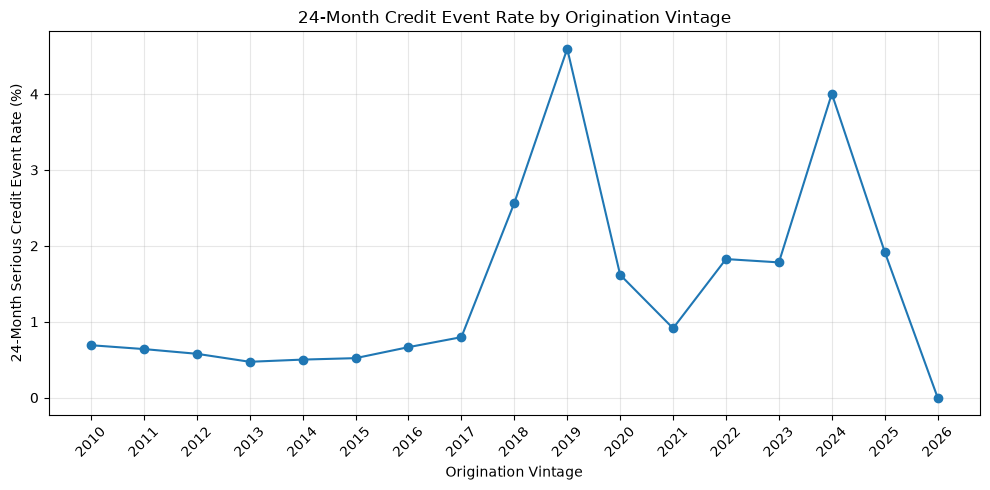

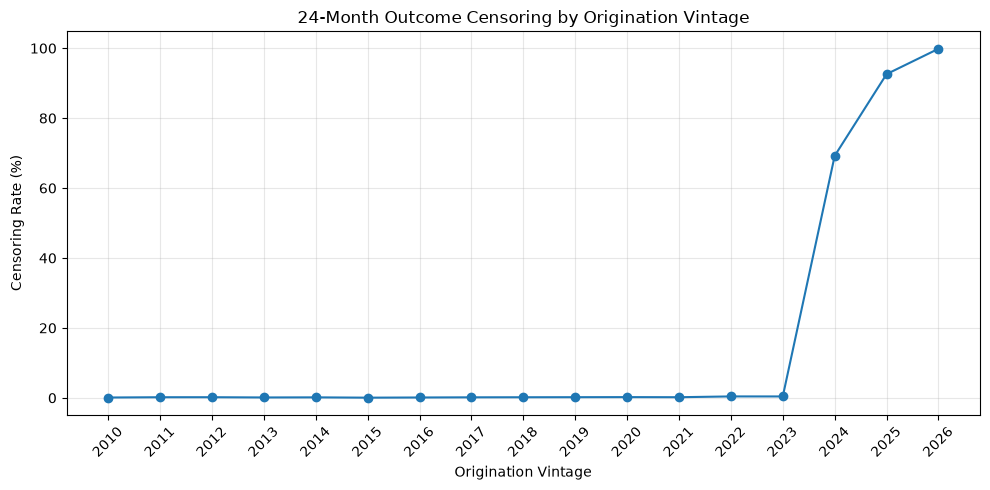

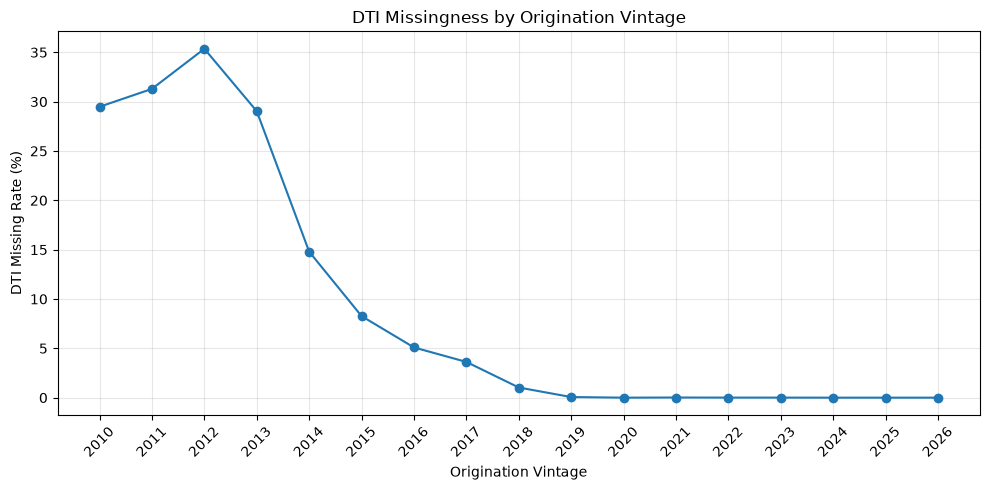

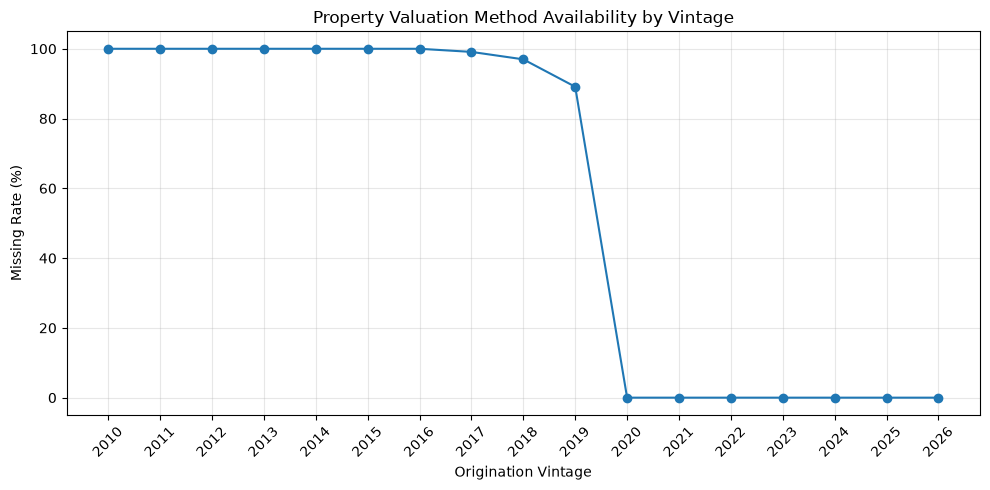

Cohort audit outputs saved.
COHORT SELECTION & TEMPORAL STABILITY AUDIT

Available modeling loans : 713,000
Vintage range            : 2010–2026

No vintage has been removed yet.

Selection will consider:
- 24-month event-rate stability
- outcome censoring
- predictor missingness
- temporal feature availability
- sufficient positive-event sample size


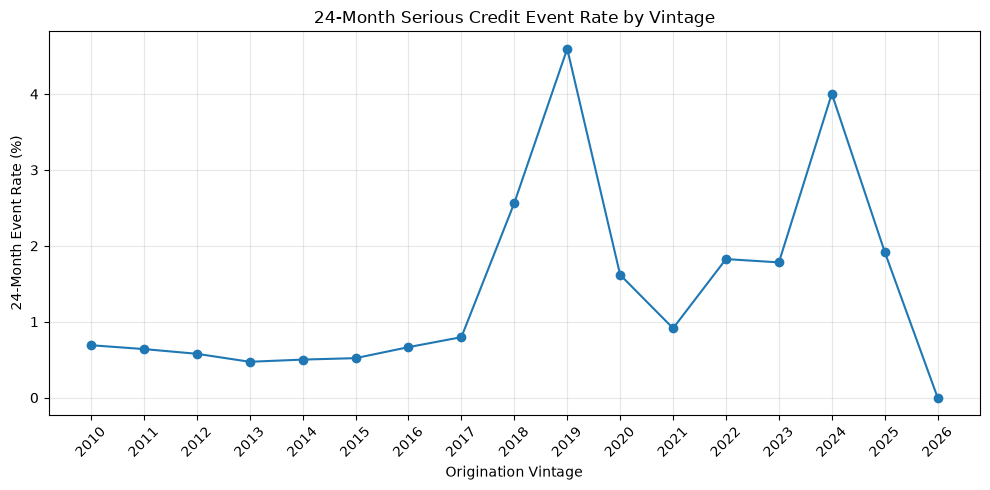

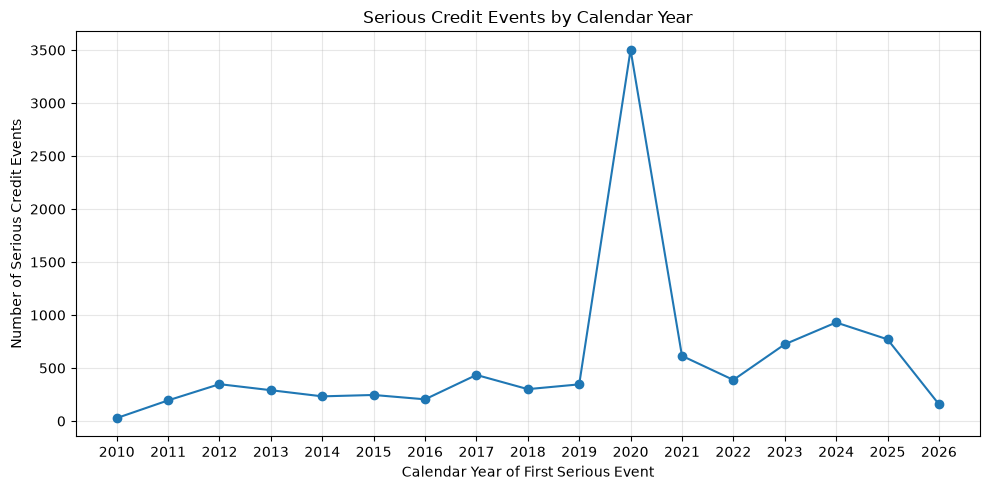

VantageScore® 4.0: FOUND

Retained for later review:
Special Eligibility Program: FOUND
Property Valuation Method: FOUND
Before final exclusion: (713000, 32)
After final exclusion : (713000, 31)
Final feature exclusion validation passed.
Review-variable retention validation passed.
Loan-level and target validation passed.
Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\ml_ready_data.parquet
Saved ML-ready dataset validation passed.
FREDDIE MAC ML-READY DATASET SUMMARY

Prepared modeling data : 713,000 × 32
Final ML-ready dataset : 713,000 × 31

Final excluded predictors:
  - VantageScore® 4.0

Retained for further review:
  - Special Eligibility Program
  - Property Valuation Method

Target event rate      : 1.3630%
Saved to               : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\ml_ready_data.parquet


In [4]:
from pathlib import Path

import numpy as np
import pandas as pd

# ------------------------------------------------------------

PROJECT_DIR = PROJECT_ROOT

INTERIM_DATA_DIR = PROJECT_DIR / "data" / "interim"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"

MODELING_DATA_PATH = (
    INTERIM_DATA_DIR
    / "modeling_dataset_24m.parquet"
)

print(
    "Modeling dataset exists:",
    MODELING_DATA_PATH.exists()
)

# ------------------------------------------------------------

modeling_data = pd.read_parquet(
    MODELING_DATA_PATH
)

print(
    "Dataset shape:",
    modeling_data.shape
)

# ------------------------------------------------------------

modeling_data.head()

# ------------------------------------------------------------

modeling_data.info()

# ------------------------------------------------------------

LOAN_ID = "Loan Identifier"
TARGET = "target_24m"
VINTAGE = "Dataset Vintage"

print(
    "Rows:",
    f"{len(modeling_data):,}"
)

print(
    "Unique loans:",
    f"{modeling_data[LOAN_ID].nunique():,}"
)

print(
    "Target missing:",
    modeling_data[TARGET].isna().sum()
)

print(
    "Target values:",
    sorted(
        modeling_data[TARGET].unique()
    )
)

# ------------------------------------------------------------

assert modeling_data[LOAN_ID].is_unique
assert modeling_data[TARGET].notna().all()
assert set(
    modeling_data[TARGET].unique()
) <= {0, 1}

print(
    "Basic modeling dataset validation passed."
)

# ------------------------------------------------------------

ID_COLUMNS = [
    "Loan Identifier"
]

# ------------------------------------------------------------

COHORT_COLUMNS = [
    "Dataset Vintage"
]

# ------------------------------------------------------------

TARGET_COLUMNS = [
    "target_24m"
]

# ------------------------------------------------------------

TARGET_AUDIT_COLUMNS = [
    "outcome_status_24m",
    "event_90dpd_24m",
    "event_reo_24m",
    "event_adverse_zero_balance_24m",
    "event_benign_zero_balance_24m",
    "event_other_zero_balance_24m",
    "first_serious_event_month",
    "months_observed_24m",
    "max_month_observed",
    "horizon_matured_24m",
    "observed_full_24m"
]

# ------------------------------------------------------------

for col in (
    ID_COLUMNS
    + COHORT_COLUMNS
    + TARGET_COLUMNS
    + TARGET_AUDIT_COLUMNS
):
    assert col in modeling_data.columns, (
        f"Missing expected column: {col}"
    )

print(
    "Variable-role validation passed."
)

# ------------------------------------------------------------

NON_PREDICTOR_COLUMNS = (
    ID_COLUMNS
    + COHORT_COLUMNS
    + TARGET_COLUMNS
    + TARGET_AUDIT_COLUMNS
)

candidate_predictors = [
    col
    for col in modeling_data.columns
    if col not in NON_PREDICTOR_COLUMNS
]

print(
    "Candidate predictors:",
    len(candidate_predictors)
)

for i, col in enumerate(
    candidate_predictors,
    start=1
):
    print(
        f"{i:2d}. {col}"
    )

# ------------------------------------------------------------

working_data = modeling_data[
    ID_COLUMNS
    + COHORT_COLUMNS
    + candidate_predictors
    + TARGET_COLUMNS
].copy()

# ------------------------------------------------------------

print(
    "Working dataset shape:",
    working_data.shape
)

# ------------------------------------------------------------

leakage_found = [
    col
    for col in TARGET_AUDIT_COLUMNS
    if col in candidate_predictors
]

print(
    "Leakage variables found:",
    leakage_found
)

# ------------------------------------------------------------

assert len(
    leakage_found
) == 0

print(
    "Target leakage check passed."
)

# ------------------------------------------------------------

dtype_summary = pd.DataFrame({
    "Variable": candidate_predictors,
    "Dtype": [
        str(
            working_data[col].dtype
        )
        for col in candidate_predictors
    ]
})

dtype_summary

# ------------------------------------------------------------

NUMERIC_COLUMNS = [
    "Classic FICO®",
    "Mortgage Insurance Percentage (MI %)",
    "Number of Units",
    "Original Combined Loan-to-Value (CLTV)",
    "Original Debt-to-Income (DTI) Ratio",
    "Original UPB",
    "Original Loan-to-Value (LTV)",
    "Original Interest Rate",
    "Original Loan Term",
    "Number of Borrowers",
    "VantageScore® 4.0"
]

# ------------------------------------------------------------

DATE_COLUMNS = [
    "First Payment Date",
    "Maturity Date"
]

# ------------------------------------------------------------

CATEGORICAL_COLUMNS = [
    "First Time Homebuyer Indicator",
    "Metropolitan Statistical Area (MSA) Or Metropolitan Division",
    "Occupancy Status",
    "Channel",
    "Prepayment Penalty Indicator",
    "Amortization Type",
    "Property State",
    "Property Type",
    "Postal Code",
    "Loan Purpose",
    "Seller Name",
    "Super Conforming Flag",
    "Pre-HARP Loan Sequence Number",
    "Special Eligibility Program",
    "HARP Indicator",
    "Property Valuation Method",
    "Interest Only (I/O) Indicator"
]

# ------------------------------------------------------------

grouped_predictors = (
    NUMERIC_COLUMNS
    + DATE_COLUMNS
    + CATEGORICAL_COLUMNS
)

missing_group_assignments = set(
    candidate_predictors
) - set(
    grouped_predictors
)

duplicate_assignments = (
    len(grouped_predictors)
    - len(set(grouped_predictors))
)

print(
    "Unassigned predictors:",
    missing_group_assignments
)

print(
    "Duplicate assignments:",
    duplicate_assignments
)

# ------------------------------------------------------------

assert len(
    missing_group_assignments
) == 0

assert duplicate_assignments == 0

print(
    "Semantic variable grouping passed."
)

# ------------------------------------------------------------

working_data["Classic FICO®"] = (
    working_data["Classic FICO®"]
    .replace(
        9999,
        np.nan
    )
)

# ------------------------------------------------------------

working_data["VantageScore® 4.0"] = (
    working_data["VantageScore® 4.0"]
    .replace(
        9999,
        np.nan
    )
)

# ------------------------------------------------------------

working_data[
    "Original Debt-to-Income (DTI) Ratio"
] = (
    working_data[
        "Original Debt-to-Income (DTI) Ratio"
    ]
    .replace(
        999,
        np.nan
    )
)

# ------------------------------------------------------------

working_data[
    "Original Loan-to-Value (LTV)"
] = (
    working_data[
        "Original Loan-to-Value (LTV)"
    ]
    .replace(
        999,
        np.nan
    )
)

# ------------------------------------------------------------

working_data[
    "Original Combined Loan-to-Value (CLTV)"
] = (
    working_data[
        "Original Combined Loan-to-Value (CLTV)"
    ]
    .replace(
        999,
        np.nan
    )
)

# ------------------------------------------------------------

working_data[
    "Mortgage Insurance Percentage (MI %)"
] = (
    working_data[
        "Mortgage Insurance Percentage (MI %)"
    ]
    .replace(
        999,
        np.nan
    )
)

# ------------------------------------------------------------

working_data[
    "Number of Units"
] = (
    working_data[
        "Number of Units"
    ]
    .replace(
        99,
        np.nan
    )
)

# ------------------------------------------------------------

working_data[
    "Number of Borrowers"
] = (
    working_data[
        "Number of Borrowers"
    ]
    .replace(
        99,
        np.nan
    )
)

# ------------------------------------------------------------

categorical_missing_map = {
    "First Time Homebuyer Indicator": ["9"],
    "Occupancy Status": ["9"],
    "Channel": ["9"],
    "Property Type": ["99"],
    "Loan Purpose": ["9"]
}

# ------------------------------------------------------------

for col, missing_codes in (
    categorical_missing_map.items()
):

    working_data[col] = (
        working_data[col]
        .astype("string")
        .replace(
            missing_codes,
            pd.NA
        )
    )

# ------------------------------------------------------------

working_data[
    "Property Valuation Method"
] = (
    working_data[
        "Property Valuation Method"
    ]
    .replace(
        7,
        np.nan
    )
)

# ------------------------------------------------------------

working_data[
    "Property Valuation Method"
] = (
    working_data[
        "Property Valuation Method"
    ]
    .astype("Int64")
    .astype("string")
)

# ------------------------------------------------------------

working_data[
    "Metropolitan Statistical Area (MSA) Or Metropolitan Division"
] = (
    working_data[
        "Metropolitan Statistical Area (MSA) Or Metropolitan Division"
    ]
    .astype("Int64")
    .astype("string")
)

# ------------------------------------------------------------

working_data[
    "Postal Code"
] = (
    working_data[
        "Postal Code"
    ]
    .astype("Int64")
    .astype("string")
)

# ------------------------------------------------------------

def convert_yyyymm_to_datetime(series):

    return pd.to_datetime(
        series.astype("Int64").astype("string"),
        format="%Y%m",
        errors="coerce"
    )

# ------------------------------------------------------------

for col in DATE_COLUMNS:

    working_data[col] = (
        convert_yyyymm_to_datetime(
            working_data[col]
        )
    )

# ------------------------------------------------------------

working_data[
    DATE_COLUMNS
].head()

# ------------------------------------------------------------

working_data[
    "Origination Year"
] = (
    working_data[
        "First Payment Date"
    ].dt.year
)

# ------------------------------------------------------------

working_data[
    "First Payment Month"
] = (
    working_data[
        "First Payment Date"
    ].dt.month
)

# ------------------------------------------------------------

missing_summary = (
    working_data[
        candidate_predictors
    ]
    .isna()
    .sum()
    .to_frame(
        "Missing Count"
    )
)

# ------------------------------------------------------------

missing_summary[
    "Missing Rate"
] = (
    missing_summary[
        "Missing Count"
    ]
    / len(working_data)
)

# ------------------------------------------------------------

missing_summary = (
    missing_summary
    .sort_values(
        "Missing Rate",
        ascending=False
    )
)

missing_summary

# ------------------------------------------------------------

cardinality_summary = pd.DataFrame({
    "Variable": candidate_predictors,
    "Unique Values": [
        working_data[col].nunique(
            dropna=True
        )
        for col in candidate_predictors
    ]
})

# ------------------------------------------------------------

cardinality_summary = (
    cardinality_summary
    .sort_values(
        "Unique Values",
        ascending=False
    )
)

cardinality_summary

# ------------------------------------------------------------

HIGH_CARDINALITY_COLUMNS = [
    "Metropolitan Statistical Area (MSA) Or Metropolitan Division",
    "Postal Code",
    "Seller Name",
    "Pre-HARP Loan Sequence Number"
]

# ------------------------------------------------------------

DROP_FROM_MODEL = [
    "Pre-HARP Loan Sequence Number"
]

# ------------------------------------------------------------

final_predictors = [
    col
    for col in candidate_predictors
    if col not in DROP_FROM_MODEL
]

# ------------------------------------------------------------

print(
    "Final candidate predictors:",
    len(final_predictors)
)

# ------------------------------------------------------------

high_missing_variables = (
    missing_summary.loc[
        missing_summary[
            "Missing Rate"
        ] >= 0.50
    ]
)

high_missing_variables

# ------------------------------------------------------------

target_distribution = (
    working_data[TARGET]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------

target_rate = (
    working_data[TARGET]
    .value_counts(
        normalize=True
    )
    .sort_index()
)

# ------------------------------------------------------------

print(
    "Target counts:"
)

print(
    target_distribution
)

print(
    "\nTarget proportions:"
)

print(
    target_rate
)

# ------------------------------------------------------------

prepared_modeling_data = (
    working_data[
        ID_COLUMNS
        + COHORT_COLUMNS
        + final_predictors
        + TARGET_COLUMNS
    ]
    .copy()
)

# ------------------------------------------------------------

print(
    "Prepared modeling data shape:",
    prepared_modeling_data.shape
)

# ------------------------------------------------------------

for col in TARGET_AUDIT_COLUMNS:

    assert col not in (
        prepared_modeling_data.columns
    )

# ------------------------------------------------------------

assert TARGET in (
    prepared_modeling_data.columns
)

assert LOAN_ID in (
    prepared_modeling_data.columns
)

assert VINTAGE in (
    prepared_modeling_data.columns
)

print(
    "Final leakage validation passed."
)

# ------------------------------------------------------------

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------

PREPARED_DATA_PATH = (
    PROCESSED_DATA_DIR
    / "prepared_modeling_data.parquet"
)

MISSING_SUMMARY_PATH = (
    PROCESSED_DATA_DIR
    / "missing_value_summary.csv"
)

CARDINALITY_SUMMARY_PATH = (
    PROCESSED_DATA_DIR
    / "cardinality_summary.csv"
)

# ------------------------------------------------------------

prepared_modeling_data.to_parquet(
    PREPARED_DATA_PATH,
    index=False
)

missing_summary.to_csv(
    MISSING_SUMMARY_PATH
)

cardinality_summary.to_csv(
    CARDINALITY_SUMMARY_PATH,
    index=False
)

# ------------------------------------------------------------

print("Saved:")
print(PREPARED_DATA_PATH)
print(MISSING_SUMMARY_PATH)
print(CARDINALITY_SUMMARY_PATH)

# ------------------------------------------------------------

check_prepared = pd.read_parquet(
    PREPARED_DATA_PATH
)

assert (
    check_prepared.shape
    == prepared_modeling_data.shape
)

assert (
    list(check_prepared.columns)
    == list(
        prepared_modeling_data.columns
    )
)

print(
    "Prepared dataset validation passed."
)

# ------------------------------------------------------------

print("=" * 70)
print("FREDDIE MAC MODELING DATA PREPARATION SUMMARY")
print("=" * 70)

print(
    f"\nLoans                : "
    f"{len(prepared_modeling_data):,}"
)

print(
    f"Final predictors     : "
    f"{len(final_predictors)}"
)

print(
    f"Target               : "
    f"{TARGET}"
)

print(
    f"Positive loans       : "
    f"{(prepared_modeling_data[TARGET] == 1).sum():,}"
)

print(
    f"Negative loans       : "
    f"{(prepared_modeling_data[TARGET] == 0).sum():,}"
)

print(
    "\nLeakage variables    : removed"
)

print(
    "Sentinel values      : converted to missing values"
)

print(
    "Semantic data types  : assigned"
)

print("=" * 70)

# ------------------------------------------------------------

audit_data = prepared_modeling_data.copy()

print("Audit dataset shape:", audit_data.shape)

# ------------------------------------------------------------

duplicate_full_rows = audit_data.duplicated(keep=False)

duplicate_loan_ids = audit_data.duplicated(
    subset=["Loan Identifier"],
    keep=False
)

print("Duplicate full rows:", duplicate_full_rows.sum())
print("Duplicate Loan Identifiers:", duplicate_loan_ids.sum())

# ------------------------------------------------------------

assert duplicate_loan_ids.sum() == 0, (
    "Duplicate Loan Identifier records detected."
)

print("Loan-level uniqueness check passed.")

# ------------------------------------------------------------

PREDICTOR_COLUMNS = final_predictors

audit_data["n_missing_predictors"] = (
    audit_data[PREDICTOR_COLUMNS]
    .isna()
    .sum(axis=1)
)

audit_data["missing_predictor_rate"] = (
    audit_data["n_missing_predictors"]
    / len(PREDICTOR_COLUMNS)
)

# ------------------------------------------------------------

audit_data[
    "n_missing_predictors"
].describe()

# ------------------------------------------------------------

audit_data[
    "n_missing_predictors"
].value_counts().sort_index()

# ------------------------------------------------------------

high_missing_rows = audit_data.loc[
    audit_data["missing_predictor_rate"] >= 0.30
].copy()

print(
    "Rows with >=30% missing predictors:",
    f"{len(high_missing_rows):,}"
)

# ------------------------------------------------------------

VALIDITY_RULES = {
    "Classic FICO®": (300, 850),
    "VantageScore® 4.0": (300, 850),
    "Mortgage Insurance Percentage (MI %)": (0, 55),
    "Number of Units": (1, 4),
    "Original Combined Loan-to-Value (CLTV)": (1, 998),
    "Original Debt-to-Income (DTI) Ratio": (0, 65),
    "Original Loan-to-Value (LTV)": (1, 998),
    "Original Interest Rate": (0, None),
    "Original UPB": (0, None),
    "Original Loan Term": (1, None),
    "Number of Borrowers": (1, 10)
}

# ------------------------------------------------------------

def invalid_range_mask(series, min_value=None, max_value=None):
    mask = pd.Series(False, index=series.index)

    if min_value is not None:
        mask |= series.notna() & (series < min_value)

    if max_value is not None:
        mask |= series.notna() & (series > max_value)

    return mask

# ------------------------------------------------------------

range_audit_records = []

for col, (min_value, max_value) in VALIDITY_RULES.items():

    invalid_mask = invalid_range_mask(
        audit_data[col],
        min_value=min_value,
        max_value=max_value
    )

    range_audit_records.append({
        "Variable": col,
        "Missing Count": audit_data[col].isna().sum(),
        "Invalid Count": invalid_mask.sum(),
        "Valid Min": min_value,
        "Valid Max": max_value,
        "Observed Min": audit_data[col].min(),
        "Observed Max": audit_data[col].max()
    })

# ------------------------------------------------------------

range_audit = pd.DataFrame(
    range_audit_records
)

range_audit

# ------------------------------------------------------------

invalid_flags = pd.DataFrame(
    index=audit_data.index
)

for col, (min_value, max_value) in VALIDITY_RULES.items():

    invalid_flags[
        f"invalid__{col}"
    ] = invalid_range_mask(
        audit_data[col],
        min_value=min_value,
        max_value=max_value
    )

# ------------------------------------------------------------

audit_data["n_invalid_numeric"] = (
    invalid_flags.sum(axis=1)
)

audit_data[
    "n_invalid_numeric"
].value_counts().sort_index()

# ------------------------------------------------------------

rows_with_invalid_numeric = audit_data.loc[
    audit_data["n_invalid_numeric"] > 0
].copy()

print(
    "Rows with invalid numeric values:",
    f"{len(rows_with_invalid_numeric):,}"
)

# ------------------------------------------------------------

audit_data["flag_cltv_lt_ltv"] = (
    audit_data["Original Combined Loan-to-Value (CLTV)"].notna()
    & audit_data["Original Loan-to-Value (LTV)"].notna()
    & (
        audit_data["Original Combined Loan-to-Value (CLTV)"]
        <
        audit_data["Original Loan-to-Value (LTV)"]
    )
)

print(
    "CLTV < LTV:",
    audit_data["flag_cltv_lt_ltv"].sum()
)

# ------------------------------------------------------------

first_payment_idx = (
    audit_data["First Payment Date"].dt.year * 12
    + audit_data["First Payment Date"].dt.month
)

maturity_idx = (
    audit_data["Maturity Date"].dt.year * 12
    + audit_data["Maturity Date"].dt.month
)

# ------------------------------------------------------------

audit_data["calculated_loan_term"] = (
    maturity_idx
    - first_payment_idx
    + 1
)

# ------------------------------------------------------------

audit_data["flag_loan_term_mismatch"] = (
    audit_data["calculated_loan_term"].notna()
    & audit_data["Original Loan Term"].notna()
    & (
        audit_data["calculated_loan_term"]
        != audit_data["Original Loan Term"]
    )
)

# ------------------------------------------------------------

print(
    "Loan term mismatches:",
    audit_data["flag_loan_term_mismatch"].sum()
)

# ------------------------------------------------------------

audit_data["flag_maturity_before_first_payment"] = (
    audit_data["Maturity Date"].notna()
    & audit_data["First Payment Date"].notna()
    & (
        audit_data["Maturity Date"]
        <
        audit_data["First Payment Date"]
    )
)

# ------------------------------------------------------------

print(
    "Maturity before first payment:",
    audit_data[
        "flag_maturity_before_first_payment"
    ].sum()
)

# ------------------------------------------------------------

print(
    audit_data["target_24m"]
    .value_counts(dropna=False)
)

# ------------------------------------------------------------

assert audit_data["target_24m"].isin([0, 1]).all()

print("Target integrity check passed.")

# ------------------------------------------------------------

audit_data["flag_high_missing"] = (
    audit_data["missing_predictor_rate"] >= 0.30
)

audit_data["flag_invalid_numeric"] = (
    audit_data["n_invalid_numeric"] > 0
)

audit_data["flag_logical_issue"] = (
    audit_data["flag_cltv_lt_ltv"]
    | audit_data["flag_loan_term_mismatch"]
    | audit_data["flag_maturity_before_first_payment"]
)

# ------------------------------------------------------------

audit_data["n_quality_flags"] = (
    audit_data[
        [
            "flag_high_missing",
            "flag_invalid_numeric",
            "flag_logical_issue"
        ]
    ]
    .sum(axis=1)
)

# ------------------------------------------------------------

audit_data[
    "n_quality_flags"
].value_counts().sort_index()

# ------------------------------------------------------------

row_audit_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Duplicate Loan IDs",
        "Rows >=30% Missing Predictors",
        "Rows with Invalid Numeric Values",
        "Rows with CLTV < LTV",
        "Rows with Loan Term Mismatch",
        "Rows with Maturity Before First Payment",
        "Rows with Any Quality Flag"
    ],
    "Count": [
        len(audit_data),
        duplicate_loan_ids.sum(),
        audit_data["flag_high_missing"].sum(),
        audit_data["flag_invalid_numeric"].sum(),
        audit_data["flag_cltv_lt_ltv"].sum(),
        audit_data["flag_loan_term_mismatch"].sum(),
        audit_data[
            "flag_maturity_before_first_payment"
        ].sum(),
        (audit_data["n_quality_flags"] > 0).sum()
    ]
})

# ------------------------------------------------------------

row_audit_summary["Rate"] = (
    row_audit_summary["Count"]
    / len(audit_data)
)

row_audit_summary

# ------------------------------------------------------------

problem_rows = audit_data.loc[
    audit_data["n_quality_flags"] > 0
].copy()

print(
    "Problematic rows:",
    f"{len(problem_rows):,}"
)

# ------------------------------------------------------------

problem_rows[
    [
        "Loan Identifier",
        "Dataset Vintage",
        "Classic FICO®",
        "Original Debt-to-Income (DTI) Ratio",
        "Original Loan-to-Value (LTV)",
        "Original Combined Loan-to-Value (CLTV)",
        "Original UPB",
        "Original Interest Rate",
        "Original Loan Term",
        "n_missing_predictors",
        "n_invalid_numeric",
        "flag_cltv_lt_ltv",
        "flag_loan_term_mismatch",
        "flag_maturity_before_first_payment",
        "target_24m"
    ]
].head(30)

# ------------------------------------------------------------

quality_by_target = (
    audit_data
    .groupby("target_24m")
    .agg(
        Loans=("Loan Identifier", "count"),
        Avg_Missing_Predictors=(
            "n_missing_predictors",
            "mean"
        ),
        High_Missing_Rows=(
            "flag_high_missing",
            "sum"
        ),
        Invalid_Numeric_Rows=(
            "flag_invalid_numeric",
            "sum"
        ),
        Logical_Issue_Rows=(
            "flag_logical_issue",
            "sum"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------

quality_by_target

# ------------------------------------------------------------

quality_by_vintage = (
    audit_data
    .groupby("Dataset Vintage")
    .agg(
        Loans=("Loan Identifier", "count"),
        Avg_Missing_Predictors=(
            "n_missing_predictors",
            "mean"
        ),
        High_Missing_Rows=(
            "flag_high_missing",
            "sum"
        ),
        Invalid_Numeric_Rows=(
            "flag_invalid_numeric",
            "sum"
        ),
        Logical_Issue_Rows=(
            "flag_logical_issue",
            "sum"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------

quality_by_vintage

# ------------------------------------------------------------

ROW_AUDIT_SUMMARY_PATH = (
    PROCESSED_DATA_DIR
    / "row_quality_audit_summary.csv"
)

RANGE_AUDIT_PATH = (
    PROCESSED_DATA_DIR
    / "numeric_range_audit.csv"
)

QUALITY_BY_TARGET_PATH = (
    PROCESSED_DATA_DIR
    / "quality_by_target.csv"
)

QUALITY_BY_VINTAGE_PATH = (
    PROCESSED_DATA_DIR
    / "quality_by_vintage.csv"
)

# ------------------------------------------------------------

row_audit_summary.to_csv(
    ROW_AUDIT_SUMMARY_PATH,
    index=False
)

range_audit.to_csv(
    RANGE_AUDIT_PATH,
    index=False
)

quality_by_target.to_csv(
    QUALITY_BY_TARGET_PATH,
    index=False
)

quality_by_vintage.to_csv(
    QUALITY_BY_VINTAGE_PATH,
    index=False
)

print("Row-level audit outputs saved.")

# ------------------------------------------------------------

row_audit_summary

# ------------------------------------------------------------

range_audit

# ------------------------------------------------------------

quality_by_target

# ------------------------------------------------------------

quality_by_vintage

# ------------------------------------------------------------

missing_audit = pd.DataFrame({
    "Variable": final_predictors,
    "Missing_Count": [
        audit_data[col].isna().sum()
        for col in final_predictors
    ]
})

missing_audit["Missing_Rate"] = (
    missing_audit["Missing_Count"]
    / len(audit_data)
)

missing_audit["Missing_Percent"] = (
    missing_audit["Missing_Rate"] * 100
)

missing_audit = (
    missing_audit
    .sort_values("Missing_Rate", ascending=False)
    .reset_index(drop=True)
)

missing_audit

# ------------------------------------------------------------

def classify_missingness(rate):

    if rate == 0:
        return "No missing"

    elif rate < 0.01:
        return "<1%"

    elif rate < 0.05:
        return "1-5%"

    elif rate < 0.20:
        return "5-20%"

    elif rate < 0.50:
        return "20-50%"

    elif rate < 1.00:
        return ">=50%"

    else:
        return "100% missing"


missing_audit["Missingness_Level"] = (
    missing_audit["Missing_Rate"]
    .apply(classify_missingness)
)

missing_audit

# ------------------------------------------------------------

fully_missing_predictors = missing_audit.loc[
    missing_audit["Missing_Rate"] == 1,
    "Variable"
].tolist()

print("Fully missing predictors:")
for col in fully_missing_predictors:
    print(" -", col)

# ------------------------------------------------------------

missing_by_target_records = []

for col in final_predictors:

    for target_value in [0, 1]:

        subset = audit_data.loc[
            audit_data["target_24m"] == target_value
        ]

        missing_count = subset[col].isna().sum()

        missing_by_target_records.append({
            "Variable": col,
            "target_24m": target_value,
            "Loans": len(subset),
            "Missing_Count": missing_count,
            "Missing_Rate": (
                missing_count / len(subset)
                if len(subset) > 0
                else np.nan
            )
        })


missing_by_target = pd.DataFrame(
    missing_by_target_records
)

missing_by_target

# ------------------------------------------------------------

missing_target_comparison = (
    missing_by_target
    .pivot(
        index="Variable",
        columns="target_24m",
        values="Missing_Rate"
    )
    .rename(
        columns={
            0: "Missing_Rate_Target_0",
            1: "Missing_Rate_Target_1"
        }
    )
    .reset_index()
)

missing_target_comparison[
    "Absolute_Difference"
] = (
    missing_target_comparison[
        "Missing_Rate_Target_1"
    ]
    -
    missing_target_comparison[
        "Missing_Rate_Target_0"
    ]
).abs()

missing_target_comparison = (
    missing_target_comparison
    .sort_values(
        "Absolute_Difference",
        ascending=False
    )
)

missing_target_comparison

# ------------------------------------------------------------

missing_by_vintage_records = []

for vintage, subset in audit_data.groupby(
    "Dataset Vintage"
):

    for col in final_predictors:

        missing_count = subset[col].isna().sum()

        missing_by_vintage_records.append({
            "Dataset_Vintage": int(vintage),
            "Variable": col,
            "Loans": len(subset),
            "Missing_Count": missing_count,
            "Missing_Rate": (
                missing_count / len(subset)
            )
        })


missing_by_vintage = pd.DataFrame(
    missing_by_vintage_records
)

missing_by_vintage

# ------------------------------------------------------------

missing_vintage_matrix = (
    missing_by_vintage
    .pivot(
        index="Variable",
        columns="Dataset_Vintage",
        values="Missing_Rate"
    )
)

missing_vintage_matrix

# ------------------------------------------------------------

print("=" * 70)
print("PREDICTOR MISSINGNESS AUDIT")
print("=" * 70)

print(f"\nTotal loans: {len(audit_data):,}")
print(f"Candidate predictors: {len(final_predictors)}")

print(
    "\nPredictors with no missing values:",
    (missing_audit["Missing_Count"] == 0).sum()
)

print(
    "Predictors with some missing values:",
    (
        (missing_audit["Missing_Count"] > 0)
        &
        (missing_audit["Missing_Rate"] < 1)
    ).sum()
)

print(
    "Predictors completely missing:",
    (missing_audit["Missing_Rate"] == 1).sum()
)

print("\nTop missing predictors:")
display(
    missing_audit[
        [
            "Variable",
            "Missing_Count",
            "Missing_Percent",
            "Missingness_Level"
        ]
    ].head(15)
)

# ------------------------------------------------------------

modeling_vintage_summary = (
    audit_data
    .groupby(VINTAGE)
    .agg(
        Modeling_Loans=(LOAN_ID, "count"),
        Positive=(TARGET, "sum")
    )
    .reset_index()
)

modeling_vintage_summary["Negative"] = (
    modeling_vintage_summary["Modeling_Loans"]
    - modeling_vintage_summary["Positive"]
)

modeling_vintage_summary["Event_Rate"] = (
    modeling_vintage_summary["Positive"]
    / modeling_vintage_summary["Modeling_Loans"]
)

modeling_vintage_summary

# ------------------------------------------------------------

modeling_vintage_summary["Event_Rate_Percent"] = (
    modeling_vintage_summary["Event_Rate"]
    * 100
)

modeling_vintage_summary[
    [
        VINTAGE,
        "Modeling_Loans",
        "Positive",
        "Negative",
        "Event_Rate_Percent"
    ]
]

# ------------------------------------------------------------

TARGET_ALL_PATH = (
    INTERIM_DATA_DIR
    / "loan_target_24m_all.parquet"
)

print(
    "Target audit dataset exists:",
    TARGET_ALL_PATH.exists()
)

# ------------------------------------------------------------

target_all = pd.read_parquet(
    TARGET_ALL_PATH
)

print(
    "Target-all shape:",
    target_all.shape
)

# ------------------------------------------------------------

target_vintage_summary = (
    target_all
    .groupby(VINTAGE)
    .agg(
        Targetable_Loans=(LOAN_ID, "count"),
        Resolved_Loans=(
            TARGET,
            lambda x: x.notna().sum()
        ),
        Censored_Loans=(
            TARGET,
            lambda x: x.isna().sum()
        ),
        Horizon_Matured=(
            "horizon_matured_24m",
            "sum"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------

target_vintage_summary["Censoring_Rate"] = (
    target_vintage_summary["Censored_Loans"]
    / target_vintage_summary["Targetable_Loans"]
)

target_vintage_summary["Horizon_Maturity_Rate"] = (
    target_vintage_summary["Horizon_Matured"]
    / target_vintage_summary["Targetable_Loans"]
)

target_vintage_summary

# ------------------------------------------------------------

overall_missing_by_vintage = (
    quality_by_vintage[
        [
            VINTAGE,
            "Avg_Missing_Predictors"
        ]
    ]
    .copy()
)

# ------------------------------------------------------------

def get_vintage_missing_rate(
    missing_by_vintage_df,
    variable,
    output_name
):
    
    result = (
        missing_by_vintage_df.loc[
            missing_by_vintage_df["Variable"] == variable,
            [
                "Dataset_Vintage",
                "Missing_Rate"
            ]
        ]
        .rename(
            columns={
                "Dataset_Vintage": VINTAGE,
                "Missing_Rate": output_name
            }
        )
    )
    
    return result

# ------------------------------------------------------------

dti_missing_by_vintage = get_vintage_missing_rate(
    missing_by_vintage,
    "Original Debt-to-Income (DTI) Ratio",
    "DTI_Missing_Rate"
)

# ------------------------------------------------------------

MSA_COL = (
    "Metropolitan Statistical Area (MSA) "
    "Or Metropolitan Division"
)

msa_missing_by_vintage = get_vintage_missing_rate(
    missing_by_vintage,
    MSA_COL,
    "MSA_Missing_Rate"
)

# ------------------------------------------------------------

pvm_missing_by_vintage = get_vintage_missing_rate(
    missing_by_vintage,
    "Property Valuation Method",
    "Property_Valuation_Missing_Rate"
)

# ------------------------------------------------------------

special_program_missing_by_vintage = (
    get_vintage_missing_rate(
        missing_by_vintage,
        "Special Eligibility Program",
        "Special_Program_Missing_Rate"
    )
)

# ------------------------------------------------------------

cohort_audit = (
    modeling_vintage_summary
    
    .merge(
        target_vintage_summary,
        on=VINTAGE,
        how="left",
        validate="one_to_one"
    )
    
    .merge(
        overall_missing_by_vintage,
        on=VINTAGE,
        how="left",
        validate="one_to_one"
    )
    
    .merge(
        dti_missing_by_vintage,
        on=VINTAGE,
        how="left",
        validate="one_to_one"
    )
    
    .merge(
        msa_missing_by_vintage,
        on=VINTAGE,
        how="left",
        validate="one_to_one"
    )
    
    .merge(
        pvm_missing_by_vintage,
        on=VINTAGE,
        how="left",
        validate="one_to_one"
    )
    
    .merge(
        special_program_missing_by_vintage,
        on=VINTAGE,
        how="left",
        validate="one_to_one"
    )
)

cohort_audit

# ------------------------------------------------------------

RATE_COLUMNS = [
    "Event_Rate",
    "Censoring_Rate",
    "Horizon_Maturity_Rate",
    "DTI_Missing_Rate",
    "MSA_Missing_Rate",
    "Property_Valuation_Missing_Rate",
    "Special_Program_Missing_Rate"
]

for col in RATE_COLUMNS:
    
    cohort_audit[
        f"{col}_Percent"
    ] = (
        cohort_audit[col]
        * 100
    )

# ------------------------------------------------------------

cohort_selection_table = (
    cohort_audit[
        [
            VINTAGE,
            "Modeling_Loans",
            "Positive",
            "Event_Rate_Percent",
            "Censoring_Rate_Percent",
            "Horizon_Maturity_Rate_Percent",
            "Avg_Missing_Predictors",
            "DTI_Missing_Rate_Percent",
            "MSA_Missing_Rate_Percent",
            "Property_Valuation_Missing_Rate_Percent",
            "Special_Program_Missing_Rate_Percent"
        ]
    ]
    .copy()
)

cohort_selection_table

# ------------------------------------------------------------

DISPLAY_PERCENT_COLUMNS = [
    "Event_Rate_Percent",
    "Censoring_Rate_Percent",
    "Horizon_Maturity_Rate_Percent",
    "DTI_Missing_Rate_Percent",
    "MSA_Missing_Rate_Percent",
    "Property_Valuation_Missing_Rate_Percent",
    "Special_Program_Missing_Rate_Percent"
]

cohort_selection_display = (
    cohort_selection_table.copy()
)

cohort_selection_display[
    DISPLAY_PERCENT_COLUMNS
] = (
    cohort_selection_display[
        DISPLAY_PERCENT_COLUMNS
    ]
    .round(2)
)

cohort_selection_display[
    "Avg_Missing_Predictors"
] = (
    cohort_selection_display[
        "Avg_Missing_Predictors"
    ]
    .round(2)
)

cohort_selection_display

# ------------------------------------------------------------

import matplotlib.pyplot as plt

# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    cohort_selection_table[VINTAGE],
    cohort_selection_table["Event_Rate_Percent"],
    marker="o"
)

plt.xlabel("Origination Vintage")
plt.ylabel("24-Month Serious Credit Event Rate (%)")
plt.title("24-Month Credit Event Rate by Origination Vintage")

plt.xticks(
    cohort_selection_table[VINTAGE],
    rotation=45
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    cohort_selection_table[VINTAGE],
    cohort_selection_table["Censoring_Rate_Percent"],
    marker="o"
)

plt.xlabel("Origination Vintage")
plt.ylabel("Censoring Rate (%)")
plt.title("24-Month Outcome Censoring by Origination Vintage")

plt.xticks(
    cohort_selection_table[VINTAGE],
    rotation=45
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    cohort_selection_table[VINTAGE],
    cohort_selection_table["DTI_Missing_Rate_Percent"],
    marker="o"
)

plt.xlabel("Origination Vintage")
plt.ylabel("DTI Missing Rate (%)")
plt.title("DTI Missingness by Origination Vintage")

plt.xticks(
    cohort_selection_table[VINTAGE],
    rotation=45
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    cohort_selection_table[VINTAGE],
    cohort_selection_table[
        "Property_Valuation_Missing_Rate_Percent"
    ],
    marker="o"
)

plt.xlabel("Origination Vintage")
plt.ylabel("Missing Rate (%)")
plt.title(
    "Property Valuation Method Availability by Vintage"
)

plt.xticks(
    cohort_selection_table[VINTAGE],
    rotation=45
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------

cohort_audit["flag_high_censoring"] = (
    cohort_audit["Censoring_Rate"] > 0.10
)

cohort_audit["flag_high_dti_missing"] = (
    cohort_audit["DTI_Missing_Rate"] > 0.10
)

cohort_audit["flag_low_sample_size"] = (
    cohort_audit["Modeling_Loans"] < 10_000
)

# ------------------------------------------------------------

cohort_audit[
    [
        VINTAGE,
        "flag_high_censoring",
        "flag_high_dti_missing",
        "flag_low_sample_size"
    ]
]

# ------------------------------------------------------------

COHORT_CANDIDATES = {
    
    "Full_2010_2023": (
        2010,
        2023
    ),
    
    "Recent_2015_2023": (
        2015,
        2023
    ),
    
    "Recent_2017_2023": (
        2017,
        2023
    ),
    
    "Pre_COVID_2015_2019": (
        2015,
        2019
    ),
    
    "Post_2020_2023": (
        2020,
        2023
    )
}

# ------------------------------------------------------------

cohort_candidate_records = []

for cohort_name, (
    start_year,
    end_year
) in COHORT_CANDIDATES.items():
    
    subset = audit_data.loc[
        audit_data[VINTAGE].between(
            start_year,
            end_year
        )
    ]
    
    cohort_candidate_records.append({
        
        "Cohort": cohort_name,
        
        "Start_Year": start_year,
        
        "End_Year": end_year,
        
        "Loans": len(subset),
        
        "Positive": (
            subset[TARGET] == 1
        ).sum(),
        
        "Negative": (
            subset[TARGET] == 0
        ).sum(),
        
        "Event_Rate": subset[TARGET].mean(),
        
        "Avg_Missing_Predictors": (
            subset[PREDICTOR_COLUMNS]
            .isna()
            .sum(axis=1)
            .mean()
        )
    })

# ------------------------------------------------------------

cohort_candidate_summary = pd.DataFrame(
    cohort_candidate_records
)

cohort_candidate_summary[
    "Event_Rate_Percent"
] = (
    cohort_candidate_summary[
        "Event_Rate"
    ]
    * 100
)

cohort_candidate_summary

# ------------------------------------------------------------

COHORT_AUDIT_PATH = (
    PROCESSED_DATA_DIR
    / "cohort_selection_audit.csv"
)

COHORT_CANDIDATE_PATH = (
    PROCESSED_DATA_DIR
    / "cohort_candidate_summary.csv"
)

# ------------------------------------------------------------

cohort_selection_table.to_csv(
    COHORT_AUDIT_PATH,
    index=False
)

cohort_candidate_summary.to_csv(
    COHORT_CANDIDATE_PATH,
    index=False
)

print(
    "Cohort audit outputs saved."
)

# ------------------------------------------------------------

print("=" * 75)
print("COHORT SELECTION & TEMPORAL STABILITY AUDIT")
print("=" * 75)

print(
    f"\nAvailable modeling loans : "
    f"{len(audit_data):,}"
)

print(
    f"Vintage range            : "
    f"{int(audit_data[VINTAGE].min())}"
    f"–"
    f"{int(audit_data[VINTAGE].max())}"
)

print(
    "\nNo vintage has been removed yet."
)

print(
    "\nSelection will consider:"
)

print(
    "- 24-month event-rate stability"
)

print(
    "- outcome censoring"
)

print(
    "- predictor missingness"
)

print(
    "- temporal feature availability"
)

print(
    "- sufficient positive-event sample size"
)

print("=" * 75)

# ------------------------------------------------------------

cohort_selection_display

# ------------------------------------------------------------

cohort_candidate_summary

# ------------------------------------------------------------

modeling_vintage_summary[
    [
        VINTAGE,
        "Modeling_Loans",
        "Positive",
        "Event_Rate_Percent"
    ]
]

# ------------------------------------------------------------

event_source_by_vintage = (
    target_all
    .groupby(VINTAGE)
    .agg(
        Loans=(LOAN_ID, "count"),
        
        Resolved=(
            TARGET,
            lambda x: x.notna().sum()
        ),
        
        Positive=(
            TARGET,
            lambda x: (x == 1).sum()
        ),
        
        Event_90DPD=(
            "event_90dpd_24m",
            "sum"
        ),
        
        Event_REO=(
            "event_reo_24m",
            "sum"
        ),
        
        Event_Adverse_Zero_Balance=(
            "event_adverse_zero_balance_24m",
            "sum"
        )
    )
    .reset_index()
)

event_source_by_vintage

# ------------------------------------------------------------

event_source_by_vintage["Positive_Rate"] = (
    event_source_by_vintage["Positive"]
    / event_source_by_vintage["Resolved"]
)

event_source_by_vintage["DPD90_Rate"] = (
    event_source_by_vintage["Event_90DPD"]
    / event_source_by_vintage["Resolved"]
)

event_source_by_vintage["REO_Rate"] = (
    event_source_by_vintage["Event_REO"]
    / event_source_by_vintage["Resolved"]
)

event_source_by_vintage["Adverse_ZB_Rate"] = (
    event_source_by_vintage["Event_Adverse_Zero_Balance"]
    / event_source_by_vintage["Resolved"]
)

# ------------------------------------------------------------

rate_cols = [
    "Positive_Rate",
    "DPD90_Rate",
    "REO_Rate",
    "Adverse_ZB_Rate"
]

for col in rate_cols:
    event_source_by_vintage[f"{col}_Percent"] = (
        event_source_by_vintage[col] * 100
    )

# ------------------------------------------------------------

event_source_display = event_source_by_vintage[
    [
        VINTAGE,
        "Resolved",
        "Positive",
        "Positive_Rate_Percent",
        "Event_90DPD",
        "DPD90_Rate_Percent",
        "Event_REO",
        "REO_Rate_Percent",
        "Event_Adverse_Zero_Balance",
        "Adverse_ZB_Rate_Percent"
    ]
].copy()

event_source_display

# ------------------------------------------------------------

target_all["positive_event_pattern"] = (
    target_all["event_90dpd_24m"].astype(int).astype(str)
    + "-"
    + target_all["event_reo_24m"].astype(int).astype(str)
    + "-"
    + target_all["event_adverse_zero_balance_24m"].astype(int).astype(str)
)

# ------------------------------------------------------------

event_pattern_by_vintage = (
    target_all.loc[
        target_all[TARGET] == 1
    ]
    .groupby(
        [
            VINTAGE,
            "positive_event_pattern"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

event_pattern_by_vintage

# ------------------------------------------------------------

event_source_display.loc[
    event_source_display[VINTAGE].between(
        2017,
        2020
    )
]

# ------------------------------------------------------------

first_event_by_vintage = (
    target_all.loc[
        target_all[TARGET] == 1
    ]
    .groupby(VINTAGE)[
        "first_serious_event_month"
    ]
    .agg(
        Positive_Loans="count",
        Mean_First_Event_Month="mean",
        Median_First_Event_Month="median",
        Min_First_Event_Month="min",
        Max_First_Event_Month="max"
    )
    .reset_index()
)

first_event_by_vintage

# ------------------------------------------------------------

first_event_by_vintage.loc[
    first_event_by_vintage[VINTAGE].between(
        2015,
        2023
    )
]

# ------------------------------------------------------------

positive_events = target_all.loc[
    target_all[TARGET] == 1,
    [
        VINTAGE,
        "first_serious_event_month"
    ]
].copy()

# ------------------------------------------------------------

positive_events["Event_Timing"] = pd.cut(
    positive_events[
        "first_serious_event_month"
    ],
    bins=[
        -1,
        5,
        11,
        23
    ],
    labels=[
        "Months 0-5",
        "Months 6-11",
        "Months 12-23"
    ]
)

# ------------------------------------------------------------

event_timing_by_vintage = (
    pd.crosstab(
        positive_events[VINTAGE],
        positive_events["Event_Timing"],
        normalize="index"
    )
    * 100
)

event_timing_by_vintage.round(2)

# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    modeling_vintage_summary[VINTAGE],
    modeling_vintage_summary[
        "Event_Rate_Percent"
    ],
    marker="o"
)

plt.xlabel("Origination Vintage")
plt.ylabel("24-Month Event Rate (%)")
plt.title(
    "24-Month Serious Credit Event Rate by Vintage"
)

plt.xticks(
    modeling_vintage_summary[VINTAGE],
    rotation=45
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------

def assign_temporal_period(vintage):

    if vintage <= 2017:
        return "2010-2017"

    elif vintage <= 2019:
        return "2018-2019"

    elif vintage <= 2021:
        return "2020-2021"

    elif vintage <= 2023:
        return "2022-2023"

    else:
        return "2024-2026"

# ------------------------------------------------------------

temporal_audit_data = audit_data.copy()

temporal_audit_data[
    "Temporal_Period"
] = (
    temporal_audit_data[VINTAGE]
    .apply(assign_temporal_period)
)

# ------------------------------------------------------------

temporal_period_summary = (
    temporal_audit_data
    .groupby(
        "Temporal_Period",
        observed=True
    )
    .agg(
        Loans=(LOAN_ID, "count"),
        Positive=(TARGET, "sum"),
        Event_Rate=(TARGET, "mean")
    )
    .reset_index()
)

temporal_period_summary[
    "Event_Rate_Percent"
] = (
    temporal_period_summary[
        "Event_Rate"
    ]
    * 100
)

temporal_period_summary

# ------------------------------------------------------------

event_source_display

# ------------------------------------------------------------

event_pattern_by_vintage

# ------------------------------------------------------------

first_event_by_vintage

# ------------------------------------------------------------

event_timing_by_vintage

# ------------------------------------------------------------

event_calendar_data = target_all[
    [
        LOAN_ID,
        VINTAGE,
        TARGET,
        "first_serious_event_month"
    ]
].copy()

event_calendar_data = event_calendar_data.merge(
    working_data[
        [
            LOAN_ID,
            "First Payment Date"
        ]
    ],
    on=LOAN_ID,
    how="left",
    validate="one_to_one"
)

event_calendar_data.head()

# ------------------------------------------------------------

positive_calendar_events = event_calendar_data.loc[
    event_calendar_data[TARGET] == 1
].copy()

# ------------------------------------------------------------

first_payment_period = (
    positive_calendar_events["First Payment Date"]
    .dt.to_period("M")
)

positive_calendar_events[
    "First_Event_Period"
] = [
    period + int(month)
    for period, month in zip(
        first_payment_period,
        positive_calendar_events[
            "first_serious_event_month"
        ]
    )
]

# ------------------------------------------------------------

positive_calendar_events[
    "First_Event_Year"
] = (
    positive_calendar_events[
        "First_Event_Period"
    ].apply(lambda x: x.year)
)

positive_calendar_events[
    "First_Event_Month"
] = (
    positive_calendar_events[
        "First_Event_Period"
    ].apply(lambda x: x.month)
)

# ------------------------------------------------------------

positive_calendar_events[
    [
        LOAN_ID,
        VINTAGE,
        "First Payment Date",
        "first_serious_event_month",
        "First_Event_Period"
    ]
].head(20)

# ------------------------------------------------------------

events_by_calendar_year = (
    positive_calendar_events
    .groupby("First_Event_Year")
    .size()
    .rename("Serious_Events")
    .reset_index()
)

events_by_calendar_year

# ------------------------------------------------------------

vintage_event_calendar_matrix = pd.crosstab(
    positive_calendar_events[VINTAGE],
    positive_calendar_events["First_Event_Year"]
)

vintage_event_calendar_matrix

# ------------------------------------------------------------

focus_vintages = positive_calendar_events.loc[
    positive_calendar_events[VINTAGE].between(
        2018,
        2020
    )
]

# ------------------------------------------------------------

focus_event_calendar = (
    focus_vintages
    .groupby(
        [
            VINTAGE,
            "First_Event_Year"
        ]
    )
    .size()
    .rename("Events")
    .reset_index()
)

focus_event_calendar

# ------------------------------------------------------------

focus_event_calendar[
    "Share_Within_Vintage"
] = (
    focus_event_calendar[
        "Events"
    ]
    /
    focus_event_calendar.groupby(
        VINTAGE
    )["Events"].transform("sum")
)

# ------------------------------------------------------------

focus_event_calendar[
    "Share_Percent"
] = (
    focus_event_calendar[
        "Share_Within_Vintage"
    ]
    * 100
)

focus_event_calendar

# ------------------------------------------------------------

def assign_event_regime(year):

    if year <= 2019:
        return "Pre-2020"

    elif year <= 2021:
        return "2020-2021"

    else:
        return "2022+"

# ------------------------------------------------------------

positive_calendar_events[
    "Event_Regime"
] = (
    positive_calendar_events[
        "First_Event_Year"
    ]
    .apply(assign_event_regime)
)

# ------------------------------------------------------------

event_regime_by_vintage = (
    pd.crosstab(
        positive_calendar_events[VINTAGE],
        positive_calendar_events["Event_Regime"],
        normalize="index"
    )
    * 100
)

event_regime_by_vintage.round(2)

# ------------------------------------------------------------

origination_month_summary = (
    working_data
    .groupby(VINTAGE)
    .agg(
        Earliest_First_Payment=(
            "First Payment Date",
            "min"
        ),
        Latest_First_Payment=(
            "First Payment Date",
            "max"
        )
    )
    .reset_index()
)

origination_month_summary

# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    events_by_calendar_year["First_Event_Year"],
    events_by_calendar_year["Serious_Events"],
    marker="o"
)

plt.xlabel("Calendar Year of First Serious Event")
plt.ylabel("Number of Serious Credit Events")
plt.title(
    "Serious Credit Events by Calendar Year"
)

plt.xticks(
    events_by_calendar_year["First_Event_Year"]
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------

FINAL_DROP_COLUMNS = [
    "VantageScore® 4.0",
]

REVIEW_COLUMNS = [
    "Special Eligibility Program",
    "Property Valuation Method",
]

for col in FINAL_DROP_COLUMNS:
    print(
        f"{col}:",
        "FOUND" if col in prepared_modeling_data.columns else "NOT FOUND"
    )

print("\nRetained for later review:")

for col in REVIEW_COLUMNS:
    print(
        f"{col}:",
        "FOUND" if col in prepared_modeling_data.columns else "NOT FOUND"
    )

# ------------------------------------------------------------

ml_ready_data = prepared_modeling_data.drop(
    columns=FINAL_DROP_COLUMNS,
    errors="raise"
).copy()

print("Before final exclusion:", prepared_modeling_data.shape)
print("After final exclusion :", ml_ready_data.shape)

# ------------------------------------------------------------

remaining_dropped_columns = [
    col
    for col in FINAL_DROP_COLUMNS
    if col in ml_ready_data.columns
]

assert len(remaining_dropped_columns) == 0

for col in REVIEW_COLUMNS:
    assert col in ml_ready_data.columns, (
        f"Review feature was unexpectedly removed: {col}"
    )

print("Final feature exclusion validation passed.")
print("Review-variable retention validation passed.")

# ------------------------------------------------------------

assert ml_ready_data["Loan Identifier"].is_unique
assert ml_ready_data["target_24m"].notna().all()

assert set(
    ml_ready_data["target_24m"].unique()
).issubset({0, 1})

assert len(ml_ready_data) == len(prepared_modeling_data)

print("Loan-level and target validation passed.")

# ------------------------------------------------------------

ML_READY_DATA_PATH = (
    PROCESSED_DATA_DIR
    / "ml_ready_data.parquet"
)

ml_ready_data.to_parquet(
    ML_READY_DATA_PATH,
    index=False
)

print("Saved:", ML_READY_DATA_PATH)

# ------------------------------------------------------------

ml_ready_check = pd.read_parquet(
    ML_READY_DATA_PATH
)

assert ml_ready_check.shape == ml_ready_data.shape

assert list(
    ml_ready_check.columns
) == list(
    ml_ready_data.columns
)

assert ml_ready_check["Loan Identifier"].is_unique

assert ml_ready_check["target_24m"].notna().all()

print("Saved ML-ready dataset validation passed.")

# ------------------------------------------------------------

print("=" * 72)
print("FREDDIE MAC ML-READY DATASET SUMMARY")
print("=" * 72)

print(
    f"\nPrepared modeling data : "
    f"{prepared_modeling_data.shape[0]:,} × "
    f"{prepared_modeling_data.shape[1]}"
)

print(
    f"Final ML-ready dataset : "
    f"{ml_ready_data.shape[0]:,} × "
    f"{ml_ready_data.shape[1]}"
)

print("\nFinal excluded predictors:")

for col in FINAL_DROP_COLUMNS:
    print(f"  - {col}")

print("\nRetained for further review:")

for col in REVIEW_COLUMNS:
    print(f"  - {col}")

print(
    f"\nTarget event rate      : "
    f"{ml_ready_data['target_24m'].mean():.4%}"
)

print(
    f"Saved to               : "
    f"{ML_READY_DATA_PATH}"
)

print("=" * 72)

## 04_split_modeling_data_revised

In [5]:
# ============================================================
# 01. Library Import & Project Path
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_colwidth", 120)

PROJECT_DIR = PROJECT_ROOT

PROCESSED_DATA_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)

ML_READY_DATA_PATH = (
    PROCESSED_DATA_DIR
    / "ml_ready_data.parquet"
)

if not ML_READY_DATA_PATH.exists():
    raise FileNotFoundError(
        f"ML-ready dataset을 찾을 수 없습니다: {ML_READY_DATA_PATH}"
    )

print("PROJECT_DIR        :", PROJECT_DIR)
print("PROCESSED_DATA_DIR :", PROCESSED_DATA_DIR)
print("ML-ready data      :", ML_READY_DATA_PATH)

# ------------------------------------------------------------

# ============================================================
# 02. Load ML-Ready Dataset
# ============================================================

df = pd.read_parquet(
    ML_READY_DATA_PATH
)

print("Dataset shape:", df.shape)
display(df.head())

# ------------------------------------------------------------

# ============================================================
# 03. Inspect Original Columns
# ============================================================

print("Original column count:", len(df.columns))

for i, col in enumerate(df.columns):
    print(f"{i:02d}: {col}")

# ------------------------------------------------------------

# ============================================================
# 04. Define Standardized Column Names
# ============================================================

column_name_map = {

    # --------------------------------------------------------
    # Control / Target
    # --------------------------------------------------------
    "Loan Identifier":
        "Loan_ID",

    "Dataset Vintage":
        "Dataset_Vintage",

    "target_24m":
        "Target_24M",

    # --------------------------------------------------------
    # Temporal Variables
    # --------------------------------------------------------
    "First Payment Date":
        "First_Payment_Date",

    "Maturity Date":
        "Maturity_Date",

    # --------------------------------------------------------
    # Borrower Characteristics
    # --------------------------------------------------------
    "Classic FICO®":
        "FICO_Score",

    "First Time Homebuyer Indicator":
        "First_Time_Homebuyer",

    "Number of Borrowers":
        "Number_of_Borrowers",

    # --------------------------------------------------------
    # Geographic Variable
    # --------------------------------------------------------
    "Metropolitan Statistical Area (MSA) Or Metropolitan Division":
        "MSA",

    # --------------------------------------------------------
    # Loan / Credit Characteristics
    # --------------------------------------------------------
    "Mortgage Insurance Percentage (MI %)":
        "MI_Percentage",

    "Original Combined Loan-to-Value (CLTV)":
        "Original_CLTV",

    "Original Debt-to-Income (DTI) Ratio":
        "Original_DTI",

    "Original UPB":
        "Original_UPB",

    "Original Loan-to-Value (LTV)":
        "Original_LTV",

    "Original Interest Rate":
        "Original_Interest_Rate",

    "Original Loan Term":
        "Original_Loan_Term",

    # --------------------------------------------------------
    # Property Characteristics
    # --------------------------------------------------------
    "Number of Units":
        "Number_of_Units",

    "Occupancy Status":
        "Occupancy_Status",

    "Property State":
        "Property_State",

    "Property Type":
        "Property_Type",

    "Postal Code":
        "Postal_Code",

    "Property Valuation Method":
        "Property_Valuation_Method",

    # --------------------------------------------------------
    # Loan Origination / Program
    # --------------------------------------------------------
    "Channel":
        "Channel",

    "Prepayment Penalty Indicator":
        "Prepayment_Penalty_Indicator",

    "Amortization Type":
        "Amortization_Type",

    "Loan Purpose":
        "Loan_Purpose",

    "Seller Name":
        "Seller_Name",

    "Super Conforming Flag":
        "Super_Conforming_Flag",

    "Special Eligibility Program":
        "Special_Eligibility_Program",

    "HARP Indicator":
        "HARP_Indicator",

    "Interest Only (I/O) Indicator":
        "Interest_Only_Indicator",
}

# ------------------------------------------------------------

# ============================================================
# 05. Standardize Column Names
# ============================================================

original_columns = df.columns.tolist()

unmapped_columns = [
    col
    for col in original_columns
    if col not in column_name_map
]

if unmapped_columns:
    raise KeyError(
        "column_name_map에 정의되지 않은 원본 변수가 있습니다:\n"
        + "\n".join(unmapped_columns)
    )

df = df.rename(
    columns=column_name_map
)

if df.columns.duplicated().any():
    duplicated_columns = (
        df.columns[
            df.columns.duplicated()
        ]
        .tolist()
    )
    raise ValueError(
        f"변수명 표준화 후 중복 열이 발생했습니다: {duplicated_columns}"
    )

print("Standardized column count:", len(df.columns))

for i, col in enumerate(df.columns):
    print(f"{i:02d}: {col}")

# ------------------------------------------------------------

# ============================================================
# 06. Validate Required Columns
# ============================================================

LOAN_ID = "Loan_ID"
TARGET = "Target_24M"
TIME_COLUMN = "First_Payment_Date"

required_columns = [
    LOAN_ID,
    "Dataset_Vintage",
    "FICO_Score",
    TIME_COLUMN,
    "First_Time_Homebuyer",
    "Maturity_Date",
    "MSA",
    "MI_Percentage",
    "Number_of_Units",
    "Occupancy_Status",
    "Original_CLTV",
    "Original_DTI",
    "Original_UPB",
    "Original_LTV",
    "Original_Interest_Rate",
    "Channel",
    "Prepayment_Penalty_Indicator",
    "Amortization_Type",
    "Property_State",
    "Property_Type",
    "Postal_Code",
    "Loan_Purpose",
    "Original_Loan_Term",
    "Number_of_Borrowers",
    "Seller_Name",
    "Super_Conforming_Flag",
    "Special_Eligibility_Program",
    "HARP_Indicator",
    "Property_Valuation_Method",
    "Interest_Only_Indicator",
    TARGET,
]

missing_required_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_required_columns:
    raise KeyError(
        "필수 변수가 누락되었습니다:\n"
        + "\n".join(missing_required_columns)
    )

print("Required-column validation passed.")

# ------------------------------------------------------------

# ============================================================
# 07. Standardize Temporal Data Types
# ============================================================

for col in [
    "First_Payment_Date",
    "Maturity_Date",
]:
    df[col] = pd.to_datetime(
        df[col],
        errors="coerce"
    )

print(
    "First Payment Date range:",
    df["First_Payment_Date"].min(),
    "to",
    df["First_Payment_Date"].max()
)

print(
    "Maturity Date range:",
    df["Maturity_Date"].min(),
    "to",
    df["Maturity_Date"].max()
)

# ------------------------------------------------------------

# ============================================================
# 08. Basic Input Validation
# ============================================================

assert df[LOAN_ID].is_unique
assert df[TARGET].notna().all()
assert set(
    df[TARGET].dropna().unique()
).issubset({0, 1})

assert pd.api.types.is_datetime64_any_dtype(
    df[TIME_COLUMN]
)

print("Rows         :", f"{len(df):,}")
print("Unique loans :", f"{df[LOAN_ID].nunique():,}")
print("Missing target:", int(df[TARGET].isna().sum()))
print("Basic split-input validation passed.")

# ------------------------------------------------------------

# ============================================================
# 09. Define Temporal Boundaries
# ============================================================

TRAIN_START = pd.Timestamp("2014-01-01")
TRAIN_END = pd.Timestamp("2017-03-01")

VALIDATION_START = pd.Timestamp("2017-04-01")
VALIDATION_END = pd.Timestamp("2018-03-01")

OOT_START = pd.Timestamp("2022-01-01")
OOT_END = pd.Timestamp("2023-12-01")

COVID_START = pd.Timestamp("2020-03-01")
COVID_END = pd.Timestamp("2021-12-01")

# ------------------------------------------------------------

# ============================================================
# 10. Construct 24-Month Performance Window
# ============================================================

df_split = df.copy()

df_split["Performance_Window_End"] = (
    (
        df_split[TIME_COLUMN]
        .dt
        .to_period("M")
        + 23
    )
    .dt
    .to_timestamp()
)

display(
    df_split[
        [
            LOAN_ID,
            TIME_COLUMN,
            "Performance_Window_End",
            TARGET,
        ]
    ]
    .head()
)

# ------------------------------------------------------------

# ============================================================
# 11. Flag COVID-Window Overlap
# ============================================================

df_split["COVID_Window_Overlap"] = (
    (df_split[TIME_COLUMN] <= COVID_END)
    &
    (
        df_split["Performance_Window_End"]
        >= COVID_START
    )
)

covid_overlap_summary = (
    df_split["COVID_Window_Overlap"]
    .value_counts(dropna=False)
    .rename_axis("COVID_Window_Overlap")
    .reset_index(name="Loans")
)

covid_overlap_summary["Share"] = (
    covid_overlap_summary["Loans"]
    / len(df_split)
)

display(covid_overlap_summary)

# ------------------------------------------------------------

# ============================================================
# 12. Assign Temporal Split Labels
#
# 중요:
# 어떠한 대출도 삭제하지 않는다.
# Split은 시간적 cohort를 표시하기 위한 audit 변수이다.
# ============================================================

df_split["Split"] = "Other Period"

train_mask = (
    df_split[TIME_COLUMN]
    .between(
        TRAIN_START,
        TRAIN_END
    )
)

validation_mask = (
    df_split[TIME_COLUMN]
    .between(
        VALIDATION_START,
        VALIDATION_END
    )
)

oot_mask = (
    df_split[TIME_COLUMN]
    .between(
        OOT_START,
        OOT_END
    )
)

df_split.loc[
    train_mask,
    "Split"
] = "Train"

df_split.loc[
    validation_mask,
    "Split"
] = "Validation"

df_split.loc[
    oot_mask,
    "Split"
] = "OOT Test"

print(
    df_split["Split"]
    .value_counts(dropna=False)
)

# ------------------------------------------------------------

# ============================================================
# 13. Chronological Split Validation
# ============================================================

assert (
    df_split.loc[
        df_split["Split"] == "Train",
        TIME_COLUMN
    ].max()
    <
    df_split.loc[
        df_split["Split"] == "Validation",
        TIME_COLUMN
    ].min()
)

assert (
    df_split.loc[
        df_split["Split"] == "Validation",
        TIME_COLUMN
    ].max()
    <
    df_split.loc[
        df_split["Split"] == "OOT Test",
        TIME_COLUMN
    ].min()
)

print("Chronological split validation passed.")

# ------------------------------------------------------------

# ============================================================
# 14. Build Full Split Summary
# ============================================================

split_summary = (
    df_split
    .groupby(
        "Split",
        dropna=False
    )
    .agg(
        Loans=(
            LOAN_ID,
            "count"
        ),
        Positive=(
            TARGET,
            "sum"
        ),
        Event_Rate=(
            TARGET,
            "mean"
        ),
        Start_Date=(
            TIME_COLUMN,
            "min"
        ),
        End_Date=(
            TIME_COLUMN,
            "max"
        ),
        COVID_Overlap_Loans=(
            "COVID_Window_Overlap",
            "sum"
        ),
    )
    .reset_index()
)

split_summary["Negative"] = (
    split_summary["Loans"]
    - split_summary["Positive"]
)

split_summary["Event_Rate_Percent"] = (
    split_summary["Event_Rate"]
    * 100
)

split_summary = split_summary[
    [
        "Split",
        "Loans",
        "Positive",
        "Negative",
        "Event_Rate",
        "Event_Rate_Percent",
        "Start_Date",
        "End_Date",
        "COVID_Overlap_Loans",
    ]
]

display(split_summary)

# ------------------------------------------------------------

# ============================================================
# 15. Define Non-Model and Candidate Feature Columns
# ============================================================

NON_MODEL_COLUMNS = [
    "Loan_ID",
    "Dataset_Vintage",
    "Target_24M",
    "Performance_Window_End",
    "COVID_Window_Overlap",
    "Split",
]

MODEL_FEATURES = [
    col
    for col in df_split.columns
    if col not in NON_MODEL_COLUMNS
]

print("Total columns        :", len(df_split.columns))
print("Non-model columns    :", len(NON_MODEL_COLUMNS))
print("Candidate ML features:", len(MODEL_FEATURES))

# ------------------------------------------------------------

# ============================================================
# 16. Missingness by Split
# ============================================================

missing_by_split_records = []

for split_name in df_split["Split"].dropna().unique():

    subset = df_split.loc[
        df_split["Split"] == split_name
    ]

    for col in MODEL_FEATURES:

        missing_by_split_records.append(
            {
                "Split": split_name,
                "Variable": col,
                "Missing_Count": int(
                    subset[col]
                    .isna()
                    .sum()
                ),
                "Missing_Rate": float(
                    subset[col]
                    .isna()
                    .mean()
                ),
            }
        )

missing_by_split = pd.DataFrame(
    missing_by_split_records
)

display(missing_by_split.head(20))

# ------------------------------------------------------------

# ============================================================
# 17. Annual Loan / Event Summary
# ============================================================

annual_summary = (
    df_split
    .assign(
        Year=
        df_split[TIME_COLUMN]
        .dt
        .year
    )
    .groupby(
        "Year",
        dropna=False
    )
    .agg(
        Loans=(
            LOAN_ID,
            "count"
        ),
        Positive=(
            TARGET,
            "sum"
        ),
        Event_Rate=(
            TARGET,
            "mean"
        ),
        COVID_Overlap_Loans=(
            "COVID_Window_Overlap",
            "sum"
        ),
    )
    .reset_index()
)

annual_summary["Negative"] = (
    annual_summary["Loans"]
    - annual_summary["Positive"]
)

annual_summary["Event_Rate_Percent"] = (
    annual_summary["Event_Rate"]
    * 100
)

display(annual_summary)

# ------------------------------------------------------------

# ============================================================
# 18. Reorder Final Columns
# ============================================================

FINAL_COLUMN_ORDER = [
    "Loan_ID",
    "Dataset_Vintage",
    "FICO_Score",
    "First_Payment_Date",
    "First_Time_Homebuyer",
    "Maturity_Date",
    "MSA",
    "MI_Percentage",
    "Number_of_Units",
    "Occupancy_Status",
    "Original_CLTV",
    "Original_DTI",
    "Original_UPB",
    "Original_LTV",
    "Original_Interest_Rate",
    "Channel",
    "Prepayment_Penalty_Indicator",
    "Amortization_Type",
    "Property_State",
    "Property_Type",
    "Postal_Code",
    "Loan_Purpose",
    "Original_Loan_Term",
    "Number_of_Borrowers",
    "Seller_Name",
    "Super_Conforming_Flag",
    "Special_Eligibility_Program",
    "HARP_Indicator",
    "Property_Valuation_Method",
    "Interest_Only_Indicator",
    "Target_24M",
    "Performance_Window_End",
    "COVID_Window_Overlap",
    "Split",
]

missing_final_columns = [
    col
    for col in FINAL_COLUMN_ORDER
    if col not in df_split.columns
]

unexpected_final_columns = [
    col
    for col in df_split.columns
    if col not in FINAL_COLUMN_ORDER
]

if missing_final_columns:
    raise KeyError(
        "최종 데이터에 필요한 변수가 누락되었습니다:\n"
        + "\n".join(missing_final_columns)
    )

if unexpected_final_columns:
    raise KeyError(
        "예상하지 못한 변수가 최종 데이터에 존재합니다:\n"
        + "\n".join(unexpected_final_columns)
    )

df_split = df_split[
    FINAL_COLUMN_ORDER
].copy()

print("Final dataset shape:", df_split.shape)

for i, col in enumerate(df_split.columns):
    print(f"{i:02d}: {col}")

# ------------------------------------------------------------

# ============================================================
# 19. Save Full Dataset and Audit Tables
# ============================================================

ML_SPLIT_DATA_PATH = (
    PROCESSED_DATA_DIR
    / "ml_split_data.parquet"
)

SPLIT_SUMMARY_PATH = (
    PROCESSED_DATA_DIR
    / "temporal_split_summary.csv"
)

MISSING_BY_SPLIT_PATH = (
    PROCESSED_DATA_DIR
    / "missingness_by_split.csv"
)

ANNUAL_SUMMARY_PATH = (
    PROCESSED_DATA_DIR
    / "annual_split_summary.csv"
)

df_split.to_parquet(
    ML_SPLIT_DATA_PATH,
    index=False
)

split_summary.to_csv(
    SPLIT_SUMMARY_PATH,
    index=False
)

missing_by_split.to_csv(
    MISSING_BY_SPLIT_PATH,
    index=False
)

annual_summary.to_csv(
    ANNUAL_SUMMARY_PATH,
    index=False
)

print("Saved full split dataset :", ML_SPLIT_DATA_PATH)
print("Saved split summary      :", SPLIT_SUMMARY_PATH)
print("Saved missingness summary:", MISSING_BY_SPLIT_PATH)
print("Saved annual summary     :", ANNUAL_SUMMARY_PATH)

# ------------------------------------------------------------

# ============================================================
# 20. Final Saved-File Validation
# ============================================================

check_split = pd.read_parquet(
    ML_SPLIT_DATA_PATH
)

assert check_split.shape == df_split.shape

assert (
    check_split[LOAN_ID]
    .nunique()
    ==
    df[LOAN_ID]
    .nunique()
)

assert len(check_split) == len(df)

assert check_split.columns.tolist() == FINAL_COLUMN_ORDER

assert set(
    check_split["Split"]
    .dropna()
    .unique()
).issubset(
    {
        "Train",
        "Validation",
        "OOT Test",
        "Other Period",
    }
)

print("Full-loan preservation validation passed.")
print("Saved rows:", f"{len(check_split):,}")
print("No loans were removed.")

# ------------------------------------------------------------

# ============================================================
# 21. Final Output Summary
# ============================================================

print("=" * 75)
print("04_SPLIT_MODELING_DATA — REVISED FINAL OUTPUT")
print("=" * 75)

print("\nTemporal definition")
print(
    f"Train       : "
    f"{TRAIN_START:%Y-%m} "
    f"to {TRAIN_END:%Y-%m}"
)
print(
    f"Validation  : "
    f"{VALIDATION_START:%Y-%m} "
    f"to {VALIDATION_END:%Y-%m}"
)
print(
    f"OOT Test    : "
    f"{OOT_START:%Y-%m} "
    f"to {OOT_END:%Y-%m}"
)

print(
    f"\nCOVID period used only for overlap flag: "
    f"{COVID_START:%Y-%m} "
    f"to {COVID_END:%Y-%m}"
)

print("\nAll loans are retained.")
print(
    "Input rows :",
    f"{len(df):,}"
)
print(
    "Output rows:",
    f"{len(df_split):,}"
)

print("\nFinal columns:")
print(df_split.columns.tolist())

print("\nSplit summary:")
display(split_summary)

print(
    f"\nSaved full dataset:"
    f"\n{ML_SPLIT_DATA_PATH}"
)

print("=" * 75)

PROJECT_DIR        : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
PROCESSED_DATA_DIR : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed
ML-ready data      : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\ml_ready_data.parquet
Dataset shape: (713000, 31)


,Loan Identifier,Dataset Vintage,Classic FICO®,First Payment Date,First Time Homebuyer Indicator,Maturity Date,Metropolitan Statistical Area (MSA) Or Metropolitan Division,Mortgage Insurance Percentage (MI %),Number of Units,Occupancy Status,Original Combined Loan-to-Value (CLTV),Original Debt-to-Income (DTI) Ratio,Original UPB,Original Loan-to-Value (LTV),Original Interest Rate,Channel,Prepayment Penalty Indicator,Amortization Type,Property State,Property Type,Postal Code,Loan Purpose,Original Loan Term,Number of Borrowers,Seller Name,Super Conforming Flag,Special Eligibility Program,HARP Indicator,Property Valuation Method,Interest Only (I/O) Indicator,target_24m
0,F10Q10000014,2010.0,784.0,2010-05-01,N,2025-04-01,45780,0.0,1.0,P,90.0,38.0,216000,80.0,4.375,R,N,FRM,OH,SF,436,N,180,2,OTHER,N,NaN,N,<NA>,N,0
1,F10Q10000069,2010.0,795.0,2010-03-01,N,2025-02-01,<NA>,0.0,1.0,P,67.0,35.0,200000,67.0,4.500,R,N,FRM,KS,SF,670,N,180,2,OTHER,N,NaN,N,<NA>,N,0
2,F10Q10000089,2010.0,784.0,2010-03-01,N,2025-02-01,36100,0.0,1.0,P,55.0,47.0,146000,55.0,4.500,R,N,FRM,FL,SF,344,N,180,2,OTHER,N,NaN,N,<NA>,N,0
3,F10Q10000098,2010.0,759.0,2010-03-01,N,2040-02-01,47260,0.0,1.0,P,50.0,27.0,130000,50.0,4.875,R,N,FRM,VA,SF,230,C,360,1,OTHER,N,NaN,N,<NA>,N,0
4,F10Q10000102,2010.0,695.0,2010-04-01,N,2040-03-01,<NA>,0.0,1.0,P,50.0,21.0,40000,50.0,5.000,R,N,FRM,KY,SF,421,N,360,2,OTHER,N,NaN,N,<NA>,N,0


Original column count: 31
00: Loan Identifier
01: Dataset Vintage
02: Classic FICO®
03: First Payment Date
04: First Time Homebuyer Indicator
05: Maturity Date
06: Metropolitan Statistical Area (MSA) Or Metropolitan Division
07: Mortgage Insurance Percentage (MI %)
08: Number of Units
09: Occupancy Status
10: Original Combined Loan-to-Value (CLTV)
11: Original Debt-to-Income (DTI) Ratio
12: Original UPB
13: Original Loan-to-Value (LTV)
14: Original Interest Rate
15: Channel
16: Prepayment Penalty Indicator
17: Amortization Type
18: Property State
19: Property Type
20: Postal Code
21: Loan Purpose
22: Original Loan Term
23: Number of Borrowers
24: Seller Name
25: Super Conforming Flag
26: Special Eligibility Program
27: HARP Indicator
28: Property Valuation Method
29: Interest Only (I/O) Indicator
30: target_24m
Standardized column count: 31
00: Loan_ID
01: Dataset_Vintage
02: FICO_Score
03: First_Payment_Date
04: First_Time_Homebuyer
05: Maturity_Date
06: MSA
07: MI_Percentage
08: Numb

,Loan_ID,First_Payment_Date,Performance_Window_End,Target_24M
0,F10Q10000014,2010-05-01,2012-04-01,0
1,F10Q10000069,2010-03-01,2012-02-01,0
2,F10Q10000089,2010-03-01,2012-02-01,0
3,F10Q10000098,2010-03-01,2012-02-01,0
4,F10Q10000102,2010-04-01,2012-03-01,0


,COVID_Window_Overlap,Loans,Share
0,False,524839,0.7361
1,True,188161,0.2639


...

,Split,Variable,Missing_Count,Missing_Rate
0,Other Period,FICO_Score,56,0.000139
1,Other Period,First_Payment_Date,0,0.000000
2,Other Period,First_Time_Homebuyer,0,0.000000
3,Other Period,Maturity_Date,0,0.000000
4,Other Period,MSA,55455,0.137183
5,Other Period,MI_Percentage,3,0.000007
6,Other Period,Number_of_Units,62,0.000153
7,Other Period,Occupancy_Status,0,0.000000
8,Other Period,Original_CLTV,8,0.000020
9,Other Period,Original_DTI,60425,0.149478


,Year,Loans,Positive,Event_Rate,COVID_Overlap_Loans,Negative,Event_Rate_Percent
0,2010,41456,291,0.007019,0,41165,0.701949
1,2011,49269,333,0.006759,0,48936,0.675881
2,2012,49363,279,0.005652,0,49084,0.565201
3,2013,49240,218,0.004427,0,49022,0.442729
4,2014,49366,267,0.005409,0,49099,0.540858
5,2015,48888,207,0.004234,0,48681,0.423417
6,2016,49285,353,0.007162,0,48932,0.716242
7,2017,50367,411,0.008160,0,49956,0.816010
8,2018,49804,1010,0.020279,38669,48794,2.027950
9,2019,49681,2264,0.045571,49681,47417,4.557074


Final dataset shape: (713000, 34)
00: Loan_ID
01: Dataset_Vintage
02: FICO_Score
03: First_Payment_Date
04: First_Time_Homebuyer
05: Maturity_Date
06: MSA
07: MI_Percentage
08: Number_of_Units
09: Occupancy_Status
10: Original_CLTV
11: Original_DTI
12: Original_UPB
13: Original_LTV
14: Original_Interest_Rate
15: Channel
16: Prepayment_Penalty_Indicator
17: Amortization_Type
18: Property_State
19: Property_Type
20: Postal_Code
21: Loan_Purpose
22: Original_Loan_Term
23: Number_of_Borrowers
24: Seller_Name
25: Super_Conforming_Flag
26: Special_Eligibility_Program
27: HARP_Indicator
28: Property_Valuation_Method
29: Interest_Only_Indicator
30: Target_24M
31: Performance_Window_End
32: COVID_Window_Overlap
33: Split
Saved full split dataset : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\ml_split_data.parquet
Saved split summary      : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\proc

,Split,Loans,Positive,Negative,Event_Rate,Event_Rate_Percent,Start_Date,End_Date,COVID_Overlap_Loans
0,OOT Test,99719,1753,97966,0.017579,1.757940,2022-01-01,2023-12-01,0
1,Other Period,404240,6666,397574,0.016490,1.649020,2010-02-01,2026-03-01,188161
2,Train,160003,919,159084,0.005744,0.574364,2014-01-01,2017-03-01,0
3,Validation,49038,380,48658,0.007749,0.774909,2017-04-01,2018-03-01,0



Saved full dataset:
C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\ml_split_data.parquet


## 05A_prepare_macro_source_data_revised

In [6]:
from pathlib import Path
import io, zipfile, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 180)

def detect_project_root(start=None):
    """Project folder name과 무관하게 data/raw_data + notebooks 구조로 root 탐지."""
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p/"data"/"raw_data").is_dir() and (p/"notebooks").is_dir():
            return p
    # workspace 바로 아래 project인 경우
    for base in [start, *list(start.parents)[:2]]:
        try:
            for raw in base.glob("*/data/raw_data"):
                root = raw.parent.parent
                if (root/"notebooks").is_dir():
                    return root.resolve()
        except (PermissionError, OSError):
            pass
    raise FileNotFoundError(
        "Project root 자동 탐지 실패. notebook을 project 내부에서 실행하세요.\n"
        "필수 구조: <ROOT>/data/raw_data 및 <ROOT>/notebooks"
    )

PROJECT_ROOT = detect_project_root()
RAW_DIR = PROJECT_ROOT/"data"/"raw_data"
OUT_ROOT = PROJECT_ROOT/"data"/"processed"/"macro_sources"

PRIMARY_BLS = OUT_ROOT/"01_primary_modeling"/"bls"
PRIMARY_FHFA = OUT_ROOT/"01_primary_modeling"/"fhfa"
FALLBACK_FHFA = OUT_ROOT/"02_fallback_geographies"/"fhfa"
ANNUAL_FHFA = OUT_ROOT/"03_reference_annual"/"fhfa"
GEOREF_FHFA = OUT_ROOT/"04_geography_reference"/"fhfa"
AUDIT_DIR = OUT_ROOT/"05_audit"

for d in [PRIMARY_BLS, PRIMARY_FHFA, FALLBACK_FHFA, ANNUAL_FHFA, GEOREF_FHFA, AUDIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR     :", RAW_DIR)
print("OUT_ROOT    :", OUT_ROOT)

# ------------------------------------------------------------

SOURCE_SPECS = {

    # ========================================================
    # BLS
    # ========================================================
    "bls_table1": (
        ["ssamatab1.zip"],
        True,
        "primary"
    ),

    "bls_table2": (
        ["ssamatab2.zip"],
        True,
        "primary"
    ),

    # ========================================================
    # FHFA - Quarterly Primary
    # ========================================================
    "fhfa_metro_q": (
        [
            "fhfa_hpi_metro_quarterly_all_transactions_nsa.xlsx",
            "hpi_at_metro.xlsx",
            "hpi_at_metro.csv",
        ],
        True,
        "primary"
    ),

    # ========================================================
    # FHFA - Quarterly Geography Completion
    # ========================================================
    "fhfa_multidivision_q": (
        [
            "fhfa_hpi_multidivision_metro_quarterly_all_transactions_nsa.xlsx",
            "hpi_at_multid_metro.xlsx",
        ],
        True,
        "geography_completion"
    ),

    "fhfa_historical_metro_q": (
        [
            "fhfa_hpi_metro_2009_2013_delineations_quarterly.csv",
            "HPI_metro_old2009defns.csv",
        ],
        True,
        "geography_completion"
    ),

    # ========================================================
    # FHFA - Quarterly Fallback
    # ========================================================
    "fhfa_zip3_q": (
        [
            "fhfa_hpi_zip3_quarterly_all_transactions_nsa.xlsx",
            "hpi_at_3zip.xlsx",
        ],
        True,
        "fallback"
    ),

    "fhfa_state_q": (
        [
            "fhfa_hpi_state_quarterly_all_transactions_nsa.xlsx",
            "hpi_at_state.xlsx",
        ],
        True,
        "fallback"
    ),

    "fhfa_state_nonmetro_q": (
        [
            "fhfa_hpi_state_nonmetro_quarterly_all_transactions_nsa.xlsx",
            "hpi_at_nonmetro.xlsx",
        ],
        True,
        "fallback"
    ),

    "fhfa_pr_q": (
        [
            "fhfa_hpi_puerto_rico_quarterly_all_transactions_nsa.xlsx",
            "hpi_at_pr.xlsx",
        ],
        True,
        "fallback"
    ),

    # ========================================================
    # FHFA - Annual Reference
    # ========================================================
    "fhfa_cbsa_annual": (
        [
            "fhfa_hpi_cbsa_annual_all_transactions_nsa.xlsx",
            "hpi_at_cbsa.xlsx",
        ],
        False,
        "annual_reference"
    ),

    "fhfa_county_annual": (
        [
            "fhfa_hpi_county_annual_all_transactions_nsa.xlsx",
            "hpi_at_county.xlsx",
        ],
        False,
        "annual_reference"
    ),

    "fhfa_zip3_annual": (
        [
            "fhfa_hpi_zip3_annual_all_transactions_nsa.xlsx",
            "hpi_at_zip3.xlsx",
        ],
        False,
        "annual_reference"
    ),

    # ========================================================
    # FHFA - Geography Reference
    # ========================================================
    "fhfa_crosswalk": (
        [
            "fhfa_cbsa_2009_to_2013_code_crosswalk.xls",
            "lookup_table_for_2009_and_2013_codes.xls",
        ],
        True,
        "geography_reference"
    ),

    "fhfa_def_2018": (
        [
            "fhfa_hpi_metro_definition_changes_2018Q4.xls",
            "2018Q4_HPI_Technical_Note_Tables.xls",
        ],
        False,
        "geography_reference"
    ),

    "fhfa_def_2025": (
        [
            "fhfa_hpi_metro_definition_changes_2025Q1.xlsx",
            "2025q1_hpi_technical_note_tables.xlsx",
        ],
        False,
        "geography_reference"
    ),
}


# ============================================================
# Build Recursive File Index
# ============================================================

file_index = {}

for p in RAW_DIR.rglob("*"):
    if p.is_file():
        file_index.setdefault(
            p.name.lower(),
            []
        ).append(
            p.resolve()
        )


# ============================================================
# Locate Source Files
# ============================================================

def locate(names):

    for n in names:

        hits = file_index.get(
            n.lower(),
            []
        )

        if hits:
            return hits[0]

    return None


PATHS = {
    key: locate(spec[0])
    for key, spec in SOURCE_SPECS.items()
}


# ============================================================
# Source Discovery Audit
# ============================================================

audit = pd.DataFrame(
    [
        {
            "Source_Key": key,
            "Role": spec[2],
            "Required": spec[1],
            "Found": PATHS[key] is not None,
            "Detected_File": (
                PATHS[key].name
                if PATHS[key] is not None
                else pd.NA
            ),
            "Detected_Path": (
                str(PATHS[key])
                if PATHS[key] is not None
                else pd.NA
            ),
        }
        for key, spec in SOURCE_SPECS.items()
    ]
)

display(audit)


# ============================================================
# Check Required Sources
# ============================================================

missing = [
    key
    for key, spec in SOURCE_SPECS.items()
    if spec[1] and PATHS[key] is None
]

if missing:
    raise FileNotFoundError(
        "필수 source 누락:\n- "
        + "\n- ".join(missing)
    )


print("\n모든 필수 source 파일 탐색 완료.")

# ------------------------------------------------------------

# Common utilities
def clean_string(s):
    return s.astype("string").str.strip().replace({"":pd.NA,"nan":pd.NA,"None":pd.NA,"-":pd.NA})
def num(s): return pd.to_numeric(s,errors="coerce")
def intn(s): return pd.to_numeric(s,errors="coerce").astype("Int64")
def norm_code(s,width=None):
    x=s.astype("string").str.strip().str.replace(r"\.0$","",regex=True)
    x=x.where(x.str.fullmatch(r"\d+",na=False))
    return x.str.zfill(width) if width else x
def code5(s):
    x=norm_code(s,5); return x.where(x.str.fullmatch(r"\d{5}",na=False))
def zip3(s):
    x=norm_code(s,3); return x.where(x.str.fullmatch(r"\d{3}",na=False))
def state2(s):
    x=norm_code(s); return x.str.zfill(2).where(x.str.fullmatch(r"\d{1,2}",na=False))
def find_col(cols,candidates):
    d={str(c).strip().lower():c for c in cols}
    for q in candidates:
        if q.lower() in d:return d[q.lower()]
    for c in cols:
        lc=str(c).lower()
        for q in candidates:
            if q.lower() in lc:return c
    return None
def qdate(y,q):
    y=intn(y);q=intn(q)
    return pd.to_datetime({"year":y,"month":(q-1)*3+1,"day":1},errors="coerce")

def read_excel_header(path,tokens,maxrows=40):
    prev=pd.read_excel(path,header=None,dtype=object,nrows=maxrows)
    tokens=[x.lower() for x in tokens]
    idx=None
    for i in range(len(prev)):
        joined=" | ".join("" if pd.isna(v) else str(v).strip().lower() for v in prev.iloc[i])
        if all(t in joined for t in tokens): idx=i;break
    if idx is None: raise RuntimeError(f"{path.name}: header 탐지 실패 {tokens}")
    df=pd.read_excel(path,header=idx,dtype=object)
    df.columns=[str(c).strip() for c in df.columns]
    return df.dropna(how="all").reset_index(drop=True)

def read_csv_auto(path):
    for enc in ["utf-8-sig","utf-8","latin1"]:
        try:
            df=pd.read_csv(path,dtype=object,encoding=enc)
            df.columns=[str(c).strip() for c in df.columns]
            return df
        except UnicodeDecodeError: pass
    raise RuntimeError(path)

def add_q_features(df):
    df=df.sort_values(["FHFA_Geography_Code","FHFA_Year","FHFA_Quarter"]).reset_index(drop=True)
    df["FHFA_HPI_Lag_4Q"]=df.groupby("FHFA_Geography_Code",dropna=False)["FHFA_HPI"].shift(4)
    df["FHFA_HPI_Growth_12M"]=df["FHFA_HPI"]/df["FHFA_HPI_Lag_4Q"]-1
    df["FHFA_Quarter_Date"]=qdate(df["FHFA_Year"],df["FHFA_Quarter"])
    return df

# ------------------------------------------------------------

def read_bls_zip(path):
    with zipfile.ZipFile(path) as z:
        member=next((n for n in z.namelist() if n.lower().endswith((".xls",".xlsx"))),None)
        if member is None: raise FileNotFoundError(path)
        df=pd.read_excel(io.BytesIO(z.read(member)),header=2,dtype=object)
    df.columns=[str(c).strip() for c in df.columns]
    return df,member

def std_bls(df,namecol,table,member):
    req=["LAUS Code","ST FIPS Code","Area FIPS Code",namecol,"Year","Month",
         "Civilian Labor Force","Employment","Unemployment","Unemployment Rate"]
    miss=[c for c in req if c not in df.columns]
    if miss:raise KeyError(f"{table}: {miss}")
    o=pd.DataFrame()
    o["BLS_LAUS_Code"]=clean_string(df["LAUS Code"])
    o["BLS_State_FIPS_Code"]=state2(df["ST FIPS Code"])
    o["BLS_MSA_Code"]=code5(df["Area FIPS Code"])
    o["BLS_MSA_Name"]=clean_string(df[namecol])
    o["BLS_Year"]=intn(df["Year"]);o["BLS_Month"]=intn(df["Month"])
    o["BLS_Civilian_Labor_Force"]=num(df["Civilian Labor Force"])
    o["BLS_Employment"]=num(df["Employment"]);o["BLS_Unemployment"]=num(df["Unemployment"])
    o["BLS_Unemployment_Rate"]=num(df["Unemployment Rate"])
    o["BLS_Source_Table"]=table;o["BLS_Source_File"]=member
    ismd=o["BLS_MSA_Name"].str.contains(r"Met Div|Metropolitan Division",case=False,regex=True,na=False)
    o["BLS_Geo_Type"]=np.where(ismd,"Metropolitan_Division","MSA")
    o=o.dropna(subset=["BLS_MSA_Code","BLS_MSA_Name","BLS_Year","BLS_Month"])
    o=o[o["BLS_Year"].between(1900,2100)&o["BLS_Month"].between(1,12)].copy()
    o["BLS_Date"]=pd.to_datetime(o["BLS_Year"].astype(str)+"-"+o["BLS_Month"].astype(str).str.zfill(2)+"-01")
    return o.reset_index(drop=True)

r1,m1=read_bls_zip(PATHS["bls_table1"]);r2,m2=read_bls_zip(PATHS["bls_table2"])
b1=std_bls(r1,"Area","BLS_Table1",m1)
b2=std_bls(r2,"Selected Area and Division","BLS_Table2",m2)
bls_all=pd.concat([b1,b2],ignore_index=True)
bls_all["_p"]=bls_all["BLS_Source_Table"].map({"BLS_Table2":0,"BLS_Table1":1}).fillna(9)
bls_all=(bls_all.sort_values(["BLS_MSA_Code","BLS_Date","_p"])
         .drop_duplicates(["BLS_MSA_Code","BLS_Date"]).drop(columns="_p").reset_index(drop=True))
bls_msa=bls_all[bls_all["BLS_Geo_Type"]=="MSA"].copy()
bls_msad=bls_all[bls_all["BLS_Geo_Type"]=="Metropolitan_Division"].copy()
print(len(bls_all),len(bls_msa),len(bls_msad))

# ------------------------------------------------------------

def std_fhfa_q(path,key,geotype,code_candidates,name_candidates,header_tokens=("year","quarter"),width=None):
    if path.suffix.lower() in (".xls",".xlsx"):
        raw=read_excel_header(path,header_tokens)
    else:
        raw=read_csv_auto(path)
    yc=find_col(raw.columns,["year","yr"]);qc=find_col(raw.columns,["quarter","qtr"])
    hc=find_col(raw.columns,["index (nsa)","index_nsa","index nsa","index","hpi"])
    cc=find_col(raw.columns,code_candidates);nc=find_col(raw.columns,name_candidates) if name_candidates else None
    if any(x is None for x in [yc,qc,hc,cc]):
        raise KeyError(f"{key}: 필수 column 탐지 실패\n{raw.columns.tolist()}")
    o=pd.DataFrame()
    o["FHFA_Geography_Code"]=code5(raw[cc]) if width==5 else zip3(raw[cc]) if width==3 else clean_string(raw[cc])
    o["FHFA_Geography_Name"]=clean_string(raw[nc]) if nc else o["FHFA_Geography_Code"]
    o["FHFA_Geo_Type"]=geotype;o["FHFA_Year"]=intn(raw[yc]);o["FHFA_Quarter"]=intn(raw[qc])
    o["FHFA_HPI"]=num(raw[hc]);o["FHFA_Source_Key"]=key;o["FHFA_Source_File"]=path.name
    o=o.dropna(subset=["FHFA_Geography_Code","FHFA_Year","FHFA_Quarter","FHFA_HPI"])
    o=o[o["FHFA_Quarter"].between(1,4)&o["FHFA_Year"].between(1900,2100)].copy()
    return add_q_features(o)

fhfa_metro=std_fhfa_q(PATHS["fhfa_metro_q"],"fhfa_metro_quarterly_all_transactions_nsa",
 "Metro_or_MSAD",["cbsacode","cbsa","msa code","msa_code","code"],["area name","area","metro_name","metro name"],width=5)
ismd=fhfa_metro["FHFA_Geography_Name"].str.contains(r"\(MSAD\)|Met Div|Metropolitan Division",case=False,regex=True,na=False)
fhfa_metro["FHFA_Geo_Type"]=np.where(ismd,"Metropolitan_Division","MSA")

fhfa_multi=std_fhfa_q(PATHS["fhfa_multidivision_q"],"fhfa_multidivision_metro_quarterly_all_transactions_nsa",
 "Multi_Division_MSA",["cbsa_code","cbsa code","cbsa"],["metro_name","metro name","area"],("yr","qtr"),5)

fhfa_zip3=std_fhfa_q(PATHS["fhfa_zip3_q"],"fhfa_zip3_quarterly_all_transactions_nsa",
 "ZIP3",["three-digit zip code","three digit zip code","zip3","zip"],[],("year","quarter"),3)

fhfa_state=std_fhfa_q(PATHS["fhfa_state_q"],"fhfa_state_quarterly_all_transactions_nsa",
 "State",["area","state"],["area","state"])

fhfa_nonmetro=std_fhfa_q(PATHS["fhfa_state_nonmetro_q"],"fhfa_state_nonmetro_quarterly_all_transactions_nsa",
 "State_Nonmetropolitan",["state","area"],["state","area"])

fhfa_pr=std_fhfa_q(PATHS["fhfa_pr_q"],"fhfa_puerto_rico_quarterly_all_transactions_nsa",
 "Puerto_Rico_Territory",["area"],["area"])

for n,d in [("metro",fhfa_metro),("multi",fhfa_multi),("zip3",fhfa_zip3),
            ("state",fhfa_state),("nonmetro",fhfa_nonmetro),("PR",fhfa_pr)]:
    print(n,d.shape,d["FHFA_Year"].min(),d["FHFA_Year"].max())

# ------------------------------------------------------------

p=PATHS["fhfa_historical_metro_q"]; raw=read_csv_auto(p)
cc=find_col(raw.columns,["city","cbsa","code"]);nc=find_col(raw.columns,["name","area"])
yc=find_col(raw.columns,["yr","year"]);qc=find_col(raw.columns,["qtr","quarter"])
priority=["index2013at","index2013","index2009at","index2009"]
hc=next((c for c in priority if c in raw.columns),None) or find_col(raw.columns,["index","hpi"])
if any(x is None for x in [cc,nc,yc,qc,hc]):raise KeyError(raw.columns.tolist())
fhfa_hist=pd.DataFrame({
 "FHFA_Geography_Code":code5(raw[cc]),"FHFA_Geography_Name":clean_string(raw[nc]),
 "FHFA_Geo_Type":"Historical_Metro_2009_2013_Delineation","FHFA_Year":intn(raw[yc]),
 "FHFA_Quarter":intn(raw[qc]),"FHFA_HPI":num(raw[hc]),
 "FHFA_Historical_Index_Field":hc,"FHFA_Source_Key":"fhfa_metro_2009_2013_delineations_quarterly",
 "FHFA_Source_File":p.name})
fhfa_hist=fhfa_hist.dropna(subset=["FHFA_Geography_Code","FHFA_Year","FHFA_Quarter","FHFA_HPI"])
fhfa_hist=add_q_features(fhfa_hist[fhfa_hist["FHFA_Quarter"].between(1,4)].copy())
print("Selected index:",hc,"Shape:",fhfa_hist.shape)

# ------------------------------------------------------------

# ============================================================
# 05. FHFA Annual Reference Sources
#     Explicit schema parsing
# ============================================================

def read_fhfa_annual_excel(path):
    """
    FHFA annual developmental HPI files share the same layout:
    rows 0-4 = title / notes
    row 5   = actual header
    """
    df = pd.read_excel(
        path,
        header=5,
        dtype=object
    )

    df.columns = [
        str(c).strip()
        for c in df.columns
    ]

    df = (
        df.dropna(how="all")
        .reset_index(drop=True)
    )

    return df


# ============================================================
# 05-1. Annual CBSA HPI
# ============================================================

cbsa_raw = read_fhfa_annual_excel(
    PATHS["fhfa_cbsa_annual"]
)

required_cbsa = [
    "CBSA",
    "Name",
    "Year",
    "Annual Change (%)",
    "HPI",
]

missing = [
    c for c in required_cbsa
    if c not in cbsa_raw.columns
]

if missing:
    raise KeyError(
        f"CBSA annual missing columns: {missing}\n"
        f"Actual columns: {cbsa_raw.columns.tolist()}"
    )


fhfa_cbsa_annual = pd.DataFrame({
    "FHFA_Geography_Code":
        clean_string(cbsa_raw["CBSA"]),

    "FHFA_Geography_Name":
        clean_string(cbsa_raw["Name"]),

    "FHFA_Geo_Type":
        "CBSA_Annual",

    "FHFA_Year":
        intn(cbsa_raw["Year"]),

    "FHFA_Annual_Change_Pct":
        num(cbsa_raw["Annual Change (%)"]),

    "FHFA_HPI":
        num(cbsa_raw["HPI"]),

    "FHFA_Source_Key":
        "fhfa_cbsa_annual_all_transactions_nsa",

    "FHFA_Source_File":
        PATHS["fhfa_cbsa_annual"].name,
})

fhfa_cbsa_annual = (
    fhfa_cbsa_annual
    .dropna(
        subset=[
            "FHFA_Geography_Code",
            "FHFA_Year",
            "FHFA_HPI",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 05-2. Annual County HPI
# ============================================================

county_raw = read_fhfa_annual_excel(
    PATHS["fhfa_county_annual"]
)

required_county = [
    "State",
    "County",
    "FIPS code",
    "Year",
    "Annual Change (%)",
    "HPI",
]

missing = [
    c for c in required_county
    if c not in county_raw.columns
]

if missing:
    raise KeyError(
        f"County annual missing columns: {missing}\n"
        f"Actual columns: {county_raw.columns.tolist()}"
    )


fhfa_county_annual = pd.DataFrame({
    "FHFA_State":
        clean_string(county_raw["State"]),

    "FHFA_County":
        clean_string(county_raw["County"]),

    "FHFA_Geography_Code":
        code5(county_raw["FIPS code"]),

    "FHFA_Geography_Name":
        (
            clean_string(county_raw["County"])
            + ", "
            + clean_string(county_raw["State"])
        ),

    "FHFA_Geo_Type":
        "County_Annual",

    "FHFA_Year":
        intn(county_raw["Year"]),

    "FHFA_Annual_Change_Pct":
        num(county_raw["Annual Change (%)"]),

    "FHFA_HPI":
        num(county_raw["HPI"]),

    "FHFA_Source_Key":
        "fhfa_county_annual_all_transactions_nsa",

    "FHFA_Source_File":
        PATHS["fhfa_county_annual"].name,
})

fhfa_county_annual = (
    fhfa_county_annual
    .dropna(
        subset=[
            "FHFA_Geography_Code",
            "FHFA_Year",
            "FHFA_HPI",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 05-3. Annual ZIP3 HPI
# ============================================================

zip3_raw = read_fhfa_annual_excel(
    PATHS["fhfa_zip3_annual"]
)

required_zip3 = [
    "Three-Digit ZIP Code",
    "Year",
    "Annual Change (%)",
    "HPI",
]

missing = [
    c for c in required_zip3
    if c not in zip3_raw.columns
]

if missing:
    raise KeyError(
        f"ZIP3 annual missing columns: {missing}\n"
        f"Actual columns: {zip3_raw.columns.tolist()}"
    )


fhfa_zip3_annual = pd.DataFrame({
    "FHFA_Geography_Code":
        zip3(zip3_raw["Three-Digit ZIP Code"]),

    "FHFA_Geography_Name":
        (
            "ZIP3 "
            + zip3(zip3_raw["Three-Digit ZIP Code"])
        ),

    "FHFA_Geo_Type":
        "ZIP3_Annual",

    "FHFA_Year":
        intn(zip3_raw["Year"]),

    "FHFA_Annual_Change_Pct":
        num(zip3_raw["Annual Change (%)"]),

    "FHFA_HPI":
        num(zip3_raw["HPI"]),

    "FHFA_Source_Key":
        "fhfa_zip3_annual_all_transactions_nsa",

    "FHFA_Source_File":
        PATHS["fhfa_zip3_annual"].name,
})

fhfa_zip3_annual = (
    fhfa_zip3_annual
    .dropna(
        subset=[
            "FHFA_Geography_Code",
            "FHFA_Year",
            "FHFA_HPI",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 05-4. Combine annual source dictionary
# ============================================================

annual = {
    "cbsa": fhfa_cbsa_annual,
    "county": fhfa_county_annual,
    "zip3": fhfa_zip3_annual,
}


# ============================================================
# 05-5. Strict QA
# ============================================================

for key, df in annual.items():

    assert len(df) > 0, (
        f"{key}: annual dataset is empty."
    )

    assert df["FHFA_Year"].between(
        1900,
        2100
    ).all(), (
        f"{key}: invalid year detected.\n"
        f"Min={df['FHFA_Year'].min()}, "
        f"Max={df['FHFA_Year'].max()}"
    )

    assert df["FHFA_HPI"].notna().all(), (
        f"{key}: missing HPI detected."
    )

    print(
        f"{key:8s} | "
        f"rows={len(df):,} | "
        f"geographies="
        f"{df['FHFA_Geography_Code'].nunique():,} | "
        f"years="
        f"{df['FHFA_Year'].min()}-"
        f"{df['FHFA_Year'].max()}"
    )

# ------------------------------------------------------------

p=PATHS["fhfa_crosswalk"]
cw=read_excel_header(p,["metropolitan area name","2009","2013"])
nc=find_col(cw.columns,["metropolitan area name"]);c09=find_col(cw.columns,["2009"]);c13=find_col(cw.columns,["2013"])
chg=find_col(cw.columns,["change?"]);alt=find_col(cw.columns,["alternative?"]);com=find_col(cw.columns,["comments"])
fhfa_crosswalk=pd.DataFrame({
 "Metropolitan_Area_Name":clean_string(cw[nc]),"CBSA_Code_2009":code5(cw[c09]),"CBSA_Code_2013":code5(cw[c13]),
 "Change_Status":clean_string(cw[chg]) if chg else pd.NA,
 "Alternative_Flag":clean_string(cw[alt]) if alt else pd.NA,
 "Comments":clean_string(cw[com]) if com else pd.NA,"Source_File":p.name})
fhfa_crosswalk=fhfa_crosswalk.dropna(subset=["Metropolitan_Area_Name"]).reset_index(drop=True)

definition={}
for key in ["fhfa_def_2018","fhfa_def_2025"]:
    if PATHS[key]:
        try:
            d=read_excel_header(PATHS[key],["type of change"])
            d["Reference_Source_Key"]=key;d["Reference_Source_File"]=PATHS[key].name
            definition[key]=d
        except Exception as e: print("WARNING",key,e)
print("Crosswalk:",fhfa_crosswalk.shape,"Definition tables:",list(definition))

# ------------------------------------------------------------

outputs={}
def pq(df,folder,name,key):
    path=folder/name;df.to_parquet(path,index=False);outputs[key]=path
def csv(df,folder,name,key):
    path=folder/name;df.to_csv(path,index=False,encoding="utf-8-sig");outputs[key]=path

# PRIMARY
pq(bls_msa,PRIMARY_BLS,"bls_monthly_msa_labor_market_clean.parquet","bls_msa")
pq(bls_msad,PRIMARY_BLS,"bls_monthly_metropolitan_division_labor_market_clean.parquet","bls_msad")
pq(bls_all,PRIMARY_BLS,"bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet","bls_all")
pq(fhfa_metro,PRIMARY_FHFA,"fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet","fhfa_metro")

# FALLBACK / GEOGRAPHY COMPLETION
pq(fhfa_multi,FALLBACK_FHFA,"fhfa_quarterly_multidivision_msa_all_transactions_hpi_nsa_clean.parquet","fhfa_multi")
pq(fhfa_hist,FALLBACK_FHFA,"fhfa_quarterly_historical_2009_2013_metro_delineation_hpi_clean.parquet","fhfa_hist")
pq(fhfa_zip3,FALLBACK_FHFA,"fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet","fhfa_zip3")
pq(fhfa_state,FALLBACK_FHFA,"fhfa_quarterly_state_all_transactions_hpi_nsa_clean.parquet","fhfa_state")
pq(fhfa_nonmetro,FALLBACK_FHFA,"fhfa_quarterly_state_nonmetro_all_transactions_hpi_nsa_clean.parquet","fhfa_nonmetro")
pq(fhfa_pr,FALLBACK_FHFA,"fhfa_quarterly_puerto_rico_all_transactions_hpi_nsa_clean.parquet","fhfa_pr")

# ANNUAL REFERENCE
annual_names={
 "cbsa":"fhfa_annual_cbsa_all_transactions_hpi_nsa_reference_clean.parquet",
 "county":"fhfa_annual_county_all_transactions_hpi_nsa_reference_clean.parquet",
 "zip3":"fhfa_annual_zip3_all_transactions_hpi_nsa_reference_clean.parquet"}
for k,d in annual.items():pq(d,ANNUAL_FHFA,annual_names[k],"annual_"+k)

# GEOGRAPHY REFERENCE
pq(fhfa_crosswalk,GEOREF_FHFA,"fhfa_cbsa_2009_to_2013_code_crosswalk_clean.parquet","crosswalk")
for k,d in definition.items():
    n="fhfa_metro_definition_changes_2018Q4_reference.parquet" if "2018" in k else "fhfa_metro_definition_changes_2025Q1_reference.parquet"
    pq(d,GEOREF_FHFA,n,k)

for k,p in outputs.items():print(f"{k:20s} -> {p.relative_to(PROJECT_ROOT)}")

# ------------------------------------------------------------

# Geography catalog
parts=[]
def cat(df,family,codecol,namecol,typecol,sourcecol):
    x=df[[codecol,namecol,typecol,sourcecol]].drop_duplicates().copy()
    x.columns=["Macro_Geography_Code","Macro_Geography_Name","Macro_Geography_Type","Macro_Source"]
    x["Macro_Source_Family"]=family
    return x[["Macro_Source_Family","Macro_Source","Macro_Geography_Code","Macro_Geography_Name","Macro_Geography_Type"]]

parts.append(cat(bls_all,"BLS","BLS_MSA_Code","BLS_MSA_Name","BLS_Geo_Type","BLS_Source_Table"))
for d in [fhfa_metro,fhfa_multi,fhfa_hist,fhfa_zip3,fhfa_state,fhfa_nonmetro,fhfa_pr]:
    parts.append(cat(d,"FHFA","FHFA_Geography_Code","FHFA_Geography_Name","FHFA_Geo_Type","FHFA_Source_Key"))
catalog=pd.concat(parts,ignore_index=True).drop_duplicates().reset_index(drop=True)

def summary(name,d,role,geo=None,date=None,year=None):
    return {"Dataset":name,"Role":role,"Rows":len(d),"Columns":d.shape[1],
            "Unique_Geographies":d[geo].nunique() if geo else pd.NA,
            "Start_Date":d[date].min() if date else pd.NA,
            "End_Date":d[date].max() if date else pd.NA,
            "Min_Year":d[year].min() if year else pd.NA,
            "Max_Year":d[year].max() if year else pd.NA}
qa=[
 summary("BLS monthly MSA",bls_msa,"primary","BLS_MSA_Code","BLS_Date","BLS_Year"),
 summary("BLS monthly MSAD",bls_msad,"primary","BLS_MSA_Code","BLS_Date","BLS_Year"),
 summary("FHFA quarterly MSA/MSAD",fhfa_metro,"primary","FHFA_Geography_Code","FHFA_Quarter_Date","FHFA_Year"),
 summary("FHFA multi-division MSA",fhfa_multi,"geography_completion","FHFA_Geography_Code","FHFA_Quarter_Date","FHFA_Year"),
 summary("FHFA historical metro",fhfa_hist,"geography_completion","FHFA_Geography_Code","FHFA_Quarter_Date","FHFA_Year"),
 summary("FHFA ZIP3",fhfa_zip3,"fallback","FHFA_Geography_Code","FHFA_Quarter_Date","FHFA_Year"),
 summary("FHFA state",fhfa_state,"fallback","FHFA_Geography_Code","FHFA_Quarter_Date","FHFA_Year"),
 summary("FHFA state nonmetro",fhfa_nonmetro,"fallback","FHFA_Geography_Code","FHFA_Quarter_Date","FHFA_Year"),
 summary("FHFA Puerto Rico",fhfa_pr,"fallback","FHFA_Geography_Code","FHFA_Quarter_Date","FHFA_Year")]
for k,d in annual.items():qa.append(summary("FHFA annual "+k,d,"annual_reference","FHFA_Geography_Code",None,"FHFA_Year"))
qa=pd.DataFrame(qa)

csv(audit,AUDIT_DIR,"05A_raw_source_discovery_manifest.csv","audit_sources")
csv(qa,AUDIT_DIR,"05A_standardized_dataset_coverage_summary.csv","audit_coverage")
csv(catalog,AUDIT_DIR,"05A_macro_source_geography_catalog.csv","audit_catalog")

manifest=pd.DataFrame([{"Output_Key":k,"Output_File":p.name,
 "Relative_Path":str(p.relative_to(PROJECT_ROOT)),"Exists":p.exists()} for k,p in outputs.items()])
manifest.to_csv(AUDIT_DIR/"05A_output_file_manifest.csv",index=False,encoding="utf-8-sig")

# QA
assert not bls_all.duplicated(["BLS_MSA_Code","BLS_Date"]).any()
for name,d in [("metro",fhfa_metro),("multi",fhfa_multi),("zip3",fhfa_zip3),
               ("state",fhfa_state),("nonmetro",fhfa_nonmetro),("pr",fhfa_pr)]:
    assert d["FHFA_Quarter"].between(1,4).all(),name
    dup=d.duplicated(["FHFA_Geography_Code","FHFA_Year","FHFA_Quarter"],keep=False)
    assert not dup.any(),f"{name}: duplicate geography-quarter"

display(qa)
display(manifest)

print("\n05A COMPLETE")
print("Project folder name hard-coding: NONE")
print("Raw discovery: recursive under data/raw_data")
print("Next: 05B Census geography -> 06 geography reconciliation -> 07 temporal macro merge")

PROJECT_ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
RAW_DIR     : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data
OUT_ROOT    : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources


,Source_Key,Role,Required,Found,Detected_File,Detected_Path
0,bls_table1,primary,True,True,ssamatab1.zip,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\ssamatab1.zip
1,bls_table2,primary,True,True,ssamatab2.zip,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\ssamatab2.zip
2,fhfa_metro_q,primary,True,True,fhfa_hpi_metro_quarterly_all_transactions_nsa.xlsx,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\Master HPI Data (Appends Quarterly and Monthly Data)\fhfa_hpi_metro_quart...
3,fhfa_multidivision_q,geography_completion,True,True,fhfa_hpi_multidivision_metro_quarterly_all_transactions_nsa.xlsx,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\Master HPI Data (Appends Quarterly and Monthly Data)\fhfa_hpi_multidivisi...
4,fhfa_historical_metro_q,geography_completion,True,True,fhfa_hpi_metro_2009_2013_delineations_quarterly.csv,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\Master HPI Data (Appends Quarterly and Monthly Data)\fhfa_hpi_metro_2009_...
5,fhfa_zip3_q,fallback,True,True,fhfa_hpi_zip3_quarterly_all_transactions_nsa.xlsx,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\Master HPI Data (Appends Quarterly and Monthly Data)\fhfa_hpi_zip3_quarte...
6,fhfa_state_q,fallback,True,True,fhfa_hpi_state_quarterly_all_transactions_nsa.xlsx,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\Master HPI Data (Appends Quarterly and Monthly Data)\fhfa_hpi_state_quart...
7,fhfa_state_nonmetro_q,fallback,True,True,fhfa_hpi_state_nonmetro_quarterly_all_transactions_nsa.xlsx,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\Master HPI Data (Appends Quarterly and Monthly Data)\fhfa_hpi_state_nonme...
8,fhfa_pr_q,fallback,True,True,fhfa_hpi_puerto_rico_quarterly_all_transactions_nsa.xlsx,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\Master HPI Data (Appends Quarterly and Monthly Data)\fhfa_hpi_puerto_rico...
9,fhfa_cbsa_annual,annual_reference,False,True,fhfa_hpi_cbsa_annual_all_transactions_nsa.xlsx,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\Master HPI Data (Appends Quarterly and Monthly Data)\fhfa_hpi_cbsa_annual...



모든 필수 source 파일 탐색 완료.
188770 172527 16243
metro (71072, 11) 1975 2026
multi (2678, 11) 1975 2026
zip3 (111115, 11) 1995 2026
state (10506, 11) 1975 2026
nonmetro (5922, 11) 1995 2026
PR (126, 11) 1995 2026
Selected index: index2013at Shape: (49563, 12)
cbsa     | rows=43,401 | geographies=966 | years=1975-2025
county   | rows=105,195 | geographies=2,795 | years=1975-2025
zip3     | rows=41,844 | geographies=879 | years=1975-2025
Crosswalk: (422, 7) Definition tables: ['fhfa_def_2018', 'fhfa_def_2025']
bls_msa              -> data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_msa_labor_market_clean.parquet
bls_msad             -> data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_metropolitan_division_labor_market_clean.parquet
bls_all              -> data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet
fhfa_metro           -> data\processed\macro_sources\01_primary_modeling\fhfa\fhfa_quar

,Dataset,Role,Rows,Columns,Unique_Geographies,Start_Date,End_Date,Min_Year,Max_Year
0,BLS monthly MSA,primary,172527,14,393,1990-01-01 00:00:00,2026-07-01 00:00:00,1990,2026
1,BLS monthly MSAD,primary,16243,14,37,1990-01-01 00:00:00,2026-07-01 00:00:00,1990,2026
2,FHFA quarterly MSA/MSAD,primary,71072,11,410,1975-01-01 00:00:00,2026-04-01 00:00:00,1975,2026
3,FHFA multi-division MSA,geography_completion,2678,11,13,1975-01-01 00:00:00,2026-04-01 00:00:00,1975,2026
4,FHFA historical metro,geography_completion,49563,12,401,1975-04-01 00:00:00,2014-04-01 00:00:00,1975,2014
5,FHFA ZIP3,fallback,111115,11,882,1995-01-01 00:00:00,2026-04-01 00:00:00,1995,2026
6,FHFA state,fallback,10506,11,51,1975-01-01 00:00:00,2026-04-01 00:00:00,1975,2026
7,FHFA state nonmetro,fallback,5922,11,47,1995-01-01 00:00:00,2026-04-01 00:00:00,1995,2026
8,FHFA Puerto Rico,fallback,126,11,1,1995-01-01 00:00:00,2026-04-01 00:00:00,1995,2026
9,FHFA annual cbsa,annual_reference,43401,8,966,<NA>,<NA>,1975,2025


,Output_Key,Output_File,Relative_Path,Exists
0,bls_msa,bls_monthly_msa_labor_market_clean.parquet,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_msa_labor_market_clean.parquet,True
1,bls_msad,bls_monthly_metropolitan_division_labor_market_clean.parquet,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_metropolitan_division_labor_market_clean.parquet,True
2,bls_all,bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet,True
3,fhfa_metro,fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\01_primary_modeling\fhfa\fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,True
4,fhfa_multi,fhfa_quarterly_multidivision_msa_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_multidivision_msa_all_transactions_hpi_nsa_clean.parquet,True
5,fhfa_hist,fhfa_quarterly_historical_2009_2013_metro_delineation_hpi_clean.parquet,data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_historical_2009_2013_metro_delineation_hpi_clean.parquet,True
6,fhfa_zip3,fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet,True
7,fhfa_state,fhfa_quarterly_state_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_state_all_transactions_hpi_nsa_clean.parquet,True
8,fhfa_nonmetro,fhfa_quarterly_state_nonmetro_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_state_nonmetro_all_transactions_hpi_nsa_clean.parquet,True
9,fhfa_pr,fhfa_quarterly_puerto_rico_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_puerto_rico_all_transactions_hpi_nsa_clean.parquet,True



05A COMPLETE
Project folder name hard-coding: NONE
Raw discovery: recursive under data/raw_data
Next: 05B Census geography -> 06 geography reconciliation -> 07 temporal macro merge


## 05B_census_geography_file_audit_revised

In [7]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "data" / "raw_data").is_dir():
            return p
    # notebook이 notebooks/ 안에서 실행되지 않은 경우 주변 하위 경로도 제한적으로 탐색
    for p in candidates[:3]:
        hits = list(p.glob("*/data/raw_data"))
        if len(hits) == 1:
            return hits[0].parents[1]
    raise FileNotFoundError(
        "프로젝트 root를 찾지 못했습니다. 현재 위치 또는 상위 경로에 data/raw_data가 있어야 합니다."
    )

PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw_data"
CENSUS_DIR = RAW_DIR / "census_govgeographies"

OUT_ROOT = PROJECT_ROOT / "data" / "processed" / "crosswalk" / "census_geography"
MEMBERSHIP_DIR = OUT_ROOT / "01_cbsa_county_membership"
REL_DIR = OUT_ROOT / "02_cbsa_relationship"
REF_DIR = OUT_ROOT / "03_reference_workbooks"
AUDIT_DIR = OUT_ROOT / "04_audit"

for d in [MEMBERSHIP_DIR, REL_DIR, REF_DIR, AUDIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("CENSUS_DIR   :", CENSUS_DIR)
print("OUTPUT_ROOT  :", OUT_ROOT)

# ------------------------------------------------------------

# Source 파일 자동 탐색

EXPECTED_VINTAGES = {
    "2009-12": "list1_Dec_2009.xls",
    "2013-02": "list1_Feb_2013.xls",
    "2015-07": "list1_Jul_2015.xls",
    "2017-08": "list1_Aug_2017.xls",
    "2018-04": "list1_Apr_2018.xls",
    "2018-09": "list1_Sep_2018.xls",
    "2020-03": "list1_Mar_2020.xls",
    "2023-07": "list1_Jul_2023.xlsx",
}

OPTIONAL_FILES = {
    "relationship_2020_2023": "cbsa_relationship_2020_to_2023.txt",
    "history": "metro_area_history_1950_2020.xls",
    "auxiliary_2023": "list2_Jul_2023.xlsx",
}

file_index = {}
for p in CENSUS_DIR.rglob("*"):
    if p.is_file():
        file_index.setdefault(p.name.lower(), []).append(p.resolve())

def locate(filename):
    hits = file_index.get(filename.lower(), [])
    return hits[0] if hits else None

vintage_paths = {v: locate(fn) for v, fn in EXPECTED_VINTAGES.items()}
optional_paths = {k: locate(fn) for k, fn in OPTIONAL_FILES.items()}

source_rows = []
for v, fn in EXPECTED_VINTAGES.items():
    p = vintage_paths[v]
    source_rows.append({
        "Source_Type": "CBSA_COUNTY_MEMBERSHIP",
        "Source_Key": v,
        "Expected_File": fn,
        "Required": True,
        "Found": p is not None,
        "Detected_Path": str(p) if p else pd.NA,
    })
for k, fn in OPTIONAL_FILES.items():
    p = optional_paths[k]
    source_rows.append({
        "Source_Type": "REFERENCE_OR_RELATIONSHIP",
        "Source_Key": k,
        "Expected_File": fn,
        "Required": k == "relationship_2020_2023",
        "Found": p is not None,
        "Detected_Path": str(p) if p else pd.NA,
    })

source_manifest = pd.DataFrame(source_rows)
display(source_manifest)

missing = source_manifest.loc[
    source_manifest["Required"] & ~source_manifest["Found"], "Expected_File"
].tolist()
if missing:
    raise FileNotFoundError("필수 Census source 누락:\n- " + "\n- ".join(missing))

# ------------------------------------------------------------

# Excel header 자동 탐지 및 column utilities

def normalize_col(c):
    c = str(c).strip()
    c = re.sub(r"\s+", " ", c)
    return c

def norm_token(s):
    return re.sub(r"[^a-z0-9]+", " ", str(s).lower()).strip()

def find_col(columns, include_any, exclude_any=None):
    exclude_any = exclude_any or []
    scored = []
    for c in columns:
        n = norm_token(c)
        if any(norm_token(x) in n for x in include_any) and not any(norm_token(x) in n for x in exclude_any):
            scored.append(c)
    return scored[0] if scored else None

def excel_header_candidates(path, max_rows=12):
    xls = pd.ExcelFile(path)
    results = []
    for sheet in xls.sheet_names:
        preview = pd.read_excel(path, sheet_name=sheet, header=None, nrows=max_rows, dtype=object)
        for h in range(min(max_rows, len(preview))):
            vals = [norm_token(x) for x in preview.iloc[h].tolist() if pd.notna(x)]
            score = 0
            score += 5 * any("cbsa code" in x for x in vals)
            score += 4 * any("cbsa title" in x for x in vals)
            score += 3 * any(("fips state code" in x) or (x == "state") for x in vals)
            score += 3 * any(("fips county code" in x) or (x == "fips") for x in vals)
            score += 2 * any("component name" in x or "county county equivalent" in x for x in vals)
            if score:
                results.append((score, sheet, h))
    if not results:
        raise ValueError(f"header를 탐지하지 못했습니다: {path.name}")
    return sorted(results, reverse=True)

def read_membership_workbook(path):
    score, sheet, header = excel_header_candidates(path)[0]
    df = pd.read_excel(path, sheet_name=sheet, header=header, dtype=object)
    df.columns = [normalize_col(c) for c in df.columns]
    df = df.dropna(how="all").reset_index(drop=True)
    return df, sheet, header, score

def digits(series, width=None):
    s = series.astype("string").str.replace(r"\.0$", "", regex=True).str.strip()
    s = s.str.replace(r"\D", "", regex=True)
    s = s.replace("", pd.NA)
    if width:
        s = s.str.zfill(width)
    return s

# ------------------------------------------------------------

# 8개 vintage를 표준 schema로 변환

def standardize_membership(path, vintage):
    df, sheet, header, header_score = read_membership_workbook(path)

    cbsa_col = find_col(df.columns, ["cbsa code"])
    md_col = find_col(df.columns, ["metropolitan division code", "metro division code"])
    cbsa_name_col = find_col(df.columns, ["cbsa title"])
    md_name_col = find_col(df.columns, ["metropolitan division title"])
    county_name_col = find_col(df.columns, ["county county equivalent", "component name"])
    state_name_col = find_col(df.columns, ["state name", "state"], ["code", "status"])

    state_code_col = find_col(df.columns, ["fips state code"])
    county_code_col = find_col(df.columns, ["fips county code"])
    combined_fips_col = None

    # 2009 schema: State + FIPS(5 digit)
    if state_code_col is None or county_code_col is None:
        exact_fips = [c for c in df.columns if norm_token(c) == "fips"]
        if exact_fips:
            combined_fips_col = exact_fips[0]

    if cbsa_col is None:
        raise KeyError(f"{path.name}: CBSA Code column을 찾지 못했습니다.\n{df.columns.tolist()}")

    if combined_fips_col:
        county_fips = digits(df[combined_fips_col], 5)
        state_fips = county_fips.str[:2]
        county_code = county_fips.str[2:]
        schema_type = "COMBINED_5DIGIT_COUNTY_FIPS"
    elif state_code_col and county_code_col:
        state_fips = digits(df[state_code_col], 2)
        county_code = digits(df[county_code_col], 3)
        county_fips = state_fips + county_code
        schema_type = "SPLIT_STATE_COUNTY_FIPS"
    else:
        raise KeyError(
            f"{path.name}: county FIPS schema를 해석하지 못했습니다.\n{df.columns.tolist()}"
        )

    out = pd.DataFrame({
        "Vintage": vintage,
        "CBSA_Code": digits(df[cbsa_col], 5),
        "CBSA_Name": df[cbsa_name_col].astype("string").str.strip() if cbsa_name_col else pd.NA,
        "Metropolitan_Division_Code": digits(df[md_col], 5) if md_col else pd.Series(pd.NA, index=df.index, dtype="string"),
        "Metropolitan_Division_Name": df[md_name_col].astype("string").str.strip() if md_name_col else pd.NA,
        "State_FIPS": state_fips,
        "County_Code": county_code,
        "County_FIPS": county_fips,
        "State_Name": df[state_name_col].astype("string").str.strip() if state_name_col else pd.NA,
        "County_Name": df[county_name_col].astype("string").str.strip() if county_name_col else pd.NA,
        "Source_File": path.name,
        "Source_Sheet": sheet,
    })

    # 실제 membership row만 유지
    out = out[out["CBSA_Code"].notna() & out["County_FIPS"].notna()].copy()
    out = out.drop_duplicates().reset_index(drop=True)

    schema = {
        "Vintage": vintage,
        "File": path.name,
        "Sheet": sheet,
        "Header_Row_Zero_Based": header,
        "Schema_Type": schema_type,
        "CBSA_Column": cbsa_col,
        "MD_Column": md_col,
        "State_Code_Column": state_code_col,
        "County_Code_Column": county_code_col,
        "Combined_FIPS_Column": combined_fips_col,
        "County_Name_Column": county_name_col,
        "Parsed_Rows": len(out),
    }
    return out, schema

membership_frames = {}
schema_rows = []

for vintage, path in vintage_paths.items():
    clean, schema = standardize_membership(path, vintage)
    membership_frames[vintage] = clean
    schema_rows.append(schema)

schema_audit = pd.DataFrame(schema_rows)
membership_all = pd.concat(membership_frames.values(), ignore_index=True)

display(schema_audit)
print("Combined membership shape:", membership_all.shape)
display(membership_all.head())

# ------------------------------------------------------------

# 2020 → 2023 CBSA relationship
# 중요: 한쪽 CBSA가 비어 있는 행은 오류가 아니라 신규/소멸 geography 관계를 나타낼 수 있으므로 보존한다.

RELATIONSHIP_FILE = optional_paths["relationship_2020_2023"]

relationship_raw = pd.read_csv(
    RELATIONSHIP_FILE,
    sep="|",
    dtype=str,
    keep_default_na=True,
)

relationship_raw.columns = [normalize_col(c) for c in relationship_raw.columns]

required_rel_cols = [
    "GEOID_CBSA_20", "NAMELSAD_CBSA_20",
    "GEOID_CBSA_23", "NAMELSAD_CBSA_23",
]
missing_rel_cols = [c for c in required_rel_cols if c not in relationship_raw.columns]
if missing_rel_cols:
    raise KeyError(f"relationship 필수 column 누락: {missing_rel_cols}")

relationship = relationship_raw.copy()
relationship["CBSA_2020"] = digits(relationship["GEOID_CBSA_20"], 5)
relationship["CBSA_2023"] = digits(relationship["GEOID_CBSA_23"], 5)
relationship["CBSA_Name_2020"] = relationship["NAMELSAD_CBSA_20"].astype("string").str.strip()
relationship["CBSA_Name_2023"] = relationship["NAMELSAD_CBSA_23"].astype("string").str.strip()

relationship["Relationship_Type"] = np.select(
    [
        relationship["CBSA_2020"].notna() & relationship["CBSA_2023"].notna(),
        relationship["CBSA_2020"].notna() & relationship["CBSA_2023"].isna(),
        relationship["CBSA_2020"].isna() & relationship["CBSA_2023"].notna(),
    ],
    ["BOTH_2020_AND_2023", "2020_ONLY", "2023_ONLY"],
    default="INVALID_BOTH_MISSING",
)

relationship["Source_File"] = RELATIONSHIP_FILE.name

relationship_type_summary = (
    relationship["Relationship_Type"]
    .value_counts(dropna=False)
    .rename_axis("Relationship_Type")
    .reset_index(name="Rows")
)

print("Relationship raw shape:", relationship_raw.shape)
display(relationship_type_summary)
display(relationship[[
    "CBSA_2020", "CBSA_Name_2020", "CBSA_2023", "CBSA_Name_2023",
    "Relationship_Type", "AREALAND_PART", "AREAWATER_PART"
]].head(15))

# ------------------------------------------------------------

# 참고 workbook은 원형에 가까운 형태로 보존
# modeling key 생성에 직접 사용하지 않으므로 readable 여부와 저장 가능 여부를 검증한다.

reference_outputs = {}

def read_first_readable_sheet(path):
    xls = pd.ExcelFile(path)
    errors = []
    for sheet in xls.sheet_names:
        try:
            df = pd.read_excel(path, sheet_name=sheet, dtype=object)
            if df.shape[0] > 0 or df.shape[1] > 0:
                df.columns = [normalize_col(c) for c in df.columns]
                return df, sheet
        except Exception as e:
            errors.append((sheet, str(e)))
    raise ValueError(f"{path.name}: readable sheet 없음: {errors[:3]}")

if optional_paths["history"] is not None:
    history_df, history_sheet = read_first_readable_sheet(optional_paths["history"])
    reference_outputs["history"] = (history_df, history_sheet)

if optional_paths["auxiliary_2023"] is not None:
    auxiliary_df, auxiliary_sheet = read_first_readable_sheet(optional_paths["auxiliary_2023"])
    reference_outputs["auxiliary_2023"] = (auxiliary_df, auxiliary_sheet)

for k, (df, sheet) in reference_outputs.items():
    print(k, df.shape, "sheet =", sheet)

# ------------------------------------------------------------

# PRE-SAVE QA

qa = []

def add_check(group, name, passed, observed, expected):
    qa.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

# Coverage
actual_vintages = sorted(membership_all["Vintage"].dropna().unique().tolist())
expected_vintages = list(EXPECTED_VINTAGES.keys())
add_check("coverage", "eight_vintages", len(actual_vintages) == 8, len(actual_vintages), 8)
add_check("coverage", "expected_vintage_names",
          actual_vintages == sorted(expected_vintages),
          actual_vintages, sorted(expected_vintages))

# Per-vintage rows / keys
for vintage in expected_vintages:
    d = membership_frames[vintage]
    bad_cbsa = (~d["CBSA_Code"].fillna("").str.fullmatch(r"\d{5}")).sum()
    bad_county = (~d["County_FIPS"].fillna("").str.fullmatch(r"\d{5}")).sum()
    add_check("rows", f"{vintage}_nonempty", len(d) > 0, len(d), "> 0")
    add_check("keys", f"{vintage}_cbsa_5digit", bad_cbsa == 0, int(bad_cbsa), 0)
    add_check("keys", f"{vintage}_county_fips5", bad_county == 0, int(bad_county), 0)

# Exact duplicate membership rows
membership_key_cols = ["Vintage", "CBSA_Code", "Metropolitan_Division_Code", "County_FIPS"]
dup_count = int(membership_all.duplicated(membership_key_cols).sum())
add_check("duplicates", "membership_key_duplicate_rows", dup_count == 0, dup_count, 0)

# Relationship
add_check("relationship", "relationship_nonempty",
          len(relationship) > 0, len(relationship), "> 0")

both_missing = int((relationship["CBSA_2020"].isna() & relationship["CBSA_2023"].isna()).sum())
add_check("relationship", "each_relationship_has_at_least_one_cbsa",
          both_missing == 0, both_missing, 0)

bad20 = int((~relationship.loc[relationship["CBSA_2020"].notna(), "CBSA_2020"].str.fullmatch(r"\d{5}")).sum())
bad23 = int((~relationship.loc[relationship["CBSA_2023"].notna(), "CBSA_2023"].str.fullmatch(r"\d{5}")).sum())
add_check("relationship", "relationship_2020_nonnull_codes_5digit", bad20 == 0, bad20, 0)
add_check("relationship", "relationship_2023_nonnull_codes_5digit", bad23 == 0, bad23, 0)

invalid_rel = int((relationship["Relationship_Type"] == "INVALID_BOTH_MISSING").sum())
add_check("relationship", "relationship_type_valid", invalid_rel == 0, invalid_rel, 0)

# Reference workbook readability
add_check("workbook", "history_readable_sheet",
          "history" in reference_outputs, int("history" in reference_outputs), "> 0")
add_check("workbook", "auxiliary_readable_sheet",
          "auxiliary_2023" in reference_outputs, int("auxiliary_2023" in reference_outputs), "> 0")

qa_df = pd.DataFrame(qa)
display(qa_df)

failed = qa_df[~qa_df["Passed"]]
if not failed.empty:
    print("FAILED CHECKS")
    display(failed)
    raise AssertionError("05B pre-save QA 실패. output 저장 전에 중단합니다.")

print("PRE-SAVE QA PASSED")

# ------------------------------------------------------------

# Coverage summary

coverage_rows = []
for vintage, d in membership_frames.items():
    coverage_rows.append({
        "Vintage": vintage,
        "Rows": len(d),
        "Unique_CBSA": d["CBSA_Code"].nunique(dropna=True),
        "Unique_Metropolitan_Divisions": d["Metropolitan_Division_Code"].nunique(dropna=True),
        "Unique_Counties": d["County_FIPS"].nunique(dropna=True),
        "States": d["State_FIPS"].nunique(dropna=True),
        "Source_File": d["Source_File"].iloc[0] if len(d) else pd.NA,
    })

coverage_summary = pd.DataFrame(coverage_rows)
display(coverage_summary)

# ------------------------------------------------------------

# QA 통과 후 output 저장

output_manifest_rows = []

def save_parquet(df, path, key):
    df.to_parquet(path, index=False)
    output_manifest_rows.append({
        "Output_Key": key,
        "Output_File": path.name,
        "Relative_Path": str(path.relative_to(PROJECT_ROOT)),
        "Rows": len(df),
        "Columns": len(df.columns),
        "Exists": path.exists(),
    })

def save_csv(df, path, key):
    df.to_csv(path, index=False, encoding="utf-8-sig")
    output_manifest_rows.append({
        "Output_Key": key,
        "Output_File": path.name,
        "Relative_Path": str(path.relative_to(PROJECT_ROOT)),
        "Rows": len(df),
        "Columns": len(df.columns),
        "Exists": path.exists(),
    })

# Membership: combined + individual vintages
save_parquet(
    membership_all,
    MEMBERSHIP_DIR / "census_cbsa_county_membership_all_vintages.parquet",
    "membership_all_vintages",
)

for vintage, d in membership_frames.items():
    tag = vintage.replace("-", "_")
    save_parquet(
        d,
        MEMBERSHIP_DIR / f"census_cbsa_county_membership_{tag}.parquet",
        f"membership_{tag}",
    )

# Relationship
save_parquet(
    relationship,
    REL_DIR / "census_cbsa_2020_to_2023_relationship.parquet",
    "cbsa_relationship_2020_to_2023",
)

# References
if "history" in reference_outputs:
    save_parquet(
        reference_outputs["history"][0],
        REF_DIR / "census_metro_area_history_reference.parquet",
        "metro_area_history_reference",
    )
if "auxiliary_2023" in reference_outputs:
    save_parquet(
        reference_outputs["auxiliary_2023"][0],
        REF_DIR / "census_2023_auxiliary_list2_reference.parquet",
        "auxiliary_2023_reference",
    )

# Audits
save_csv(source_manifest, AUDIT_DIR / "05B_source_discovery_manifest.csv", "audit_source_discovery")
save_csv(schema_audit, AUDIT_DIR / "05B_vintage_schema_audit.csv", "audit_vintage_schema")
save_csv(coverage_summary, AUDIT_DIR / "05B_vintage_coverage_summary.csv", "audit_vintage_coverage")
save_csv(relationship_type_summary, AUDIT_DIR / "05B_relationship_type_summary.csv", "audit_relationship_types")
save_csv(qa_df, AUDIT_DIR / "05B_quality_assurance_checks.csv", "audit_qa")

output_manifest = pd.DataFrame(output_manifest_rows)
# manifest 자체는 마지막에 별도 저장
manifest_path = AUDIT_DIR / "05B_output_file_manifest.csv"
output_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")

print("OUTPUT SAVED")
display(output_manifest)

# ------------------------------------------------------------

# POST-SAVE VALIDATION
# 실제 저장된 파일을 다시 읽어 row/column/key integrity를 확인한다.

post_checks = []

def post_add(name, passed, observed, expected):
    post_checks.append({
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

membership_path = MEMBERSHIP_DIR / "census_cbsa_county_membership_all_vintages.parquet"
relationship_path = REL_DIR / "census_cbsa_2020_to_2023_relationship.parquet"

saved_membership = pd.read_parquet(membership_path)
saved_relationship = pd.read_parquet(relationship_path)

post_add("membership_file_exists", membership_path.exists(), membership_path.exists(), True)
post_add("relationship_file_exists", relationship_path.exists(), relationship_path.exists(), True)
post_add("membership_rows_preserved",
         len(saved_membership) == len(membership_all),
         len(saved_membership), len(membership_all))
post_add("relationship_rows_preserved",
         len(saved_relationship) == len(relationship),
         len(saved_relationship), len(relationship))

saved_bad_cbsa = int((~saved_membership["CBSA_Code"].fillna("").str.fullmatch(r"\d{5}")).sum())
saved_bad_county = int((~saved_membership["County_FIPS"].fillna("").str.fullmatch(r"\d{5}")).sum())
post_add("saved_membership_cbsa_valid", saved_bad_cbsa == 0, saved_bad_cbsa, 0)
post_add("saved_membership_county_fips_valid", saved_bad_county == 0, saved_bad_county, 0)

saved_rel_both_missing = int(
    (saved_relationship["CBSA_2020"].isna() & saved_relationship["CBSA_2023"].isna()).sum()
)
post_add("saved_relationship_has_valid_side",
         saved_rel_both_missing == 0, saved_rel_both_missing, 0)

post_df = pd.DataFrame(post_checks)
display(post_df)

post_path = AUDIT_DIR / "05B_post_save_validation.csv"
post_df.to_csv(post_path, index=False, encoding="utf-8-sig")

if not post_df["Passed"].all():
    raise AssertionError("05B post-save validation 실패")

print("=" * 72)
print("05B COMPLETE — ALL PRE-SAVE AND POST-SAVE CHECKS PASSED")
print("=" * 72)
print("Main membership :", membership_path)
print("Relationship    :", relationship_path)
print("Audit directory :", AUDIT_DIR)

PROJECT_ROOT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
CENSUS_DIR   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\census_govgeographies
OUTPUT_ROOT  : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\census_geography


,Source_Type,Source_Key,Expected_File,Required,Found,Detected_Path
0,CBSA_COUNTY_MEMBERSHIP,2009-12,list1_Dec_2009.xls,True,True,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\census_govgeographies\delineation\list1_Dec_2009.xls
1,CBSA_COUNTY_MEMBERSHIP,2013-02,list1_Feb_2013.xls,True,True,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\census_govgeographies\delineation\list1_Feb_2013.xls
2,CBSA_COUNTY_MEMBERSHIP,2015-07,list1_Jul_2015.xls,True,True,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\census_govgeographies\delineation\list1_Jul_2015.xls
3,CBSA_COUNTY_MEMBERSHIP,2017-08,list1_Aug_2017.xls,True,True,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\census_govgeographies\delineation\list1_Aug_2017.xls
4,CBSA_COUNTY_MEMBERSHIP,2018-04,list1_Apr_2018.xls,True,True,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\census_govgeographies\delineation\list1_Apr_2018.xls
5,CBSA_COUNTY_MEMBERSHIP,2018-09,list1_Sep_2018.xls,True,True,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\census_govgeographies\delineation\list1_Sep_2018.xls
6,CBSA_COUNTY_MEMBERSHIP,2020-03,list1_Mar_2020.xls,True,True,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\census_govgeographies\delineation\list1_Mar_2020.xls
7,CBSA_COUNTY_MEMBERSHIP,2023-07,list1_Jul_2023.xlsx,True,True,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\census_govgeographies\delineation\list1_Jul_2023.xlsx
8,REFERENCE_OR_RELATIONSHIP,relationship_2020_2023,cbsa_relationship_2020_to_2023.txt,True,True,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\census_govgeographies\relationship\cbsa_relationship_...
9,REFERENCE_OR_RELATIONSHIP,history,metro_area_history_1950_2020.xls,False,True,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\census_govgeographies\history\metro_area_history_1950...


,Vintage,File,Sheet,Header_Row_Zero_Based,Schema_Type,CBSA_Column,MD_Column,State_Code_Column,County_Code_Column,Combined_FIPS_Column,County_Name_Column,Parsed_Rows
0,2009-12,list1_Dec_2009.xls,List3_2009,3,COMBINED_5DIGIT_COUNTY_FIPS,CBSA Code,Metro Division Code,NaN,NaN,FIPS,Component Name,1862
1,2013-02,list1_Feb_2013.xls,List 1,2,SPLIT_STATE_COUNTY_FIPS,CBSA Code,Metro Division Code,FIPS State Code,FIPS County Code,NaN,County/County Equivalent,1882
2,2015-07,list1_Jul_2015.xls,List 1,2,SPLIT_STATE_COUNTY_FIPS,CBSA Code,Metropolitan Division Code,FIPS State Code,FIPS County Code,NaN,County/County Equivalent,1899
3,2017-08,list1_Aug_2017.xls,List 1,2,SPLIT_STATE_COUNTY_FIPS,CBSA Code,Metropolitan Division Code,FIPS State Code,FIPS County Code,NaN,County/County Equivalent,1899
4,2018-04,list1_Apr_2018.xls,List 1,2,SPLIT_STATE_COUNTY_FIPS,CBSA Code,Metropolitan Division Code,FIPS State Code,FIPS County Code,NaN,County/County Equivalent,1900
5,2018-09,list1_Sep_2018.xls,List 1,2,SPLIT_STATE_COUNTY_FIPS,CBSA Code,Metropolitan Division Code,FIPS State Code,FIPS County Code,NaN,County/County Equivalent,1915
6,2020-03,list1_Mar_2020.xls,List 1,2,SPLIT_STATE_COUNTY_FIPS,CBSA Code,Metropolitan Division Code,FIPS State Code,FIPS County Code,NaN,County/County Equivalent,1916
7,2023-07,list1_Jul_2023.xlsx,List 1,2,SPLIT_STATE_COUNTY_FIPS,CBSA Code,Metropolitan Division Code,FIPS State Code,FIPS County Code,NaN,County/County Equivalent,1915


Combined membership shape: (15188, 12)


,Vintage,CBSA_Code,CBSA_Name,Metropolitan_Division_Code,Metropolitan_Division_Name,State_FIPS,County_Code,County_FIPS,State_Name,County_Name,Source_File,Source_Sheet
0,2009-12,10020,"Abbeville, LA",<NA>,<NA>,22,113,22113,Louisiana,Vermilion Parish,list1_Dec_2009.xls,List3_2009
1,2009-12,10100,"Aberdeen, SD",<NA>,<NA>,46,013,46013,South Dakota,Brown County,list1_Dec_2009.xls,List3_2009
2,2009-12,10100,"Aberdeen, SD",<NA>,<NA>,46,045,46045,South Dakota,Edmunds County,list1_Dec_2009.xls,List3_2009
3,2009-12,10140,"Aberdeen, WA",<NA>,<NA>,53,027,53027,Washington,Grays Harbor County,list1_Dec_2009.xls,List3_2009
4,2009-12,10180,"Abilene, TX",<NA>,<NA>,48,059,48059,Texas,Callahan County,list1_Dec_2009.xls,List3_2009


...

,Vintage,Rows,Unique_CBSA,Unique_Metropolitan_Divisions,Unique_Counties,States,Source_File
0,2009-12,1862,955,29,1862,52,list1_Dec_2009.xls
1,2013-02,1882,929,31,1882,52,list1_Feb_2013.xls
2,2015-07,1899,945,31,1899,52,list1_Jul_2015.xls
3,2017-08,1899,945,31,1899,52,list1_Aug_2017.xls
4,2018-04,1900,946,31,1900,52,list1_Apr_2018.xls
5,2018-09,1915,938,31,1915,52,list1_Sep_2018.xls
6,2020-03,1916,939,31,1916,52,list1_Mar_2020.xls
7,2023-07,1915,935,37,1915,52,list1_Jul_2023.xlsx


OUTPUT SAVED


,Output_Key,Output_File,Relative_Path,Rows,Columns,Exists
0,membership_all_vintages,census_cbsa_county_membership_all_vintages.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_all_vintages.parquet,15188,12,True
1,membership_2009_12,census_cbsa_county_membership_2009_12.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_2009_12.parquet,1862,12,True
2,membership_2013_02,census_cbsa_county_membership_2013_02.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_2013_02.parquet,1882,12,True
3,membership_2015_07,census_cbsa_county_membership_2015_07.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_2015_07.parquet,1899,12,True
4,membership_2017_08,census_cbsa_county_membership_2017_08.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_2017_08.parquet,1899,12,True
5,membership_2018_04,census_cbsa_county_membership_2018_04.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_2018_04.parquet,1900,12,True
6,membership_2018_09,census_cbsa_county_membership_2018_09.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_2018_09.parquet,1915,12,True
7,membership_2020_03,census_cbsa_county_membership_2020_03.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_2020_03.parquet,1916,12,True
8,membership_2023_07,census_cbsa_county_membership_2023_07.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_2023_07.parquet,1915,12,True
9,cbsa_relationship_2020_to_2023,census_cbsa_2020_to_2023_relationship.parquet,data\processed\crosswalk\census_geography\02_cbsa_relationship\census_cbsa_2020_to_2023_relationship.parquet,1247,22,True


,Check_Name,Passed,Observed,Expected
0,membership_file_exists,True,True,True
1,relationship_file_exists,True,True,True
2,membership_rows_preserved,True,15188,15188
3,relationship_rows_preserved,True,1247,1247
4,saved_membership_cbsa_valid,True,0,0
5,saved_membership_county_fips_valid,True,0,0
6,saved_relationship_has_valid_side,True,0,0


05B COMPLETE — ALL PRE-SAVE AND POST-SAVE CHECKS PASSED
Main membership : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_all_vintages.parquet
Relationship    : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\census_geography\02_cbsa_relationship\census_cbsa_2020_to_2023_relationship.parquet
Audit directory : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\census_geography\04_audit


## 06A_freddie_msa_inventory_and_direct_macro_coverage

In [8]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 160)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data" / "processed").is_dir() and (p / "data" / "raw_data").is_dir():
            return p

    # notebook이 다른 working directory에서 실행되는 경우 제한적으로 탐색
    for p in [start, *start.parents][:3]:
        hits = list(p.glob("*/data/processed"))
        hits = [h for h in hits if (h.parent / "raw_data").is_dir()]
        if len(hits) == 1:
            return hits[0].parents[1]

    raise FileNotFoundError(
        "프로젝트 root를 찾지 못했습니다. 현재 위치 또는 상위 경로에 "
        "data/processed와 data/raw_data가 있어야 합니다."
    )

PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

OUT_ROOT = (
    PROCESSED_DIR
    / "crosswalk"
    / "freddie_macro_geography"
    / "06A_inventory_direct_coverage"
)

INVENTORY_DIR = OUT_ROOT / "01_inventory"
DIRECT_DIR = OUT_ROOT / "02_direct_match"
EXCEPTION_DIR = OUT_ROOT / "03_exceptions"
AUDIT_DIR = OUT_ROOT / "04_audit"

for d in [INVENTORY_DIR, DIRECT_DIR, EXCEPTION_DIR, AUDIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("OUTPUT_ROOT  :", OUT_ROOT)

# ------------------------------------------------------------

# ============================================================
# 01. Upstream output 자동 탐색
# ============================================================

def build_file_index(root):
    idx = {}
    for p in root.rglob("*"):
        if p.is_file():
            idx.setdefault(p.name.lower(), []).append(p.resolve())
    return idx

FILE_INDEX = build_file_index(PROCESSED_DIR)

def locate_exact(candidates, required=True):
    for name in candidates:
        hits = FILE_INDEX.get(name.lower(), [])
        if hits:
            # 동일 파일명이 여러 개면 가장 명시적인/깊은 output을 우선하되 ambiguity를 숨기지 않는다.
            hits = sorted(hits, key=lambda x: (len(x.parts), str(x)))
            if len(hits) > 1:
                print(f"[WARNING] '{name}' 후보가 {len(hits)}개 발견됨. 사용: {hits[-1]}")
            return hits[-1]
    if required:
        raise FileNotFoundError(
            "필수 upstream output을 찾지 못했습니다:\n- " + "\n- ".join(candidates)
        )
    return None

INPUT_SPECS = {
    # 04의 최종 split dataset을 우선 사용한다.
    "freddie_modeling": [
        "ml_split_data.parquet",
        "prepared_modeling_data.parquet",
        "modeling_dataset_24m.parquet",
    ],
    "bls_msa": [
        "bls_monthly_msa_labor_market_clean.parquet",
    ],
    "bls_msad": [
        "bls_monthly_metropolitan_division_labor_market_clean.parquet",
    ],
    "fhfa_metro": [
        "fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet",
    ],
    "census_membership": [
        "census_cbsa_county_membership_all_vintages.parquet",
    ],
}

PATHS = {
    key: locate_exact(names, required=True)
    for key, names in INPUT_SPECS.items()
}

input_manifest = pd.DataFrame([
    {
        "Input_Key": key,
        "Detected_File": path.name,
        "Relative_Path": str(path.relative_to(PROJECT_ROOT)),
        "Exists": path.exists(),
    }
    for key, path in PATHS.items()
])

display(input_manifest)

# ------------------------------------------------------------

# ============================================================
# 02. Input schema inspection
# ============================================================

inputs = {k: pd.read_parquet(p) for k, p in PATHS.items()}

schema_rows = []
for key, df in inputs.items():
    schema_rows.append({
        "Input_Key": key,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Column_Names": " | ".join(map(str, df.columns)),
    })

schema_audit = pd.DataFrame(schema_rows)
display(schema_audit)

for key, df in inputs.items():
    print("\n" + "=" * 80)
    print(key, df.shape)
    print(df.columns.tolist())
    display(df.head(3))

# ------------------------------------------------------------

# ============================================================
# 03. Column detection utilities
# ============================================================

def norm_col(c):
    return re.sub(r"[^a-z0-9]+", " ", str(c).lower()).strip()

def find_column(columns, exact=None, contains=None, exclude=None, required=True):
    exact = exact or []
    contains = contains or []
    exclude = exclude or []

    normalized = {c: norm_col(c) for c in columns}

    # exact match 우선
    for target in exact:
        nt = norm_col(target)
        for c, nc in normalized.items():
            if nc == nt:
                return c

    # contains match
    for token in contains:
        nt = norm_col(token)
        for c, nc in normalized.items():
            if nt in nc and not any(norm_col(x) in nc for x in exclude):
                return c

    if required:
        raise KeyError(
            f"필요한 column을 찾지 못했습니다. exact={exact}, contains={contains}\n"
            f"Available={list(columns)}"
        )
    return None

def normalize_geo_code(series):
    s = series.astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.replace({
        "": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "<NA>": pd.NA,
        "00000": pd.NA,
    })
    # MSA/CBSA code는 숫자 5자리만 표준 key로 인정
    numeric = s.str.extract(r"^(\d{1,5})$", expand=False)
    return numeric.str.zfill(5)

def normalize_year(series):
    y = pd.to_numeric(series, errors="coerce").astype("Int64")
    return y

def detect_freddie_columns(df):
    msa = find_column(
        df.columns,
        exact=[
            "MSA",
            "Metropolitan Statistical Area (MSA) Or Metropolitan Division",
            "Metropolitan Statistical Area Or Metropolitan Division",
            "msa_code",
            "freddie_msa_code",
        ],
        contains=["metropolitan statistical area", "msa"],
        exclude=["name", "match", "source"],
    )

    vintage = find_column(
        df.columns,
        exact=["Vintage", "vintage", "origination_year", "Origination Year"],
        contains=["vintage", "origination year"],
        required=False,
    )

    split = find_column(
        df.columns,
        exact=["split", "Split", "data_split", "dataset_split"],
        contains=["split"],
        required=False,
    )

    loan_id = find_column(
        df.columns,
        exact=["Loan Sequence Number", "loan_sequence_number", "LOAN_SEQUENCE_NUMBER"],
        contains=["loan sequence"],
        required=False,
    )

    return msa, vintage, split, loan_id

# ------------------------------------------------------------

# ============================================================
# 04. Freddie modeling population inventory
# ============================================================

freddie = inputs["freddie_modeling"].copy()
msa_col, vintage_col, split_col, loan_id_col = detect_freddie_columns(freddie)

print("Detected Freddie columns")
print("MSA     :", msa_col)
print("Vintage :", vintage_col)
print("Split   :", split_col)
print("Loan ID :", loan_id_col)

freddie["_Freddie_MSA_Code"] = normalize_geo_code(freddie[msa_col])

# vintage가 없으면 origination date에서 추출 시도
if vintage_col is None:
    date_col = find_column(
        freddie.columns,
        exact=["First Payment Date", "first_payment_date", "Origination Date", "origination_date"],
        contains=["first payment date", "origination date"],
        required=False,
    )
    if date_col is not None:
        dt = pd.to_datetime(freddie[date_col], errors="coerce")
        freddie["_Vintage"] = dt.dt.year.astype("Int64")
        vintage_col_used = date_col + " -> year"
    else:
        freddie["_Vintage"] = pd.Series(pd.NA, index=freddie.index, dtype="Int64")
        vintage_col_used = None
else:
    freddie["_Vintage"] = normalize_year(freddie[vintage_col])
    vintage_col_used = vintage_col

total_loans = len(freddie)
valid_msa_loans = int(freddie["_Freddie_MSA_Code"].notna().sum())
missing_msa_loans = total_loans - valid_msa_loans

valid = freddie[freddie["_Freddie_MSA_Code"].notna()].copy()

group = valid.groupby("_Freddie_MSA_Code", dropna=False)

inventory = group.agg(
    Loan_Count=("_Freddie_MSA_Code", "size"),
    First_Vintage=("_Vintage", "min"),
    Last_Vintage=("_Vintage", "max"),
    Vintage_Count=("_Vintage", "nunique"),
).reset_index().rename(columns={"_Freddie_MSA_Code": "Freddie_MSA_Code"})

if split_col is not None:
    split_counts = (
        valid.groupby(["_Freddie_MSA_Code", split_col])
        .size()
        .unstack(fill_value=0)
    )
    split_counts.columns = [
        "Loans_Split_" + re.sub(r"[^A-Za-z0-9]+", "_", str(c)).strip("_")
        for c in split_counts.columns
    ]
    split_counts = split_counts.reset_index().rename(
        columns={"_Freddie_MSA_Code": "Freddie_MSA_Code"}
    )
    inventory = inventory.merge(split_counts, on="Freddie_MSA_Code", how="left")

inventory = inventory.sort_values(
    ["Loan_Count", "Freddie_MSA_Code"], ascending=[False, True]
).reset_index(drop=True)

print(f"Total modeling loans : {total_loans:,}")
print(f"Valid MSA loans      : {valid_msa_loans:,}")
print(f"Missing/invalid MSA  : {missing_msa_loans:,}")
print(f"Unique valid MSA     : {inventory['Freddie_MSA_Code'].nunique():,}")
display(inventory.head(30))

# ------------------------------------------------------------

# ============================================================
# 05. Build unique geography-code sets from 05A / 05B
# ============================================================

bls_msa = inputs["bls_msa"]
bls_msad = inputs["bls_msad"]
fhfa_metro = inputs["fhfa_metro"]
census = inputs["census_membership"]

def detect_geo_code(df, preferred_exact, preferred_contains):
    c = find_column(
        df.columns,
        exact=preferred_exact,
        contains=preferred_contains,
        exclude=["name", "title", "match", "source"],
    )
    return c

bls_msa_code_col = detect_geo_code(
    bls_msa,
    [
        "BLS_MSA_Code",
        "Geography_Code",
        "Area_Code",
        "MSA_MD_Code",
        "MSA_Code",
        "CBSA_Code",
    ],
    [
        "bls msa code",
        "geography code",
        "area code",
        "msa md code",
        "msa code",
        "cbsa code",
    ],
)

bls_msad_code_col = detect_geo_code(
    bls_msad,
    [
        "BLS_MSA_Code",
        "Geography_Code",
        "Area_Code",
        "MSA_MD_Code",
        "Metropolitan_Division_Code",
    ],
    [
        "bls msa code",
        "geography code",
        "area code",
        "msa md code",
        "metropolitan division code",
    ],
)

fhfa_code_col = detect_geo_code(
    fhfa_metro,
    ["Geography_Code", "CBSA_Code", "MSA_MD_Code", "Metro_Code"],
    ["geography code", "cbsa code", "msa md code", "metro code"],
)

census_cbsa_col = find_column(
    census.columns,
    exact=["CBSA_Code"],
    contains=["cbsa code"],
)

census_md_col = find_column(
    census.columns,
    exact=["Metropolitan_Division_Code"],
    contains=["metropolitan division code"],
    required=False,
)

def code_set(df, col):
    return set(normalize_geo_code(df[col]).dropna().unique())

BLS_MSA_CODES = code_set(bls_msa, bls_msa_code_col)
BLS_MSAD_CODES = code_set(bls_msad, bls_msad_code_col)
FHFA_METRO_CODES = code_set(fhfa_metro, fhfa_code_col)
CENSUS_CBSA_CODES = code_set(census, census_cbsa_col)
CENSUS_MD_CODES = code_set(census, census_md_col) if census_md_col else set()

print("Detected source code columns:")
print("BLS MSA :", bls_msa_code_col, "unique =", len(BLS_MSA_CODES))
print("BLS MSAD:", bls_msad_code_col, "unique =", len(BLS_MSAD_CODES))
print("FHFA    :", fhfa_code_col, "unique =", len(FHFA_METRO_CODES))
print("Census CBSA:", census_cbsa_col, "unique =", len(CENSUS_CBSA_CODES))
print("Census MD  :", census_md_col, "unique =", len(CENSUS_MD_CODES))

# ------------------------------------------------------------

# ============================================================
# 06. Direct source presence matrix
# ============================================================

direct = inventory.copy()

direct["In_BLS_MSA"] = direct["Freddie_MSA_Code"].isin(BLS_MSA_CODES)
direct["In_BLS_MSAD"] = direct["Freddie_MSA_Code"].isin(BLS_MSAD_CODES)
direct["In_BLS_Any"] = direct["In_BLS_MSA"] | direct["In_BLS_MSAD"]

direct["In_FHFA_Quarterly_Metro"] = direct["Freddie_MSA_Code"].isin(FHFA_METRO_CODES)

direct["In_Census_CBSA_Any_Vintage"] = direct["Freddie_MSA_Code"].isin(CENSUS_CBSA_CODES)
direct["In_Census_MD_Any_Vintage"] = direct["Freddie_MSA_Code"].isin(CENSUS_MD_CODES)
direct["In_Census_Any"] = (
    direct["In_Census_CBSA_Any_Vintage"]
    | direct["In_Census_MD_Any_Vintage"]
)

# direct macro source 기준
direct["Direct_BLS_and_FHFA"] = (
    direct["In_BLS_Any"] & direct["In_FHFA_Quarterly_Metro"]
)
direct["In_Any_Primary_Macro_Source"] = (
    direct["In_BLS_Any"] | direct["In_FHFA_Quarterly_Metro"]
)

# 06B에서 조사해야 할 code
direct["Requires_Reconciliation"] = ~direct["Direct_BLS_and_FHFA"]

def classify_pattern(r):
    if r["In_BLS_Any"] and r["In_FHFA_Quarterly_Metro"]:
        return "DIRECT_BLS_AND_FHFA"
    if r["In_BLS_Any"] and not r["In_FHFA_Quarterly_Metro"]:
        return "BLS_ONLY"
    if not r["In_BLS_Any"] and r["In_FHFA_Quarterly_Metro"]:
        return "FHFA_ONLY"
    if r["In_Census_Any"]:
        return "NO_PRIMARY_DIRECT_BUT_IN_CENSUS"
    return "NOT_IN_PRIMARY_OR_CENSUS"

direct["Direct_Presence_Pattern"] = direct.apply(classify_pattern, axis=1)

display(direct.head(40))

# ------------------------------------------------------------

# ============================================================
# 07. Coverage metrics — code coverage + loan-weighted coverage
# ============================================================

total_codes = len(direct)
total_valid_msa_loans = int(direct["Loan_Count"].sum())

def coverage_row(source_name, mask):
    mask = pd.Series(mask, index=direct.index).fillna(False)
    matched_codes = int(mask.sum())
    matched_loans = int(direct.loc[mask, "Loan_Count"].sum())
    return {
        "Source": source_name,
        "Matched_Unique_MSA_Codes": matched_codes,
        "Total_Unique_MSA_Codes": total_codes,
        "Code_Coverage_Rate": matched_codes / total_codes if total_codes else np.nan,
        "Matched_Loans": matched_loans,
        "Total_Loans_With_Valid_MSA": total_valid_msa_loans,
        "Loan_Weighted_Coverage_Rate": (
            matched_loans / total_valid_msa_loans
            if total_valid_msa_loans else np.nan
        ),
    }

coverage_summary = pd.DataFrame([
    coverage_row("BLS_MSA_ONLY", direct["In_BLS_MSA"]),
    coverage_row("BLS_MSAD_ONLY", direct["In_BLS_MSAD"]),
    coverage_row("BLS_MSA_OR_MSAD", direct["In_BLS_Any"]),
    coverage_row("FHFA_QUARTERLY_METRO", direct["In_FHFA_Quarterly_Metro"]),
    coverage_row("CENSUS_CBSA_OR_MD_ANY_VINTAGE", direct["In_Census_Any"]),
    coverage_row("DIRECT_BLS_AND_FHFA", direct["Direct_BLS_and_FHFA"]),
    coverage_row("ANY_PRIMARY_MACRO_SOURCE", direct["In_Any_Primary_Macro_Source"]),
])

for c in ["Code_Coverage_Rate", "Loan_Weighted_Coverage_Rate"]:
    coverage_summary[c + "_Pct"] = (coverage_summary[c] * 100).round(4)

display(coverage_summary)

# ------------------------------------------------------------

# ============================================================
# 08. Presence-pattern summary
# ============================================================

pattern_summary = (
    direct.groupby("Direct_Presence_Pattern", dropna=False)
    .agg(
        Unique_MSA_Codes=("Freddie_MSA_Code", "nunique"),
        Loans=("Loan_Count", "sum"),
    )
    .reset_index()
)

pattern_summary["Code_Share"] = (
    pattern_summary["Unique_MSA_Codes"] / total_codes
)
pattern_summary["Loan_Share"] = (
    pattern_summary["Loans"] / total_valid_msa_loans
)

pattern_summary["Code_Share_Pct"] = (pattern_summary["Code_Share"] * 100).round(4)
pattern_summary["Loan_Share_Pct"] = (pattern_summary["Loan_Share"] * 100).round(4)

display(pattern_summary.sort_values("Loans", ascending=False))

# ------------------------------------------------------------

# ============================================================
# 09. Exception tables
# ============================================================

not_bls = (
    direct.loc[~direct["In_BLS_Any"]]
    .sort_values(["Loan_Count", "Freddie_MSA_Code"], ascending=[False, True])
    .reset_index(drop=True)
)

not_fhfa = (
    direct.loc[~direct["In_FHFA_Quarterly_Metro"]]
    .sort_values(["Loan_Count", "Freddie_MSA_Code"], ascending=[False, True])
    .reset_index(drop=True)
)

not_any_primary = (
    direct.loc[~direct["In_Any_Primary_Macro_Source"]]
    .sort_values(["Loan_Count", "Freddie_MSA_Code"], ascending=[False, True])
    .reset_index(drop=True)
)

requires_reconciliation = (
    direct.loc[direct["Requires_Reconciliation"]]
    .sort_values(["Loan_Count", "Freddie_MSA_Code"], ascending=[False, True])
    .reset_index(drop=True)
)

print("Not in BLS                    :", len(not_bls), "codes |", f"{not_bls['Loan_Count'].sum():,}", "loans")
print("Not in FHFA quarterly metro   :", len(not_fhfa), "codes |", f"{not_fhfa['Loan_Count'].sum():,}", "loans")
print("Not in any primary source     :", len(not_any_primary), "codes |", f"{not_any_primary['Loan_Count'].sum():,}", "loans")
print("Requires reconciliation (06B):", len(requires_reconciliation), "codes |", f"{requires_reconciliation['Loan_Count'].sum():,}", "loans")

print("\nTOP reconciliation candidates")
display(requires_reconciliation.head(50))

# ------------------------------------------------------------

# ============================================================
# 10. PRE-SAVE QA
# ============================================================

qa = []

def add_check(group, name, passed, observed, expected):
    qa.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

add_check("input", "modeling_dataset_nonempty",
          len(freddie) > 0, len(freddie), "> 0")

add_check("inventory", "valid_msa_population_nonempty",
          valid_msa_loans > 0, valid_msa_loans, "> 0")

add_check("inventory", "inventory_unique_by_msa",
          inventory["Freddie_MSA_Code"].is_unique,
          int(inventory["Freddie_MSA_Code"].duplicated().sum()), 0)

bad_inventory_codes = int(
    (~inventory["Freddie_MSA_Code"].str.fullmatch(r"\d{5}")).sum()
)
add_check("keys", "freddie_msa_codes_5digit",
          bad_inventory_codes == 0, bad_inventory_codes, 0)

add_check("counts", "inventory_loan_counts_reconcile",
          int(inventory["Loan_Count"].sum()) == valid_msa_loans,
          int(inventory["Loan_Count"].sum()), valid_msa_loans)

add_check("sources", "bls_msa_code_set_nonempty",
          len(BLS_MSA_CODES) > 0, len(BLS_MSA_CODES), "> 0")
add_check("sources", "bls_msad_code_set_nonempty",
          len(BLS_MSAD_CODES) > 0, len(BLS_MSAD_CODES), "> 0")
add_check("sources", "fhfa_metro_code_set_nonempty",
          len(FHFA_METRO_CODES) > 0, len(FHFA_METRO_CODES), "> 0")
add_check("sources", "census_cbsa_code_set_nonempty",
          len(CENSUS_CBSA_CODES) > 0, len(CENSUS_CBSA_CODES), "> 0")

add_check("coverage", "direct_table_same_codes_as_inventory",
          len(direct) == len(inventory),
          len(direct), len(inventory))

add_check("coverage", "presence_pattern_complete",
          direct["Direct_Presence_Pattern"].notna().all(),
          int(direct["Direct_Presence_Pattern"].isna().sum()), 0)

# 06A에서는 coverage가 100%라고 가정하지 않는다.
# 대신 계산 결과가 논리적으로 0~1 범위인지 검증한다.
rates = coverage_summary[
    ["Code_Coverage_Rate", "Loan_Weighted_Coverage_Rate"]
].stack().dropna()
invalid_rates = int(((rates < 0) | (rates > 1)).sum())
add_check("coverage", "coverage_rates_in_0_1",
          invalid_rates == 0, invalid_rates, 0)

qa_df = pd.DataFrame(qa)
display(qa_df)

failed = qa_df.loc[~qa_df["Passed"]]
if not failed.empty:
    print("FAILED CHECKS")
    display(failed)
    raise AssertionError("06A pre-save QA 실패. output 저장 전에 중단합니다.")

print("06A PRE-SAVE QA PASSED")

# ------------------------------------------------------------

# ============================================================
# 11. Save outputs
# ============================================================

output_rows = []

def register(path, key, df):
    output_rows.append({
        "Output_Key": key,
        "Output_File": path.name,
        "Relative_Path": str(path.relative_to(PROJECT_ROOT)),
        "Rows": len(df),
        "Columns": len(df.columns),
        "Exists": path.exists(),
    })

def save_parquet(df, path, key):
    df.to_parquet(path, index=False)
    register(path, key, df)

def save_csv(df, path, key):
    df.to_csv(path, index=False, encoding="utf-8-sig")
    register(path, key, df)

save_parquet(
    inventory,
    INVENTORY_DIR / "freddie_msa_inventory.parquet",
    "freddie_msa_inventory",
)

save_parquet(
    direct,
    DIRECT_DIR / "freddie_msa_direct_macro_source_match.parquet",
    "freddie_msa_direct_macro_source_match",
)

save_csv(
    not_bls,
    EXCEPTION_DIR / "freddie_msa_not_in_bls.csv",
    "freddie_msa_not_in_bls",
)

save_csv(
    not_fhfa,
    EXCEPTION_DIR / "freddie_msa_not_in_fhfa_quarterly_metro.csv",
    "freddie_msa_not_in_fhfa_quarterly_metro",
)

save_csv(
    not_any_primary,
    EXCEPTION_DIR / "freddie_msa_not_in_any_primary_macro_source.csv",
    "freddie_msa_not_in_any_primary_macro_source",
)

save_csv(
    requires_reconciliation,
    EXCEPTION_DIR / "freddie_msa_requires_reconciliation.csv",
    "freddie_msa_requires_reconciliation",
)

save_csv(
    input_manifest,
    AUDIT_DIR / "06A_input_discovery_manifest.csv",
    "audit_input_discovery",
)

save_csv(
    schema_audit,
    AUDIT_DIR / "06A_input_schema_audit.csv",
    "audit_input_schema",
)

save_csv(
    coverage_summary,
    AUDIT_DIR / "06A_direct_coverage_summary.csv",
    "audit_direct_coverage",
)

save_csv(
    pattern_summary,
    AUDIT_DIR / "06A_code_presence_pattern_summary.csv",
    "audit_presence_pattern",
)

save_csv(
    qa_df,
    AUDIT_DIR / "06A_quality_assurance_checks.csv",
    "audit_qa",
)

output_manifest = pd.DataFrame(output_rows)

manifest_path = AUDIT_DIR / "06A_output_file_manifest.csv"
output_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")

display(output_manifest)

# ------------------------------------------------------------

# ============================================================
# 12. POST-SAVE VALIDATION
# ============================================================

saved_inventory_path = INVENTORY_DIR / "freddie_msa_inventory.parquet"
saved_direct_path = DIRECT_DIR / "freddie_msa_direct_macro_source_match.parquet"

saved_inventory = pd.read_parquet(saved_inventory_path)
saved_direct = pd.read_parquet(saved_direct_path)

post = []

def post_check(name, passed, observed, expected):
    post.append({
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

post_check(
    "inventory_rows_preserved",
    len(saved_inventory) == len(inventory),
    len(saved_inventory),
    len(inventory),
)

post_check(
    "direct_match_rows_preserved",
    len(saved_direct) == len(direct),
    len(saved_direct),
    len(direct),
)

post_check(
    "saved_inventory_msa_unique",
    saved_inventory["Freddie_MSA_Code"].is_unique,
    int(saved_inventory["Freddie_MSA_Code"].duplicated().sum()),
    0,
)

post_check(
    "saved_inventory_loan_counts_reconcile",
    int(saved_inventory["Loan_Count"].sum()) == valid_msa_loans,
    int(saved_inventory["Loan_Count"].sum()),
    valid_msa_loans,
)

post_check(
    "saved_direct_presence_complete",
    saved_direct["Direct_Presence_Pattern"].notna().all(),
    int(saved_direct["Direct_Presence_Pattern"].isna().sum()),
    0,
)

post_df = pd.DataFrame(post)
display(post_df)

post_path = AUDIT_DIR / "06A_post_save_validation.csv"
post_df.to_csv(post_path, index=False, encoding="utf-8-sig")

if not post_df["Passed"].all():
    raise AssertionError("06A post-save validation 실패")

print("=" * 80)
print("06A COMPLETE — ALL PRE-SAVE AND POST-SAVE CHECKS PASSED")
print("=" * 80)

print("\nBLS direct coverage:")
display(
    coverage_summary.loc[
        coverage_summary["Source"] == "BLS_MSA_OR_MSAD",
        [
            "Matched_Unique_MSA_Codes",
            "Total_Unique_MSA_Codes",
            "Code_Coverage_Rate_Pct",
            "Matched_Loans",
            "Total_Loans_With_Valid_MSA",
            "Loan_Weighted_Coverage_Rate_Pct",
        ],
    ]
)

print("\nFHFA quarterly metro direct coverage:")
display(
    coverage_summary.loc[
        coverage_summary["Source"] == "FHFA_QUARTERLY_METRO",
        [
            "Matched_Unique_MSA_Codes",
            "Total_Unique_MSA_Codes",
            "Code_Coverage_Rate_Pct",
            "Matched_Loans",
            "Total_Loans_With_Valid_MSA",
            "Loan_Weighted_Coverage_Rate_Pct",
        ],
    ]
)

print("\nCodes requiring 06B reconciliation:", len(requires_reconciliation))
print("Loans represented by those codes    :", f"{requires_reconciliation['Loan_Count'].sum():,}")
print("\nNext step: 06B should investigate ONLY these reconciliation candidates using historical/Census/FHFA crosswalk evidence.")

PROJECT_ROOT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
PROCESSED_DIR: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed
OUTPUT_ROOT  : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\freddie_macro_geography\06A_inventory_direct_coverage


,Input_Key,Detected_File,Relative_Path,Exists
0,freddie_modeling,ml_split_data.parquet,data\processed\ml_split_data.parquet,True
1,bls_msa,bls_monthly_msa_labor_market_clean.parquet,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_msa_labor_market_clean.parquet,True
2,bls_msad,bls_monthly_metropolitan_division_labor_market_clean.parquet,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_metropolitan_division_labor_market_clean.parquet,True
3,fhfa_metro,fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\01_primary_modeling\fhfa\fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,True
4,census_membership,census_cbsa_county_membership_all_vintages.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_all_vintages.parquet,True


,Input_Key,Rows,Columns,Column_Names
0,freddie_modeling,713000,34,Loan_ID | Dataset_Vintage | FICO_Score | First_Payment_Date | First_Time_Homebuyer | Maturity_Date | MSA | MI_Percentage | Number_of_Units | Occupancy_Statu...
1,bls_msa,172527,14,BLS_LAUS_Code | BLS_State_FIPS_Code | BLS_MSA_Code | BLS_MSA_Name | BLS_Year | BLS_Month | BLS_Civilian_Labor_Force | BLS_Employment | BLS_Unemployment | BL...
2,bls_msad,16243,14,BLS_LAUS_Code | BLS_State_FIPS_Code | BLS_MSA_Code | BLS_MSA_Name | BLS_Year | BLS_Month | BLS_Civilian_Labor_Force | BLS_Employment | BLS_Unemployment | BL...
3,fhfa_metro,71072,11,FHFA_Geography_Code | FHFA_Geography_Name | FHFA_Geo_Type | FHFA_Year | FHFA_Quarter | FHFA_HPI | FHFA_Source_Key | FHFA_Source_File | FHFA_HPI_Lag_4Q | FHF...
4,census_membership,15188,12,Vintage | CBSA_Code | CBSA_Name | Metropolitan_Division_Code | Metropolitan_Division_Name | State_FIPS | County_Code | County_FIPS | State_Name | County_Nam...



freddie_modeling (713000, 34)
['Loan_ID', 'Dataset_Vintage', 'FICO_Score', 'First_Payment_Date', 'First_Time_Homebuyer', 'Maturity_Date', 'MSA', 'MI_Percentage', 'Number_of_Units', 'Occupancy_Status', 'Original_CLTV', 'Original_DTI', 'Original_UPB', 'Original_LTV', 'Original_Interest_Rate', 'Channel', 'Prepayment_Penalty_Indicator', 'Amortization_Type', 'Property_State', 'Property_Type', 'Postal_Code', 'Loan_Purpose', 'Original_Loan_Term', 'Number_of_Borrowers', 'Seller_Name', 'Super_Conforming_Flag', 'Special_Eligibility_Program', 'HARP_Indicator', 'Property_Valuation_Method', 'Interest_Only_Indicator', 'Target_24M', 'Performance_Window_End', 'COVID_Window_Overlap', 'Split']


,Loan_ID,Dataset_Vintage,FICO_Score,First_Payment_Date,First_Time_Homebuyer,Maturity_Date,MSA,MI_Percentage,Number_of_Units,Occupancy_Status,Original_CLTV,Original_DTI,Original_UPB,Original_LTV,Original_Interest_Rate,Channel,Prepayment_Penalty_Indicator,Amortization_Type,Property_State,Property_Type,Postal_Code,Loan_Purpose,Original_Loan_Term,Number_of_Borrowers,Seller_Name,Super_Conforming_Flag,Special_Eligibility_Program,HARP_Indicator,Property_Valuation_Method,Interest_Only_Indicator,Target_24M,Performance_Window_End,COVID_Window_Overlap,Split
0,F10Q10000014,2010.0,784.0,2010-05-01,N,2025-04-01,45780,0.0,1.0,P,90.0,38.0,216000,80.0,4.375,R,N,FRM,OH,SF,436,N,180,2,OTHER,N,NaN,N,<NA>,N,0,2012-04-01,False,Other Period
1,F10Q10000069,2010.0,795.0,2010-03-01,N,2025-02-01,<NA>,0.0,1.0,P,67.0,35.0,200000,67.0,4.500,R,N,FRM,KS,SF,670,N,180,2,OTHER,N,NaN,N,<NA>,N,0,2012-02-01,False,Other Period
2,F10Q10000089,2010.0,784.0,2010-03-01,N,2025-02-01,36100,0.0,1.0,P,55.0,47.0,146000,55.0,4.500,R,N,FRM,FL,SF,344,N,180,2,OTHER,N,NaN,N,<NA>,N,0,2012-02-01,False,Other Period


...

06A COMPLETE — ALL PRE-SAVE AND POST-SAVE CHECKS PASSED

BLS direct coverage:


,Matched_Unique_MSA_Codes,Total_Unique_MSA_Codes,Code_Coverage_Rate_Pct,Matched_Loans,Total_Loans_With_Valid_MSA,Loan_Weighted_Coverage_Rate_Pct
2,415,455,91.2088,584438,623445,93.7433



FHFA quarterly metro direct coverage:


,Matched_Unique_MSA_Codes,Total_Unique_MSA_Codes,Code_Coverage_Rate_Pct,Matched_Loans,Total_Loans_With_Valid_MSA,Loan_Weighted_Coverage_Rate_Pct
3,410,455,90.1099,564871,623445,90.6048



Codes requiring 06B reconciliation: 45
Loans represented by those codes    : 58,574

Next step: 06B should investigate ONLY these reconciliation candidates using historical/Census/FHFA crosswalk evidence.


## 06B_freddie_msa_historical_geography_reconciliation

In [9]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 180)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data" / "processed").is_dir() and (p / "data" / "raw_data").is_dir():
            return p
    for p in [start, *start.parents][:3]:
        hits = [h for h in p.glob("*/data/processed")
                if (h.parent / "raw_data").is_dir()]
        if len(hits) == 1:
            return hits[0].parents[1]
    raise FileNotFoundError(
        "프로젝트 root를 찾지 못했습니다. data/processed와 data/raw_data를 확인하세요."
    )

PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

OUT_ROOT = (
    PROCESSED_DIR / "crosswalk" / "freddie_macro_geography"
    / "06B_historical_reconciliation"
)
EVIDENCE_DIR = OUT_ROOT / "01_evidence"
RECON_DIR = OUT_ROOT / "02_reconciliation"
UNRESOLVED_DIR = OUT_ROOT / "03_unresolved"
AUDIT_DIR = OUT_ROOT / "04_audit"

for d in [EVIDENCE_DIR, RECON_DIR, UNRESOLVED_DIR, AUDIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_ROOT :", OUT_ROOT)

# ------------------------------------------------------------

# ============================================================
# 01. Upstream output discovery
# ============================================================

def build_index(root):
    idx = {}
    for p in root.rglob("*"):
        if p.is_file():
            idx.setdefault(p.name.lower(), []).append(p.resolve())
    return idx

FILE_INDEX = build_index(PROCESSED_DIR)

def locate(names, required=True):
    for name in names:
        hits = FILE_INDEX.get(name.lower(), [])
        if hits:
            hits = sorted(hits, key=lambda x: (len(x.parts), str(x)))
            if len(hits) > 1:
                print(f"[WARNING] {name}: {len(hits)} candidates -> {hits[-1]}")
            return hits[-1]
    if required:
        raise FileNotFoundError("필수 upstream file 누락:\n- " + "\n- ".join(names))
    return None

SPECS = {
    "06A_direct": ["freddie_msa_direct_macro_source_match.parquet"],
    "06A_candidates": ["freddie_msa_requires_reconciliation.csv"],

    "census_membership": ["census_cbsa_county_membership_all_vintages.parquet"],
    "census_relationship": ["census_cbsa_2020_to_2023_relationship.parquet"],

    "fhfa_historical": ["fhfa_quarterly_historical_2009_2013_metro_delineation_hpi_clean.parquet"],
    "fhfa_multidivision": ["fhfa_quarterly_multidivision_msa_all_transactions_hpi_nsa_clean.parquet"],
    "fhfa_primary": ["fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet"],

    "fhfa_crosswalk": ["fhfa_cbsa_2009_to_2013_code_crosswalk_clean.parquet"],
    "fhfa_def_2018": ["fhfa_metro_definition_changes_2018Q4_reference.parquet"],
    "fhfa_def_2025": ["fhfa_metro_definition_changes_2025Q1_reference.parquet"],

    "bls_msa": ["bls_monthly_msa_labor_market_clean.parquet"],
    "bls_msad": ["bls_monthly_metropolitan_division_labor_market_clean.parquet"],
}

PATHS = {k: locate(v, required=True) for k, v in SPECS.items()}

manifest = pd.DataFrame([
    {
        "Input_Key": k,
        "Detected_File": p.name,
        "Relative_Path": str(p.relative_to(PROJECT_ROOT)),
        "Exists": p.exists(),
    }
    for k, p in PATHS.items()
])
display(manifest)

# ------------------------------------------------------------

# ============================================================
# 02. Load + schema audit
# ============================================================

def read_any(path):
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, dtype=object)
    raise ValueError(path)

D = {k: read_any(p) for k, p in PATHS.items()}

schema = pd.DataFrame([
    {
        "Input_Key": k,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Column_Names": " | ".join(map(str, df.columns)),
    }
    for k, df in D.items()
])
display(schema)

for k, df in D.items():
    print("\n", "="*90, "\n", k, df.shape)
    print(df.columns.tolist())

# ------------------------------------------------------------

# ============================================================
# 03. Robust utilities
# ============================================================

def ncol(x):
    return re.sub(r"[^a-z0-9]+", " ", str(x).lower()).strip()

def find_col(columns, exact=None, contains=None, exclude=None, required=True):
    exact, contains, exclude = exact or [], contains or [], exclude or []
    norm = {c: ncol(c) for c in columns}

    for x in exact:
        nx = ncol(x)
        for c, nc in norm.items():
            if nc == nx:
                return c

    for x in contains:
        nx = ncol(x)
        for c, nc in norm.items():
            if nx in nc and not any(ncol(e) in nc for e in exclude):
                return c

    if required:
        raise KeyError(
            f"Column detection 실패. exact={exact}, contains={contains}\n"
            f"Available={list(columns)}"
        )
    return None

def geo(s):
    s = s.astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
    s = s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "<NA>": pd.NA})
    x = s.str.extract(r"^(\d{1,5})$", expand=False)
    return x.str.zfill(5)

def first_existing(df, names, contains=None, required=True):
    return find_col(df.columns, exact=names, contains=contains or names, required=required)

def unique_nonnull(values):
    return sorted(pd.Series(values, dtype="string").dropna().unique().tolist())

def join_unique(values):
    vals = unique_nonnull(values)
    return " | ".join(vals) if vals else pd.NA

# ------------------------------------------------------------

# ============================================================
# 04. Candidate population from 06A
# ============================================================

direct = D["06A_direct"].copy()
cand = D["06A_candidates"].copy()

code_col = first_existing(cand, ["Freddie_MSA_Code"])
cand["Freddie_MSA_Code"] = geo(cand[code_col])

# 06A direct parquet를 authoritative source로 사용
direct["Freddie_MSA_Code"] = geo(direct["Freddie_MSA_Code"])
candidates = direct.loc[direct["Requires_Reconciliation"].astype(bool)].copy()

assert candidates["Freddie_MSA_Code"].is_unique
assert len(candidates) > 0

print("06B reconciliation candidates:", len(candidates))
print("Loans represented:", f"{candidates['Loan_Count'].sum():,}")
display(candidates.sort_values("Loan_Count", ascending=False).head(50))

# ------------------------------------------------------------

# ============================================================
# 05. Direct historical-source presence evidence
# ============================================================

hist = D["fhfa_historical"].copy()
multi = D["fhfa_multidivision"].copy()
census = D["census_membership"].copy()
primary = D["fhfa_primary"].copy()
bls_msa = D["bls_msa"].copy()
bls_msad = D["bls_msad"].copy()

hist_code = first_existing(
    hist,
    ["FHFA_MSA_Code", "MSA_Code", "CBSA_Code", "Geography_Code", "MSA_MD_Code"],
    ["msa code", "cbsa code", "geography code", "msa md code"]
)
multi_code = first_existing(
    multi,
    ["FHFA_MSA_Code", "MSA_Code", "CBSA_Code", "Geography_Code", "MSA_MD_Code"],
    ["msa code", "cbsa code", "geography code", "msa md code"]
)
census_cbsa = first_existing(census, ["CBSA_Code"], ["cbsa code"])
census_md = first_existing(
    census, ["Metropolitan_Division_Code"], ["metropolitan division code"], required=False
)
census_vintage = first_existing(census, ["Vintage"], ["vintage"], required=False)

primary_code = first_existing(
    primary,
    ["FHFA_MSA_Code", "MSA_Code", "CBSA_Code", "Geography_Code", "MSA_MD_Code"],
    ["msa code", "cbsa code", "geography code", "msa md code"]
)
bls_msa_code = first_existing(
    bls_msa, ["BLS_MSA_Code", "MSA_Code", "Geography_Code"], ["bls msa code", "msa code"]
)
bls_msad_code = first_existing(
    bls_msad, ["BLS_MSA_Code", "MSA_MD_Code", "Metropolitan_Division_Code", "Geography_Code"],
    ["bls msa code", "msa md code", "metropolitan division code"]
)

sets = {
    "FHFA_Historical": set(geo(hist[hist_code]).dropna()),
    "FHFA_Multidivision": set(geo(multi[multi_code]).dropna()),
    "Census_CBSA": set(geo(census[census_cbsa]).dropna()),
    "Census_MD": set(geo(census[census_md]).dropna()) if census_md else set(),
    "FHFA_Primary": set(geo(primary[primary_code]).dropna()),
    "BLS_MSA": set(geo(bls_msa[bls_msa_code]).dropna()),
    "BLS_MSAD": set(geo(bls_msad[bls_msad_code]).dropna()),
}

evidence = candidates.copy()
for name, s in sets.items():
    evidence["In_" + name] = evidence["Freddie_MSA_Code"].isin(s)

if census_vintage:
    census_tmp = census[[census_cbsa, census_vintage]].copy()
    census_tmp["Code"] = geo(census_tmp[census_cbsa])
    if census_md:
        mdtmp = census[[census_md, census_vintage]].copy()
        mdtmp["Code"] = geo(mdtmp[census_md])
        census_tmp = pd.concat(
            [census_tmp[["Code", census_vintage]], mdtmp[["Code", census_vintage]]],
            ignore_index=True
        )
    vintage_map = (
        census_tmp.dropna(subset=["Code"])
        .groupby("Code")[census_vintage]
        .agg(join_unique)
        .to_dict()
    )
    evidence["Census_Vintages_Found"] = evidence["Freddie_MSA_Code"].map(vintage_map)
else:
    evidence["Census_Vintages_Found"] = pd.NA

display(evidence.sort_values("Loan_Count", ascending=False).head(50))

# ------------------------------------------------------------

# ============================================================
# 06. Generic reference-table evidence extractor
#     Crosswalk / definition-change tables는 schema가 서로 다르므로
#     candidate code가 실제 어느 column에 등장하는지 보존한다.
# ============================================================

candidate_codes = set(candidates["Freddie_MSA_Code"].dropna())

def extract_candidate_mentions(df, source_name):
    rows = []
    for col in df.columns:
        vals = geo(df[col])
        mask = vals.isin(candidate_codes)
        if mask.any():
            subset = df.loc[mask].copy()
            for idx, r in subset.iterrows():
                code = geo(pd.Series([r[col]])).iloc[0]
                # row 전체를 compact text로 보존
                nonnull = []
                for c in df.columns:
                    v = r[c]
                    if pd.notna(v) and str(v).strip() != "":
                        nonnull.append(f"{c}={v}")
                rows.append({
                    "Freddie_MSA_Code": code,
                    "Evidence_Source": source_name,
                    "Matched_Column": str(col),
                    "Source_Row_Index": idx,
                    "Source_Row_Detail": " || ".join(nonnull),
                })
    if not rows:
        return pd.DataFrame(columns=[
            "Freddie_MSA_Code","Evidence_Source","Matched_Column",
            "Source_Row_Index","Source_Row_Detail"
        ])
    return pd.DataFrame(rows).drop_duplicates()

mention_frames = []
for key, label in [
    ("fhfa_crosswalk", "FHFA_2009_TO_2013_CROSSWALK"),
    ("fhfa_def_2018", "FHFA_2018Q4_DEFINITION_CHANGE"),
    ("fhfa_def_2025", "FHFA_2025Q1_DEFINITION_CHANGE"),
]:
    m = extract_candidate_mentions(D[key], label)
    mention_frames.append(m)
    print(label, "candidate mentions:", len(m))

reference_mentions = pd.concat(mention_frames, ignore_index=True)
display(reference_mentions.head(100))

# ------------------------------------------------------------

# ============================================================
# 07. Census 2020 -> 2023 relationship evidence
# ============================================================

rel = D["census_relationship"].copy()

r20 = first_existing(rel, ["CBSA_2020", "CBSA_2020_Code", "GEOID_CBSA_20"],
                     ["cbsa 2020", "geoid cbsa 20"])
r23 = first_existing(rel, ["CBSA_2023", "CBSA_2023_Code", "GEOID_CBSA_23"],
                     ["cbsa 2023", "geoid cbsa 23"])
r20name = first_existing(rel, ["CBSA_Name_2020", "NAMELSAD_CBSA_20"],
                         ["cbsa name 2020", "namelsad cbsa 20"], required=False)
r23name = first_existing(rel, ["CBSA_Name_2023", "NAMELSAD_CBSA_23"],
                         ["cbsa name 2023", "namelsad cbsa 23"], required=False)

rel["_20"] = geo(rel[r20])
rel["_23"] = geo(rel[r23])

relationship_rows = []
for code in sorted(candidate_codes):
    hit = rel[(rel["_20"] == code) | (rel["_23"] == code)].copy()
    for _, r in hit.iterrows():
        relationship_rows.append({
            "Freddie_MSA_Code": code,
            "CBSA_2020": r["_20"],
            "CBSA_Name_2020": r[r20name] if r20name else pd.NA,
            "CBSA_2023": r["_23"],
            "CBSA_Name_2023": r[r23name] if r23name else pd.NA,
            "AREALAND_PART": r.get("AREALAND_PART", pd.NA),
            "AREAWATER_PART": r.get("AREAWATER_PART", pd.NA),
        })

relationship_evidence = pd.DataFrame(relationship_rows)
if relationship_evidence.empty:
    relationship_evidence = pd.DataFrame(columns=[
        "Freddie_MSA_Code","CBSA_2020","CBSA_Name_2020",
        "CBSA_2023","CBSA_Name_2023","AREALAND_PART","AREAWATER_PART"
    ])

display(relationship_evidence.head(100))

# ------------------------------------------------------------

# ============================================================
# 08. Safe unique relationship mapping
# ============================================================

# 자동 제안은 candidate code가 한쪽에 있고,
# 반대쪽 non-null code가 정확히 하나이며,
# 그 target이 현재 primary FHFA/BLS source 중 적어도 하나에 존재할 때만 허용한다.

CURRENT_TARGET_CODES = (
    sets["FHFA_Primary"] | sets["BLS_MSA"] | sets["BLS_MSAD"]
)

relationship_proposals = []

for code in sorted(candidate_codes):
    hit = relationship_evidence[
        relationship_evidence["Freddie_MSA_Code"] == code
    ]

    targets = []
    for _, r in hit.iterrows():
        c20, c23 = r["CBSA_2020"], r["CBSA_2023"]
        if c20 == code and pd.notna(c23) and c23 != code:
            targets.append(c23)
        if c23 == code and pd.notna(c20) and c20 != code:
            targets.append(c20)

    targets = sorted(set(targets))
    current_targets = [x for x in targets if x in CURRENT_TARGET_CODES]

    if len(current_targets) == 1:
        status = "UNIQUE_RELATIONSHIP_TO_CURRENT_SOURCE"
        proposed = current_targets[0]
    elif len(current_targets) > 1:
        status = "AMBIGUOUS_MULTIPLE_CURRENT_TARGETS"
        proposed = pd.NA
    elif len(targets) == 1:
        status = "UNIQUE_RELATIONSHIP_TARGET_NOT_CURRENT"
        proposed = pd.NA
    elif len(targets) > 1:
        status = "AMBIGUOUS_MULTIPLE_RELATIONSHIP_TARGETS"
        proposed = pd.NA
    else:
        status = "NO_RELATIONSHIP_TARGET"
        proposed = pd.NA

    relationship_proposals.append({
        "Freddie_MSA_Code": code,
        "Relationship_Targets": " | ".join(targets) if targets else pd.NA,
        "Current_Source_Targets": " | ".join(current_targets) if current_targets else pd.NA,
        "Relationship_Mapping_Status": status,
        "Relationship_Proposed_Code": proposed,
    })

relationship_proposals = pd.DataFrame(relationship_proposals)
display(relationship_proposals)

# ------------------------------------------------------------

# ============================================================
# 09. Final 06B reconciliation classification
# ============================================================

final = evidence.merge(
    relationship_proposals, on="Freddie_MSA_Code", how="left"
)

mention_summary = (
    reference_mentions.groupby("Freddie_MSA_Code")
    .agg(
        Reference_Evidence_Count=("Evidence_Source", "size"),
        Reference_Evidence_Sources=("Evidence_Source", join_unique),
        Reference_Matched_Columns=("Matched_Column", join_unique),
    )
    .reset_index()
    if len(reference_mentions)
    else pd.DataFrame(columns=[
        "Freddie_MSA_Code","Reference_Evidence_Count",
        "Reference_Evidence_Sources","Reference_Matched_Columns"
    ])
)

final = final.merge(mention_summary, on="Freddie_MSA_Code", how="left")
final["Reference_Evidence_Count"] = final["Reference_Evidence_Count"].fillna(0).astype(int)

def classify(r):
    # 같은 code가 historical/MD source에 존재하는 경우 code 변경 없이 사용 가능성을 표시
    if r["In_FHFA_Multidivision"]:
        return pd.Series([
            r["Freddie_MSA_Code"],
            "SAME_CODE_FHFA_MULTIDIVISION",
            "HIGH",
            False
        ])

    if r["In_FHFA_Historical"]:
        return pd.Series([
            r["Freddie_MSA_Code"],
            "SAME_CODE_FHFA_HISTORICAL",
            "HIGH",
            False
        ])

    if r["Relationship_Mapping_Status"] == "UNIQUE_RELATIONSHIP_TO_CURRENT_SOURCE":
        return pd.Series([
            r["Relationship_Proposed_Code"],
            "UNIQUE_CENSUS_2020_2023_RELATIONSHIP",
            "MEDIUM_REVIEW_REQUIRED",
            True
        ])

    if r["In_Census_CBSA"] or r["In_Census_MD"]:
        return pd.Series([
            pd.NA,
            "HISTORICAL_CENSUS_PRESENCE_ONLY",
            "REVIEW_REQUIRED",
            True
        ])

    if r["Reference_Evidence_Count"] > 0:
        return pd.Series([
            pd.NA,
            "FHFA_REFERENCE_TABLE_EVIDENCE_ONLY",
            "REVIEW_REQUIRED",
            True
        ])

    return pd.Series([
        pd.NA,
        "UNRESOLVED",
        "UNRESOLVED",
        True
    ])

final[[
    "Proposed_Canonical_Code",
    "Reconciliation_Method",
    "Evidence_Confidence",
    "Needs_Manual_Review"
]] = final.apply(classify, axis=1)

# 제안 target이 실제 primary source 어디에 존재하는지 확인
final["Proposed_In_BLS"] = final["Proposed_Canonical_Code"].isin(
    sets["BLS_MSA"] | sets["BLS_MSAD"]
)
final["Proposed_In_FHFA_Primary"] = final["Proposed_Canonical_Code"].isin(
    sets["FHFA_Primary"]
)
final["Proposed_In_FHFA_Historical"] = final["Proposed_Canonical_Code"].isin(
    sets["FHFA_Historical"]
)
final["Proposed_In_FHFA_Multidivision"] = final["Proposed_Canonical_Code"].isin(
    sets["FHFA_Multidivision"]
)

final = final.sort_values(
    ["Needs_Manual_Review", "Loan_Count", "Freddie_MSA_Code"],
    ascending=[True, False, True]
).reset_index(drop=True)

display(final)

# ------------------------------------------------------------

# ============================================================
# 10. Reconciliation coverage summary
# ============================================================

method_summary = (
    final.groupby(
        ["Reconciliation_Method", "Evidence_Confidence", "Needs_Manual_Review"],
        dropna=False
    )
    .agg(
        Unique_MSA_Codes=("Freddie_MSA_Code", "nunique"),
        Loans=("Loan_Count", "sum"),
    )
    .reset_index()
)

candidate_loans = int(final["Loan_Count"].sum())
method_summary["Candidate_Code_Share_Pct"] = (
    method_summary["Unique_MSA_Codes"] / len(final) * 100
).round(4)
method_summary["Candidate_Loan_Share_Pct"] = (
    method_summary["Loans"] / candidate_loans * 100
).round(4)

display(method_summary.sort_values("Loans", ascending=False))

safe_same_code = final["Reconciliation_Method"].isin([
    "SAME_CODE_FHFA_MULTIDIVISION",
    "SAME_CODE_FHFA_HISTORICAL",
])

relationship_proposed = (
    final["Reconciliation_Method"] == "UNIQUE_CENSUS_2020_2023_RELATIONSHIP"
)

print("Candidates                         :", len(final))
print("Candidate loans                    :", f"{candidate_loans:,}")
print("High-confidence same-code resolved :", int(safe_same_code.sum()))
print("Loans in high-confidence same-code :", f"{final.loc[safe_same_code,'Loan_Count'].sum():,}")
print("Unique relationship proposals      :", int(relationship_proposed.sum()))
print("Still requiring review             :", int(final['Needs_Manual_Review'].sum()))

# ------------------------------------------------------------

# ============================================================
# 11. PRE-SAVE QA
# ============================================================

qa = []

def check(group, name, passed, observed, expected):
    qa.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

check("population", "candidate_count_matches_06A",
      len(final) == len(candidates), len(final), len(candidates))

check("population", "candidate_codes_unique",
      final["Freddie_MSA_Code"].is_unique,
      int(final["Freddie_MSA_Code"].duplicated().sum()), 0)

check("population", "candidate_loan_count_preserved",
      int(final["Loan_Count"].sum()) == int(candidates["Loan_Count"].sum()),
      int(final["Loan_Count"].sum()), int(candidates["Loan_Count"].sum()))

bad = int((~final["Freddie_MSA_Code"].str.fullmatch(r"\d{5}")).sum())
check("keys", "candidate_codes_5digit", bad == 0, bad, 0)

proposed = final["Proposed_Canonical_Code"].dropna().astype("string")
badp = int((~proposed.str.fullmatch(r"\d{5}")).sum())
check("keys", "proposed_codes_5digit", badp == 0, badp, 0)

# HIGH confidence는 same-code historical/multidivision evidence에만 허용
bad_high = int((
    (final["Evidence_Confidence"] == "HIGH")
    & ~final["Reconciliation_Method"].isin([
        "SAME_CODE_FHFA_MULTIDIVISION",
        "SAME_CODE_FHFA_HISTORICAL",
    ])
).sum())
check("logic", "high_confidence_only_safe_same_code", bad_high == 0, bad_high, 0)

# relationship proposal은 자동 확정하지 않고 review flag가 반드시 True
bad_rel = int((
    (final["Reconciliation_Method"] == "UNIQUE_CENSUS_2020_2023_RELATIONSHIP")
    & (~final["Needs_Manual_Review"])
).sum())
check("logic", "relationship_proposals_require_review", bad_rel == 0, bad_rel, 0)

check("sources", "census_relationship_loaded",
      len(D["census_relationship"]) > 0, len(D["census_relationship"]), "> 0")
check("sources", "fhfa_historical_loaded",
      len(hist) > 0, len(hist), "> 0")
check("sources", "fhfa_multidivision_loaded",
      len(multi) > 0, len(multi), "> 0")

qa_df = pd.DataFrame(qa)
display(qa_df)

failed = qa_df[~qa_df["Passed"]]
if len(failed):
    display(failed)
    raise AssertionError("06B PRE-SAVE QA 실패")

print("06B PRE-SAVE QA PASSED")

# ------------------------------------------------------------

# ============================================================
# 12. Save outputs
# ============================================================

outputs = []

def reg(key, path, df):
    outputs.append({
        "Output_Key": key,
        "Output_File": path.name,
        "Relative_Path": str(path.relative_to(PROJECT_ROOT)),
        "Rows": len(df),
        "Columns": len(df.columns),
        "Exists": path.exists(),
    })

def pq(key, df, path):
    df.to_parquet(path, index=False)
    reg(key, path, df)

def csv(key, df, path):
    df.to_csv(path, index=False, encoding="utf-8-sig")
    reg(key, path, df)

pq(
    "candidate_evidence_matrix",
    evidence,
    EVIDENCE_DIR / "freddie_msa_reconciliation_candidate_evidence_matrix.parquet"
)
csv(
    "reference_table_mentions",
    reference_mentions,
    EVIDENCE_DIR / "freddie_msa_fhfa_reference_table_mentions.csv"
)
csv(
    "census_relationship_evidence",
    relationship_evidence,
    EVIDENCE_DIR / "freddie_msa_census_2020_2023_relationship_evidence.csv"
)
csv(
    "relationship_proposals",
    relationship_proposals,
    EVIDENCE_DIR / "freddie_msa_census_relationship_mapping_proposals.csv"
)

pq(
    "reconciliation_results",
    final,
    RECON_DIR / "freddie_msa_historical_geography_reconciliation.parquet"
)
csv(
    "reconciliation_results_reviewable",
    final,
    RECON_DIR / "freddie_msa_historical_geography_reconciliation.csv"
)

unresolved = final[
    final["Needs_Manual_Review"]
].copy()

csv(
    "manual_review_required",
    unresolved,
    UNRESOLVED_DIR / "freddie_msa_manual_review_required.csv"
)

fully_unresolved = final[
    final["Reconciliation_Method"] == "UNRESOLVED"
].copy()

csv(
    "fully_unresolved",
    fully_unresolved,
    UNRESOLVED_DIR / "freddie_msa_no_historical_geography_evidence.csv"
)

csv("input_manifest", manifest,
    AUDIT_DIR / "06B_input_discovery_manifest.csv")
csv("input_schema", schema,
    AUDIT_DIR / "06B_input_schema_audit.csv")
csv("method_summary", method_summary,
    AUDIT_DIR / "06B_reconciliation_method_summary.csv")
csv("qa", qa_df,
    AUDIT_DIR / "06B_quality_assurance_checks.csv")

output_manifest = pd.DataFrame(outputs)
manifest_path = AUDIT_DIR / "06B_output_file_manifest.csv"
output_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")

display(output_manifest)

# ------------------------------------------------------------

# ============================================================
# 13. POST-SAVE VALIDATION + final report
# ============================================================

saved = pd.read_parquet(
    RECON_DIR / "freddie_msa_historical_geography_reconciliation.parquet"
)

post = []

def pc(name, passed, observed, expected):
    post.append({
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

pc("rows_preserved",
   len(saved) == len(final), len(saved), len(final))
pc("candidate_codes_unique",
   saved["Freddie_MSA_Code"].is_unique,
   int(saved["Freddie_MSA_Code"].duplicated().sum()), 0)
pc("loan_counts_preserved",
   int(saved["Loan_Count"].sum()) == candidate_loans,
   int(saved["Loan_Count"].sum()), candidate_loans)
pc("reconciliation_method_complete",
   saved["Reconciliation_Method"].notna().all(),
   int(saved["Reconciliation_Method"].isna().sum()), 0)

post_df = pd.DataFrame(post)
display(post_df)
post_df.to_csv(
    AUDIT_DIR / "06B_post_save_validation.csv",
    index=False, encoding="utf-8-sig"
)

if not post_df["Passed"].all():
    raise AssertionError("06B POST-SAVE QA 실패")

print("=" * 90)
print("06B COMPLETE — HISTORICAL GEOGRAPHY EVIDENCE AUDIT PASSED")
print("=" * 90)

print("\nReconciliation method summary")
display(method_summary.sort_values("Loans", ascending=False))

print("\nManual review required — highest loan impact first")
display(
    unresolved[
        [
            "Freddie_MSA_Code",
            "Loan_Count",
            "First_Vintage",
            "Last_Vintage",
            "Reconciliation_Method",
            "Evidence_Confidence",
            "Census_Vintages_Found",
            "Relationship_Targets",
            "Reference_Evidence_Sources",
        ]
    ].sort_values("Loan_Count", ascending=False)
)

print("\nIMPORTANT:")
print("06B does NOT force ambiguous mappings.")
print("Review-required cases should be validated before the final 06 crosswalk is constructed.")

PROJECT_ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
OUTPUT_ROOT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\freddie_macro_geography\06B_historical_reconciliation


,Input_Key,Detected_File,Relative_Path,Exists
0,06A_direct,freddie_msa_direct_macro_source_match.parquet,data\processed\crosswalk\freddie_macro_geography\06A_inventory_direct_coverage\02_direct_match\freddie_msa_direct_macro_source_match.parquet,True
1,06A_candidates,freddie_msa_requires_reconciliation.csv,data\processed\crosswalk\freddie_macro_geography\06A_inventory_direct_coverage\03_exceptions\freddie_msa_requires_reconciliation.csv,True
2,census_membership,census_cbsa_county_membership_all_vintages.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_all_vintages.parquet,True
3,census_relationship,census_cbsa_2020_to_2023_relationship.parquet,data\processed\crosswalk\census_geography\02_cbsa_relationship\census_cbsa_2020_to_2023_relationship.parquet,True
4,fhfa_historical,fhfa_quarterly_historical_2009_2013_metro_delineation_hpi_clean.parquet,data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_historical_2009_2013_metro_delineation_hpi_clean.parquet,True
5,fhfa_multidivision,fhfa_quarterly_multidivision_msa_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_multidivision_msa_all_transactions_hpi_nsa_clean.parquet,True
6,fhfa_primary,fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\01_primary_modeling\fhfa\fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,True
7,fhfa_crosswalk,fhfa_cbsa_2009_to_2013_code_crosswalk_clean.parquet,data\processed\macro_sources\04_geography_reference\fhfa\fhfa_cbsa_2009_to_2013_code_crosswalk_clean.parquet,True
8,fhfa_def_2018,fhfa_metro_definition_changes_2018Q4_reference.parquet,data\processed\macro_sources\04_geography_reference\fhfa\fhfa_metro_definition_changes_2018Q4_reference.parquet,True
9,fhfa_def_2025,fhfa_metro_definition_changes_2025Q1_reference.parquet,data\processed\macro_sources\04_geography_reference\fhfa\fhfa_metro_definition_changes_2025Q1_reference.parquet,True


,Input_Key,Rows,Columns,Column_Names
0,06A_direct,455,20,Freddie_MSA_Code | Loan_Count | First_Vintage | Last_Vintage | Vintage_Count | Loans_Split_OOT_Test | Loans_Split_Other_Period | Loans_Split_Train | Loans_Split_Validation | In...
1,06A_candidates,45,20,Freddie_MSA_Code | Loan_Count | First_Vintage | Last_Vintage | Vintage_Count | Loans_Split_OOT_Test | Loans_Split_Other_Period | Loans_Split_Train | Loans_Split_Validation | In...
2,census_membership,15188,12,Vintage | CBSA_Code | CBSA_Name | Metropolitan_Division_Code | Metropolitan_Division_Name | State_FIPS | County_Code | County_FIPS | State_Name | County_Name | Source_File | So...
3,census_relationship,1247,22,OID_CBSA_20 | GEOID_CBSA_20 | NAMELSAD_CBSA_20 | AREALAND_CBSA_20 | AREAWATER_CBSA_20 | MTFCC_CBSA_20 | FUNCSTAT_CBSA_20 | OID_CBSA_23 | GEOID_CBSA_23 | NAMELSAD_CBSA_23 | AREA...
4,fhfa_historical,49563,12,FHFA_Geography_Code | FHFA_Geography_Name | FHFA_Geo_Type | FHFA_Year | FHFA_Quarter | FHFA_HPI | FHFA_Historical_Index_Field | FHFA_Source_Key | FHFA_Source_File | FHFA_HPI_La...
5,fhfa_multidivision,2678,11,FHFA_Geography_Code | FHFA_Geography_Name | FHFA_Geo_Type | FHFA_Year | FHFA_Quarter | FHFA_HPI | FHFA_Source_Key | FHFA_Source_File | FHFA_HPI_Lag_4Q | FHFA_HPI_Growth_12M | F...
6,fhfa_primary,71072,11,FHFA_Geography_Code | FHFA_Geography_Name | FHFA_Geo_Type | FHFA_Year | FHFA_Quarter | FHFA_HPI | FHFA_Source_Key | FHFA_Source_File | FHFA_HPI_Lag_4Q | FHFA_HPI_Growth_12M | F...
7,fhfa_crosswalk,422,7,Metropolitan_Area_Name | CBSA_Code_2009 | CBSA_Code_2013 | Change_Status | Alternative_Flag | Comments | Source_File
8,fhfa_def_2018,11,6,Type of change | All-Transactions | Purchase-Only | Expanded-Data | Reference_Source_Key | Reference_Source_File
9,fhfa_def_2025,11,7,Type of change | All-Transactions | Purchase-Only | Expanded-Data | Distress-Free | Reference_Source_Key | Reference_Source_File



 06A_direct (455, 20)
['Freddie_MSA_Code', 'Loan_Count', 'First_Vintage', 'Last_Vintage', 'Vintage_Count', 'Loans_Split_OOT_Test', 'Loans_Split_Other_Period', 'Loans_Split_Train', 'Loans_Split_Validation', 'In_BLS_MSA', 'In_BLS_MSAD', 'In_BLS_Any', 'In_FHFA_Quarterly_Metro', 'In_Census_CBSA_Any_Vintage', 'In_Census_MD_Any_Vintage', 'In_Census_Any', 'Direct_BLS_and_FHFA', 'In_Any_Primary_Macro_Source', 'Requires_Reconciliation', 'Direct_Presence_Pattern']

 06A_candidates (45, 20)
['Freddie_MSA_Code', 'Loan_Count', 'First_Vintage', 'Last_Vintage', 'Vintage_Count', 'Loans_Split_OOT_Test', 'Loans_Split_Other_Period', 'Loans_Split_Train', 'Loans_Split_Validation', 'In_BLS_MSA', 'In_BLS_MSAD', 'In_BLS_Any', 'In_FHFA_Quarterly_Metro', 'In_Census_CBSA_Any_Vintage', 'In_Census_MD_Any_Vintage', 'In_Census_Any', 'Direct_BLS_and_FHFA', 'In_Any_Primary_Macro_Source', 'Requires_Reconciliation', 'Direct_Presence_Pattern']

 census_membership (15188, 12)
['Vintage', 'CBSA_Code', 'CBSA_Name', 'Metrop

,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,Vintage_Count,Loans_Split_OOT_Test,Loans_Split_Other_Period,Loans_Split_Train,Loans_Split_Validation,In_BLS_MSA,In_BLS_MSAD,In_BLS_Any,In_FHFA_Quarterly_Metro,In_Census_CBSA_Any_Vintage,In_Census_MD_Any_Vintage,In_Census_Any,Direct_BLS_and_FHFA,In_Any_Primary_Macro_Source,Requires_Reconciliation,Direct_Presence_Pattern
3,12060,13352,2010,2024,15,2227,6973,3150,1002,True,False,True,False,True,False,True,False,True,True,BLS_ONLY
7,47894,12256,2010,2024,15,1422,7220,2884,730,False,False,False,False,False,True,True,False,False,True,NO_PRIMARY_DIRECT_BUT_IN_CENSUS
22,16974,6233,2010,2018,9,0,4411,1703,119,False,False,False,False,False,True,True,False,False,True,NO_PRIMARY_DIRECT_BUT_IN_CENSUS
23,45300,6186,2010,2024,15,1303,2964,1441,478,True,False,True,False,True,False,True,False,True,True,BLS_ONLY
39,35154,4158,2010,2024,15,700,2213,891,354,False,False,False,False,False,True,True,False,False,True,NO_PRIMARY_DIRECT_BUT_IN_CENSUS
48,17460,3334,2010,2024,15,626,1801,684,223,False,False,False,False,True,False,True,False,False,True,NO_PRIMARY_DIRECT_BUT_IN_CENSUS
91,23844,1637,2010,2024,15,252,907,368,110,False,False,False,False,False,True,True,False,False,True,NO_PRIMARY_DIRECT_BUT_IN_CENSUS
101,35644,1500,2010,2017,8,0,1305,178,17,False,False,False,False,False,True,True,False,False,True,NO_PRIMARY_DIRECT_BUT_IN_CENSUS
123,47644,1197,2010,2017,8,0,964,216,17,False,False,False,False,False,True,True,False,False,True,NO_PRIMARY_DIRECT_BUT_IN_CENSUS
125,39100,1173,2010,2023,14,217,651,215,90,False,False,False,False,True,False,True,False,False,True,NO_PRIMARY_DIRECT_BUT_IN_CENSUS


...

06B COMPLETE — HISTORICAL GEOGRAPHY EVIDENCE AUDIT PASSED

Reconciliation method summary


,Reconciliation_Method,Evidence_Confidence,Needs_Manual_Review,Unique_MSA_Codes,Loans,Candidate_Code_Share_Pct,Candidate_Loan_Share_Pct
1,SAME_CODE_FHFA_HISTORICAL,HIGH,False,19,26769,42.2222,45.7012
2,SAME_CODE_FHFA_MULTIDIVISION,HIGH,False,2,19538,4.4444,33.3561
0,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,True,23,12265,51.1111,20.9393
3,UNIQUE_CENSUS_2020_2023_RELATIONSHIP,MEDIUM_REVIEW_REQUIRED,True,1,2,2.2222,0.0034



Manual review required — highest loan impact first


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,Reconciliation_Method,Evidence_Confidence,Census_Vintages_Found,Relationship_Targets,Reference_Evidence_Sources
21,35154,4158,2010,2024,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2018-09 | 2020-03,NaN,NaN
22,35644,1500,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
23,47644,1197,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
24,39100,1173,2010,2023,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12 | 2018-09 | 2020-03,28880 | 35620,FHFA_2009_TO_2013_CROSSWALK
25,42044,1127,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
26,20764,740,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
27,14484,675,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
28,13644,619,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
29,37764,258,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
30,26180,216,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK



IMPORTANT:
06B does NOT force ambiguous mappings.
Review-required cases should be validated before the final 06 crosswalk is constructed.


## 06C_freddie_msa_explicit_historical_geography_validation

In [10]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 220)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "processed").is_dir() and (p / "data" / "raw_data").is_dir():
            return p

    # notebook 실행 위치가 project 바로 바깥인 경우까지 제한적으로 탐색
    for p in [start, *start.parents][:3]:
        candidates = []
        try:
            candidates = [
                x for x in p.iterdir()
                if x.is_dir()
                and (x / "data" / "processed").is_dir()
                and (x / "data" / "raw_data").is_dir()
            ]
        except Exception:
            pass

        if len(candidates) == 1:
            return candidates[0].resolve()

    raise FileNotFoundError(
        "Project root를 찾지 못했습니다. "
        "data/processed 및 data/raw_data가 존재하는지 확인하세요."
    )

PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"

OUT = (
    PROCESSED / "crosswalk" / "freddie_macro_geography"
    / "06C_explicit_historical_validation"
)
EVIDENCE = OUT / "01_explicit_evidence"
VALIDATED = OUT / "02_validated_mapping"
UNRESOLVED = OUT / "03_unresolved"
AUDIT = OUT / "04_audit"

for p in [EVIDENCE, VALIDATED, UNRESOLVED, AUDIT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_ROOT :", OUT)

# ------------------------------------------------------------

# ============================================================
# 01. Discover required upstream outputs recursively
# ============================================================

def index_files(root):
    idx = {}
    for p in root.rglob("*"):
        if p.is_file():
            idx.setdefault(p.name.lower(), []).append(p.resolve())
    return idx

IDX = index_files(PROCESSED)

def locate(filename, required=True):
    hits = IDX.get(filename.lower(), [])
    if not hits:
        if required:
            raise FileNotFoundError(f"필수 upstream output 누락: {filename}")
        return None

    # 가장 깊은/current structured output을 우선
    hits = sorted(hits, key=lambda p: (len(p.parts), str(p)))
    if len(hits) > 1:
        print(f"[WARNING] duplicate filename: {filename}")
        for h in hits:
            print("  ", h)
        print("  -> selected:", hits[-1])

    return hits[-1]

FILES = {
    "06B_result": locate("freddie_msa_historical_geography_reconciliation.parquet"),
    "06B_review": locate("freddie_msa_manual_review_required.csv"),

    "census_membership": locate("census_cbsa_county_membership_all_vintages.parquet"),
    "census_relationship": locate("census_cbsa_2020_to_2023_relationship.parquet"),

    "fhfa_crosswalk": locate("fhfa_cbsa_2009_to_2013_code_crosswalk_clean.parquet"),
    "fhfa_def_2018": locate("fhfa_metro_definition_changes_2018Q4_reference.parquet"),
    "fhfa_def_2025": locate("fhfa_metro_definition_changes_2025Q1_reference.parquet"),

    "fhfa_primary": locate("fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet"),
    "fhfa_historical": locate("fhfa_quarterly_historical_2009_2013_metro_delineation_hpi_clean.parquet"),
    "fhfa_multidivision": locate("fhfa_quarterly_multidivision_msa_all_transactions_hpi_nsa_clean.parquet"),

    "bls_msa": locate("bls_monthly_msa_labor_market_clean.parquet"),
    "bls_msad": locate("bls_monthly_metropolitan_division_labor_market_clean.parquet"),
}

manifest = pd.DataFrame([
    {
        "Input_Key": k,
        "Detected_File": p.name,
        "Relative_Path": str(p.relative_to(PROJECT_ROOT)),
        "Exists": p.exists()
    }
    for k, p in FILES.items()
])
display(manifest)

# ------------------------------------------------------------

# ============================================================
# 02. Load
# ============================================================

def read_file(p):
    if p.suffix.lower() == ".parquet":
        return pd.read_parquet(p)
    if p.suffix.lower() == ".csv":
        return pd.read_csv(p, dtype=object)
    raise ValueError(p)

D = {k: read_file(v) for k, v in FILES.items()}

schema = pd.DataFrame([
    {
        "Input_Key": k,
        "Rows": len(v),
        "Columns": len(v.columns),
        "Column_Names": " | ".join(map(str, v.columns))
    }
    for k, v in D.items()
])
display(schema)

# ------------------------------------------------------------

# ============================================================
# 03. Utilities
# ============================================================

def norm(s):
    return re.sub(r"[^a-z0-9]+", " ", str(s).lower()).strip()

def find_col(df, exact=(), contains=(), required=True):
    cols = list(df.columns)
    nc = {c: norm(c) for c in cols}

    for x in exact:
        nx = norm(x)
        for c in cols:
            if nc[c] == nx:
                return c

    for x in contains:
        nx = norm(x)
        for c in cols:
            if nx in nc[c]:
                return c

    if required:
        raise KeyError(
            f"column 탐지 실패: exact={list(exact)}, contains={list(contains)}\n"
            f"Available={cols}"
        )
    return None

def code5(s):
    s = pd.Series(s, dtype="string").str.strip().str.replace(r"\.0$", "", regex=True)
    x = s.str.extract(r"^(\d{1,5})$", expand=False)
    return x.str.zfill(5)

def scalar_code(v):
    return code5([v]).iloc[0]

def uniq(values):
    return sorted(pd.Series(values, dtype="string").dropna().unique().tolist())

def joined(values):
    u = uniq(values)
    return " | ".join(u) if u else pd.NA

def boolish(s):
    if pd.api.types.is_bool_dtype(s):
        return s.fillna(False)
    return (
        s.astype("string").str.lower().str.strip()
        .map({"true": True, "false": False, "1": True, "0": False})
        .fillna(False)
        .astype(bool)
    )

# ------------------------------------------------------------

# ============================================================
# 04. Authoritative 06C population = 06B manual-review cases
# ============================================================

b = D["06B_result"].copy()
b["Freddie_MSA_Code"] = code5(b["Freddie_MSA_Code"])

review_mask = boolish(b["Needs_Manual_Review"])
review = b.loc[review_mask].copy().reset_index(drop=True)

assert review["Freddie_MSA_Code"].is_unique
assert len(review) > 0

print("06B total reconciliation candidates :", len(b))
print("06C review-required codes           :", len(review))
print("06C loans represented               :", f"{review['Loan_Count'].sum():,}")

display(
    review[
        [
            "Freddie_MSA_Code","Loan_Count","First_Vintage","Last_Vintage",
            "Reconciliation_Method","Evidence_Confidence",
            "Census_Vintages_Found","Relationship_Targets",
            "Reference_Evidence_Sources"
        ]
    ].sort_values("Loan_Count", ascending=False)
)

# ------------------------------------------------------------

# ============================================================
# 05. Current macro code universe
# ============================================================

def detect_geo_col(df):
    return find_col(
        df,
        exact=(
            "FHFA_MSA_Code","BLS_MSA_Code","MSA_Code","MSA_MD_Code",
            "CBSA_Code","Geography_Code","Metropolitan_Division_Code"
        ),
        contains=(
            "fhfa msa code","bls msa code","msa md code",
            "cbsa code","geography code","metropolitan division code"
        )
    )

source_sets = {}
for k in [
    "fhfa_primary","fhfa_historical","fhfa_multidivision",
    "bls_msa","bls_msad"
]:
    c = detect_geo_col(D[k])
    source_sets[k] = set(code5(D[k][c]).dropna())
    print(k, "->", c, "unique codes:", len(source_sets[k]))

CURRENT_FHFA = source_sets["fhfa_primary"]
CURRENT_BLS = source_sets["bls_msa"] | source_sets["bls_msad"]
CURRENT_ANY = CURRENT_FHFA | CURRENT_BLS

# ------------------------------------------------------------

# ============================================================
# 06. Census historical validity profile
# ============================================================

cm = D["census_membership"].copy()

cbsa_col = find_col(cm, exact=("CBSA_Code",), contains=("cbsa code",))
md_col = find_col(
    cm,
    exact=("Metropolitan_Division_Code",),
    contains=("metropolitan division code",),
    required=False
)
vintage_col = find_col(cm, exact=("Vintage",), contains=("vintage",))

cm["_CBSA"] = code5(cm[cbsa_col])
cm["_MD"] = code5(cm[md_col]) if md_col else pd.NA

membership_long = pd.concat([
    cm[["_CBSA", vintage_col]].rename(columns={"_CBSA":"Code", vintage_col:"Vintage"})
        .assign(Census_Code_Type="CBSA"),
    cm[["_MD", vintage_col]].rename(columns={"_MD":"Code", vintage_col:"Vintage"})
        .assign(Census_Code_Type="METROPOLITAN_DIVISION")
], ignore_index=True)

membership_long = membership_long.dropna(subset=["Code"]).drop_duplicates()

review_codes = set(review["Freddie_MSA_Code"])

membership_evidence = (
    membership_long[membership_long["Code"].isin(review_codes)]
    .groupby("Code")
    .agg(
        Census_Vintages=("Vintage", joined),
        Census_Code_Types=("Census_Code_Type", joined),
        Census_Vintage_Count=("Vintage", "nunique"),
    )
    .reset_index()
    .rename(columns={"Code":"Freddie_MSA_Code"})
)

display(membership_evidence)

# ------------------------------------------------------------

# ============================================================
# 07. Explicit FHFA 2009 -> 2013 crosswalk pair extraction
# ============================================================

cw = D["fhfa_crosswalk"].copy()

print("FHFA crosswalk columns:")
print(cw.columns.tolist())

# Code-like columns 탐지
code_like_cols = []
for c in cw.columns:
    vals = code5(cw[c])
    valid = vals.notna().sum()
    if valid > 0:
        ratio = valid / max(len(cw), 1)
        if ratio >= 0.10 or any(x in norm(c) for x in ["code", "cbsa", "msa"]):
            code_like_cols.append(c)

print("\nDetected code-like columns:")
for c in code_like_cols:
    print(" -", c)

def year_score(col, year):
    n = norm(col)
    score = 0
    if str(year) in n:
        score += 10
    if year == 2009 and any(x in n for x in ["old", "previous", "prior"]):
        score += 2
    if year == 2013 and any(x in n for x in ["new", "current"]):
        score += 2
    return score

old_candidates = sorted(code_like_cols, key=lambda c: year_score(c, 2009), reverse=True)
new_candidates = sorted(code_like_cols, key=lambda c: year_score(c, 2013), reverse=True)

old_col = old_candidates[0] if old_candidates and year_score(old_candidates[0], 2009) > 0 else None
new_col = new_candidates[0] if new_candidates and year_score(new_candidates[0], 2013) > 0 else None

# year가 column명에 없는 경우 candidate code co-occurrence를 이용해 pair column을 찾음
if old_col is None or new_col is None or old_col == new_col:
    pair_scores = []
    for a in code_like_cols:
        for z in code_like_cols:
            if a == z:
                continue
            aa = code5(cw[a])
            zz = code5(cw[z])
            pair_nonnull = (aa.notna() & zz.notna()).sum()
            candidate_hits = (aa.isin(review_codes) | zz.isin(review_codes)).sum()
            if pair_nonnull:
                pair_scores.append((candidate_hits, pair_nonnull, a, z))
    pair_scores.sort(reverse=True)

    if pair_scores:
        _, _, a, z = pair_scores[0]
        # 이름에 2009/2013 정보가 없으면 방향은 UNKNOWN으로 보존
        if old_col is None:
            old_col = a
        if new_col is None or new_col == old_col:
            new_col = z

print("\nSelected crosswalk columns:")
print("2009-side candidate:", old_col)
print("2013-side candidate:", new_col)

cw_pairs = pd.DataFrame()
if old_col is not None and new_col is not None and old_col != new_col:
    cw_pairs = pd.DataFrame({
        "Code_2009_Side": code5(cw[old_col]),
        "Code_2013_Side": code5(cw[new_col]),
    })
    cw_pairs = cw_pairs.dropna(how="all").drop_duplicates()

    cw_pairs["Pair_Involves_Review_Code"] = (
        cw_pairs["Code_2009_Side"].isin(review_codes)
        | cw_pairs["Code_2013_Side"].isin(review_codes)
    )
    cw_pairs = cw_pairs[cw_pairs["Pair_Involves_Review_Code"]].copy()

display(cw_pairs)

# ------------------------------------------------------------

# ============================================================
# 08. Census 2020 -> 2023 explicit pair evidence
# ============================================================

cr = D["census_relationship"].copy()

c20 = find_col(
    cr,
    exact=("CBSA_2020","CBSA_2020_Code","GEOID_CBSA_20"),
    contains=("cbsa 2020","geoid cbsa 20")
)
c23 = find_col(
    cr,
    exact=("CBSA_2023","CBSA_2023_Code","GEOID_CBSA_23"),
    contains=("cbsa 2023","geoid cbsa 23")
)

cr["_20"] = code5(cr[c20])
cr["_23"] = code5(cr[c23])

census_pairs = (
    cr.loc[
        cr["_20"].isin(review_codes) | cr["_23"].isin(review_codes),
        ["_20","_23"]
    ]
    .rename(columns={"_20":"CBSA_2020","_23":"CBSA_2023"})
    .drop_duplicates()
    .reset_index(drop=True)
)

display(census_pairs)

# ------------------------------------------------------------

# ============================================================
# 09. Definition-change explicit candidate mentions
# ============================================================

def extract_mentions(df, source):
    out = []
    for c in df.columns:
        codes = code5(df[c])
        mask = codes.isin(review_codes)
        if not mask.any():
            continue

        for idx in df.index[mask]:
            row = df.loc[idx]
            detail = []
            for cc in df.columns:
                v = row[cc]
                if pd.notna(v) and str(v).strip():
                    detail.append(f"{cc}={v}")

            out.append({
                "Freddie_MSA_Code": codes.loc[idx],
                "Evidence_Source": source,
                "Matched_Column": c,
                "Source_Row_Index": idx,
                "Source_Row_Detail": " || ".join(detail),
            })

    return pd.DataFrame(out)

mentions = []
for k, name in [
    ("fhfa_def_2018", "FHFA_2018Q4_DEFINITION_CHANGE"),
    ("fhfa_def_2025", "FHFA_2025Q1_DEFINITION_CHANGE"),
]:
    x = extract_mentions(D[k], name)
    if len(x):
        mentions.append(x)

definition_mentions = (
    pd.concat(mentions, ignore_index=True)
    if mentions else
    pd.DataFrame(columns=[
        "Freddie_MSA_Code","Evidence_Source","Matched_Column",
        "Source_Row_Index","Source_Row_Detail"
    ])
)

display(definition_mentions)

# ------------------------------------------------------------

# ============================================================
# 10. Build explicit candidate target sets
# ============================================================

records = []

for _, r in review.iterrows():
    code = r["Freddie_MSA_Code"]

    # --------------------------------------------------------
    # 1. FHFA 2009 -> 2013 crosswalk targets
    # --------------------------------------------------------
    cw_targets = []

    if not cw_pairs.empty:
        for _, p in cw_pairs.iterrows():

            a = p["Code_2009_Side"]
            z = p["Code_2013_Side"]

            # Freddie code가 2009-side에 있는 경우
            if pd.notna(a) and a == code:
                if pd.notna(z) and z != code:
                    cw_targets.append(z)

            # Freddie code가 2013-side에 있는 경우
            if pd.notna(z) and z == code:
                if pd.notna(a) and a != code:
                    cw_targets.append(a)

    # --------------------------------------------------------
    # 2. Census 2020 -> 2023 relationship targets
    # --------------------------------------------------------
    rel_targets = []

    if not census_pairs.empty:
        for _, p in census_pairs.iterrows():

            a = p["CBSA_2020"]
            z = p["CBSA_2023"]

            # Freddie code가 2020-side에 있는 경우
            if pd.notna(a) and a == code:
                if pd.notna(z) and z != code:
                    rel_targets.append(z)

            # Freddie code가 2023-side에 있는 경우
            if pd.notna(z) and z == code:
                if pd.notna(a) and a != code:
                    rel_targets.append(a)

    # --------------------------------------------------------
    # 3. Remove duplicates
    # --------------------------------------------------------
    cw_targets = sorted(set(cw_targets))
    rel_targets = sorted(set(rel_targets))

    all_targets = sorted(
        set(cw_targets).union(rel_targets)
    )

    # --------------------------------------------------------
    # 4. Check whether candidate targets exist in current
    #    macroeconomic source datasets
    # --------------------------------------------------------
    current_targets = [
        x for x in all_targets
        if x in CURRENT_ANY
    ]

    fhfa_targets = [
        x for x in all_targets
        if x in CURRENT_FHFA
    ]

    bls_targets = [
        x for x in all_targets
        if x in CURRENT_BLS
    ]

    # --------------------------------------------------------
    # 5. Store evidence
    # --------------------------------------------------------
    records.append({
        "Freddie_MSA_Code": code,

        "FHFA_2009_2013_Targets":
            " | ".join(cw_targets)
            if cw_targets else pd.NA,

        "Census_2020_2023_Targets":
            " | ".join(rel_targets)
            if rel_targets else pd.NA,

        "All_Explicit_Targets":
            " | ".join(all_targets)
            if all_targets else pd.NA,

        "Current_Macro_Targets":
            " | ".join(current_targets)
            if current_targets else pd.NA,

        "Current_FHFA_Targets":
            " | ".join(fhfa_targets)
            if fhfa_targets else pd.NA,

        "Current_BLS_Targets":
            " | ".join(bls_targets)
            if bls_targets else pd.NA,

        "N_Explicit_Targets": len(all_targets),
        "N_Current_Targets": len(current_targets),
    })


targets = pd.DataFrame(records)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(targets) == len(review), (
    f"Target row mismatch: targets={len(targets)}, "
    f"review={len(review)}"
)

assert targets["Freddie_MSA_Code"].is_unique, (
    "Freddie_MSA_Code 중복 발생"
)

print(
    f"Target evidence table created: "
    f"{len(targets):,} Freddie MSA codes"
)

display(targets)

# ------------------------------------------------------------

# ============================================================
# 11. Conservative explicit validation
# ============================================================

result = (
    review
    .merge(membership_evidence, on="Freddie_MSA_Code", how="left")
    .merge(targets, on="Freddie_MSA_Code", how="left")
)

mention_summary = (
    definition_mentions.groupby("Freddie_MSA_Code")
    .agg(
        Definition_Change_Mention_Count=("Evidence_Source","size"),
        Definition_Change_Sources=("Evidence_Source", joined)
    )
    .reset_index()
    if len(definition_mentions)
    else pd.DataFrame(columns=[
        "Freddie_MSA_Code",
        "Definition_Change_Mention_Count",
        "Definition_Change_Sources"
    ])
)
result = result.merge(mention_summary, on="Freddie_MSA_Code", how="left")
result["Definition_Change_Mention_Count"] = (
    result["Definition_Change_Mention_Count"].fillna(0).astype(int)
)

def split_targets(v):
    if pd.isna(v):
        return []
    return [x.strip() for x in str(v).split("|") if x.strip()]

def decide(r):
    code = r["Freddie_MSA_Code"]
    all_t = split_targets(r["All_Explicit_Targets"])
    cur_t = split_targets(r["Current_Macro_Targets"])

    # 1) explicit evidence가 하나의 current target으로만 수렴
    if len(cur_t) == 1 and len(all_t) == 1:
        return pd.Series([
            cur_t[0],
            "HISTORICAL_CODE_MAPPING_VALIDATED",
            "VALIDATED_UNIQUE_EXPLICIT_PAIR",
            False
        ])

    # 2) 여러 historical pair가 있지만 current macro target은 하나
    #    -> evidence conflict 가능성이 있으므로 자동 확정 금지
    if len(cur_t) == 1 and len(all_t) > 1:
        return pd.Series([
            pd.NA,
            "AMBIGUOUS_HISTORICAL_MAPPING",
            "ONE_CURRENT_TARGET_BUT_MULTIPLE_HISTORICAL_TARGETS",
            True
        ])

    # 3) multiple current targets
    if len(cur_t) > 1:
        return pd.Series([
            pd.NA,
            "AMBIGUOUS_HISTORICAL_MAPPING",
            "MULTIPLE_CURRENT_MACRO_TARGETS",
            True
        ])

    # 4) mapping pair는 없지만 Census 여러 vintage에서 동일 code가 유효
    #    현재 macro source에는 없는 historical geography임을 명시적으로 보존
    census_count = r.get("Census_Vintage_Count", np.nan)
    if pd.notna(census_count) and float(census_count) >= 2:
        return pd.Series([
            code,
            "SAME_CODE_CENSUS_VALIDITY_CONFIRMED",
            "HISTORICAL_CODE_VALID_BUT_NO_CURRENT_DIRECT_MACRO",
            True
        ])

    # 5) 단일 vintage presence만으로는 mapping 확정 불가
    return pd.Series([
        pd.NA,
        "INSUFFICIENT_MAPPING_EVIDENCE",
        "NO_UNIQUE_EXPLICIT_CURRENT_TARGET",
        True
    ])

result[[
    "Validated_Canonical_Code",
    "06C_Validation_Status",
    "06C_Validation_Reason",
    "Needs_Further_Review"
]] = result.apply(decide, axis=1)

result["Validated_In_Current_FHFA"] = result["Validated_Canonical_Code"].isin(CURRENT_FHFA)
result["Validated_In_Current_BLS"] = result["Validated_Canonical_Code"].isin(CURRENT_BLS)

result = result.sort_values(
    ["Needs_Further_Review","Loan_Count","Freddie_MSA_Code"],
    ascending=[True,False,True]
).reset_index(drop=True)

display(result)

# ------------------------------------------------------------

# ============================================================
# 12. Summary
# ============================================================

summary = (
    result.groupby(
        ["06C_Validation_Status","06C_Validation_Reason","Needs_Further_Review"],
        dropna=False
    )
    .agg(
        Unique_MSA_Codes=("Freddie_MSA_Code","nunique"),
        Loans=("Loan_Count","sum")
    )
    .reset_index()
)

total_codes = len(result)
total_loans = int(result["Loan_Count"].sum())

summary["Code_Share_Pct"] = (summary["Unique_MSA_Codes"] / total_codes * 100).round(4)
summary["Loan_Share_Pct"] = (summary["Loans"] / total_loans * 100).round(4)

display(summary.sort_values("Loans", ascending=False))

print("06C review population:", total_codes)
print("Loans represented     :", f"{total_loans:,}")
print("Validated mappings    :", int((result['06C_Validation_Status'] == 'HISTORICAL_CODE_MAPPING_VALIDATED').sum()))
print("Further review        :", int(result["Needs_Further_Review"].sum()))

# ------------------------------------------------------------

# ============================================================
# 13. PRE-SAVE QA
# ============================================================

checks = []

def add(group, name, passed, observed, expected):
    checks.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected
    })

add("population", "review_rows_preserved",
    len(result) == len(review), len(result), len(review))

add("population", "review_codes_unique",
    result["Freddie_MSA_Code"].is_unique,
    int(result["Freddie_MSA_Code"].duplicated().sum()), 0)

add("population", "loan_counts_preserved",
    int(result["Loan_Count"].sum()) == int(review["Loan_Count"].sum()),
    int(result["Loan_Count"].sum()), int(review["Loan_Count"].sum()))

bad_code = int((~result["Freddie_MSA_Code"].str.fullmatch(r"\d{5}")).sum())
add("keys", "freddie_codes_5digit", bad_code == 0, bad_code, 0)

vp = result["Validated_Canonical_Code"].dropna().astype("string")
bad_valid = int((~vp.str.fullmatch(r"\d{5}")).sum())
add("keys", "validated_codes_5digit", bad_valid == 0, bad_valid, 0)

# Validated mapping은 반드시 unique explicit current target이어야 함
validated = result["06C_Validation_Status"].eq("HISTORICAL_CODE_MAPPING_VALIDATED")
bad_unique = int((validated & result["N_Current_Targets"].ne(1)).sum())
add("logic", "validated_mapping_has_one_current_target",
    bad_unique == 0, bad_unique, 0)

bad_review = int((validated & result["Needs_Further_Review"]).sum())
add("logic", "validated_mapping_not_marked_review",
    bad_review == 0, bad_review, 0)

# ambiguous case에 canonical code 강제 입력 금지
amb = result["06C_Validation_Status"].eq("AMBIGUOUS_HISTORICAL_MAPPING")
bad_amb = int((amb & result["Validated_Canonical_Code"].notna()).sum())
add("logic", "ambiguous_mapping_not_forced",
    bad_amb == 0, bad_amb, 0)

qa = pd.DataFrame(checks)
display(qa)

failed = qa[~qa["Passed"]]
if len(failed):
    print("FAILED CHECKS")
    display(failed)
    raise AssertionError("06C PRE-SAVE QA 실패")

print("06C PRE-SAVE QA PASSED")

# ------------------------------------------------------------

# ============================================================
# 14. Save
# ============================================================

outputs = []

def register(key, path, df):
    outputs.append({
        "Output_Key": key,
        "Output_File": path.name,
        "Relative_Path": str(path.relative_to(PROJECT_ROOT)),
        "Rows": len(df),
        "Columns": len(df.columns),
        "Exists": path.exists()
    })

def save_csv(key, df, path):
    df.to_csv(path, index=False, encoding="utf-8-sig")
    register(key, path, df)

def save_pq(key, df, path):
    df.to_parquet(path, index=False)
    register(key, path, df)

save_csv(
    "fhfa_2009_2013_explicit_pairs",
    cw_pairs,
    EVIDENCE / "fhfa_2009_2013_crosswalk_review_code_pairs.csv"
)

save_csv(
    "census_2020_2023_explicit_pairs",
    census_pairs,
    EVIDENCE / "census_2020_2023_review_code_relationship_pairs.csv"
)

save_csv(
    "census_historical_validity",
    membership_evidence,
    EVIDENCE / "freddie_msa_census_historical_vintage_validity.csv"
)

save_csv(
    "definition_change_mentions",
    definition_mentions,
    EVIDENCE / "freddie_msa_fhfa_definition_change_mentions.csv"
)

save_csv(
    "explicit_target_matrix",
    targets,
    EVIDENCE / "freddie_msa_explicit_historical_target_matrix.csv"
)

save_pq(
    "06C_validation_result",
    result,
    VALIDATED / "freddie_msa_explicit_historical_geography_validation.parquet"
)

save_csv(
    "06C_validation_result_reviewable",
    result,
    VALIDATED / "freddie_msa_explicit_historical_geography_validation.csv"
)

validated_only = result[
    result["06C_Validation_Status"] == "HISTORICAL_CODE_MAPPING_VALIDATED"
].copy()

save_csv(
    "validated_mapping_only",
    validated_only,
    VALIDATED / "freddie_msa_validated_historical_code_mapping.csv"
)

remaining = result[result["Needs_Further_Review"]].copy()
save_csv(
    "remaining_review",
    remaining,
    UNRESOLVED / "freddie_msa_remaining_geography_review.csv"
)

save_csv("input_manifest", manifest, AUDIT / "06C_input_discovery_manifest.csv")
save_csv("input_schema", schema, AUDIT / "06C_input_schema_audit.csv")
save_csv("validation_summary", summary, AUDIT / "06C_validation_summary.csv")
save_csv("qa", qa, AUDIT / "06C_quality_assurance_checks.csv")

output_manifest = pd.DataFrame(outputs)
output_manifest.to_csv(
    AUDIT / "06C_output_file_manifest.csv",
    index=False,
    encoding="utf-8-sig"
)

display(output_manifest)

# ------------------------------------------------------------

# ============================================================
# 15. POST-SAVE validation
# ============================================================

saved = pd.read_parquet(
    VALIDATED / "freddie_msa_explicit_historical_geography_validation.parquet"
)

post = []

def postcheck(name, passed, observed, expected):
    post.append({
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected
    })

postcheck(
    "rows_preserved",
    len(saved) == len(result),
    len(saved), len(result)
)
postcheck(
    "codes_unique",
    saved["Freddie_MSA_Code"].is_unique,
    int(saved["Freddie_MSA_Code"].duplicated().sum()), 0
)
postcheck(
    "loans_preserved",
    int(saved["Loan_Count"].sum()) == total_loans,
    int(saved["Loan_Count"].sum()), total_loans
)
postcheck(
    "validation_status_complete",
    saved["06C_Validation_Status"].notna().all(),
    int(saved["06C_Validation_Status"].isna().sum()), 0
)

post_df = pd.DataFrame(post)
display(post_df)

post_df.to_csv(
    AUDIT / "06C_post_save_validation.csv",
    index=False,
    encoding="utf-8-sig"
)

if not post_df["Passed"].all():
    raise AssertionError("06C POST-SAVE QA 실패")

print("=" * 92)
print("06C COMPLETE — EXPLICIT HISTORICAL GEOGRAPHY VALIDATION PASSED")
print("=" * 92)

print("\nValidation summary")
display(summary.sort_values("Loans", ascending=False))

print("\nValidated historical code mappings")
display(
    validated_only[
        [
            "Freddie_MSA_Code","Loan_Count","First_Vintage","Last_Vintage",
            "Validated_Canonical_Code","06C_Validation_Status",
            "FHFA_2009_2013_Targets","Census_2020_2023_Targets",
            "Validated_In_Current_FHFA","Validated_In_Current_BLS"
        ]
    ].sort_values("Loan_Count", ascending=False)
)

print("\nRemaining review cases — highest loan impact first")
display(
    remaining[
        [
            "Freddie_MSA_Code","Loan_Count","First_Vintage","Last_Vintage",
            "06C_Validation_Status","06C_Validation_Reason",
            "Census_Vintages","Census_Code_Types",
            "FHFA_2009_2013_Targets","Census_2020_2023_Targets",
            "Current_Macro_Targets","Definition_Change_Sources"
        ]
    ].sort_values("Loan_Count", ascending=False)
)

print("\nNEXT:")
print("06D should combine 06A direct mappings + 06B high-confidence same-code cases")
print("+ 06C validated mappings into one production geography bridge.")
print("Cases still marked Needs_Further_Review must not be silently forced.")

PROJECT_ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
OUTPUT_ROOT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\freddie_macro_geography\06C_explicit_historical_validation


,Input_Key,Detected_File,Relative_Path,Exists
0,06B_result,freddie_msa_historical_geography_reconciliation.parquet,data\processed\crosswalk\freddie_macro_geography\06B_historical_reconciliation\02_reconciliation\freddie_msa_historical_geography_reconciliation.parquet,True
1,06B_review,freddie_msa_manual_review_required.csv,data\processed\crosswalk\freddie_macro_geography\06B_historical_reconciliation\03_unresolved\freddie_msa_manual_review_required.csv,True
2,census_membership,census_cbsa_county_membership_all_vintages.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_all_vintages.parquet,True
3,census_relationship,census_cbsa_2020_to_2023_relationship.parquet,data\processed\crosswalk\census_geography\02_cbsa_relationship\census_cbsa_2020_to_2023_relationship.parquet,True
4,fhfa_crosswalk,fhfa_cbsa_2009_to_2013_code_crosswalk_clean.parquet,data\processed\macro_sources\04_geography_reference\fhfa\fhfa_cbsa_2009_to_2013_code_crosswalk_clean.parquet,True
5,fhfa_def_2018,fhfa_metro_definition_changes_2018Q4_reference.parquet,data\processed\macro_sources\04_geography_reference\fhfa\fhfa_metro_definition_changes_2018Q4_reference.parquet,True
6,fhfa_def_2025,fhfa_metro_definition_changes_2025Q1_reference.parquet,data\processed\macro_sources\04_geography_reference\fhfa\fhfa_metro_definition_changes_2025Q1_reference.parquet,True
7,fhfa_primary,fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\01_primary_modeling\fhfa\fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,True
8,fhfa_historical,fhfa_quarterly_historical_2009_2013_metro_delineation_hpi_clean.parquet,data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_historical_2009_2013_metro_delineation_hpi_clean.parquet,True
9,fhfa_multidivision,fhfa_quarterly_multidivision_msa_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_multidivision_msa_all_transactions_hpi_nsa_clean.parquet,True


,Input_Key,Rows,Columns,Column_Names
0,06B_result,45,41,Freddie_MSA_Code | Loan_Count | First_Vintage | Last_Vintage | Vintage_Count | Loans_Split_OOT_Test | Loans_Split_Other_Period | Loans_Split_Train | Loans_Split_Validation | In_BLS_MSA | In_BLS_MSAD | In_BLS_Any | In...
1,06B_review,24,41,Freddie_MSA_Code | Loan_Count | First_Vintage | Last_Vintage | Vintage_Count | Loans_Split_OOT_Test | Loans_Split_Other_Period | Loans_Split_Train | Loans_Split_Validation | In_BLS_MSA | In_BLS_MSAD | In_BLS_Any | In...
2,census_membership,15188,12,Vintage | CBSA_Code | CBSA_Name | Metropolitan_Division_Code | Metropolitan_Division_Name | State_FIPS | County_Code | County_FIPS | State_Name | County_Name | Source_File | Source_Sheet
3,census_relationship,1247,22,OID_CBSA_20 | GEOID_CBSA_20 | NAMELSAD_CBSA_20 | AREALAND_CBSA_20 | AREAWATER_CBSA_20 | MTFCC_CBSA_20 | FUNCSTAT_CBSA_20 | OID_CBSA_23 | GEOID_CBSA_23 | NAMELSAD_CBSA_23 | AREALAND_CBSA_23 | AREAWATER_CBSA_23 | MTFCC...
4,fhfa_crosswalk,422,7,Metropolitan_Area_Name | CBSA_Code_2009 | CBSA_Code_2013 | Change_Status | Alternative_Flag | Comments | Source_File
5,fhfa_def_2018,11,6,Type of change | All-Transactions | Purchase-Only | Expanded-Data | Reference_Source_Key | Reference_Source_File
6,fhfa_def_2025,11,7,Type of change | All-Transactions | Purchase-Only | Expanded-Data | Distress-Free | Reference_Source_Key | Reference_Source_File
7,fhfa_primary,71072,11,FHFA_Geography_Code | FHFA_Geography_Name | FHFA_Geo_Type | FHFA_Year | FHFA_Quarter | FHFA_HPI | FHFA_Source_Key | FHFA_Source_File | FHFA_HPI_Lag_4Q | FHFA_HPI_Growth_12M | FHFA_Quarter_Date
8,fhfa_historical,49563,12,FHFA_Geography_Code | FHFA_Geography_Name | FHFA_Geo_Type | FHFA_Year | FHFA_Quarter | FHFA_HPI | FHFA_Historical_Index_Field | FHFA_Source_Key | FHFA_Source_File | FHFA_HPI_Lag_4Q | FHFA_HPI_Growth_12M | FHFA_Quarte...
9,fhfa_multidivision,2678,11,FHFA_Geography_Code | FHFA_Geography_Name | FHFA_Geo_Type | FHFA_Year | FHFA_Quarter | FHFA_HPI | FHFA_Source_Key | FHFA_Source_File | FHFA_HPI_Lag_4Q | FHFA_HPI_Growth_12M | FHFA_Quarter_Date


06B total reconciliation candidates : 45
06C review-required codes           : 24
06C loans represented               : 12,267


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,Reconciliation_Method,Evidence_Confidence,Census_Vintages_Found,Relationship_Targets,Reference_Evidence_Sources
0,35154,4158,2010,2024,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2018-09 | 2020-03,NaN,NaN
1,35644,1500,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
2,47644,1197,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
3,39100,1173,2010,2023,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12 | 2018-09 | 2020-03,28880 | 35620,FHFA_2009_TO_2013_CROSSWALK
4,42044,1127,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
5,20764,740,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
6,14484,675,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
7,13644,619,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
8,37764,258,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK
9,26180,216,2010,2017,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,2009-12,NaN,FHFA_2009_TO_2013_CROSSWALK


...


Validated historical code mappings


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,Validated_Canonical_Code,06C_Validation_Status,FHFA_2009_2013_Targets,Census_2020_2023_Targets,Validated_In_Current_FHFA,Validated_In_Current_BLS
0,49500,2,2011,2023,38660,HISTORICAL_CODE_MAPPING_VALIDATED,<NA>,38660,False,True



Remaining review cases — highest loan impact first


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,06C_Validation_Status,06C_Validation_Reason,Census_Vintages,Census_Code_Types,FHFA_2009_2013_Targets,Census_2020_2023_Targets,Current_Macro_Targets,Definition_Change_Sources
1,35154,4158,2010,2024,SAME_CODE_CENSUS_VALIDITY_CONFIRMED,HISTORICAL_CODE_VALID_BUT_NO_CURRENT_DIRECT_MACRO,2018-09 | 2020-03,METROPOLITAN_DIVISION,<NA>,NaN,NaN,NaN
2,35644,1500,2010,2017,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,METROPOLITAN_DIVISION,<NA>,NaN,NaN,NaN
3,47644,1197,2010,2017,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,METROPOLITAN_DIVISION,<NA>,NaN,NaN,NaN
4,39100,1173,2010,2023,AMBIGUOUS_HISTORICAL_MAPPING,MULTIPLE_CURRENT_MACRO_TARGETS,2009-12 | 2018-09 | 2020-03,CBSA,<NA>,28880 | 35620,28880 | 35620,NaN
5,42044,1127,2010,2017,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,METROPOLITAN_DIVISION,<NA>,NaN,NaN,NaN
6,20764,740,2010,2017,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,METROPOLITAN_DIVISION,<NA>,NaN,NaN,NaN
7,14484,675,2010,2017,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,METROPOLITAN_DIVISION,<NA>,NaN,NaN,NaN
8,13644,619,2010,2017,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,METROPOLITAN_DIVISION,<NA>,NaN,NaN,NaN
9,37764,258,2010,2017,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,METROPOLITAN_DIVISION,<NA>,NaN,NaN,NaN
10,26180,216,2010,2017,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,CBSA,<NA>,NaN,NaN,NaN



NEXT:
06D should combine 06A direct mappings + 06B high-confidence same-code cases
+ 06C validated mappings into one production geography bridge.
Cases still marked Needs_Further_Review must not be silently forced.


## 06D_historical_msad_to_parent_cbsa_temporal_resolution

In [11]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 220)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "processed").is_dir() and (p / "data" / "raw_data").is_dir():
            return p

    for p in [start, *start.parents][:3]:
        try:
            candidates = [
                x for x in p.iterdir()
                if x.is_dir()
                and (x / "data" / "processed").is_dir()
                and (x / "data" / "raw_data").is_dir()
            ]
        except Exception:
            candidates = []

        if len(candidates) == 1:
            return candidates[0].resolve()

    raise FileNotFoundError(
        "Project root를 찾지 못했습니다. "
        "data/processed 및 data/raw_data 구조를 확인하세요."
    )

PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"

OUT = (
    PROCESSED / "crosswalk" / "freddie_macro_geography"
    / "06D_historical_msad_parent_cbsa"
)
EVIDENCE = OUT / "01_census_parent_evidence"
RESOLVED = OUT / "02_resolved_mapping"
UNRESOLVED = OUT / "03_unresolved"
AUDIT = OUT / "04_audit"

for p in [EVIDENCE, RESOLVED, UNRESOLVED, AUDIT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_ROOT :", OUT)

# ------------------------------------------------------------

# ============================================================
# 01. Discover upstream outputs
# ============================================================

def index_files(root):
    idx = {}
    for p in root.rglob("*"):
        if p.is_file():
            idx.setdefault(p.name.lower(), []).append(p.resolve())
    return idx

IDX = index_files(PROCESSED)

def locate(filename, required=True):
    hits = IDX.get(filename.lower(), [])

    if not hits:
        if required:
            raise FileNotFoundError(f"필수 upstream output 누락: {filename}")
        return None

    # structured/newer path를 우선하기 위해 depth 기준 선택
    hits = sorted(hits, key=lambda p: (len(p.parts), str(p)))
    selected = hits[-1]

    if len(hits) > 1:
        print(f"[WARNING] duplicate filename: {filename}")
        for h in hits:
            print("  ", h)
        print("  -> selected:", selected)

    return selected

FILES = {
    "06C_result":
        locate("freddie_msa_explicit_historical_geography_validation.parquet"),

    "06C_remaining":
        locate("freddie_msa_remaining_geography_review.csv"),

    "census_membership":
        locate("census_cbsa_county_membership_all_vintages.parquet"),

    "fhfa_primary":
        locate("fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet"),

    "bls_msa":
        locate("bls_monthly_msa_labor_market_clean.parquet"),

    "bls_msad":
        locate("bls_monthly_metropolitan_division_labor_market_clean.parquet"),
}

manifest = pd.DataFrame([
    {
        "Input_Key": k,
        "Detected_File": p.name,
        "Relative_Path": str(p.relative_to(PROJECT_ROOT)),
        "Exists": p.exists(),
    }
    for k, p in FILES.items()
])

display(manifest)

# ------------------------------------------------------------

# ============================================================
# 02. Load
# ============================================================

def read_file(path):
    suffix = path.suffix.lower()

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix == ".csv":
        return pd.read_csv(path, dtype=object)

    raise ValueError(f"지원하지 않는 파일 형식: {path}")

D = {k: read_file(v) for k, v in FILES.items()}

schema = pd.DataFrame([
    {
        "Input_Key": k,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Column_Names": " | ".join(map(str, df.columns)),
    }
    for k, df in D.items()
])

display(schema)

# ------------------------------------------------------------

# ============================================================
# 03. Utilities
# ============================================================

def norm(s):
    return re.sub(r"[^a-z0-9]+", " ", str(s).lower()).strip()

def find_col(df, exact=(), contains=(), required=True):
    cols = list(df.columns)
    normalized = {c: norm(c) for c in cols}

    for x in exact:
        nx = norm(x)
        for c in cols:
            if normalized[c] == nx:
                return c

    for x in contains:
        nx = norm(x)
        for c in cols:
            if nx in normalized[c]:
                return c

    if required:
        raise KeyError(
            f"필요 column 탐지 실패. exact={list(exact)}, "
            f"contains={list(contains)}\nAvailable={cols}"
        )

    return None

def code5(values):
    s = pd.Series(values, dtype="string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    x = s.str.extract(r"^(\d{1,5})$", expand=False)
    return x.str.zfill(5)

def joined(values):
    u = sorted(pd.Series(values, dtype="string").dropna().unique().tolist())
    return " | ".join(u) if u else pd.NA

def parse_vintage_year(v):
    if pd.isna(v):
        return pd.NA

    m = re.search(r"(19|20)\d{2}", str(v))
    return int(m.group(0)) if m else pd.NA

def parse_pipe(v):
    if pd.isna(v):
        return []
    return [x.strip() for x in str(v).split("|") if x.strip()]

def safe_int(v):
    try:
        return int(float(v))
    except Exception:
        return pd.NA

# ------------------------------------------------------------

# ============================================================
# 04. Define authoritative 06D population
#     = 06C unresolved + Census MSAD evidence
# ============================================================

c06 = D["06C_result"].copy()
c06["Freddie_MSA_Code"] = code5(c06["Freddie_MSA_Code"])

# CSV와 parquet가 동일 population인지 확인
remaining_csv = D["06C_remaining"].copy()
remaining_csv["Freddie_MSA_Code"] = code5(remaining_csv["Freddie_MSA_Code"])

unresolved = c06.loc[
    c06["Needs_Further_Review"].fillna(True).astype(bool)
].copy()

# Metropolitan Division evidence가 포함된 case만
msad_mask = (
    unresolved["Census_Code_Types"]
    .astype("string")
    .str.contains("METROPOLITAN_DIVISION", na=False)
)

msad_cases = unresolved.loc[msad_mask].copy().reset_index(drop=True)

assert msad_cases["Freddie_MSA_Code"].is_unique
assert len(msad_cases) > 0

print("06C unresolved codes :", len(unresolved))
print("06D MSAD candidates  :", len(msad_cases))
print("Loans represented    :", f"{pd.to_numeric(msad_cases['Loan_Count']).sum():,.0f}")

display(
    msad_cases[
        [
            "Freddie_MSA_Code",
            "Loan_Count",
            "First_Vintage",
            "Last_Vintage",
            "Census_Vintages",
            "Census_Code_Types",
            "06C_Validation_Status",
            "06C_Validation_Reason",
        ]
    ].sort_values("Loan_Count", ascending=False)
)

# ------------------------------------------------------------

# ============================================================
# 05. Standardize Census MSAD -> parent CBSA evidence
# ============================================================

cm = D["census_membership"].copy()

cbsa_col = find_col(
    cm,
    exact=("CBSA_Code",),
    contains=("cbsa code",),
)

md_col = find_col(
    cm,
    exact=("Metropolitan_Division_Code",),
    contains=("metropolitan division code",),
)

vintage_col = find_col(
    cm,
    exact=("Vintage",),
    contains=("vintage",),
)

cbsa_name_col = find_col(
    cm,
    exact=("CBSA_Name", "CBSA_Title"),
    contains=("cbsa name", "cbsa title"),
    required=False,
)

md_name_col = find_col(
    cm,
    exact=("Metropolitan_Division_Name", "Metropolitan_Division_Title"),
    contains=("metropolitan division name", "metropolitan division title"),
    required=False,
)

cm["_CBSA"] = code5(cm[cbsa_col])
cm["_MSAD"] = code5(cm[md_col])
cm["_Vintage"] = cm[vintage_col].astype("string")
cm["_Vintage_Year"] = cm["_Vintage"].map(parse_vintage_year)

candidate_codes = set(msad_cases["Freddie_MSA_Code"])

cols = ["_MSAD", "_CBSA", "_Vintage", "_Vintage_Year"]

if cbsa_name_col:
    cols.append(cbsa_name_col)

if md_name_col:
    cols.append(md_name_col)

parent_evidence = (
    cm.loc[
        cm["_MSAD"].isin(candidate_codes)
        & cm["_CBSA"].notna(),
        cols
    ]
    .copy()
    .rename(columns={
        "_MSAD": "Freddie_MSA_Code",
        "_CBSA": "Parent_CBSA_Code",
        "_Vintage": "Census_Vintage",
        "_Vintage_Year": "Census_Vintage_Year",
        cbsa_name_col: "Parent_CBSA_Name" if cbsa_name_col else cbsa_name_col,
        md_name_col: "MSAD_Name" if md_name_col else md_name_col,
    })
)

# rename(None) 방지
parent_evidence.columns = [
    c for c in parent_evidence.columns
]

# county-level membership 때문에 동일 MSAD-parent-vintage가 여러 row일 수 있음
dedup_cols = [
    "Freddie_MSA_Code",
    "Parent_CBSA_Code",
    "Census_Vintage",
    "Census_Vintage_Year",
]
optional_names = [
    c for c in ["Parent_CBSA_Name", "MSAD_Name"]
    if c in parent_evidence.columns
]

parent_evidence = (
    parent_evidence[
        dedup_cols + optional_names
    ]
    .drop_duplicates()
    .sort_values(
        ["Freddie_MSA_Code", "Census_Vintage_Year", "Parent_CBSA_Code"]
    )
    .reset_index(drop=True)
)

print("Unique MSAD codes with parent evidence:",
      parent_evidence["Freddie_MSA_Code"].nunique())

display(parent_evidence)

# ------------------------------------------------------------

# ============================================================
# 06. Current BLS / FHFA code universes
# ============================================================

def detect_geo_col(df):
    return find_col(
        df,
        exact=(
            "FHFA_MSA_Code",
            "BLS_MSA_Code",
            "MSA_Code",
            "MSA_MD_Code",
            "CBSA_Code",
            "Geography_Code",
            "Metropolitan_Division_Code",
        ),
        contains=(
            "fhfa msa code",
            "bls msa code",
            "msa md code",
            "cbsa code",
            "geography code",
            "metropolitan division code",
        ),
    )

source_sets = {}

for k in ["fhfa_primary", "bls_msa", "bls_msad"]:
    col = detect_geo_col(D[k])
    source_sets[k] = set(code5(D[k][col]).dropna())

    print(
        f"{k:15s} -> {col:35s} "
        f"unique={len(source_sets[k]):,}"
    )

CURRENT_FHFA = source_sets["fhfa_primary"]
CURRENT_BLS_MSA = source_sets["bls_msa"]
CURRENT_BLS_MSAD = source_sets["bls_msad"]
CURRENT_BLS_ANY = CURRENT_BLS_MSA | CURRENT_BLS_MSAD
CURRENT_ANY = CURRENT_FHFA | CURRENT_BLS_ANY

# ------------------------------------------------------------

# ============================================================
# 07. Parent history by MSAD
# ============================================================

parent_history = (
    parent_evidence
    .groupby("Freddie_MSA_Code", dropna=False)
    .agg(
        Census_Vintages_With_Parent=("Census_Vintage", joined),
        Parent_CBSA_Codes=("Parent_CBSA_Code", joined),
        N_Parent_CBSA_Codes=("Parent_CBSA_Code", "nunique"),
        First_Census_Parent_Year=("Census_Vintage_Year", "min"),
        Last_Census_Parent_Year=("Census_Vintage_Year", "max"),
    )
    .reset_index()
)

def source_presence(v):
    codes = parse_pipe(v)

    return pd.Series({
        "Parent_In_Current_FHFA": any(x in CURRENT_FHFA for x in codes),
        "Parent_In_Current_BLS_MSA": any(x in CURRENT_BLS_MSA for x in codes),
        "Parent_In_Current_BLS_Any": any(x in CURRENT_BLS_ANY for x in codes),
        "N_Parents_In_Current_FHFA": sum(x in CURRENT_FHFA for x in codes),
        "N_Parents_In_Current_BLS_MSA": sum(x in CURRENT_BLS_MSA for x in codes),
    })

presence = parent_history["Parent_CBSA_Codes"].apply(source_presence)
parent_history = pd.concat([parent_history, presence], axis=1)

display(parent_history)

# ------------------------------------------------------------

# ============================================================
# 08. Build vintage-level temporal parent evidence
#
# Important:
# Census delineation snapshots are not annual observations.
# Therefore this table preserves each official Census snapshot.
# We do NOT fabricate annual geography changes between snapshots.
# ============================================================

temporal_evidence = parent_evidence.merge(
    msad_cases[
        [
            "Freddie_MSA_Code",
            "Loan_Count",
            "First_Vintage",
            "Last_Vintage",
        ]
    ],
    on="Freddie_MSA_Code",
    how="left",
)

temporal_evidence["First_Loan_Year"] = (
    pd.to_numeric(temporal_evidence["First_Vintage"], errors="coerce")
    .astype("Int64")
)

temporal_evidence["Last_Loan_Year"] = (
    pd.to_numeric(temporal_evidence["Last_Vintage"], errors="coerce")
    .astype("Int64")
)

temporal_evidence["Snapshot_Within_Loan_Range"] = (
    temporal_evidence["Census_Vintage_Year"]
    .between(
        temporal_evidence["First_Loan_Year"],
        temporal_evidence["Last_Loan_Year"],
        inclusive="both",
    )
)

temporal_evidence["Parent_In_FHFA"] = (
    temporal_evidence["Parent_CBSA_Code"].isin(CURRENT_FHFA)
)

temporal_evidence["Parent_In_BLS_MSA"] = (
    temporal_evidence["Parent_CBSA_Code"].isin(CURRENT_BLS_MSA)
)

temporal_evidence["Parent_In_BLS_Any"] = (
    temporal_evidence["Parent_CBSA_Code"].isin(CURRENT_BLS_ANY)
)

display(
    temporal_evidence.sort_values(
        ["Freddie_MSA_Code", "Census_Vintage_Year"]
    )
)

# ------------------------------------------------------------

# ============================================================
# 09. Resolve only stable parent mappings
# ============================================================

result = msad_cases.merge(
    parent_history,
    on="Freddie_MSA_Code",
    how="left",
)

def resolve_parent(row):
    parents = parse_pipe(row["Parent_CBSA_Codes"])

    if len(parents) == 0:
        return pd.Series([
            pd.NA,
            "NO_CENSUS_PARENT_FOUND",
            "NO_PARENT_CBSA_EVIDENCE",
            True,
        ])

    if len(parents) > 1:
        return pd.Series([
            pd.NA,
            "MULTIPLE_PARENT_CBSA",
            "PARENT_CBSA_CHANGED_OR_AMBIGUOUS_ACROSS_CENSUS_VINTAGES",
            True,
        ])

    parent = parents[0]

    in_fhfa = parent in CURRENT_FHFA
    in_bls_msa = parent in CURRENT_BLS_MSA

    if in_fhfa and in_bls_msa:
        return pd.Series([
            parent,
            "RESOLVED_STABLE_PARENT_CBSA",
            "ONE_PARENT_ACROSS_CENSUS_VINTAGES_AND_PRESENT_IN_BOTH_PRIMARY_SOURCES",
            False,
        ])

    if in_fhfa or in_bls_msa:
        return pd.Series([
            parent,
            "RESOLVED_PARENT_PARTIAL_MACRO_COVERAGE",
            "ONE_PARENT_ACROSS_CENSUS_VINTAGES_BUT_ONLY_ONE_PRIMARY_SOURCE_PRESENT",
            False,
        ])

    return pd.Series([
        parent,
        "PARENT_CBSA_NOT_IN_PRIMARY_MACRO",
        "ONE_CENSUS_PARENT_BUT_PARENT_ABSENT_FROM_CURRENT_PRIMARY_SOURCES",
        True,
    ])

result[
    [
        "Resolved_Parent_CBSA_Code",
        "06D_Resolution_Status",
        "06D_Resolution_Reason",
        "Needs_Further_Review",
    ]
] = result.apply(resolve_parent, axis=1)

result["Resolved_Parent_In_FHFA"] = (
    result["Resolved_Parent_CBSA_Code"].isin(CURRENT_FHFA)
)

result["Resolved_Parent_In_BLS_MSA"] = (
    result["Resolved_Parent_CBSA_Code"].isin(CURRENT_BLS_MSA)
)

result = result.sort_values(
    ["Needs_Further_Review", "Loan_Count", "Freddie_MSA_Code"],
    ascending=[True, False, True],
).reset_index(drop=True)

display(result)

# ------------------------------------------------------------

# ============================================================
# 10. Resolution summary
# ============================================================

result["Loan_Count"] = pd.to_numeric(
    result["Loan_Count"], errors="coerce"
).fillna(0).astype("int64")

summary = (
    result
    .groupby(
        [
            "06D_Resolution_Status",
            "06D_Resolution_Reason",
            "Needs_Further_Review",
        ],
        dropna=False,
    )
    .agg(
        Unique_MSAD_Codes=("Freddie_MSA_Code", "nunique"),
        Loans=("Loan_Count", "sum"),
    )
    .reset_index()
)

total_codes = len(result)
total_loans = int(result["Loan_Count"].sum())

summary["Code_Share_Pct"] = (
    summary["Unique_MSAD_Codes"] / total_codes * 100
).round(4)

summary["Loan_Share_Pct"] = (
    summary["Loans"] / total_loans * 100
).round(4)

display(summary.sort_values("Loans", ascending=False))

print("06D MSAD candidates :", total_codes)
print("Loans represented   :", f"{total_loans:,}")
print(
    "Resolved codes      :",
    int((~result["Needs_Further_Review"]).sum()),
)
print(
    "Remaining review    :",
    int(result["Needs_Further_Review"].sum()),
)

# ------------------------------------------------------------

# ============================================================
# 11. PRE-SAVE QA
# ============================================================

checks = []

def add(group, name, passed, observed, expected):
    checks.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

expected_codes = set(msad_cases["Freddie_MSA_Code"])
result_codes = set(result["Freddie_MSA_Code"])

add(
    "population",
    "msad_population_preserved",
    expected_codes == result_codes,
    len(result_codes),
    len(expected_codes),
)

add(
    "population",
    "result_code_unique",
    result["Freddie_MSA_Code"].is_unique,
    int(result["Freddie_MSA_Code"].duplicated().sum()),
    0,
)

bad_code = int(
    (~result["Freddie_MSA_Code"].astype("string").str.fullmatch(r"\d{5}")).sum()
)

add(
    "keys",
    "freddie_msad_5digit",
    bad_code == 0,
    bad_code,
    0,
)

parent_nonnull = result["Resolved_Parent_CBSA_Code"].dropna().astype("string")
bad_parent = int((~parent_nonnull.str.fullmatch(r"\d{5}")).sum())

add(
    "keys",
    "resolved_parent_cbsa_5digit",
    bad_parent == 0,
    bad_parent,
    0,
)

# 자동 resolved case는 반드시 exactly one historical parent
resolved_mask = ~result["Needs_Further_Review"]

bad_parent_count = int(
    (
        resolved_mask
        & result["N_Parent_CBSA_Codes"].fillna(0).ne(1)
    ).sum()
)

add(
    "logic",
    "resolved_case_has_exactly_one_parent",
    bad_parent_count == 0,
    bad_parent_count,
    0,
)

# Stable full resolution이면 BLS MSA와 FHFA 둘 다 존재해야 함
stable = result["06D_Resolution_Status"].eq(
    "RESOLVED_STABLE_PARENT_CBSA"
)

bad_stable = int(
    (
        stable
        & ~(
            result["Resolved_Parent_In_FHFA"]
            & result["Resolved_Parent_In_BLS_MSA"]
        )
    ).sum()
)

add(
    "logic",
    "stable_resolution_present_in_both_primary_sources",
    bad_stable == 0,
    bad_stable,
    0,
)

# multiple-parent는 강제 canonical code 금지
multi = result["06D_Resolution_Status"].eq("MULTIPLE_PARENT_CBSA")

bad_multi = int(
    (
        multi
        & result["Resolved_Parent_CBSA_Code"].notna()
    ).sum()
)

add(
    "logic",
    "multiple_parent_not_forced",
    bad_multi == 0,
    bad_multi,
    0,
)

# loan totals
expected_loans = int(
    pd.to_numeric(msad_cases["Loan_Count"], errors="coerce")
    .fillna(0)
    .sum()
)

actual_loans = int(result["Loan_Count"].sum())

add(
    "population",
    "loan_counts_preserved",
    actual_loans == expected_loans,
    actual_loans,
    expected_loans,
)

qa = pd.DataFrame(checks)
display(qa)

failed = qa.loc[~qa["Passed"]]

if len(failed):
    print("FAILED CHECKS")
    display(failed)
    raise AssertionError("06D PRE-SAVE QA 실패")

print("06D PRE-SAVE QA PASSED")

# ------------------------------------------------------------

# ============================================================
# 12. Save outputs
# ============================================================

outputs = []

def register(key, path, df):
    outputs.append({
        "Output_Key": key,
        "Output_File": path.name,
        "Relative_Path": str(path.relative_to(PROJECT_ROOT)),
        "Rows": len(df),
        "Columns": len(df.columns),
        "Exists": path.exists(),
    })

def save_csv(key, df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8-sig")

    if not path.exists():
        raise IOError(f"CSV 저장 실패: {path}")

    register(key, path, df)

def save_pq(key, df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)

    if not path.exists():
        raise IOError(f"Parquet 저장 실패: {path}")

    register(key, path, df)

# Census parent evidence
save_csv(
    "census_msad_parent_snapshot_evidence",
    parent_evidence,
    EVIDENCE / "census_msad_to_parent_cbsa_snapshot_evidence.csv",
)

save_csv(
    "census_msad_parent_temporal_evidence",
    temporal_evidence,
    EVIDENCE / "census_msad_to_parent_cbsa_temporal_evidence.csv",
)

save_csv(
    "census_msad_parent_history",
    parent_history,
    EVIDENCE / "census_msad_parent_cbsa_history_summary.csv",
)

# Complete 06D result
save_pq(
    "06D_resolution_result",
    result,
    RESOLVED / "freddie_historical_msad_parent_cbsa_resolution.parquet",
)

save_csv(
    "06D_resolution_result_reviewable",
    result,
    RESOLVED / "freddie_historical_msad_parent_cbsa_resolution.csv",
)

resolved_only = result.loc[
    ~result["Needs_Further_Review"]
].copy()

save_csv(
    "resolved_msad_parent_mapping",
    resolved_only,
    RESOLVED / "freddie_msad_resolved_parent_cbsa_mapping.csv",
)

remaining = result.loc[
    result["Needs_Further_Review"]
].copy()

remaining = remaining.sort_values(
    ["Loan_Count", "Freddie_MSA_Code"],
    ascending=[False, True],
)

save_csv(
    "remaining_msad_review",
    remaining,
    UNRESOLVED / "freddie_msad_remaining_parent_cbsa_review.csv",
)

# Audit
save_csv(
    "input_manifest",
    manifest,
    AUDIT / "06D_input_discovery_manifest.csv",
)

save_csv(
    "input_schema",
    schema,
    AUDIT / "06D_input_schema_audit.csv",
)

save_csv(
    "resolution_summary",
    summary,
    AUDIT / "06D_resolution_summary.csv",
)

save_csv(
    "qa",
    qa,
    AUDIT / "06D_quality_assurance_checks.csv",
)

output_manifest = pd.DataFrame(outputs)

output_manifest.to_csv(
    AUDIT / "06D_output_file_manifest.csv",
    index=False,
    encoding="utf-8-sig",
)

display(output_manifest)

# ------------------------------------------------------------

# ============================================================
# 13. POST-SAVE validation
# ============================================================

saved = pd.read_parquet(
    RESOLVED / "freddie_historical_msad_parent_cbsa_resolution.parquet"
)

post = []

def postcheck(name, passed, observed, expected):
    post.append({
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

postcheck(
    "rows_preserved",
    len(saved) == len(result),
    len(saved),
    len(result),
)

postcheck(
    "codes_unique",
    saved["Freddie_MSA_Code"].is_unique,
    int(saved["Freddie_MSA_Code"].duplicated().sum()),
    0,
)

postcheck(
    "loans_preserved",
    int(saved["Loan_Count"].sum()) == total_loans,
    int(saved["Loan_Count"].sum()),
    total_loans,
)

postcheck(
    "resolution_status_complete",
    saved["06D_Resolution_Status"].notna().all(),
    int(saved["06D_Resolution_Status"].isna().sum()),
    0,
)

resolved_saved = saved.loc[
    ~saved["Needs_Further_Review"]
]

postcheck(
    "resolved_parent_complete",
    resolved_saved["Resolved_Parent_CBSA_Code"].notna().all(),
    int(resolved_saved["Resolved_Parent_CBSA_Code"].isna().sum()),
    0,
)

post_df = pd.DataFrame(post)
display(post_df)

post_df.to_csv(
    AUDIT / "06D_post_save_validation.csv",
    index=False,
    encoding="utf-8-sig",
)

if not post_df["Passed"].all():
    raise AssertionError("06D POST-SAVE QA 실패")

print("=" * 96)
print("06D COMPLETE — HISTORICAL MSAD → PARENT CBSA RESOLUTION PASSED")
print("=" * 96)

print("\nResolution summary")
display(summary.sort_values("Loans", ascending=False))

print("\nResolved MSAD → parent CBSA mappings")
display(
    resolved_only[
        [
            "Freddie_MSA_Code",
            "Loan_Count",
            "First_Vintage",
            "Last_Vintage",
            "Census_Vintages_With_Parent",
            "Parent_CBSA_Codes",
            "Resolved_Parent_CBSA_Code",
            "06D_Resolution_Status",
            "Resolved_Parent_In_FHFA",
            "Resolved_Parent_In_BLS_MSA",
        ]
    ].sort_values("Loan_Count", ascending=False)
)

print("\nRemaining MSAD cases")
display(
    remaining[
        [
            "Freddie_MSA_Code",
            "Loan_Count",
            "First_Vintage",
            "Last_Vintage",
            "Census_Vintages_With_Parent",
            "Parent_CBSA_Codes",
            "N_Parent_CBSA_Codes",
            "06D_Resolution_Status",
            "06D_Resolution_Reason",
        ]
    ].sort_values("Loan_Count", ascending=False)
)

print("\nNEXT:")
print(
    "06E should handle the remaining non-MSAD / definition-change / "
    "ambiguous CBSA cases before building the final production geography bridge."
)

PROJECT_ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
OUTPUT_ROOT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\freddie_macro_geography\06D_historical_msad_parent_cbsa


,Input_Key,Detected_File,Relative_Path,Exists
0,06C_result,freddie_msa_explicit_historical_geography_validation.parquet,data\processed\crosswalk\freddie_macro_geography\06C_explicit_historical_validation\02_validated_mapping\freddie_msa_explicit_historical_geography_validation.parquet,True
1,06C_remaining,freddie_msa_remaining_geography_review.csv,data\processed\crosswalk\freddie_macro_geography\06C_explicit_historical_validation\03_unresolved\freddie_msa_remaining_geography_review.csv,True
2,census_membership,census_cbsa_county_membership_all_vintages.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_all_vintages.parquet,True
3,fhfa_primary,fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\01_primary_modeling\fhfa\fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,True
4,bls_msa,bls_monthly_msa_labor_market_clean.parquet,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_msa_labor_market_clean.parquet,True
5,bls_msad,bls_monthly_metropolitan_division_labor_market_clean.parquet,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_metropolitan_division_labor_market_clean.parquet,True


,Input_Key,Rows,Columns,Column_Names
0,06C_result,24,60,Freddie_MSA_Code | Loan_Count | First_Vintage | Last_Vintage | Vintage_Count | Loans_Split_OOT_Test | Loans_Split_Other_Period | Loans_Split_Train | Loans_Split_Validation | In_BLS_MSA | In_BLS_MSAD | In_BLS_Any | In...
1,06C_remaining,23,60,Freddie_MSA_Code | Loan_Count | First_Vintage | Last_Vintage | Vintage_Count | Loans_Split_OOT_Test | Loans_Split_Other_Period | Loans_Split_Train | Loans_Split_Validation | In_BLS_MSA | In_BLS_MSAD | In_BLS_Any | In...
2,census_membership,15188,12,Vintage | CBSA_Code | CBSA_Name | Metropolitan_Division_Code | Metropolitan_Division_Name | State_FIPS | County_Code | County_FIPS | State_Name | County_Name | Source_File | Source_Sheet
3,fhfa_primary,71072,11,FHFA_Geography_Code | FHFA_Geography_Name | FHFA_Geo_Type | FHFA_Year | FHFA_Quarter | FHFA_HPI | FHFA_Source_Key | FHFA_Source_File | FHFA_HPI_Lag_4Q | FHFA_HPI_Growth_12M | FHFA_Quarter_Date
4,bls_msa,172527,14,BLS_LAUS_Code | BLS_State_FIPS_Code | BLS_MSA_Code | BLS_MSA_Name | BLS_Year | BLS_Month | BLS_Civilian_Labor_Force | BLS_Employment | BLS_Unemployment | BLS_Unemployment_Rate | BLS_Source_Table | BLS_Source_File | B...
5,bls_msad,16243,14,BLS_LAUS_Code | BLS_State_FIPS_Code | BLS_MSA_Code | BLS_MSA_Name | BLS_Year | BLS_Month | BLS_Civilian_Labor_Force | BLS_Employment | BLS_Unemployment | BLS_Unemployment_Rate | BLS_Source_Table | BLS_Source_File | B...


06C unresolved codes : 23
06D MSAD candidates  : 8
Loans represented    : 10,274


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,Census_Vintages,Census_Code_Types,06C_Validation_Status,06C_Validation_Reason
0,35154,4158,2010,2024,2018-09 | 2020-03,METROPOLITAN_DIVISION,SAME_CODE_CENSUS_VALIDITY_CONFIRMED,HISTORICAL_CODE_VALID_BUT_NO_CURRENT_DIRECT_MACRO
1,35644,1500,2010,2017,2009-12,METROPOLITAN_DIVISION,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET
2,47644,1197,2010,2017,2009-12,METROPOLITAN_DIVISION,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET
3,42044,1127,2010,2017,2009-12,METROPOLITAN_DIVISION,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET
4,20764,740,2010,2017,2009-12,METROPOLITAN_DIVISION,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET
5,14484,675,2010,2017,2009-12,METROPOLITAN_DIVISION,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET
6,13644,619,2010,2017,2009-12,METROPOLITAN_DIVISION,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET
7,37764,258,2010,2017,2009-12,METROPOLITAN_DIVISION,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET


...


Resolved MSAD → parent CBSA mappings


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,Census_Vintages_With_Parent,Parent_CBSA_Codes,Resolved_Parent_CBSA_Code,06D_Resolution_Status,Resolved_Parent_In_FHFA,Resolved_Parent_In_BLS_MSA
0,35154,4158,2010,2024,2018-09 | 2020-03,35620,35620,RESOLVED_PARENT_PARTIAL_MACRO_COVERAGE,False,True
1,35644,1500,2010,2017,2009-12,35620,35620,RESOLVED_PARENT_PARTIAL_MACRO_COVERAGE,False,True
2,47644,1197,2010,2017,2009-12,19820,19820,RESOLVED_PARENT_PARTIAL_MACRO_COVERAGE,False,True
3,20764,740,2010,2017,2009-12,35620,35620,RESOLVED_PARENT_PARTIAL_MACRO_COVERAGE,False,True
4,14484,675,2010,2017,2009-12,14460,14460,RESOLVED_PARENT_PARTIAL_MACRO_COVERAGE,False,True
5,13644,619,2010,2017,2009-12,47900,47900,RESOLVED_PARENT_PARTIAL_MACRO_COVERAGE,False,True
6,37764,258,2010,2017,2009-12,14460,14460,RESOLVED_PARENT_PARTIAL_MACRO_COVERAGE,False,True



Remaining MSAD cases


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,Census_Vintages_With_Parent,Parent_CBSA_Codes,N_Parent_CBSA_Codes,06D_Resolution_Status,06D_Resolution_Reason
7,42044,1127,2010,2017,2009-12,31100,1,PARENT_CBSA_NOT_IN_PRIMARY_MACRO,ONE_CENSUS_PARENT_BUT_PARENT_ABSENT_FROM_CURRENT_PRIMARY_SOURCES



NEXT:
06E should handle the remaining non-MSAD / definition-change / ambiguous CBSA cases before building the final production geography bridge.


## 06E_remaining_cbsa_definition_change_resolution

In [12]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 240)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "processed").is_dir() and (p / "data" / "raw_data").is_dir():
            return p

    for p in [start, *start.parents][:3]:
        try:
            candidates = [
                x for x in p.iterdir()
                if x.is_dir()
                and (x / "data" / "processed").is_dir()
                and (x / "data" / "raw_data").is_dir()
            ]
        except Exception:
            candidates = []

        if len(candidates) == 1:
            return candidates[0].resolve()

    raise FileNotFoundError(
        "Project root를 찾지 못했습니다. "
        "data/processed 및 data/raw_data 구조를 확인하세요."
    )

PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"

OUT = (
    PROCESSED / "crosswalk" / "freddie_macro_geography"
    / "06E_remaining_cbsa_definition_change"
)
EVIDENCE = OUT / "01_evidence"
RESOLVED = OUT / "02_resolved_mapping"
UNRESOLVED = OUT / "03_unresolved"
AUDIT = OUT / "04_audit"

for p in [EVIDENCE, RESOLVED, UNRESOLVED, AUDIT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_ROOT :", OUT)

# ------------------------------------------------------------

# ============================================================
# 01. Upstream output discovery
# ============================================================

def index_files(root):
    idx = {}
    for p in root.rglob("*"):
        if p.is_file():
            idx.setdefault(p.name.lower(), []).append(p.resolve())
    return idx

IDX = index_files(PROCESSED)

def locate(filename, required=True):
    hits = IDX.get(filename.lower(), [])
    if not hits:
        if required:
            raise FileNotFoundError(f"필수 upstream output 누락: {filename}")
        return None

    # 더 깊은 structured output을 우선
    hits = sorted(hits, key=lambda p: (len(p.parts), str(p)))
    selected = hits[-1]

    if len(hits) > 1:
        print(f"[WARNING] duplicate filename: {filename}")
        for h in hits:
            print("  ", h)
        print("  -> selected:", selected)

    return selected

FILES = {
    "06C_result":
        locate("freddie_msa_explicit_historical_geography_validation.parquet"),

    "06C_remaining":
        locate("freddie_msa_remaining_geography_review.csv"),

    "06D_result":
        locate("freddie_msad_parent_cbsa_resolution.parquet", required=False),

    "06D_remaining":
        locate("freddie_msad_remaining_parent_cbsa_review.csv", required=False),

    "census_membership":
        locate("census_cbsa_county_membership_all_vintages.parquet"),

    "census_relationship":
        locate("census_cbsa_2020_to_2023_relationship.parquet"),

    "fhfa_crosswalk":
        locate("fhfa_cbsa_2009_to_2013_code_crosswalk_clean.parquet"),

    "fhfa_def_2018":
        locate("fhfa_metro_definition_changes_2018Q4_reference.parquet"),

    "fhfa_def_2025":
        locate("fhfa_metro_definition_changes_2025Q1_reference.parquet"),

    "fhfa_primary":
        locate("fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet"),

    "bls_msa":
        locate("bls_monthly_msa_labor_market_clean.parquet"),

    "bls_msad":
        locate("bls_monthly_metropolitan_division_labor_market_clean.parquet"),

    "fhfa_historical":
        locate("fhfa_quarterly_historical_2009_2013_metro_delineation_hpi_clean.parquet", required=False),

    "fhfa_multidivision":
        locate("fhfa_quarterly_multidivision_msa_all_transactions_hpi_nsa_clean.parquet", required=False),

    "fhfa_annual_cbsa":
        locate("fhfa_annual_cbsa_all_transactions_hpi_nsa_reference_clean.parquet", required=False),
}

manifest = pd.DataFrame([
    {
        "Input_Key": k,
        "Detected_File": p.name if p is not None else pd.NA,
        "Relative_Path": str(p.relative_to(PROJECT_ROOT)) if p is not None else pd.NA,
        "Exists": bool(p is not None and p.exists()),
    }
    for k, p in FILES.items()
])

display(manifest)

# ------------------------------------------------------------

# ============================================================
# 02. Load + schema audit
# ============================================================

def read_file(path):
    if path is None:
        return pd.DataFrame()

    suffix = path.suffix.lower()
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix == ".csv":
        return pd.read_csv(path, dtype=object)

    raise ValueError(f"지원하지 않는 파일 형식: {path}")

D = {k: read_file(v) for k, v in FILES.items()}

schema = pd.DataFrame([
    {
        "Input_Key": k,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Column_Names": " | ".join(map(str, df.columns)),
    }
    for k, df in D.items()
])

display(schema)

# ------------------------------------------------------------

# ============================================================
# 03. Utilities
# ============================================================

def norm(s):
    return re.sub(r"[^a-z0-9]+", " ", str(s).lower()).strip()

def find_col(df, exact=(), contains=(), required=True):
    cols = list(df.columns)
    normalized = {c: norm(c) for c in cols}

    for x in exact:
        nx = norm(x)
        for c in cols:
            if normalized[c] == nx:
                return c

    for x in contains:
        nx = norm(x)
        for c in cols:
            if nx in normalized[c]:
                return c

    if required:
        raise KeyError(
            f"필요 column 탐지 실패. exact={list(exact)}, contains={list(contains)}\n"
            f"Available={cols}"
        )
    return None

def code5(values):
    s = pd.Series(values, dtype="string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    x = s.str.extract(r"(?<!\d)(\d{5})(?!\d)", expand=False)
    return x.astype("string")

def joined(values):
    u = sorted(pd.Series(values, dtype="string").dropna().unique().tolist())
    return " | ".join(u) if u else pd.NA

def parse_pipe(v):
    if pd.isna(v):
        return []
    return [x.strip() for x in str(v).split("|") if x.strip()]

def code_set_from_df(df):
    if df.empty:
        return set()

    preferred = [
        "Geography_Code", "CBSA_Code", "MSA_Code",
        "Metropolitan_Division_Code", "BLS_MSA_Code"
    ]

    cols = []
    for x in preferred:
        c = find_col(df, exact=[x], required=False)
        if c is not None and c not in cols:
            cols.append(c)

    if not cols:
        for c in df.columns:
            nc = norm(c)
            if any(t in nc for t in ["cbsa code", "msa code", "geography code", "metropolitan division code"]):
                cols.append(c)

    out = set()
    for c in cols:
        out |= set(code5(df[c]).dropna().tolist())
    return out

def all_5digit_codes_in_row(row):
    found = set()
    for v in row.tolist():
        if pd.isna(v):
            continue
        for x in re.findall(r"(?<!\d)(\d{5})(?!\d)", str(v)):
            found.add(x)
    return sorted(found)

# ------------------------------------------------------------

# ============================================================
# 04. Define authoritative 06E population
# ============================================================

c06 = D["06C_result"].copy()
c06["Freddie_MSA_Code"] = code5(c06["Freddie_MSA_Code"])

unresolved = c06[c06["Needs_Further_Review"].fillna(False).astype(bool)].copy()

# 06D가 실제 처리한 MSAD code를 06E population에서 제외
d06_codes = set()
if not D["06D_result"].empty and "Freddie_MSA_Code" in D["06D_result"].columns:
    d06_codes |= set(code5(D["06D_result"]["Freddie_MSA_Code"]).dropna())

# 06C evidence 자체에서도 METROPOLITAN_DIVISION을 제외
def has_msad_evidence(v):
    if pd.isna(v):
        return False
    return "METROPOLITAN_DIVISION" in str(v).upper()

msad_mask = unresolved.get(
    "Census_Code_Types",
    pd.Series(False, index=unresolved.index)
).apply(has_msad_evidence)

population = unresolved[
    (~unresolved["Freddie_MSA_Code"].isin(d06_codes))
    & (~msad_mask)
].copy()

population = population.sort_values(
    ["Loan_Count", "Freddie_MSA_Code"],
    ascending=[False, True]
).reset_index(drop=True)

print("06C unresolved codes       :", len(unresolved))
print("06D processed MSAD codes  :", len(d06_codes))
print("06E CBSA candidates       :", len(population))
print("Loans represented in 06E  :", pd.to_numeric(population["Loan_Count"], errors="coerce").fillna(0).sum())

display(population[[
    c for c in [
        "Freddie_MSA_Code","Loan_Count","First_Vintage","Last_Vintage",
        "06C_Validation_Status","06C_Validation_Reason",
        "Census_Vintages","Census_Code_Types",
        "FHFA_2009_2013_Targets","Census_2020_2023_Targets",
        "Current_Macro_Targets","Definition_Change_Sources"
    ] if c in population.columns
]])

# ------------------------------------------------------------

# ============================================================
# 05. Build current + fallback macro source code sets
# ============================================================

SOURCE_KEYS = [
    "fhfa_primary", "bls_msa", "bls_msad",
    "fhfa_historical", "fhfa_multidivision", "fhfa_annual_cbsa"
]

source_sets = {k: code_set_from_df(D[k]) for k in SOURCE_KEYS}

CURRENT_FHFA = source_sets["fhfa_primary"]
CURRENT_BLS_MSA = source_sets["bls_msa"]
CURRENT_BLS_MSAD = source_sets["bls_msad"]
CURRENT_BLS_ANY = CURRENT_BLS_MSA | CURRENT_BLS_MSAD
CURRENT_ANY = CURRENT_FHFA | CURRENT_BLS_ANY

FALLBACK_FHFA = (
    source_sets["fhfa_historical"]
    | source_sets["fhfa_multidivision"]
    | source_sets["fhfa_annual_cbsa"]
)

source_inventory = pd.DataFrame([
    {"Source": k, "Unique_5Digit_Codes": len(v)}
    for k, v in source_sets.items()
])

display(source_inventory)

# ------------------------------------------------------------

# ============================================================
# 06. Census historical same-code validity
# ============================================================

membership = D["census_membership"].copy()

m_code = find_col(membership, exact=["CBSA_Code"], contains=["cbsa code"])
m_type = find_col(membership, exact=["Geography_Type", "Code_Type"], contains=["code type","geography type"], required=False)
m_vintage = find_col(membership, exact=["Vintage"], contains=["vintage"])

membership["_CBSA"] = code5(membership[m_code])

pop_codes = set(population["Freddie_MSA_Code"].dropna())

census_same = membership[membership["_CBSA"].isin(pop_codes)].copy()

census_records = []
for code, g in census_same.groupby("_CBSA"):
    census_records.append({
        "Freddie_MSA_Code": code,
        "Census_Same_Code_Vintages": joined(g[m_vintage]),
        "Census_Same_Code_Vintage_Count": g[m_vintage].nunique(dropna=True),
        "Census_Same_Code_Rows": len(g),
    })

census_validity = pd.DataFrame(census_records)

if census_validity.empty:
    census_validity = pd.DataFrame(columns=[
        "Freddie_MSA_Code","Census_Same_Code_Vintages",
        "Census_Same_Code_Vintage_Count","Census_Same_Code_Rows"
    ])

display(census_validity)

# ------------------------------------------------------------

# ============================================================
# 07. Explicit FHFA definition-change row evidence
# ============================================================

def extract_definition_evidence(df, source_name, review_codes):
    records = []
    if df.empty:
        return pd.DataFrame()

    for idx, row in df.iterrows():
        row_codes = all_5digit_codes_in_row(row)
        matched = sorted(set(row_codes) & review_codes)

        if not matched:
            continue

        detail = " || ".join(
            f"{c}={row[c]}"
            for c in df.columns
            if pd.notna(row[c]) and str(row[c]).strip()
        )

        for code in matched:
            candidates = sorted(set(row_codes) - {code})
            records.append({
                "Freddie_MSA_Code": code,
                "Evidence_Source": source_name,
                "Source_Row_Index": idx,
                "All_5Digit_Codes_In_Row": " | ".join(row_codes) if row_codes else pd.NA,
                "Other_5Digit_Codes_In_Row": " | ".join(candidates) if candidates else pd.NA,
                "Source_Row_Detail": detail,
            })

    return pd.DataFrame(records)

review_codes = set(population["Freddie_MSA_Code"].dropna())

definition_parts = []
for k, label in [
    ("fhfa_def_2018", "FHFA_2018Q4_DEFINITION_CHANGE"),
    ("fhfa_def_2025", "FHFA_2025Q1_DEFINITION_CHANGE"),
]:
    x = extract_definition_evidence(D[k], label, review_codes)
    if not x.empty:
        definition_parts.append(x)

definition_evidence = (
    pd.concat(definition_parts, ignore_index=True)
    if definition_parts else
    pd.DataFrame(columns=[
        "Freddie_MSA_Code","Evidence_Source","Source_Row_Index",
        "All_5Digit_Codes_In_Row","Other_5Digit_Codes_In_Row",
        "Source_Row_Detail"
    ])
)

display(definition_evidence)

# ------------------------------------------------------------

# ============================================================
# 08. Normalize explicit pair evidence from 06C
# ============================================================

pair_records = []

for _, r in population.iterrows():
    code = r["Freddie_MSA_Code"]

    for source_col, source_name in [
        ("FHFA_2009_2013_Targets", "FHFA_2009_2013_CROSSWALK"),
        ("Census_2020_2023_Targets", "CENSUS_2020_2023_RELATIONSHIP"),
    ]:
        if source_col not in population.columns:
            continue

        for target in parse_pipe(r.get(source_col)):
            target = code5(pd.Series([target])).iloc[0]
            if pd.notna(target) and target != code:
                pair_records.append({
                    "Freddie_MSA_Code": code,
                    "Candidate_Code": target,
                    "Evidence_Source": source_name,
                })

# definition-change row의 co-occurring 5-digit code도 explicit candidate로 추가
for _, r in definition_evidence.iterrows():
    code = r["Freddie_MSA_Code"]
    for target in parse_pipe(r["Other_5Digit_Codes_In_Row"]):
        if target != code:
            pair_records.append({
                "Freddie_MSA_Code": code,
                "Candidate_Code": target,
                "Evidence_Source": r["Evidence_Source"],
            })

candidate_evidence = pd.DataFrame(pair_records)

if candidate_evidence.empty:
    candidate_evidence = pd.DataFrame(columns=[
        "Freddie_MSA_Code","Candidate_Code","Evidence_Source"
    ])
else:
    candidate_evidence = candidate_evidence.drop_duplicates().sort_values(
        ["Freddie_MSA_Code","Candidate_Code","Evidence_Source"]
    ).reset_index(drop=True)

candidate_evidence["Candidate_In_Current_FHFA"] = candidate_evidence["Candidate_Code"].isin(CURRENT_FHFA)
candidate_evidence["Candidate_In_Current_BLS_MSA"] = candidate_evidence["Candidate_Code"].isin(CURRENT_BLS_MSA)
candidate_evidence["Candidate_In_Current_BLS_Any"] = candidate_evidence["Candidate_Code"].isin(CURRENT_BLS_ANY)
candidate_evidence["Candidate_In_Current_Any"] = candidate_evidence["Candidate_Code"].isin(CURRENT_ANY)
candidate_evidence["Candidate_In_Fallback_FHFA"] = candidate_evidence["Candidate_Code"].isin(FALLBACK_FHFA)

display(candidate_evidence)

# ------------------------------------------------------------

# ============================================================
# 09. Candidate summary per Freddie code
# ============================================================

records = []

for _, r in population.iterrows():
    code = r["Freddie_MSA_Code"]
    g = candidate_evidence[candidate_evidence["Freddie_MSA_Code"] == code]

    all_candidates = sorted(g["Candidate_Code"].dropna().unique().tolist())
    current_candidates = sorted(
        g.loc[g["Candidate_In_Current_Any"], "Candidate_Code"].dropna().unique().tolist()
    )
    current_fhfa = sorted(
        g.loc[g["Candidate_In_Current_FHFA"], "Candidate_Code"].dropna().unique().tolist()
    )
    current_bls = sorted(
        g.loc[g["Candidate_In_Current_BLS_Any"], "Candidate_Code"].dropna().unique().tolist()
    )
    fallback_candidates = sorted(
        g.loc[g["Candidate_In_Fallback_FHFA"], "Candidate_Code"].dropna().unique().tolist()
    )

    same_current_fhfa = code in CURRENT_FHFA
    same_current_bls = code in CURRENT_BLS_ANY
    same_fallback = code in FALLBACK_FHFA

    records.append({
        "Freddie_MSA_Code": code,
        "All_Explicit_Candidates": " | ".join(all_candidates) if all_candidates else pd.NA,
        "Current_Macro_Candidates": " | ".join(current_candidates) if current_candidates else pd.NA,
        "Current_FHFA_Candidates": " | ".join(current_fhfa) if current_fhfa else pd.NA,
        "Current_BLS_Candidates": " | ".join(current_bls) if current_bls else pd.NA,
        "Fallback_FHFA_Candidates": " | ".join(fallback_candidates) if fallback_candidates else pd.NA,
        "N_Explicit_Candidates": len(all_candidates),
        "N_Current_Macro_Candidates": len(current_candidates),
        "Same_Code_In_Current_FHFA": same_current_fhfa,
        "Same_Code_In_Current_BLS": same_current_bls,
        "Same_Code_In_Fallback_FHFA": same_fallback,
    })

candidate_summary = pd.DataFrame(records)
display(candidate_summary)

# ------------------------------------------------------------

# ============================================================
# 10. Conservative 06E resolution
# ============================================================

result = (
    population
    .merge(census_validity, on="Freddie_MSA_Code", how="left")
    .merge(candidate_summary, on="Freddie_MSA_Code", how="left")
)

def decide_06e(r):
    code = r["Freddie_MSA_Code"]
    explicit = parse_pipe(r.get("All_Explicit_Candidates"))
    current = parse_pipe(r.get("Current_Macro_Candidates"))

    same_current = bool(
        r.get("Same_Code_In_Current_FHFA", False)
        or r.get("Same_Code_In_Current_BLS", False)
    )
    same_fallback = bool(r.get("Same_Code_In_Fallback_FHFA", False))

    # A. upstream direct coverage에서 누락되었지만 실제 current source에 same code 존재
    if same_current:
        return pd.Series([
            code,
            "CURRENT_SAME_CODE_FOUND",
            "SAME_CODE_EXISTS_IN_CURRENT_PRIMARY_SOURCE",
            "PRIMARY_CURRENT",
            False
        ])

    # B. explicit evidence가 하나의 current target으로만 수렴
    if len(explicit) == 1 and len(current) == 1:
        return pd.Series([
            current[0],
            "EXPLICIT_CURRENT_MAPPING_VALIDATED",
            "ONE_EXPLICIT_TARGET_AND_TARGET_IN_CURRENT_MACRO",
            "PRIMARY_CURRENT",
            False
        ])

    # C. historical evidence는 여러 개지만 current target 하나.
    #    historical ambiguity가 남으므로 자동 확정하지 않음.
    if len(explicit) > 1 and len(current) == 1:
        return pd.Series([
            pd.NA,
            "AMBIGUOUS_HISTORICAL_DEFINITION",
            "ONE_CURRENT_TARGET_BUT_MULTIPLE_EXPLICIT_HISTORICAL_CANDIDATES",
            pd.NA,
            True
        ])

    # D. current target 자체가 여러 개면 temporal split 가능성
    if len(current) > 1:
        return pd.Series([
            pd.NA,
            "AMBIGUOUS_TEMPORAL_MAPPING",
            "MULTIPLE_CURRENT_MACRO_TARGETS",
            pd.NA,
            True
        ])

    # E. same historical code를 fallback FHFA에서 직접 제공
    #    geography replacement mapping이 아니라 source fallback으로 보존
    if same_fallback:
        return pd.Series([
            code,
            "SAME_CODE_FALLBACK_SOURCE_AVAILABLE",
            "NO_PRIMARY_MAPPING_REQUIRED_FOR_FHFA_FALLBACK",
            "FALLBACK_FHFA",
            False
        ])

    # F. explicit target은 있으나 current/fallback macro에 없음
    if len(explicit) >= 1:
        return pd.Series([
            pd.NA,
            "EXPLICIT_TARGET_NOT_USABLE",
            "EXPLICIT_GEOGRAPHY_EVIDENCE_EXISTS_BUT_NO_USABLE_MACRO_TARGET",
            pd.NA,
            True
        ])

    # G. Census historical validity만 확인
    census_n = pd.to_numeric(
        pd.Series([r.get("Census_Same_Code_Vintage_Count")]),
        errors="coerce"
    ).iloc[0]

    if pd.notna(census_n) and census_n >= 2:
        return pd.Series([
            pd.NA,
            "HISTORICAL_CBSA_VALID_NO_MACRO_SOURCE",
            "SAME_CODE_CENSUS_VALIDITY_CONFIRMED_BUT_NO_USABLE_MACRO_SOURCE",
            pd.NA,
            True
        ])

    return pd.Series([
        pd.NA,
        "INSUFFICIENT_EVIDENCE",
        "NO_UNIQUE_USABLE_GEOGRAPHY_RESOLUTION",
        pd.NA,
        True
    ])

result[[
    "Resolved_Geography_Code",
    "06E_Resolution_Status",
    "06E_Resolution_Reason",
    "Recommended_Macro_Source_Tier",
    "Needs_Further_Review",
]] = result.apply(decide_06e, axis=1)

result["Resolved_In_Current_FHFA"] = result["Resolved_Geography_Code"].isin(CURRENT_FHFA)
result["Resolved_In_Current_BLS"] = result["Resolved_Geography_Code"].isin(CURRENT_BLS_ANY)
result["Resolved_In_Fallback_FHFA"] = result["Resolved_Geography_Code"].isin(FALLBACK_FHFA)

result = result.sort_values(
    ["Needs_Further_Review","Loan_Count","Freddie_MSA_Code"],
    ascending=[True,False,True]
).reset_index(drop=True)

display(result)

# ------------------------------------------------------------

# ============================================================
# 11. Resolution summary
# ============================================================

total_codes = len(result)
total_loans = pd.to_numeric(result["Loan_Count"], errors="coerce").fillna(0).sum()

summary = (
    result.groupby(
        ["06E_Resolution_Status","06E_Resolution_Reason","Needs_Further_Review"],
        dropna=False
    )
    .agg(
        Unique_MSA_Codes=("Freddie_MSA_Code","nunique"),
        Loans=("Loan_Count", lambda s: pd.to_numeric(s, errors="coerce").fillna(0).sum())
    )
    .reset_index()
)

summary["Code_Share_Pct"] = np.where(
    total_codes > 0, summary["Unique_MSA_Codes"] / total_codes * 100, np.nan
)
summary["Loan_Share_Pct"] = np.where(
    total_loans > 0, summary["Loans"] / total_loans * 100, np.nan
)

summary = summary.sort_values(
    ["Needs_Further_Review","Loans"],
    ascending=[True,False]
).reset_index(drop=True)

display(summary)

# ------------------------------------------------------------

# ============================================================
# 12. Pre-save QA
# ============================================================

qa_rows = []

def add_check(group, name, passed, observed, expected):
    qa_rows.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

add_check(
    "population", "06E_population_nonempty",
    len(result) > 0, len(result), "> 0"
)

add_check(
    "population", "rows_preserved",
    len(result) == len(population), len(result), len(population)
)

add_check(
    "population", "codes_unique",
    result["Freddie_MSA_Code"].is_unique,
    int(result["Freddie_MSA_Code"].duplicated().sum()), 0
)

expected_loans = pd.to_numeric(population["Loan_Count"], errors="coerce").fillna(0).sum()
observed_loans = pd.to_numeric(result["Loan_Count"], errors="coerce").fillna(0).sum()

add_check(
    "population", "loans_preserved",
    observed_loans == expected_loans,
    int(observed_loans), int(expected_loans)
)

add_check(
    "status", "resolution_status_complete",
    result["06E_Resolution_Status"].notna().all(),
    int(result["06E_Resolution_Status"].isna().sum()), 0
)

resolved_mask = ~result["Needs_Further_Review"]
add_check(
    "status", "resolved_code_complete",
    result.loc[resolved_mask, "Resolved_Geography_Code"].notna().all(),
    int(result.loc[resolved_mask, "Resolved_Geography_Code"].isna().sum()), 0
)

# 06D 처리 population이 06E에 다시 들어오면 안 됨
overlap_06d = set(result["Freddie_MSA_Code"].dropna()) & d06_codes
add_check(
    "scope", "no_06d_msad_reprocessing",
    len(overlap_06d) == 0,
    " | ".join(sorted(overlap_06d)) if overlap_06d else 0,
    0
)

# ambiguous case를 자동 mapping하면 안 됨
ambig = result["06E_Resolution_Status"].isin([
    "AMBIGUOUS_HISTORICAL_DEFINITION",
    "AMBIGUOUS_TEMPORAL_MAPPING"
])
forced_ambig = result.loc[ambig, "Resolved_Geography_Code"].notna().sum()
add_check(
    "conservative", "ambiguous_not_forced",
    forced_ambig == 0, int(forced_ambig), 0
)

qa = pd.DataFrame(qa_rows)
display(qa)

failed = qa[~qa["Passed"]]
if not failed.empty:
    print("FAILED CHECKS")
    display(failed)
    raise AssertionError("06E PRE-SAVE QA 실패. output 저장 전에 중단합니다.")

print("06E PRE-SAVE QA PASSED")

# ------------------------------------------------------------

# ============================================================
# 13. Save outputs
# ============================================================

outputs = []

def register(key, path, df):
    outputs.append({
        "Output_Key": key,
        "Output_File": path.name,
        "Relative_Path": str(path.relative_to(PROJECT_ROOT)),
        "Rows": len(df),
        "Columns": len(df.columns),
        "Exists": path.exists(),
    })

def save_csv(key, df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8-sig")
    register(key, path, df)

def save_pq(key, df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)
    register(key, path, df)

save_csv(
    "definition_change_row_evidence",
    definition_evidence,
    EVIDENCE / "freddie_msa_definition_change_row_evidence.csv"
)

save_csv(
    "explicit_candidate_evidence",
    candidate_evidence,
    EVIDENCE / "freddie_msa_06e_explicit_candidate_evidence.csv"
)

save_csv(
    "census_same_code_validity",
    census_validity,
    EVIDENCE / "freddie_msa_06e_census_same_code_validity.csv"
)

save_csv(
    "candidate_summary",
    candidate_summary,
    EVIDENCE / "freddie_msa_06e_candidate_summary.csv"
)

save_pq(
    "06E_resolution_result",
    result,
    RESOLVED / "freddie_msa_remaining_cbsa_resolution.parquet"
)

save_csv(
    "06E_resolution_result_reviewable",
    result,
    RESOLVED / "freddie_msa_remaining_cbsa_resolution.csv"
)

resolved_only = result[~result["Needs_Further_Review"]].copy()
save_csv(
    "resolved_mapping_only",
    resolved_only,
    RESOLVED / "freddie_msa_06e_resolved_mapping.csv"
)

remaining = result[result["Needs_Further_Review"]].copy()
remaining = remaining.sort_values(
    ["Loan_Count","Freddie_MSA_Code"],
    ascending=[False,True]
)
save_csv(
    "remaining_review",
    remaining,
    UNRESOLVED / "freddie_msa_06e_remaining_review.csv"
)

save_csv("input_manifest", manifest, AUDIT / "06E_input_discovery_manifest.csv")
save_csv("input_schema", schema, AUDIT / "06E_input_schema_audit.csv")
save_csv("resolution_summary", summary, AUDIT / "06E_resolution_summary.csv")
save_csv("qa", qa, AUDIT / "06E_quality_assurance_checks.csv")

output_manifest = pd.DataFrame(outputs)
output_manifest.to_csv(
    AUDIT / "06E_output_file_manifest.csv",
    index=False,
    encoding="utf-8-sig"
)

display(output_manifest)

# ------------------------------------------------------------

# ============================================================
# 14. Post-save validation
# ============================================================

saved = pd.read_parquet(
    RESOLVED / "freddie_msa_remaining_cbsa_resolution.parquet"
)

post_rows = []

def post_check(name, passed, observed, expected):
    post_rows.append({
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

post_check(
    "rows_preserved",
    len(saved) == len(result),
    len(saved), len(result)
)

post_check(
    "codes_unique",
    saved["Freddie_MSA_Code"].is_unique,
    int(saved["Freddie_MSA_Code"].duplicated().sum()), 0
)

saved_loans = pd.to_numeric(saved["Loan_Count"], errors="coerce").fillna(0).sum()
post_check(
    "loans_preserved",
    saved_loans == total_loans,
    int(saved_loans), int(total_loans)
)

post_check(
    "resolution_status_complete",
    saved["06E_Resolution_Status"].notna().all(),
    int(saved["06E_Resolution_Status"].isna().sum()), 0
)

saved_resolved = ~saved["Needs_Further_Review"]
post_check(
    "resolved_code_complete",
    saved.loc[saved_resolved, "Resolved_Geography_Code"].notna().all(),
    int(saved.loc[saved_resolved, "Resolved_Geography_Code"].isna().sum()), 0
)

post = pd.DataFrame(post_rows)
post.to_csv(
    AUDIT / "06E_post_save_validation.csv",
    index=False,
    encoding="utf-8-sig"
)

display(post)

if not post["Passed"].all():
    raise AssertionError("06E POST-SAVE QA 실패")

print("=" * 100)
print("06E COMPLETE — REMAINING CBSA / DEFINITION-CHANGE RESOLUTION PASSED")
print("=" * 100)

# ------------------------------------------------------------

# ============================================================
# 15. Final review
# ============================================================

print("\nResolution summary")
display(summary)

print("\nResolved 06E cases")
display(
    resolved_only[[
        c for c in [
            "Freddie_MSA_Code","Loan_Count","First_Vintage","Last_Vintage",
            "Resolved_Geography_Code","06E_Resolution_Status",
            "06E_Resolution_Reason","Recommended_Macro_Source_Tier",
            "Resolved_In_Current_FHFA","Resolved_In_Current_BLS",
            "Resolved_In_Fallback_FHFA"
        ] if c in resolved_only.columns
    ]]
)

print("\nRemaining 06E review cases — highest loan impact first")
display(
    remaining[[
        c for c in [
            "Freddie_MSA_Code","Loan_Count","First_Vintage","Last_Vintage",
            "06E_Resolution_Status","06E_Resolution_Reason",
            "Census_Same_Code_Vintages",
            "All_Explicit_Candidates","Current_Macro_Candidates",
            "Same_Code_In_Fallback_FHFA",
            "Definition_Change_Sources"
        ] if c in remaining.columns
    ]]
)

print(
    "\nNEXT: 06F should combine 06A direct coverage, "
    "06C validated explicit mappings, 06D resolved MSAD→parent CBSA mappings, "
    "and 06E resolved/fallback cases into a production geography bridge. "
    "Any case still marked Needs_Further_Review must remain explicitly unresolved."
)

PROJECT_ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
OUTPUT_ROOT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\freddie_macro_geography\06E_remaining_cbsa_definition_change


,Input_Key,Detected_File,Relative_Path,Exists
0,06C_result,freddie_msa_explicit_historical_geography_validation.parquet,data\processed\crosswalk\freddie_macro_geography\06C_explicit_historical_validation\02_validated_mapping\freddie_msa_explicit_historical_geography_validation.parquet,True
1,06C_remaining,freddie_msa_remaining_geography_review.csv,data\processed\crosswalk\freddie_macro_geography\06C_explicit_historical_validation\03_unresolved\freddie_msa_remaining_geography_review.csv,True
2,06D_result,NaN,NaN,False
3,06D_remaining,freddie_msad_remaining_parent_cbsa_review.csv,data\processed\crosswalk\freddie_macro_geography\06D_historical_msad_parent_cbsa\03_unresolved\freddie_msad_remaining_parent_cbsa_review.csv,True
4,census_membership,census_cbsa_county_membership_all_vintages.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_all_vintages.parquet,True
5,census_relationship,census_cbsa_2020_to_2023_relationship.parquet,data\processed\crosswalk\census_geography\02_cbsa_relationship\census_cbsa_2020_to_2023_relationship.parquet,True
6,fhfa_crosswalk,fhfa_cbsa_2009_to_2013_code_crosswalk_clean.parquet,data\processed\macro_sources\04_geography_reference\fhfa\fhfa_cbsa_2009_to_2013_code_crosswalk_clean.parquet,True
7,fhfa_def_2018,fhfa_metro_definition_changes_2018Q4_reference.parquet,data\processed\macro_sources\04_geography_reference\fhfa\fhfa_metro_definition_changes_2018Q4_reference.parquet,True
8,fhfa_def_2025,fhfa_metro_definition_changes_2025Q1_reference.parquet,data\processed\macro_sources\04_geography_reference\fhfa\fhfa_metro_definition_changes_2025Q1_reference.parquet,True
9,fhfa_primary,fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\01_primary_modeling\fhfa\fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,True


,Input_Key,Rows,Columns,Column_Names
0,06C_result,24,60,Freddie_MSA_Code | Loan_Count | First_Vintage | Last_Vintage | Vintage_Count | Loans_Split_OOT_Test | Loans_Split_Other_Period | Loans_Split_Train | Loans_Split_Validation | In_BLS_MSA | In_BLS_MSAD | In_BLS_Any | In_FHFA_Quarterly_Metr...
1,06C_remaining,23,60,Freddie_MSA_Code | Loan_Count | First_Vintage | Last_Vintage | Vintage_Count | Loans_Split_OOT_Test | Loans_Split_Other_Period | Loans_Split_Train | Loans_Split_Validation | In_BLS_MSA | In_BLS_MSAD | In_BLS_Any | In_FHFA_Quarterly_Metr...
2,06D_result,0,0,
3,06D_remaining,1,75,Freddie_MSA_Code | Loan_Count | First_Vintage | Last_Vintage | Vintage_Count | Loans_Split_OOT_Test | Loans_Split_Other_Period | Loans_Split_Train | Loans_Split_Validation | In_BLS_MSA | In_BLS_MSAD | In_BLS_Any | In_FHFA_Quarterly_Metr...
4,census_membership,15188,12,Vintage | CBSA_Code | CBSA_Name | Metropolitan_Division_Code | Metropolitan_Division_Name | State_FIPS | County_Code | County_FIPS | State_Name | County_Name | Source_File | Source_Sheet
5,census_relationship,1247,22,OID_CBSA_20 | GEOID_CBSA_20 | NAMELSAD_CBSA_20 | AREALAND_CBSA_20 | AREAWATER_CBSA_20 | MTFCC_CBSA_20 | FUNCSTAT_CBSA_20 | OID_CBSA_23 | GEOID_CBSA_23 | NAMELSAD_CBSA_23 | AREALAND_CBSA_23 | AREAWATER_CBSA_23 | MTFCC_CBSA_23 | FUNCSTAT_...
6,fhfa_crosswalk,422,7,Metropolitan_Area_Name | CBSA_Code_2009 | CBSA_Code_2013 | Change_Status | Alternative_Flag | Comments | Source_File
7,fhfa_def_2018,11,6,Type of change | All-Transactions | Purchase-Only | Expanded-Data | Reference_Source_Key | Reference_Source_File
8,fhfa_def_2025,11,7,Type of change | All-Transactions | Purchase-Only | Expanded-Data | Distress-Free | Reference_Source_Key | Reference_Source_File
9,fhfa_primary,71072,11,FHFA_Geography_Code | FHFA_Geography_Name | FHFA_Geo_Type | FHFA_Year | FHFA_Quarter | FHFA_HPI | FHFA_Source_Key | FHFA_Source_File | FHFA_HPI_Lag_4Q | FHFA_HPI_Growth_12M | FHFA_Quarter_Date


06C unresolved codes       : 23
06D processed MSAD codes  : 0
06E CBSA candidates       : 15
Loans represented in 06E  : 1991


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,06C_Validation_Status,06C_Validation_Reason,Census_Vintages,Census_Code_Types,FHFA_2009_2013_Targets,Census_2020_2023_Targets,Current_Macro_Targets,Definition_Change_Sources
0,39100,1173,2010,2023,AMBIGUOUS_HISTORICAL_MAPPING,MULTIPLE_CURRENT_MACRO_TARGETS,2009-12 | 2018-09 | 2020-03,CBSA,None,28880 | 35620,28880 | 35620,None
1,26180,216,2010,2017,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,CBSA,None,NaN,NaN,None
2,26100,133,2010,2017,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,CBSA,None,NaN,NaN,None
3,42060,133,2010,2016,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,CBSA,None,NaN,NaN,None
4,14060,94,2010,2017,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,CBSA,None,NaN,NaN,None
5,37380,61,2010,2016,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,CBSA,None,NaN,NaN,None
6,29140,51,2010,2016,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,CBSA,None,NaN,NaN,None
7,11340,37,2010,2017,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,CBSA,None,NaN,NaN,None
8,41980,24,2010,2023,SAME_CODE_CENSUS_VALIDITY_CONFIRMED,HISTORICAL_CODE_VALID_BUT_NO_CURRENT_DIRECT_MACRO,2009-12 | 2013-02 | 2015-07 | 2017-08 | 2018-04 | 2018-09 | 2020-03 | 2023-07,CBSA,None,NaN,NaN,None
9,37700,23,2010,2017,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,2009-12,CBSA,None,NaN,NaN,None


...


Resolved 06E cases


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,Resolved_Geography_Code,06E_Resolution_Status,06E_Resolution_Reason,Recommended_Macro_Source_Tier,Resolved_In_Current_FHFA,Resolved_In_Current_BLS,Resolved_In_Fallback_FHFA
0,41980,24,2010,2023,41980,CURRENT_SAME_CODE_FOUND,SAME_CODE_EXISTS_IN_CURRENT_PRIMARY_SOURCE,PRIMARY_CURRENT,False,True,False
1,19260,12,2010,2015,19260,SAME_CODE_FALLBACK_SOURCE_AVAILABLE,NO_PRIMARY_MAPPING_REQUIRED_FOR_FHFA_FALLBACK,FALLBACK_FHFA,False,False,True
2,38660,4,2010,2019,38660,CURRENT_SAME_CODE_FOUND,SAME_CODE_EXISTS_IN_CURRENT_PRIMARY_SOURCE,PRIMARY_CURRENT,False,True,False
3,20580,1,2023,2023,20580,CURRENT_SAME_CODE_FOUND,SAME_CODE_EXISTS_IN_CURRENT_PRIMARY_SOURCE,PRIMARY_CURRENT,False,True,True



Remaining 06E review cases — highest loan impact first


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,06E_Resolution_Status,06E_Resolution_Reason,Census_Same_Code_Vintages,All_Explicit_Candidates,Current_Macro_Candidates,Same_Code_In_Fallback_FHFA,Definition_Change_Sources
4,39100,1173,2010,2023,AMBIGUOUS_TEMPORAL_MAPPING,MULTIPLE_CURRENT_MACRO_TARGETS,2009-12 | 2018-09 | 2020-03,28880 | 35620,28880 | 35620,False,None
5,26180,216,2010,2017,INSUFFICIENT_EVIDENCE,NO_UNIQUE_USABLE_GEOGRAPHY_RESOLUTION,2009-12,NaN,NaN,False,None
6,26100,133,2010,2017,INSUFFICIENT_EVIDENCE,NO_UNIQUE_USABLE_GEOGRAPHY_RESOLUTION,2009-12,NaN,NaN,False,None
7,42060,133,2010,2016,INSUFFICIENT_EVIDENCE,NO_UNIQUE_USABLE_GEOGRAPHY_RESOLUTION,2009-12,NaN,NaN,False,None
8,14060,94,2010,2017,INSUFFICIENT_EVIDENCE,NO_UNIQUE_USABLE_GEOGRAPHY_RESOLUTION,2009-12,NaN,NaN,False,None
9,37380,61,2010,2016,INSUFFICIENT_EVIDENCE,NO_UNIQUE_USABLE_GEOGRAPHY_RESOLUTION,2009-12,NaN,NaN,False,None
10,29140,51,2010,2016,INSUFFICIENT_EVIDENCE,NO_UNIQUE_USABLE_GEOGRAPHY_RESOLUTION,2009-12,NaN,NaN,False,None
11,11340,37,2010,2017,INSUFFICIENT_EVIDENCE,NO_UNIQUE_USABLE_GEOGRAPHY_RESOLUTION,2009-12,NaN,NaN,False,None
12,37700,23,2010,2017,INSUFFICIENT_EVIDENCE,NO_UNIQUE_USABLE_GEOGRAPHY_RESOLUTION,2009-12,NaN,NaN,False,None
13,11300,19,2010,2016,INSUFFICIENT_EVIDENCE,NO_UNIQUE_USABLE_GEOGRAPHY_RESOLUTION,2009-12,NaN,NaN,False,None



NEXT: 06F should combine 06A direct coverage, 06C validated explicit mappings, 06D resolved MSAD→parent CBSA mappings, and 06E resolved/fallback cases into a production geography bridge. Any case still marked Needs_Further_Review must remain explicitly unresolved.


## 06E2_historical_cbsa_temporal_resolution

In [13]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 240)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "processed").is_dir() and (p / "data" / "raw_data").is_dir():
            return p

    for p in [start, *start.parents][:3]:
        try:
            candidates = [
                x for x in p.iterdir()
                if x.is_dir()
                and (x / "data" / "processed").is_dir()
                and (x / "data" / "raw_data").is_dir()
            ]
        except Exception:
            candidates = []

        if len(candidates) == 1:
            return candidates[0].resolve()

    raise FileNotFoundError(
        "Project root를 찾지 못했습니다. "
        "data/processed 및 data/raw_data 구조를 확인하세요."
    )

PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"

OUT = (
    PROCESSED / "crosswalk" / "freddie_macro_geography"
    / "06E2_historical_cbsa_temporal_resolution"
)
EVIDENCE = OUT / "01_temporal_evidence"
RESOLVED = OUT / "02_resolved_mapping"
UNRESOLVED = OUT / "03_unresolved"
AUDIT = OUT / "04_audit"

for p in [EVIDENCE, RESOLVED, UNRESOLVED, AUDIT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_ROOT :", OUT)

# ------------------------------------------------------------

# ============================================================
# 2. Utility functions
# ============================================================

def norm_col(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())

def find_col(df, exact=(), contains=(), required=True):
    cols = list(df.columns)
    norm = {c: norm_col(c) for c in cols}

    for target in exact:
        nt = norm_col(target)
        for c in cols:
            if norm[c] == nt:
                return c

    for target in contains:
        nt = norm_col(target)
        for c in cols:
            if nt in norm[c]:
                return c

    if required:
        raise KeyError(
            f"필요한 column을 찾지 못했습니다. "
            f"exact={list(exact)}, contains={list(contains)}\n"
            f"Available={cols}"
        )
    return None

def clean_code(s):
    s = pd.Series(s, copy=False).astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.where(s.str.fullmatch(r"\d{5}", na=False))
    return s

def clean_fips(s):
    s = pd.Series(s, copy=False).astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    return s

def split_codes(x):
    if pd.isna(x):
        return []
    vals = re.findall(r"(?<!\d)\d{5}(?!\d)", str(x))
    return sorted(set(vals))

def find_one(filename, prefer_contains=None):
    hits = list(PROCESSED.rglob(filename))
    if not hits:
        raise FileNotFoundError(f"{filename} 을 data/processed 아래에서 찾지 못했습니다.")

    if prefer_contains:
        preferred = [p for p in hits if prefer_contains.lower() in str(p).lower()]
        if len(preferred) == 1:
            return preferred[0]

    if len(hits) == 1:
        return hits[0]

    hits = sorted(hits, key=lambda p: (len(p.parts), str(p)))
    print(f"[WARN] {filename}: {len(hits)}개 발견. 첫 파일 사용:")
    for p in hits:
        print(" -", p)
    return hits[0]

def read_any(path):
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, low_memory=False)
    raise ValueError(path)

def pct(a, b):
    return 100.0 * a / b if b else np.nan

def vintage_sort_key(v):
    m = re.search(r"(\d{4})[-_]?(\d{2})", str(v))
    if m:
        return int(m.group(1)) * 100 + int(m.group(2))
    m = re.search(r"(\d{4})", str(v))
    return int(m.group(1)) * 100 if m else 999999

# ------------------------------------------------------------

# ============================================================
# 3. Discover exact upstream inputs
# ============================================================

paths = {
    "06E_remaining": find_one(
        "freddie_msa_06e_remaining_review.csv",
        "06E_remaining_cbsa_definition_change"
    ),
    "census_membership_all": find_one(
        "census_cbsa_county_membership_all_vintages.parquet",
        "census_geography"
    ),
    "bls_msa": find_one(
        "bls_monthly_msa_labor_market_clean.parquet",
        "macro_sources"
    ),
    "bls_msad": find_one(
        "bls_monthly_metropolitan_division_labor_market_clean.parquet",
        "macro_sources"
    ),
    "fhfa_current": find_one(
        "fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet",
        "macro_sources"
    ),
}

manifest = pd.DataFrame([
    {
        "Input_Key": k,
        "File_Name": p.name,
        "Relative_Path": str(p.relative_to(PROJECT_ROOT)),
        "Exists": p.exists(),
    }

    
    for k, p in paths.items()
])

display(manifest)

# ------------------------------------------------------------

# ============================================================
# 4. Load and standardize 06E unresolved population
# ============================================================

review = read_any(paths["06E_remaining"]).copy()

required_review = [
    "Freddie_MSA_Code", "Loan_Count", "First_Vintage", "Last_Vintage",
    "06E_Resolution_Status", "06E_Resolution_Reason", "Needs_Further_Review"
]
missing = [c for c in required_review if c not in review.columns]
if missing:
    raise KeyError(f"06E remaining file에 필요한 column이 없습니다: {missing}")

review["Freddie_MSA_Code"] = clean_code(review["Freddie_MSA_Code"])
review["Loan_Count"] = pd.to_numeric(review["Loan_Count"], errors="raise").astype("int64")
review["First_Vintage"] = pd.to_numeric(review["First_Vintage"], errors="coerce").astype("Int64")
review["Last_Vintage"] = pd.to_numeric(review["Last_Vintage"], errors="coerce").astype("Int64")

# CSV에서 bool이 문자열로 읽힌 경우까지 안전하게 처리
if review["Needs_Further_Review"].dtype != bool:
    review["Needs_Further_Review"] = (
        review["Needs_Further_Review"].astype("string").str.lower().map(
            {"true": True, "false": False}
        )
    )

review = review[review["Needs_Further_Review"] == True].copy()
review = review.drop_duplicates("Freddie_MSA_Code").reset_index(drop=True)

print("06E2 population codes :", len(review))
print("06E2 population loans :", int(review["Loan_Count"].sum()))
display(review)

# ------------------------------------------------------------

# ============================================================
# 5. Load Census all-vintage CBSA–county membership
# ============================================================

cm = read_any(paths["census_membership_all"]).copy()

cbsa_col = find_col(
    cm,
    exact=["CBSA_Code", "CBSA Code", "CBSA"],
    contains=["cbsacode"]
)
state_col = find_col(
    cm,
    exact=["FIPS_State_Code", "State_FIPS_Code", "State Code"],
    contains=["statefips", "fipsstate", "statecode"]
)
county_col = find_col(
    cm,
    exact=["FIPS_County_Code", "County_FIPS_Code", "County Code"],
    contains=["countyfips", "fipscounty", "countycode"]
)
vintage_col = find_col(
    cm,
    exact=["Census_Vintage", "Vintage", "Delineation_Vintage"],
    contains=["vintage"]
)

cm_std = pd.DataFrame({
    "CBSA_Code": clean_code(cm[cbsa_col]),
    "State_FIPS": clean_fips(cm[state_col]).str.zfill(2),
    "County_FIPS3": clean_fips(cm[county_col]).str.zfill(3),
    "Census_Vintage": cm[vintage_col].astype("string").str.strip(),
})

cm_std["County_FIPS"] = cm_std["State_FIPS"] + cm_std["County_FIPS3"]
cm_std = cm_std[
    cm_std["CBSA_Code"].notna()
    & cm_std["County_FIPS"].str.fullmatch(r"\d{5}", na=False)
    & cm_std["Census_Vintage"].notna()
].drop_duplicates()

vintage_order = (
    cm_std[["Census_Vintage"]]
    .drop_duplicates()
    .assign(_order=lambda x: x["Census_Vintage"].map(vintage_sort_key))
    .sort_values("_order")
    ["Census_Vintage"].tolist()
)

print("Census vintages:", vintage_order)
print("Membership rows :", len(cm_std))
display(cm_std.head())

# ------------------------------------------------------------

# ============================================================
# 6. Current primary macro code sets
# ============================================================

bls_msa = read_any(paths["bls_msa"])
bls_msad = read_any(paths["bls_msad"])
fhfa = read_any(paths["fhfa_current"])

# ----------------------------
# BLS MSA
# ----------------------------
bls_msa_code_col = find_col(
    bls_msa,
    exact=[
        "BLS_MSA_Code",
        "MSA_Code",
        "Geography_Code",
    ],
    contains=[
        "blsmsacode",
        "msacode",
        "geographycode",
    ]
)

# ----------------------------
# BLS Metropolitan Division
# ----------------------------
bls_msad_code_col = find_col(
    bls_msad,
    exact=[
        "BLS_MSA_Code",
        "BLS_MSAD_Code",
        "MSA_Code",
        "Metropolitan_Division_Code",
    ],
    contains=[
        "blsmsacode",
        "blsmsadcode",
        "metropolitandivisioncode",
    ]
)

# ----------------------------
# FHFA
# ----------------------------
fhfa_code_col = find_col(
    fhfa,
    exact=[
        "FHFA_Geography_Code",
        "FHFA_MSA_Code",
        "MSA_Code",
        "CBSA_Code",
        "Geography_Code",
    ],
    contains=[
        "fhfageographycode",
        "fhfamsacode",
        "msacode",
        "cbsacode",
        "geographycode",
    ]
)

fhfa_type_col = find_col(
    fhfa,
    exact=[
        "FHFA_Geo_Type",
        "Geo_Type",
        "Geography_Type",
    ],
    contains=[
        "fhfageotype",
        "geotype",
        "geographytype",
    ],
    required=False
)

# ----------------------------
# Standardize code sets
# ----------------------------
CURRENT_BLS_MSA = set(
    clean_code(bls_msa[bls_msa_code_col]).dropna()
)

CURRENT_BLS_MSAD = set(
    clean_code(bls_msad[bls_msad_code_col]).dropna()
)

# FHFA 전체 geography code
CURRENT_FHFA = set(
    clean_code(fhfa[fhfa_code_col]).dropna()
)

# FHFA geography type도 별도로 보존
if fhfa_type_col is not None:
    print("\nFHFA geography types:")
    display(
        fhfa[fhfa_type_col]
        .astype("string")
        .value_counts(dropna=False)
        .rename_axis("FHFA_Geo_Type")
        .reset_index(name="Rows")
    )
else:
    print("[WARN] FHFA geography type column not detected.")

CURRENT_ANY = (
    CURRENT_BLS_MSA
    | CURRENT_BLS_MSAD
    | CURRENT_FHFA
)

print("\nDetected columns")
print("BLS MSA code column :", bls_msa_code_col)
print("BLS MSAD code column:", bls_msad_code_col)
print("FHFA code column    :", fhfa_code_col)
print("FHFA type column    :", fhfa_type_col)

print("\nCurrent code-set sizes")
print("Current BLS MSA :", len(CURRENT_BLS_MSA))
print("Current BLS MSAD:", len(CURRENT_BLS_MSAD))
print("Current FHFA    :", len(CURRENT_FHFA))
print("Current ANY     :", len(CURRENT_ANY))

# ------------------------------------------------------------

# ============================================================
# 7. Build county sets by (vintage, CBSA)
# ============================================================

county_sets = (
    cm_std.groupby(["Census_Vintage", "CBSA_Code"])["County_FIPS"]
    .agg(lambda s: frozenset(s))
    .to_dict()
)

codes_by_vintage = {
    v: set(g["CBSA_Code"].dropna())
    for v, g in cm_std.groupby("Census_Vintage")
}

def overlap_metrics(a, b):
    a, b = set(a), set(b)
    if not a or not b:
        return {
            "Intersection_Count": 0,
            "Union_Count": len(a | b),
            "Jaccard": 0.0,
            "Historical_Containment": 0.0,
            "Candidate_Containment": 0.0,
        }

    inter = a & b
    union = a | b
    return {
        "Intersection_Count": len(inter),
        "Union_Count": len(union),
        "Jaccard": len(inter) / len(union),
        "Historical_Containment": len(inter) / len(a),
        "Candidate_Containment": len(inter) / len(b),
    }

# ------------------------------------------------------------

# ============================================================
# 8. Generate temporal successor evidence
# ============================================================
# 원칙:
# - historical code가 존재하는 각 vintage를 anchor로 사용
# - 같은 vintage 이후의 Census vintages만 비교
# - 06E explicit candidates가 있으면 반드시 포함
# - explicit candidate가 없는 경우 county overlap이 있는 current macro CBSA를 탐색
# - 여기서는 evidence만 생성하며 아직 resolution하지 않음

evidence_rows = []

for _, r in review.iterrows():
    code = r["Freddie_MSA_Code"]

    explicit_candidates = set()
    for col in ["All_Explicit_Candidates", "Current_Macro_Candidates"]:
        if col in review.columns:
            explicit_candidates.update(split_codes(r.get(col)))

    source_vintages = [
        v for v in vintage_order
        if (v, code) in county_sets
    ]

    for source_v in source_vintages:
        source_counties = county_sets[(source_v, code)]
        source_order = vintage_sort_key(source_v)

        for target_v in vintage_order:
            if vintage_sort_key(target_v) < source_order:
                continue

            # Candidate pool:
            # 1) explicit candidates from 06E
            # 2) current macro codes present in target Census vintage
            candidate_pool = set(explicit_candidates)
            candidate_pool |= (codes_by_vintage.get(target_v, set()) & CURRENT_ANY)

            # same code는 "successor"가 아니라 persistence evidence로 별도 기록 가능
            candidate_pool.discard(code)

            for cand in sorted(candidate_pool):
                target_counties = county_sets.get((target_v, cand))
                if not target_counties:
                    continue

                m = overlap_metrics(source_counties, target_counties)
                if m["Intersection_Count"] == 0:
                    continue

                evidence_rows.append({
                    "Freddie_MSA_Code": code,
                    "Loan_Count": int(r["Loan_Count"]),
                    "06E_Resolution_Status": r["06E_Resolution_Status"],
                    "Source_Census_Vintage": source_v,
                    "Source_County_Count": len(source_counties),
                    "Candidate_CBSA_Code": cand,
                    "Target_Census_Vintage": target_v,
                    "Target_County_Count": len(target_counties),
                    "Is_06E_Explicit_Candidate": cand in explicit_candidates,
                    "Candidate_In_Current_Macro": cand in CURRENT_ANY,
                    "Candidate_In_Current_FHFA": cand in CURRENT_FHFA,
                    "Candidate_In_Current_BLS_MSA": cand in CURRENT_BLS_MSA,
                    **m,
                })

temporal_evidence = pd.DataFrame(evidence_rows)

if len(temporal_evidence):
    temporal_evidence = temporal_evidence.sort_values(
        [
            "Freddie_MSA_Code",
            "Source_Census_Vintage",
            "Target_Census_Vintage",
            "Jaccard",
            "Historical_Containment",
            "Candidate_CBSA_Code",
        ],
        ascending=[True, True, True, False, False, True]
    ).reset_index(drop=True)

print("Temporal evidence rows:", len(temporal_evidence))
display(temporal_evidence.head(100))

# ------------------------------------------------------------

# ============================================================
# 9. Same-code persistence evidence
# ============================================================

persistence_rows = []

for _, r in review.iterrows():
    code = r["Freddie_MSA_Code"]
    vintages = [v for v in vintage_order if (v, code) in county_sets]

    persistence_rows.append({
        "Freddie_MSA_Code": code,
        "Loan_Count": int(r["Loan_Count"]),
        "Same_Code_Census_Vintages": " | ".join(vintages) if vintages else pd.NA,
        "N_Same_Code_Census_Vintages": len(vintages),
        "Latest_Same_Code_Census_Vintage": vintages[-1] if vintages else pd.NA,
        "Same_Code_In_Current_Macro": code in CURRENT_ANY,
        "Same_Code_In_Current_FHFA": code in CURRENT_FHFA,
        "Same_Code_In_Current_BLS_MSA": code in CURRENT_BLS_MSA,
    })

persistence = pd.DataFrame(persistence_rows)
display(persistence)

# ------------------------------------------------------------

# ============================================================
# 10. Aggregate candidate strength
# ============================================================
# 보수적 자동-resolution 기준:
#
# A. candidate가 current primary macro에 존재
# B. historical source vintage 중 최소 1개에서 strong overlap
#    - Historical containment >= 0.80
#    - Jaccard >= 0.50
# C. code 전체 evidence에서 strong candidate가 단 하나
# D. runner-up과 명확히 구분
# E. 06E explicit ambiguous case는 explicit candidate 범위 안에서만 자동 확정
#
# 이 threshold는 "정답을 만들어내기 위한" 값이 아니라
# 강제 mapping을 피하기 위한 conservative gate이다.

STRONG_HIST_CONTAINMENT = 0.80
STRONG_JACCARD = 0.50
MIN_JACCARD_MARGIN = 0.10

if len(temporal_evidence):
    ev = temporal_evidence.copy()
    ev["Strong_Overlap"] = (
        ev["Candidate_In_Current_Macro"]
        & (ev["Historical_Containment"] >= STRONG_HIST_CONTAINMENT)
        & (ev["Jaccard"] >= STRONG_JACCARD)
    )

    candidate_strength = (
        ev.groupby(["Freddie_MSA_Code", "Candidate_CBSA_Code"], as_index=False)
        .agg(
            N_Evidence_Rows=("Candidate_CBSA_Code", "size"),
            N_Strong_Rows=("Strong_Overlap", "sum"),
            Max_Jaccard=("Jaccard", "max"),
            Max_Historical_Containment=("Historical_Containment", "max"),
            Max_Candidate_Containment=("Candidate_Containment", "max"),
            First_Target_Vintage=("Target_Census_Vintage", "first"),
            Is_06E_Explicit_Candidate=("Is_06E_Explicit_Candidate", "max"),
            Candidate_In_Current_Macro=("Candidate_In_Current_Macro", "max"),
            Candidate_In_Current_FHFA=("Candidate_In_Current_FHFA", "max"),
            Candidate_In_Current_BLS_MSA=("Candidate_In_Current_BLS_MSA", "max"),
        )
    )
else:
    candidate_strength = pd.DataFrame(columns=[
        "Freddie_MSA_Code","Candidate_CBSA_Code","N_Evidence_Rows","N_Strong_Rows",
        "Max_Jaccard","Max_Historical_Containment","Max_Candidate_Containment",
        "First_Target_Vintage","Is_06E_Explicit_Candidate",
        "Candidate_In_Current_Macro","Candidate_In_Current_FHFA",
        "Candidate_In_Current_BLS_MSA"
    ])

candidate_strength = candidate_strength.sort_values(
    ["Freddie_MSA_Code", "N_Strong_Rows", "Max_Jaccard", "Max_Historical_Containment"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

display(candidate_strength)

# ------------------------------------------------------------

# ============================================================
# 11. Conservative temporal resolution
# ============================================================

resolution_rows = []

for _, r in review.iterrows():
    code = r["Freddie_MSA_Code"]
    sub = candidate_strength[
        candidate_strength["Freddie_MSA_Code"] == code
    ].copy()

    explicit = set()
    for col in ["All_Explicit_Candidates", "Current_Macro_Candidates"]:
        if col in review.columns:
            explicit.update(split_codes(r.get(col)))

    # 06E가 이미 explicit candidates를 제시한 경우 그 candidate들만 판단 대상
    if explicit:
        decision_sub = sub[sub["Candidate_CBSA_Code"].isin(explicit)].copy()
    else:
        decision_sub = sub.copy()

    strong = decision_sub[
        (decision_sub["Candidate_In_Current_Macro"] == True)
        & (decision_sub["N_Strong_Rows"] > 0)
    ].copy()

    strong = strong.sort_values(
        ["N_Strong_Rows", "Max_Jaccard", "Max_Historical_Containment"],
        ascending=[False, False, False]
    )

    resolved_code = pd.NA
    status = "UNRESOLVED_TEMPORAL_EVIDENCE"
    reason = "NO_UNIQUE_STRONG_TEMPORAL_SUCCESSOR"
    needs_review = True
    top_j = np.nan
    runner_j = np.nan

    if len(strong) == 1:
        best = strong.iloc[0]
        resolved_code = best["Candidate_CBSA_Code"]
        top_j = float(best["Max_Jaccard"])
        status = "TEMPORAL_SUCCESSOR_VALIDATED"
        reason = "UNIQUE_STRONG_COUNTY_MEMBERSHIP_SUCCESSOR"
        needs_review = False

    elif len(strong) > 1:
        best = strong.iloc[0]
        second = strong.iloc[1]
        top_j = float(best["Max_Jaccard"])
        runner_j = float(second["Max_Jaccard"])
        margin = top_j - runner_j

        # 여러 strong candidate가 있으면 단순히 1등이라는 이유로 확정하지 않는다.
        # evidence row 수와 overlap margin이 동시에 우세할 때만 허용.
        if (
            int(best["N_Strong_Rows"]) > int(second["N_Strong_Rows"])
            and margin >= MIN_JACCARD_MARGIN
        ):
            resolved_code = best["Candidate_CBSA_Code"]
            status = "TEMPORAL_SUCCESSOR_VALIDATED"
            reason = "DOMINANT_STRONG_TEMPORAL_SUCCESSOR"
            needs_review = False
        else:
            status = "AMBIGUOUS_TEMPORAL_SUCCESSOR"
            reason = "MULTIPLE_STRONG_COUNTY_MEMBERSHIP_SUCCESSORS"

    elif len(decision_sub) > 0:
        best = decision_sub.iloc[0]
        top_j = float(best["Max_Jaccard"])
        status = "WEAK_TEMPORAL_EVIDENCE"
        reason = "CANDIDATE_FOUND_BUT_STRONG_THRESHOLD_NOT_MET"

    else:
        status = "NO_TEMPORAL_SUCCESSOR_EVIDENCE"
        reason = "NO_COUNTY_OVERLAP_WITH_USABLE_CURRENT_CBSA"

    resolution_rows.append({
        **r.to_dict(),
        "06E2_Resolved_Geography_Code": resolved_code,
        "06E2_Resolution_Status": status,
        "06E2_Resolution_Reason": reason,
        "06E2_Needs_Further_Review": needs_review,
        "06E2_Top_Max_Jaccard": top_j,
        "06E2_Runner_Up_Max_Jaccard": runner_j,
        "06E2_Strong_Historical_Containment_Threshold": STRONG_HIST_CONTAINMENT,
        "06E2_Strong_Jaccard_Threshold": STRONG_JACCARD,
        "06E2_Min_Jaccard_Margin": MIN_JACCARD_MARGIN,
    })

result = pd.DataFrame(resolution_rows)

# current source flags for resolved code
result["06E2_Resolved_In_Current_FHFA"] = result[
    "06E2_Resolved_Geography_Code"
].isin(CURRENT_FHFA)

result["06E2_Resolved_In_Current_BLS_MSA"] = result[
    "06E2_Resolved_Geography_Code"
].isin(CURRENT_BLS_MSA)

display(result)

# ------------------------------------------------------------

# ============================================================
# 12. Summary
# ============================================================

summary = (
    result.groupby(
        ["06E2_Resolution_Status", "06E2_Resolution_Reason", "06E2_Needs_Further_Review"],
        dropna=False,
        as_index=False
    )
    .agg(
        Unique_MSA_Codes=("Freddie_MSA_Code", "nunique"),
        Loans=("Loan_Count", "sum")
    )
)

summary["Code_Share_Pct"] = summary["Unique_MSA_Codes"].map(
    lambda x: pct(x, result["Freddie_MSA_Code"].nunique())
)
summary["Loan_Share_Pct"] = summary["Loans"].map(
    lambda x: pct(x, result["Loan_Count"].sum())
)

display(summary)

# ------------------------------------------------------------

# ============================================================
# 13. PRE-SAVE QA
# ============================================================

qa_rows = []

def check(name, passed, observed, expected, group="general"):
    qa_rows.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

check(
    "06E2_population_nonempty",
    len(review) > 0, len(review), "> 0", "population"
)
check(
    "rows_preserved",
    len(result) == len(review), len(result), len(review), "population"
)
check(
    "codes_unique",
    result["Freddie_MSA_Code"].duplicated().sum() == 0,
    int(result["Freddie_MSA_Code"].duplicated().sum()), 0, "population"
)
check(
    "loans_preserved",
    int(result["Loan_Count"].sum()) == int(review["Loan_Count"].sum()),
    int(result["Loan_Count"].sum()), int(review["Loan_Count"].sum()), "population"
)
check(
    "status_complete",
    result["06E2_Resolution_Status"].notna().all(),
    int(result["06E2_Resolution_Status"].isna().sum()), 0, "status"
)
check(
    "resolved_code_complete",
    result.loc[
        ~result["06E2_Needs_Further_Review"],
        "06E2_Resolved_Geography_Code"
    ].notna().all(),
    int(result.loc[
        ~result["06E2_Needs_Further_Review"],
        "06E2_Resolved_Geography_Code"
    ].isna().sum()),
    0,
    "status"
)
check(
    "resolved_code_in_current_macro",
    result.loc[
        ~result["06E2_Needs_Further_Review"],
        "06E2_Resolved_Geography_Code"
    ].isin(CURRENT_ANY).all(),
    int((~result["06E2_Needs_Further_Review"]).sum()),
    "all resolved codes in current macro",
    "conservative"
)
check(
    "unresolved_not_forced",
    result.loc[
        result["06E2_Needs_Further_Review"],
        "06E2_Resolved_Geography_Code"
    ].isna().all(),
    int(result.loc[
        result["06E2_Needs_Further_Review"],
        "06E2_Resolved_Geography_Code"
    ].notna().sum()),
    0,
    "conservative"
)

# 06E input population 자체가 정말 unresolved-only인지
check(
    "input_is_06E_unresolved_only",
    review["Needs_Further_Review"].eq(True).all(),
    int((review["Needs_Further_Review"] != True).sum()),
    0,
    "scope"
)

qa = pd.DataFrame(qa_rows)
display(qa)

if not qa["Passed"].all():
    raise AssertionError(
        "06E2 PRE-SAVE QA FAILED:\n"
        + qa.loc[~qa["Passed"]].to_string(index=False)
    )

print("06E2 PRE-SAVE QA PASSED")

# ------------------------------------------------------------

# ============================================================
# 14. Save outputs
# ============================================================

outputs = []

def register(key, path, df):
    outputs.append({
        "Output_Key": key,
        "Output_File": path.name,
        "Relative_Path": str(path.relative_to(PROJECT_ROOT)),
        "Rows": len(df),
        "Columns": len(df.columns),
        "Exists": path.exists(),
    })

def save_csv(key, df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8-sig")
    register(key, path, df)

def save_pq(key, df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)
    register(key, path, df)

save_csv(
    "temporal_county_overlap_evidence",
    temporal_evidence,
    EVIDENCE / "freddie_msa_06e2_temporal_county_overlap_evidence.csv"
)

save_csv(
    "same_code_persistence",
    persistence,
    EVIDENCE / "freddie_msa_06e2_same_code_persistence.csv"
)

save_csv(
    "candidate_strength",
    candidate_strength,
    EVIDENCE / "freddie_msa_06e2_candidate_strength.csv"
)

save_pq(
    "06E2_resolution_result",
    result,
    RESOLVED / "freddie_msa_historical_cbsa_temporal_resolution.parquet"
)

save_csv(
    "06E2_resolution_result_reviewable",
    result,
    RESOLVED / "freddie_msa_historical_cbsa_temporal_resolution.csv"
)

resolved_only = result[
    result["06E2_Needs_Further_Review"] == False
].copy()

save_csv(
    "06E2_resolved_mapping_only",
    resolved_only,
    RESOLVED / "freddie_msa_06e2_resolved_mapping.csv"
)

remaining = result[
    result["06E2_Needs_Further_Review"] == True
].copy().sort_values(
    ["Loan_Count", "Freddie_MSA_Code"],
    ascending=[False, True]
)

save_csv(
    "06E2_remaining_review",
    remaining,
    UNRESOLVED / "freddie_msa_06e2_remaining_review.csv"
)

save_csv(
    "input_manifest",
    manifest,
    AUDIT / "06E2_input_discovery_manifest.csv"
)

schema = pd.DataFrame([
    {
        "Input_Key": k,
        "Rows": len(read_any(p)),
        "Columns": len(read_any(p).columns),
        "Column_Names": " | ".join(map(str, read_any(p).columns))
    }
    for k, p in paths.items()
])
save_csv(
    "input_schema",
    schema,
    AUDIT / "06E2_input_schema_audit.csv"
)

save_csv(
    "resolution_summary",
    summary,
    AUDIT / "06E2_resolution_summary.csv"
)

save_csv(
    "qa",
    qa,
    AUDIT / "06E2_quality_assurance_checks.csv"
)

output_manifest = pd.DataFrame(outputs)
output_manifest.to_csv(
    AUDIT / "06E2_output_file_manifest.csv",
    index=False,
    encoding="utf-8-sig"
)

display(output_manifest)

# ------------------------------------------------------------

# ============================================================
# 15. POST-SAVE VALIDATION
# ============================================================

saved = pd.read_parquet(
    RESOLVED / "freddie_msa_historical_cbsa_temporal_resolution.parquet"
)

post_rows = []

def post_check(name, passed, observed, expected):
    post_rows.append({
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

post_check(
    "rows_preserved",
    len(saved) == len(review),
    len(saved), len(review)
)
post_check(
    "codes_unique",
    saved["Freddie_MSA_Code"].duplicated().sum() == 0,
    int(saved["Freddie_MSA_Code"].duplicated().sum()), 0
)
post_check(
    "loans_preserved",
    int(saved["Loan_Count"].sum()) == int(review["Loan_Count"].sum()),
    int(saved["Loan_Count"].sum()), int(review["Loan_Count"].sum())
)
post_check(
    "resolution_status_complete",
    saved["06E2_Resolution_Status"].notna().all(),
    int(saved["06E2_Resolution_Status"].isna().sum()), 0
)
post_check(
    "unresolved_not_forced",
    saved.loc[
        saved["06E2_Needs_Further_Review"],
        "06E2_Resolved_Geography_Code"
    ].isna().all(),
    int(saved.loc[
        saved["06E2_Needs_Further_Review"],
        "06E2_Resolved_Geography_Code"
    ].notna().sum()),
    0
)

post = pd.DataFrame(post_rows)
post.to_csv(
    AUDIT / "06E2_post_save_validation.csv",
    index=False,
    encoding="utf-8-sig"
)

display(post)

if not post["Passed"].all():
    raise AssertionError(
        "06E2 POST-SAVE VALIDATION FAILED:\n"
        + post.loc[~post["Passed"]].to_string(index=False)
    )

print("=" * 96)
print("06E2 COMPLETE — HISTORICAL CBSA TEMPORAL RESOLUTION PASSED")
print("=" * 96)

# ------------------------------------------------------------

# ============================================================
# 16. Final review
# ============================================================

print("\nResolution summary")
display(summary)

print("\nResolved 06E2 cases")
display(
    resolved_only[[
        c for c in [
            "Freddie_MSA_Code", "Loan_Count", "First_Vintage", "Last_Vintage",
            "06E_Resolution_Status",
            "All_Explicit_Candidates", "Current_Macro_Candidates",
            "06E2_Resolved_Geography_Code",
            "06E2_Resolution_Status", "06E2_Resolution_Reason",
            "06E2_Top_Max_Jaccard",
            "06E2_Resolved_In_Current_FHFA",
            "06E2_Resolved_In_Current_BLS_MSA",
        ]
        if c in resolved_only.columns
    ]]
)

print("\nRemaining 06E2 review cases — highest loan impact first")
display(
    remaining[[
        c for c in [
            "Freddie_MSA_Code", "Loan_Count", "First_Vintage", "Last_Vintage",
            "06E_Resolution_Status",
            "All_Explicit_Candidates", "Current_Macro_Candidates",
            "06E2_Resolution_Status", "06E2_Resolution_Reason",
            "06E2_Top_Max_Jaccard", "06E2_Runner_Up_Max_Jaccard",
        ]
        if c in remaining.columns
    ]]
)

# 39100은 별도 확인
if "39100" in set(result["Freddie_MSA_Code"].dropna()):
    print("\n39100 temporal evidence")
    display(
        candidate_strength[
            candidate_strength["Freddie_MSA_Code"] == "39100"
        ]
    )

print(
    "\nNEXT: 06F should combine 06A direct coverage, "
    "06C validated explicit mappings, 06D resolved MSAD→parent CBSA mappings, "
    "06E resolved/fallback cases, and 06E2 validated temporal successors. "
    "Any case still marked 06E2_Needs_Further_Review=True must remain explicitly unresolved."
)

PROJECT_ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
OUTPUT_ROOT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\freddie_macro_geography\06E2_historical_cbsa_temporal_resolution


,Input_Key,File_Name,Relative_Path,Exists
0,06E_remaining,freddie_msa_06e_remaining_review.csv,data\processed\crosswalk\freddie_macro_geography\06E_remaining_cbsa_definition_change\03_unresolved\freddie_msa_06e_remaining_review.csv,True
1,census_membership_all,census_cbsa_county_membership_all_vintages.parquet,data\processed\crosswalk\census_geography\01_cbsa_county_membership\census_cbsa_county_membership_all_vintages.parquet,True
2,bls_msa,bls_monthly_msa_labor_market_clean.parquet,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_msa_labor_market_clean.parquet,True
3,bls_msad,bls_monthly_metropolitan_division_labor_market_clean.parquet,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_metropolitan_division_labor_market_clean.parquet,True
4,fhfa_current,fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\01_primary_modeling\fhfa\fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,True


06E2 population codes : 11
06E2 population loans : 1950


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,Vintage_Count,Loans_Split_OOT_Test,Loans_Split_Other_Period,Loans_Split_Train,Loans_Split_Validation,In_BLS_MSA,In_BLS_MSAD,In_BLS_Any,In_FHFA_Quarterly_Metro,In_Census_CBSA_Any_Vintage,In_Census_MD_Any_Vintage,In_Census_Any,Direct_BLS_and_FHFA,In_Any_Primary_Macro_Source,Requires_Reconciliation,Direct_Presence_Pattern,In_FHFA_Historical,In_FHFA_Multidivision,In_Census_CBSA,In_Census_MD,In_FHFA_Primary,Census_Vintages_Found,Relationship_Targets,Current_Source_Targets,Relationship_Mapping_Status,Relationship_Proposed_Code,Reference_Evidence_Count,Reference_Evidence_Sources,Reference_Matched_Columns,Proposed_Canonical_Code,Reconciliation_Method,Evidence_Confidence,Needs_Manual_Review,Proposed_In_BLS,Proposed_In_FHFA_Primary,Proposed_In_FHFA_Historical,Proposed_In_FHFA_Multidivision,Census_Vintages,Census_Code_Types,Census_Vintage_Count,FHFA_2009_2013_Targets,Census_2020_2023_Targets,All_Explicit_Targets,Current_Macro_Targets,Current_FHFA_Targets,Current_BLS_Targets,N_Explicit_Targets,N_Current_Targets,Definition_Change_Mention_Count,Definition_Change_Sources,Validated_Canonical_Code,06C_Validation_Status,06C_Validation_Reason,Needs_Further_Review,Validated_In_Current_FHFA,Validated_In_Current_BLS,Census_Same_Code_Vintages,Census_Same_Code_Vintage_Count,Census_Same_Code_Rows,All_Explicit_Candidates,Current_Macro_Candidates,Current_FHFA_Candidates,Current_BLS_Candidates,Fallback_FHFA_Candidates,N_Explicit_Candidates,N_Current_Macro_Candidates,Same_Code_In_Current_FHFA,Same_Code_In_Current_BLS,Same_Code_In_Fallback_FHFA,Resolved_Geography_Code,06E_Resolution_Status,06E_Resolution_Reason,Recommended_Macro_Source_Tier,Resolved_In_Current_FHFA,Resolved_In_Current_BLS,Resolved_In_Fallback_FHFA
0,39100,1173,2010,2023,14,217,651,215,90,False,False,False,False,True,False,True,False,False,True,NO_PRIMARY_DIRECT_BUT_IN_CENSUS,False,False,True,False,False,2009-12 | 2018-09 | 2020-03,28880 | 35620,28880 | 35620,AMBIGUOUS_MULTIPLE_CURRENT_TARGETS,NaN,1,FHFA_2009_TO_2013_CROSSWALK,CBSA_Code_2009,NaN,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,True,False,False,False,False,2009-12 | 2018-09 | 2020-03,CBSA,3,NaN,28880 | 35620,28880 | 35620,28880 | 35620,28880.0,28880 | 35620,2,2,0,NaN,NaN,AMBIGUOUS_HISTORICAL_MAPPING,MULTIPLE_CURRENT_MACRO_TARGETS,True,False,False,2009-12 | 2018-09 | 2020-03,3,6,28880 | 35620,28880 | 35620,28880.0,28880 | 35620,28880 | 35620,2,2,False,False,False,NaN,AMBIGUOUS_TEMPORAL_MAPPING,MULTIPLE_CURRENT_MACRO_TARGETS,NaN,False,False,False
1,26180,216,2010,2017,8,0,187,26,3,False,False,False,False,True,False,True,False,False,True,NO_PRIMARY_DIRECT_BUT_IN_CENSUS,False,False,True,False,False,2009-12,NaN,NaN,NO_RELATIONSHIP_TARGET,NaN,2,FHFA_2009_TO_2013_CROSSWALK,Alternative_Flag | CBSA_Code_2009,NaN,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,True,False,False,False,False,2009-12,CBSA,1,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,True,False,False,2009-12,1,1,NaN,NaN,NaN,NaN,NaN,0,0,False,False,False,NaN,INSUFFICIENT_EVIDENCE,NO_UNIQUE_USABLE_GEOGRAPHY_RESOLUTION,NaN,False,False,False
2,26100,133,2010,2017,8,0,121,10,2,False,False,False,False,True,False,True,False,False,True,NO_PRIMARY_DIRECT_BUT_IN_CENSUS,False,False,True,False,False,2009-12,NaN,NaN,NO_RELATIONSHIP_TARGET,NaN,1,FHFA_2009_TO_2013_CROSSWALK,CBSA_Code_2009,NaN,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,True,False,False,False,False,2009-12,CBSA,1,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,True,False,False,2009-12,1,1,NaN,NaN,NaN,NaN,NaN,0,0,False,False,False,NaN,INSUFFICIENT_EVIDENCE,NO_UNIQUE_USABLE_GEOGRAPHY_RESOLUTION,NaN,False,False,False
3,42060,133,2010,2016,7,0,124,9,0,False,False,False,False,True,False,True,False,False,True,NO_PRIMARY_DIRECT_BUT_IN_CENSUS,False,False,True,False,False,2009-12,NaN,NaN,NO_RELATIONSHIP_TARGET,NaN,2,FHFA_2009_TO_2013_CROSSWALK,Alternative_Flag |

Census vintages: ['2009-12', '2013-02', '2015-07', '2017-08', '2018-04', '2018-09', '2020-03', '2023-07']
Membership rows : 15188


...


Remaining 06E2 review cases — highest loan impact first


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,06E_Resolution_Status,All_Explicit_Candidates,Current_Macro_Candidates,06E2_Resolution_Status,06E2_Resolution_Reason,06E2_Top_Max_Jaccard,06E2_Runner_Up_Max_Jaccard
2,26100,133,2010,2017,INSUFFICIENT_EVIDENCE,NaN,NaN,WEAK_TEMPORAL_EVIDENCE,CANDIDATE_FOUND_BUT_STRONG_THRESHOLD_NOT_MET,0.250000,NaN
7,11340,37,2010,2017,INSUFFICIENT_EVIDENCE,NaN,NaN,WEAK_TEMPORAL_EVIDENCE,CANDIDATE_FOUND_BUT_STRONG_THRESHOLD_NOT_MET,0.250000,NaN
8,37700,23,2010,2017,INSUFFICIENT_EVIDENCE,NaN,NaN,WEAK_TEMPORAL_EVIDENCE,CANDIDATE_FOUND_BUT_STRONG_THRESHOLD_NOT_MET,0.250000,NaN
9,11300,19,2010,2016,INSUFFICIENT_EVIDENCE,NaN,NaN,WEAK_TEMPORAL_EVIDENCE,CANDIDATE_FOUND_BUT_STRONG_THRESHOLD_NOT_MET,0.090909,NaN



39100 temporal evidence


,Freddie_MSA_Code,Candidate_CBSA_Code,N_Evidence_Rows,N_Strong_Rows,Max_Jaccard,Max_Historical_Containment,Max_Candidate_Containment,First_Target_Vintage,Is_06E_Explicit_Candidate,Candidate_In_Current_Macro,Candidate_In_Current_FHFA,Candidate_In_Current_BLS_MSA
8,39100,28880,3,3,1.00,1.0,1.00,2023-07,True,True,True,True
9,39100,35620,4,0,0.08,1.0,0.08,2013-02,True,True,False,True



NEXT: 06F should combine 06A direct coverage, 06C validated explicit mappings, 06D resolved MSAD→parent CBSA mappings, 06E resolved/fallback cases, and 06E2 validated temporal successors. Any case still marked 06E2_Needs_Further_Review=True must remain explicitly unresolved.


## 06E3_full_455_historical_fhfa_temporal_audit_windows_safe

In [14]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 240)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data" / "processed").is_dir() and (p / "data" / "raw_data").is_dir():
            return p
    for p in [start, *start.parents][:4]:
        try:
            hits=[x for x in p.iterdir() if x.is_dir() and (x/"data"/"processed").is_dir() and (x/"data"/"raw_data").is_dir()]
        except Exception:
            hits=[]
        if len(hits)==1:
            return hits[0].resolve()
    raise FileNotFoundError("Project root를 찾지 못했습니다. data/processed와 data/raw_data 구조를 확인하세요.")

PROJECT_ROOT=find_project_root()
PROCESSED=PROJECT_ROOT/"data"/"processed"
OUT=PROCESSED/"crosswalk"/"freddie_macro_geography"/"06E3_fhfa_history_audit"
CODE_AUDIT=OUT/"01_code_audit"
TEMPORAL=OUT/"02_temporal"
EXCEPTIONS=OUT/"03_exceptions"
AUDIT=OUT/"04_audit"
for p in [CODE_AUDIT,TEMPORAL,EXCEPTIONS,AUDIT]: p.mkdir(parents=True,exist_ok=True)
print("PROJECT_ROOT:",PROJECT_ROOT)
print("OUTPUT_ROOT :",OUT)

# ------------------------------------------------------------

# ============================================================
# 2. 공통 helper
# ============================================================
def norm(s): return re.sub(r"[^a-z0-9]", "", str(s).lower())

def find_one(filename, preferred_token=None):
    hits=[p for p in PROCESSED.rglob(filename) if OUT not in p.parents]
    if preferred_token:
        preferred=[p for p in hits if preferred_token.lower() in str(p).lower()]
        if len(preferred)==1: return preferred[0]
        if len(preferred)>1: hits=preferred
    if len(hits)==1: return hits[0]
    if not hits: raise FileNotFoundError(f"필수 upstream file 없음: {filename}")
    raise RuntimeError(f"동일 filename이 여러 개 발견됨: {filename}\n"+"\n".join(map(str,hits)))

def find_optional(filename, preferred_token=None):
    try: return find_one(filename, preferred_token)
    except FileNotFoundError: return None

def read_any(p):
    if p.suffix.lower()==".parquet": return pd.read_parquet(p)
    if p.suffix.lower()==".csv": return pd.read_csv(p, low_memory=False)
    raise ValueError(p)

def find_col(df, exact=(), contains=(), required=True):
    cols=list(df.columns); n={c:norm(c) for c in cols}
    for x in exact:
        nx=norm(x)
        for c in cols:
            if n[c]==nx: return c
    for x in contains:
        nx=norm(x)
        for c in cols:
            if nx in n[c]: return c
    if required: raise KeyError(f"column 탐지 실패. exact={list(exact)}, contains={list(contains)}\nAvailable={cols}")
    return None

def clean_code(s):
    x=s.astype("string").str.strip().str.replace(r"\.0$","",regex=True)
    x=x.where(x.str.fullmatch(r"\d+",na=False))
    return x.str.zfill(5)

def year_series(s):
    n=pd.to_numeric(s,errors="coerce")
    if n.notna().any() and n.dropna().between(1900,2100).mean()>.8: return n.astype("Int64")
    return pd.to_datetime(s,errors="coerce").dt.year.astype("Int64")

# ------------------------------------------------------------

# ============================================================
# 3. Upstream input discovery
# ============================================================
paths={
 "06A_inventory":find_one("freddie_msa_inventory.parquet","06A_inventory_direct_coverage"),
 "historical_fhfa":find_one("fhfa_quarterly_historical_2009_2013_metro_delineation_hpi_clean.parquet","macro_sources"),
 "current_fhfa":find_one("fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet","macro_sources"),
 "bls_msa":find_one("bls_monthly_msa_labor_market_clean.parquet","macro_sources"),
 "bls_msad":find_one("bls_monthly_metropolitan_division_labor_market_clean.parquet","macro_sources"),
}
# 실제 loan-year 분포가 있으면 temporal loan-weighted QA를 강화한다.
paths["modeling_dataset"]=find_optional("modeling_dataset_24m.parquet")
manifest=pd.DataFrame([{
 "Input_Key":k,"File_Name":p.name if p else pd.NA,
 "Relative_Path":str(p.relative_to(PROJECT_ROOT)) if p else pd.NA,
 "Exists":bool(p and p.exists())} for k,p in paths.items()])
display(manifest)

# ------------------------------------------------------------

# ============================================================
# 4. Read + schema audit
# ============================================================
D={k:read_any(p) for k,p in paths.items() if p is not None}
schema=pd.DataFrame([{"Input_Key":k,"Rows":len(v),"Columns":len(v.columns),"Column_Names":" | ".join(map(str,v.columns))} for k,v in D.items()])
display(schema)

inv=D["06A_inventory"].copy(); hist=D["historical_fhfa"].copy(); cur=D["current_fhfa"].copy()
bls_msa=D["bls_msa"].copy(); bls_msad=D["bls_msad"].copy()
inv_code=find_col(inv,["Freddie_MSA_Code"],["freddiemsacode"])
inv_loan=find_col(inv,["Loan_Count"],["loancount"])
inv_first=find_col(inv,["First_Vintage"],["firstvintage"],False)
inv_last=find_col(inv,["Last_Vintage"],["lastvintage"],False)

h_code=find_col(hist,["FHFA_Geography_Code","FHFA_MSA_Code","MSA_Code","CBSA_Code"],["fhfageographycode","fhfamsacode","msacode","cbsacode"])
h_year=find_col(hist,["FHFA_Year","Year"],["fhfayear","year"])
h_q=find_col(hist,["FHFA_Quarter","Quarter"],["fhfaquarter","quarter"])
h_hpi=find_col(hist,["FHFA_HPI","HPI"],["fhfahpi","hpi"])
h_date=find_col(hist,["FHFA_Quarter_Date","Quarter_Date","Date"],["quarterdate"],False)

c_code=find_col(cur,["FHFA_Geography_Code","FHFA_MSA_Code","MSA_Code","CBSA_Code"],["fhfageographycode","fhfamsacode","msacode","cbsacode"])
bm_code=find_col(bls_msa,["BLS_MSA_Code","MSA_Code"],["blsmsacode","msacode"])
bd_code=find_col(bls_msad,["BLS_MSA_Code","BLS_MSAD_Code","Metropolitan_Division_Code"],["blsmsacode","blsmsadcode","metropolitandivisioncode"])

inv["Freddie_MSA_Code"]=clean_code(inv[inv_code]); hist["Code"]=clean_code(hist[h_code])
hist["Year"]=pd.to_numeric(hist[h_year],errors="coerce").astype("Int64")
hist["Quarter"]=pd.to_numeric(hist[h_q],errors="coerce").astype("Int64")
hist["HPI"]=pd.to_numeric(hist[h_hpi],errors="coerce")
hist["Quarter_Date"]=pd.to_datetime(hist[h_date],errors="coerce") if h_date else pd.to_datetime(dict(year=hist["Year"],month=(hist["Quarter"]-1)*3+1,day=1),errors="coerce")
CURRENT_FHFA=set(clean_code(cur[c_code]).dropna()); CURRENT_BLS_MSA=set(clean_code(bls_msa[bm_code]).dropna()); CURRENT_BLS_MSAD=set(clean_code(bls_msad[bd_code]).dropna())
print("Inventory codes:",inv["Freddie_MSA_Code"].nunique())
print("Historical FHFA codes:",hist["Code"].nunique())

# ------------------------------------------------------------

# ============================================================
# 5. Historical FHFA source integrity QA
# ============================================================
hist_key=hist.dropna(subset=["Code","Year","Quarter"]).copy()
hist_key_dups=int(hist_key.duplicated(["Code","Year","Quarter"]).sum())
hist_bad_code=int((hist_key["Code"].str.fullmatch(r"\d{5}",na=False)==False).sum())
hist_bad_q=int((~hist_key["Quarter"].isin([1,2,3,4])).sum())
hist_missing_hpi=int(hist_key["HPI"].isna().sum())
print({"duplicate_code_year_quarter":hist_key_dups,"bad_5digit_code":hist_bad_code,"bad_quarter":hist_bad_q,"missing_hpi":hist_missing_hpi})

# ------------------------------------------------------------

# ============================================================
# 6. Full 455-code exact-code inventory audit
# ============================================================
hagg=(hist_key.groupby("Code",as_index=False).agg(
 Historical_FHFA_First_Quarter=("Quarter_Date","min"),
 Historical_FHFA_Last_Quarter=("Quarter_Date","max"),
 Historical_FHFA_N_Rows=("Code","size"),
 Historical_FHFA_N_Quarters=("Quarter_Date","nunique"),
 Historical_FHFA_N_Years=("Year","nunique"),
 Historical_FHFA_N_Nonnull_HPI=("HPI",lambda s:int(s.notna().sum()))
))
hagg["Historical_FHFA_Code_Exists"]=True
code_audit=inv.copy().merge(hagg,left_on="Freddie_MSA_Code",right_on="Code",how="left").drop(columns=["Code"],errors="ignore")
code_audit["Historical_FHFA_Code_Exists"]=code_audit["Historical_FHFA_Code_Exists"].fillna(False).astype(bool)
for c in ["Historical_FHFA_N_Rows","Historical_FHFA_N_Quarters","Historical_FHFA_N_Years","Historical_FHFA_N_Nonnull_HPI"]: code_audit[c]=code_audit[c].fillna(0).astype(int)
code_audit["Current_FHFA_Code_Exists"]=code_audit["Freddie_MSA_Code"].isin(CURRENT_FHFA)
code_audit["Current_BLS_MSA_Code_Exists"]=code_audit["Freddie_MSA_Code"].isin(CURRENT_BLS_MSA)
code_audit["Current_BLS_MSAD_Code_Exists"]=code_audit["Freddie_MSA_Code"].isin(CURRENT_BLS_MSAD)
code_audit["Current_Any_Primary_Code_Exists"]=code_audit[["Current_FHFA_Code_Exists","Current_BLS_MSA_Code_Exists","Current_BLS_MSAD_Code_Exists"]].any(axis=1)
code_audit["Historical_Exact_Code_Adds_Coverage"]=code_audit["Historical_FHFA_Code_Exists"] & ~code_audit["Current_FHFA_Code_Exists"]
display(code_audit.sort_values(["Historical_Exact_Code_Adds_Coverage",inv_loan],ascending=[False,False]).head(80))

# ------------------------------------------------------------

# ============================================================
# 7. Code-year temporal coverage matrix
# ============================================================
# loan-level dataset가 있으면 실제 Freddie code-year loan counts를 사용한다.
# 없으면 06A First/Last_Vintage 범위를 사용하되 Loan_Count는 code-level total로만 유지한다.
loan_year_source="INVENTORY_RANGE"
if "modeling_dataset" in D:
    m=D["modeling_dataset"].copy()
    mcode=find_col(m,["MSA","MSA_Code","Freddie_MSA_Code"],["freddiemsacode","msacode","msa"],False)
    myear=find_col(m,["ORIGINATION_YEAR","Origination_Year","Vintage","Year"],["originationyear","vintage"],False)
    if mcode and myear:
        m["Freddie_MSA_Code"]=clean_code(m[mcode]); m["Loan_Year"]=year_series(m[myear])
        loan_year=(m.dropna(subset=["Freddie_MSA_Code","Loan_Year"]).groupby(["Freddie_MSA_Code","Loan_Year"],as_index=False).size().rename(columns={"size":"Loan_Count_In_Year"}))
        loan_year=loan_year[loan_year["Freddie_MSA_Code"].isin(set(inv["Freddie_MSA_Code"]))]
        loan_year_source="MODELING_DATASET_ACTUAL"
    else: loan_year=None
else: loan_year=None

if loan_year is None:
    if inv_first is None or inv_last is None: raise KeyError("modeling dataset에서 loan year를 찾지 못했고 06A inventory에도 First/Last_Vintage가 없습니다.")
    rows=[]
    for _,r in inv.iterrows():
        a=pd.to_numeric(pd.Series([r[inv_first]]),errors="coerce").iloc[0]; b=pd.to_numeric(pd.Series([r[inv_last]]),errors="coerce").iloc[0]
        if pd.notna(a) and pd.notna(b):
            for y in range(int(a),int(b)+1): rows.append({"Freddie_MSA_Code":r["Freddie_MSA_Code"],"Loan_Year":y,"Loan_Count_In_Year":pd.NA})
    loan_year=pd.DataFrame(rows)

# HPI year availability: 적어도 한 분기 non-null HPI가 있으면 해당 year exact-code available
hy=(hist_key.assign(HPI_Available=hist_key["HPI"].notna()).groupby(["Code","Year"],as_index=False).agg(
 Historical_FHFA_Quarters_Present=("Quarter","nunique"),
 Historical_FHFA_Nonnull_HPI_Quarters=("HPI_Available","sum")))
hy["Historical_FHFA_Year_Available"]=hy["Historical_FHFA_Nonnull_HPI_Quarters"]>0

temporal=loan_year.merge(hy,left_on=["Freddie_MSA_Code","Loan_Year"],right_on=["Code","Year"],how="left").drop(columns=["Code","Year"],errors="ignore")
temporal["Historical_FHFA_Quarters_Present"]=temporal["Historical_FHFA_Quarters_Present"].fillna(0).astype(int)
temporal["Historical_FHFA_Nonnull_HPI_Quarters"]=temporal["Historical_FHFA_Nonnull_HPI_Quarters"].fillna(0).astype(int)
temporal["Historical_FHFA_Year_Available"]=temporal["Historical_FHFA_Year_Available"].fillna(False).astype(bool)
temporal["Temporal_Coverage_Status"]=np.where(temporal["Historical_FHFA_Year_Available"],"HISTORICAL_EXACT_CODE_HPI_AVAILABLE","NO_HISTORICAL_EXACT_CODE_HPI")
print("Loan-year source:",loan_year_source," rows:",len(temporal))
display(temporal.head(50))

# ------------------------------------------------------------

# ============================================================
# 8. Aggregate temporal audit back to all 455 codes
# ============================================================
tagg=(temporal.groupby("Freddie_MSA_Code",as_index=False).agg(
 Loan_Years_Audited=("Loan_Year","nunique"),
 Historical_Covered_Loan_Years=("Historical_FHFA_Year_Available","sum"),
 First_Loan_Year_Audited=("Loan_Year","min"),
 Last_Loan_Year_Audited=("Loan_Year","max"),
 First_Covered_Loan_Year=("Loan_Year",lambda s: s[temporal.loc[s.index,"Historical_FHFA_Year_Available"]].min() if temporal.loc[s.index,"Historical_FHFA_Year_Available"].any() else pd.NA),
 Last_Covered_Loan_Year=("Loan_Year",lambda s: s[temporal.loc[s.index,"Historical_FHFA_Year_Available"]].max() if temporal.loc[s.index,"Historical_FHFA_Year_Available"].any() else pd.NA),
))
tagg["Historical_Loan_Year_Coverage_Rate"]=tagg["Historical_Covered_Loan_Years"]/tagg["Loan_Years_Audited"]
if loan_year_source=="MODELING_DATASET_ACTUAL":
    w=(temporal.assign(Covered_Loans=np.where(temporal["Historical_FHFA_Year_Available"],temporal["Loan_Count_In_Year"],0)).groupby("Freddie_MSA_Code",as_index=False).agg(Actual_Loans_Audited=("Loan_Count_In_Year","sum"),Historical_Covered_Actual_Loans=("Covered_Loans","sum")))
    w["Historical_Loan_Weighted_Coverage_Rate"]=w["Historical_Covered_Actual_Loans"]/w["Actual_Loans_Audited"]
    tagg=tagg.merge(w,on="Freddie_MSA_Code",how="left")

final=code_audit.merge(tagg,on="Freddie_MSA_Code",how="left")
def classify(r):
    if not r["Historical_FHFA_Code_Exists"]: return "NO_HISTORICAL_EXACT_CODE"
    n=int(r.get("Historical_Covered_Loan_Years",0) or 0); d=int(r.get("Loan_Years_Audited",0) or 0)
    if d>0 and n==d: return "FULL_LOAN_YEAR_HISTORICAL_COVERAGE"
    if n>0: return "PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE"
    return "HISTORICAL_CODE_EXISTS_NO_LOAN_YEAR_OVERLAP"
final["06E3_Temporal_Status"]=final.apply(classify,axis=1)
final["Needs_Later_Geography_Or_Source_Routing"]=final["06E3_Temporal_Status"].isin(["NO_HISTORICAL_EXACT_CODE","PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE","HISTORICAL_CODE_EXISTS_NO_LOAN_YEAR_OVERLAP"])
display(final.sort_values(["Needs_Later_Geography_Or_Source_Routing",inv_loan],ascending=[False,False]).head(100))

# ------------------------------------------------------------

# ============================================================
# 9. Summary
# ============================================================
summary=(final.groupby("06E3_Temporal_Status",dropna=False,as_index=False).agg(Unique_MSA_Codes=("Freddie_MSA_Code","nunique"),Loans=(inv_loan,"sum")))
summary["Code_Share_Pct"]=summary["Unique_MSA_Codes"]/final["Freddie_MSA_Code"].nunique()*100
summary["Loan_Share_Pct"]=summary["Loans"]/final[inv_loan].sum()*100
display(summary)

added=final[final["Historical_Exact_Code_Adds_Coverage"]].copy().sort_values(inv_loan,ascending=False)
print("Historical exact-code가 current FHFA 밖에서 추가로 발견된 Freddie codes:",len(added))
display(added[[c for c in ["Freddie_MSA_Code",inv_loan,inv_first,inv_last,"Historical_FHFA_First_Quarter","Historical_FHFA_Last_Quarter","Historical_FHFA_N_Quarters","06E3_Temporal_Status"] if c]])

# ------------------------------------------------------------

# ============================================================
# 10. STRICT PRE-SAVE QA
# ============================================================
checks=[]
def ck(group,name,passed,observed,expected): checks.append({"Check_Group":group,"Check_Name":name,"Passed":bool(passed),"Observed":observed,"Expected":expected})
expected_codes=inv["Freddie_MSA_Code"].nunique(); expected_loans=int(pd.to_numeric(inv[inv_loan],errors="coerce").sum())
ck("population","inventory_exactly_455_codes",expected_codes==455,expected_codes,455)
ck("population","inventory_code_unique",inv["Freddie_MSA_Code"].duplicated().sum()==0,int(inv["Freddie_MSA_Code"].duplicated().sum()),0)
ck("population","final_rows_preserved",len(final)==len(inv),len(final),len(inv))
ck("population","final_codes_preserved",set(final["Freddie_MSA_Code"])==set(inv["Freddie_MSA_Code"]),len(set(final["Freddie_MSA_Code"])^set(inv["Freddie_MSA_Code"])),0)
ck("population","loan_counts_preserved",int(pd.to_numeric(final[inv_loan],errors="coerce").sum())==expected_loans,int(pd.to_numeric(final[inv_loan],errors="coerce").sum()),expected_loans)
ck("keys","inventory_codes_5digit",(~inv["Freddie_MSA_Code"].str.fullmatch(r"\d{5}",na=False)).sum()==0,int((~inv["Freddie_MSA_Code"].str.fullmatch(r"\d{5}",na=False)).sum()),0)
ck("historical_source","historical_nonempty",len(hist_key)>0,len(hist_key),"> 0")
ck("historical_source","historical_codes_5digit",hist_bad_code==0,hist_bad_code,0)
ck("historical_source","historical_quarter_valid",hist_bad_q==0,hist_bad_q,0)
ck("historical_source","historical_key_unique",hist_key_dups==0,hist_key_dups,0)
ck("temporal","temporal_nonempty",len(temporal)>0,len(temporal),"> 0")
ck("temporal","temporal_unique_code_year",temporal.duplicated(["Freddie_MSA_Code","Loan_Year"]).sum()==0,int(temporal.duplicated(["Freddie_MSA_Code","Loan_Year"]).sum()),0)
ck("temporal","coverage_status_complete",final["06E3_Temporal_Status"].isna().sum()==0,int(final["06E3_Temporal_Status"].isna().sum()),0)
ck("logic","historical_exists_has_quarters",((~final["Historical_FHFA_Code_Exists"]) | (final["Historical_FHFA_N_Quarters"]>0)).all(),int((final["Historical_FHFA_Code_Exists"] & (final["Historical_FHFA_N_Quarters"]<=0)).sum()),0)
qa=pd.DataFrame(checks); display(qa)
failed=qa[~qa["Passed"]]
if not failed.empty:
    print("FAILED CHECKS"); display(failed); raise AssertionError("06E3 pre-save QA 실패. output 저장 전에 중단합니다.")
print("PRE-SAVE QA PASSED")

# ------------------------------------------------------------

# ============================================================
# 11. Save outputs
# ============================================================
outputs=[]
def reg(k,p,d): outputs.append({"Output_Key":k,"Output_File":p.name,"Relative_Path":str(p.relative_to(PROJECT_ROOT)),"Rows":len(d),"Columns":len(d.columns),"Exists":p.exists()})
def save_csv(k,d,p): p.parent.mkdir(parents=True,exist_ok=True); d.to_csv(p,index=False,encoding="utf-8-sig"); reg(k,p,d)
def save_pq(k,d,p): p.parent.mkdir(parents=True,exist_ok=True); d.to_parquet(p,index=False); reg(k,p,d)

save_pq("full_455_code_audit",final,CODE_AUDIT/"freddie_455_historical_fhfa_audit.parquet")
save_csv("full_455_code_audit_reviewable",final,CODE_AUDIT/"freddie_455_historical_fhfa_audit.csv")
save_pq("code_year_temporal_matrix",temporal,TEMPORAL/"freddie_msa_year_historical_hpi_coverage.parquet")
save_csv("historical_added_coverage",added,TEMPORAL/"historical_fhfa_added_coverage.csv")
partial=final[final["06E3_Temporal_Status"]=="PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE"].copy().sort_values(inv_loan,ascending=False)
nohist=final[final["06E3_Temporal_Status"]=="NO_HISTORICAL_EXACT_CODE"].copy().sort_values(inv_loan,ascending=False)
save_csv("partial_temporal_coverage",partial,EXCEPTIONS/"partial_historical_fhfa_coverage.csv")
save_csv("no_historical_exact_code",nohist,EXCEPTIONS/"no_historical_fhfa_exact_code.csv")
save_csv("input_manifest",manifest,AUDIT/"input_manifest.csv")
save_csv("input_schema",schema,AUDIT/"input_schema_audit.csv")
save_csv("coverage_summary",summary,AUDIT/"temporal_coverage_summary.csv")
save_csv("pre_save_qa",qa,AUDIT/"quality_assurance_checks.csv")
output_manifest=pd.DataFrame(outputs); output_manifest.to_csv(AUDIT/"output_file_manifest.csv",index=False,encoding="utf-8-sig")
display(output_manifest)

# ------------------------------------------------------------

# ============================================================
# 12. STRICT POST-SAVE VALIDATION
# ============================================================
saved=pd.read_parquet(CODE_AUDIT/"freddie_455_historical_fhfa_audit.parquet")
saved_t=pd.read_parquet(TEMPORAL/"freddie_msa_year_historical_hpi_coverage.parquet")
post=[]
def pc(name,passed,observed,expected): post.append({"Check_Name":name,"Passed":bool(passed),"Observed":observed,"Expected":expected})
pc("saved_455_rows",len(saved)==455,len(saved),455)
pc("saved_455_unique_codes",saved["Freddie_MSA_Code"].nunique()==455,saved["Freddie_MSA_Code"].nunique(),455)
pc("saved_code_set_exact",set(saved["Freddie_MSA_Code"])==set(inv["Freddie_MSA_Code"]),len(set(saved["Freddie_MSA_Code"])^set(inv["Freddie_MSA_Code"])),0)
pc("saved_loans_preserved",int(pd.to_numeric(saved[inv_loan],errors="coerce").sum())==expected_loans,int(pd.to_numeric(saved[inv_loan],errors="coerce").sum()),expected_loans)
pc("saved_status_complete",saved["06E3_Temporal_Status"].isna().sum()==0,int(saved["06E3_Temporal_Status"].isna().sum()),0)
pc("saved_temporal_unique_code_year",saved_t.duplicated(["Freddie_MSA_Code","Loan_Year"]).sum()==0,int(saved_t.duplicated(["Freddie_MSA_Code","Loan_Year"]).sum()),0)
post_df=pd.DataFrame(post); display(post_df)
post_df.to_csv(AUDIT/"post_save_validation.csv",index=False,encoding="utf-8-sig")
if not post_df["Passed"].all(): raise AssertionError("06E3 post-save validation 실패")
print("="*96)
print("06E3 COMPLETE — FULL 455-CODE HISTORICAL FHFA EXACT-CODE TEMPORAL AUDIT PASSED")
print("="*96)
print("\nCoverage summary"); display(summary)
print("\nHistorical exact-code added coverage — highest loan impact first"); display(added.head(50))
print("\nPartial temporal coverage — 반드시 06F에서 기간별 routing 필요"); display(partial.head(50))
print("\nNEXT: 06F에서는 current direct source + historical exact-code temporal availability + validated geography mappings를 precedence에 따라 결합해야 합니다.")

PROJECT_ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
OUTPUT_ROOT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\freddie_macro_geography\06E3_fhfa_history_audit


,Input_Key,File_Name,Relative_Path,Exists
0,06A_inventory,freddie_msa_inventory.parquet,data\processed\crosswalk\freddie_macro_geography\06A_inventory_direct_coverage\01_inventory\freddie_msa_inventory.parquet,True
1,historical_fhfa,fhfa_quarterly_historical_2009_2013_metro_delineation_hpi_clean.parquet,data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_historical_2009_2013_metro_delineation_hpi_clean.parquet,True
2,current_fhfa,fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,data\processed\macro_sources\01_primary_modeling\fhfa\fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet,True
3,bls_msa,bls_monthly_msa_labor_market_clean.parquet,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_msa_labor_market_clean.parquet,True
4,bls_msad,bls_monthly_metropolitan_division_labor_market_clean.parquet,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_metropolitan_division_labor_market_clean.parquet,True
5,modeling_dataset,NaN,NaN,False


,Input_Key,Rows,Columns,Column_Names
0,06A_inventory,455,9,Freddie_MSA_Code | Loan_Count | First_Vintage | Last_Vintage | Vintage_Count | Loans_Split_OOT_Test | Loans_Split_Other_Period | Loans_Split_Train | Loans_Split_Validation
1,historical_fhfa,49563,12,FHFA_Geography_Code | FHFA_Geography_Name | FHFA_Geo_Type | FHFA_Year | FHFA_Quarter | FHFA_HPI | FHFA_Historical_Index_Field | FHFA_Source_Key | FHFA_Source_File | FHFA_HPI_Lag_4Q | FHFA_HPI_Growth_12M | FHFA_Quarter_Date
2,current_fhfa,71072,11,FHFA_Geography_Code | FHFA_Geography_Name | FHFA_Geo_Type | FHFA_Year | FHFA_Quarter | FHFA_HPI | FHFA_Source_Key | FHFA_Source_File | FHFA_HPI_Lag_4Q | FHFA_HPI_Growth_12M | FHFA_Quarter_Date
3,bls_msa,172527,14,BLS_LAUS_Code | BLS_State_FIPS_Code | BLS_MSA_Code | BLS_MSA_Name | BLS_Year | BLS_Month | BLS_Civilian_Labor_Force | BLS_Employment | BLS_Unemployment | BLS_Unemployment_Rate | BLS_Source_Table | BLS_Source_File | BLS_Geo_Type | BLS_Date
4,bls_msad,16243,14,BLS_LAUS_Code | BLS_State_FIPS_Code | BLS_MSA_Code | BLS_MSA_Name | BLS_Year | BLS_Month | BLS_Civilian_Labor_Force | BLS_Employment | BLS_Unemployment | BLS_Unemployment_Rate | BLS_Source_Table | BLS_Source_File | BLS_Geo_Type | BLS_Date


Inventory codes: 455
Historical FHFA codes: 401
{'duplicate_code_year_quarter': 0, 'bad_5digit_code': 0, 'bad_quarter': 0, 'missing_hpi': 0}


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,Vintage_Count,Loans_Split_OOT_Test,Loans_Split_Other_Period,Loans_Split_Train,Loans_Split_Validation,Historical_FHFA_First_Quarter,Historical_FHFA_Last_Quarter,Historical_FHFA_N_Rows,Historical_FHFA_N_Quarters,Historical_FHFA_N_Years,Historical_FHFA_N_Nonnull_HPI,Historical_FHFA_Code_Exists,Current_FHFA_Code_Exists,Current_BLS_MSA_Code_Exists,Current_BLS_MSAD_Code_Exists,Current_Any_Primary_Code_Exists,Historical_Exact_Code_Adds_Coverage
3,12060,13352,2010,2024,15,2227,6973,3150,1002,1975-10-01,2014-04-01,155,155,40,155,True,False,True,False,True,True
7,47894,12256,2010,2024,15,1422,7220,2884,730,1975-07-01,2014-04-01,156,156,40,156,True,False,False,False,False,True
22,16974,6233,2010,2018,9,0,4411,1703,119,1975-07-01,2014-04-01,156,156,40,156,True,False,False,False,False,True
23,45300,6186,2010,2024,15,1303,2964,1441,478,1976-04-01,2014-04-01,153,153,39,153,True,False,True,False,True,True
48,17460,3334,2010,2024,15,626,1801,684,223,1975-10-01,2014-04-01,155,155,40,155,True,False,False,False,False,True
91,23844,1637,2010,2024,15,252,907,368,110,1978-10-01,2014-04-01,143,143,37,143,True,False,False,False,False,True
208,19380,541,2010,2018,9,0,424,106,11,1977-04-01,2014-04-01,149,149,38,149,True,False,False,False,False,True
212,43524,518,2010,2018,9,0,312,195,11,1976-04-01,2014-04-01,153,153,39,153,True,False,False,False,False,True
245,36140,397,2010,2023,14,35,251,82,29,1986-01-01,2014-04-01,114,114,29,114,True,False,False,False,False,True
286,31460,296,2010,2023,14,42,153,69,32,1983-04-01,2014-04-01,123,123,32,123,True,False,False,False,False,True


...


Historical exact-code added coverage — highest loan impact first


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,Vintage_Count,Loans_Split_OOT_Test,Loans_Split_Other_Period,Loans_Split_Train,Loans_Split_Validation,Historical_FHFA_First_Quarter,Historical_FHFA_Last_Quarter,Historical_FHFA_N_Rows,Historical_FHFA_N_Quarters,Historical_FHFA_N_Years,Historical_FHFA_N_Nonnull_HPI,Historical_FHFA_Code_Exists,Current_FHFA_Code_Exists,Current_BLS_MSA_Code_Exists,Current_BLS_MSAD_Code_Exists,Current_Any_Primary_Code_Exists,Historical_Exact_Code_Adds_Coverage,Loan_Years_Audited,Historical_Covered_Loan_Years,First_Loan_Year_Audited,Last_Loan_Year_Audited,First_Covered_Loan_Year,Last_Covered_Loan_Year,Historical_Loan_Year_Coverage_Rate,06E3_Temporal_Status,Needs_Later_Geography_Or_Source_Routing
3,12060,13352,2010,2024,15,2227,6973,3150,1002,1975-10-01,2014-04-01,155,155,40,155,True,False,True,False,True,True,15,5,2010,2024,2010,2014,0.333333,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
7,47894,12256,2010,2024,15,1422,7220,2884,730,1975-07-01,2014-04-01,156,156,40,156,True,False,False,False,False,True,15,5,2010,2024,2010,2014,0.333333,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
22,16974,6233,2010,2018,9,0,4411,1703,119,1975-07-01,2014-04-01,156,156,40,156,True,False,False,False,False,True,9,5,2010,2018,2010,2014,0.555556,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
23,45300,6186,2010,2024,15,1303,2964,1441,478,1976-04-01,2014-04-01,153,153,39,153,True,False,True,False,True,True,15,5,2010,2024,2010,2014,0.333333,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
48,17460,3334,2010,2024,15,626,1801,684,223,1975-10-01,2014-04-01,155,155,40,155,True,False,False,False,False,True,15,5,2010,2024,2010,2014,0.333333,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
91,23844,1637,2010,2024,15,252,907,368,110,1978-10-01,2014-04-01,143,143,37,143,True,False,False,False,False,True,15,5,2010,2024,2010,2014,0.333333,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
208,19380,541,2010,2018,9,0,424,106,11,1977-04-01,2014-04-01,149,149,38,149,True,False,False,False,False,True,9,5,2010,2018,2010,2014,0.555556,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
212,43524,518,2010,2018,9,0,312,195,11,1976-04-01,2014-04-01,153,153,39,153,True,False,False,False,False,True,9,5,2010,2018,2010,2014,0.555556,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
245,36140,397,2010,2023,14,35,251,82,29,1986-01-01,2014-04-01,114,114,29,114,True,False,False,False,False,True,14,5,2010,2023,2010,2014,0.357143,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
286,31460,296,2010,2023,14,42,153,69,32,1983-04-01,2014-04-01,123,123,32,123,True,False,False,False,False,True,14,5,2010,2023,2010,2014,0.357143,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True



Partial temporal coverage — 반드시 06F에서 기간별 routing 필요


,Freddie_MSA_Code,Loan_Count,First_Vintage,Last_Vintage,Vintage_Count,Loans_Split_OOT_Test,Loans_Split_Other_Period,Loans_Split_Train,Loans_Split_Validation,Historical_FHFA_First_Quarter,Historical_FHFA_Last_Quarter,Historical_FHFA_N_Rows,Historical_FHFA_N_Quarters,Historical_FHFA_N_Years,Historical_FHFA_N_Nonnull_HPI,Historical_FHFA_Code_Exists,Current_FHFA_Code_Exists,Current_BLS_MSA_Code_Exists,Current_BLS_MSAD_Code_Exists,Current_Any_Primary_Code_Exists,Historical_Exact_Code_Adds_Coverage,Loan_Years_Audited,Historical_Covered_Loan_Years,First_Loan_Year_Audited,Last_Loan_Year_Audited,First_Covered_Loan_Year,Last_Covered_Loan_Year,Historical_Loan_Year_Coverage_Rate,06E3_Temporal_Status,Needs_Later_Geography_Or_Source_Routing
0,31084,17710,2010,2025,16,1448,9918,5097,1247,1975-04-01,2014-04-01,157,157,40,157,True,True,False,True,True,False,16,5,2010,2025,2010,2014,0.312500,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
1,38060,15195,2010,2025,16,2210,8628,3219,1138,1977-04-01,2014-04-01,149,149,38,149,True,True,True,False,True,False,16,5,2010,2025,2010,2014,0.312500,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
3,12060,13352,2010,2024,15,2227,6973,3150,1002,1975-10-01,2014-04-01,155,155,40,155,True,False,True,False,True,True,15,5,2010,2024,2010,2014,0.333333,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
4,26420,13021,2010,2025,16,2415,6625,3045,936,1976-04-01,2014-04-01,153,153,39,153,True,True,True,False,True,False,16,5,2010,2025,2010,2014,0.312500,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
5,19124,12323,2010,2025,16,2243,6220,2896,964,1976-01-01,2014-04-01,154,154,39,154,True,True,False,True,True,False,16,5,2010,2025,2010,2014,0.312500,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
6,33460,12262,2010,2025,16,1555,7114,2737,856,1976-04-01,2014-04-01,153,153,39,153,True,True,True,False,True,False,16,5,2010,2025,2010,2014,0.312500,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
7,47894,12256,2010,2024,15,1422,7220,2884,730,1975-07-01,2014-04-01,156,156,40,156,True,False,False,False,False,True,15,5,2010,2024,2010,2014,0.333333,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
8,19740,11356,2010,2025,16,1292,5957,3158,949,1976-04-01,2014-04-01,153,153,39,153,True,True,True,False,True,False,16,5,2010,2025,2010,2014,0.312500,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
9,40140,10869,2010,2025,16,1305,5741,2897,926,1976-04-01,2014-04-01,153,153,39,153,True,True,True,False,True,False,16,5,2010,2025,2010,2014,0.312500,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True
10,35614,9824,2010,2026,17,1516,5025,2478,805,1975-07-01,2014-04-01,156,156,40,156,True,True,False,True,True,False,17,5,2010,2026,2010,2014,0.294118,PARTIAL_LOAN_YEAR_HISTORICAL_COVERAGE,True



NEXT: 06F에서는 current direct source + historical exact-code temporal availability + validated geography mappings를 precedence에 따라 결합해야 합니다.


## 06F_freddie_state_fhfa_temporal_audit_ml_split

In [15]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "notebooks").exists():
            return p
    raise FileNotFoundError("프로젝트 root를 찾지 못했습니다. data/ 및 notebooks/가 있는 폴더에서 실행하세요.")

PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"

OUT = PROCESSED / "crosswalk" / "freddie_macro_geography" / "06F_freddie_state_fhfa_temporal_audit"
INVENTORY_DIR = OUT / "01_state_inventory"
TEMPORAL_DIR = OUT / "02_temporal_coverage"
EXCEPTION_DIR = OUT / "03_exceptions"
AUDIT_DIR = OUT / "04_audit"

for p in [INVENTORY_DIR, TEMPORAL_DIR, EXCEPTION_DIR, AUDIT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT:", OUT)

# ------------------------------------------------------------

# ============================================================
# 1. Input discovery
# ============================================================

DATA_ROOT = PROJECT_ROOT / "data"

def unique_file(filename, search_root=DATA_ROOT):
    hits = list(search_root.rglob(filename))

    if len(hits) == 0:
        raise FileNotFoundError(
            f"{filename}: file not found under\n"
            f"{search_root}"
        )

    if len(hits) > 1:
        raise FileNotFoundError(
            f"{filename}: expected exactly 1 file, found {len(hits)}\n"
            + "\n".join(str(x) for x in hits)
        )

    return hits[0]


# ------------------------------------------------------------
# Final ML split population
# Actual location:
# data/processed/ml_split_data.parquet
# ------------------------------------------------------------

MODEL_PATH = unique_file(
    "ml_split_data.parquet"
)


# ------------------------------------------------------------
# FHFA State quarterly HPI
# Actual location:
# data/processed/macro_sources/02_fallback_geographies/fhfa/
# ------------------------------------------------------------

FHFA_STATE_PATH = unique_file(
    "fhfa_quarterly_state_all_transactions_hpi_nsa_clean.parquet"
)

FHFA_NONMETRO_PATH = unique_file(
    "fhfa_quarterly_state_nonmetro_all_transactions_hpi_nsa_clean.parquet"
)


# ------------------------------------------------------------
# Input manifest
# ------------------------------------------------------------

manifest = pd.DataFrame([
    {
        "Input_Key": "ml_split_data",
        "Path": str(MODEL_PATH.relative_to(PROJECT_ROOT))
    },
    {
        "Input_Key": "fhfa_state",
        "Path": str(FHFA_STATE_PATH.relative_to(PROJECT_ROOT))
    },
    {
        "Input_Key": "fhfa_state_nonmetro",
        "Path": str(FHFA_NONMETRO_PATH.relative_to(PROJECT_ROOT))
    },
])

display(manifest)


# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

model = pd.read_parquet(MODEL_PATH)
fhfa_state = pd.read_parquet(FHFA_STATE_PATH)
fhfa_nonmetro = pd.read_parquet(FHFA_NONMETRO_PATH)


print("MODEL_PATH        :", MODEL_PATH)
print("FHFA_STATE_PATH   :", FHFA_STATE_PATH)
print("FHFA_NONMETRO_PATH:", FHFA_NONMETRO_PATH)

print()
print("model        :", model.shape)
print("fhfa_state   :", fhfa_state.shape)
print("fhfa_nonmetro:", fhfa_nonmetro.shape)

# ------------------------------------------------------------

# ============================================================
# 2. Schema detection
# ============================================================

def norm(x):
    return re.sub(r"[^a-z0-9]", "", str(x).lower())

def find_col(df, exact=(), contains=(), required=True):
    cols = list(df.columns)
    nmap = {c:norm(c) for c in cols}
    exact_n = [norm(x) for x in exact]
    contains_n = [norm(x) for x in contains]
    for target in exact_n:
        for c in cols:
            if nmap[c] == target:
                return c
    for target in contains_n:
        for c in cols:
            if target in nmap[c]:
                return c
    if required:
        raise KeyError(f"Column detection failed. exact={list(exact)}, contains={list(contains)}\nAvailable={cols}")
    return None

STATE_COL = find_col(model, exact=["Property State"], contains=["propertystate"])
DATE_COL = find_col(model, exact=["First Payment Date"], contains=["firstpaymentdate"])

FHFA_STATE_CODE_COL = find_col(
    fhfa_state,
    exact=["FHFA_Geography_Code", "State_Code", "State"],
    contains=["fhfageographycode", "statecode"]
)
FHFA_STATE_YEAR_COL = find_col(fhfa_state, exact=["FHFA_Year", "Year"], contains=["fhfayear"])
FHFA_STATE_QTR_COL = find_col(fhfa_state, exact=["FHFA_Quarter", "Quarter"], contains=["fhfaquarter"])
FHFA_STATE_HPI_COL = find_col(fhfa_state, exact=["FHFA_HPI", "HPI"], contains=["fhfahpi"])

FHFA_NONMETRO_CODE_COL = find_col(
    fhfa_nonmetro,
    exact=["FHFA_Geography_Code", "State_Code", "State"],
    contains=["fhfageographycode", "statecode"]
)
FHFA_NONMETRO_YEAR_COL = find_col(fhfa_nonmetro, exact=["FHFA_Year", "Year"], contains=["fhfayear"])
FHFA_NONMETRO_QTR_COL = find_col(fhfa_nonmetro, exact=["FHFA_Quarter", "Quarter"], contains=["fhfaquarter"])
FHFA_NONMETRO_HPI_COL = find_col(fhfa_nonmetro, exact=["FHFA_HPI", "HPI"], contains=["fhfahpi"])

schema = pd.DataFrame([
    {"Dataset":"Freddie", "State":STATE_COL, "Date":DATE_COL, "Year":None, "Quarter":None, "HPI":None},
    {"Dataset":"FHFA_State", "State":FHFA_STATE_CODE_COL, "Date":None, "Year":FHFA_STATE_YEAR_COL, "Quarter":FHFA_STATE_QTR_COL, "HPI":FHFA_STATE_HPI_COL},
    {"Dataset":"FHFA_State_Nonmetro", "State":FHFA_NONMETRO_CODE_COL, "Date":None, "Year":FHFA_NONMETRO_YEAR_COL, "Quarter":FHFA_NONMETRO_QTR_COL, "HPI":FHFA_NONMETRO_HPI_COL},
])
display(schema)

# ------------------------------------------------------------

# ============================================================
# 3. Parse Freddie First Payment Date from ml_split_data
# ============================================================

# ml_split_data.parquet stores First_Payment_Date as an
# ISO datetime value, e.g. 2010-05-01T00:00:00.000Z

model["Freddie_First_Payment_Date"] = pd.to_datetime(
    model[DATE_COL],
    errors="coerce",
    utc=True
)

# ------------------------------------------------------------
# Temporal components
# ------------------------------------------------------------

model["Freddie_Year"] = (
    model["Freddie_First_Payment_Date"]
    .dt.year
    .astype("Int64")
)

model["Freddie_Month"] = (
    model["Freddie_First_Payment_Date"]
    .dt.month
    .astype("Int64")
)

model["Freddie_Quarter"] = (
    ((model["Freddie_Month"] - 1) // 3) + 1
).astype("Int64")

# FHFA quarterly matching key:
# convert each loan date to the first day of its quarter
model["Freddie_Quarter_Date"] = pd.to_datetime(
    {
        "year": model["Freddie_Year"],
        "month": (model["Freddie_Quarter"] - 1) * 3 + 1,
        "day": 1,
    },
    errors="coerce"
)

# ============================================================
# QA
# ============================================================

display(
    model[
        [
            DATE_COL,
            "Freddie_First_Payment_Date",
            "Freddie_Year",
            "Freddie_Month",
            "Freddie_Quarter",
            "Freddie_Quarter_Date",
        ]
    ].head(20)
)

print(
    "Year range:",
    model["Freddie_Year"].min(),
    "→",
    model["Freddie_Year"].max()
)

print(
    "Unparsed dates:",
    int(model["Freddie_First_Payment_Date"].isna().sum())
)

print(
    "Invalid year:",
    int(
        (
            model["Freddie_Year"].notna()
            & ~model["Freddie_Year"].between(1990, 2030)
        ).sum()
    )
)

print(
    "Invalid month:",
    int(
        (
            model["Freddie_Month"].notna()
            & ~model["Freddie_Month"].between(1, 12)
        ).sum()
    )
)

print(
    "Invalid quarter:",
    int(
        (
            model["Freddie_Quarter"].notna()
            & ~model["Freddie_Quarter"].between(1, 4)
        ).sum()
    )
)

# ------------------------------------------------------------
# Strict QA assertions
# ------------------------------------------------------------

assert model["Freddie_First_Payment_Date"].notna().all(), (
    "First_Payment_Date parsing 실패."
)

assert model["Freddie_Year"].between(1990, 2030).all(), (
    "Freddie year 범위가 비정상적입니다."
)

assert model["Freddie_Month"].between(1, 12).all(), (
    "Freddie month 범위가 비정상적입니다."
)

assert model["Freddie_Quarter"].between(1, 4).all(), (
    "Freddie quarter 범위가 비정상적입니다."
)

assert model["Freddie_Quarter_Date"].notna().all(), (
    "Freddie quarter date 생성 실패."
)

print("\n" + "=" * 80)
print("FREDDIE TIME PARSING QA PASSED")
print("=" * 80)

# ------------------------------------------------------------

# ============================================================
# 4. Standardize Freddie state + FHFA quarterly keys
# ============================================================

def clean_state(s):
    return s.astype("string").str.strip().str.upper().replace({"":pd.NA, "NAN":pd.NA, "<NA>":pd.NA})

loan_geo = pd.DataFrame({
    "Property_State": clean_state(model[STATE_COL]),
    "Loan_Year": model["Freddie_Year"],
    "Loan_Quarter": model["Freddie_Quarter"],
    "Loan_Quarter_Date": model["Freddie_Quarter_Date"],
})
loan_geo["Loan_Row_ID"] = np.arange(len(loan_geo), dtype=np.int64)

def standardize_fhfa(df, state_col, year_col, q_col, hpi_col, source):
    out = pd.DataFrame({
        "Property_State": clean_state(df[state_col]),
        "FHFA_Year": pd.to_numeric(df[year_col], errors="coerce").astype("Int64"),
        "FHFA_Quarter": pd.to_numeric(df[q_col], errors="coerce").astype("Int64"),
        "FHFA_HPI": pd.to_numeric(df[hpi_col], errors="coerce"),
    })
    out["Source"] = source
    out["FHFA_Quarter_Date"] = pd.to_datetime(
        dict(
            year=out["FHFA_Year"].astype("float"),
            month=((out["FHFA_Quarter"].astype("float") - 1) * 3 + 1),
            day=1
        ),
        errors="coerce"
    )
    return out

state_q = standardize_fhfa(
    fhfa_state, FHFA_STATE_CODE_COL, FHFA_STATE_YEAR_COL,
    FHFA_STATE_QTR_COL, FHFA_STATE_HPI_COL, "FHFA_STATE"
)
nonmetro_q = standardize_fhfa(
    fhfa_nonmetro, FHFA_NONMETRO_CODE_COL, FHFA_NONMETRO_YEAR_COL,
    FHFA_NONMETRO_QTR_COL, FHFA_NONMETRO_HPI_COL, "FHFA_STATE_NONMETRO"
)

state_valid = state_q[
    state_q["Property_State"].notna() &
    state_q["FHFA_Year"].notna() &
    state_q["FHFA_Quarter"].between(1,4) &
    state_q["FHFA_HPI"].notna()
].copy()

nonmetro_valid = nonmetro_q[
    nonmetro_q["Property_State"].notna() &
    nonmetro_q["FHFA_Year"].notna() &
    nonmetro_q["FHFA_Quarter"].between(1,4) &
    nonmetro_q["FHFA_HPI"].notna()
].copy()

state_dup = state_valid.duplicated(["Property_State","FHFA_Year","FHFA_Quarter"], keep=False)
assert not state_dup.any(), "FHFA State에 state-year-quarter 중복 HPI가 존재합니다."

display(state_valid.head())

# ------------------------------------------------------------

# ============================================================
# 5. State inventory
# ============================================================

valid_state_loans = loan_geo[
    loan_geo["Property_State"].notna() &
    loan_geo["Loan_Year"].notna() &
    loan_geo["Loan_Quarter"].between(1,4)
].copy()

fhfa_state_codes = set(state_valid["Property_State"].dropna().unique())
fhfa_nonmetro_codes = set(nonmetro_valid["Property_State"].dropna().unique())

state_inventory = (
    valid_state_loans.groupby("Property_State", as_index=False)
    .agg(
        Loan_Count=("Loan_Row_ID","size"),
        First_Loan_Year=("Loan_Year","min"),
        Last_Loan_Year=("Loan_Year","max"),
        First_Loan_Quarter_Date=("Loan_Quarter_Date","min"),
        Last_Loan_Quarter_Date=("Loan_Quarter_Date","max"),
    )
)
state_inventory["In_FHFA_State"] = state_inventory["Property_State"].isin(fhfa_state_codes)
state_inventory["In_FHFA_State_Nonmetro"] = state_inventory["Property_State"].isin(fhfa_nonmetro_codes)

display(state_inventory)

# ------------------------------------------------------------

# ============================================================
# 6. Exact state-quarter temporal match
# ============================================================

state_keys = state_valid[
    ["Property_State","FHFA_Year","FHFA_Quarter","FHFA_HPI","FHFA_Quarter_Date"]
].copy()

temporal = valid_state_loans.merge(
    state_keys,
    left_on=["Property_State","Loan_Year","Loan_Quarter"],
    right_on=["Property_State","FHFA_Year","FHFA_Quarter"],
    how="left",
    validate="many_to_one"
)

temporal["FHFA_State_Temporal_Match"] = temporal["FHFA_HPI"].notna()

eligible = temporal[temporal["Property_State"].isin(fhfa_state_codes)].copy()
unmatched_temporal = temporal[~temporal["FHFA_State_Temporal_Match"]].copy()

invalid_state = loan_geo[loan_geo["Property_State"].isna()].copy()
invalid_time = loan_geo[
    loan_geo["Loan_Year"].isna() | ~loan_geo["Loan_Quarter"].between(1,4)
].copy()

print("Valid state/time loans:", len(valid_state_loans))
print("Matched:", int(temporal["FHFA_State_Temporal_Match"].sum()))
print("Unmatched:", int((~temporal["FHFA_State_Temporal_Match"]).sum()))

# ------------------------------------------------------------

# ============================================================
# 7. Coverage summaries
# ============================================================

state_year = (
    temporal.groupby(["Property_State","Loan_Year"], as_index=False)
    .agg(
        Loans=("Loan_Row_ID","size"),
        Matched_Loans=("FHFA_State_Temporal_Match","sum")
    )
)
state_year["Unmatched_Loans"] = state_year["Loans"] - state_year["Matched_Loans"]
state_year["Coverage_Rate_Pct"] = np.where(
    state_year["Loans"] > 0,
    state_year["Matched_Loans"] / state_year["Loans"] * 100,
    np.nan
)

state_temporal_summary = (
    temporal.groupby("Property_State", as_index=False)
    .agg(
        Loans=("Loan_Row_ID","size"),
        Matched_Loans=("FHFA_State_Temporal_Match","sum"),
        First_Loan_Year=("Loan_Year","min"),
        Last_Loan_Year=("Loan_Year","max"),
    )
)
state_temporal_summary["Unmatched_Loans"] = (
    state_temporal_summary["Loans"] - state_temporal_summary["Matched_Loans"]
)
state_temporal_summary["Coverage_Rate_Pct"] = (
    state_temporal_summary["Matched_Loans"] /
    state_temporal_summary["Loans"] * 100
)
state_temporal_summary["In_FHFA_State"] = state_temporal_summary["Property_State"].isin(fhfa_state_codes)

n = len(temporal)
matched = int(temporal["FHFA_State_Temporal_Match"].sum())

overall_summary = pd.DataFrame([{
    "Total_Model_Rows": len(model),
    "Valid_State_Time_Loans": n,
    "Unique_Freddie_State_Codes": valid_state_loans["Property_State"].nunique(),
    "FHFA_State_Codes": len(fhfa_state_codes),
    "Matched_Loans": matched,
    "Unmatched_Loans": n - matched,
    "Temporal_Coverage_Rate_Pct": (matched / n * 100) if n else np.nan,
    "Loan_Year_Min": valid_state_loans["Loan_Year"].min(),
    "Loan_Year_Max": valid_state_loans["Loan_Year"].max(),
    "Invalid_State_Rows": len(invalid_state),
    "Invalid_Time_Rows": len(invalid_time),
}])

display(overall_summary)
display(state_temporal_summary.sort_values(["Coverage_Rate_Pct","Loans"], ascending=[True,False]))

# ------------------------------------------------------------

# ============================================================
# 8. Unmatched diagnostics + nonmetro fallback presence
# ============================================================

nonmetro_keys = nonmetro_valid[
    ["Property_State","FHFA_Year","FHFA_Quarter","FHFA_HPI"]
].rename(columns={"FHFA_HPI":"FHFA_Nonmetro_HPI"})

unmatched_diag = unmatched_temporal.merge(
    nonmetro_keys,
    left_on=["Property_State","Loan_Year","Loan_Quarter"],
    right_on=["Property_State","FHFA_Year","FHFA_Quarter"],
    how="left",
    validate="many_to_one"
)
unmatched_diag["Nonmetro_Same_State_Quarter_Available"] = unmatched_diag["FHFA_Nonmetro_HPI"].notna()
unmatched_diag["State_Code_Exists_In_Primary"] = unmatched_diag["Property_State"].isin(fhfa_state_codes)

display(
    unmatched_diag.groupby(
        ["Property_State","State_Code_Exists_In_Primary","Nonmetro_Same_State_Quarter_Available"],
        dropna=False
    ).size().reset_index(name="Rows").sort_values("Rows", ascending=False).head(30)
)

# ------------------------------------------------------------

# ============================================================
# 9. Strict pre-save QA
# ============================================================

qa_rows = []

def q(group, name, passed, observed, expected):
    qa_rows.append({
        "Check_Group":group,
        "Check_Name":name,
        "Passed":bool(passed),
        "Observed":observed,
        "Expected":expected
    })

q("input","model_nonempty",len(model)>0,len(model),"> 0")
q("time","all_first_payment_dates_parsed",model["Freddie_First_Payment_Date"].notna().all(),
  int(model["Freddie_First_Payment_Date"].isna().sum()),0)
q("time","loan_year_range_plausible",
  model["Freddie_Year"].between(1990,2030).all(),
  f'{model["Freddie_Year"].min()} to {model["Freddie_Year"].max()}',"1990–2030")
q("time","loan_quarter_valid",model["Freddie_Quarter"].between(1,4).all(),
  int((~model["Freddie_Quarter"].between(1,4)).sum()),0)
q("fhfa","fhfa_state_nonempty",len(state_valid)>0,len(state_valid),"> 0")
q("fhfa","fhfa_state_key_unique",
  ~state_valid.duplicated(["Property_State","FHFA_Year","FHFA_Quarter"]).any(),
  int(state_valid.duplicated(["Property_State","FHFA_Year","FHFA_Quarter"]).sum()),0)
q("rows","loan_geo_rows_preserved",len(loan_geo)==len(model),len(loan_geo),len(model))
q("rows","valid_state_time_population_nonempty",len(valid_state_loans)>0,len(valid_state_loans),"> 0")
q("rows","temporal_rows_preserved",len(temporal)==len(valid_state_loans),len(temporal),len(valid_state_loans))
q("coverage","state_temporal_match_nonzero",matched>0,matched,"> 0")
q("coverage","coverage_rate_valid",
  0 <= overall_summary.loc[0,"Temporal_Coverage_Rate_Pct"] <= 100,
  overall_summary.loc[0,"Temporal_Coverage_Rate_Pct"],"0–100")
q("reconcile","matched_plus_unmatched_equals_temporal",
  matched + len(unmatched_temporal) == len(temporal),
  matched + len(unmatched_temporal),len(temporal))

qa = pd.DataFrame(qa_rows)
display(qa)

failed = qa[~qa["Passed"]]
if not failed.empty:
    print("FAILED CHECKS")
    display(failed)
    raise AssertionError("06F pre-save QA 실패. output 저장 전에 중단합니다.")

print("PRE-SAVE QA PASSED")

# ------------------------------------------------------------

# ============================================================
# 10. Save outputs
# ============================================================

outputs = []

def register(key, path, df):
    outputs.append({
        "Output_Key":key,
        "Output_File":path.name,
        "Relative_Path":str(path.relative_to(PROJECT_ROOT)),
        "Rows":len(df),
        "Columns":len(df.columns),
        "Exists":path.exists()
    })

def save_csv(key, df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8-sig")
    register(key,path,df)

def save_pq(key, df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path,index=False)
    register(key,path,df)

save_pq("state_inventory", state_inventory, INVENTORY_DIR/"freddie_state_inventory.parquet")
save_csv("state_inventory_reviewable", state_inventory, INVENTORY_DIR/"freddie_state_inventory.csv")

save_pq("state_temporal_loan_audit", temporal, TEMPORAL_DIR/"freddie_state_fhfa_temporal_loan_audit.parquet")
save_csv("state_year_coverage", state_year, TEMPORAL_DIR/"freddie_state_year_temporal_coverage.csv")
save_csv("state_temporal_summary", state_temporal_summary, TEMPORAL_DIR/"freddie_state_temporal_coverage_summary.csv")
save_csv("overall_summary", overall_summary, TEMPORAL_DIR/"06F_overall_temporal_coverage_summary.csv")

save_csv("unmatched_temporal", unmatched_temporal, EXCEPTION_DIR/"freddie_state_unmatched_temporal_rows.csv")
save_csv("unmatched_diagnostics", unmatched_diag, EXCEPTION_DIR/"freddie_state_unmatched_temporal_diagnostics.csv")
save_csv("invalid_state", invalid_state, EXCEPTION_DIR/"freddie_invalid_state_rows.csv")
save_csv("invalid_time", invalid_time, EXCEPTION_DIR/"freddie_invalid_time_rows.csv")

save_csv("input_manifest", manifest, AUDIT_DIR/"06F_input_discovery_manifest.csv")
save_csv("input_schema", schema, AUDIT_DIR/"06F_input_schema_audit.csv")
save_csv("qa", qa, AUDIT_DIR/"06F_quality_assurance_checks.csv")

output_manifest = pd.DataFrame(outputs)
output_manifest.to_csv(AUDIT_DIR/"06F_output_file_manifest.csv", index=False, encoding="utf-8-sig")
display(output_manifest)

# ------------------------------------------------------------

# ============================================================
# 11. Post-save validation
# ============================================================

saved_inventory = pd.read_parquet(INVENTORY_DIR/"freddie_state_inventory.parquet")
saved_temporal = pd.read_parquet(TEMPORAL_DIR/"freddie_state_fhfa_temporal_loan_audit.parquet")

post_rows = []

def post(name, passed, observed, expected):
    post_rows.append({
        "Check_Name":name,
        "Passed":bool(passed),
        "Observed":observed,
        "Expected":expected
    })

post("inventory_rows_preserved",len(saved_inventory)==len(state_inventory),len(saved_inventory),len(state_inventory))
post("temporal_rows_preserved",len(saved_temporal)==len(temporal),len(saved_temporal),len(temporal))
post("saved_temporal_has_match",
     int(saved_temporal["FHFA_State_Temporal_Match"].sum())>0,
     int(saved_temporal["FHFA_State_Temporal_Match"].sum()),"> 0")
post("saved_year_not_1970",
     not (saved_temporal["Loan_Year"]==1970).any(),
     int((saved_temporal["Loan_Year"]==1970).sum()),0)
post("saved_year_range_plausible",
     saved_temporal["Loan_Year"].between(1990,2030).all(),
     f'{saved_temporal["Loan_Year"].min()} to {saved_temporal["Loan_Year"].max()}',"1990–2030")

post_df = pd.DataFrame(post_rows)
post_df.to_csv(AUDIT_DIR/"06F_post_save_validation.csv",index=False,encoding="utf-8-sig")
display(post_df)

failed_post = post_df[~post_df["Passed"]]
if not failed_post.empty:
    display(failed_post)
    raise AssertionError("06F post-save validation 실패.")

print("="*96)
print("06F COMPLETE — FREDDIE STATE → FHFA STATE TEMPORAL AUDIT PASSED")
print("="*96)
print("\nOverall coverage")
display(overall_summary)

print("\nLowest-coverage states / territories")
display(state_temporal_summary.sort_values(["Coverage_Rate_Pct","Loans"], ascending=[True,False]).head(20))

PROJECT_ROOT: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
OUTPUT: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\freddie_macro_geography\06F_freddie_state_fhfa_temporal_audit


,Input_Key,Path
0,ml_split_data,data\processed\ml_split_data.parquet
1,fhfa_state,data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_state_all_transactions_hpi_nsa_clean.parquet
2,fhfa_state_nonmetro,data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_state_nonmetro_all_transactions_hpi_nsa_clean.parquet


MODEL_PATH        : c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\ml_split_data.parquet
FHFA_STATE_PATH   : c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_state_all_transactions_hpi_nsa_clean.parquet
FHFA_NONMETRO_PATH: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_state_nonmetro_all_transactions_hpi_nsa_clean.parquet

model        : (713000, 34)
fhfa_state   : (10506, 11)
fhfa_nonmetro: (5922, 11)


,Dataset,State,Date,Year,Quarter,HPI
0,Freddie,Property_State,First_Payment_Date,NaN,NaN,NaN
1,FHFA_State,FHFA_Geography_Code,NaN,FHFA_Year,FHFA_Quarter,FHFA_HPI
2,FHFA_State_Nonmetro,FHFA_Geography_Code,NaN,FHFA_Year,FHFA_Quarter,FHFA_HPI


,First_Payment_Date,Freddie_First_Payment_Date,Freddie_Year,Freddie_Month,Freddie_Quarter,Freddie_Quarter_Date
0,2010-05-01,2010-05-01 00:00:00+00:00,2010,5,2,2010-04-01
1,2010-03-01,2010-03-01 00:00:00+00:00,2010,3,1,2010-01-01
2,2010-03-01,2010-03-01 00:00:00+00:00,2010,3,1,2010-01-01
3,2010-03-01,2010-03-01 00:00:00+00:00,2010,3,1,2010-01-01
4,2010-04-01,2010-04-01 00:00:00+00:00,2010,4,2,2010-04-01
5,2010-03-01,2010-03-01 00:00:00+00:00,2010,3,1,2010-01-01
6,2010-04-01,2010-04-01 00:00:00+00:00,2010,4,2,2010-04-01
7,2010-03-01,2010-03-01 00:00:00+00:00,2010,3,1,2010-01-01
8,2010-03-01,2010-03-01 00:00:00+00:00,2010,3,1,2010-01-01
9,2010-03-01,2010-03-01 00:00:00+00:00,2010,3,1,2010-01-01


...

,Check_Name,Passed,Observed,Expected
0,inventory_rows_preserved,True,54,54
1,temporal_rows_preserved,True,713000,713000
2,saved_temporal_has_match,True,712671,> 0
3,saved_year_not_1970,True,0,0
4,saved_year_range_plausible,True,2010 to 2026,1990–2030


06F COMPLETE — FREDDIE STATE → FHFA STATE TEMPORAL AUDIT PASSED

Overall coverage


,Total_Model_Rows,Valid_State_Time_Loans,Unique_Freddie_State_Codes,FHFA_State_Codes,Matched_Loans,Unmatched_Loans,Temporal_Coverage_Rate_Pct,Loan_Year_Min,Loan_Year_Max,Invalid_State_Rows,Invalid_Time_Rows
0,713000,713000,54,51,712671,329,99.953857,2010,2026,0,0



Lowest-coverage states / territories


,Property_State,Loans,Matched_Loans,First_Loan_Year,Last_Loan_Year,Unmatched_Loans,Coverage_Rate_Pct,In_FHFA_State
40,PR,165,0,2010,2025,165,0.0,False
11,GU,130,0,2010,2024,130,0.0,False
48,VI,34,0,2013,2024,34,0.0,False
4,CA,90680,90680,2010,2026,0,100.0,True
45,TX,50278,50278,2010,2026,0,100.0,True
9,FL,44043,44043,2010,2026,0,100.0,True
15,IL,34095,34095,2010,2026,0,100.0,True
36,OH,26743,26743,2010,2026,0,100.0,True
23,MI,26126,26126,2010,2026,0,100.0,True
35,NY,23340,23340,2010,2026,0,100.0,True


## 06G_freddie_zip3_fhfa_temporal_audit

In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 100)

print("pandas:", pd.__version__)

# ------------------------------------------------------------

# Notebook을 notebooks/ 폴더에서 실행하는 것을 기본으로 하되,
# 현재 작업 디렉터리가 달라도 프로젝트 루트를 탐색한다.

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start, *start.parents]

    for p in candidates:
        if (p / "data").exists() and (p / "notebooks").exists():
            return p

    raise FileNotFoundError(
        "프로젝트 루트를 찾지 못했습니다. "
        "data/ 및 notebooks/ 폴더가 존재하는 프로젝트 내부에서 notebook을 실행하세요."
    )

# ------------------------------------------------------------

PROJECT_ROOT = find_project_root()

INTERIM = PROJECT_ROOT / "data" / "interim"
PROCESSED = PROJECT_ROOT / "data" / "processed"
MACRO = PROCESSED / "macro_sources"

# ============================================================
# Input files
# ============================================================

# Freddie modeling dataset
MODEL_PATH = PROCESSED / "ml_split_data.parquet"

# FHFA quarterly ZIP3 HPI
FHFA_Q_PATH = (
    MACRO
    / "02_fallback_geographies"
    / "fhfa"
    / "fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet"
)

# FHFA annual ZIP3 reference
FHFA_A_PATH = (
    MACRO
    / "03_reference_annual"
    / "fhfa"
    / "fhfa_annual_zip3_all_transactions_hpi_nsa_reference_clean.parquet"
)

# ============================================================
# Output directories
# ============================================================

OUT = (
    PROCESSED
    / "crosswalk"
    / "freddie_macro_geography"
    / "06G_freddie_zip3_fhfa_temporal_audit"
)

INVENTORY_DIR = OUT / "01_zip3_inventory"
TEMPORAL_DIR = OUT / "02_temporal_coverage"
EXCEPTION_DIR = OUT / "03_exceptions"
AUDIT_DIR = OUT / "04_audit"

for d in [
    INVENTORY_DIR,
    TEMPORAL_DIR,
    EXCEPTION_DIR,
    AUDIT_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

# ============================================================
# Input existence check
# ============================================================

required = [
    MODEL_PATH,
    FHFA_Q_PATH,
    FHFA_A_PATH
]

missing = [p for p in required if not p.exists()]

if missing:
    raise FileNotFoundError(
        "필수 입력 파일이 없습니다:\n"
        + "\n".join(map(str, missing))
    )

print("PROJECT_ROOT :", PROJECT_ROOT)
print("MODEL_PATH   :", MODEL_PATH)
print("FHFA_Q_PATH  :", FHFA_Q_PATH)
print("FHFA_A_PATH  :", FHFA_A_PATH)
print("OUTPUT_DIR   :", OUT)

# ------------------------------------------------------------

model = pd.read_parquet(MODEL_PATH)
fhfa_q = pd.read_parquet(FHFA_Q_PATH)
fhfa_a = pd.read_parquet(FHFA_A_PATH)

required_model = ["Loan_ID", "Postal_Code", "First_Payment_Date"]
required_q = ["FHFA_Geography_Code", "FHFA_Year", "FHFA_Quarter", "FHFA_HPI"]
required_a = ["FHFA_Geography_Code", "FHFA_Year", "FHFA_HPI"]

for name, df, cols in [
    ("ml_split_data", model, required_model),
    ("fhfa_zip3_quarterly", fhfa_q, required_q),
    ("fhfa_zip3_annual", fhfa_a, required_a),
]:
    miss = [c for c in cols if c not in df.columns]
    if miss:
        raise KeyError(f"{name}: missing columns = {miss}\nAvailable = {list(df.columns)}")

manifest = pd.DataFrame({
    "Dataset": ["ml_split_data", "fhfa_zip3_quarterly", "fhfa_zip3_annual"],
    "Path": [str(MODEL_PATH), str(FHFA_Q_PATH), str(FHFA_A_PATH)],
    "Rows": [len(model), len(fhfa_q), len(fhfa_a)],
    "Columns": [len(model.columns), len(fhfa_q.columns), len(fhfa_a.columns)]
})

schema_rows = []
for name, df in [
    ("ml_split_data", model),
    ("fhfa_zip3_quarterly", fhfa_q),
    ("fhfa_zip3_annual", fhfa_a)
]:
    for c in df.columns:
        schema_rows.append({
            "Dataset": name, "Column": c,
            "Dtype": str(df[c].dtype),
            "Non_Null": int(df[c].notna().sum())
        })
schema = pd.DataFrame(schema_rows)

display(manifest)
display(model[["Loan_ID","Postal_Code","First_Payment_Date"]].head(15))
display(fhfa_q[required_q].head(15))

# ------------------------------------------------------------

raw_first_payment = model["First_Payment_Date"].copy()

# ml_split_data.parquet의 First_Payment_Date는 ISO datetime 형식이다.
parsed = pd.to_datetime(raw_first_payment, errors="coerce", utc=True)

# timezone 제거 후 quarter key 생성
model["Freddie_First_Payment_Date"] = parsed.dt.tz_localize(None)
model["Freddie_Year"] = model["Freddie_First_Payment_Date"].dt.year.astype("Int64")
model["Freddie_Month"] = model["Freddie_First_Payment_Date"].dt.month.astype("Int64")
model["Freddie_Quarter"] = model["Freddie_First_Payment_Date"].dt.quarter.astype("Int64")
model["Freddie_Quarter_Date"] = (
    model["Freddie_First_Payment_Date"].dt.to_period("Q").dt.start_time
)

time_audit = pd.DataFrame({
    "Metric": [
        "Rows", "Parsed", "Unparsed",
        "Min_Year", "Max_Year", "1970_Rows"
    ],
    "Value": [
        len(model),
        int(model["Freddie_First_Payment_Date"].notna().sum()),
        int(model["Freddie_First_Payment_Date"].isna().sum()),
        model["Freddie_Year"].min(),
        model["Freddie_Year"].max(),
        int((model["Freddie_Year"] == 1970).sum())
    ]
})

display(model[[
    "First_Payment_Date","Freddie_First_Payment_Date",
    "Freddie_Year","Freddie_Month","Freddie_Quarter","Freddie_Quarter_Date"
]].head(20))
display(time_audit)

assert model["Freddie_First_Payment_Date"].notna().all(), "First_Payment_Date parsing 실패."
assert model["Freddie_Year"].between(1990, 2030).all(), "Freddie year 범위가 비정상적입니다."
assert model["Freddie_Quarter"].between(1, 4).all(), "Freddie quarter 범위가 비정상적입니다."
assert not (model["Freddie_Year"] == 1970).any(), "1970 parsing artifact 발견."

print("FREDDIE TIME PARSING QA PASSED")

# ------------------------------------------------------------

# Freddie Postal_Code는 이 데이터셋에서 ZIP3이다.
# parquet에서 숫자형/문자형 어느 쪽으로 읽혀도 안전하게 처리한다.

raw_zip = (
    model["Postal_Code"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

# 1~3자리 숫자만 유효한 Freddie ZIP3로 인정
valid_zip = raw_zip.str.fullmatch(r"\d{1,3}", na=False)

model["Freddie_ZIP3"] = pd.Series(pd.NA, index=model.index, dtype="string")
model.loc[valid_zip, "Freddie_ZIP3"] = raw_zip.loc[valid_zip].str.zfill(3)

zip_parse_audit = pd.DataFrame([{
    "Total_Rows": len(model),
    "Valid_ZIP3_Rows": int(valid_zip.sum()),
    "Invalid_ZIP3_Rows": int((~valid_zip).sum()),
    "Unique_Valid_ZIP3": int(model["Freddie_ZIP3"].nunique(dropna=True)),
    "Leading_Zero_Normalized_Rows": int(
        (valid_zip & (raw_zip.str.len() < 3)).sum()
    )
}])

display(
    model[["Postal_Code","Freddie_ZIP3"]]
    .drop_duplicates()
    .sort_values("Freddie_ZIP3", na_position="last")
    .head(40)
)
display(zip_parse_audit)

bad_zip = model.loc[~valid_zip, ["Loan_ID","Postal_Code"]].copy()
print("Invalid ZIP3 rows:", len(bad_zip))

# ------------------------------------------------------------

def normalize_fhfa_zip3(df, annual=False):
    x = df.copy()

    raw = (
        x["FHFA_Geography_Code"]
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

    ok = raw.str.fullmatch(r"\d{1,3}", na=False)
    x["FHFA_ZIP3"] = pd.Series(pd.NA, index=x.index, dtype="string")
    x.loc[ok, "FHFA_ZIP3"] = raw.loc[ok].str.zfill(3)

    x["FHFA_Year"] = pd.to_numeric(x["FHFA_Year"], errors="coerce").astype("Int64")

    if not annual:
        x["FHFA_Quarter"] = pd.to_numeric(
            x["FHFA_Quarter"], errors="coerce"
        ).astype("Int64")

    x["FHFA_HPI"] = pd.to_numeric(x["FHFA_HPI"], errors="coerce")

    return x, ok

fhfa_q_std, q_zip_valid = normalize_fhfa_zip3(fhfa_q, annual=False)
fhfa_a_std, a_zip_valid = normalize_fhfa_zip3(fhfa_a, annual=True)

# Quarterly: FHFA_Geo_Type == "ZIP3"
if "FHFA_Geo_Type" in fhfa_q_std.columns:
    geo = (
        fhfa_q_std["FHFA_Geo_Type"]
        .astype("string")
        .str.upper()
        .str.strip()
    )
    fhfa_q_std = fhfa_q_std.loc[geo.eq("ZIP3")].copy()

# Annual: FHFA_Geo_Type == "ZIP3_ANNUAL"
if "FHFA_Geo_Type" in fhfa_a_std.columns:
    geo = (
        fhfa_a_std["FHFA_Geo_Type"]
        .astype("string")
        .str.upper()
        .str.strip()
    )
    fhfa_a_std = fhfa_a_std.loc[geo.eq("ZIP3_ANNUAL")].copy()

q_valid = (
    fhfa_q_std["FHFA_ZIP3"].notna()
    & fhfa_q_std["FHFA_Year"].notna()
    & fhfa_q_std["FHFA_Quarter"].between(1,4)
)
a_valid = (
    fhfa_a_std["FHFA_ZIP3"].notna()
    & fhfa_a_std["FHFA_Year"].notna()
)

fhfa_q_valid = fhfa_q_std.loc[q_valid].copy()
fhfa_a_valid = fhfa_a_std.loc[a_valid].copy()

q_dup = int(fhfa_q_valid.duplicated(
    ["FHFA_ZIP3","FHFA_Year","FHFA_Quarter"]
).sum())
a_dup = int(fhfa_a_valid.duplicated(
    ["FHFA_ZIP3","FHFA_Year"]
).sum())

print("Quarterly valid rows:", len(fhfa_q_valid))
print("Annual valid rows   :", len(fhfa_a_valid))
print("Quarterly duplicate keys:", q_dup)
print("Annual duplicate keys   :", a_dup)

assert q_dup == 0, "FHFA quarterly ZIP3-Year-Quarter key가 unique하지 않습니다."
assert a_dup == 0, "FHFA annual ZIP3-Year key가 unique하지 않습니다."

display(fhfa_q_valid[[
    "FHFA_Geography_Code","FHFA_ZIP3","FHFA_Year","FHFA_Quarter","FHFA_HPI"
]].head(20))

# ------------------------------------------------------------

assert len(fhfa_a_valid) > 0, \
    "FHFA annual ZIP3 reference가 비어 있습니다."

assert fhfa_a_valid["FHFA_ZIP3"].nunique() > 0, \
    "FHFA annual ZIP3 code가 없습니다."

# ------------------------------------------------------------

zip_inventory = (
    model.groupby("Freddie_ZIP3", dropna=False)
    .agg(
        Loans=("Loan_ID","size"),
        First_Loan_Year=("Freddie_Year","min"),
        Last_Loan_Year=("Freddie_Year","max"),
        First_Loan_Date=("Freddie_First_Payment_Date","min"),
        Last_Loan_Date=("Freddie_First_Payment_Date","max"),
    )
    .reset_index()
)

fhfa_q_codes = set(fhfa_q_valid["FHFA_ZIP3"].dropna())
fhfa_a_codes = set(fhfa_a_valid["FHFA_ZIP3"].dropna())

zip_inventory["In_FHFA_Quarterly"] = zip_inventory["Freddie_ZIP3"].isin(fhfa_q_codes)
zip_inventory["In_FHFA_Annual_Reference"] = zip_inventory["Freddie_ZIP3"].isin(fhfa_a_codes)

display(zip_inventory.sort_values("Loans", ascending=False).head(30))
print("Freddie unique ZIP3:", model["Freddie_ZIP3"].nunique(dropna=True))
print("FHFA quarterly ZIP3:", fhfa_q_valid["FHFA_ZIP3"].nunique())
print("FHFA annual ZIP3   :", fhfa_a_valid["FHFA_ZIP3"].nunique())

# ------------------------------------------------------------

loan_cols = [
    "Loan_ID","Dataset_Vintage","Postal_Code","Freddie_ZIP3",
    "First_Payment_Date","Freddie_First_Payment_Date",
    "Freddie_Year","Freddie_Quarter","Freddie_Quarter_Date"
]
loan_cols = [c for c in loan_cols if c in model.columns]

loan_geo = model[loan_cols].copy()

q_keep = [
    "FHFA_ZIP3","FHFA_Year","FHFA_Quarter","FHFA_HPI",
    "FHFA_HPI_Lag_4Q","FHFA_HPI_Growth_12M",
    "FHFA_Geography_Name","FHFA_Source_Key","FHFA_Source_File",
    "FHFA_Quarter_Date"
]
q_keep = [c for c in q_keep if c in fhfa_q_valid.columns]

q_join = fhfa_q_valid[q_keep].copy()

temporal = loan_geo.merge(
    q_join,
    how="left",
    left_on=["Freddie_ZIP3","Freddie_Year","Freddie_Quarter"],
    right_on=["FHFA_ZIP3","FHFA_Year","FHFA_Quarter"],
    validate="many_to_one"
)

temporal["FHFA_ZIP3_Temporal_Match"] = temporal["FHFA_HPI"].notna()

assert len(temporal) == len(model), "Temporal join에서 loan row 수가 변경되었습니다."

display(temporal.head(20))
print("Matched:", int(temporal["FHFA_ZIP3_Temporal_Match"].sum()))
print("Unmatched:", int((~temporal["FHFA_ZIP3_Temporal_Match"]).sum()))
print("Coverage (%):", temporal["FHFA_ZIP3_Temporal_Match"].mean()*100)

# ------------------------------------------------------------

a_keep = [
    "FHFA_ZIP3","FHFA_Year","FHFA_HPI",
    "FHFA_Geography_Name","FHFA_Source_Key","FHFA_Source_File"
]
a_keep = [c for c in a_keep if c in fhfa_a_valid.columns]

annual_ref = fhfa_a_valid[a_keep].copy()
annual_ref = annual_ref.rename(columns={"FHFA_HPI":"FHFA_Annual_HPI"})

annual_diag = loan_geo.merge(
    annual_ref,
    how="left",
    left_on=["Freddie_ZIP3","Freddie_Year"],
    right_on=["FHFA_ZIP3","FHFA_Year"],
    validate="many_to_one"
)

annual_diag["FHFA_ZIP3_Annual_Reference_Match"] = annual_diag["FHFA_Annual_HPI"].notna()

print("Annual reference matched:", int(annual_diag["FHFA_ZIP3_Annual_Reference_Match"].sum()))
print("Annual reference coverage (%):",
      annual_diag["FHFA_ZIP3_Annual_Reference_Match"].mean()*100)

# ------------------------------------------------------------

eligible_mask = (
    temporal["Freddie_ZIP3"].notna()
    & temporal["Freddie_Year"].notna()
    & temporal["Freddie_Quarter"].notna()
)
eligible = temporal.loc[eligible_mask].copy()

zip_temporal_summary = (
    eligible.groupby("Freddie_ZIP3")
    .agg(
        Loans=("Loan_ID","size"),
        Matched_Loans=("FHFA_ZIP3_Temporal_Match","sum"),
        First_Loan_Year=("Freddie_Year","min"),
        Last_Loan_Year=("Freddie_Year","max")
    )
    .reset_index()
)
zip_temporal_summary["Unmatched_Loans"] = (
    zip_temporal_summary["Loans"] - zip_temporal_summary["Matched_Loans"]
)
zip_temporal_summary["Coverage_Rate_Pct"] = (
    100 * zip_temporal_summary["Matched_Loans"] / zip_temporal_summary["Loans"]
)

zip_temporal_summary["In_FHFA_Quarterly"] = zip_temporal_summary["Freddie_ZIP3"].isin(fhfa_q_codes)
zip_temporal_summary["In_FHFA_Annual_Reference"] = zip_temporal_summary["Freddie_ZIP3"].isin(fhfa_a_codes)

zip_year = (
    eligible.groupby(["Freddie_ZIP3","Freddie_Year"])
    .agg(
        Loans=("Loan_ID","size"),
        Matched_Loans=("FHFA_ZIP3_Temporal_Match","sum")
    )
    .reset_index()
)
zip_year["Unmatched_Loans"] = zip_year["Loans"] - zip_year["Matched_Loans"]
zip_year["Coverage_Rate_Pct"] = 100 * zip_year["Matched_Loans"] / zip_year["Loans"]

unmatched = temporal.loc[~temporal["FHFA_ZIP3_Temporal_Match"]].copy()

# Annual reference 여부를 unmatched row에 진단 정보로 추가
annual_flag = annual_diag[[
    "Loan_ID","FHFA_ZIP3_Annual_Reference_Match"
]].copy()

unmatched_diag = unmatched.merge(
    annual_flag,
    on="Loan_ID",
    how="left",
    validate="one_to_one"
)

def reason(row):
    if pd.isna(row["Freddie_ZIP3"]):
        return "INVALID_OR_MISSING_FREDDIE_ZIP3"
    if row["Freddie_ZIP3"] not in fhfa_q_codes:
        if bool(row.get("FHFA_ZIP3_Annual_Reference_Match", False)):
            return "ZIP3_ABSENT_FROM_QUARTERLY_BUT_PRESENT_IN_ANNUAL_REFERENCE"
        return "ZIP3_ABSENT_FROM_FHFA_QUARTERLY"
    return "ZIP3_PRESENT_BUT_QUARTER_NOT_AVAILABLE"

unmatched_diag["Unmatched_Reason"] = unmatched_diag.apply(reason, axis=1)

overall_summary = pd.DataFrame([{
    "Total_Model_Rows": len(model),
    "Valid_ZIP3_Time_Loans": len(eligible),
    "Unique_Freddie_ZIP3": int(model["Freddie_ZIP3"].nunique(dropna=True)),
    "FHFA_Quarterly_ZIP3": int(fhfa_q_valid["FHFA_ZIP3"].nunique()),
    "Matched_Loans": int(temporal["FHFA_ZIP3_Temporal_Match"].sum()),
    "Unmatched_Loans": int((~temporal["FHFA_ZIP3_Temporal_Match"]).sum()),
    "Temporal_Coverage_Rate_Pct": float(100*temporal["FHFA_ZIP3_Temporal_Match"].mean()),
    "Loan_Year_Min": int(model["Freddie_Year"].min()),
    "Loan_Year_Max": int(model["Freddie_Year"].max()),
    "Invalid_ZIP3_Rows": int(model["Freddie_ZIP3"].isna().sum()),
    "Invalid_Time_Rows": int(model["Freddie_First_Payment_Date"].isna().sum())
}])

display(overall_summary)
display(
    zip_temporal_summary
    .sort_values(["Coverage_Rate_Pct","Loans"], ascending=[True,False])
    .head(30)
)

print("\nUnmatched reason summary")
display(
    unmatched_diag["Unmatched_Reason"]
    .value_counts(dropna=False)
    .rename_axis("Reason")
    .reset_index(name="Rows")
)

# ------------------------------------------------------------

print("=" * 100)
print("FHFA ANNUAL ZIP3 — RAW SCHEMA CHECK")
print("=" * 100)

print("\nShape:")
print(fhfa_a.shape)

print("\nColumns:")
for i, col in enumerate(fhfa_a.columns, 1):
    print(f"{i:02d}. {col}")

print("\nDtypes:")
display(fhfa_a.dtypes.to_frame("dtype"))

print("\nFirst 20 rows:")
display(fhfa_a.head(20))

print("\nNon-null counts:")
display(
    fhfa_a.notna()
          .sum()
          .sort_values(ascending=False)
          .to_frame("Non_Null_Rows")
)

# ------------------------------------------------------------

print("=" * 100)
print("FHFA ANNUAL ZIP3 RAW DATA CHECK")
print("=" * 100)

print("Shape:", fhfa_a.shape)

print("\nColumns:")
for i, c in enumerate(fhfa_a.columns, 1):
    print(f"{i:02d}. {repr(c)}")

print("\nDtypes:")
print(fhfa_a.dtypes)

print("\nFirst 20 rows:")
display(fhfa_a.head(20))

print("\nUnique FHFA_Geo_Type:")
if "FHFA_Geo_Type" in fhfa_a.columns:
    print(fhfa_a["FHFA_Geo_Type"].value_counts(dropna=False).head(20))

print("\nSample geography codes:")
if "FHFA_Geography_Code" in fhfa_a.columns:
    print(fhfa_a["FHFA_Geography_Code"].head(30).tolist())

print("\nYear-like columns:")
for c in fhfa_a.columns:
    if "year" in c.lower():
        print(c, ":", fhfa_a[c].head(20).tolist())

# ------------------------------------------------------------

# ============================================================
# FHFA annual ZIP3 reference normalization
# ============================================================

fhfa_a_valid = fhfa_a.copy()

# ------------------------------------------------------------
# 1. Geography type validation
# ------------------------------------------------------------

print("Annual FHFA_Geo_Type distribution:")
display(
    fhfa_a_valid["FHFA_Geo_Type"]
    .value_counts(dropna=False)
    .rename_axis("FHFA_Geo_Type")
    .reset_index(name="Rows")
)

# Annual ZIP3 reference uses "ZIP3_Annual"
fhfa_a_valid = fhfa_a_valid[
    fhfa_a_valid["FHFA_Geo_Type"].astype("string").str.strip().eq("ZIP3_Annual")
].copy()


# ------------------------------------------------------------
# 2. Normalize ZIP3
# ------------------------------------------------------------

fhfa_a_valid["FHFA_ZIP3"] = (
    fhfa_a_valid["FHFA_Geography_Code"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(3)
)

valid_zip3 = fhfa_a_valid["FHFA_ZIP3"].str.fullmatch(
    r"\d{3}",
    na=False
)


# ------------------------------------------------------------
# 3. Normalize year
# ------------------------------------------------------------

fhfa_a_valid["FHFA_Year"] = pd.to_numeric(
    fhfa_a_valid["FHFA_Year"],
    errors="coerce"
).astype("Int64")

valid_year = fhfa_a_valid["FHFA_Year"].between(
    1900,
    2100
)


# ------------------------------------------------------------
# 4. Keep valid ZIP3-year observations
# ------------------------------------------------------------

fhfa_a_valid = fhfa_a_valid[
    valid_zip3 & valid_year
].copy()


# ------------------------------------------------------------
# 5. Strict key uniqueness check
# ------------------------------------------------------------

annual_duplicate_keys = int(
    fhfa_a_valid.duplicated(
        ["FHFA_ZIP3", "FHFA_Year"]
    ).sum()
)

print("=" * 90)
print("FHFA ANNUAL ZIP3 NORMALIZATION")
print("=" * 90)

print("Raw annual rows       :", len(fhfa_a))
print("Annual valid rows     :", len(fhfa_a_valid))
print("Unique annual ZIP3    :", fhfa_a_valid["FHFA_ZIP3"].nunique())
print(
    "Annual year range     :",
    fhfa_a_valid["FHFA_Year"].min(),
    "→",
    fhfa_a_valid["FHFA_Year"].max()
)
print("Duplicate ZIP3-year   :", annual_duplicate_keys)

print("\nSample:")
display(
    fhfa_a_valid[
        [
            "FHFA_Geography_Code",
            "FHFA_ZIP3",
            "FHFA_Year",
            "FHFA_Geo_Type"
        ]
    ].head(20)
)


# ------------------------------------------------------------
# 6. QA
# ------------------------------------------------------------

assert len(fhfa_a_valid) > 0, \
    "FHFA annual ZIP3 reference가 normalization 후 비어 있습니다."

assert fhfa_a_valid["FHFA_ZIP3"].str.fullmatch(
    r"\d{3}",
    na=False
).all(), \
    "FHFA annual ZIP3에 3자리 숫자가 아닌 값이 존재합니다."

assert fhfa_a_valid["FHFA_Year"].notna().all(), \
    "FHFA annual reference에 유효하지 않은 year가 존재합니다."

assert annual_duplicate_keys == 0, \
    "FHFA annual reference에 중복 ZIP3-year key가 존재합니다."

print("\nFHFA ANNUAL ZIP3 NORMALIZATION QA PASSED")

# ------------------------------------------------------------

qa_rows = []

def qa(group, name, passed, observed, expected):
    qa_rows.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected
    })

q_dups = int(fhfa_q_valid.duplicated(["FHFA_ZIP3","FHFA_Year","FHFA_Quarter"]).sum())
a_dups = int(fhfa_a_valid.duplicated(["FHFA_ZIP3","FHFA_Year"]).sum())
matched_n = int(temporal["FHFA_ZIP3_Temporal_Match"].sum())

qa("input","model_nonempty",len(model)>0,len(model),"> 0")
qa("input","fhfa_quarterly_nonempty",len(fhfa_q_valid)>0,len(fhfa_q_valid),"> 0")
qa("input","fhfa_annual_reference_nonempty",len(fhfa_a_valid)>0,len(fhfa_a_valid),"> 0")
qa("keys","quarterly_zip3_quarter_unique",q_dups==0,q_dups,0)
qa("keys","annual_zip3_year_unique",a_dups==0,a_dups,0)
qa("rows","temporal_rows_preserved",len(temporal)==len(model),len(temporal),len(model))
qa("dates","no_1970_artifact",not (model["Freddie_Year"]==1970).any(),
   int((model["Freddie_Year"]==1970).sum()),0)
qa("dates","loan_year_range_plausible",model["Freddie_Year"].between(1990,2030).all(),
   f'{model["Freddie_Year"].min()} to {model["Freddie_Year"].max()}',"1990–2030")
qa("zip","valid_zip3_are_3digit",
   model.loc[model["Freddie_ZIP3"].notna(),"Freddie_ZIP3"].str.fullmatch(r"\d{3}").all(),
   int((~model.loc[model["Freddie_ZIP3"].notna(),"Freddie_ZIP3"].str.fullmatch(r"\d{3}")).sum()),0)
qa("coverage","matched_rows_nonzero",matched_n>0,matched_n,"> 0")
qa("reconcile","eligible_reconciles",len(eligible)==int(eligible_mask.sum()),
   len(eligible),int(eligible_mask.sum()))
qa("reconcile","zip_summary_reconciles",
   int(zip_temporal_summary["Loans"].sum())==len(eligible),
   int(zip_temporal_summary["Loans"].sum()),len(eligible))
qa("reconcile","matched_summary_reconciles",
   int(zip_temporal_summary["Matched_Loans"].sum())==matched_n,
   int(zip_temporal_summary["Matched_Loans"].sum()),matched_n)

qa_df = pd.DataFrame(qa_rows)
display(qa_df)

failed = qa_df[~qa_df["Passed"]]
if not failed.empty:
    print("FAILED CHECKS")
    display(failed)
    raise AssertionError("06G pre-save QA 실패. output 저장 전에 중단합니다.")

print("PRE-SAVE QA PASSED")

# ------------------------------------------------------------

outputs = []

def save_csv(key, df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8-sig")
    outputs.append({
        "Output_Key":key, "Output_File":path.name,
        "Relative_Path":str(path.relative_to(PROJECT_ROOT)),
        "Rows":len(df), "Columns":len(df.columns), "Exists":path.exists()
    })

def save_parquet(key, df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)
    outputs.append({
        "Output_Key":key, "Output_File":path.name,
        "Relative_Path":str(path.relative_to(PROJECT_ROOT)),
        "Rows":len(df), "Columns":len(df.columns), "Exists":path.exists()
    })

save_parquet("zip3_inventory", zip_inventory,
             INVENTORY_DIR/"freddie_zip3_inventory.parquet")
save_csv("zip3_inventory_reviewable", zip_inventory,
         INVENTORY_DIR/"freddie_zip3_inventory.csv")

save_parquet("loan_temporal_audit", temporal,
             TEMPORAL_DIR/"freddie_zip3_fhfa_temporal_loan_audit.parquet")
save_csv("zip3_temporal_summary", zip_temporal_summary,
         TEMPORAL_DIR/"freddie_zip3_temporal_coverage_summary.csv")
save_csv("zip3_year_temporal_summary", zip_year,
         TEMPORAL_DIR/"freddie_zip3_year_temporal_coverage.csv")
save_csv("overall_temporal_summary", overall_summary,
         TEMPORAL_DIR/"06G_overall_temporal_coverage_summary.csv")

save_csv("invalid_zip3_rows", bad_zip,
         EXCEPTION_DIR/"freddie_invalid_zip3_rows.csv")
save_csv("unmatched_temporal_rows", unmatched,
         EXCEPTION_DIR/"freddie_zip3_unmatched_temporal_rows.csv")
save_csv("unmatched_temporal_diagnostics", unmatched_diag,
         EXCEPTION_DIR/"freddie_zip3_unmatched_temporal_diagnostics.csv")

save_csv("input_manifest", manifest,
         AUDIT_DIR/"06G_input_discovery_manifest.csv")
save_csv("input_schema", schema,
         AUDIT_DIR/"06G_input_schema_audit.csv")
save_csv("quality_assurance", qa_df,
         AUDIT_DIR/"06G_quality_assurance_checks.csv")

output_manifest = pd.DataFrame(outputs)
save_csv("output_manifest", output_manifest.copy(),
         AUDIT_DIR/"06G_output_file_manifest.csv")

display(pd.DataFrame(outputs))

# ------------------------------------------------------------

saved_inventory = pd.read_parquet(INVENTORY_DIR/"freddie_zip3_inventory.parquet")
saved_temporal = pd.read_parquet(TEMPORAL_DIR/"freddie_zip3_fhfa_temporal_loan_audit.parquet")

post_rows = []

def post(name, passed, observed, expected):
    post_rows.append({
        "Check_Name":name,
        "Passed":bool(passed),
        "Observed":observed,
        "Expected":expected
    })

saved_match_n = int(saved_temporal["FHFA_ZIP3_Temporal_Match"].sum())

post("inventory_rows_preserved",
     len(saved_inventory)==len(zip_inventory),
     len(saved_inventory),len(zip_inventory))

post("temporal_rows_preserved",
     len(saved_temporal)==len(temporal),
     len(saved_temporal),len(temporal))

post("saved_temporal_has_match",
     saved_match_n>0,
     saved_match_n,"> 0")

post("saved_year_not_1970",
     not (saved_temporal["Freddie_Year"]==1970).any(),
     int((saved_temporal["Freddie_Year"]==1970).sum()),0)

post("saved_year_range_plausible",
     saved_temporal["Freddie_Year"].between(1990,2030).all(),
     f'{saved_temporal["Freddie_Year"].min()} to {saved_temporal["Freddie_Year"].max()}',
     "1990–2030")

post("saved_zip3_format_valid",
     saved_temporal.loc[
         saved_temporal["Freddie_ZIP3"].notna(),"Freddie_ZIP3"
     ].str.fullmatch(r"\d{3}").all(),
     int(saved_temporal["Freddie_ZIP3"].notna().sum()),
     "all non-null ZIP3 exactly 3 digits")

post_df = pd.DataFrame(post_rows)
post_df.to_csv(
    AUDIT_DIR/"06G_post_save_validation.csv",
    index=False, encoding="utf-8-sig"
)
display(post_df)

failed_post = post_df[~post_df["Passed"]]
if not failed_post.empty:
    display(failed_post)
    raise AssertionError("06G post-save validation 실패.")

print("="*100)
print("06G COMPLETE — FREDDIE ZIP3 → FHFA ZIP3 TEMPORAL AUDIT PASSED")
print("="*100)

print("\nOverall coverage")
display(overall_summary)

print("\nLowest-coverage ZIP3")
display(
    zip_temporal_summary
    .sort_values(["Coverage_Rate_Pct","Loans"], ascending=[True,False])
    .head(30)
)

print("\nUnmatched reason summary")
display(
    unmatched_diag["Unmatched_Reason"]
    .value_counts(dropna=False)
    .rename_axis("Reason")
    .reset_index(name="Rows")
)

# ------------------------------------------------------------

test_zip3 = ["945", "750", "300", "852", "840", "600", "606"]

display(
    fhfa_a_valid.loc[
        fhfa_a_valid["FHFA_ZIP3"].isin(test_zip3),
        ["FHFA_ZIP3", "FHFA_Year", "FHFA_Geo_Type"]
    ]
    .sort_values(["FHFA_ZIP3", "FHFA_Year"])
    .groupby("FHFA_ZIP3", as_index=False)
    .agg(
        First_Year=("FHFA_Year", "min"),
        Last_Year=("FHFA_Year", "max"),
        Rows=("FHFA_Year", "size")
    )
)

pandas: 3.0.5
PROJECT_ROOT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
MODEL_PATH   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\ml_split_data.parquet
FHFA_Q_PATH  : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet
FHFA_A_PATH  : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\03_reference_annual\fhfa\fhfa_annual_zip3_all_transactions_hpi_nsa_reference_clean.parquet
OUTPUT_DIR   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\freddie_macro_geography\06G_freddie_zip3_fhfa_temporal_audit


,Dataset,Path,Rows,Columns
0,ml_split_data,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\ml_split_data.parquet,713000,34
1,fhfa_zip3_quarterly,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet,111115,11
2,fhfa_zip3_annual,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\03_reference_annual\fhfa\fhfa_annual_zip3_all_transactions_hpi_nsa_reference_clean.parquet,41844,8


,Loan_ID,Postal_Code,First_Payment_Date
0,F10Q10000014,436,2010-05-01
1,F10Q10000069,670,2010-03-01
2,F10Q10000089,344,2010-03-01
3,F10Q10000098,230,2010-03-01
4,F10Q10000102,421,2010-04-01
5,F10Q10000115,435,2010-03-01
6,F10Q10000166,490,2010-04-01
7,F10Q10000194,183,2010-03-01
8,F10Q10000207,424,2010-03-01
9,F10Q10000216,787,2010-03-01


,FHFA_Geography_Code,FHFA_Year,FHFA_Quarter,FHFA_HPI
0,010,1995,1,100.00
1,010,1995,2,101.38
2,010,1995,3,103.64
3,010,1995,4,103.62
4,010,1996,1,104.92
5,010,1996,2,103.51
6,010,1996,3,102.94
7,010,1996,4,103.62
8,010,1997,1,104.02
9,010,1997,2,104.95


,First_Payment_Date,Freddie_First_Payment_Date,Freddie_Year,Freddie_Month,Freddie_Quarter,Freddie_Quarter_Date
0,2010-05-01,2010-05-01,2010,5,2,2010-04-01
1,2010-03-01,2010-03-01,2010,3,1,2010-01-01
2,2010-03-01,2010-03-01,2010,3,1,2010-01-01
3,2010-03-01,2010-03-01,2010,3,1,2010-01-01
4,2010-04-01,2010-04-01,2010,4,2,2010-04-01
5,2010-03-01,2010-03-01,2010,3,1,2010-01-01
6,2010-04-01,2010-04-01,2010,4,2,2010-04-01
7,2010-03-01,2010-03-01,2010,3,1,2010-01-01
8,2010-03-01,2010-03-01,2010,3,1,2010-01-01
9,2010-03-01,2010-03-01,2010,3,1,2010-01-01


...


Lowest-coverage ZIP3


,Freddie_ZIP3,Loans,Matched_Loans,First_Loan_Year,Last_Loan_Year,Unmatched_Loans,Coverage_Rate_Pct,In_FHFA_Quarterly,In_FHFA_Annual_Reference
859,969,130,0,2010,2024,130,0.0,False,False
4,009,81,0,2010,2025,81,0.0,False,False
2,007,44,0,2010,2023,44,0.0,False,False
1,006,40,0,2010,2024,40,0.0,False,False
3,008,34,0,2013,2024,34,0.0,False,False
86,102,3,0,2011,2012,3,0.0,False,False
0,000,1,0,2010,2010,1,0.0,False,False
840,945,7734,7734,2010,2025,0,100.0,True,True
680,750,7721,7721,2010,2026,0,100.0,True,True
277,300,7006,7006,2010,2026,0,100.0,True,True



Unmatched reason summary


,Reason,Rows
0,ZIP3_ABSENT_FROM_FHFA_QUARTERLY,333


,FHFA_ZIP3,First_Year,Last_Year,Rows
0,300,1975,2025,51
1,600,1975,2025,51
2,606,1975,2025,51
3,750,1975,2025,51
4,840,1975,2025,51
5,852,1975,2025,51
6,945,1975,2025,51


## 07_build_point_in_time_macro_features_revised

In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 100)

print("pandas:", pd.__version__)

# ------------------------------------------------------------

# Notebook은 프로젝트의 notebooks/ 폴더에서 실행하는 것을 권장한다.
# 현재 위치 또는 상위 폴더에서 data/processed/ml_split_data.parquet를 찾아 PROJECT_ROOT를 결정한다.

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "data" / "processed" / "ml_split_data.parquet").exists():
            return p
    raise FileNotFoundError(
        "PROJECT_ROOT를 자동으로 찾지 못했습니다.\n"
        "data/processed/ml_split_data.parquet가 존재하는 프로젝트 폴더에서 실행하세요."
    )

PROJECT_ROOT = find_project_root()

PROCESSED = PROJECT_ROOT / "data" / "processed"
MACRO_ROOT = PROCESSED / "macro_sources"
FREDDIE_GEO_ROOT = PROCESSED / "crosswalk" / "freddie_macro_geography"

MODEL_PATH = PROCESSED / "ml_split_data.parquet"

FHFA_MSA_PATH = (
    MACRO_ROOT / "01_primary_modeling" / "fhfa" /
    "fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet"
)
FHFA_STATE_PATH = (
    MACRO_ROOT / "02_fallback_geographies" / "fhfa" /
    "fhfa_quarterly_state_all_transactions_hpi_nsa_clean.parquet"
)
FHFA_ZIP3_PATH = (
    MACRO_ROOT / "02_fallback_geographies" / "fhfa" /
    "fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet"
)

BLS_COMBINED_PATH = (
    MACRO_ROOT / "01_primary_modeling" / "bls" /
    "bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet"
)
BLS_MSA_PATH = (
    MACRO_ROOT / "01_primary_modeling" / "bls" /
    "bls_monthly_msa_labor_market_clean.parquet"
)
BLS_MD_PATH = (
    MACRO_ROOT / "01_primary_modeling" / "bls" /
    "bls_monthly_metropolitan_division_labor_market_clean.parquet"
)

RESOLUTION_CANDIDATES = [
    FREDDIE_GEO_ROOT / "06E2_historical_cbsa_temporal_resolution" / "02_resolved_mapping" /
    "freddie_msa_historical_cbsa_temporal_resolution.parquet",
    FREDDIE_GEO_ROOT / "06E_remaining_cbsa_definition_change" / "02_resolved_mapping" /
    "freddie_msa_remaining_cbsa_resolution.parquet",
    FREDDIE_GEO_ROOT / "06D_historical_msad_parent_cbsa" / "02_resolved_mapping" /
    "freddie_historical_msad_parent_cbsa_resolution.parquet",
]

OUT_ROOT = PROCESSED / "macro_features"
AUDIT_DIR = OUT_ROOT / "audit"
OUT_ROOT.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

required = [MODEL_PATH, FHFA_STATE_PATH, FHFA_ZIP3_PATH]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("필수 입력 파일이 없습니다:\n" + "\n".join(map(str, missing)))

print("PROJECT_ROOT :", PROJECT_ROOT)
print("MODEL_PATH   :", MODEL_PATH)
print("FHFA_MSA     :", FHFA_MSA_PATH, FHFA_MSA_PATH.exists())
print("FHFA_STATE   :", FHFA_STATE_PATH)
print("FHFA_ZIP3    :", FHFA_ZIP3_PATH)
print("BLS_COMBINED :", BLS_COMBINED_PATH, BLS_COMBINED_PATH.exists())

# ------------------------------------------------------------

def norm_code(s, width=None):
    x = s.astype("string").str.strip()
    x = x.str.replace(r"\.0$", "", regex=True)
    x = x.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "<NA>": pd.NA})
    if width is not None:
        numeric = x.str.fullmatch(r"\d+", na=False)
        x.loc[numeric] = x.loc[numeric].str.zfill(width)
    return x

def first_existing(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"후보 컬럼을 찾지 못했습니다: {candidates}\n실제 컬럼: {list(df.columns)}")
    return None

def assert_unique(df, keys, name):
    n = int(df.duplicated(keys).sum())
    print(f"{name} duplicate keys:", n)
    if n:
        display(df[df.duplicated(keys, keep=False)].sort_values(keys).head(30))
        raise AssertionError(f"{name}: merge key가 unique하지 않습니다.")

def safe_merge(left, right, on, how="left", validate="many_to_one", suffixes=("", "_r")):
    n0 = len(left)
    out = left.merge(right, on=on, how=how, validate=validate, suffixes=suffixes)
    assert len(out) == n0, f"행 수 변경: {n0:,} -> {len(out):,}"
    return out

def previous_completed_quarter(dates):
    # First Payment Date가 속한 분기의 시작일에서 1분기를 뺀다.
    p = dates.dt.to_period("Q") - 1
    return p.dt.start_time

def previous_month(dates):
    return (dates.dt.to_period("M") - 1).dt.start_time

def describe_source(df, name):
    print(f"\n[{name}] shape={df.shape}")
    print(df.columns.tolist())
    display(df.head(3))

# ------------------------------------------------------------

model = pd.read_parquet(MODEL_PATH).copy()
ORIGINAL_COLUMNS = model.columns.tolist()
ORIGINAL_N = len(model)

required_model_cols = ["Loan_ID", "First_Payment_Date", "Property_State", "Postal_Code", "MSA"]
missing_cols = [c for c in required_model_cols if c not in model.columns]
if missing_cols:
    raise KeyError(f"ml_split_data.parquet 필수 컬럼 누락: {missing_cols}")

model["First_Payment_Date"] = pd.to_datetime(model["First_Payment_Date"], errors="coerce", utc=True).dt.tz_localize(None)
if model["First_Payment_Date"].isna().any():
    raise AssertionError(f"First_Payment_Date parsing 실패: {model['First_Payment_Date'].isna().sum():,} rows")

model["PIT_FHFA_Quarter_Date"] = previous_completed_quarter(model["First_Payment_Date"])
model["PIT_BLS_Month_Date"] = previous_month(model["First_Payment_Date"])

model["Freddie_State"] = model["Property_State"].astype("string").str.strip().str.upper()
model["Freddie_MSA"] = norm_code(model["MSA"])

postal = norm_code(model["Postal_Code"])
# Freddie sample의 Postal_Code는 ZIP3 형태로 저장되어 있으므로 숫자형 변환 과정에서 사라진 leading zero를 복원한다.
numeric_zip = postal.str.fullmatch(r"\d+", na=False)
postal.loc[numeric_zip] = postal.loc[numeric_zip].str.zfill(3)
model["Freddie_ZIP3"] = postal.str[:3]

model["_row_id_07"] = np.arange(len(model), dtype=np.int64)

print("Rows:", f"{len(model):,}")
print("First payment:", model["First_Payment_Date"].min(), "→", model["First_Payment_Date"].max())
print("FHFA PIT quarter:", model["PIT_FHFA_Quarter_Date"].min(), "→", model["PIT_FHFA_Quarter_Date"].max())
print("BLS PIT month:", model["PIT_BLS_Month_Date"].min(), "→", model["PIT_BLS_Month_Date"].max())
print("Unique state:", model["Freddie_State"].nunique(dropna=True))
print("Unique ZIP3:", model["Freddie_ZIP3"].nunique(dropna=True))
print("Unique MSA:", model["Freddie_MSA"].nunique(dropna=True))

assert len(model) == ORIGINAL_N
assert model["_row_id_07"].is_unique
assert model["First_Payment_Date"].dt.year.between(1990, 2030).all()

display(model[["Loan_ID","First_Payment_Date","PIT_FHFA_Quarter_Date","PIT_BLS_Month_Date",
               "Freddie_State","Freddie_ZIP3","Freddie_MSA"]].head(10))

# ------------------------------------------------------------

fhfa_state = pd.read_parquet(FHFA_STATE_PATH).copy()
describe_source(fhfa_state, "FHFA STATE")

state_code_col = first_existing(
    fhfa_state,
    ["FHFA_Geography_Code", "State", "State_Code", "FHFA_State"]
)
state_date_col = first_existing(
    fhfa_state,
    ["FHFA_Quarter_Date", "Quarter_Date"]
)
state_hpi_col = first_existing(
    fhfa_state,
    ["FHFA_HPI", "HPI"]
)
state_growth_col = first_existing(
    fhfa_state,
    ["FHFA_HPI_Growth_12M", "HPI_Growth_12M"],
    required=False
)

state = pd.DataFrame({
    "Freddie_State": fhfa_state[state_code_col].astype("string").str.strip().str.upper(),
    "PIT_FHFA_Quarter_Date": pd.to_datetime(fhfa_state[state_date_col], errors="coerce", utc=True).dt.tz_localize(None),
    "FHFA_State_HPI": pd.to_numeric(fhfa_state[state_hpi_col], errors="coerce")
})

if state_growth_col:
    state["FHFA_State_HPI_Growth_12M"] = pd.to_numeric(fhfa_state[state_growth_col], errors="coerce")
else:
    state = state.sort_values(["Freddie_State","PIT_FHFA_Quarter_Date"])
    state["FHFA_State_HPI_Growth_12M"] = state.groupby("Freddie_State")["FHFA_State_HPI"].pct_change(4)

state = state.dropna(subset=["Freddie_State","PIT_FHFA_Quarter_Date"])
assert_unique(state, ["Freddie_State","PIT_FHFA_Quarter_Date"], "FHFA STATE")

model = safe_merge(
    model, state,
    on=["Freddie_State","PIT_FHFA_Quarter_Date"]
)

print("State HPI coverage:", model["FHFA_State_HPI"].notna().mean())

# ------------------------------------------------------------

fhfa_zip = pd.read_parquet(FHFA_ZIP3_PATH).copy()
describe_source(fhfa_zip, "FHFA ZIP3")

zip_code_col = first_existing(fhfa_zip, ["FHFA_Geography_Code","FHFA_ZIP3","ZIP3"])
zip_date_col = first_existing(fhfa_zip, ["FHFA_Quarter_Date","Quarter_Date"])
zip_hpi_col = first_existing(fhfa_zip, ["FHFA_HPI","HPI"])
zip_growth_col = first_existing(fhfa_zip, ["FHFA_HPI_Growth_12M","HPI_Growth_12M"], required=False)

z = pd.DataFrame({
    "Freddie_ZIP3": norm_code(fhfa_zip[zip_code_col], 3),
    "PIT_FHFA_Quarter_Date": pd.to_datetime(fhfa_zip[zip_date_col], errors="coerce", utc=True).dt.tz_localize(None),
    "FHFA_ZIP3_HPI": pd.to_numeric(fhfa_zip[zip_hpi_col], errors="coerce")
})

if zip_growth_col:
    z["FHFA_ZIP3_HPI_Growth_12M"] = pd.to_numeric(fhfa_zip[zip_growth_col], errors="coerce")
else:
    z = z.sort_values(["Freddie_ZIP3","PIT_FHFA_Quarter_Date"])
    z["FHFA_ZIP3_HPI_Growth_12M"] = z.groupby("Freddie_ZIP3")["FHFA_ZIP3_HPI"].pct_change(4)

z = z.dropna(subset=["Freddie_ZIP3","PIT_FHFA_Quarter_Date"])
assert_unique(z, ["Freddie_ZIP3","PIT_FHFA_Quarter_Date"], "FHFA ZIP3")

model = safe_merge(
    model, z,
    on=["Freddie_ZIP3","PIT_FHFA_Quarter_Date"]
)

print("ZIP3 HPI coverage:", model["FHFA_ZIP3_HPI"].notna().mean())

# ------------------------------------------------------------

model["FHFA_MSA_HPI"] = np.nan
model["FHFA_MSA_HPI_Growth_12M"] = np.nan

if FHFA_MSA_PATH.exists():
    fhfa_msa = pd.read_parquet(FHFA_MSA_PATH).copy()
    describe_source(fhfa_msa, "FHFA MSA/MSAD")

    msa_code_col = first_existing(
        fhfa_msa,
        ["FHFA_Geography_Code","FHFA_CBSA","CBSA","MSA","Area_Code"]
    )
    msa_date_col = first_existing(fhfa_msa, ["FHFA_Quarter_Date","Quarter_Date"])
    msa_hpi_col = first_existing(fhfa_msa, ["FHFA_HPI","HPI"])
    msa_growth_col = first_existing(
        fhfa_msa, ["FHFA_HPI_Growth_12M","HPI_Growth_12M"], required=False
    )

    m = pd.DataFrame({
        "Freddie_MSA": norm_code(fhfa_msa[msa_code_col]),
        "PIT_FHFA_Quarter_Date": pd.to_datetime(
            fhfa_msa[msa_date_col], errors="coerce", utc=True
        ).dt.tz_localize(None),
        "_FHFA_MSA_HPI": pd.to_numeric(fhfa_msa[msa_hpi_col], errors="coerce")
    })

    if msa_growth_col:
        m["_FHFA_MSA_HPI_Growth_12M"] = pd.to_numeric(fhfa_msa[msa_growth_col], errors="coerce")
    else:
        m = m.sort_values(["Freddie_MSA","PIT_FHFA_Quarter_Date"])
        m["_FHFA_MSA_HPI_Growth_12M"] = m.groupby("Freddie_MSA")["_FHFA_MSA_HPI"].pct_change(4)

    m = m.dropna(subset=["Freddie_MSA","PIT_FHFA_Quarter_Date"])

    # 동일 code-quarter가 여러 geo type으로 중복될 경우 자동 collapse하지 않고 확인
    dup_n = int(m.duplicated(["Freddie_MSA","PIT_FHFA_Quarter_Date"]).sum())
    if dup_n == 0:
        model = safe_merge(model, m, on=["Freddie_MSA","PIT_FHFA_Quarter_Date"])
        model["FHFA_MSA_HPI"] = model.pop("_FHFA_MSA_HPI")
        model["FHFA_MSA_HPI_Growth_12M"] = model.pop("_FHFA_MSA_HPI_Growth_12M")
        print("Direct MSA HPI coverage:", model["FHFA_MSA_HPI"].notna().mean())
    else:
        print(f"WARNING: FHFA MSA source에 code-quarter 중복 {dup_n:,}개가 있어 direct MSA feature를 생략합니다.")
        print("ZIP3/State fallback은 계속 진행됩니다.")
else:
    print("FHFA MSA source 없음 — ZIP3/State hierarchy만 사용")

# ------------------------------------------------------------

# 가장 세밀한 exact geography를 우선 사용
model["Housing_HPI"] = model["FHFA_MSA_HPI"]
model["Housing_HPI_Growth_12M"] = model["FHFA_MSA_HPI_Growth_12M"]
model["Housing_Geography_Source"] = pd.Series(pd.NA, index=model.index, dtype="string")

msa_ok = model["FHFA_MSA_HPI"].notna()
model.loc[msa_ok, "Housing_Geography_Source"] = "MSA/MSAD"

zip_fill = model["Housing_HPI"].isna() & model["FHFA_ZIP3_HPI"].notna()
model.loc[zip_fill, "Housing_HPI"] = model.loc[zip_fill, "FHFA_ZIP3_HPI"]
model.loc[zip_fill, "Housing_HPI_Growth_12M"] = model.loc[zip_fill, "FHFA_ZIP3_HPI_Growth_12M"]
model.loc[zip_fill, "Housing_Geography_Source"] = "ZIP3"

state_fill = model["Housing_HPI"].isna() & model["FHFA_State_HPI"].notna()
model.loc[state_fill, "Housing_HPI"] = model.loc[state_fill, "FHFA_State_HPI"]
model.loc[state_fill, "Housing_HPI_Growth_12M"] = model.loc[state_fill, "FHFA_State_HPI_Growth_12M"]
model.loc[state_fill, "Housing_Geography_Source"] = "STATE"

model["Housing_Fallback_Level"] = model["Housing_Geography_Source"].map({
    "MSA/MSAD": 0,
    "ZIP3": 1,
    "STATE": 2
}).astype("Int64")

display(model["Housing_Geography_Source"].value_counts(dropna=False).to_frame("Loans"))
print("Final housing HPI coverage:", f"{model['Housing_HPI'].notna().mean():.4%}")

# ------------------------------------------------------------

bls_path = None
for p in [BLS_COMBINED_PATH, BLS_MSA_PATH]:
    if p.exists():
        bls_path = p
        break

model["BLS_Unemployment_Rate"] = np.nan
model["BLS_Employment"] = np.nan
model["BLS_Labor_Force"] = np.nan
model["BLS_Employment_Growth_12M"] = np.nan
model["BLS_Unemployment_Rate_Change_12M"] = np.nan
model["Labor_Geography_Source"] = pd.Series(pd.NA, index=model.index, dtype="string")

if bls_path is None:
    print("WARNING: BLS source를 찾지 못했습니다. BLS feature는 NA로 유지합니다.")
else:
    bls = pd.read_parquet(bls_path).copy()
    describe_source(bls, "BLS")

    bls_code_col = first_existing(
        bls,
        ["BLS_MSA_Code","BLS_Geography_Code","BLS_Area_Code","Area_Code","CBSA","MSA","Geography_Code"]
    )

    # 날짜 컬럼이 있으면 우선 사용, 없으면 year/month 조합
    bls_date_col = first_existing(
        bls,
        ["BLS_Date","BLS_Month_Date","Month_Date","Reference_Date","Date"],
        required=False
    )

    if bls_date_col:
        bls_date = pd.to_datetime(bls[bls_date_col], errors="coerce", utc=True).dt.tz_localize(None)
        bls_date = bls_date.dt.to_period("M").dt.start_time
    else:
        ycol = first_existing(bls, ["BLS_Year","Year"])
        mcol = first_existing(bls, ["BLS_Month","Month"])
        bls_date = pd.to_datetime({
            "year": pd.to_numeric(bls[ycol], errors="coerce"),
            "month": pd.to_numeric(bls[mcol], errors="coerce"),
            "day": 1
        }, errors="coerce")

    ur_col = first_existing(
        bls,
        ["BLS_Unemployment_Rate","Unemployment_Rate","unemployment_rate"],
        required=False
    )
    emp_col = first_existing(
        bls,
        ["BLS_Employment","Employment","employment"],
        required=False
    )
    lf_col = first_existing(
        bls,
        ["BLS_Civilian_Labor_Force","BLS_Labor_Force","Civilian_Labor_Force","Labor_Force","labor_force"],
        required=False
    )

    b = pd.DataFrame({
        "Freddie_MSA": norm_code(bls[bls_code_col]),
        "PIT_BLS_Month_Date": bls_date
    })

    if ur_col:
        b["_BLS_Unemployment_Rate"] = pd.to_numeric(bls[ur_col], errors="coerce")
    if emp_col:
        b["_BLS_Employment"] = pd.to_numeric(bls[emp_col], errors="coerce")
    if lf_col:
        b["_BLS_Labor_Force"] = pd.to_numeric(bls[lf_col], errors="coerce")

    b = b.dropna(subset=["Freddie_MSA","PIT_BLS_Month_Date"])

    # 동일 code-month 중복이면 안전하게 중단하지 않고 BLS만 생략
    dup_n = int(b.duplicated(["Freddie_MSA","PIT_BLS_Month_Date"]).sum())
    print("BLS duplicate code-month:", dup_n)

    if dup_n == 0:
        b = b.sort_values(["Freddie_MSA","PIT_BLS_Month_Date"])
        if "_BLS_Employment" in b:
            b["_BLS_Employment_Growth_12M"] = b.groupby("Freddie_MSA")["_BLS_Employment"].pct_change(12)
        if "_BLS_Unemployment_Rate" in b:
            b["_BLS_Unemployment_Rate_Change_12M"] = (
                b.groupby("Freddie_MSA")["_BLS_Unemployment_Rate"].diff(12)
            )

        model = safe_merge(model, b, on=["Freddie_MSA","PIT_BLS_Month_Date"])

        rename_map = {
            "_BLS_Unemployment_Rate":"BLS_Unemployment_Rate",
            "_BLS_Employment":"BLS_Employment",
            "_BLS_Labor_Force":"BLS_Labor_Force",
            "_BLS_Employment_Growth_12M":"BLS_Employment_Growth_12M",
            "_BLS_Unemployment_Rate_Change_12M":"BLS_Unemployment_Rate_Change_12M",
        }
        for old, new in rename_map.items():
            if old in model.columns:
                model[new] = model.pop(old)

        labor_match = model[
            ["BLS_Unemployment_Rate","BLS_Employment","BLS_Labor_Force"]
        ].notna().any(axis=1)
        model.loc[labor_match, "Labor_Geography_Source"] = "MSA/MSAD_EXACT"

        print("BLS any-feature coverage:", f"{labor_match.mean():.4%}")
    else:
        print("WARNING: BLS code-month가 unique하지 않아 자동 merge를 생략했습니다.")
        print("BLS geo type/MSA-vs-MSAD schema를 확인한 뒤 별도 resolution을 추가해야 합니다.")

# ------------------------------------------------------------

# 사용한 reference period가 First Payment Date보다 미래인지 검증
fhfa_future = model["PIT_FHFA_Quarter_Date"] >= model["First_Payment_Date"]
bls_future = model["PIT_BLS_Month_Date"] >= model["First_Payment_Date"]

print("FHFA future/equal period rows:", int(fhfa_future.sum()))
print("BLS future/equal period rows :", int(bls_future.sum()))

assert not fhfa_future.any(), "FHFA PIT 기준일이 First Payment Date 이후/동일인 행이 있습니다."
assert not bls_future.any(), "BLS PIT 기준일이 First Payment Date 이후/동일인 행이 있습니다."

# 행 보존 및 Loan_ID 보존
assert len(model) == ORIGINAL_N
assert model["_row_id_07"].is_unique
assert model["Loan_ID"].notna().all()

print("POINT-IN-TIME LEAKAGE QA PASSED")

# ------------------------------------------------------------

feature_cols = [
    "FHFA_MSA_HPI","FHFA_MSA_HPI_Growth_12M",
    "FHFA_ZIP3_HPI","FHFA_ZIP3_HPI_Growth_12M",
    "FHFA_State_HPI","FHFA_State_HPI_Growth_12M",
    "Housing_HPI","Housing_HPI_Growth_12M",
    "BLS_Unemployment_Rate","BLS_Employment","BLS_Labor_Force",
    "BLS_Employment_Growth_12M","BLS_Unemployment_Rate_Change_12M"
]

coverage_rows = []
for c in feature_cols:
    coverage_rows.append({
        "Feature": c,
        "Non_Null_Rows": int(model[c].notna().sum()),
        "Missing_Rows": int(model[c].isna().sum()),
        "Coverage_Rate_Pct": round(model[c].notna().mean()*100, 6)
    })

coverage = pd.DataFrame(coverage_rows).sort_values("Coverage_Rate_Pct", ascending=False)
display(coverage)

housing_source_summary = (
    model.groupby("Housing_Geography_Source", dropna=False)
         .agg(Loans=("Loan_ID","size"),
              Target_Rate=("Target_24M","mean"))
         .reset_index()
)
housing_source_summary["Share_Pct"] = housing_source_summary["Loans"] / len(model) * 100
display(housing_source_summary)

if "Split" in model.columns:
    split_cov = (
        model.groupby("Split", dropna=False)
        .agg(
            Loans=("Loan_ID","size"),
            Housing_HPI_Coverage=("Housing_HPI", lambda s: s.notna().mean()),
            BLS_Unemployment_Coverage=("BLS_Unemployment_Rate", lambda s: s.notna().mean())
        )
        .reset_index()
    )
    display(split_cov)
else:
    split_cov = pd.DataFrame()

# ------------------------------------------------------------

qa_rows = []

def qa(group, name, passed, observed, expected):
    qa_rows.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected
    })

qa("rows","rows_preserved",len(model)==ORIGINAL_N,len(model),ORIGINAL_N)
qa("keys","row_id_unique",model["_row_id_07"].is_unique,int(model["_row_id_07"].nunique()),ORIGINAL_N)
qa("dates","first_payment_valid",model["First_Payment_Date"].notna().all(),
   int(model["First_Payment_Date"].notna().sum()),ORIGINAL_N)
qa("pit","fhfa_period_before_first_payment",not fhfa_future.any(),int(fhfa_future.sum()),0)
qa("pit","bls_period_before_first_payment",not bls_future.any(),int(bls_future.sum()),0)
qa("coverage","housing_hpi_nonzero",model["Housing_HPI"].notna().sum()>0,
   int(model["Housing_HPI"].notna().sum()),"> 0")
qa("coverage","state_hpi_nonzero",model["FHFA_State_HPI"].notna().sum()>0,
   int(model["FHFA_State_HPI"].notna().sum()),"> 0")
qa("coverage","bls_unemployment_nonzero",model["BLS_Unemployment_Rate"].notna().sum()>0,
   int(model["BLS_Unemployment_Rate"].notna().sum()),"> 0")
qa("coverage","bls_employment_nonzero",model["BLS_Employment"].notna().sum()>0,
   int(model["BLS_Employment"].notna().sum()),"> 0")
qa("coverage","bls_labor_force_nonzero",model["BLS_Labor_Force"].notna().sum()>0,
   int(model["BLS_Labor_Force"].notna().sum()),"> 0")
qa("format","zip3_valid",
   model.loc[model["Freddie_ZIP3"].notna(),"Freddie_ZIP3"].str.fullmatch(r"\d{3}").all(),
   int(model.loc[model["Freddie_ZIP3"].notna(),"Freddie_ZIP3"].str.fullmatch(r"\d{3}").sum()),
   "all non-null ZIP3 exactly 3 digits")

qa_df = pd.DataFrame(qa_rows)
display(qa_df)

failed = qa_df[~qa_df["Passed"]]
if not failed.empty:
    print("FAILED CHECKS")
    display(failed)
    raise AssertionError("07 pre-save QA 실패. output 저장 전에 중단합니다.")

print("PRE-SAVE QA PASSED")

# ------------------------------------------------------------

# 내부 row id 제거
final = model.sort_values("_row_id_07").drop(columns=["_row_id_07"]).reset_index(drop=True)

# 원본 컬럼이 모두 유지되었는지 확인
missing_original = [c for c in ORIGINAL_COLUMNS if c not in final.columns]
assert not missing_original, f"원본 컬럼 누락: {missing_original}"
assert len(final) == ORIGINAL_N

FINAL_PATH = OUT_ROOT / "loan_macro_features.parquet"
COVERAGE_PATH = OUT_ROOT / "macro_feature_coverage.csv"
SOURCE_PATH = OUT_ROOT / "macro_fallback_summary.csv"
QA_PATH = AUDIT_DIR / "07_quality_assurance_checks.csv"
SPLIT_PATH = AUDIT_DIR / "07_macro_coverage_by_split.csv"

final.to_parquet(FINAL_PATH, index=False)
coverage.to_csv(COVERAGE_PATH, index=False, encoding="utf-8-sig")
housing_source_summary.to_csv(SOURCE_PATH, index=False, encoding="utf-8-sig")
qa_df.to_csv(QA_PATH, index=False, encoding="utf-8-sig")
if not split_cov.empty:
    split_cov.to_csv(SPLIT_PATH, index=False, encoding="utf-8-sig")

print("Saved:", FINAL_PATH)
print("Saved:", COVERAGE_PATH)
print("Saved:", SOURCE_PATH)
print("Saved:", QA_PATH)
if not split_cov.empty:
    print("Saved:", SPLIT_PATH)

# ------------------------------------------------------------

saved = pd.read_parquet(FINAL_PATH)

post_rows = []

def post(name, passed, observed, expected):
    post_rows.append({
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected
    })

post("rows_preserved", len(saved)==ORIGINAL_N, len(saved), ORIGINAL_N)
post("loan_id_nonnull", saved["Loan_ID"].notna().all(),
     int(saved["Loan_ID"].notna().sum()), ORIGINAL_N)
post("housing_feature_exists", "Housing_HPI" in saved.columns,
     "Housing_HPI" in saved.columns, True)
post("housing_feature_nonzero", saved["Housing_HPI"].notna().sum()>0,
     int(saved["Housing_HPI"].notna().sum()), "> 0")
post("bls_unemployment_nonzero", saved["BLS_Unemployment_Rate"].notna().sum()>0,
     int(saved["BLS_Unemployment_Rate"].notna().sum()), "> 0")
post("bls_employment_nonzero", saved["BLS_Employment"].notna().sum()>0,
     int(saved["BLS_Employment"].notna().sum()), "> 0")
post("bls_labor_force_nonzero", saved["BLS_Labor_Force"].notna().sum()>0,
     int(saved["BLS_Labor_Force"].notna().sum()), "> 0")
post("pit_fhfa_column_exists", "PIT_FHFA_Quarter_Date" in saved.columns,
     "PIT_FHFA_Quarter_Date" in saved.columns, True)
post("pit_bls_column_exists", "PIT_BLS_Month_Date" in saved.columns,
     "PIT_BLS_Month_Date" in saved.columns, True)

post_df = pd.DataFrame(post_rows)
display(post_df)

POST_PATH = AUDIT_DIR / "07_post_save_validation.csv"
post_df.to_csv(POST_PATH, index=False, encoding="utf-8-sig")

failed_post = post_df[~post_df["Passed"]]
if not failed_post.empty:
    display(failed_post)
    raise AssertionError("07 post-save validation 실패.")

print("="*100)
print("07 COMPLETE — POINT-IN-TIME MACRO FEATURE ENGINEERING PASSED")
print("="*100)
print("Final rows:", f"{len(saved):,}")
print("Final columns:", saved.shape[1])
print("Housing HPI coverage:", f"{saved['Housing_HPI'].notna().mean():.4%}")
print("Output:", FINAL_PATH)

display(saved.head(10))

pandas: 3.0.5
PROJECT_ROOT : c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
MODEL_PATH   : c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\ml_split_data.parquet
FHFA_MSA     : c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\01_primary_modeling\fhfa\fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet True
FHFA_STATE   : c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_state_all_transactions_hpi_nsa_clean.parquet
FHFA_ZIP3    : c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet
BLS_COMBINED : c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family

,Loan_ID,First_Payment_Date,PIT_FHFA_Quarter_Date,PIT_BLS_Month_Date,Freddie_State,Freddie_ZIP3,Freddie_MSA
0,F10Q10000014,2010-05-01,2010-01-01,2010-04-01,OH,436,45780
1,F10Q10000069,2010-03-01,2009-10-01,2010-02-01,KS,670,<NA>
2,F10Q10000089,2010-03-01,2009-10-01,2010-02-01,FL,344,36100
3,F10Q10000098,2010-03-01,2009-10-01,2010-02-01,VA,230,47260
4,F10Q10000102,2010-04-01,2010-01-01,2010-03-01,KY,421,<NA>
5,F10Q10000115,2010-03-01,2009-10-01,2010-02-01,OH,435,45780
6,F10Q10000166,2010-04-01,2010-01-01,2010-03-01,MI,490,12980
7,F10Q10000194,2010-03-01,2009-10-01,2010-02-01,PA,183,<NA>
8,F10Q10000207,2010-03-01,2009-10-01,2010-02-01,KY,424,<NA>
9,F10Q10000216,2010-03-01,2009-10-01,2010-02-01,TX,787,12420



[FHFA STATE] shape=(10506, 11)
['FHFA_Geography_Code', 'FHFA_Geography_Name', 'FHFA_Geo_Type', 'FHFA_Year', 'FHFA_Quarter', 'FHFA_HPI', 'FHFA_Source_Key', 'FHFA_Source_File', 'FHFA_HPI_Lag_4Q', 'FHFA_HPI_Growth_12M', 'FHFA_Quarter_Date']


,FHFA_Geography_Code,FHFA_Geography_Name,FHFA_Geo_Type,FHFA_Year,FHFA_Quarter,FHFA_HPI,FHFA_Source_Key,FHFA_Source_File,FHFA_HPI_Lag_4Q,FHFA_HPI_Growth_12M,FHFA_Quarter_Date
0,AK,AK,State,1975,1,69.15,fhfa_state_quarterly_all_transactions_nsa,fhfa_hpi_state_quarterly_all_transactions_nsa.xlsx,NaN,NaN,1975-01-01
1,AK,AK,State,1975,2,69.06,fhfa_state_quarterly_all_transactions_nsa,fhfa_hpi_state_quarterly_all_transactions_nsa.xlsx,NaN,NaN,1975-04-01
2,AK,AK,State,1975,3,66.90,fhfa_state_quarterly_all_transactions_nsa,fhfa_hpi_state_quarterly_all_transactions_nsa.xlsx,NaN,NaN,1975-07-01


FHFA STATE duplicate keys: 0
State HPI coverage: 0.9995385694249649

[FHFA ZIP3] shape=(111115, 11)
['FHFA_Geography_Code', 'FHFA_Geography_Name', 'FHFA_Geo_Type', 'FHFA_Year', 'FHFA_Quarter', 'FHFA_HPI', 'FHFA_Source_Key', 'FHFA_Source_File', 'FHFA_HPI_Lag_4Q', 'FHFA_HPI_Growth_12M', 'FHFA_Quarter_Date']


...

,Check_Group,Check_Name,Passed,Observed,Expected
0,rows,rows_preserved,True,713000,713000
1,keys,row_id_unique,True,713000,713000
2,dates,first_payment_valid,True,713000,713000
3,pit,fhfa_period_before_first_payment,True,0,0
4,pit,bls_period_before_first_payment,True,0,0
5,coverage,housing_hpi_nonzero,True,712671,> 0
6,coverage,state_hpi_nonzero,True,712671,> 0
7,coverage,bls_unemployment_nonzero,True,584343,> 0
8,coverage,bls_employment_nonzero,True,584343,> 0
9,coverage,bls_labor_force_nonzero,True,584343,> 0


PRE-SAVE QA PASSED
Saved: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\loan_macro_features.parquet
Saved: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\macro_feature_coverage.csv
Saved: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\macro_fallback_summary.csv
Saved: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\audit\07_quality_assurance_checks.csv
Saved: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\audit\07_macro_coverage_by_split.csv


,Check_Name,Passed,Observed,Expected
0,rows_preserved,True,713000,713000
1,loan_id_nonnull,True,713000,713000
2,housing_feature_exists,True,True,True
3,housing_feature_nonzero,True,712671,> 0
4,bls_unemployment_nonzero,True,584343,> 0
5,bls_employment_nonzero,True,584343,> 0
6,bls_labor_force_nonzero,True,584343,> 0
7,pit_fhfa_column_exists,True,True,True
8,pit_bls_column_exists,True,True,True


07 COMPLETE — POINT-IN-TIME MACRO FEATURE ENGINEERING PASSED
Final rows: 713,000
Final columns: 55
Housing HPI coverage: 99.9539%
Output: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\loan_macro_features.parquet


,Loan_ID,Dataset_Vintage,FICO_Score,First_Payment_Date,First_Time_Homebuyer,Maturity_Date,MSA,MI_Percentage,Number_of_Units,Occupancy_Status,Original_CLTV,Original_DTI,Original_UPB,Original_LTV,Original_Interest_Rate,Channel,Prepayment_Penalty_Indicator,Amortization_Type,Property_State,Property_Type,Postal_Code,Loan_Purpose,Original_Loan_Term,Number_of_Borrowers,Seller_Name,Super_Conforming_Flag,Special_Eligibility_Program,HARP_Indicator,Property_Valuation_Method,Interest_Only_Indicator,Target_24M,Performance_Window_End,COVID_Window_Overlap,Split,PIT_FHFA_Quarter_Date,PIT_BLS_Month_Date,Freddie_State,Freddie_MSA,Freddie_ZIP3,FHFA_State_HPI,FHFA_State_HPI_Growth_12M,FHFA_ZIP3_HPI,FHFA_ZIP3_HPI_Growth_12M,FHFA_MSA_HPI,FHFA_MSA_HPI_Growth_12M,Housing_HPI,Housing_HPI_Growth_12M,Housing_Geography_Source,Housing_Fallback_Level,BLS_Unemployment_Rate,BLS_Employment,BLS_Labor_Force,BLS_Employment_Growth_12M,BLS_Unemployment_Rate_Change_12M,Labor_Geography_Source
0,F10Q10000014,2010.0,784.0,2010-05-01,N,2025-04-01,45780,0.0,1.0,P,90.0,38.0,216000,80.0,4.375,R,N,FRM,OH,SF,436,N,180,2,OTHER,N,NaN,N,<NA>,N,0,2012-04-01,False,Other Period,2010-01-01,2010-04-01,OH,45780,436,243.57,-0.054428,133.19,-0.078142,135.30,-0.063344,135.30,-0.063344,MSA/MSAD,0,11.5,273584.0,309031.0,0.006267,-0.7,MSA/MSAD_EXACT
1,F10Q10000069,2010.0,795.0,2010-03-01,N,2025-02-01,<NA>,0.0,1.0,P,67.0,35.0,200000,67.0,4.500,R,N,FRM,KS,SF,670,N,180,2,OTHER,N,NaN,N,<NA>,N,0,2012-02-01,False,Other Period,2009-10-01,2010-02-01,KS,<NA>,670,235.14,-0.004741,155.35,0.014630,NaN,NaN,155.35,0.014630,ZIP3,1,NaN,NaN,NaN,NaN,NaN,<NA>
2,F10Q10000089,2010.0,784.0,2010-03-01,N,2025-02-01,36100,0.0,1.0,P,55.0,47.0,146000,55.0,4.500,R,N,FRM,FL,SF,344,N,180,2,OTHER,N,NaN,N,<NA>,N,0,2012-02-01,False,Other Period,2009-10-01,2010-02-01,FL,36100,344,305.49,-0.114368,172.50,-0.133079,178.90,-0.127360,178.90,-0.127360,MSA/MSAD,0,13.9,115822.0,134497.0,-0.048377,2.2,MSA/MSAD_EXACT
3,F10Q10000098,2010.0,759.0,2010-03-01,N,2040-02-01,47260,0.0,1.0,P,50.0,27.0,130000,50.0,4.875,R,N,FRM,VA,SF,230,C,360,1,OTHER,N,NaN,N,<NA>,N,0,2012-02-01,False,Other Period,2009-10-01,2010-02-01,VA,47260,230,408.02,-0.050166,204.60,-0.054354,228.46,-0.056925,228.46,-0.056925,MSA/MSAD,0,7.5,777850.0,840511.0,-0.015192,1.1,MSA/MSAD_EXACT
4,F10Q10000102,2010.0,695.0,2010-04-01,N,2040-03-01,<NA>,0.0,1.0,P,50.0,21.0,40000,50.0,5.000,R,N,FRM,KY,SF,421,N,360,2,OTHER,N,NaN,N,<NA>,N,0,2012-03-01,False,Other Period,2010-01-01,2010-03-01,KY,<NA>,421,282.78,-0.028214,151.67,-0.030739,NaN,NaN,151.67,-0.030739,ZIP3,1,NaN,NaN,NaN,NaN,NaN,<NA>
5,F10Q10000115,2010.0,794.0,2010-03-01,N,2025-02-01,45780,0.0,1.0,P,55.0,30.0,68000,55.0,4.500,R,N,FRM,OH,SF,435,C,180,1,OTHER,N,NaN,N,<NA>,N,0,2012-02-01,False,Other Period,2009-10-01,2010-02-01,OH,45780,435,246.30,-0.026251,135.48,-0.036826,136.72,-0.033029,136.72,-0.033029,MSA/MSAD,0,12.0,272332.0,309542.0,-0.012564,0.3,MSA/MSAD_EXACT
6,F10Q10000166,2010.0,688.0,2010-04-01,N,2040-03-01,12980,0.0,1.0,P,74.0,43.0,148000,74.0,5.375,R,N,FRM,MI,SF,490,C,360,1,OTHER,N,NaN,N,<NA>,N,0,2012-03-01,False,Other Period,2010-01-01,2010-03-01,MI,12980,490,239.11,-0.116175,153.42,-0.076895,144.03,-0.115404,144.03,-0.115404,MSA/MSAD,0,12.6,56764.0,64946.0,-0.071998,1.2,MSA/MSAD_EXACT
7,F10Q10000194,2010.0,781.0,2010-03-01,N,2040-02-01,<NA>,0.0,2.0,I,75.0,52.0,155000,75.0,5.875,R,N,FRM,PA,SF,183,P,360,1,OTHER,N,NaN,N,<NA>,N,0,2012-02-01,False,Other Period,2009-10-01,2010-02-01,PA,<NA>,183,377.84,-0.026938,176.95,-0.016289,NaN,NaN,176.95,-0.016289,ZIP3,1,NaN,NaN,NaN,NaN,NaN,<NA>
8,F10Q10000207,2010.0,786.0,2010-03-01,N,2040-02-01,<NA>,0.0,1.0,P,58.0,27.0,103000,58.0,5.000,R,N,FRM,KY,SF,424,C,360,2,OTHER,N,NaN,N,<NA>,N,0,2012-02-01,False,Other Period,2009-10-01,2010-02-01,KY,<NA>,424,284.80,-0.012448,166.41,0.010996,NaN,NaN,166.41,0.010996,ZIP3,1,NaN,NaN,NaN,NaN,NaN,<NA>
9,F10Q10000216,2010.0,815.0,2010-03-01,N,2040-02-01,12420,0.0,1.0,P,40.0,25.0,119000,40.0,5.250,R,N,FRM,TX,SF,787,N,360,2,OTHER,N,NaN,N,<NA>

## 07A_validate_final_macro_merge

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

# ------------------------------------------------------------
# Project root auto-detection
# ------------------------------------------------------------
cwd = Path.cwd().resolve()

def find_project_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "data").exists() and (p / "notebooks").exists():
            return p
    # VS Code에서 notebooks 안에서 실행되지 않은 경우를 대비한 fallback
    for p in candidates:
        if (p / "data").exists():
            return p
    raise FileNotFoundError("프로젝트 루트를 자동 탐지하지 못했습니다.")

PROJECT_ROOT = find_project_root(cwd)
DATA = PROJECT_ROOT / "data"
INTERIM = DATA / "interim"
PROCESSED = DATA / "processed"

MACRO_ROOT = PROCESSED / "macro_sources"
FHFA_PRIMARY = MACRO_ROOT / "01_primary_modeling" / "fhfa"
FHFA_FALLBACK = MACRO_ROOT / "02_fallback_geographies" / "fhfa"
BLS_PRIMARY = MACRO_ROOT / "01_primary_modeling" / "bls"

OUT_DIR = PROCESSED / "macro_features" / "07A_validation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR     :", OUT_DIR)

# ------------------------------------------------------------

# ============================================================
# 1. Input discovery
# ============================================================

def find_unique(filename, preferred_dirs=()):
    hits = []
    for d in preferred_dirs:
        p = d / filename
        if p.exists():
            hits.append(p)
    if not hits:
        hits = list(DATA.rglob(filename))
    # resolve duplicates caused by overlapping search
    hits = list(dict.fromkeys(p.resolve() for p in hits))
    if len(hits) != 1:
        raise FileNotFoundError(
            f"{filename}: expected exactly 1 file, found {len(hits)}\n" +
            "\n".join(map(str, hits))
        )
    return hits[0]

FINAL_PATH = find_unique(
    "loan_macro_features.parquet",
    [PROCESSED / "macro_features", PROCESSED]
)

BASE_PATH = find_unique(
    "ml_split_data.parquet",
    [PROCESSED]
)

FHFA_STATE_PATH = find_unique(
    "fhfa_quarterly_state_all_transactions_hpi_nsa_clean.parquet",
    [FHFA_FALLBACK]
)

FHFA_ZIP3_PATH = find_unique(
    "fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet",
    [FHFA_FALLBACK]
)

FHFA_MSA_PATH = find_unique(
    "fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet",
    [FHFA_PRIMARY]
)

BLS_PATH = find_unique(
    "bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet",
    [BLS_PRIMARY]
)

paths = {
    "final": FINAL_PATH,
    "base": BASE_PATH,
    "fhfa_state": FHFA_STATE_PATH,
    "fhfa_zip3": FHFA_ZIP3_PATH,
    "fhfa_msa": FHFA_MSA_PATH,
    "bls": BLS_PATH,
}

for k, p in paths.items():
    print(f"{k:12s}: {p}")

# ------------------------------------------------------------

# ============================================================
# 2. Load inputs
# ============================================================

final = pd.read_parquet(FINAL_PATH).copy()
base = pd.read_parquet(BASE_PATH).copy()
fhfa_state = pd.read_parquet(FHFA_STATE_PATH).copy()
fhfa_zip3 = pd.read_parquet(FHFA_ZIP3_PATH).copy()
fhfa_msa = pd.read_parquet(FHFA_MSA_PATH).copy()
bls = pd.read_parquet(BLS_PATH).copy()

print("final      :", final.shape)
print("base       :", base.shape)
print("FHFA state :", fhfa_state.shape)
print("FHFA ZIP3  :", fhfa_zip3.shape)
print("FHFA MSA   :", fhfa_msa.shape)
print("BLS        :", bls.shape)

display(final.head(3))

# ------------------------------------------------------------

# ============================================================
# 3. Helper functions
# ============================================================

def first_existing(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"후보 컬럼을 찾지 못했습니다: {candidates}\n"
            f"실제 컬럼: {list(df.columns)}"
        )
    return None

def normalize_code(s, width=None):
    x = s.astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
    x = x.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "<NA>": pd.NA})
    if width:
        x = x.str.zfill(width)
    return x

def normalize_date(s):
    return pd.to_datetime(s, errors="coerce").dt.tz_localize(None)

def numeric_equal(a, b, rtol=1e-8, atol=1e-8):
    aa = pd.to_numeric(a, errors="coerce")
    bb = pd.to_numeric(b, errors="coerce")
    both_na = aa.isna() & bb.isna()
    both_num = aa.notna() & bb.notna()
    eq = pd.Series(False, index=aa.index)
    eq.loc[both_na] = True
    eq.loc[both_num] = np.isclose(
        aa.loc[both_num].astype(float),
        bb.loc[both_num].astype(float),
        rtol=rtol, atol=atol, equal_nan=True
    )
    return eq

qa_rows = []

def qa(group, name, passed, observed, expected, severity="ERROR"):
    qa_rows.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Severity": severity,
        "Observed": observed,
        "Expected": expected,
    })

# ------------------------------------------------------------

# ============================================================
# 4. Structural integrity
# ============================================================

loan_id = first_existing(final, ["Loan_ID"])
base_loan_id = first_existing(base, ["Loan_ID"])

qa("structure", "final_nonempty",
   len(final) > 0, len(final), "> 0")

qa("structure", "row_count_preserved",
   len(final) == len(base), len(final), len(base))

qa("structure", "final_loan_id_unique",
   not final[loan_id].duplicated().any(),
   int(final[loan_id].duplicated().sum()), 0)

qa("structure", "base_loan_id_unique",
   not base[base_loan_id].duplicated().any(),
   int(base[base_loan_id].duplicated().sum()), 0)

final_ids = set(final[loan_id].astype("string"))
base_ids = set(base[base_loan_id].astype("string"))

qa("structure", "loan_id_set_preserved",
   final_ids == base_ids,
   f"final={len(final_ids)}, base={len(base_ids)}",
   "identical")

# Target / Split independent preservation check
check_cols = [c for c in ["Target_24M", "Split"] if c in final.columns and c in base.columns]

if check_cols:
    left = final[[loan_id] + check_cols].copy()
    right = base[[base_loan_id] + check_cols].copy()
    right = right.rename(columns={base_loan_id: loan_id})
    chk = left.merge(right, on=loan_id, how="left", suffixes=("_final", "_base"), validate="one_to_one")

    for c in check_cols:
        a = chk[f"{c}_final"].astype("string").fillna("<NA>")
        b = chk[f"{c}_base"].astype("string").fillna("<NA>")
        mism = int((a != b).sum())
        qa("structure", f"{c.lower()}_preserved", mism == 0, mism, 0)

# ------------------------------------------------------------

# ============================================================
# 5. PIT date integrity
# ============================================================

fp_col = first_existing(
    final,
    ["First_Payment_Date", "Freddie_First_Payment_Date"]
)

fhfa_pit_col = first_existing(
    final,
    ["PIT_FHFA_Quarter_Date"]
)

bls_pit_col = first_existing(
    final,
    ["PIT_BLS_Month_Date"]
)

# ------------------------------------------------------------
# Normalize dates
# ------------------------------------------------------------

fp = normalize_date(final[fp_col])
pit_fhfa = normalize_date(final[fhfa_pit_col])
pit_bls = normalize_date(final[bls_pit_col])

# ------------------------------------------------------------
# Expected PIT dates
# ------------------------------------------------------------

if "_Expected_FHFA_Quarter_Date" in final.columns:
    expected_fhfa = normalize_date(
        final["_Expected_FHFA_Quarter_Date"]
    )
else:
    expected_fhfa = (
        fp.dt.to_period("Q") - 1
    ).dt.start_time


if "_Expected_BLS_Month_Date" in final.columns:
    expected_bls = normalize_date(
        final["_Expected_BLS_Month_Date"]
    )
else:
    expected_bls = (
        fp - pd.offsets.MonthBegin(1)
    )

# ------------------------------------------------------------
# Date reconciliation
# ------------------------------------------------------------

fhfa_equal = (
    (pit_fhfa == expected_fhfa)
    |
    (pit_fhfa.isna() & expected_fhfa.isna())
)

bls_equal = (
    (pit_bls == expected_bls)
    |
    (pit_bls.isna() & expected_bls.isna())
)

fhfa_date_mismatch = int(
    (~fhfa_equal).sum()
)

bls_date_mismatch = int(
    (~bls_equal).sum()
)

# ------------------------------------------------------------
# QA: expected date reconciliation
# ------------------------------------------------------------

qa(
    "pit",
    "fhfa_pit_date_matches_expected",
    fhfa_date_mismatch == 0,
    fhfa_date_mismatch,
    0
)

qa(
    "pit",
    "bls_pit_date_matches_expected",
    bls_date_mismatch == 0,
    bls_date_mismatch,
    0
)

# ------------------------------------------------------------
# Future leakage checks
# ------------------------------------------------------------

fhfa_future = int(
    (
        (pit_fhfa >= fp)
        & pit_fhfa.notna()
        & fp.notna()
    ).sum()
)

bls_future = int(
    (
        (pit_bls >= fp)
        & pit_bls.notna()
        & fp.notna()
    ).sum()
)

qa(
    "pit",
    "fhfa_no_future_leakage",
    fhfa_future == 0,
    fhfa_future,
    0
)

qa(
    "pit",
    "bls_no_future_leakage",
    bls_future == 0,
    bls_future,
    0
)

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("First payment range :", fp.min(), "→", fp.max())
print("FHFA PIT range      :", pit_fhfa.min(), "→", pit_fhfa.max())
print("BLS PIT range       :", pit_bls.min(), "→", pit_bls.max())

print()
print("FHFA date mismatch  :", fhfa_date_mismatch)
print("BLS date mismatch   :", bls_date_mismatch)
print("FHFA future leakage :", fhfa_future)
print("BLS future leakage  :", bls_future)

# ------------------------------------------------------------

# ============================================================
# 6. Prepare final merge keys
# ============================================================

work = final.copy()

state_col = first_existing(work, ["Freddie_State", "Property_State"])
msa_col = first_existing(work, ["Freddie_MSA", "MSA"])
zip_col = first_existing(work, ["Freddie_ZIP3", "Postal_Code"])

work["_STATE"] = normalize_code(work[state_col])
work["_MSA"] = normalize_code(work[msa_col])

# Freddie Postal_Code in this project is already ZIP3.
# If a 5-digit ZIP unexpectedly appears, only its first 3 digits are used.
raw_zip = normalize_code(work[zip_col])
work["_ZIP3"] = raw_zip.where(raw_zip.str.len() == 3, raw_zip.str[:3]).str.zfill(3)

work["_FHFA_QDATE"] = pit_fhfa
work["_BLS_MDATE"] = pit_bls

qa("keys", "freddie_zip3_format_valid",
   work.loc[work["_ZIP3"].notna(), "_ZIP3"].str.fullmatch(r"\d{3}").all(),
   int((~work.loc[work["_ZIP3"].notna(), "_ZIP3"].str.fullmatch(r"\d{3}")).sum()),
   0)

# ------------------------------------------------------------

# ============================================================
# 7. FHFA State independent reconciliation
# ============================================================

s_code = first_existing(fhfa_state, ["FHFA_Geography_Code"])
s_date = first_existing(fhfa_state, ["FHFA_Quarter_Date"])
s_hpi = first_existing(fhfa_state, ["FHFA_HPI"])
s_growth = first_existing(fhfa_state, ["FHFA_HPI_Growth_12M"], required=False)

s = fhfa_state.copy()
s["_STATE"] = normalize_code(s[s_code])
s["_FHFA_QDATE"] = normalize_date(s[s_date])

keep = ["_STATE", "_FHFA_QDATE", s_hpi] + ([s_growth] if s_growth else [])
s = s[keep].rename(columns={
    s_hpi: "_SRC_STATE_HPI",
    **({s_growth: "_SRC_STATE_GROWTH"} if s_growth else {})
})

s_dup = int(s.duplicated(["_STATE", "_FHFA_QDATE"]).sum())
qa("fhfa_state", "source_key_unique", s_dup == 0, s_dup, 0)

if s_dup:
    s = s.drop_duplicates(["_STATE", "_FHFA_QDATE"], keep="first")

rec = work.merge(s, on=["_STATE", "_FHFA_QDATE"], how="left", validate="many_to_one")

if "FHFA_State_HPI" in rec.columns:
    mask = rec["_SRC_STATE_HPI"].notna()
    mism = int((~numeric_equal(rec.loc[mask, "FHFA_State_HPI"],
                               rec.loc[mask, "_SRC_STATE_HPI"])).sum())
    qa("fhfa_state", "hpi_reconciliation", mism == 0, mism, 0)

if s_growth and "FHFA_State_HPI_Growth_12M" in rec.columns:
    mask = rec["_SRC_STATE_GROWTH"].notna()
    mism = int((~numeric_equal(rec.loc[mask, "FHFA_State_HPI_Growth_12M"],
                               rec.loc[mask, "_SRC_STATE_GROWTH"])).sum())
    qa("fhfa_state", "growth_reconciliation", mism == 0, mism, 0)

print("State source matches:", int(rec["_SRC_STATE_HPI"].notna().sum()))

# ------------------------------------------------------------

# ============================================================
# 8. FHFA ZIP3 independent reconciliation
# ============================================================

z_code = first_existing(fhfa_zip3, ["FHFA_Geography_Code"])
z_date = first_existing(fhfa_zip3, ["FHFA_Quarter_Date"])
z_hpi = first_existing(fhfa_zip3, ["FHFA_HPI"])
z_growth = first_existing(fhfa_zip3, ["FHFA_HPI_Growth_12M"], required=False)

z = fhfa_zip3.copy()
z["_ZIP3"] = normalize_code(z[z_code], width=3)
z["_FHFA_QDATE"] = normalize_date(z[z_date])

keep = ["_ZIP3", "_FHFA_QDATE", z_hpi] + ([z_growth] if z_growth else [])
z = z[keep].rename(columns={
    z_hpi: "_SRC_ZIP3_HPI",
    **({z_growth: "_SRC_ZIP3_GROWTH"} if z_growth else {})
})

z_dup = int(z.duplicated(["_ZIP3", "_FHFA_QDATE"]).sum())
qa("fhfa_zip3", "source_key_unique", z_dup == 0, z_dup, 0)

if z_dup:
    z = z.drop_duplicates(["_ZIP3", "_FHFA_QDATE"], keep="first")

rec = rec.merge(z, on=["_ZIP3", "_FHFA_QDATE"], how="left", validate="many_to_one")

if "FHFA_ZIP3_HPI" in rec.columns:
    mask = rec["_SRC_ZIP3_HPI"].notna()
    mism = int((~numeric_equal(rec.loc[mask, "FHFA_ZIP3_HPI"],
                               rec.loc[mask, "_SRC_ZIP3_HPI"])).sum())
    qa("fhfa_zip3", "hpi_reconciliation", mism == 0, mism, 0)

if z_growth and "FHFA_ZIP3_HPI_Growth_12M" in rec.columns:
    mask = rec["_SRC_ZIP3_GROWTH"].notna()
    mism = int((~numeric_equal(rec.loc[mask, "FHFA_ZIP3_HPI_Growth_12M"],
                               rec.loc[mask, "_SRC_ZIP3_GROWTH"])).sum())
    qa("fhfa_zip3", "growth_reconciliation", mism == 0, mism, 0)

print("ZIP3 source matches:", int(rec["_SRC_ZIP3_HPI"].notna().sum()))

# ------------------------------------------------------------

# ============================================================
# 9. FHFA MSA/MSAD independent reconciliation
# ============================================================

m_code = first_existing(fhfa_msa, ["FHFA_Geography_Code"])
m_date = first_existing(fhfa_msa, ["FHFA_Quarter_Date"])
m_hpi = first_existing(fhfa_msa, ["FHFA_HPI"])
m_growth = first_existing(fhfa_msa, ["FHFA_HPI_Growth_12M"], required=False)

m = fhfa_msa.copy()
m["_MSA"] = normalize_code(m[m_code])
m["_FHFA_QDATE"] = normalize_date(m[m_date])

keep = ["_MSA", "_FHFA_QDATE", m_hpi] + ([m_growth] if m_growth else [])
m = m[keep].rename(columns={
    m_hpi: "_SRC_MSA_HPI",
    **({m_growth: "_SRC_MSA_GROWTH"} if m_growth else {})
})

# FHFA cleaned MSA/MSAD table should resolve to one value per code-quarter.
m_dup = int(m.duplicated(["_MSA", "_FHFA_QDATE"]).sum())
qa("fhfa_msa", "source_key_unique", m_dup == 0, m_dup, 0)

if m_dup:
    # diagnostics are saved below; do not create row multiplication
    m = m.drop_duplicates(["_MSA", "_FHFA_QDATE"], keep="first")

rec = rec.merge(m, on=["_MSA", "_FHFA_QDATE"], how="left", validate="many_to_one")

if "FHFA_MSA_HPI" in rec.columns:
    # Compare only where 07 produced an MSA feature AND direct source exists.
    mask = rec["FHFA_MSA_HPI"].notna() & rec["_SRC_MSA_HPI"].notna()
    mism = int((~numeric_equal(rec.loc[mask, "FHFA_MSA_HPI"],
                               rec.loc[mask, "_SRC_MSA_HPI"])).sum())
    qa("fhfa_msa", "direct_hpi_reconciliation", mism == 0, mism, 0)

if m_growth and "FHFA_MSA_HPI_Growth_12M" in rec.columns:
    mask = rec["FHFA_MSA_HPI_Growth_12M"].notna() & rec["_SRC_MSA_GROWTH"].notna()
    mism = int((~numeric_equal(rec.loc[mask, "FHFA_MSA_HPI_Growth_12M"],
                               rec.loc[mask, "_SRC_MSA_GROWTH"])).sum())
    qa("fhfa_msa", "direct_growth_reconciliation", mism == 0, mism, 0)

print("MSA direct source matches:", int(rec["_SRC_MSA_HPI"].notna().sum()))

# ------------------------------------------------------------

# ============================================================
# 10. Validate final Housing hierarchy
# ============================================================

required_housing = [
    "Housing_HPI",
    "Housing_HPI_Growth_12M",
    "Housing_Geography_Source"
]
missing_housing = [c for c in required_housing if c not in rec.columns]
if missing_housing:
    raise KeyError(f"최종 housing 컬럼이 없습니다: {missing_housing}")

src = rec["Housing_Geography_Source"].astype("string")

# Validate against the feature columns actually produced by 07.
expected_hpi = pd.Series(np.nan, index=rec.index, dtype="float64")
expected_growth = pd.Series(np.nan, index=rec.index, dtype="float64")

msa_mask = src.str.contains("MSA", case=False, na=False)
zip_mask = src.str.contains("ZIP3", case=False, na=False)
state_mask = src.str.contains("STATE", case=False, na=False)

if "FHFA_MSA_HPI" in rec:
    expected_hpi.loc[msa_mask] = pd.to_numeric(rec.loc[msa_mask, "FHFA_MSA_HPI"], errors="coerce")
if "FHFA_ZIP3_HPI" in rec:
    expected_hpi.loc[zip_mask] = pd.to_numeric(rec.loc[zip_mask, "FHFA_ZIP3_HPI"], errors="coerce")
if "FHFA_State_HPI" in rec:
    expected_hpi.loc[state_mask] = pd.to_numeric(rec.loc[state_mask, "FHFA_State_HPI"], errors="coerce")

if "FHFA_MSA_HPI_Growth_12M" in rec:
    expected_growth.loc[msa_mask] = pd.to_numeric(rec.loc[msa_mask, "FHFA_MSA_HPI_Growth_12M"], errors="coerce")
if "FHFA_ZIP3_HPI_Growth_12M" in rec:
    expected_growth.loc[zip_mask] = pd.to_numeric(rec.loc[zip_mask, "FHFA_ZIP3_HPI_Growth_12M"], errors="coerce")
if "FHFA_State_HPI_Growth_12M" in rec:
    expected_growth.loc[state_mask] = pd.to_numeric(rec.loc[state_mask, "FHFA_State_HPI_Growth_12M"], errors="coerce")

recognized = msa_mask | zip_mask | state_mask
qa("housing_hierarchy", "recognized_source_labels",
   int((src.notna() & ~recognized).sum()) == 0,
   int((src.notna() & ~recognized).sum()), 0)

mask = recognized
hpi_mism = int((~numeric_equal(rec.loc[mask, "Housing_HPI"],
                               expected_hpi.loc[mask])).sum())
growth_mism = int((~numeric_equal(rec.loc[mask, "Housing_HPI_Growth_12M"],
                                  expected_growth.loc[mask])).sum())

qa("housing_hierarchy", "housing_hpi_matches_declared_source",
   hpi_mism == 0, hpi_mism, 0)

qa("housing_hierarchy", "housing_growth_matches_declared_source",
   growth_mism == 0, growth_mism, 0)

housing_source_summary = (
    rec.groupby("Housing_Geography_Source", dropna=False)
       .size()
       .rename("Loans")
       .reset_index()
       .sort_values("Loans", ascending=False)
)

display(housing_source_summary)

# ------------------------------------------------------------

# ============================================================
# 11. BLS independent source reconciliation
# ============================================================

# IMPORTANT:
# Actual cleaned BLS schema uses BLS_MSA_Code + BLS_Date.
b_code = first_existing(bls, ["BLS_MSA_Code"])
b_date = first_existing(bls, ["BLS_Date"])
b_ur = first_existing(bls, ["BLS_Unemployment_Rate"])
b_emp = first_existing(bls, ["BLS_Employment"])
b_lf = first_existing(bls, ["BLS_Civilian_Labor_Force", "BLS_Labor_Force"])

b = bls.copy()
b["_MSA"] = normalize_code(b[b_code])
b["_BLS_MDATE"] = normalize_date(b[b_date])

b_keep = ["_MSA", "_BLS_MDATE", b_ur, b_emp, b_lf]
b = b[b_keep].rename(columns={
    b_ur: "_SRC_BLS_UR",
    b_emp: "_SRC_BLS_EMP",
    b_lf: "_SRC_BLS_LF",
})

b_dup = int(b.duplicated(["_MSA", "_BLS_MDATE"]).sum())
qa("bls", "source_key_unique", b_dup == 0, b_dup, 0)

if b_dup:
    # Save duplicate diagnostics before de-duplicating for safe validation.
    dup_diag = b[b.duplicated(["_MSA", "_BLS_MDATE"], keep=False)].copy()
    dup_diag.to_csv(OUT_DIR / "bls_duplicate_key_diagnostics.csv",
                    index=False, encoding="utf-8-sig")
    b = b.drop_duplicates(["_MSA", "_BLS_MDATE"], keep="first")

rec = rec.merge(b, on=["_MSA", "_BLS_MDATE"], how="left", validate="many_to_one")

# Only loans for which 07 claims an MSA/MSAD labor source should be expected
# to reconcile directly to this BLS source.
labor_source = rec["Labor_Geography_Source"].astype("string") if "Labor_Geography_Source" in rec else pd.Series(pd.NA, index=rec.index, dtype="string")
claims_bls = labor_source.str.contains("MSA|MSAD", case=False, regex=True, na=False)

source_found = rec["_SRC_BLS_UR"].notna() | rec["_SRC_BLS_EMP"].notna() | rec["_SRC_BLS_LF"].notna()
missing_claimed = int((claims_bls & ~source_found).sum())

qa("bls", "claimed_bls_source_rows_found",
   missing_claimed == 0, missing_claimed, 0)

def reconcile_bls(final_col, src_col, qa_name):
    if final_col not in rec.columns:
        qa("bls", qa_name, False, f"{final_col} missing", "column exists")
        return
    mask = claims_bls & source_found
    mism = int((~numeric_equal(rec.loc[mask, final_col],
                               rec.loc[mask, src_col])).sum())
    qa("bls", qa_name, mism == 0, mism, 0)

reconcile_bls("BLS_Unemployment_Rate", "_SRC_BLS_UR",
              "unemployment_rate_reconciliation")
reconcile_bls("BLS_Employment", "_SRC_BLS_EMP",
              "employment_reconciliation")
reconcile_bls("BLS_Labor_Force", "_SRC_BLS_LF",
              "labor_force_reconciliation")

print("Rows claiming BLS MSA/MSAD source:", int(claims_bls.sum()))
print("Independent BLS source rows found :", int((claims_bls & source_found).sum()))
print("Claimed source but not found       :", missing_claimed)

# ------------------------------------------------------------

# ============================================================
# 12. Derived BLS feature consistency
# ============================================================

# 12M features are checked for plausibility/internal consistency.
# Exact reconstruction is not forced here because 07 may define lag behavior
# before/after geography fallback differently.

if "BLS_Unemployment_Rate" in rec.columns:
    ur = pd.to_numeric(rec["BLS_Unemployment_Rate"], errors="coerce")
    invalid_ur = int(((ur < 0) | (ur > 100)).sum())
    qa("plausibility", "unemployment_rate_range",
       invalid_ur == 0, invalid_ur, "0–100")

if "BLS_Employment" in rec.columns:
    emp = pd.to_numeric(rec["BLS_Employment"], errors="coerce")
    invalid_emp = int((emp < 0).sum())
    qa("plausibility", "employment_nonnegative",
       invalid_emp == 0, invalid_emp, 0)

if "BLS_Labor_Force" in rec.columns:
    lf = pd.to_numeric(rec["BLS_Labor_Force"], errors="coerce")
    invalid_lf = int((lf < 0).sum())
    qa("plausibility", "labor_force_nonnegative",
       invalid_lf == 0, invalid_lf, 0)

if {"BLS_Employment", "BLS_Labor_Force"}.issubset(rec.columns):
    emp = pd.to_numeric(rec["BLS_Employment"], errors="coerce")
    lf = pd.to_numeric(rec["BLS_Labor_Force"], errors="coerce")
    invalid_relation = int(((emp > lf) & emp.notna() & lf.notna()).sum())
    qa("plausibility", "employment_not_above_labor_force",
       invalid_relation == 0, invalid_relation, 0)

# ------------------------------------------------------------

# ============================================================
# 13. Coverage diagnostics
# ============================================================

coverage_cols = [
    "FHFA_State_HPI",
    "FHFA_ZIP3_HPI",
    "FHFA_MSA_HPI",
    "Housing_HPI",
    "BLS_Unemployment_Rate",
    "BLS_Employment",
    "BLS_Labor_Force",
]

coverage_rows = []
for c in coverage_cols:
    if c in rec.columns:
        n = int(rec[c].notna().sum())
        coverage_rows.append({
            "Feature": c,
            "Matched_Rows": n,
            "Missing_Rows": int(len(rec) - n),
            "Coverage_Pct": 100 * n / len(rec)
        })

coverage = pd.DataFrame(coverage_rows)
display(coverage)

if "Housing_HPI" in rec.columns:
    qa("coverage", "housing_hpi_nonzero_coverage",
       rec["Housing_HPI"].notna().any(),
       int(rec["Housing_HPI"].notna().sum()), "> 0")

if "BLS_Unemployment_Rate" in rec.columns:
    qa("coverage", "bls_nonzero_coverage",
       rec["BLS_Unemployment_Rate"].notna().any(),
       int(rec["BLS_Unemployment_Rate"].notna().sum()), "> 0")

# ------------------------------------------------------------

# ============================================================
# 14. Mismatch diagnostics
# ============================================================

diag_cols = [
    c for c in [
        "Loan_ID", "First_Payment_Date", "MSA", "Property_State", "Postal_Code",
        "Freddie_State", "Freddie_MSA", "Freddie_ZIP3",
        "PIT_FHFA_Quarter_Date", "PIT_BLS_Month_Date",
        "FHFA_State_HPI", "FHFA_ZIP3_HPI", "FHFA_MSA_HPI",
        "Housing_HPI", "Housing_Geography_Source",
        "BLS_Unemployment_Rate", "BLS_Employment", "BLS_Labor_Force",
        "Labor_Geography_Source",
        "_SRC_STATE_HPI", "_SRC_ZIP3_HPI", "_SRC_MSA_HPI",
        "_SRC_BLS_UR", "_SRC_BLS_EMP", "_SRC_BLS_LF"
    ] if c in rec.columns
]

# BLS mismatches
bls_bad = pd.Series(False, index=rec.index)
if "BLS_Unemployment_Rate" in rec:
    bls_bad |= claims_bls & source_found & ~numeric_equal(rec["BLS_Unemployment_Rate"], rec["_SRC_BLS_UR"])
if "BLS_Employment" in rec:
    bls_bad |= claims_bls & source_found & ~numeric_equal(rec["BLS_Employment"], rec["_SRC_BLS_EMP"])
if "BLS_Labor_Force" in rec:
    bls_bad |= claims_bls & source_found & ~numeric_equal(rec["BLS_Labor_Force"], rec["_SRC_BLS_LF"])
bls_bad |= claims_bls & ~source_found

bls_diag = rec.loc[bls_bad, diag_cols].copy()
bls_diag.to_csv(OUT_DIR / "07A_bls_reconciliation_mismatches.csv",
                index=False, encoding="utf-8-sig")

# Housing hierarchy mismatches
housing_bad = pd.Series(False, index=rec.index)
housing_bad.loc[recognized] = (
    ~numeric_equal(rec.loc[recognized, "Housing_HPI"], expected_hpi.loc[recognized])
)
housing_diag = rec.loc[housing_bad, diag_cols].copy()
housing_diag.to_csv(OUT_DIR / "07A_housing_hierarchy_mismatches.csv",
                    index=False, encoding="utf-8-sig")

print("BLS mismatch rows    :", len(bls_diag))
print("Housing mismatch rows:", len(housing_diag))

# ------------------------------------------------------------

# ============================================================
# 15. Final QA table
# ============================================================

qa_df = pd.DataFrame(qa_rows)

# Warnings can be added later without blocking execution.
display(qa_df)

qa_df.to_csv(
    OUT_DIR / "07A_quality_assurance_checks.csv",
    index=False,
    encoding="utf-8-sig"
)

coverage.to_csv(
    OUT_DIR / "07A_feature_coverage_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

housing_source_summary.to_csv(
    OUT_DIR / "07A_housing_source_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

error_failed = qa_df[
    (~qa_df["Passed"]) &
    (qa_df["Severity"] == "ERROR")
]

print("\n" + "=" * 100)

if error_failed.empty:
    print("07A COMPLETE — FINAL MACRO MERGE VALIDATION PASSED")
else:
    print("07A FAILED — ERROR-LEVEL CHECKS DETECTED")
    display(error_failed)

print("=" * 100)

print("\nFeature coverage")
display(coverage)

print("\nHousing geography source")
display(housing_source_summary)

if not error_failed.empty:
    raise AssertionError(
        "07A validation 실패: 위 ERROR-level QA를 확인하십시오. "
        "loan_macro_features.parquet는 수정되지 않았습니다."
    )

# ------------------------------------------------------------

# ============================================================
# 16. Compact final audit summary
# ============================================================

summary = pd.DataFrame({
    "Metric": [
        "Final rows",
        "Unique loans",
        "Housing HPI available",
        "BLS unemployment available",
        "BLS claimed-source mismatches",
        "Housing hierarchy mismatches",
        "ERROR checks failed",
    ],
    "Value": [
        len(final),
        final["Loan_ID"].nunique(),
        int(final["Housing_HPI"].notna().sum()) if "Housing_HPI" in final else np.nan,
        int(final["BLS_Unemployment_Rate"].notna().sum()) if "BLS_Unemployment_Rate" in final else np.nan,
        len(bls_diag),
        len(housing_diag),
        int(len(error_failed)),
    ]
})

display(summary)

summary.to_csv(
    OUT_DIR / "07A_final_validation_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print(f"\nValidation outputs saved to:\n{OUT_DIR}")

# ------------------------------------------------------------

# ============================================================
# 17. Stratified Independent Manual Spot Check
# ============================================================
#
# 목적
# ----
# 07에서 생성된 Housing_HPI / Housing_HPI_Growth_12M 값을
# 이미 merge된 component feature로 검증하지 않고,
# 원본 FHFA source dataframe을 geography key + PIT quarter로
# 다시 조회하여 독립적으로 검증한다.
#
# 검증 계층
# -----------
# 1) MSA/MSAD
# 2) ZIP3
# 3) STATE
#
# 추가 확인
# -----------
# 4) BLS matched cases
# 5) Housing/BLS missing cases
#
# ============================================================

SPOT_RANDOM_STATE = 42
N_SPOT = 5

print("=" * 100)
print("SECTION 17 — STRATIFIED INDEPENDENT MANUAL SPOT CHECK")
print("=" * 100)


# ============================================================
# 17.1 Helper functions
# ============================================================

def safe_sample(df, n=N_SPOT, random_state=SPOT_RANDOM_STATE):
    if len(df) == 0:
        return df.copy()

    return df.sample(
        n=min(n, len(df)),
        random_state=random_state
    ).copy()


def first_available(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def normalize_code(series):
    """
    geography code를 안정적인 string key로 변환한다.
    12345.0 -> '12345'
    """
    return (
        series.astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )


def normalize_date(series):
    return pd.to_datetime(
        series,
        errors="coerce",
        utc=True
    ).dt.tz_localize(None)


def numeric_close(a, b, rtol=1e-9, atol=1e-10):
    """
    두 Series를 numeric으로 변환한 뒤 비교.
    NaN == NaN은 True.
    """
    aa = pd.to_numeric(a, errors="coerce")
    bb = pd.to_numeric(b, errors="coerce")

    return pd.Series(
        np.isclose(
            aa.to_numpy(dtype=float),
            bb.to_numpy(dtype=float),
            rtol=rtol,
            atol=atol,
            equal_nan=True
        ),
        index=a.index
    )


# ============================================================
# 17.2 Stratified housing samples
# ============================================================

housing_source = (
    final["Housing_Geography_Source"]
    .astype("string")
    .str.strip()
    .str.upper()
)

spot_msa = safe_sample(
    final[housing_source.isin(["MSA", "MSAD", "MSA/MSAD"])]
)

spot_zip3 = safe_sample(
    final[housing_source.eq("ZIP3")]
)

# STATE는 사례가 적으므로 전부 확인
spot_state = final[
    housing_source.eq("STATE")
].copy()


spot_msa["_Spot_Group"] = "HOUSING_MSA_MSAD"
spot_zip3["_Spot_Group"] = "HOUSING_ZIP3"
spot_state["_Spot_Group"] = "HOUSING_STATE"


housing_spot = pd.concat(
    [spot_msa, spot_zip3, spot_state],
    ignore_index=True
)


print("\nSelected housing samples")
print("------------------------")
print("MSA/MSAD :", len(spot_msa))
print("ZIP3     :", len(spot_zip3))
print("STATE    :", len(spot_state))
print("TOTAL    :", len(housing_spot))


# ============================================================
# 17.3 Prepare independent FHFA source tables
# ============================================================

# ------------------------------------------------------------
# Detect required columns
# ------------------------------------------------------------

STATE_CODE_COL = first_available(
    fhfa_state,
    [
        "FHFA_Geography_Code",
        "FHFA_State",
        "State",
        "State_Code"
    ]
)

ZIP3_CODE_COL = first_available(
    fhfa_zip3,
    [
        "FHFA_Geography_Code",
        "FHFA_ZIP3",
        "ZIP3"
    ]
)

MSA_CODE_COL = first_available(
    fhfa_msa,
    [
        "FHFA_Geography_Code",
        "FHFA_MSA",
        "MSA",
        "MSA_Code"
    ]
)


for name, col in {
    "STATE_CODE_COL": STATE_CODE_COL,
    "ZIP3_CODE_COL": ZIP3_CODE_COL,
    "MSA_CODE_COL": MSA_CODE_COL
}.items():
    if col is None:
        raise KeyError(
            f"{name}을 찾지 못했습니다. "
            "FHFA source dataframe의 geography column을 확인하십시오."
        )


# ------------------------------------------------------------
# Prepare STATE source
# ------------------------------------------------------------

state_src = fhfa_state.copy()

state_src["_SRC_STATE_KEY"] = (
    state_src[STATE_CODE_COL]
    .astype("string")
    .str.strip()
    .str.upper()
)

state_src["_SRC_QUARTER_DATE"] = normalize_date(
    state_src["FHFA_Quarter_Date"]
)

state_src = state_src.rename(
    columns={
        "FHFA_HPI": "_Independent_HPI",
        "FHFA_HPI_Growth_12M": "_Independent_Growth"
    }
)

state_src = state_src[
    [
        "_SRC_STATE_KEY",
        "_SRC_QUARTER_DATE",
        "_Independent_HPI",
        "_Independent_Growth"
    ]
].copy()


# ------------------------------------------------------------
# Prepare ZIP3 source
# ------------------------------------------------------------

zip3_src = fhfa_zip3.copy()

zip3_src["_SRC_ZIP3_KEY"] = (
    normalize_code(zip3_src[ZIP3_CODE_COL])
    .str.zfill(3)
)

zip3_src["_SRC_QUARTER_DATE"] = normalize_date(
    zip3_src["FHFA_Quarter_Date"]
)

zip3_src = zip3_src.rename(
    columns={
        "FHFA_HPI": "_Independent_HPI",
        "FHFA_HPI_Growth_12M": "_Independent_Growth"
    }
)

zip3_src = zip3_src[
    [
        "_SRC_ZIP3_KEY",
        "_SRC_QUARTER_DATE",
        "_Independent_HPI",
        "_Independent_Growth"
    ]
].copy()


# ------------------------------------------------------------
# Prepare MSA source
# ------------------------------------------------------------

msa_src = fhfa_msa.copy()

msa_src["_SRC_MSA_KEY"] = normalize_code(
    msa_src[MSA_CODE_COL]
)

msa_src["_SRC_QUARTER_DATE"] = normalize_date(
    msa_src["FHFA_Quarter_Date"]
)

msa_src = msa_src.rename(
    columns={
        "FHFA_HPI": "_Independent_HPI",
        "FHFA_HPI_Growth_12M": "_Independent_Growth"
    }
)

msa_src = msa_src[
    [
        "_SRC_MSA_KEY",
        "_SRC_QUARTER_DATE",
        "_Independent_HPI",
        "_Independent_Growth"
    ]
].copy()


# ============================================================
# 17.4 Source uniqueness QA
# ============================================================

state_dups = int(
    state_src.duplicated(
        ["_SRC_STATE_KEY", "_SRC_QUARTER_DATE"]
    ).sum()
)

zip3_dups = int(
    zip3_src.duplicated(
        ["_SRC_ZIP3_KEY", "_SRC_QUARTER_DATE"]
    ).sum()
)

msa_dups = int(
    msa_src.duplicated(
        ["_SRC_MSA_KEY", "_SRC_QUARTER_DATE"]
    ).sum()
)


print("\nIndependent FHFA source key QA")
print("--------------------------------")
print("STATE duplicate keys:", state_dups)
print("ZIP3  duplicate keys:", zip3_dups)
print("MSA   duplicate keys:", msa_dups)


assert state_dups == 0, (
    "STATE source에 geography + quarter 중복 key가 있습니다."
)

assert zip3_dups == 0, (
    "ZIP3 source에 geography + quarter 중복 key가 있습니다."
)

assert msa_dups == 0, (
    "MSA source에 geography + quarter 중복 key가 있습니다."
)


# ============================================================
# 17.5 Independent STATE lookup
# ============================================================

state_check = spot_state.copy()

if len(state_check) > 0:

    state_check["_LOOKUP_STATE_KEY"] = (
        state_check["Freddie_State"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    state_check["_LOOKUP_QUARTER_DATE"] = normalize_date(
        state_check["PIT_FHFA_Quarter_Date"]
    )

    state_check = state_check.merge(
        state_src,
        how="left",
        left_on=[
            "_LOOKUP_STATE_KEY",
            "_LOOKUP_QUARTER_DATE"
        ],
        right_on=[
            "_SRC_STATE_KEY",
            "_SRC_QUARTER_DATE"
        ],
        validate="many_to_one"
    )


# ============================================================
# 17.6 Independent ZIP3 lookup
# ============================================================

zip3_check = spot_zip3.copy()

if len(zip3_check) > 0:

    zip3_check["_LOOKUP_ZIP3_KEY"] = (
        normalize_code(zip3_check["Freddie_ZIP3"])
        .str.zfill(3)
    )

    zip3_check["_LOOKUP_QUARTER_DATE"] = normalize_date(
        zip3_check["PIT_FHFA_Quarter_Date"]
    )

    zip3_check = zip3_check.merge(
        zip3_src,
        how="left",
        left_on=[
            "_LOOKUP_ZIP3_KEY",
            "_LOOKUP_QUARTER_DATE"
        ],
        right_on=[
            "_SRC_ZIP3_KEY",
            "_SRC_QUARTER_DATE"
        ],
        validate="many_to_one"
    )


# ============================================================
# 17.7 Independent MSA/MSAD lookup
# ============================================================

msa_check = spot_msa.copy()

if len(msa_check) > 0:

    msa_check["_LOOKUP_MSA_KEY"] = normalize_code(
        msa_check["Freddie_MSA"]
    )

    msa_check["_LOOKUP_QUARTER_DATE"] = normalize_date(
        msa_check["PIT_FHFA_Quarter_Date"]
    )

    msa_check = msa_check.merge(
        msa_src,
        how="left",
        left_on=[
            "_LOOKUP_MSA_KEY",
            "_LOOKUP_QUARTER_DATE"
        ],
        right_on=[
            "_SRC_MSA_KEY",
            "_SRC_QUARTER_DATE"
        ],
        validate="many_to_one"
    )


# ============================================================
# 17.8 Combine independent reconciliation results
# ============================================================

checks = []

if len(msa_check) > 0:
    checks.append(msa_check)

if len(zip3_check) > 0:
    checks.append(zip3_check)

if len(state_check) > 0:
    checks.append(state_check)


housing_independent = pd.concat(
    checks,
    ignore_index=True
)


housing_independent["_HPI_Diff"] = (
    pd.to_numeric(
        housing_independent["Housing_HPI"],
        errors="coerce"
    )
    -
    pd.to_numeric(
        housing_independent["_Independent_HPI"],
        errors="coerce"
    )
)


housing_independent["_Growth_Diff"] = (
    pd.to_numeric(
        housing_independent["Housing_HPI_Growth_12M"],
        errors="coerce"
    )
    -
    pd.to_numeric(
        housing_independent["_Independent_Growth"],
        errors="coerce"
    )
)


# ============================================================
# 17.9 Source lookup success QA
# ============================================================

source_lookup_missing = int(
    housing_independent["_Independent_HPI"].isna().sum()
)


print("\nIndependent source lookup")
print("-------------------------")
print("Samples             :", len(housing_independent))
print("Source rows found   :", len(housing_independent) - source_lookup_missing)
print("Source rows missing :", source_lookup_missing)


# IMPORTANT:
# sampled Housing_HPI가 존재하는데 source lookup이 실패하면
# validation 자체가 실패한 것이므로 ERROR 처리한다.

housing_has_hpi = housing_independent["Housing_HPI"].notna()

lookup_failed = (
    housing_has_hpi
    &
    housing_independent["_Independent_HPI"].isna()
)

lookup_failed_n = int(lookup_failed.sum())


# ============================================================
# 17.10 Actual independent value reconciliation
# ============================================================

hpi_equal = numeric_close(
    housing_independent["Housing_HPI"],
    housing_independent["_Independent_HPI"]
)

growth_equal = numeric_close(
    housing_independent["Housing_HPI_Growth_12M"],
    housing_independent["_Independent_Growth"]
)


housing_hpi_bad = (
    housing_independent["Housing_HPI"].notna()
    &
    housing_independent["_Independent_HPI"].notna()
    &
    ~hpi_equal
)

housing_growth_bad = (
    housing_independent["Housing_HPI_Growth_12M"].notna()
    &
    housing_independent["_Independent_Growth"].notna()
    &
    ~growth_equal
)


housing_hpi_bad_n = int(housing_hpi_bad.sum())
housing_growth_bad_n = int(housing_growth_bad.sum())


print("\nIndependent housing reconciliation")
print("----------------------------------")
print("Lookup failures   :", lookup_failed_n)
print("HPI mismatches    :", housing_hpi_bad_n)
print("Growth mismatches :", housing_growth_bad_n)


# ============================================================
# 17.11 Manual inspection table
# ============================================================

manual_cols = [
    "_Spot_Group",
    "Loan_ID",
    "First_Payment_Date",
    "PIT_FHFA_Quarter_Date",

    "Freddie_State",
    "Freddie_MSA",
    "Freddie_ZIP3",

    "Housing_Geography_Source",
    "Housing_Fallback_Level",

    "Housing_HPI",
    "_Independent_HPI",
    "_HPI_Diff",

    "Housing_HPI_Growth_12M",
    "_Independent_Growth",
    "_Growth_Diff",
]

manual_cols = [
    c for c in manual_cols
    if c in housing_independent.columns
]


print("\n" + "=" * 100)
print("17.1 INDEPENDENT FHFA HOUSING SPOT CHECK")
print("=" * 100)

display(
    housing_independent[manual_cols]
    .sort_values(
        ["_Spot_Group", "Loan_ID"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 17.12 BLS spot check
# ============================================================
#
# 여기서는 앞선 07A full reconciliation이 이미 BLS source를
# 독립적으로 검증했으므로, stratified manual inspection을 수행한다.
#
# BLS source dataframe에 실제 source-key lookup용 컬럼이 존재하면
# 아래에서 다시 독립 lookup한다.
# ============================================================

spot_bls = safe_sample(
    final[
        final["BLS_Unemployment_Rate"].notna()
    ]
)


print("\n" + "=" * 100)
print("17.2 BLS MATCHED SAMPLE")
print("=" * 100)


bls_manual_cols = [
    "Loan_ID",
    "First_Payment_Date",
    "Freddie_MSA",
    "PIT_BLS_Month_Date",
    "Labor_Geography_Source",
    "BLS_Unemployment_Rate",
    "BLS_Employment",
    "BLS_Labor_Force",
]

bls_manual_cols = [
    c for c in bls_manual_cols
    if c in spot_bls.columns
]


display(
    spot_bls[bls_manual_cols]
    .sort_values("Loan_ID")
    .reset_index(drop=True)
)


# ============================================================
# 17.13 Missing cases
# ============================================================

housing_missing = safe_sample(
    final[
        final["Housing_HPI"].isna()
    ]
)

bls_missing = safe_sample(
    final[
        final["BLS_Unemployment_Rate"].isna()
    ]
)


print("\n" + "=" * 100)
print("17.3 HOUSING MISSING CASES")
print("=" * 100)

housing_missing_cols = [
    "Loan_ID",
    "First_Payment_Date",
    "Freddie_State",
    "Freddie_MSA",
    "Freddie_ZIP3",
    "PIT_FHFA_Quarter_Date",
    "Housing_Geography_Source",
    "Housing_HPI",
]

housing_missing_cols = [
    c for c in housing_missing_cols
    if c in housing_missing.columns
]

display(
    housing_missing[housing_missing_cols]
    .reset_index(drop=True)
)


print("\n" + "=" * 100)
print("17.4 BLS MISSING CASES")
print("=" * 100)

bls_missing_cols = [
    "Loan_ID",
    "First_Payment_Date",
    "Freddie_State",
    "Freddie_MSA",
    "PIT_BLS_Month_Date",
    "Labor_Geography_Source",
    "BLS_Unemployment_Rate",
]

bls_missing_cols = [
    c for c in bls_missing_cols
    if c in bls_missing.columns
]

display(
    bls_missing[bls_missing_cols]
    .reset_index(drop=True)
)


# ============================================================
# 17.14 QA summary
# ============================================================

spot_qa_rows = []


def spot_qa(
    name,
    passed,
    observed,
    expected,
    severity="ERROR"
):
    spot_qa_rows.append({
        "Check_Name": name,
        "Passed": bool(passed),
        "Severity": severity,
        "Observed": observed,
        "Expected": expected
    })


# ------------------------------------------------------------
# Sampling
# ------------------------------------------------------------

spot_qa(
    "msa_msad_samples_present",
    len(spot_msa) > 0,
    len(spot_msa),
    "> 0"
)

spot_qa(
    "zip3_samples_present",
    len(spot_zip3) > 0,
    len(spot_zip3),
    "> 0"
)


# ------------------------------------------------------------
# Independent source lookup
# ------------------------------------------------------------

spot_qa(
    "independent_source_lookup_complete",
    lookup_failed_n == 0,
    lookup_failed_n,
    0
)


# ------------------------------------------------------------
# Independent reconciliation
# ------------------------------------------------------------

spot_qa(
    "housing_sample_hpi_reconciles",
    housing_hpi_bad_n == 0,
    housing_hpi_bad_n,
    0
)

spot_qa(
    "housing_sample_growth_reconciles",
    housing_growth_bad_n == 0,
    housing_growth_bad_n,
    0
)


# ------------------------------------------------------------
# Informational
# ------------------------------------------------------------

spot_qa(
    "state_fallback_cases_available",
    True,
    len(spot_state),
    "informational",
    "INFO"
)

spot_qa(
    "housing_missing_cases_available",
    True,
    len(housing_missing),
    "informational",
    "INFO"
)

spot_qa(
    "bls_missing_cases_available",
    True,
    len(bls_missing),
    "informational",
    "INFO"
)


spot_qa_df = pd.DataFrame(spot_qa_rows)


print("\n" + "=" * 100)
print("17.5 STRATIFIED INDEPENDENT SPOT-CHECK QA SUMMARY")
print("=" * 100)

display(spot_qa_df)


# ============================================================
# 17.15 Hard stop
# ============================================================

spot_failed = spot_qa_df[
    (~spot_qa_df["Passed"])
    &
    (spot_qa_df["Severity"] == "ERROR")
]


if not spot_failed.empty:

    print("\nREAL INDEPENDENT RECONCILIATION FAILURES")
    display(spot_failed)

    # 실패한 실제 row도 출력
    problem_mask = (
        lookup_failed
        |
        housing_hpi_bad
        |
        housing_growth_bad
    )

    print("\nProblematic sampled loans")
    display(
        housing_independent.loc[
            problem_mask,
            manual_cols
        ].reset_index(drop=True)
    )

    raise AssertionError(
        "Section 17 independent validation failed. "
        "위 source lookup 또는 reconciliation mismatch를 확인하십시오."
    )


print("\n" + "=" * 100)
print("SECTION 17 PASSED — INDEPENDENT STRATIFIED SOURCE RECONCILIATION")
print("=" * 100)

# ------------------------------------------------------------

display(spot_failed)

PROJECT_ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
OUT_DIR     : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\07A_validation
final       : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\loan_macro_features.parquet
base        : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\ml_split_data.parquet
fhfa_state  : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_state_all_transactions_hpi_nsa_clean.parquet
fhfa_zip3   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet
fhfa_ms

final      : (713000, 55)
base       : (713000, 34)
FHFA state : (10506, 11)
FHFA ZIP3  : (111115, 11)
FHFA MSA   : (71072, 11)
BLS        : (188770, 14)


,Loan_ID,Dataset_Vintage,FICO_Score,First_Payment_Date,First_Time_Homebuyer,Maturity_Date,MSA,MI_Percentage,Number_of_Units,Occupancy_Status,Original_CLTV,Original_DTI,Original_UPB,Original_LTV,Original_Interest_Rate,Channel,Prepayment_Penalty_Indicator,Amortization_Type,Property_State,Property_Type,Postal_Code,Loan_Purpose,Original_Loan_Term,Number_of_Borrowers,Seller_Name,Super_Conforming_Flag,Special_Eligibility_Program,HARP_Indicator,Property_Valuation_Method,Interest_Only_Indicator,Target_24M,Performance_Window_End,COVID_Window_Overlap,Split,PIT_FHFA_Quarter_Date,PIT_BLS_Month_Date,Freddie_State,Freddie_MSA,Freddie_ZIP3,FHFA_State_HPI,FHFA_State_HPI_Growth_12M,FHFA_ZIP3_HPI,FHFA_ZIP3_HPI_Growth_12M,FHFA_MSA_HPI,FHFA_MSA_HPI_Growth_12M,Housing_HPI,Housing_HPI_Growth_12M,Housing_Geography_Source,Housing_Fallback_Level,BLS_Unemployment_Rate,BLS_Employment,BLS_Labor_Force,BLS_Employment_Growth_12M,BLS_Unemployment_Rate_Change_12M,Labor_Geography_Source
0,F10Q10000014,2010.0,784.0,2010-05-01,N,2025-04-01,45780,0.0,1.0,P,90.0,38.0,216000,80.0,4.375,R,N,FRM,OH,SF,436,N,180,2,OTHER,N,NaN,N,<NA>,N,0,2012-04-01,False,Other Period,2010-01-01,2010-04-01,OH,45780,436,243.57,-0.054428,133.19,-0.078142,135.3,-0.063344,135.30,-0.063344,MSA/MSAD,0,11.5,273584.0,309031.0,0.006267,-0.7,MSA/MSAD_EXACT
1,F10Q10000069,2010.0,795.0,2010-03-01,N,2025-02-01,<NA>,0.0,1.0,P,67.0,35.0,200000,67.0,4.500,R,N,FRM,KS,SF,670,N,180,2,OTHER,N,NaN,N,<NA>,N,0,2012-02-01,False,Other Period,2009-10-01,2010-02-01,KS,<NA>,670,235.14,-0.004741,155.35,0.014630,NaN,NaN,155.35,0.014630,ZIP3,1,NaN,NaN,NaN,NaN,NaN,<NA>
2,F10Q10000089,2010.0,784.0,2010-03-01,N,2025-02-01,36100,0.0,1.0,P,55.0,47.0,146000,55.0,4.500,R,N,FRM,FL,SF,344,N,180,2,OTHER,N,NaN,N,<NA>,N,0,2012-02-01,False,Other Period,2009-10-01,2010-02-01,FL,36100,344,305.49,-0.114368,172.50,-0.133079,178.9,-0.127360,178.90,-0.127360,MSA/MSAD,0,13.9,115822.0,134497.0,-0.048377,2.2,MSA/MSAD_EXACT


First payment range : 2010-02-01 00:00:00 → 2026-03-01 00:00:00
FHFA PIT range      : 2009-10-01 00:00:00 → 2025-10-01 00:00:00
BLS PIT range       : 2010-01-01 00:00:00 → 2026-02-01 00:00:00

FHFA date mismatch  : 0
BLS date mismatch   : 0
FHFA future leakage : 0
BLS future leakage  : 0
State source matches: 712671
ZIP3 source matches: 712667
MSA direct source matches: 564870


,Housing_Geography_Source,Loans
0,MSA/MSAD,564870
2,ZIP3,147798
3,<NA>,329
1,STATE,3


...

,Loan_ID,First_Payment_Date,Freddie_State,Freddie_MSA,PIT_BLS_Month_Date,Labor_Geography_Source,BLS_Unemployment_Rate
0,F13Q20568802,2013-08-01,FL,<NA>,2013-07-01,<NA>,NaN
1,F18Q30030847,2018-09-01,WI,<NA>,2018-08-01,<NA>,NaN
2,F18Q40015757,2018-12-01,FL,<NA>,2018-11-01,<NA>,NaN
3,F14Q20141250,2014-07-01,AZ,<NA>,2014-06-01,<NA>,NaN
4,F18Q40226357,2019-01-01,TX,<NA>,2018-12-01,<NA>,NaN



17.5 STRATIFIED INDEPENDENT SPOT-CHECK QA SUMMARY


,Check_Name,Passed,Severity,Observed,Expected
0,msa_msad_samples_present,True,ERROR,5,> 0
1,zip3_samples_present,True,ERROR,5,> 0
2,independent_source_lookup_complete,True,ERROR,0,0
3,housing_sample_hpi_reconciles,True,ERROR,0,0
4,housing_sample_growth_reconciles,True,ERROR,0,0
5,state_fallback_cases_available,True,INFO,3,informational
6,housing_missing_cases_available,True,INFO,5,informational
7,bls_missing_cases_available,True,INFO,5,informational



SECTION 17 PASSED — INDEPENDENT STRATIFIED SOURCE RECONCILIATION


,Check_Name,Passed,Severity,Observed,Expected


## 07B_independent_full_merge_reconstruction

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import warnings

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 100)

print("pandas:", pd.__version__)

# ------------------------------------------------------------

def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for p in [start] + list(start.parents):
        if (p / "data" / "processed" / "ml_split_data.parquet").exists():
            return p
    raise FileNotFoundError(
        "PROJECT_ROOT를 찾지 못했습니다.\n"
        "data/processed/ml_split_data.parquet가 존재하는 프로젝트 내부에서 실행하세요."
    )

PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"
MACRO_ROOT = PROCESSED / "macro_sources"

BASE_PATH = PROCESSED / "ml_split_data.parquet"
FINAL_PATH = PROCESSED / "macro_features" / "loan_macro_features.parquet"

FHFA_MSA_PATH = (
    MACRO_ROOT / "01_primary_modeling" / "fhfa" /
    "fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet"
)
FHFA_STATE_PATH = (
    MACRO_ROOT / "02_fallback_geographies" / "fhfa" /
    "fhfa_quarterly_state_all_transactions_hpi_nsa_clean.parquet"
)
FHFA_ZIP3_PATH = (
    MACRO_ROOT / "02_fallback_geographies" / "fhfa" /
    "fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet"
)

BLS_CANDIDATES = [
    MACRO_ROOT / "01_primary_modeling" / "bls" /
    "bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet",
    MACRO_ROOT / "01_primary_modeling" / "bls" /
    "bls_monthly_msa_labor_market_clean.parquet",
]

BLS_PATH = next((p for p in BLS_CANDIDATES if p.exists()), None)

OUT_DIR = PROCESSED / "macro_features" / "07B_independent_reconstruction"
OUT_DIR.mkdir(parents=True, exist_ok=True)

required = [BASE_PATH, FINAL_PATH, FHFA_MSA_PATH, FHFA_STATE_PATH, FHFA_ZIP3_PATH]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "필수 입력 파일이 없습니다:\n" + "\n".join(str(p) for p in missing)
    )

if BLS_PATH is None:
    raise FileNotFoundError(
        "BLS source를 찾지 못했습니다:\n" +
        "\n".join(str(p) for p in BLS_CANDIDATES)
    )

print("PROJECT_ROOT :", PROJECT_ROOT)
print("BASE         :", BASE_PATH)
print("FINAL        :", FINAL_PATH)
print("FHFA MSA     :", FHFA_MSA_PATH)
print("FHFA ZIP3    :", FHFA_ZIP3_PATH)
print("FHFA STATE   :", FHFA_STATE_PATH)
print("BLS          :", BLS_PATH)
print("OUTPUT       :", OUT_DIR)

# ------------------------------------------------------------

def first_existing(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"후보 컬럼을 찾지 못했습니다: {candidates}\n"
            f"실제 컬럼: {list(df.columns)}"
        )
    return None


def norm_code(s, width=None):
    x = s.astype("string").str.strip()
    x = x.str.replace(r"\.0$", "", regex=True)
    x = x.replace({
        "": pd.NA, "nan": pd.NA, "NaN": pd.NA,
        "None": pd.NA, "<NA>": pd.NA
    })
    if width is not None:
        numeric = x.str.fullmatch(r"\d+", na=False)
        x.loc[numeric] = x.loc[numeric].str.zfill(width)
    return x


def normalize_date(s):
    return pd.to_datetime(s, errors="coerce", utc=True).dt.tz_localize(None)


def previous_completed_quarter(s):
    return (s.dt.to_period("Q") - 1).dt.start_time


def previous_month(s):
    return (s.dt.to_period("M") - 1).dt.start_time


def safe_merge(left, right, on, name):
    n0 = len(left)
    out = left.merge(right, on=on, how="left", validate="many_to_one")
    if len(out) != n0:
        raise AssertionError(
            f"{name}: merge 후 행 수 변경 {n0:,} → {len(out):,}"
        )
    return out


def require_unique(df, keys, name):
    dup = int(df.duplicated(keys).sum())
    print(f"{name} duplicate keys: {dup:,}")
    if dup:
        display(
            df[df.duplicated(keys, keep=False)]
            .sort_values(keys)
            .head(50)
        )
        raise AssertionError(f"{name}: source merge key가 unique하지 않습니다.")


def numeric_equal(a, b, atol=1e-10, rtol=1e-10):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    av = a.to_numpy(dtype="float64", na_value=np.nan)
    bv = b.to_numpy(dtype="float64", na_value=np.nan)
    return pd.Series(
        np.isclose(av, bv, atol=atol, rtol=rtol, equal_nan=True),
        index=a.index
    )


def string_equal(a, b):
    a = a.astype("string")
    b = b.astype("string")
    return (a == b).fillna(a.isna() & b.isna())


def date_equal(a, b):
    a = normalize_date(a)
    b = normalize_date(b)
    return ((a == b) | (a.isna() & b.isna())).fillna(False)


qa_rows = []

def qa(group, name, passed, observed, expected, severity="ERROR"):
    qa_rows.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Severity": severity,
        "Observed": observed,
        "Expected": expected
    })

# ------------------------------------------------------------

base = pd.read_parquet(BASE_PATH).copy()
final = pd.read_parquet(FINAL_PATH).copy()

print("base :", base.shape)
print("final:", final.shape)

required_base = [
    "Loan_ID", "First_Payment_Date",
    "Property_State", "Postal_Code", "MSA"
]
missing_base = [c for c in required_base if c not in base.columns]
if missing_base:
    raise KeyError(f"base 필수 컬럼 누락: {missing_base}")

if "Loan_ID" not in final.columns:
    raise KeyError("final에 Loan_ID가 없습니다.")

qa("structure", "base_nonempty", len(base) > 0, len(base), "> 0")
qa("structure", "final_nonempty", len(final) > 0, len(final), "> 0")
qa("structure", "row_count_equal", len(base) == len(final), len(final), len(base))
qa("structure", "base_loan_id_unique",
   not base["Loan_ID"].duplicated().any(),
   int(base["Loan_ID"].duplicated().sum()), 0)
qa("structure", "final_loan_id_unique",
   not final["Loan_ID"].duplicated().any(),
   int(final["Loan_ID"].duplicated().sum()), 0)

base_ids = set(base["Loan_ID"].astype("string"))
final_ids = set(final["Loan_ID"].astype("string"))

qa("structure", "loan_id_set_equal",
   base_ids == final_ids,
   f"base={len(base_ids):,}, final={len(final_ids):,}",
   "identical")

if len(base) != len(final) or base_ids != final_ids:
    raise AssertionError("Base와 final의 loan population이 다릅니다.")

# 비교 안정성을 위해 base Loan_ID 순서로 정렬
base = base.reset_index(drop=True)
final = (
    final.set_index("Loan_ID", drop=False)
         .loc[base["Loan_ID"]]
         .reset_index(drop=True)
)

assert final["Loan_ID"].astype("string").equals(base["Loan_ID"].astype("string"))

print("Loan population alignment passed.")

# ------------------------------------------------------------

recon = base[[
    "Loan_ID", "First_Payment_Date",
    "Property_State", "Postal_Code", "MSA"
]].copy()

recon["First_Payment_Date"] = normalize_date(recon["First_Payment_Date"])

bad_fp = int(recon["First_Payment_Date"].isna().sum())
qa("input", "first_payment_parseable", bad_fp == 0, bad_fp, 0)

if bad_fp:
    raise AssertionError("First_Payment_Date parsing 실패.")

recon["EXP_PIT_FHFA_Quarter_Date"] = previous_completed_quarter(
    recon["First_Payment_Date"]
)
recon["EXP_PIT_BLS_Month_Date"] = previous_month(
    recon["First_Payment_Date"]
)

recon["EXP_Freddie_State"] = (
    recon["Property_State"].astype("string").str.strip().str.upper()
)
recon["EXP_Freddie_MSA"] = norm_code(recon["MSA"])

postal = norm_code(recon["Postal_Code"])
numeric_zip = postal.str.fullmatch(r"\d+", na=False)
postal.loc[numeric_zip] = postal.loc[numeric_zip].str.zfill(3)
recon["EXP_Freddie_ZIP3"] = postal.str[:3]

bad_zip = int(
    (~recon.loc[
        recon["EXP_Freddie_ZIP3"].notna(),
        "EXP_Freddie_ZIP3"
    ].str.fullmatch(r"\d{3}")).sum()
)

qa("keys", "reconstructed_zip3_format_valid", bad_zip == 0, bad_zip, 0)

fhfa_future = int((
    recon["EXP_PIT_FHFA_Quarter_Date"] >= recon["First_Payment_Date"]
).sum())
bls_future = int((
    recon["EXP_PIT_BLS_Month_Date"] >= recon["First_Payment_Date"]
).sum())

qa("pit", "reconstructed_fhfa_no_future_leakage",
   fhfa_future == 0, fhfa_future, 0)
qa("pit", "reconstructed_bls_no_future_leakage",
   bls_future == 0, bls_future, 0)

print("First payment :", recon["First_Payment_Date"].min(), "→", recon["First_Payment_Date"].max())
print("FHFA PIT      :", recon["EXP_PIT_FHFA_Quarter_Date"].min(), "→", recon["EXP_PIT_FHFA_Quarter_Date"].max())
print("BLS PIT       :", recon["EXP_PIT_BLS_Month_Date"].min(), "→", recon["EXP_PIT_BLS_Month_Date"].max())

# ------------------------------------------------------------

key_checks = [
    ("PIT_FHFA_Quarter_Date", "EXP_PIT_FHFA_Quarter_Date", "date"),
    ("PIT_BLS_Month_Date", "EXP_PIT_BLS_Month_Date", "date"),
    ("Freddie_State", "EXP_Freddie_State", "string"),
    ("Freddie_MSA", "EXP_Freddie_MSA", "string"),
    ("Freddie_ZIP3", "EXP_Freddie_ZIP3", "string"),
]

key_bad_masks = {}

for final_col, exp_col, kind in key_checks:
    if final_col not in final.columns:
        qa("final_keys", f"{final_col}_exists", False, "missing", "column exists")
        continue

    if kind == "date":
        eq = date_equal(final[final_col], recon[exp_col])
    else:
        eq = string_equal(final[final_col], recon[exp_col])

    bad = ~eq
    key_bad_masks[final_col] = bad
    qa("final_keys", f"{final_col}_matches_reconstruction",
       int(bad.sum()) == 0, int(bad.sum()), 0)

print("Independent PIT/geography-key comparison complete.")

# ------------------------------------------------------------

fhfa_state = pd.read_parquet(FHFA_STATE_PATH).copy()

s_code = first_existing(
    fhfa_state,
    ["FHFA_Geography_Code", "State", "State_Code", "FHFA_State"]
)
s_date = first_existing(
    fhfa_state,
    ["FHFA_Quarter_Date", "Quarter_Date"]
)
s_hpi = first_existing(
    fhfa_state,
    ["FHFA_HPI", "HPI"]
)
s_growth = first_existing(
    fhfa_state,
    ["FHFA_HPI_Growth_12M", "HPI_Growth_12M"],
    required=False
)

state_src = pd.DataFrame({
    "EXP_Freddie_State":
        fhfa_state[s_code].astype("string").str.strip().str.upper(),
    "EXP_PIT_FHFA_Quarter_Date":
        normalize_date(fhfa_state[s_date]),
    "EXP_FHFA_State_HPI":
        pd.to_numeric(fhfa_state[s_hpi], errors="coerce"),
})

if s_growth:
    state_src["EXP_FHFA_State_HPI_Growth_12M"] = pd.to_numeric(
        fhfa_state[s_growth], errors="coerce"
    )
else:
    state_src = state_src.sort_values(
        ["EXP_Freddie_State", "EXP_PIT_FHFA_Quarter_Date"]
    )
    state_src["EXP_FHFA_State_HPI_Growth_12M"] = (
        state_src.groupby("EXP_Freddie_State")["EXP_FHFA_State_HPI"]
                 .pct_change(4)
    )

state_src = state_src.dropna(
    subset=["EXP_Freddie_State", "EXP_PIT_FHFA_Quarter_Date"]
)

require_unique(
    state_src,
    ["EXP_Freddie_State", "EXP_PIT_FHFA_Quarter_Date"],
    "FHFA STATE"
)

recon = safe_merge(
    recon,
    state_src,
    ["EXP_Freddie_State", "EXP_PIT_FHFA_Quarter_Date"],
    "FHFA STATE"
)

print("Independent State HPI coverage:",
      f"{recon['EXP_FHFA_State_HPI'].notna().mean():.4%}")

# ------------------------------------------------------------

fhfa_zip = pd.read_parquet(FHFA_ZIP3_PATH).copy()

z_code = first_existing(
    fhfa_zip,
    ["FHFA_Geography_Code", "FHFA_ZIP3", "ZIP3"]
)
z_date = first_existing(
    fhfa_zip,
    ["FHFA_Quarter_Date", "Quarter_Date"]
)
z_hpi = first_existing(
    fhfa_zip,
    ["FHFA_HPI", "HPI"]
)
z_growth = first_existing(
    fhfa_zip,
    ["FHFA_HPI_Growth_12M", "HPI_Growth_12M"],
    required=False
)

zip_src = pd.DataFrame({
    "EXP_Freddie_ZIP3": norm_code(fhfa_zip[z_code], 3),
    "EXP_PIT_FHFA_Quarter_Date": normalize_date(fhfa_zip[z_date]),
    "EXP_FHFA_ZIP3_HPI": pd.to_numeric(fhfa_zip[z_hpi], errors="coerce"),
})

if z_growth:
    zip_src["EXP_FHFA_ZIP3_HPI_Growth_12M"] = pd.to_numeric(
        fhfa_zip[z_growth], errors="coerce"
    )
else:
    zip_src = zip_src.sort_values(
        ["EXP_Freddie_ZIP3", "EXP_PIT_FHFA_Quarter_Date"]
    )
    zip_src["EXP_FHFA_ZIP3_HPI_Growth_12M"] = (
        zip_src.groupby("EXP_Freddie_ZIP3")["EXP_FHFA_ZIP3_HPI"]
               .pct_change(4)
    )

zip_src = zip_src.dropna(
    subset=["EXP_Freddie_ZIP3", "EXP_PIT_FHFA_Quarter_Date"]
)

require_unique(
    zip_src,
    ["EXP_Freddie_ZIP3", "EXP_PIT_FHFA_Quarter_Date"],
    "FHFA ZIP3"
)

recon = safe_merge(
    recon,
    zip_src,
    ["EXP_Freddie_ZIP3", "EXP_PIT_FHFA_Quarter_Date"],
    "FHFA ZIP3"
)

print("Independent ZIP3 HPI coverage:",
      f"{recon['EXP_FHFA_ZIP3_HPI'].notna().mean():.4%}")

# ------------------------------------------------------------

fhfa_msa = pd.read_parquet(FHFA_MSA_PATH).copy()

m_code = first_existing(
    fhfa_msa,
    ["FHFA_Geography_Code", "FHFA_CBSA", "CBSA", "MSA", "Area_Code"]
)
m_date = first_existing(
    fhfa_msa,
    ["FHFA_Quarter_Date", "Quarter_Date"]
)
m_hpi = first_existing(
    fhfa_msa,
    ["FHFA_HPI", "HPI"]
)
m_growth = first_existing(
    fhfa_msa,
    ["FHFA_HPI_Growth_12M", "HPI_Growth_12M"],
    required=False
)

msa_src = pd.DataFrame({
    "EXP_Freddie_MSA": norm_code(fhfa_msa[m_code]),
    "EXP_PIT_FHFA_Quarter_Date": normalize_date(fhfa_msa[m_date]),
    "EXP_FHFA_MSA_HPI": pd.to_numeric(fhfa_msa[m_hpi], errors="coerce"),
})

if m_growth:
    msa_src["EXP_FHFA_MSA_HPI_Growth_12M"] = pd.to_numeric(
        fhfa_msa[m_growth], errors="coerce"
    )
else:
    msa_src = msa_src.sort_values(
        ["EXP_Freddie_MSA", "EXP_PIT_FHFA_Quarter_Date"]
    )
    msa_src["EXP_FHFA_MSA_HPI_Growth_12M"] = (
        msa_src.groupby("EXP_Freddie_MSA")["EXP_FHFA_MSA_HPI"]
               .pct_change(4)
    )

msa_src = msa_src.dropna(
    subset=["EXP_Freddie_MSA", "EXP_PIT_FHFA_Quarter_Date"]
)

msa_dup = int(
    msa_src.duplicated(
        ["EXP_Freddie_MSA", "EXP_PIT_FHFA_Quarter_Date"]
    ).sum()
)

qa("source_keys", "fhfa_msa_source_key_unique",
   msa_dup == 0, msa_dup, 0)

if msa_dup:
    display(
        msa_src[
            msa_src.duplicated(
                ["EXP_Freddie_MSA", "EXP_PIT_FHFA_Quarter_Date"],
                keep=False
            )
        ].sort_values(
            ["EXP_Freddie_MSA", "EXP_PIT_FHFA_Quarter_Date"]
        ).head(50)
    )
    raise AssertionError(
        "FHFA MSA source에 code-quarter 중복이 있어 "
        "07의 exact MSA merge를 독립 재구성할 수 없습니다."
    )

recon = safe_merge(
    recon,
    msa_src,
    ["EXP_Freddie_MSA", "EXP_PIT_FHFA_Quarter_Date"],
    "FHFA MSA"
)

print("Independent MSA HPI coverage:",
      f"{recon['EXP_FHFA_MSA_HPI'].notna().mean():.4%}")

# ------------------------------------------------------------

recon["EXP_Housing_HPI"] = recon["EXP_FHFA_MSA_HPI"]
recon["EXP_Housing_HPI_Growth_12M"] = (
    recon["EXP_FHFA_MSA_HPI_Growth_12M"]
)
recon["EXP_Housing_Geography_Source"] = pd.Series(
    pd.NA, index=recon.index, dtype="string"
)

msa_ok = recon["EXP_FHFA_MSA_HPI"].notna()
recon.loc[
    msa_ok, "EXP_Housing_Geography_Source"
] = "MSA/MSAD"

zip_fill = (
    recon["EXP_Housing_HPI"].isna()
    & recon["EXP_FHFA_ZIP3_HPI"].notna()
)
recon.loc[
    zip_fill, "EXP_Housing_HPI"
] = recon.loc[zip_fill, "EXP_FHFA_ZIP3_HPI"]
recon.loc[
    zip_fill, "EXP_Housing_HPI_Growth_12M"
] = recon.loc[zip_fill, "EXP_FHFA_ZIP3_HPI_Growth_12M"]
recon.loc[
    zip_fill, "EXP_Housing_Geography_Source"
] = "ZIP3"

state_fill = (
    recon["EXP_Housing_HPI"].isna()
    & recon["EXP_FHFA_State_HPI"].notna()
)
recon.loc[
    state_fill, "EXP_Housing_HPI"
] = recon.loc[state_fill, "EXP_FHFA_State_HPI"]
recon.loc[
    state_fill, "EXP_Housing_HPI_Growth_12M"
] = recon.loc[state_fill, "EXP_FHFA_State_HPI_Growth_12M"]
recon.loc[
    state_fill, "EXP_Housing_Geography_Source"
] = "STATE"

recon["EXP_Housing_Fallback_Level"] = (
    recon["EXP_Housing_Geography_Source"]
    .map({"MSA/MSAD": 0, "ZIP3": 1, "STATE": 2})
    .astype("Int64")
)

display(
    recon["EXP_Housing_Geography_Source"]
    .value_counts(dropna=False)
    .rename("Loans")
    .to_frame()
)

print("Independent Housing HPI coverage:",
      f"{recon['EXP_Housing_HPI'].notna().mean():.4%}")

# ------------------------------------------------------------

bls = pd.read_parquet(BLS_PATH).copy()

b_code = first_existing(
    bls,
    [
        "BLS_MSA_Code",
        "BLS_Geography_Code",
        "BLS_Area_Code",
        "Area_Code",
        "CBSA",
        "MSA",
        "Geography_Code"
    ]
)

b_date = first_existing(
    bls,
    [
        "BLS_Date",
        "BLS_Month_Date",
        "Month_Date",
        "Reference_Date",
        "Date"
    ],
    required=False
)

if b_date:
    bls_month = normalize_date(bls[b_date]).dt.to_period("M").dt.start_time
else:
    ycol = first_existing(bls, ["BLS_Year", "Year"])
    mcol = first_existing(bls, ["BLS_Month", "Month"])
    bls_month = pd.to_datetime(
        {
            "year": pd.to_numeric(bls[ycol], errors="coerce"),
            "month": pd.to_numeric(bls[mcol], errors="coerce"),
            "day": 1
        },
        errors="coerce"
    )

b_ur = first_existing(
    bls,
    ["BLS_Unemployment_Rate", "Unemployment_Rate", "unemployment_rate"]
)
b_emp = first_existing(
    bls,
    ["BLS_Employment", "Employment", "employment"]
)
b_lf = first_existing(
    bls,
    [
        "BLS_Civilian_Labor_Force",
        "BLS_Labor_Force",
        "Civilian_Labor_Force",
        "Labor_Force",
        "labor_force"
    ]
)

bls_src = pd.DataFrame({
    "EXP_Freddie_MSA": norm_code(bls[b_code]),
    "EXP_PIT_BLS_Month_Date": bls_month,
    "EXP_BLS_Unemployment_Rate":
        pd.to_numeric(bls[b_ur], errors="coerce"),
    "EXP_BLS_Employment":
        pd.to_numeric(bls[b_emp], errors="coerce"),
    "EXP_BLS_Labor_Force":
        pd.to_numeric(bls[b_lf], errors="coerce"),
})

bls_src = bls_src.dropna(
    subset=["EXP_Freddie_MSA", "EXP_PIT_BLS_Month_Date"]
)

require_unique(
    bls_src,
    ["EXP_Freddie_MSA", "EXP_PIT_BLS_Month_Date"],
    "BLS"
)

# 07과 동일한 source-series 정의로 12M 파생변수를 독립 계산
bls_src = bls_src.sort_values(
    ["EXP_Freddie_MSA", "EXP_PIT_BLS_Month_Date"]
).reset_index(drop=True)

bls_src["EXP_BLS_Employment_Growth_12M"] = (
    bls_src.groupby("EXP_Freddie_MSA")["EXP_BLS_Employment"]
           .pct_change(12)
)

bls_src["EXP_BLS_Unemployment_Rate_Change_12M"] = (
    bls_src.groupby("EXP_Freddie_MSA")["EXP_BLS_Unemployment_Rate"]
           .diff(12)
)

recon = safe_merge(
    recon,
    bls_src,
    ["EXP_Freddie_MSA", "EXP_PIT_BLS_Month_Date"],
    "BLS"
)

bls_any = recon[[
    "EXP_BLS_Unemployment_Rate",
    "EXP_BLS_Employment",
    "EXP_BLS_Labor_Force"
]].notna().any(axis=1)

recon["EXP_Labor_Geography_Source"] = pd.Series(
    pd.NA, index=recon.index, dtype="string"
)
recon.loc[
    bls_any, "EXP_Labor_Geography_Source"
] = "MSA/MSAD_EXACT"

print("Independent BLS coverage:", f"{bls_any.mean():.4%}")

# ------------------------------------------------------------

numeric_pairs = [
    ("FHFA_State_HPI", "EXP_FHFA_State_HPI"),
    ("FHFA_State_HPI_Growth_12M", "EXP_FHFA_State_HPI_Growth_12M"),
    ("FHFA_ZIP3_HPI", "EXP_FHFA_ZIP3_HPI"),
    ("FHFA_ZIP3_HPI_Growth_12M", "EXP_FHFA_ZIP3_HPI_Growth_12M"),
    ("FHFA_MSA_HPI", "EXP_FHFA_MSA_HPI"),
    ("FHFA_MSA_HPI_Growth_12M", "EXP_FHFA_MSA_HPI_Growth_12M"),
    ("Housing_HPI", "EXP_Housing_HPI"),
    ("Housing_HPI_Growth_12M", "EXP_Housing_HPI_Growth_12M"),
    ("Housing_Fallback_Level", "EXP_Housing_Fallback_Level"),
    ("BLS_Unemployment_Rate", "EXP_BLS_Unemployment_Rate"),
    ("BLS_Employment", "EXP_BLS_Employment"),
    ("BLS_Labor_Force", "EXP_BLS_Labor_Force"),
    ("BLS_Employment_Growth_12M", "EXP_BLS_Employment_Growth_12M"),
    ("BLS_Unemployment_Rate_Change_12M",
     "EXP_BLS_Unemployment_Rate_Change_12M"),
]

string_pairs = [
    ("Housing_Geography_Source", "EXP_Housing_Geography_Source"),
    ("Labor_Geography_Source", "EXP_Labor_Geography_Source"),
]

feature_bad_masks = {}
comparison_rows = []

for final_col, exp_col in numeric_pairs:
    if final_col not in final.columns:
        qa("full_reconstruction", f"{final_col}_exists",
           False, "missing", "column exists")
        continue

    eq = numeric_equal(final[final_col], recon[exp_col])
    bad = ~eq
    feature_bad_masks[final_col] = bad

    comparison_rows.append({
        "Feature": final_col,
        "Type": "numeric",
        "Compared_Rows": len(final),
        "Final_NonNull": int(final[final_col].notna().sum()),
        "Expected_NonNull": int(recon[exp_col].notna().sum()),
        "Mismatch_Rows": int(bad.sum()),
    })

    qa(
        "full_reconstruction",
        f"{final_col}_matches_independent_reconstruction",
        int(bad.sum()) == 0,
        int(bad.sum()),
        0
    )

for final_col, exp_col in string_pairs:
    if final_col not in final.columns:
        qa("full_reconstruction", f"{final_col}_exists",
           False, "missing", "column exists")
        continue

    eq = string_equal(final[final_col], recon[exp_col])
    bad = ~eq
    feature_bad_masks[final_col] = bad

    comparison_rows.append({
        "Feature": final_col,
        "Type": "string",
        "Compared_Rows": len(final),
        "Final_NonNull": int(final[final_col].notna().sum()),
        "Expected_NonNull": int(recon[exp_col].notna().sum()),
        "Mismatch_Rows": int(bad.sum()),
    })

    qa(
        "full_reconstruction",
        f"{final_col}_matches_independent_reconstruction",
        int(bad.sum()) == 0,
        int(bad.sum()),
        0
    )

comparison_summary = pd.DataFrame(comparison_rows)
display(comparison_summary)

# ------------------------------------------------------------

protected_cols = [
    c for c in [
        "Loan_ID",
        "Dataset_Vintage",
        "FICO_Score",
        "First_Payment_Date",
        "Property_State",
        "Postal_Code",
        "MSA",
        "Target_24M",
        "Performance_Window_End",
        "COVID_Window_Overlap",
        "Split"
    ]
    if c in base.columns and c in final.columns
]

base_column_results = []

for c in protected_cols:
    if pd.api.types.is_datetime64_any_dtype(base[c]) or "Date" in c:
        eq = date_equal(base[c], final[c])
    elif pd.api.types.is_numeric_dtype(base[c]):
        eq = numeric_equal(base[c], final[c])
    else:
        eq = string_equal(base[c], final[c])

    mism = int((~eq).sum())
    base_column_results.append({
        "Column": c,
        "Mismatch_Rows": mism
    })
    qa("base_preservation", f"{c}_preserved", mism == 0, mism, 0)

base_preservation = pd.DataFrame(base_column_results)
display(base_preservation)

# ------------------------------------------------------------

coverage_rows = []

coverage_pairs = [
    ("FHFA_State_HPI", "EXP_FHFA_State_HPI"),
    ("FHFA_ZIP3_HPI", "EXP_FHFA_ZIP3_HPI"),
    ("FHFA_MSA_HPI", "EXP_FHFA_MSA_HPI"),
    ("Housing_HPI", "EXP_Housing_HPI"),
    ("BLS_Unemployment_Rate", "EXP_BLS_Unemployment_Rate"),
    ("BLS_Employment", "EXP_BLS_Employment"),
    ("BLS_Labor_Force", "EXP_BLS_Labor_Force"),
]

for final_col, exp_col in coverage_pairs:
    if final_col in final.columns:
        coverage_rows.append({
            "Feature": final_col,
            "Final_Matched": int(final[final_col].notna().sum()),
            "Expected_Matched": int(recon[exp_col].notna().sum()),
            "Final_Coverage_Pct": 100 * final[final_col].notna().mean(),
            "Expected_Coverage_Pct": 100 * recon[exp_col].notna().mean(),
        })

coverage = pd.DataFrame(coverage_rows)
display(coverage)

final_housing = (
    final["Housing_Geography_Source"]
    .astype("string")
    .value_counts(dropna=False)
    .rename("Final_Loans")
)

expected_housing = (
    recon["EXP_Housing_Geography_Source"]
    .astype("string")
    .value_counts(dropna=False)
    .rename("Expected_Loans")
)

housing_source_reconciliation = pd.concat(
    [final_housing, expected_housing], axis=1
).fillna(0).reset_index().rename(
    columns={"index": "Housing_Geography_Source"}
)

housing_source_reconciliation["Difference"] = (
    housing_source_reconciliation["Final_Loans"]
    - housing_source_reconciliation["Expected_Loans"]
)

display(housing_source_reconciliation)

source_count_diff = int(
    housing_source_reconciliation["Difference"].abs().sum()
)

qa("coverage", "housing_source_counts_reconcile",
   source_count_diff == 0, source_count_diff, 0)

# ------------------------------------------------------------

all_bad = pd.Series(False, index=final.index)

for bad in key_bad_masks.values():
    all_bad |= bad

for bad in feature_bad_masks.values():
    all_bad |= bad

diag_cols_final = [
    c for c in [
        "Loan_ID",
        "First_Payment_Date",
        "Property_State",
        "MSA",
        "Postal_Code",
        "PIT_FHFA_Quarter_Date",
        "PIT_BLS_Month_Date",
        "Freddie_State",
        "Freddie_MSA",
        "Freddie_ZIP3",
        "FHFA_State_HPI",
        "FHFA_State_HPI_Growth_12M",
        "FHFA_ZIP3_HPI",
        "FHFA_ZIP3_HPI_Growth_12M",
        "FHFA_MSA_HPI",
        "FHFA_MSA_HPI_Growth_12M",
        "Housing_HPI",
        "Housing_HPI_Growth_12M",
        "Housing_Geography_Source",
        "Housing_Fallback_Level",
        "BLS_Unemployment_Rate",
        "BLS_Employment",
        "BLS_Labor_Force",
        "BLS_Employment_Growth_12M",
        "BLS_Unemployment_Rate_Change_12M",
        "Labor_Geography_Source"
    ]
    if c in final.columns
]

diag_final = final.loc[all_bad, diag_cols_final].copy()
diag_expected = recon.loc[all_bad].copy()

if len(diag_final):
    diag_final = diag_final.add_prefix("FINAL__")
    diag_expected = diag_expected.add_prefix("EXPECTED__")
    mismatch_detail = pd.concat(
        [
            final.loc[all_bad, ["Loan_ID"]].reset_index(drop=True),
            diag_final.reset_index(drop=True),
            diag_expected.reset_index(drop=True)
        ],
        axis=1
    )
else:
    mismatch_detail = pd.DataFrame()

mismatch_path = OUT_DIR / "07B_full_reconstruction_mismatches.csv"
mismatch_detail.to_csv(
    mismatch_path, index=False, encoding="utf-8-sig"
)

print("Rows with any PIT/key/feature mismatch:", f"{int(all_bad.sum()):,}")
print("Mismatch diagnostics:", mismatch_path)

if int(all_bad.sum()) > 0:
    display(mismatch_detail.head(50))

# ------------------------------------------------------------

qa_df = pd.DataFrame(qa_rows)

display(qa_df)

qa_path = OUT_DIR / "07B_quality_assurance_checks.csv"
comparison_path = OUT_DIR / "07B_feature_comparison_summary.csv"
coverage_path = OUT_DIR / "07B_coverage_reconciliation.csv"
housing_path = OUT_DIR / "07B_housing_source_reconciliation.csv"
base_path = OUT_DIR / "07B_base_column_preservation.csv"

qa_df.to_csv(qa_path, index=False, encoding="utf-8-sig")
comparison_summary.to_csv(
    comparison_path, index=False, encoding="utf-8-sig"
)
coverage.to_csv(
    coverage_path, index=False, encoding="utf-8-sig"
)
housing_source_reconciliation.to_csv(
    housing_path, index=False, encoding="utf-8-sig"
)
base_preservation.to_csv(
    base_path, index=False, encoding="utf-8-sig"
)

failed = qa_df[
    (~qa_df["Passed"]) &
    (qa_df["Severity"] == "ERROR")
]

print("\n" + "=" * 108)

if failed.empty:
    print("07B COMPLETE — INDEPENDENT FULL MACRO MERGE RECONSTRUCTION PASSED")
else:
    print("07B FAILED — INDEPENDENT RECONSTRUCTION MISMATCH DETECTED")

print("=" * 108)

print("\nFeature comparison")
display(comparison_summary)

print("\nCoverage reconciliation")
display(coverage)

print("\nHousing source reconciliation")
display(housing_source_reconciliation)

print("\nBase column preservation")
display(base_preservation)

print("\nERROR checks failed:", len(failed))
print("Rows with any PIT/key/feature mismatch:", int(all_bad.sum()))
print("Validation outputs:", OUT_DIR)

if not failed.empty:
    print("\nFAILED ERROR-LEVEL CHECKS")
    display(failed)
    raise AssertionError(
        "07B independent full reconstruction 실패. "
        "위 ERROR-level QA와 07B_full_reconstruction_mismatches.csv를 확인하십시오."
    )

# ------------------------------------------------------------

summary = pd.DataFrame({
    "Metric": [
        "Base rows",
        "Final rows",
        "Unique final loans",
        "Expected Housing HPI available",
        "Final Housing HPI available",
        "Expected BLS unemployment available",
        "Final BLS unemployment available",
        "Rows with any PIT/key/feature mismatch",
        "ERROR checks failed",
    ],
    "Value": [
        len(base),
        len(final),
        final["Loan_ID"].nunique(),
        int(recon["EXP_Housing_HPI"].notna().sum()),
        int(final["Housing_HPI"].notna().sum()),
        int(recon["EXP_BLS_Unemployment_Rate"].notna().sum()),
        int(final["BLS_Unemployment_Rate"].notna().sum()),
        int(all_bad.sum()),
        int(len(failed)),
    ]
})

display(summary)

summary.to_csv(
    OUT_DIR / "07B_final_audit_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nExpected successful end-state:")
print("  Rows with any PIT/key/feature mismatch = 0")
print("  ERROR checks failed                    = 0")
print("  Housing source counts                  = exact match")
print("  FHFA/BLS feature values                = exact/tolerance match")

pandas: 3.0.5
PROJECT_ROOT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
BASE         : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\ml_split_data.parquet
FINAL        : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\loan_macro_features.parquet
FHFA MSA     : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\01_primary_modeling\fhfa\fhfa_quarterly_msa_msad_all_transactions_hpi_nsa_clean.parquet
FHFA ZIP3    : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet
FHFA STATE   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\02_f

,Loans
EXP_Housing_Geography_Source,
MSA/MSAD,564870
ZIP3,147798
<NA>,329
STATE,3


Independent Housing HPI coverage: 99.9539%
BLS duplicate keys: 0
Independent BLS coverage: 81.9555%


,Feature,Type,Compared_Rows,Final_NonNull,Expected_NonNull,Mismatch_Rows
0,FHFA_State_HPI,numeric,713000,712671,712671,0
1,FHFA_State_HPI_Growth_12M,numeric,713000,712671,712671,0
2,FHFA_ZIP3_HPI,numeric,713000,712667,712667,0
3,FHFA_ZIP3_HPI_Growth_12M,numeric,713000,712667,712667,0
4,FHFA_MSA_HPI,numeric,713000,564870,564870,0
5,FHFA_MSA_HPI_Growth_12M,numeric,713000,564870,564870,0
6,Housing_HPI,numeric,713000,712671,712671,0
7,Housing_HPI_Growth_12M,numeric,713000,712671,712671,0
8,Housing_Fallback_Level,numeric,713000,712671,712671,0
9,BLS_Unemployment_Rate,numeric,713000,584343,584343,0


,Column,Mismatch_Rows
0,Loan_ID,0
1,Dataset_Vintage,0
2,FICO_Score,0
3,First_Payment_Date,0
4,Property_State,0
5,Postal_Code,0
6,MSA,0
7,Target_24M,0
8,Performance_Window_End,0
9,COVID_Window_Overlap,0


...


Base column preservation


,Column,Mismatch_Rows
0,Loan_ID,0
1,Dataset_Vintage,0
2,FICO_Score,0
3,First_Payment_Date,0
4,Property_State,0
5,Postal_Code,0
6,MSA,0
7,Target_24M,0
8,Performance_Window_End,0
9,COVID_Window_Overlap,0



ERROR checks failed: 0
Rows with any PIT/key/feature mismatch: 0
Validation outputs: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\07B_independent_reconstruction


,Metric,Value
0,Base rows,713000
1,Final rows,713000
2,Unique final loans,713000
3,Expected Housing HPI available,712671
4,Final Housing HPI available,712671
5,Expected BLS unemployment available,584343
6,Final BLS unemployment available,584343
7,Rows with any PIT/key/feature mismatch,0
8,ERROR checks failed,0



Expected successful end-state:
  Rows with any PIT/key/feature mismatch = 0
  ERROR checks failed                    = 0
  Housing source counts                  = exact match
  FHFA/BLS feature values                = exact/tolerance match


## 07C_v2_publication_lag_real_time_availability_audit

In [20]:
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

def find_project_root():
    p = Path.cwd()
    for x in [p, *p.parents]:
        if (x / "data").exists() and (x / "notebooks").exists():
            return x
    raise FileNotFoundError("data/ 및 notebooks/가 있는 프로젝트 루트를 찾지 못했습니다.")

PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"
OUT_DIR = PROCESSED / "macro_features" / "07C_v2_publication_lag_audit"
OUT_DIR.mkdir(parents=True, exist_ok=True)

hits = list(PROCESSED.rglob("loan_macro_features.parquet"))
if len(hits) != 1:
    raise FileNotFoundError(f"loan_macro_features.parquet expected 1, found {len(hits)}\n{hits}")
FINAL_PATH = hits[0]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FINAL_PATH  :", FINAL_PATH)
print("OUT_DIR     :", OUT_DIR)

# ------------------------------------------------------------

# ============================================================
# 1. Load and validate final dataset
# ============================================================

df = pd.read_parquet(FINAL_PATH).copy()

required = [
    "Loan_ID", "First_Payment_Date",
    "PIT_FHFA_Quarter_Date", "PIT_BLS_Month_Date",
    "Housing_HPI", "BLS_Unemployment_Rate"
]
missing = [x for x in required if x not in df.columns]
if missing:
    raise KeyError(f"필수 컬럼 누락: {missing}")

for col in ["First_Payment_Date","PIT_FHFA_Quarter_Date","PIT_BLS_Month_Date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True).dt.tz_localize(None)

assert df["Loan_ID"].is_unique
assert df["First_Payment_Date"].notna().all()

print("shape:", df.shape)
print("First payment:", df["First_Payment_Date"].min(), "→", df["First_Payment_Date"].max())

# ------------------------------------------------------------

# ============================================================
# 2. Explicit source-presence flags
# ============================================================

# Housing source exists when the final housing feature is populated.
df["FHFA_Source_Present"] = df["Housing_HPI"].notna()

# BLS source exists only when a BLS feature is actually populated.
# This fixes v1's denominator problem.
bls_value_cols = [
    x for x in ["BLS_Unemployment_Rate","BLS_Employment","BLS_Labor_Force"]
    if x in df.columns
]
df["BLS_Source_Present"] = df[bls_value_cols].notna().any(axis=1)

print("FHFA source present:", int(df["FHFA_Source_Present"].sum()))
print("FHFA no source     :", int((~df["FHFA_Source_Present"]).sum()))
print("BLS source present :", int(df["BLS_Source_Present"].sum()))
print("BLS no source      :", int((~df["BLS_Source_Present"]).sum()))

# Internal consistency: populated features should have PIT dates.
assert not (df["FHFA_Source_Present"] & df["PIT_FHFA_Quarter_Date"].isna()).any()
assert not (df["BLS_Source_Present"] & df["PIT_BLS_Month_Date"].isna()).any()

# ------------------------------------------------------------

# ============================================================
# 3. Conservative assumed publication dates
# ============================================================

fp = df["First_Payment_Date"]

fhfa_obs = df["PIT_FHFA_Quarter_Date"]
fhfa_q_end = fhfa_obs.dt.to_period("Q").dt.end_time.dt.normalize()
df["FHFA_Assumed_Available_Date"] = (
    fhfa_q_end + pd.DateOffset(months=2) + pd.Timedelta(days=1)
)

bls_obs = df["PIT_BLS_Month_Date"]
bls_month_end = bls_obs + pd.offsets.MonthEnd(0)
df["BLS_Assumed_Available_Date"] = (
    bls_month_end + pd.Timedelta(days=45)
)

# Strictly before first payment date.
fhfa_available = (
    df["FHFA_Source_Present"]
    & (df["FHFA_Assumed_Available_Date"] < fp)
)
bls_available = (
    df["BLS_Source_Present"]
    & (df["BLS_Assumed_Available_Date"] < fp)
)

df["FHFA_Availability_Status"] = np.select(
    [
        ~df["FHFA_Source_Present"],
        fhfa_available
    ],
    [
        "NO_SOURCE",
        "AVAILABLE"
    ],
    default="NOT_YET_AVAILABLE"
)

df["BLS_Availability_Status"] = np.select(
    [
        ~df["BLS_Source_Present"],
        bls_available
    ],
    [
        "NO_SOURCE",
        "AVAILABLE"
    ],
    default="NOT_YET_AVAILABLE"
)

print("FHFA status")
display(df["FHFA_Availability_Status"].value_counts(dropna=False).rename_axis("Status").reset_index(name="Rows"))

print("BLS status")
display(df["BLS_Availability_Status"].value_counts(dropna=False).rename_axis("Status").reset_index(name="Rows"))

# ------------------------------------------------------------

# ============================================================
# 4. Correct denominators and leakage-candidate rates
# ============================================================

def availability_summary(prefix):
    present = df[f"{prefix}_Source_Present"]
    status = df[f"{prefix}_Availability_Status"]
    n_present = int(present.sum())
    n_no_source = int((~present).sum())
    n_available = int((status == "AVAILABLE").sum())
    n_not_yet = int((status == "NOT_YET_AVAILABLE").sum())

    return {
        "Feature_Family": prefix,
        "Total_Loans": len(df),
        "Source_Present": n_present,
        "No_Source": n_no_source,
        "Available_Under_Proxy": n_available,
        "Not_Yet_Available_Under_Proxy": n_not_yet,
        "Available_Pct_Among_Source_Rows":
            100 * n_available / n_present if n_present else np.nan,
        "Not_Yet_Available_Pct_Among_Source_Rows":
            100 * n_not_yet / n_present if n_present else np.nan
    }

availability = pd.DataFrame([
    availability_summary("FHFA"),
    availability_summary("BLS")
])

display(availability)

# ------------------------------------------------------------

# ============================================================
# 5. Availability margins
# ============================================================

df["FHFA_Availability_Margin_Days"] = np.where(
    df["FHFA_Source_Present"],
    (fp - df["FHFA_Assumed_Available_Date"]).dt.days,
    np.nan
)

df["BLS_Availability_Margin_Days"] = np.where(
    df["BLS_Source_Present"],
    (fp - df["BLS_Assumed_Available_Date"]).dt.days,
    np.nan
)

margin_summary = pd.DataFrame({
    "Metric": [
        "FHFA min margin", "FHFA median margin", "FHFA max margin",
        "BLS min margin", "BLS median margin", "BLS max margin"
    ],
    "Days": [
        df.loc[df["FHFA_Source_Present"],"FHFA_Availability_Margin_Days"].min(),
        df.loc[df["FHFA_Source_Present"],"FHFA_Availability_Margin_Days"].median(),
        df.loc[df["FHFA_Source_Present"],"FHFA_Availability_Margin_Days"].max(),
        df.loc[df["BLS_Source_Present"],"BLS_Availability_Margin_Days"].min(),
        df.loc[df["BLS_Source_Present"],"BLS_Availability_Margin_Days"].median(),
        df.loc[df["BLS_Source_Present"],"BLS_Availability_Margin_Days"].max(),
    ]
})
display(margin_summary)

# ------------------------------------------------------------

# ============================================================
# 6. Inspect only genuine publication-timing candidates
# ============================================================

fhfa_bad = df[df["FHFA_Availability_Status"] == "NOT_YET_AVAILABLE"].copy()
bls_bad = df[df["BLS_Availability_Status"] == "NOT_YET_AVAILABLE"].copy()

fhfa_cols = [x for x in [
    "Loan_ID","First_Payment_Date","PIT_FHFA_Quarter_Date",
    "FHFA_Assumed_Available_Date","FHFA_Availability_Margin_Days",
    "Housing_Geography_Source","Housing_HPI","Housing_HPI_Growth_12M"
] if x in df.columns]

bls_cols = [x for x in [
    "Loan_ID","First_Payment_Date","PIT_BLS_Month_Date",
    "BLS_Assumed_Available_Date","BLS_Availability_Margin_Days",
    "Labor_Geography_Source","BLS_Unemployment_Rate",
    "BLS_Employment","BLS_Labor_Force"
] if x in df.columns]

print("FHFA NOT_YET_AVAILABLE examples")
display(fhfa_bad[fhfa_cols].head(20))

print("BLS NOT_YET_AVAILABLE examples")
display(bls_bad[bls_cols].head(20))

# ------------------------------------------------------------

# ============================================================
# 7. Derive strict publication-safe PIT candidate dates
# ============================================================

# Only source-present rows are shifted.
strict_fhfa = df["PIT_FHFA_Quarter_Date"].copy()

for _ in range(12):
    q_end = strict_fhfa.dt.to_period("Q").dt.end_time.dt.normalize()
    assumed_release = q_end + pd.DateOffset(months=2) + pd.Timedelta(days=1)
    unsafe = (
        df["FHFA_Source_Present"]
        & strict_fhfa.notna()
        & (assumed_release >= fp)
    )
    if not unsafe.any():
        break
    strict_fhfa.loc[unsafe] = (
        strict_fhfa.loc[unsafe].dt.to_period("Q") - 1
    ).dt.start_time

strict_bls = df["PIT_BLS_Month_Date"].copy()

for _ in range(24):
    month_end = strict_bls + pd.offsets.MonthEnd(0)
    assumed_release = month_end + pd.Timedelta(days=45)
    unsafe = (
        df["BLS_Source_Present"]
        & strict_bls.notna()
        & (assumed_release >= fp)
    )
    if not unsafe.any():
        break
    strict_bls.loc[unsafe] = (
        strict_bls.loc[unsafe].dt.to_period("M") - 1
    ).dt.start_time

df["Strict_PIT_FHFA_Quarter_Date"] = strict_fhfa
df["Strict_PIT_BLS_Month_Date"] = strict_bls

df["FHFA_Quarters_Shifted_Back"] = (
    (df["PIT_FHFA_Quarter_Date"].dt.year - strict_fhfa.dt.year) * 4
    + (df["PIT_FHFA_Quarter_Date"].dt.quarter - strict_fhfa.dt.quarter)
).astype("Int64")

df["BLS_Months_Shifted_Back"] = (
    (df["PIT_BLS_Month_Date"].dt.year - strict_bls.dt.year) * 12
    + (df["PIT_BLS_Month_Date"].dt.month - strict_bls.dt.month)
).astype("Int64")

print("FHFA shift distribution — source-present rows only")
display(
    df.loc[df["FHFA_Source_Present"], "FHFA_Quarters_Shifted_Back"]
      .value_counts(dropna=False).sort_index()
)

print("BLS shift distribution — source-present rows only")
display(
    df.loc[df["BLS_Source_Present"], "BLS_Months_Shifted_Back"]
      .value_counts(dropna=False).sort_index()
)

# ------------------------------------------------------------

# ============================================================
# 8. Verify strict candidate dates
# ============================================================

strict_fhfa_end = strict_fhfa.dt.to_period("Q").dt.end_time.dt.normalize()
strict_fhfa_release = (
    strict_fhfa_end + pd.DateOffset(months=2) + pd.Timedelta(days=1)
)

strict_bls_end = strict_bls + pd.offsets.MonthEnd(0)
strict_bls_release = strict_bls_end + pd.Timedelta(days=45)

fhfa_remaining_unsafe = int((
    df["FHFA_Source_Present"]
    & strict_fhfa.notna()
    & (strict_fhfa_release >= fp)
).sum())

bls_remaining_unsafe = int((
    df["BLS_Source_Present"]
    & strict_bls.notna()
    & (strict_bls_release >= fp)
).sum())

print("FHFA remaining unsafe:", fhfa_remaining_unsafe)
print("BLS remaining unsafe :", bls_remaining_unsafe)

assert fhfa_remaining_unsafe == 0
assert bls_remaining_unsafe == 0

# ------------------------------------------------------------

# ============================================================
# 9. Origination-year diagnostics
# ============================================================

df["_Origination_Year"] = fp.dt.year.astype("Int64")

year_summary = (
    df.groupby("_Origination_Year", dropna=False)
      .agg(
          Loans=("Loan_ID","size"),
          FHFA_Source_Present=("FHFA_Source_Present","sum"),
          BLS_Source_Present=("BLS_Source_Present","sum"),
          FHFA_Not_Yet_Available=("FHFA_Availability_Status",
                                  lambda s: int((s=="NOT_YET_AVAILABLE").sum())),
          BLS_Not_Yet_Available=("BLS_Availability_Status",
                                 lambda s: int((s=="NOT_YET_AVAILABLE").sum())),
      )
      .reset_index()
)

year_summary["FHFA_Not_Yet_Available_Pct"] = np.where(
    year_summary["FHFA_Source_Present"] > 0,
    100 * year_summary["FHFA_Not_Yet_Available"] / year_summary["FHFA_Source_Present"],
    np.nan
)
year_summary["BLS_Not_Yet_Available_Pct"] = np.where(
    year_summary["BLS_Source_Present"] > 0,
    100 * year_summary["BLS_Not_Yet_Available"] / year_summary["BLS_Source_Present"],
    np.nan
)

display(year_summary)

# ------------------------------------------------------------

# ============================================================
# 10. QA — status reconciliation
# ============================================================

qa_rows = []
def qa(group, name, passed, observed, expected):
    qa_rows.append({
        "Check_Group":group,
        "Check_Name":name,
        "Passed":bool(passed),
        "Observed":observed,
        "Expected":expected
    })

fhfa_counts = df["FHFA_Availability_Status"].value_counts()
bls_counts = df["BLS_Availability_Status"].value_counts()

qa("structure","rows_preserved",len(df)==713000,len(df),713000)
qa("structure","loan_id_unique",df["Loan_ID"].is_unique,
   int(df["Loan_ID"].duplicated().sum()),0)

qa("fhfa","status_reconciles",
   int(fhfa_counts.sum())==len(df),int(fhfa_counts.sum()),len(df))
qa("fhfa","no_source_reconciles",
   int((df["FHFA_Availability_Status"]=="NO_SOURCE").sum()) ==
   int((~df["FHFA_Source_Present"]).sum()),
   int((df["FHFA_Availability_Status"]=="NO_SOURCE").sum()),
   int((~df["FHFA_Source_Present"]).sum()))

qa("bls","status_reconciles",
   int(bls_counts.sum())==len(df),int(bls_counts.sum()),len(df))
qa("bls","no_source_reconciles",
   int((df["BLS_Availability_Status"]=="NO_SOURCE").sum()) ==
   int((~df["BLS_Source_Present"]).sum()),
   int((df["BLS_Availability_Status"]=="NO_SOURCE").sum()),
   int((~df["BLS_Source_Present"]).sum()))

qa("strict","fhfa_remaining_unsafe_zero",
   fhfa_remaining_unsafe==0,fhfa_remaining_unsafe,0)
qa("strict","bls_remaining_unsafe_zero",
   bls_remaining_unsafe==0,bls_remaining_unsafe,0)

qa_df = pd.DataFrame(qa_rows)
display(qa_df)

failed = qa_df[~qa_df["Passed"]]
if not failed.empty:
    display(failed)
    raise AssertionError("07C v2 QA 실패")

# ------------------------------------------------------------

# ============================================================
# 11. Save audit artifacts
# ============================================================

audit_cols = [
    "Loan_ID","First_Payment_Date",
    "FHFA_Source_Present","PIT_FHFA_Quarter_Date",
    "FHFA_Assumed_Available_Date","FHFA_Availability_Status",
    "FHFA_Availability_Margin_Days","Strict_PIT_FHFA_Quarter_Date",
    "FHFA_Quarters_Shifted_Back",
    "BLS_Source_Present","PIT_BLS_Month_Date",
    "BLS_Assumed_Available_Date","BLS_Availability_Status",
    "BLS_Availability_Margin_Days","Strict_PIT_BLS_Month_Date",
    "BLS_Months_Shifted_Back"
]

df[audit_cols].to_parquet(
    OUT_DIR / "loan_publication_lag_audit_v2.parquet", index=False
)
availability.to_csv(
    OUT_DIR / "07C_v2_availability_summary.csv", index=False, encoding="utf-8-sig"
)
year_summary.to_csv(
    OUT_DIR / "07C_v2_by_origination_year.csv", index=False, encoding="utf-8-sig"
)
qa_df.to_csv(
    OUT_DIR / "07C_v2_quality_assurance_checks.csv", index=False, encoding="utf-8-sig"
)
fhfa_bad[fhfa_cols].to_csv(
    OUT_DIR / "07C_v2_fhfa_not_yet_available.csv", index=False, encoding="utf-8-sig"
)
bls_bad[bls_cols].to_csv(
    OUT_DIR / "07C_v2_bls_not_yet_available.csv", index=False, encoding="utf-8-sig"
)

print("Saved:", OUT_DIR)

# ------------------------------------------------------------

# ============================================================
# 12. Final report
# ============================================================

final_report = pd.DataFrame({
    "Metric":[
        "Final rows",
        "FHFA source-present rows",
        "FHFA no-source rows",
        "FHFA not-yet-available rows",
        "BLS source-present rows",
        "BLS no-source rows",
        "BLS not-yet-available rows",
        "FHFA remaining unsafe after strict shift",
        "BLS remaining unsafe after strict shift"
    ],
    "Value":[
        len(df),
        int(df["FHFA_Source_Present"].sum()),
        int((~df["FHFA_Source_Present"]).sum()),
        int((df["FHFA_Availability_Status"]=="NOT_YET_AVAILABLE").sum()),
        int(df["BLS_Source_Present"].sum()),
        int((~df["BLS_Source_Present"]).sum()),
        int((df["BLS_Availability_Status"]=="NOT_YET_AVAILABLE").sum()),
        fhfa_remaining_unsafe,
        bls_remaining_unsafe
    ]
})

display(final_report)

print("="*100)
print("07C v2 COMPLETE — PUBLICATION-LAG / REAL-TIME AVAILABILITY AUDIT")
print("="*100)
print("NO_SOURCE rows are NOT counted as publication-lag failures.")
print("NOT_YET_AVAILABLE means the current PIT observation fails the conservative availability proxy.")
print("Strict_PIT_* columns are candidate observation dates for a leakage-safer reconstruction.")

PROJECT_ROOT: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
FINAL_PATH  : c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\loan_macro_features.parquet
OUT_DIR     : c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\07C_v2_publication_lag_audit
shape: (713000, 55)
First payment: 2010-02-01 00:00:00 → 2026-03-01 00:00:00
FHFA source present: 712671
FHFA no source     : 329
BLS source present : 584343
BLS no source      : 128657
FHFA status


,Status,Rows
0,NOT_YET_AVAILABLE,654850
1,AVAILABLE,57821
2,NO_SOURCE,329


BLS status


,Status,Rows
0,NOT_YET_AVAILABLE,584343
1,NO_SOURCE,128657


,Feature_Family,Total_Loans,Source_Present,No_Source,Available_Under_Proxy,Not_Yet_Available_Under_Proxy,Available_Pct_Among_Source_Rows,Not_Yet_Available_Pct_Among_Source_Rows
0,FHFA,713000,712671,329,57821,654850,8.113281,91.886719
1,BLS,713000,584343,128657,0,584343,0.000000,100.000000


...

,_Origination_Year,Loans,FHFA_Source_Present,BLS_Source_Present,FHFA_Not_Yet_Available,BLS_Not_Yet_Available,FHFA_Not_Yet_Available_Pct,BLS_Not_Yet_Available_Pct
0,2010,41456,41416,28785,38015,28785,91.788198,100.0
1,2011,49269,49240,34465,45672,34465,92.753859,100.0
2,2012,49363,49336,35682,45544,35682,92.313929,100.0
3,2013,49240,49203,37038,44060,37038,89.547385,100.0
4,2014,49366,49322,39518,45084,39518,91.407486,100.0
5,2015,48888,48865,40746,44812,40746,91.705720,100.0
6,2016,49285,49272,41950,45355,41950,92.050252,100.0
7,2017,50367,50352,42984,46404,42984,92.159199,100.0
8,2018,49804,49787,42796,45529,42796,91.447567,100.0
9,2019,49681,49665,43072,45820,43072,92.258129,100.0


,Check_Group,Check_Name,Passed,Observed,Expected
0,structure,rows_preserved,True,713000,713000
1,structure,loan_id_unique,True,0,0
2,fhfa,status_reconciles,True,713000,713000
3,fhfa,no_source_reconciles,True,329,329
4,bls,status_reconciles,True,713000,713000
5,bls,no_source_reconciles,True,128657,128657
6,strict,fhfa_remaining_unsafe_zero,True,0,0
7,strict,bls_remaining_unsafe_zero,True,0,0


Saved: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\07C_v2_publication_lag_audit


,Metric,Value
0,Final rows,713000
1,FHFA source-present rows,712671
2,FHFA no-source rows,329
3,FHFA not-yet-available rows,654850
4,BLS source-present rows,584343
5,BLS no-source rows,128657
6,BLS not-yet-available rows,584343
7,FHFA remaining unsafe after strict shift,0
8,BLS remaining unsafe after strict shift,0


07C v2 COMPLETE — PUBLICATION-LAG / REAL-TIME AVAILABILITY AUDIT
NO_SOURCE rows are NOT counted as publication-lag failures.
NOT_YET_AVAILABLE means the current PIT observation fails the conservative availability proxy.
Strict_PIT_* columns are candidate observation dates for a leakage-safer reconstruction.


## 08_rebuild_leakage_safe_macro_features

In [21]:
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 240)
pd.set_option("display.max_rows", 100)

def find_project_root():
    p = Path.cwd().resolve()
    for x in [p, *p.parents]:
        if (x / "data").exists() and (x / "notebooks").exists():
            return x
    raise FileNotFoundError(
        "data/ 및 notebooks/ 폴더가 있는 프로젝트 루트를 찾지 못했습니다. "
        "이 노트북을 프로젝트의 notebooks 폴더에서 실행하십시오."
    )

def unique_rglob(root, pattern, required=True):
    hits = list(root.rglob(pattern))
    if len(hits) == 1:
        return hits[0]
    if required:
        raise FileNotFoundError(
            f"{pattern!r} 파일을 정확히 1개 찾을 수 있어야 합니다. found={len(hits)}\n"
            + "\n".join(map(str, hits[:30]))
        )
    return hits[0] if hits else None

def norm_date(s):
    return pd.to_datetime(s, errors="coerce", utc=True).dt.tz_localize(None)

def norm_code(s, width=None):
    x = s.astype("string").str.strip()
    x = x.str.replace(r"\.0$", "", regex=True)
    x = x.mask(x.isin(["", "nan", "None", "<NA>"]))
    if width is not None:
        x = x.str.zfill(width)
    return x

def first_existing(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"후보 컬럼을 찾지 못했습니다: {candidates}\n실제 컬럼: {list(df.columns)}")
    return None

PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"
MACRO_ROOT = PROCESSED / "macro_sources"

FINAL_PATH = unique_rglob(PROCESSED, "loan_macro_features.parquet")
AUDIT_PATH = unique_rglob(PROCESSED, "loan_publication_lag_audit_v2.parquet")

FHFA_STATE_PATH = unique_rglob(MACRO_ROOT, "fhfa_quarterly_state_all_transactions_hpi_nsa_clean.parquet")
FHFA_ZIP3_PATH = unique_rglob(MACRO_ROOT, "fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet")

# MSA/MSAD primary source
msa_hits = [
    p for p in MACRO_ROOT.rglob("*.parquet")
    if "fhfa" in p.name.lower()
    and "quarterly" in p.name.lower()
    and ("msa" in p.name.lower() or "metro" in p.name.lower())
    and "zip3" not in p.name.lower()
    and "state" not in p.name.lower()
    and "historical_2009_2013" not in p.name.lower()
]
if not msa_hits:
    raise FileNotFoundError("FHFA quarterly MSA/MSAD clean source를 찾지 못했습니다.")
# 가장 직접적인 primary modeling source를 우선
msa_hits = sorted(msa_hits, key=lambda p: (
    "01_primary_modeling" not in str(p),
    "all_transactions" not in p.name.lower(),
    len(str(p))
))
FHFA_MSA_PATH = msa_hits[0]

BLS_PATH = unique_rglob(MACRO_ROOT, "bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet")

OUT_DIR = PROCESSED / "macro_features" / "08_leakage_safe_rebuild"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUT_DIR / "loan_macro_features_leakage_safe.parquet"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("FINAL_PATH   :", FINAL_PATH)
print("AUDIT_PATH   :", AUDIT_PATH)
print("FHFA_STATE   :", FHFA_STATE_PATH)
print("FHFA_ZIP3    :", FHFA_ZIP3_PATH)
print("FHFA_MSA     :", FHFA_MSA_PATH)
print("BLS          :", BLS_PATH)
print("OUTPUT       :", OUTPUT_PATH)

# ------------------------------------------------------------

# ============================================================
# 1. 입력 데이터 로드
# ============================================================

base = pd.read_parquet(FINAL_PATH).copy()
audit = pd.read_parquet(AUDIT_PATH).copy()

fhfa_state = pd.read_parquet(FHFA_STATE_PATH).copy()
fhfa_zip3 = pd.read_parquet(FHFA_ZIP3_PATH).copy()
fhfa_msa = pd.read_parquet(FHFA_MSA_PATH).copy()
bls = pd.read_parquet(BLS_PATH).copy()

print("base       :", base.shape)
print("audit      :", audit.shape)
print("fhfa_state :", fhfa_state.shape)
print("fhfa_zip3  :", fhfa_zip3.shape)
print("fhfa_msa   :", fhfa_msa.shape)
print("bls        :", bls.shape)

assert len(base) > 0
assert base["Loan_ID"].is_unique
assert audit["Loan_ID"].is_unique
assert set(base["Loan_ID"]) == set(audit["Loan_ID"])

required_base = [
    "Loan_ID", "First_Payment_Date", "Property_State", "Postal_Code", "MSA",
    "Target_24M", "Split"
]
missing = [c for c in required_base if c not in base.columns]
assert not missing, f"base 필수 컬럼 누락: {missing}"

required_audit = [
    "Loan_ID", "Strict_PIT_FHFA_Quarter_Date", "Strict_PIT_BLS_Month_Date"
]
missing = [c for c in required_audit if c not in audit.columns]
assert not missing, f"07C audit 필수 컬럼 누락: {missing}"

print("INPUT QA PASSED")

# ------------------------------------------------------------

# ============================================================
# 2. Strict PIT 날짜를 loan-level base에 연결
# ============================================================

strict_cols = [
    "Loan_ID",
    "Strict_PIT_FHFA_Quarter_Date",
    "Strict_PIT_BLS_Month_Date"
]
work = base.merge(
    audit[strict_cols],
    on="Loan_ID",
    how="left",
    validate="one_to_one"
)

work["First_Payment_Date"] = norm_date(work["First_Payment_Date"])
work["Strict_PIT_FHFA_Quarter_Date"] = norm_date(work["Strict_PIT_FHFA_Quarter_Date"])
work["Strict_PIT_BLS_Month_Date"] = norm_date(work["Strict_PIT_BLS_Month_Date"])

# Freddie geography key 재생성
work["LS_Freddie_State"] = norm_code(work["Property_State"]).str.upper()

postal_num = pd.to_numeric(work["Postal_Code"], errors="coerce")
work["LS_Freddie_ZIP3"] = (
    postal_num.round().astype("Int64").astype("string").str.zfill(3)
)
work.loc[postal_num.isna(), "LS_Freddie_ZIP3"] = pd.NA

msa_num = pd.to_numeric(work["MSA"], errors="coerce")
work["LS_Freddie_MSA"] = msa_num.astype("Int64").astype("string").str.zfill(5)
work.loc[msa_num.isna() | (msa_num <= 0), "LS_Freddie_MSA"] = pd.NA

display(work[[
    "Loan_ID","First_Payment_Date",
    "Strict_PIT_FHFA_Quarter_Date","Strict_PIT_BLS_Month_Date",
    "LS_Freddie_State","LS_Freddie_MSA","LS_Freddie_ZIP3"
]].head(10))

assert len(work) == len(base)
assert work["First_Payment_Date"].notna().all()
print("STRICT PIT LINK PASSED")

# ------------------------------------------------------------

# ============================================================
# 3. FHFA source 표준화 함수
# ============================================================

def prepare_fhfa(df, geo_kind):
    x = df.copy()

    code_col = first_existing(
        x,
        ["FHFA_Geography_Code","FHFA_MSA_Code","FHFA_ZIP3","FHFA_State",
         "Geography_Code","MSA","CBSA"]
    )
    year_col = first_existing(x, ["FHFA_Year","Year"])
    q_col = first_existing(x, ["FHFA_Quarter","Quarter"])
    hpi_col = first_existing(x, ["FHFA_HPI","HPI"])
    growth_col = first_existing(
        x,
        ["FHFA_HPI_Growth_12M","HPI_Growth_12M","FHFA_12M_Growth"],
        required=False
    )

    if geo_kind == "STATE":
        # state source가 abbreviation 또는 code 중 무엇을 쓰는지 자동 처리
        raw = norm_code(x[code_col])
        x["_Geo_Key"] = raw.str.upper()
    elif geo_kind == "ZIP3":
        x["_Geo_Key"] = norm_code(x[code_col], 3)
    else:
        x["_Geo_Key"] = norm_code(x[code_col], 5)

    x["_Year"] = pd.to_numeric(x[year_col], errors="coerce").astype("Int64")
    x["_Quarter"] = pd.to_numeric(x[q_col], errors="coerce").astype("Int64")
    x["_Quarter_Date"] = pd.to_datetime(
        dict(
            year=x["_Year"].astype("float"),
            month=((x["_Quarter"].astype("float") - 1) * 3 + 1),
            day=1
        ),
        errors="coerce"
    )
    x["_HPI"] = pd.to_numeric(x[hpi_col], errors="coerce")

    if growth_col is not None:
        x["_Growth_12M"] = pd.to_numeric(x[growth_col], errors="coerce")
    else:
        x = x.sort_values(["_Geo_Key","_Quarter_Date"])
        x["_Lag4"] = x.groupby("_Geo_Key")["_HPI"].shift(4)
        x["_Growth_12M"] = x["_HPI"] / x["_Lag4"] - 1

    x = x.loc[
        x["_Geo_Key"].notna()
        & x["_Quarter_Date"].notna()
        & x["_HPI"].notna()
    ].copy()

    dups = int(x.duplicated(["_Geo_Key","_Quarter_Date"]).sum())
    if dups:
        dup_ex = x.loc[x.duplicated(["_Geo_Key","_Quarter_Date"], keep=False),
                       ["_Geo_Key","_Quarter_Date","_HPI"]].head(20)
        display(dup_ex)
        raise AssertionError(f"{geo_kind} FHFA source key duplicate: {dups}")

    return x[["_Geo_Key","_Quarter_Date","_HPI","_Growth_12M"]].copy()

state_src = prepare_fhfa(fhfa_state, "STATE")
zip3_src = prepare_fhfa(fhfa_zip3, "ZIP3")
msa_src = prepare_fhfa(fhfa_msa, "MSA")

print("STATE:", state_src.shape, state_src["_Quarter_Date"].min(), "→", state_src["_Quarter_Date"].max())
print("ZIP3 :", zip3_src.shape, zip3_src["_Quarter_Date"].min(), "→", zip3_src["_Quarter_Date"].max())
print("MSA  :", msa_src.shape, msa_src["_Quarter_Date"].min(), "→", msa_src["_Quarter_Date"].max())

# ------------------------------------------------------------

# ============================================================
# 4. STATE source key 확인 및 필요 시 abbreviation mapping
# ============================================================

state_sample = sorted(state_src["_Geo_Key"].dropna().unique())[:80]
print("STATE source key sample:", state_sample)

# FHFA state source가 2-letter abbreviation이면 그대로 사용.
# FIPS numeric이면 아래 mapping으로 Freddie abbreviation을 FIPS로 변환.
US_STATE_TO_FIPS = {
    "AL":"01","AK":"02","AZ":"04","AR":"05","CA":"06","CO":"08","CT":"09","DE":"10",
    "DC":"11","FL":"12","GA":"13","HI":"15","ID":"16","IL":"17","IN":"18","IA":"19",
    "KS":"20","KY":"21","LA":"22","ME":"23","MD":"24","MA":"25","MI":"26","MN":"27",
    "MS":"28","MO":"29","MT":"30","NE":"31","NV":"32","NH":"33","NJ":"34","NM":"35",
    "NY":"36","NC":"37","ND":"38","OH":"39","OK":"40","OR":"41","PA":"42","RI":"44",
    "SC":"45","SD":"46","TN":"47","TX":"48","UT":"49","VT":"50","VA":"51","WA":"53",
    "WV":"54","WI":"55","WY":"56","PR":"72","VI":"78","GU":"66"
}

state_numeric_share = state_src["_Geo_Key"].str.fullmatch(r"\d{1,2}", na=False).mean()

if state_numeric_share > 0.8:
    state_src["_Geo_Key"] = norm_code(state_src["_Geo_Key"], 2)
    work["_LS_State_Source_Key"] = work["LS_Freddie_State"].map(US_STATE_TO_FIPS).astype("string")
    print("FHFA STATE key mode: FIPS")
else:
    work["_LS_State_Source_Key"] = work["LS_Freddie_State"]
    print("FHFA STATE key mode: abbreviation")

print("Freddie state source-key nonmissing:", int(work["_LS_State_Source_Key"].notna().sum()))

# ------------------------------------------------------------

# ============================================================
# 5. Strict FHFA PIT에 STATE / ZIP3 / MSA 값을 각각 재조회
# ============================================================

def exact_fhfa_merge(left, src, left_key, prefix):
    r = left[["Loan_ID", left_key, "Strict_PIT_FHFA_Quarter_Date"]].copy()
    s = src.rename(columns={
        "_Geo_Key": left_key,
        "_Quarter_Date": "Strict_PIT_FHFA_Quarter_Date",
        "_HPI": f"{prefix}_HPI",
        "_Growth_12M": f"{prefix}_HPI_Growth_12M"
    })
    r = r.merge(
        s,
        on=[left_key, "Strict_PIT_FHFA_Quarter_Date"],
        how="left",
        validate="many_to_one"
    )
    return r[["Loan_ID", f"{prefix}_HPI", f"{prefix}_HPI_Growth_12M"]]

state_match = exact_fhfa_merge(work, state_src, "_LS_State_Source_Key", "LS_FHFA_State")
zip3_match = exact_fhfa_merge(work, zip3_src, "LS_Freddie_ZIP3", "LS_FHFA_ZIP3")
msa_match = exact_fhfa_merge(work, msa_src, "LS_Freddie_MSA", "LS_FHFA_MSA")

for x in [state_match, zip3_match, msa_match]:
    work = work.merge(x, on="Loan_ID", how="left", validate="one_to_one")

coverage = pd.DataFrame({
    "Source":["MSA/MSAD","ZIP3","STATE"],
    "Matched_Rows":[
        int(work["LS_FHFA_MSA_HPI"].notna().sum()),
        int(work["LS_FHFA_ZIP3_HPI"].notna().sum()),
        int(work["LS_FHFA_State_HPI"].notna().sum())
    ]
})
coverage["Coverage_Pct"] = 100 * coverage["Matched_Rows"] / len(work)
display(coverage)

# ------------------------------------------------------------

# ============================================================
# 6. Leakage-safe Housing hierarchy 재구성
#    MSA/MSAD → ZIP3 → STATE
# ============================================================

work["LS_Housing_HPI"] = work["LS_FHFA_MSA_HPI"]
work["LS_Housing_HPI_Growth_12M"] = work["LS_FHFA_MSA_HPI_Growth_12M"]
work["LS_Housing_Geography_Source"] = pd.Series(pd.NA, index=work.index, dtype="string")
work["LS_Housing_Fallback_Level"] = pd.Series(pd.NA, index=work.index, dtype="Int64")

m = work["LS_FHFA_MSA_HPI"].notna()
work.loc[m, "LS_Housing_Geography_Source"] = "MSA/MSAD"
work.loc[m, "LS_Housing_Fallback_Level"] = 0

m = work["LS_Housing_HPI"].isna() & work["LS_FHFA_ZIP3_HPI"].notna()
work.loc[m, "LS_Housing_HPI"] = work.loc[m, "LS_FHFA_ZIP3_HPI"]
work.loc[m, "LS_Housing_HPI_Growth_12M"] = work.loc[m, "LS_FHFA_ZIP3_HPI_Growth_12M"]
work.loc[m, "LS_Housing_Geography_Source"] = "ZIP3"
work.loc[m, "LS_Housing_Fallback_Level"] = 1

m = work["LS_Housing_HPI"].isna() & work["LS_FHFA_State_HPI"].notna()
work.loc[m, "LS_Housing_HPI"] = work.loc[m, "LS_FHFA_State_HPI"]
work.loc[m, "LS_Housing_HPI_Growth_12M"] = work.loc[m, "LS_FHFA_State_HPI_Growth_12M"]
work.loc[m, "LS_Housing_Geography_Source"] = "STATE"
work.loc[m, "LS_Housing_Fallback_Level"] = 2

housing_source_summary = (
    work["LS_Housing_Geography_Source"]
    .fillna("NO_SOURCE")
    .value_counts()
    .rename_axis("LS_Housing_Geography_Source")
    .reset_index(name="Loans")
)
housing_source_summary["Pct"] = 100 * housing_source_summary["Loans"] / len(work)
display(housing_source_summary)

print("Leakage-safe Housing HPI coverage:",
      f'{work["LS_Housing_HPI"].notna().mean()*100:.4f}%')

# ------------------------------------------------------------

# ============================================================
# 7. BLS source 표준화
# ============================================================

bls_code_col = first_existing(bls, ["BLS_MSA_Code","BLS_Geography_Code","MSA","CBSA"])
bls_date_col = first_existing(bls, ["BLS_Date"], required=False)
bls_year_col = first_existing(bls, ["BLS_Year","Year"])
bls_month_col = first_existing(bls, ["BLS_Month","Month"])

bls_src = bls.copy()
bls_src["_BLS_Key"] = norm_code(bls_src[bls_code_col], 5)

if bls_date_col is not None:
    bls_src["_Month_Date"] = norm_date(bls_src[bls_date_col]).dt.to_period("M").dt.start_time
else:
    yy = pd.to_numeric(bls_src[bls_year_col], errors="coerce")
    mm = pd.to_numeric(bls_src[bls_month_col], errors="coerce")
    bls_src["_Month_Date"] = pd.to_datetime(
        {"year":yy, "month":mm, "day":1}, errors="coerce"
    )

rate_col = first_existing(bls_src, ["BLS_Unemployment_Rate","Unemployment_Rate"])
emp_col = first_existing(bls_src, ["BLS_Employment","Employment"])
lf_col = first_existing(bls_src, ["BLS_Civilian_Labor_Force","BLS_Labor_Force","Civilian_Labor_Force","Labor_Force"])

bls_src["_UR"] = pd.to_numeric(bls_src[rate_col], errors="coerce")
bls_src["_EMP"] = pd.to_numeric(bls_src[emp_col], errors="coerce")
bls_src["_LF"] = pd.to_numeric(bls_src[lf_col], errors="coerce")

# MSA와 Metropolitan Division이 같은 코드/월에 중복되는 경우 방지
geo_type_col = first_existing(bls_src, ["BLS_Geo_Type"], required=False)
if geo_type_col is not None:
    print("BLS geo types:")
    display(bls_src[geo_type_col].value_counts(dropna=False).head(20))

key_dups = bls_src.duplicated(["_BLS_Key","_Month_Date"], keep=False)
if key_dups.any():
    dup = bls_src.loc[key_dups, ["_BLS_Key","_Month_Date"] + ([geo_type_col] if geo_type_col else [])].copy()
    display(dup.head(30))
    raise AssertionError(
        f"BLS (_BLS_Key, _Month_Date) 중복 {int(key_dups.sum())}행. "
        "06/07에서 사용한 geography filtering rule을 확인해야 합니다."
    )

bls_src = bls_src.sort_values(["_BLS_Key","_Month_Date"]).copy()

# 12개월 변화량을 strict observation 기준 source history에서 계산
bls_src["_EMP_LAG12"] = bls_src.groupby("_BLS_Key")["_EMP"].shift(12)
bls_src["_UR_LAG12"] = bls_src.groupby("_BLS_Key")["_UR"].shift(12)

bls_src["_EMP_GROWTH_12M"] = bls_src["_EMP"] / bls_src["_EMP_LAG12"] - 1
bls_src["_UR_CHANGE_12M"] = bls_src["_UR"] - bls_src["_UR_LAG12"]

print("BLS source:", bls_src.shape,
      bls_src["_Month_Date"].min(), "→", bls_src["_Month_Date"].max())

# ------------------------------------------------------------

# ============================================================
# 8. Strict BLS PIT에 exact MSA 값을 재조회
# ============================================================

bls_lookup = bls_src[[
    "_BLS_Key","_Month_Date","_UR","_EMP","_LF",
    "_EMP_GROWTH_12M","_UR_CHANGE_12M"
]].rename(columns={
    "_BLS_Key":"LS_Freddie_MSA",
    "_Month_Date":"Strict_PIT_BLS_Month_Date",
    "_UR":"LS_BLS_Unemployment_Rate",
    "_EMP":"LS_BLS_Employment",
    "_LF":"LS_BLS_Labor_Force",
    "_EMP_GROWTH_12M":"LS_BLS_Employment_Growth_12M",
    "_UR_CHANGE_12M":"LS_BLS_Unemployment_Rate_Change_12M"
})

work = work.merge(
    bls_lookup,
    on=["LS_Freddie_MSA","Strict_PIT_BLS_Month_Date"],
    how="left",
    validate="many_to_one"
)

work["LS_Labor_Geography_Source"] = np.where(
    work["LS_BLS_Unemployment_Rate"].notna(),
    "MSA/MSAD_EXACT",
    pd.NA
)
work["LS_Labor_Geography_Source"] = pd.Series(
    work["LS_Labor_Geography_Source"], index=work.index, dtype="string"
)

print("Leakage-safe BLS coverage:",
      f'{work["LS_BLS_Unemployment_Rate"].notna().mean()*100:.4f}%')

display(work[[
    "Loan_ID","First_Payment_Date","Strict_PIT_BLS_Month_Date",
    "LS_Freddie_MSA","LS_BLS_Unemployment_Rate",
    "LS_BLS_Employment","LS_BLS_Labor_Force",
    "LS_Labor_Geography_Source"
]].head(15))

# ------------------------------------------------------------

# ============================================================
# 9. Publication-lag 안전성 재검증
# ============================================================

fp = work["First_Payment_Date"]

strict_q = work["Strict_PIT_FHFA_Quarter_Date"]
q_end = strict_q.dt.to_period("Q").dt.end_time.dt.normalize()
fhfa_assumed_release = q_end + pd.DateOffset(months=2) + pd.Timedelta(days=1)

strict_m = work["Strict_PIT_BLS_Month_Date"]
m_end = strict_m + pd.offsets.MonthEnd(0)
bls_assumed_release = m_end + pd.Timedelta(days=45)

housing_present = work["LS_Housing_HPI"].notna()
bls_present = work["LS_BLS_Unemployment_Rate"].notna()

fhfa_unsafe = int((housing_present & (fhfa_assumed_release >= fp)).sum())
bls_unsafe = int((bls_present & (bls_assumed_release >= fp)).sum())

print("FHFA leakage-safe rows violating publication proxy:", fhfa_unsafe)
print("BLS leakage-safe rows violating publication proxy :", bls_unsafe)

assert fhfa_unsafe == 0
assert bls_unsafe == 0

print("PUBLICATION-LAG QA PASSED")

# ------------------------------------------------------------

# ============================================================
# 10. Source-value reconciliation — 전체 matched row 검증
# ============================================================

# Housing hierarchy 내부 일치성
msa_mask = work["LS_Housing_Geography_Source"].eq("MSA/MSAD")
zip_mask = work["LS_Housing_Geography_Source"].eq("ZIP3")
state_mask = work["LS_Housing_Geography_Source"].eq("STATE")

housing_hpi_bad = (
    (msa_mask & ~np.isclose(work["LS_Housing_HPI"], work["LS_FHFA_MSA_HPI"], equal_nan=True))
    | (zip_mask & ~np.isclose(work["LS_Housing_HPI"], work["LS_FHFA_ZIP3_HPI"], equal_nan=True))
    | (state_mask & ~np.isclose(work["LS_Housing_HPI"], work["LS_FHFA_State_HPI"], equal_nan=True))
)
housing_hpi_bad_n = int(housing_hpi_bad.sum())

housing_growth_bad = (
    (msa_mask & ~np.isclose(work["LS_Housing_HPI_Growth_12M"], work["LS_FHFA_MSA_HPI_Growth_12M"], equal_nan=True))
    | (zip_mask & ~np.isclose(work["LS_Housing_HPI_Growth_12M"], work["LS_FHFA_ZIP3_HPI_Growth_12M"], equal_nan=True))
    | (state_mask & ~np.isclose(work["LS_Housing_HPI_Growth_12M"], work["LS_FHFA_State_HPI_Growth_12M"], equal_nan=True))
)
housing_growth_bad_n = int(housing_growth_bad.sum())

print("Housing HPI hierarchy mismatches   :", housing_hpi_bad_n)
print("Housing growth hierarchy mismatches:", housing_growth_bad_n)

assert housing_hpi_bad_n == 0
assert housing_growth_bad_n == 0

# 경제적 plausibility
bad_ur = int((work["LS_BLS_Unemployment_Rate"].dropna().between(0,100) == False).sum())
bad_emp = int((work["LS_BLS_Employment"].dropna() < 0).sum())
bad_lf = int((work["LS_BLS_Labor_Force"].dropna() < 0).sum())
bad_emp_lf = int((
    work["LS_BLS_Employment"].notna()
    & work["LS_BLS_Labor_Force"].notna()
    & (work["LS_BLS_Employment"] > work["LS_BLS_Labor_Force"])
).sum())

print("UR range violations       :", bad_ur)
print("Employment negative       :", bad_emp)
print("Labor force negative      :", bad_lf)
print("Employment > labor force  :", bad_emp_lf)

assert bad_ur == 0
assert bad_emp == 0
assert bad_lf == 0
assert bad_emp_lf == 0

print("SOURCE-VALUE / PLAUSIBILITY QA PASSED")

# ------------------------------------------------------------

# ============================================================
# 11. 기존 07 값과 leakage-safe 값의 변화량 진단
# ============================================================

comparison_rows = []

pairs = [
    ("Housing_HPI","LS_Housing_HPI"),
    ("Housing_HPI_Growth_12M","LS_Housing_HPI_Growth_12M"),
    ("BLS_Unemployment_Rate","LS_BLS_Unemployment_Rate"),
    ("BLS_Employment","LS_BLS_Employment"),
    ("BLS_Labor_Force","LS_BLS_Labor_Force"),
]

for old, new in pairs:
    if old not in work.columns or new not in work.columns:
        continue
    both = work[old].notna() & work[new].notna()
    changed = both & ~np.isclose(
        pd.to_numeric(work[old], errors="coerce"),
        pd.to_numeric(work[new], errors="coerce"),
        rtol=1e-10, atol=1e-10, equal_nan=True
    )
    comparison_rows.append({
        "Feature": new,
        "Old_Nonmissing": int(work[old].notna().sum()),
        "LS_Nonmissing": int(work[new].notna().sum()),
        "Both_Nonmissing": int(both.sum()),
        "Value_Changed_Among_Both": int(changed.sum()),
        "Changed_Pct_Among_Both": 100*changed.sum()/both.sum() if both.sum() else np.nan
    })

comparison = pd.DataFrame(comparison_rows)
display(comparison)

# ------------------------------------------------------------

# ============================================================
# 12. Stratified spot check
# ============================================================

rng = np.random.default_rng(42)

spot_parts = []
for source in ["MSA/MSAD","ZIP3","STATE"]:
    idx = work.index[work["LS_Housing_Geography_Source"].eq(source)].to_numpy()
    if len(idx):
        take = rng.choice(idx, size=min(5, len(idx)), replace=False)
        z = work.loc[take].copy()
        z["_Spot_Group"] = f"Housing_{source}"
        spot_parts.append(z)

idx = work.index[work["LS_BLS_Unemployment_Rate"].notna()].to_numpy()
if len(idx):
    take = rng.choice(idx, size=min(5, len(idx)), replace=False)
    z = work.loc[take].copy()
    z["_Spot_Group"] = "BLS"
    spot_parts.append(z)

spot = pd.concat(spot_parts, ignore_index=True) if spot_parts else pd.DataFrame()

spot_cols = [c for c in [
    "_Spot_Group","Loan_ID","First_Payment_Date",
    "Strict_PIT_FHFA_Quarter_Date","LS_Freddie_State","LS_Freddie_MSA","LS_Freddie_ZIP3",
    "LS_Housing_Geography_Source","LS_Housing_HPI","LS_Housing_HPI_Growth_12M",
    "Strict_PIT_BLS_Month_Date","LS_BLS_Unemployment_Rate",
    "LS_BLS_Employment","LS_BLS_Labor_Force"
] if c in spot.columns]

display(spot[spot_cols])

# spot check는 위의 full-row reconciliation을 보조하는 사람이 읽을 수 있는 샘플임.
# 실제 correctness gate는 Section 9~10의 전체 행 검증임.

# ------------------------------------------------------------

# ============================================================
# 13. Final QA table
# ============================================================

qa_rows = []
def qa(group, name, passed, observed, expected):
    qa_rows.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Severity": "ERROR",
        "Observed": observed,
        "Expected": expected
    })

qa("structure","rows_preserved",
   len(work)==len(base), len(work), len(base))
qa("structure","loan_id_unique",
   work["Loan_ID"].is_unique, int(work["Loan_ID"].duplicated().sum()), 0)
qa("structure","loan_id_set_preserved",
   set(work["Loan_ID"])==set(base["Loan_ID"]),
   len(set(work["Loan_ID"])), len(set(base["Loan_ID"])))
qa("structure","target_preserved",
   work["Target_24M"].equals(base["Target_24M"]),
   int((work["Target_24M"].astype("string") != base["Target_24M"].astype("string")).sum()), 0)
qa("structure","split_preserved",
   work["Split"].equals(base["Split"]),
   int((work["Split"].astype("string") != base["Split"].astype("string")).sum()), 0)

qa("publication","fhfa_unsafe_zero", fhfa_unsafe==0, fhfa_unsafe, 0)
qa("publication","bls_unsafe_zero", bls_unsafe==0, bls_unsafe, 0)

qa("hierarchy","housing_hpi_reconciles",
   housing_hpi_bad_n==0, housing_hpi_bad_n, 0)
qa("hierarchy","housing_growth_reconciles",
   housing_growth_bad_n==0, housing_growth_bad_n, 0)

qa("plausibility","unemployment_rate_range",
   bad_ur==0, bad_ur, 0)
qa("plausibility","employment_nonnegative",
   bad_emp==0, bad_emp, 0)
qa("plausibility","labor_force_nonnegative",
   bad_lf==0, bad_lf, 0)
qa("plausibility","employment_not_above_labor_force",
   bad_emp_lf==0, bad_emp_lf, 0)

qa("coverage","housing_nonzero",
   int(work["LS_Housing_HPI"].notna().sum())>0,
   int(work["LS_Housing_HPI"].notna().sum()), "> 0")
qa("coverage","bls_nonzero",
   int(work["LS_BLS_Unemployment_Rate"].notna().sum())>0,
   int(work["LS_BLS_Unemployment_Rate"].notna().sum()), "> 0")

qa_df = pd.DataFrame(qa_rows)
display(qa_df)

failed = qa_df[~qa_df["Passed"]]
if not failed.empty:
    print("FAILED CHECKS")
    display(failed)
    raise AssertionError("08 pre-save QA 실패. 저장 전에 중단합니다.")

print("PRE-SAVE QA PASSED")

# ------------------------------------------------------------

# ============================================================
# 14. 저장용 dataset 구성
# ============================================================

# 내부 임시 key는 저장하지 않음
drop_internal = [
    "_LS_State_Source_Key"
]
save_df = work.drop(columns=[c for c in drop_internal if c in work.columns]).copy()

# 원본 07 feature는 audit trail을 위해 유지하고,
# 실제 ML에는 LS_* feature를 사용하도록 명확히 분리함.
save_df.to_parquet(OUTPUT_PATH, index=False)

qa_df.to_csv(
    OUT_DIR / "08_quality_assurance_checks.csv",
    index=False, encoding="utf-8-sig"
)
coverage.to_csv(
    OUT_DIR / "08_fhfa_component_coverage.csv",
    index=False, encoding="utf-8-sig"
)
housing_source_summary.to_csv(
    OUT_DIR / "08_housing_source_summary.csv",
    index=False, encoding="utf-8-sig"
)
comparison.to_csv(
    OUT_DIR / "08_old_vs_leakage_safe_comparison.csv",
    index=False, encoding="utf-8-sig"
)
if not spot.empty:
    spot[spot_cols].to_csv(
        OUT_DIR / "08_stratified_spot_check.csv",
        index=False, encoding="utf-8-sig"
    )

print("Saved:", OUTPUT_PATH)

# ------------------------------------------------------------

# ============================================================
# 15. Post-save validation
# ============================================================

saved = pd.read_parquet(OUTPUT_PATH)

post_rows = []
def post(name, passed, observed, expected):
    post_rows.append({
        "Check_Name":name,
        "Passed":bool(passed),
        "Observed":observed,
        "Expected":expected
    })

post("rows_preserved",
     len(saved)==len(base), len(saved), len(base))
post("loan_id_unique",
     saved["Loan_ID"].is_unique,
     int(saved["Loan_ID"].duplicated().sum()), 0)
post("housing_ls_feature_exists",
     "LS_Housing_HPI" in saved.columns,
     "LS_Housing_HPI" in saved.columns, True)
post("bls_ls_feature_exists",
     "LS_BLS_Unemployment_Rate" in saved.columns,
     "LS_BLS_Unemployment_Rate" in saved.columns, True)
post("strict_fhfa_date_exists",
     "Strict_PIT_FHFA_Quarter_Date" in saved.columns,
     "Strict_PIT_FHFA_Quarter_Date" in saved.columns, True)
post("strict_bls_date_exists",
     "Strict_PIT_BLS_Month_Date" in saved.columns,
     "Strict_PIT_BLS_Month_Date" in saved.columns, True)

post_df = pd.DataFrame(post_rows)
display(post_df)

post_df.to_csv(
    OUT_DIR / "08_post_save_validation.csv",
    index=False, encoding="utf-8-sig"
)

if not post_df["Passed"].all():
    raise AssertionError("08 post-save validation 실패.")

final_summary = pd.DataFrame({
    "Metric":[
        "Final rows",
        "Leakage-safe Housing HPI rows",
        "Leakage-safe BLS rows",
        "FHFA publication-proxy violations",
        "BLS publication-proxy violations",
        "Housing hierarchy mismatches",
        "Output columns"
    ],
    "Value":[
        len(saved),
        int(saved["LS_Housing_HPI"].notna().sum()),
        int(saved["LS_BLS_Unemployment_Rate"].notna().sum()),
        fhfa_unsafe,
        bls_unsafe,
        housing_hpi_bad_n + housing_growth_bad_n,
        saved.shape[1]
    ]
})
display(final_summary)

print("="*104)
print("08 COMPLETE — LEAKAGE-SAFE MACRO FEATURES REBUILT")
print("="*104)
print("ML 단계에서는 기존 Housing_HPI / BLS_* 대신 LS_Housing_* / LS_BLS_* 컬럼을 사용하십시오.")
print("Publication-lag proxy 기준 future-information violation: FHFA=0, BLS=0")
print("주의: historical revision/vintage 문제는 별도 limitation입니다.")
print("OUTPUT:", OUTPUT_PATH)

# ------------------------------------------------------------

# ============================================================
# Inspect loan_macro_features_leakage_safe.parquet
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", 100)


# ------------------------------------------------------------
# 1. Project root / file path
# ------------------------------------------------------------

PROJECT_ROOT = discover_project_root()

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "macro_features"
    / "08_leakage_safe_rebuild"
    / "loan_macro_features_leakage_safe.parquet"
)

assert DATA_PATH.exists(), f"파일을 찾을 수 없습니다:\n{DATA_PATH}"

print("=" * 100)
print("FILE")
print("=" * 100)
print(DATA_PATH)


# ------------------------------------------------------------
# 2. Load
# ------------------------------------------------------------

df = pd.read_parquet(DATA_PATH)

print("\n" + "=" * 100)
print("BASIC SHAPE")
print("=" * 100)

print("Rows   :", f"{len(df):,}")
print("Columns:", f"{df.shape[1]:,}")
print("Shape  :", df.shape)


# ------------------------------------------------------------
# 3. Column inventory
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("COLUMN INVENTORY")
print("=" * 100)

column_inventory = pd.DataFrame({
    "No": range(1, len(df.columns) + 1),
    "Column": df.columns,
    "Dtype": [str(df[c].dtype) for c in df.columns],
    "Non_Null": [df[c].notna().sum() for c in df.columns],
    "Missing": [df[c].isna().sum() for c in df.columns],
    "Missing_Pct": [df[c].isna().mean() * 100 for c in df.columns],
    "Unique": [df[c].nunique(dropna=True) for c in df.columns]
})

display(column_inventory)


# ------------------------------------------------------------
# 4. First rows
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FIRST 10 ROWS")
print("=" * 100)

display(df.head(10))


# ------------------------------------------------------------
# 5. Random sample
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("RANDOM 10 ROWS")
print("=" * 100)

display(df.sample(
    n=min(10, len(df)),
    random_state=42
))


# ------------------------------------------------------------
# 6. Identify column groups
# ------------------------------------------------------------

base_cols = [
    c for c in df.columns
    if not (
        c.startswith("FHFA_")
        or c.startswith("BLS_")
        or c.startswith("LS_")
        or c.startswith("Housing_")
        or c.startswith("PIT_")
        or c.startswith("Strict_")
        or "Geography_Source" in c
        or "Fallback" in c
    )
]

old_macro_cols = [
    c for c in df.columns
    if (
        c.startswith("FHFA_")
        or c.startswith("BLS_")
        or c.startswith("Housing_")
    )
    and not c.startswith("LS_")
]

ls_cols = [
    c for c in df.columns
    if c.startswith("LS_")
]

pit_cols = [
    c for c in df.columns
    if (
        c.startswith("PIT_")
        or c.startswith("Strict_")
        or "Availability" in c
        or "Publication" in c
    )
]

geo_cols = [
    c for c in df.columns
    if (
        "Geography" in c
        or "Fallback" in c
        or c.startswith("Freddie_")
    )
]

print("\n" + "=" * 100)
print("COLUMN GROUPS")
print("=" * 100)

print("\n[BASE / LOAN COLUMNS]")
print(base_cols)

print("\n[OLD MACRO COLUMNS]")
print(old_macro_cols)

print("\n[LEAKAGE-SAFE COLUMNS]")
print(ls_cols)

print("\n[PIT / PUBLICATION COLUMNS]")
print(pit_cols)

print("\n[GEOGRAPHY / FALLBACK COLUMNS]")
print(geo_cols)


# ------------------------------------------------------------
# 7. Leakage-safe feature inventory
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("LEAKAGE-SAFE FEATURE INVENTORY")
print("=" * 100)

if ls_cols:
    ls_summary = pd.DataFrame({
        "Feature": ls_cols,
        "Dtype": [str(df[c].dtype) for c in ls_cols],
        "Available_Rows": [df[c].notna().sum() for c in ls_cols],
        "Missing_Rows": [df[c].isna().sum() for c in ls_cols],
        "Coverage_Pct": [
            df[c].notna().mean() * 100
            for c in ls_cols
        ],
        "Unique_Values": [
            df[c].nunique(dropna=True)
            for c in ls_cols
        ]
    })

    display(ls_summary.sort_values(
        "Coverage_Pct",
        ascending=False
    ))
else:
    print("LS_* columns not found.")


# ------------------------------------------------------------
# 8. Missingness — all columns
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("MISSINGNESS")
print("=" * 100)

missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Missing_Rows": df.isna().sum().values,
    "Missing_Pct": (df.isna().mean().values * 100)
})

missing_summary = (
    missing_summary
    .sort_values(
        ["Missing_Pct", "Missing_Rows"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(missing_summary)


# ------------------------------------------------------------
# 9. Numeric descriptive statistics
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("NUMERIC DESCRIPTIVE STATISTICS")
print("=" * 100)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

numeric_summary = df[numeric_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

display(numeric_summary)


# ------------------------------------------------------------
# 10. Important ML columns
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("IMPORTANT MODELING COLUMNS")
print("=" * 100)

important_candidates = [
    "Loan_ID",
    "First_Payment_Date",
    "Dataset_Vintage",
    "Target_24M",
    "Split",
    "Property_State",
    "Postal_Code",
    "MSA",

    "LS_Housing_HPI",
    "LS_Housing_HPI_Growth_12M",

    "LS_BLS_Unemployment_Rate",
    "LS_BLS_Employment",
    "LS_BLS_Labor_Force",
    "LS_BLS_Employment_Growth_12M",
    "LS_BLS_Unemployment_Rate_Change_12M"
]

important_cols = [
    c for c in important_candidates
    if c in df.columns
]

print("Found:")
for c in important_cols:
    print(" -", c)

display(df[important_cols].head(20))


# ------------------------------------------------------------
# 11. Target distribution
# ------------------------------------------------------------

if "Target_24M" in df.columns:

    print("\n" + "=" * 100)
    print("TARGET DISTRIBUTION")
    print("=" * 100)

    target_summary = (
        df["Target_24M"]
        .value_counts(dropna=False)
        .rename_axis("Target_24M")
        .reset_index(name="Rows")
    )

    target_summary["Pct"] = (
        target_summary["Rows"] / len(df) * 100
    )

    display(target_summary)


# ------------------------------------------------------------
# 12. Split distribution
# ------------------------------------------------------------

if "Split" in df.columns:

    print("\n" + "=" * 100)
    print("SPLIT DISTRIBUTION")
    print("=" * 100)

    split_summary = (
        df["Split"]
        .value_counts(dropna=False)
        .rename_axis("Split")
        .reset_index(name="Rows")
    )

    split_summary["Pct"] = (
        split_summary["Rows"] / len(df) * 100
    )

    display(split_summary)


# ------------------------------------------------------------
# 13. Leakage-safe macro coverage by Split
# ------------------------------------------------------------

if "Split" in df.columns and ls_cols:

    print("\n" + "=" * 100)
    print("LEAKAGE-SAFE MACRO COVERAGE BY SPLIT")
    print("=" * 100)

    coverage_rows = []

    for split_name, g in df.groupby("Split", dropna=False):

        for col in ls_cols:

            coverage_rows.append({
                "Split": split_name,
                "Feature": col,
                "Rows": len(g),
                "Available": int(g[col].notna().sum()),
                "Missing": int(g[col].isna().sum()),
                "Coverage_Pct": g[col].notna().mean() * 100
            })

    coverage_by_split = pd.DataFrame(coverage_rows)

    display(coverage_by_split)


# ------------------------------------------------------------
# 14. Geography source distribution
# ------------------------------------------------------------

geo_source_candidates = [
    "LS_Housing_Geography_Source",
    "Housing_Geography_Source",
    "LS_Labor_Geography_Source",
    "Labor_Geography_Source"
]

print("\n" + "=" * 100)
print("GEOGRAPHY SOURCE DISTRIBUTION")
print("=" * 100)

for col in geo_source_candidates:

    if col in df.columns:

        print(f"\n[{col}]")

        temp = (
            df[col]
            .value_counts(dropna=False)
            .rename_axis(col)
            .reset_index(name="Rows")
        )

        temp["Pct"] = temp["Rows"] / len(df) * 100

        display(temp)


# ------------------------------------------------------------
# 15. Duplicate / key checks
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("KEY CHECKS")
print("=" * 100)

if "Loan_ID" in df.columns:

    print(
        "Loan_ID duplicates:",
        f"{df['Loan_ID'].duplicated().sum():,}"
    )

    print(
        "Unique Loan_ID:",
        f"{df['Loan_ID'].nunique():,}"
    )

print(
    "Total rows:",
    f"{len(df):,}"
)


# ------------------------------------------------------------
# 16. Final overview
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DATASET OVERVIEW COMPLETE")
print("=" * 100)

print("Rows                 :", f"{len(df):,}")
print("Columns              :", len(df.columns))
print("Numeric columns      :", len(numeric_cols))
print("Leakage-safe columns :", len(ls_cols))
print("Old macro columns    :", len(old_macro_cols))
print("PIT/audit columns    :", len(pit_cols))
print("Geography columns    :", len(geo_cols))

PROJECT_ROOT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
FINAL_PATH   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\loan_macro_features.parquet
AUDIT_PATH   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\07C_v2_publication_lag_audit\loan_publication_lag_audit_v2.parquet
FHFA_STATE   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_state_all_transactions_hpi_nsa_clean.parquet
FHFA_ZIP3    : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\02_fallback_geographies\fhfa\fhfa_quarterly_zip3_all_transactions_hpi_nsa_clean.parquet
FHFA_MSA     : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Datase

,Loan_ID,First_Payment_Date,Strict_PIT_FHFA_Quarter_Date,Strict_PIT_BLS_Month_Date,LS_Freddie_State,LS_Freddie_MSA,LS_Freddie_ZIP3
0,F10Q10000014,2010-05-01,2009-10-01,2010-02-01,OH,45780,436
1,F10Q10000069,2010-03-01,2009-07-01,2010-02-01,KS,<NA>,670
2,F10Q10000089,2010-03-01,2009-07-01,2009-12-01,FL,36100,344
3,F10Q10000098,2010-03-01,2009-07-01,2009-12-01,VA,47260,230
4,F10Q10000102,2010-04-01,2009-10-01,2010-03-01,KY,<NA>,421
5,F10Q10000115,2010-03-01,2009-07-01,2009-12-01,OH,45780,435
6,F10Q10000166,2010-04-01,2009-10-01,2010-01-01,MI,12980,490
7,F10Q10000194,2010-03-01,2009-07-01,2010-02-01,PA,<NA>,183
8,F10Q10000207,2010-03-01,2009-07-01,2010-02-01,KY,<NA>,424
9,F10Q10000216,2010-03-01,2009-07-01,2009-12-01,TX,12420,787


STRICT PIT LINK PASSED
STATE: (10506, 4) 1975-01-01 00:00:00 → 2026-04-01 00:00:00
ZIP3 : (111115, 4) 1995-01-01 00:00:00 → 2026-04-01 00:00:00
MSA  : (71072, 4) 1975-01-01 00:00:00 → 2026-04-01 00:00:00
STATE source key sample: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
FHFA STATE key mode: abbreviation
Freddie state source-key nonmissing: 713000


,Source,Matched_Rows,Coverage_Pct
0,MSA/MSAD,564870,79.224404
1,ZIP3,712667,99.953296
2,STATE,712671,99.953857


,LS_Housing_Geography_Source,Loans,Pct
0,MSA/MSAD,564870,79.224404
1,ZIP3,147798,20.729032
2,NO_SOURCE,329,0.046143
3,STATE,3,0.000421


...


[LS_Labor_Geography_Source]


,LS_Labor_Geography_Source,Rows,Pct
0,MSA/MSAD_EXACT,584314,81.951473
1,<NA>,128686,18.048527



[Labor_Geography_Source]


,Labor_Geography_Source,Rows,Pct
0,MSA/MSAD_EXACT,584343,81.95554
1,<NA>,128657,18.04446



KEY CHECKS
Loan_ID duplicates: 0
Unique Loan_ID: 713,000
Total rows: 713,000

DATASET OVERVIEW COMPLETE
Rows                 : 713,000
Columns              : 76
Numeric columns      : 40
Leakage-safe columns : 19
Old macro columns    : 15
PIT/audit columns    : 4
Geography columns    : 9


## 09A_bls_geography_coverage_audit

In [22]:
from pathlib import Path
import re, json
import numpy as np
import pandas as pd
from IPython.display import display
pd.set_option("display.max_columns",200); pd.set_option("display.width",220); pd.set_option("display.max_colwidth",120)
print("pandas",pd.__version__)

# ------------------------------------------------------------

ROOT=PROJECT_ROOT; P=ROOT/"data"/"processed"; MF=P/"macro_features"; MS=P/"macro_sources"; CW=P/"crosswalk"/"freddie_macro_geography"
OUT=MF/"09A_bls_geography_coverage_audit"; OUT.mkdir(parents=True,exist_ok=True)
print("ROOT:",ROOT); print("OUT :",OUT)

# ------------------------------------------------------------

SAFE=MF/"08_leakage_safe_rebuild"/"loan_macro_features_leakage_safe.parquet"
BD=MS/"01_primary_modeling"/"bls"
BC=BD/"bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet"
BM=BD/"bls_monthly_msa_labor_market_clean.parquet"
BDIV=BD/"bls_monthly_metropolitan_division_labor_market_clean.parquet"
MAPS={
"06B":CW/"06B_historical_reconciliation"/"02_reconciliation"/"freddie_msa_historical_geography_reconciliation.parquet",
"06C":CW/"06C_explicit_historical_validation"/"02_validated_mapping"/"freddie_msa_explicit_historical_geography_validation.parquet",
"06D":CW/"06D_historical_msad_parent_cbsa"/"02_resolved_mapping"/"freddie_historical_msad_parent_cbsa_resolution.parquet",
"06E":CW/"06E_remaining_cbsa_definition_change"/"02_resolved_mapping"/"freddie_msa_remaining_cbsa_resolution.parquet",
"06E2":CW/"06E2_historical_cbsa_temporal_resolution"/"02_resolved_mapping"/"freddie_msa_historical_cbsa_temporal_resolution.parquet"}
miss=[x for x in [SAFE,BC,BM,BDIV] if not x.exists()]
if miss: raise FileNotFoundError("필수 파일 없음:\n"+"\n".join(map(str,miss)))
for k,v in MAPS.items(): print(k,"OK" if v.exists() else "MISSING",v)

# ------------------------------------------------------------

final=pd.read_parquet(SAFE); bc=pd.read_parquet(BC); bm=pd.read_parquet(BM); bd=pd.read_parquet(BDIV)
hist={k:pd.read_parquet(v) for k,v in MAPS.items() if v.exists()}
def show(df,n): print("="*90); print(n,df.shape); print(list(df.columns))
show(final,"08 safe"); show(bc,"BLS combined"); show(bm,"BLS MSA"); show(bd,"BLS MD")
for k,v in hist.items(): show(v,k)

# ------------------------------------------------------------

def first(df,cands,req=True):
    for c in cands:
        if c in df.columns:return c
    if req: raise KeyError(f"컬럼 없음 {cands}\nactual={list(df.columns)}")
def normcode(s,w=5):
    x=s.astype("string").str.strip().str.replace(r"\.0$","",regex=True).replace({"":pd.NA,"nan":pd.NA,"None":pd.NA,"<NA>":pd.NA})
    m=x.str.fullmatch(r"\d+",na=False); x.loc[m]=x.loc[m].str.zfill(w); return x
def nd(s): return pd.to_datetime(s,errors="coerce").dt.normalize()
ID=first(final,["Loan_ID"]); MSA=first(final,["LS_Freddie_MSA","Freddie_MSA","MSA"]); FP=first(final,["First_Payment_Date","Freddie_First_Payment_Date"]); BV=first(final,["LS_BLS_Unemployment_Rate","BLS_Unemployment_Rate"]); PIT=first(final,["LS_PIT_BLS_Month_Date","Strict_PIT_BLS_Month_Date","PIT_BLS_Month_Date"],False)
BCODE=first(bc,["BLS_MSA_Code","BLS_Geography_Code","BLS_Area_Code","Area_Code","CBSA","MSA"]); print(ID,MSA,FP,BV,PIT,BCODE)

# ------------------------------------------------------------

def codes(df): return set(normcode(df[first(df,["BLS_MSA_Code","BLS_Geography_Code","BLS_Area_Code","Area_Code"])]).dropna().unique())
cc,cm,cd=codes(bc),codes(bm),codes(bd)
a=pd.DataFrame({"Loan_ID":final[ID].astype("string"),"First_Payment_Date":nd(final[FP]),"Freddie_MSA_Raw":final[MSA],"BLS_Value_08":pd.to_numeric(final[BV],errors="coerce")})
a["Freddie_MSA"]=normcode(a.Freddie_MSA_Raw); a.loc[a.Freddie_MSA.eq("00000"),"Freddie_MSA"]=pd.NA
a["BLS_PIT_Date_08"]=nd(final[PIT]) if PIT else pd.NaT; a["Origination_Year"]=a.First_Payment_Date.dt.year.astype("Int64")
a["In_BLS_Combined"]=a.Freddie_MSA.isin(cc); a["In_BLS_MSA"]=a.Freddie_MSA.isin(cm); a["In_BLS_MD"]=a.Freddie_MSA.isin(cd)
a["Status"]=np.select([a.BLS_Value_08.notna(),a.Freddie_MSA.isna(),a.Freddie_MSA.notna()&~a.In_BLS_Combined,a.Freddie_MSA.notna()&a.In_BLS_Combined&a.BLS_Value_08.isna()],["MATCHED_CURRENT_08","NO_FREDDIE_MSA","CODE_NOT_IN_BLS","CODE_IN_BLS_BUT_NO_SAFE_VALUE"],default="UNCLASSIFIED")
status=a.Status.value_counts(dropna=False).rename_axis("Status").reset_index(name="Loans"); status["Pct"]=status.Loans/len(a)*100; display(status)

# ------------------------------------------------------------

m=a[a.BLS_Value_08.isna()].copy()
summary=pd.DataFrame({"Metric":["Total loans","08 BLS matched","08 BLS missing","Missing + Freddie MSA absent","Missing + Freddie MSA present","Missing + code absent from BLS","Missing + code present in BLS"],"Value":[len(a),a.BLS_Value_08.notna().sum(),len(m),m.Freddie_MSA.isna().sum(),m.Freddie_MSA.notna().sum(),(m.Freddie_MSA.notna()&~m.In_BLS_Combined).sum(),(m.Freddie_MSA.notna()&m.In_BLS_Combined).sum()]}); display(summary)
cs=a.groupby("Freddie_MSA",dropna=False).agg(Loans=("Loan_ID","size"),Matched_Loans=("BLS_Value_08",lambda s:int(s.notna().sum())),First_Loan_Date=("First_Payment_Date","min"),Last_Loan_Date=("First_Payment_Date","max"),In_BLS_Combined=("In_BLS_Combined","max"),In_BLS_MSA=("In_BLS_MSA","max"),In_BLS_MD=("In_BLS_MD","max")).reset_index(); cs["Unmatched_Loans"]=cs.Loans-cs.Matched_Loans; cs["Coverage_Pct"]=cs.Matched_Loans/cs.Loans*100
unres=cs[cs.Freddie_MSA.notna()&(cs.Unmatched_Loans>0)].sort_values(["Unmatched_Loans","Loans"],ascending=False); display(unres.head(50))

# ------------------------------------------------------------

ys=a.groupby("Origination_Year",dropna=False).agg(Loans=("Loan_ID","size"),BLS_Matched=("BLS_Value_08",lambda s:int(s.notna().sum())),Freddie_MSA_Missing=("Freddie_MSA",lambda s:int(s.isna().sum()))).reset_index(); ys["BLS_Missing"]=ys.Loans-ys.BLS_Matched; ys["BLS_Coverage_Pct"]=ys.BLS_Matched/ys.Loans*100; ys["MSA_Present_BLS_Missing"]=ys.BLS_Missing-ys.Freddie_MSA_Missing; display(ys)

# ------------------------------------------------------------

def stdbls(df,src):
    c=first(df,["BLS_MSA_Code","BLS_Geography_Code","BLS_Area_Code","Area_Code"]); y=first(df,["BLS_Year","Year"]); mo=first(df,["BLS_Month","Month"]); d=first(df,["BLS_Date","Date"],False)
    z=pd.DataFrame({"BLS_Code":normcode(df[c]),"Year":pd.to_numeric(df[y],errors="coerce"),"Month":pd.to_numeric(df[mo],errors="coerce")}); z["BLS_Date"]=nd(df[d]) if d else pd.to_datetime(dict(year=z.Year,month=z.Month,day=1),errors="coerce"); z["Source"]=src; return z.dropna(subset=["BLS_Code","BLS_Date"])
bs=pd.concat([stdbls(bm,"MSA"),stdbls(bd,"MD")],ignore_index=True); ctime=bs.groupby(["BLS_Code","Source"],as_index=False).agg(First_BLS_Date=("BLS_Date","min"),Last_BLS_Date=("BLS_Date","max"),BLS_Months=("BLS_Date","nunique")); display(ctime.head())
anytime=bs.groupby("BLS_Code",as_index=False).agg(First_BLS_Date=("BLS_Date","min"),Last_BLS_Date=("BLS_Date","max"),BLS_Months=("BLS_Date","nunique"),Sources=("Source",lambda s:" | ".join(sorted(set(s)))))
tm=a[a.Status.eq("CODE_IN_BLS_BUT_NO_SAFE_VALUE")].merge(anytime,left_on="Freddie_MSA",right_on="BLS_Code",how="left"); tm["PIT_Before_First"]=tm.BLS_PIT_Date_08.notna()&(tm.BLS_PIT_Date_08<tm.First_BLS_Date); tm["PIT_After_Last"]=tm.BLS_PIT_Date_08.notna()&(tm.BLS_PIT_Date_08>tm.Last_BLS_Date)
tdiag=pd.DataFrame({"Metric":["Code in BLS but no safe value","PIT before first BLS","PIT after last BLS","PIT within broad source span","PIT missing"],"Loans":[len(tm),tm.PIT_Before_First.sum(),tm.PIT_After_Last.sum(),(tm.BLS_PIT_Date_08.notna()&~tm.PIT_Before_First&~tm.PIT_After_Last).sum(),tm.BLS_PIT_Date_08.isna().sum()]}); display(tdiag)

# ------------------------------------------------------------

def codecols(df): return [c for c in df.columns if any(k in c.lower() for k in ["msa","msad","cbsa","code","target","parent","resolved"])]
uc=set(unres.loc[~unres.In_BLS_Combined,"Freddie_MSA"].dropna().astype(str)); rows=[]
for src,df in hist.items():
    cols=codecols(df); norms={} ; hit=pd.Series(False,index=df.index)
    for c in cols:
        try:
            norms[c]=normcode(df[c]); hit |= norms[c].isin(uc)
        except: pass
    for i,r in df.loc[hit].iterrows():
        fh=[]; bh=[]
        for c,n in norms.items():
            v=n.loc[i]
            if pd.notna(v):
                if v in uc: fh.append(f"{c}={v}")
                if v in cc: bh.append(f"{c}={v}")
        rows.append({"Evidence_Source":src,"Freddie_Code_Hits":" | ".join(fh),"BLS_Existing_Code_Hits":" | ".join(bh),"Has_BLS_Code_Candidate":bool(bh),"Raw_Row_JSON":json.dumps({str(k):(None if pd.isna(v) else str(v)) for k,v in r.to_dict().items()},ensure_ascii=False)})
ev=pd.DataFrame(rows)
if len(ev): display(ev[["Evidence_Source","Freddie_Code_Hits","BLS_Existing_Code_Hits","Has_BLS_Code_Candidate"]].head(100))
else: print("candidate evidence 없음")

# ------------------------------------------------------------

if len(ev):
    def ex(s): return re.findall(r"=(\d{5})(?:\s*\||$)",str(s))
    e=ev.copy(); e["Freddie_MSA"]=e.Freddie_Code_Hits.map(ex); e=e.explode("Freddie_MSA").dropna(subset=["Freddie_MSA"]); eb=e.groupby("Freddie_MSA",as_index=False).agg(Evidence_Rows=("Evidence_Source","size"),Evidence_Sources=("Evidence_Source",lambda s:" | ".join(sorted(set(s)))),Has_BLS_Code_Candidate=("Has_BLS_Code_Candidate","max")); exposure=unres.merge(eb,on="Freddie_MSA",how="left"); exposure["Evidence_Rows"]=exposure.Evidence_Rows.fillna(0).astype(int); exposure["Has_BLS_Code_Candidate"]=exposure.Has_BLS_Code_Candidate.fillna(False)
else:
    exposure=unres.copy(); exposure["Evidence_Rows"]=0; exposure["Evidence_Sources"]=pd.NA; exposure["Has_BLS_Code_Candidate"]=False
display(exposure.sort_values(["Has_BLS_Code_Candidate","Unmatched_Loans"],ascending=[False,False]).head(100))

# ------------------------------------------------------------

Q=[]
def qa(g,n,p,o,e): Q.append({"Check_Group":g,"Check_Name":n,"Passed":bool(p),"Observed":o,"Expected":e})
qa("structure","rows_preserved",len(a)==len(final),len(a),len(final)); qa("structure","loan_id_unique",a.Loan_ID.duplicated().sum()==0,int(a.Loan_ID.duplicated().sum()),0); qa("reconcile","status_total",status.Loans.sum()==len(a),int(status.Loans.sum()),len(a)); qa("classification","no_unclassified",(a.Status=="UNCLASSIFIED").sum()==0,int((a.Status=="UNCLASSIFIED").sum()),0); qa("source","BLS_combined_nonempty",len(bc)>0,len(bc),">0"); qa("source","BLS_codes_nonempty",len(cc)>0,len(cc),">0")
q=pd.DataFrame(Q); display(q)
if (~q.Passed).any(): raise AssertionError("09A QA 실패")
a.to_parquet(OUT/"09A_bls_loan_level_coverage_audit.parquet",index=False); status.to_csv(OUT/"09A_bls_missing_reason_summary.csv",index=False); summary.to_csv(OUT/"09A_bls_missing_decomposition.csv",index=False); cs.to_csv(OUT/"09A_bls_code_coverage_summary.csv",index=False); unres.to_csv(OUT/"09A_bls_unresolved_code_summary.csv",index=False); ys.to_csv(OUT/"09A_bls_coverage_by_origination_year.csv",index=False); ctime.to_csv(OUT/"09A_bls_source_code_time_inventory.csv",index=False); tdiag.to_csv(OUT/"09A_bls_temporal_missing_summary.csv",index=False); q.to_csv(OUT/"09A_quality_assurance_checks.csv",index=False)
if len(tm): tm.to_parquet(OUT/"09A_code_present_but_no_safe_value_loans.parquet",index=False)
if len(ev): ev.to_csv(OUT/"09A_historical_mapping_candidate_evidence.csv",index=False)
exposure.to_csv(OUT/"09A_historical_candidate_loan_exposure.csv",index=False)
print("Saved:",OUT)

# ------------------------------------------------------------

n=len(a); matched=int(a.BLS_Value_08.notna().sum()); missing=n-matched; no_msa=int(a.Status.eq("NO_FREDDIE_MSA").sum()); absent=int(a.Status.eq("CODE_NOT_IN_BLS").sum()); present_no=int(a.Status.eq("CODE_IN_BLS_BUT_NO_SAFE_VALUE").sum()); cand=int(exposure.loc[exposure.Has_BLS_Code_Candidate,"Unmatched_Loans"].sum())
fs=pd.DataFrame({"Metric":["Total loans","Current leakage-safe BLS matched","Current leakage-safe BLS missing","Current BLS coverage (%)","Missing because Freddie MSA absent","Missing because Freddie code absent from BLS inventory","Code exists in BLS but safe value missing","Unmatched loan exposure with historical BLS-code candidate evidence"],"Value":[n,matched,missing,round(matched/n*100,6),no_msa,absent,present_no,cand]}); display(fs); fs.to_csv(OUT/"09A_final_audit_summary.csv",index=False)
print("="*100); print("09A COMPLETE — BLS GEOGRAPHY COVERAGE AUDIT"); print("="*100); print("주의: candidate evidence는 확정 mapping이 아니며 이 notebook은 BLS 값을 수정하지 않습니다.")

pandas 3.0.5
ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
OUT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09A_bls_geography_coverage_audit
06B OK C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\freddie_macro_geography\06B_historical_reconciliation\02_reconciliation\freddie_msa_historical_geography_reconciliation.parquet
06C OK C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\freddie_macro_geography\06C_explicit_historical_validation\02_validated_mapping\freddie_msa_explicit_historical_geography_validation.parquet
06D OK C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\crosswalk\freddie_macro_geography\06D_historical_msad_parent_cbsa\02_resolved_mapping\freddie_historical_msad_pa

,Status,Loans,Pct
0,MATCHED_CURRENT_08,584314,81.951473
1,NO_FREDDIE_MSA,89555,12.560309
2,CODE_NOT_IN_BLS,39007,5.470827
3,CODE_IN_BLS_BUT_NO_SAFE_VALUE,124,0.017391


,Metric,Value
0,Total loans,713000
1,08 BLS matched,584314
2,08 BLS missing,128686
3,Missing + Freddie MSA absent,89555
4,Missing + Freddie MSA present,39131
5,Missing + code absent from BLS,39007
6,Missing + code present in BLS,124


,Freddie_MSA,Loans,Matched_Loans,First_Loan_Date,Last_Loan_Date,In_BLS_Combined,In_BLS_MSA,In_BLS_MD,Unmatched_Loans,Coverage_Pct
431,47894,12256,0,2010-03-01,2024-06-01,False,False,False,12256,0.0
80,16974,6233,0,2010-02-01,2019-02-01,False,False,False,6233,0.0
287,35154,4158,0,2010-03-01,2024-07-01,False,False,False,4158,0.0
87,17460,3334,0,2010-03-01,2024-07-01,False,False,False,3334,0.0
155,23844,1637,0,2010-03-01,2024-05-01,False,False,False,1637,0.0
291,35644,1500,0,2010-03-01,2018-01-01,False,False,False,1500,0.0
428,47644,1197,0,2010-03-01,2018-02-01,False,False,False,1197,0.0
327,39100,1173,0,2010-03-01,2024-02-01,False,False,False,1173,0.0
369,42044,1127,0,2010-03-01,2018-02-01,False,False,False,1127,0.0
123,20764,740,0,2010-03-01,2018-02-01,False,False,False,740,0.0


,Origination_Year,Loans,BLS_Matched,Freddie_MSA_Missing,BLS_Missing,BLS_Coverage_Pct,MSA_Present_BLS_Missing
0,2010,41456,28785,8303,12671,69.435064,4368
1,2011,49269,34465,9727,14804,69.952709,5077
2,2012,49363,35682,9173,13681,72.28491,4508
3,2013,49240,37038,8567,12202,75.219334,3635
4,2014,49366,39518,6778,9848,80.051047,3070
5,2015,48888,40746,5648,8142,83.345606,2494
6,2016,49285,41950,5067,7335,85.117176,2268
7,2017,50367,42984,5426,7383,85.341593,1957
8,2018,49804,42796,5108,7008,85.928841,1900
9,2019,49681,43072,4685,6609,86.697128,1924


...

,Freddie_MSA,Loans,Matched_Loans,First_Loan_Date,Last_Loan_Date,In_BLS_Combined,In_BLS_MSA,In_BLS_MD,Unmatched_Loans,Coverage_Pct,Evidence_Rows,Evidence_Sources,Has_BLS_Code_Candidate
2,35154,4158,0,2010-03-01,2024-07-01,False,False,False,4158,0.0,5,06B | 06C | 06D,True
3,17460,3334,0,2010-03-01,2024-07-01,False,False,False,3334,0.0,2,06B,True
5,35644,1500,0,2010-03-01,2018-01-01,False,False,False,1500,0.0,3,06B | 06C | 06D,True
6,47644,1197,0,2010-03-01,2018-02-01,False,False,False,1197,0.0,3,06B | 06C | 06D,True
7,39100,1173,0,2010-03-01,2024-02-01,False,False,False,1173,0.0,4,06B | 06C | 06E | 06E2,True
9,20764,740,0,2010-03-01,2018-02-01,False,False,False,740,0.0,3,06B | 06C | 06D,True
10,14484,675,0,2010-02-01,2018-01-01,False,False,False,675,0.0,3,06B | 06C | 06D,True
11,13644,619,0,2010-03-01,2017-05-01,False,False,False,619,0.0,3,06B | 06C | 06D,True
14,36140,397,0,2010-03-01,2023-11-01,False,False,False,397,0.0,2,06B,True
15,31460,296,0,2010-03-01,2023-12-01,False,False,False,296,0.0,2,06B,True


,Check_Group,Check_Name,Passed,Observed,Expected
0,structure,rows_preserved,True,713000,713000
1,structure,loan_id_unique,True,0,0
2,reconcile,status_total,True,713000,713000
3,classification,no_unclassified,True,0,0
4,source,BLS_combined_nonempty,True,188770,>0
5,source,BLS_codes_nonempty,True,430,>0


Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09A_bls_geography_coverage_audit


,Metric,Value
0,Total loans,713000.000000
1,Current leakage-safe BLS matched,584314.000000
2,Current leakage-safe BLS missing,128686.000000
3,Current BLS coverage (%),81.951473
4,Missing because Freddie MSA absent,89555.000000
5,Missing because Freddie code absent from BLS inventory,39007.000000
6,Code exists in BLS but safe value missing,124.000000
7,Unmatched loan exposure with historical BLS-code candidate evidence,15367.000000


09A COMPLETE — BLS GEOGRAPHY COVERAGE AUDIT
주의: candidate evidence는 확정 mapping이 아니며 이 notebook은 BLS 값을 수정하지 않습니다.


## 09B_bls_historical_geography_reconciliation(逻辑存在错误或过度保守)

> Diagnostic precursor retained for 09B2/09B3 dependency. Its conservative logic is not used as the final reconciliation.

In [23]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 240)

# ------------------------------------------------------------
# 프로젝트 루트 자동 탐색
# ------------------------------------------------------------
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]

    for p in candidates:
        if (p / "data" / "processed").exists() and (p / "notebooks").exists():
            return p

    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다.")

PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"
MACRO_FEATURES = PROCESSED / "macro_features"
MACRO_SOURCES = PROCESSED / "macro_sources"
GEO_ROOT = PROCESSED / "crosswalk" / "freddie_macro_geography"

OUT_DIR = MACRO_FEATURES / "09B_bls_historical_geography_reconciliation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR     :", OUT_DIR)

# ------------------------------------------------------------

# ============================================================
# 09B Input Discovery
# ============================================================

def find_unique_file(root, filename, required=True):
    root = Path(root)

    hits = [
        p for p in root.rglob(filename)
        if p.is_file()
    ]

    if len(hits) == 1:
        return hits[0]

    if len(hits) == 0:
        if required:
            raise FileNotFoundError(
                f"{filename!r} 파일을 찾지 못했습니다.\n"
                f"검색 위치: {root}"
            )
        return None

    # 동일 파일명이 여러 개 존재하면 자동 선택하지 않음
    raise RuntimeError(
        f"{filename!r} 파일이 여러 개 발견되었습니다 ({len(hits)}개).\n"
        + "\n".join(str(p) for p in hits)
    )


# ------------------------------------------------------------
# 08 leakage-safe output
# data/processed 아래 전체에서 탐색
# ------------------------------------------------------------
SAFE_PATH = find_unique_file(
    PROCESSED,
    "loan_macro_features_leakage_safe.parquet",
    required=True
)


# ------------------------------------------------------------
# 09A audit — 있으면 사용, 없으면 09B에서 재구성
# ------------------------------------------------------------
AUDIT_CANDIDATES = [
    p for p in PROCESSED.rglob("*.parquet")
    if "09a" in p.name.lower()
    and "loan" in p.name.lower()
    and "audit" in p.name.lower()
]

if len(AUDIT_CANDIDATES) == 1:
    AUDIT_PATH = AUDIT_CANDIDATES[0]
elif len(AUDIT_CANDIDATES) == 0:
    AUDIT_PATH = None
else:
    print("WARNING: 09A audit parquet이 여러 개 발견되었습니다.")
    for p in AUDIT_CANDIDATES:
        print(" -", p)
    AUDIT_PATH = None


# ------------------------------------------------------------
# BLS clean source files
# ------------------------------------------------------------
BLS_DIR = (
    MACRO_SOURCES
    / "01_primary_modeling"
    / "bls"
)

BLS_FILES = [
    BLS_DIR / "bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet",
    BLS_DIR / "bls_monthly_msa_labor_market_clean.parquet",
    BLS_DIR / "bls_monthly_metropolitan_division_labor_market_clean.parquet",
]

BLS_FILES = [
    p for p in BLS_FILES
    if p.exists()
]

if not BLS_FILES:
    raise FileNotFoundError(
        f"BLS clean parquet을 찾지 못했습니다:\n{BLS_DIR}"
    )


# ------------------------------------------------------------
# Historical geography evidence
# ------------------------------------------------------------
EVIDENCE_FILES = [
    GEO_ROOT
    / "06B_historical_reconciliation"
    / "02_reconciliation"
    / "freddie_msa_historical_geography_reconciliation.parquet",

    GEO_ROOT
    / "06C_explicit_historical_validation"
    / "02_validated_mapping"
    / "freddie_msa_explicit_historical_geography_validation.parquet",

    GEO_ROOT
    / "06D_historical_msad_parent_cbsa"
    / "02_resolved_mapping"
    / "freddie_historical_msad_parent_cbsa_resolution.parquet",

    GEO_ROOT
    / "06E_remaining_cbsa_definition_change"
    / "02_resolved_mapping"
    / "freddie_msa_remaining_cbsa_resolution.parquet",

    GEO_ROOT
    / "06E2_historical_cbsa_temporal_resolution"
    / "02_resolved_mapping"
    / "freddie_msa_historical_cbsa_temporal_resolution.parquet",
]

EVIDENCE_FILES = [
    p for p in EVIDENCE_FILES
    if p.exists()
]

if not EVIDENCE_FILES:
    raise FileNotFoundError(
        "06B–06E2 historical reconciliation parquet을 찾지 못했습니다."
    )


# ------------------------------------------------------------
# Discovery 결과 확인
# ------------------------------------------------------------
print("=" * 100)
print("09B INPUT DISCOVERY")
print("=" * 100)

print("\nSAFE_PATH:")
print(SAFE_PATH)

print("\nAUDIT_PATH:")
print(AUDIT_PATH)

print("\nBLS FILES:")
for p in BLS_FILES:
    print(" -", p)

print("\nHISTORICAL EVIDENCE FILES:")
for p in EVIDENCE_FILES:
    print(" -", p)

print("\nInput discovery complete.")

# ------------------------------------------------------------

safe = pd.read_parquet(SAFE_PATH)
print("safe:", safe.shape)
print(safe.columns.tolist())

if AUDIT_PATH is not None:
    audit09a = pd.read_parquet(AUDIT_PATH)
    print("\n09A audit:", audit09a.shape)
    print(audit09a.columns.tolist())
else:
    audit09a = None
    print("\n09A loan-level audit parquet 미발견 → safe dataset에서 대상 행을 재구성합니다.")

# ------------------------------------------------------------

def norm_code(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    if s in {"", "<NA>", "nan", "None"}:
        return pd.NA
    # Excel/pandas float-like code 방지
    s = re.sub(r"\.0$", "", s)
    digits = re.sub(r"\D", "", s)
    return digits.zfill(5) if digits else pd.NA

def norm_state(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().upper()
    return s if s else pd.NA

def choose_col(df, names, contains=None):
    for c in names:
        if c in df.columns:
            return c
    if contains:
        for c in df.columns:
            lc = c.lower()
            if all(k.lower() in lc for k in contains):
                return c
    return None

def date_col_candidates(df):
    out = []
    for c in df.columns:
        lc = c.lower()
        if any(k in lc for k in ["date", "month", "period", "time"]):
            out.append(c)
    return out

# ------------------------------------------------------------

LOAN_ID = choose_col(safe, ["Loan_ID", "loan_id"])
MSA_COL = choose_col(safe, ["Freddie_MSA", "MSA"])
FIRST_PAY = choose_col(safe, ["First_Payment_Date"])
PIT_BLS = choose_col(
    safe,
    ["Strict_PIT_BLS_Month_Date", "PIT_BLS_Month_Date", "BLS_PIT_Month_Date"]
)
BLS_VALUE = choose_col(
    safe,
    ["BLS_Unemployment_Rate", "BLS_Unemployment_Rate_Leakage_Safe",
     "BLS_Unemployment_Rate_Strict_PIT"]
)

if LOAN_ID is None or MSA_COL is None:
    raise KeyError("Loan_ID 또는 Freddie_MSA를 찾지 못했습니다.")

safe[MSA_COL] = safe[MSA_COL].map(norm_code)

# 09A에 status column이 있으면 우선 사용
target = None
if audit09a is not None:
    status_col = choose_col(
        audit09a,
        ["BLS_Audit_Status", "BLS_Coverage_Status", "Status"],
        contains=["bls", "status"]
    )
    audit_id = choose_col(audit09a, ["Loan_ID", "loan_id"])
    if status_col is not None and audit_id is not None:
        m = audit09a[status_col].astype(str).str.upper().eq("CODE_NOT_IN_BLS")
        target_ids = audit09a.loc[m, audit_id].drop_duplicates()
        target = safe[safe[LOAN_ID].isin(target_ids)].copy()
        print("09A status에서 CODE_NOT_IN_BLS 추출:", len(target))

# fallback: BLS inventory와 Freddie MSA를 직접 비교
if target is None:
    # BLS inventory는 다음 section에서 다시 정교하게 구축하지만
    # 여기서는 code universe만 빠르게 만든다.
    raw_codes = set()
    for p in BLS_FILES:
        b = pd.read_parquet(p)
        possible = [
            c for c in b.columns
            if any(k in c.lower() for k in ["msa", "cbsa", "area_code", "geography_code"])
            and "name" not in c.lower()
        ]
        for c in possible:
            vals = b[c].dropna().map(norm_code).dropna()
            raw_codes.update(vals.tolist())

    current_missing = (
        safe[BLS_VALUE].isna()
        if BLS_VALUE is not None
        else pd.Series(True, index=safe.index)
    )
    target = safe[
        safe[MSA_COL].notna()
        & ~safe[MSA_COL].isin(raw_codes)
        & current_missing
    ].copy()

print("09B target rows:", len(target))
print("Target unique Freddie codes:", target[MSA_COL].nunique())
display(target[[c for c in [LOAN_ID, FIRST_PAY, PIT_BLS, MSA_COL] if c is not None]].head())

# ------------------------------------------------------------

bls_parts = []

for p in BLS_FILES:
    b = pd.read_parquet(p).copy()
    b["_Source_File"] = p.name
    bls_parts.append(b)

bls = pd.concat(bls_parts, ignore_index=True, sort=False).drop_duplicates()

# BLS geography code 자동 탐색
BLS_CODE_COL = choose_col(
    bls,
    ["BLS_Area_Code", "Area_Code", "MSA", "CBSA", "CBSA_Code",
     "MSA_Code", "Metropolitan_Area_Code"],
)

if BLS_CODE_COL is None:
    candidates = [
        c for c in bls.columns
        if any(k in c.lower() for k in ["area_code", "cbsa", "msa"])
        and "name" not in c.lower()
    ]
    print("BLS code candidates:", candidates)
    if len(candidates) == 1:
        BLS_CODE_COL = candidates[0]
    else:
        # 값이 5자리 geography code처럼 보이는 column을 선택
        scores = []
        for c in candidates:
            s = bls[c].dropna().astype(str).str.replace(r"\.0$", "", regex=True)
            score = s.str.fullmatch(r"\d{5}").mean() if len(s) else 0
            scores.append((score, c))
        scores.sort(reverse=True)
        if not scores or scores[0][0] < 0.5:
            raise KeyError(f"BLS geography code column 자동 식별 실패: {candidates}")
        BLS_CODE_COL = scores[0][1]

bls["_BLS_Code"] = bls[BLS_CODE_COL].map(norm_code)
BLS_CODES = set(bls["_BLS_Code"].dropna().unique())

print("BLS_CODE_COL:", BLS_CODE_COL)
print("Unique BLS codes:", len(BLS_CODES))
display(pd.Series(sorted(BLS_CODES), name="BLS_Code").head(20))

# ------------------------------------------------------------

# 날짜 column 탐색
BLS_DATE_COL = choose_col(
    bls,
    ["BLS_Month_Date", "Month_Date", "Date", "Period_Date", "Observation_Date"]
)

if BLS_DATE_COL is None:
    date_candidates = date_col_candidates(bls)
    print("BLS date candidates:", date_candidates)
    for c in date_candidates:
        parsed = pd.to_datetime(bls[c], errors="coerce")
        if parsed.notna().mean() > 0.5:
            BLS_DATE_COL = c
            break

if BLS_DATE_COL is not None:
    bls["_BLS_Date"] = pd.to_datetime(bls[BLS_DATE_COL], errors="coerce")
    bls_temporal = (
        bls.dropna(subset=["_BLS_Code", "_BLS_Date"])
           .groupby("_BLS_Code", as_index=False)
           .agg(
               BLS_First_Date=("_BLS_Date", "min"),
               BLS_Last_Date=("_BLS_Date", "max"),
               BLS_Observation_Count=("_BLS_Date", "nunique")
           )
    )
else:
    bls_temporal = pd.DataFrame({
        "_BLS_Code": sorted(BLS_CODES),
        "BLS_First_Date": pd.NaT,
        "BLS_Last_Date": pd.NaT,
        "BLS_Observation_Count": np.nan
    })

print("BLS_DATE_COL:", BLS_DATE_COL)
display(bls_temporal.head())

# ------------------------------------------------------------

# code column을 "Freddie source code"와 "candidate/resolved target code"로 추정한다.
# 자동 추정 결과는 아래 schema audit로 모두 저장한다.

SOURCE_HINTS = [
    "freddie_msa", "freddie_code", "source_code", "original_code",
    "review_code", "historical_code"
]
TARGET_HINTS = [
    "resolved", "target", "candidate", "mapped", "parent_cbsa",
    "current_cbsa", "new_cbsa", "validated", "replacement"
]

def code_likeness(series):
    s = series.dropna().astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
    if len(s) == 0:
        return 0.0
    return s.str.fullmatch(r"\d{5}").mean()

def infer_source_target(df):
    code_cols = []
    for c in df.columns:
        score = code_likeness(df[c])
        if score >= 0.5:
            code_cols.append((c, score))

    names = [c for c, _ in code_cols]

    def hint_score(c, hints):
        lc = c.lower()
        return sum(h in lc for h in hints)

    source_rank = sorted(
        [(hint_score(c, SOURCE_HINTS), code_likeness(df[c]), c) for c in names],
        reverse=True
    )
    target_rank = sorted(
        [(hint_score(c, TARGET_HINTS), code_likeness(df[c]), c) for c in names],
        reverse=True
    )

    source = source_rank[0][2] if source_rank and source_rank[0][0] > 0 else None

    target = None
    for hs, ls, c in target_rank:
        if c != source and hs > 0:
            target = c
            break

    # target hint가 없으면 BLS inventory와 overlap이 가장 큰 다른 code column
    if target is None:
        overlap_scores = []
        for c in names:
            if c == source:
                continue
            vals = set(df[c].dropna().map(norm_code).dropna().unique())
            overlap_scores.append((len(vals & BLS_CODES), c))
        if overlap_scores:
            overlap_scores.sort(reverse=True)
            if overlap_scores[0][0] > 0:
                target = overlap_scores[0][1]

    return source, target, names

schema_rows = []
evidence_long = []

for p in EVIDENCE_FILES:
    e = pd.read_parquet(p).copy()
    src_col, tgt_col, code_cols = infer_source_target(e)

    schema_rows.append({
        "Evidence_File": p.name,
        "Rows": len(e),
        "Source_Code_Column": src_col,
        "Target_Code_Column": tgt_col,
        "Code_Like_Columns": " | ".join(code_cols),
    })

    print("\n", "="*100)
    print(p.name, e.shape)
    print("source:", src_col, "| target:", tgt_col)
    print("code-like:", code_cols)

    if src_col is None or tgt_col is None:
        print("WARNING: source/target 자동 식별 실패 → 이 파일은 candidate aggregation에서 제외")
        continue

    tmp = pd.DataFrame({
        "Freddie_MSA": e[src_col].map(norm_code),
        "Candidate_BLS_Code": e[tgt_col].map(norm_code),
    })
    tmp["Evidence_File"] = p.name
    tmp["Evidence_Stage"] = p.parent.parent.name

    # 원본에서 status/method/confidence 관련 정보 보존
    meta_cols = [
        c for c in e.columns
        if any(k in c.lower() for k in [
            "status", "method", "confidence", "evidence", "reason",
            "valid", "resolution", "match_type"
        ])
    ][:12]

    for c in meta_cols:
        tmp[f"Meta__{c}"] = e[c].astype("string")

    tmp = tmp.dropna(subset=["Freddie_MSA", "Candidate_BLS_Code"])
    tmp = tmp[tmp["Freddie_MSA"] != tmp["Candidate_BLS_Code"]]
    evidence_long.append(tmp)

schema_audit = pd.DataFrame(schema_rows)
display(schema_audit)

if not evidence_long:
    raise RuntimeError(
        "Historical evidence에서 source→target mapping을 추출하지 못했습니다. "
        "위 schema audit의 column명을 확인하십시오."
    )

evidence = pd.concat(evidence_long, ignore_index=True, sort=False).drop_duplicates()
print("\nExtracted evidence rows:", len(evidence))
display(evidence.head(20))

# ------------------------------------------------------------

target_base = target.copy()
target_base["Freddie_MSA"] = target_base[MSA_COL].map(norm_code)

loan_cols = ["Freddie_MSA"]
for c in [LOAN_ID, FIRST_PAY, PIT_BLS]:
    if c is not None and c not in loan_cols:
        loan_cols.append(c)

target_small = target_base[loan_cols].copy()

cand = target_small.merge(
    evidence,
    on="Freddie_MSA",
    how="left",
    validate="m:m"
)

cand["Candidate_In_BLS_Inventory"] = cand["Candidate_BLS_Code"].isin(BLS_CODES)

cand = cand.merge(
    bls_temporal.rename(columns={"_BLS_Code": "Candidate_BLS_Code"}),
    on="Candidate_BLS_Code",
    how="left"
)

# PIT date 선택
if PIT_BLS is not None:
    cand["_Loan_PIT_Date"] = pd.to_datetime(cand[PIT_BLS], errors="coerce")
elif FIRST_PAY is not None:
    # 09B에서는 실제 값을 merge하지 않으므로 fallback은 audit 용도에만 사용
    cand["_Loan_PIT_Date"] = pd.to_datetime(cand[FIRST_PAY], errors="coerce")
else:
    cand["_Loan_PIT_Date"] = pd.NaT

cand["Candidate_Series_Covers_PIT"] = (
    cand["Candidate_In_BLS_Inventory"]
    & (
        cand["BLS_First_Date"].isna()
        | cand["_Loan_PIT_Date"].isna()
        | (
            (cand["_Loan_PIT_Date"] >= cand["BLS_First_Date"])
            & (cand["_Loan_PIT_Date"] <= cand["BLS_Last_Date"])
        )
    )
)

print("Loan-candidate evidence rows:", len(cand))
display(cand.head(20))

# ------------------------------------------------------------

valid_cand = cand[
    cand["Candidate_BLS_Code"].notna()
    & cand["Candidate_In_BLS_Inventory"]
].copy()

# loan별 distinct candidate 수
loan_key = LOAN_ID

candidate_counts = (
    valid_cand.groupby(loan_key)["Candidate_BLS_Code"]
              .nunique()
              .rename("Distinct_Valid_Candidate_Count")
)

evidence_counts = (
    valid_cand.groupby(loan_key)["Evidence_File"]
              .nunique()
              .rename("Distinct_Evidence_File_Count")
)

pit_ok = (
    valid_cand.groupby(loan_key)["Candidate_Series_Covers_PIT"]
              .any()
              .rename("Any_Candidate_Covers_PIT")
)

# 후보가 하나뿐인 경우 그 값을 consensus로 선택
candidate_list = (
    valid_cand.groupby(loan_key)["Candidate_BLS_Code"]
              .agg(lambda s: "|".join(sorted(set(s.dropna()))))
              .rename("Valid_Candidate_List")
)

summary = target_small[[loan_key, "Freddie_MSA"]].drop_duplicates().copy()
summary = summary.merge(candidate_counts, on=loan_key, how="left")
summary = summary.merge(evidence_counts, on=loan_key, how="left")
summary = summary.merge(pit_ok, on=loan_key, how="left")
summary = summary.merge(candidate_list, on=loan_key, how="left")

summary["Distinct_Valid_Candidate_Count"] = (
    summary["Distinct_Valid_Candidate_Count"].fillna(0).astype(int)
)
summary["Distinct_Evidence_File_Count"] = (
    summary["Distinct_Evidence_File_Count"].fillna(0).astype(int)
)
summary["Any_Candidate_Covers_PIT"] = summary["Any_Candidate_Covers_PIT"].fillna(False)

summary["Consensus_BLS_Code"] = np.where(
    summary["Distinct_Valid_Candidate_Count"].eq(1),
    summary["Valid_Candidate_List"],
    pd.NA
)

summary["09B_Reconciliation_Status"] = np.select(
    [
        summary["Distinct_Valid_Candidate_Count"].eq(0),
        summary["Distinct_Valid_Candidate_Count"].gt(1),
        summary["Distinct_Valid_Candidate_Count"].eq(1)
            & ~summary["Any_Candidate_Covers_PIT"],
        summary["Distinct_Valid_Candidate_Count"].eq(1)
            & summary["Any_Candidate_Covers_PIT"],
    ],
    [
        "NO_CANDIDATE",
        "REVIEW_REQUIRED_CONFLICT",
        "REVIEW_REQUIRED_TEMPORAL",
        "AUTO_VALIDATED",
    ],
    default="REVIEW_REQUIRED"
)

display(summary["09B_Reconciliation_Status"].value_counts(dropna=False).to_frame("Loans"))

# ------------------------------------------------------------

code_summary = (
    summary.groupby("Freddie_MSA", dropna=False)
           .agg(
               Loan_Count=(loan_key, "nunique"),
               Validated_Loan_Count=(
                   "09B_Reconciliation_Status",
                   lambda s: (s == "AUTO_VALIDATED").sum()
               ),
               No_Candidate_Loan_Count=(
                   "09B_Reconciliation_Status",
                   lambda s: (s == "NO_CANDIDATE").sum()
               ),
               Conflict_Loan_Count=(
                   "09B_Reconciliation_Status",
                   lambda s: s.astype(str).str.contains("CONFLICT").sum()
               ),
               Temporal_Review_Loan_Count=(
                   "09B_Reconciliation_Status",
                   lambda s: s.astype(str).str.contains("TEMPORAL").sum()
               ),
               Candidate_List=(
                   "Valid_Candidate_List",
                   lambda s: "|".join(sorted(set(s.dropna())))
               )
           )
           .reset_index()
           .sort_values(["Loan_Count", "Freddie_MSA"], ascending=[False, True])
)

display(code_summary.head(50))

# ------------------------------------------------------------

N_TARGET = target[LOAN_ID].nunique()
N_SUMMARY = summary[loan_key].nunique()
N_STATUS = len(summary)

validated = summary["09B_Reconciliation_Status"].eq("AUTO_VALIDATED")

qa = pd.DataFrame([
    {
        "Check_Group": "structure",
        "Check_Name": "target_loan_ids_preserved",
        "Passed": N_TARGET == N_SUMMARY,
        "Observed": N_SUMMARY,
        "Expected": N_TARGET,
    },
    {
        "Check_Group": "structure",
        "Check_Name": "one_summary_row_per_loan",
        "Passed": summary[loan_key].duplicated().sum() == 0,
        "Observed": int(summary[loan_key].duplicated().sum()),
        "Expected": 0,
    },
    {
        "Check_Group": "classification",
        "Check_Name": "all_target_loans_classified",
        "Passed": summary["09B_Reconciliation_Status"].notna().all(),
        "Observed": int(summary["09B_Reconciliation_Status"].notna().sum()),
        "Expected": N_TARGET,
    },
    {
        "Check_Group": "validated",
        "Check_Name": "validated_has_single_candidate",
        "Passed": summary.loc[validated, "Distinct_Valid_Candidate_Count"].eq(1).all(),
        "Observed": int(
            summary.loc[validated, "Distinct_Valid_Candidate_Count"].eq(1).sum()
        ),
        "Expected": int(validated.sum()),
    },
    {
        "Check_Group": "validated",
        "Check_Name": "validated_candidate_in_bls",
        "Passed": summary.loc[validated, "Consensus_BLS_Code"].isin(BLS_CODES).all(),
        "Observed": int(
            summary.loc[validated, "Consensus_BLS_Code"].isin(BLS_CODES).sum()
        ),
        "Expected": int(validated.sum()),
    },
    {
        "Check_Group": "validated",
        "Check_Name": "validated_temporal_check_passed",
        "Passed": summary.loc[validated, "Any_Candidate_Covers_PIT"].all(),
        "Observed": int(
            summary.loc[validated, "Any_Candidate_Covers_PIT"].sum()
        ),
        "Expected": int(validated.sum()),
    },
])

display(qa)

if not qa["Passed"].all():
    raise AssertionError("09B QA 실패. 위 표를 확인하십시오.")

# ------------------------------------------------------------

schema_audit.to_csv(
    OUT_DIR / "09B_evidence_schema_audit.csv", index=False
)

evidence.to_parquet(
    OUT_DIR / "09B_historical_mapping_evidence_long.parquet", index=False
)

cand.to_parquet(
    OUT_DIR / "09B_loan_candidate_evidence.parquet", index=False
)

summary.to_parquet(
    OUT_DIR / "09B_loan_reconciliation_status.parquet", index=False
)

code_summary.to_csv(
    OUT_DIR / "09B_freddie_code_reconciliation_summary.csv", index=False
)

qa.to_csv(
    OUT_DIR / "09B_quality_assurance_checks.csv", index=False
)

review = summary[
    summary["09B_Reconciliation_Status"].str.startswith("REVIEW_REQUIRED")
].copy()
review.to_csv(
    OUT_DIR / "09B_manual_review_required.csv", index=False
)

auto_validated = summary[
    summary["09B_Reconciliation_Status"].eq("AUTO_VALIDATED")
].copy()
auto_validated.to_parquet(
    OUT_DIR / "09B_auto_validated_bls_mapping.parquet", index=False
)

final_summary = pd.DataFrame({
    "Metric": [
        "09B target loans",
        "AUTO_VALIDATED loans",
        "REVIEW_REQUIRED_CONFLICT loans",
        "REVIEW_REQUIRED_TEMPORAL loans",
        "NO_CANDIDATE loans",
        "AUTO_VALIDATED share of 09B target (%)",
        "Projected BLS coverage after validated recovery (%)",
    ],
    "Value": [
        N_TARGET,
        int((summary["09B_Reconciliation_Status"] == "AUTO_VALIDATED").sum()),
        int((summary["09B_Reconciliation_Status"] == "REVIEW_REQUIRED_CONFLICT").sum()),
        int((summary["09B_Reconciliation_Status"] == "REVIEW_REQUIRED_TEMPORAL").sum()),
        int((summary["09B_Reconciliation_Status"] == "NO_CANDIDATE").sum()),
        100 * (summary["09B_Reconciliation_Status"] == "AUTO_VALIDATED").mean()
            if N_TARGET else 0,
        # 09A에서 확인된 현재 matched 584,314를 기준으로 projected upper bound 표시
        100 * (
            584314
            + int((summary["09B_Reconciliation_Status"] == "AUTO_VALIDATED").sum())
        ) / 713000,
    ],
})

final_summary.to_csv(
    OUT_DIR / "09B_final_reconciliation_summary.csv", index=False
)

display(final_summary)

print("\n" + "="*110)
print("09B COMPLETE — BLS HISTORICAL GEOGRAPHY RECONCILIATION")
print("="*110)
print("주의:")
print("1) AUTO_VALIDATED는 geography candidate가 BLS inventory 및 temporal coverage audit을 통과했다는 의미입니다.")
print("2) 이 notebook은 실업률 값을 아직 덮어쓰거나 보간하지 않습니다.")
print("3) 실제 leakage-safe BLS value reconstruction은 다음 09C에서 수행해야 합니다.")
print("\nSaved to:", OUT_DIR)

PROJECT_ROOT: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
OUT_DIR     : c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B_bls_historical_geography_reconciliation
09B INPUT DISCOVERY

SAFE_PATH:
c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\08_leakage_safe_rebuild\loan_macro_features_leakage_safe.parquet

AUDIT_PATH:
c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09A_bls_geography_coverage_audit\09A_bls_loan_level_coverage_audit.parquet

BLS FILES:
 - c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet
 - c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level

,Loan_ID,First_Payment_Date,Strict_PIT_BLS_Month_Date,Freddie_MSA
19,F10Q10000484,2010-03-01,2010-02-01,26180
42,F10Q10001206,2010-03-01,2010-02-01,47644
44,F10Q10001248,2010-03-01,2010-02-01,16974
51,F10Q10001609,2010-03-01,2010-02-01,47644
56,F10Q10001851,2010-03-01,2010-02-01,47644


BLS code candidates: ['BLS_MSA_Code']
BLS_CODE_COL: BLS_MSA_Code
Unique BLS codes: 430


0     10180
1     10380
2     10420
3     10500
4     10540
5     10580
6     10740
7     10780
8     10900
9     11020
10    11100
11    11180
12    11200
13    11244
14    11260
15    11460
16    11500
17    11540
18    11640
19    11694
Name: BLS_Code, dtype: str

BLS date candidates: ['BLS_Month', 'BLS_Date']
BLS_DATE_COL: BLS_Month


...

,Loans
09B_Reconciliation_Status,
NO_CANDIDATE,24205
REVIEW_REQUIRED_TEMPORAL,14802


,Freddie_MSA,Loan_Count,Validated_Loan_Count,No_Candidate_Loan_Count,Conflict_Loan_Count,Temporal_Review_Loan_Count,Candidate_List
38,47894,12256,0,12256,0,0,
8,16974,6233,0,6233,0,0,
23,35154,4158,0,0,0,4158,35620
9,17460,3334,0,0,0,3334,17410
17,23844,1637,0,1637,0,0,
24,35644,1500,0,0,0,1500,35620
37,47644,1197,0,0,0,1197,19820
30,39100,1173,0,0,0,1173,28880
32,42044,1127,0,1127,0,0,
16,20764,740,0,0,0,740,35620


,Check_Group,Check_Name,Passed,Observed,Expected
0,structure,target_loan_ids_preserved,True,39007,39007
1,structure,one_summary_row_per_loan,True,0,0
2,classification,all_target_loans_classified,True,39007,39007
3,validated,validated_has_single_candidate,True,0,0
4,validated,validated_candidate_in_bls,True,0,0
5,validated,validated_temporal_check_passed,True,0,0


,Metric,Value
0,09B target loans,39007.000000
1,AUTO_VALIDATED loans,0.000000
2,REVIEW_REQUIRED_CONFLICT loans,0.000000
3,REVIEW_REQUIRED_TEMPORAL loans,14802.000000
4,NO_CANDIDATE loans,24205.000000
5,AUTO_VALIDATED share of 09B target (%),0.000000
6,Projected BLS coverage after validated recovery (%),81.951473



09B COMPLETE — BLS HISTORICAL GEOGRAPHY RECONCILIATION
주의:
1) AUTO_VALIDATED는 geography candidate가 BLS inventory 및 temporal coverage audit을 통과했다는 의미입니다.
2) 이 notebook은 실업률 값을 아직 덮어쓰거나 보간하지 않습니다.
3) 실제 leakage-safe BLS value reconstruction은 다음 09C에서 수행해야 합니다.

Saved to: c:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B_bls_historical_geography_reconciliation


## 09B2_bls_historical_geography_deep_validation

In [24]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 100)

print("pandas:", pd.__version__)

# ------------------------------------------------------------

def find_project_root():
    anchors = [
        Path.cwd(),
        Path.cwd().parent,    ]
    for a in anchors:
        a = a.resolve()
        for p in [a, *a.parents]:
            if (p / "data" / "processed").exists() and (p / "notebooks").exists():
                return p
    raise FileNotFoundError(
        "프로젝트 root를 찾지 못했습니다. "
        "notebook을 프로젝트의 notebooks 폴더에서 실행하십시오."
    )

PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"
MACRO_FEATURES = PROCESSED / "macro_features"
MACRO_SOURCES = PROCESSED / "macro_sources"
CROSSWALK = PROCESSED / "crosswalk" / "freddie_macro_geography"

OUT_09B = MACRO_FEATURES / "09B_bls_historical_geography_reconciliation"
OUT_DIR = MACRO_FEATURES / "09B2_bls_deep_validation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("09B input dir:", OUT_09B)
print("09B-2 output dir:", OUT_DIR)

if not OUT_09B.exists():
    raise FileNotFoundError(
        f"09B output folder가 없습니다:\n{OUT_09B}\n"
        "먼저 09B_bls_historical_geography_reconciliation.ipynb를 실행하십시오."
    )

# ------------------------------------------------------------

def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return path

STATUS_PATH = require_file(OUT_09B / "09B_loan_reconciliation_status.parquet")
CAND_PATH = require_file(OUT_09B / "09B_loan_candidate_evidence.parquet")
EVIDENCE_PATH = require_file(OUT_09B / "09B_historical_mapping_evidence_long.parquet")

# BLS cleaned source는 3개를 모두 사용
BLS_DIR = MACRO_SOURCES / "01_primary_modeling" / "bls"
BLS_FILES = sorted(BLS_DIR.glob("*.parquet"))
if not BLS_FILES:
    raise FileNotFoundError(f"BLS parquet을 찾지 못했습니다: {BLS_DIR}")

print("STATUS_PATH :", STATUS_PATH)
print("CAND_PATH   :", CAND_PATH)
print("EVIDENCE    :", EVIDENCE_PATH)
print("\nBLS files:")
for p in BLS_FILES:
    print(" -", p.name)

# ------------------------------------------------------------

status = pd.read_parquet(STATUS_PATH)
cand = pd.read_parquet(CAND_PATH)
evidence = pd.read_parquet(EVIDENCE_PATH)

print("status  :", status.shape)
print("cand    :", cand.shape)
print("evidence:", evidence.shape)

required_status = {
    "Loan_ID", "Freddie_MSA", "09B_Reconciliation_Status",
    "Distinct_Valid_Candidate_Count", "Consensus_BLS_Code",
    "Any_Candidate_Covers_PIT"
}
missing = required_status - set(status.columns)
if missing:
    raise KeyError(f"09B status 필수 컬럼 누락: {sorted(missing)}")

required_cand = {
    "Loan_ID", "Freddie_MSA", "Candidate_BLS_Code",
    "Candidate_In_BLS_Inventory", "_Loan_PIT_Date",
    "BLS_First_Date", "BLS_Last_Date", "Candidate_Series_Covers_PIT"
}
missing = required_cand - set(cand.columns)
if missing:
    raise KeyError(f"09B candidate 필수 컬럼 누락: {sorted(missing)}")

if status["Loan_ID"].duplicated().any():
    raise AssertionError("09B status에 Loan_ID 중복이 있습니다.")

display(status["09B_Reconciliation_Status"].value_counts(dropna=False).to_frame("Loans"))

# ------------------------------------------------------------

def norm_code(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none", "<na>"}:
        return pd.NA
    # Excel/float artifact 제거
    if re.fullmatch(r"\d+\.0+", s):
        s = s.split(".")[0]
    digits = re.sub(r"\D", "", s)
    return digits if digits else pd.NA

def choose_col(df, exact=(), contains=(), required=True):
    cols = list(df.columns)
    lower = {c: str(c).lower() for c in cols}
    for e in exact:
        for c in cols:
            if str(c).lower() == e.lower():
                return c
    for token in contains:
        hits = [c for c in cols if token.lower() in lower[c]]
        if hits:
            return hits[0]
    if required:
        raise KeyError(
            f"컬럼 탐색 실패. exact={exact}, contains={contains}\n"
            f"available={cols}"
        )
    return None

def build_month_from_bls(df):
    # 1) 이미 날짜형 컬럼이 있으면 우선 사용
    date_col = choose_col(
        df,
        exact=("BLS_Month_Date", "Month_Date", "Date", "Period_Date"),
        contains=("month_date", "period_date"),
        required=False,
    )
    if date_col is not None:
        d = pd.to_datetime(df[date_col], errors="coerce")
        if d.notna().any():
            return d.dt.to_period("M").dt.to_timestamp()

    # 2) year + month
    year_col = choose_col(df, exact=("Year", "year"), contains=("year",), required=False)
    month_col = choose_col(df, exact=("Month", "month"), contains=("month",), required=False)
    if year_col is not None and month_col is not None:
        y = pd.to_numeric(df[year_col], errors="coerce")
        m_raw = df[month_col].astype("string").str.strip()

        m_num = pd.to_numeric(m_raw.str.extract(r"(\d{1,2})", expand=False), errors="coerce")
        month_map = {
            "jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,
            "jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12
        }
        m_txt = m_raw.str[:3].str.lower().map(month_map)
        m = m_num.fillna(m_txt)
        out = pd.to_datetime(
            {"year": y, "month": m, "day": 1},
            errors="coerce"
        )
        if out.notna().any():
            return out

    raise KeyError("BLS observation month를 재구성할 수 없습니다.")

bls_parts = []
bls_schema = []

for p in BLS_FILES:
    x = pd.read_parquet(p)

    code_col = choose_col(
        x,
        exact=("BLS_Code", "MSA", "CBSA", "Area_Code", "Geography_Code"),
        contains=("area_code", "bls_code", "cbsa", "msa"),
        required=True,
    )
    month = build_month_from_bls(x)

    tmp = pd.DataFrame({
        "BLS_Code": x[code_col].map(norm_code),
        "BLS_Month": month,
        "BLS_Source_File": p.name,
    })
    tmp = tmp.dropna(subset=["BLS_Code", "BLS_Month"]).drop_duplicates()
    bls_parts.append(tmp)

    bls_schema.append({
        "File": p.name,
        "Rows": len(x),
        "Detected_Code_Column": code_col,
        "Valid_Code_Month_Rows": len(tmp),
        "Distinct_Codes": tmp["BLS_Code"].nunique(),
        "First_Month": tmp["BLS_Month"].min(),
        "Last_Month": tmp["BLS_Month"].max(),
    })

bls_obs = pd.concat(bls_parts, ignore_index=True).drop_duplicates(
    ["BLS_Code", "BLS_Month"]
)
bls_range = (
    bls_obs.groupby("BLS_Code", as_index=False)
    .agg(
        Independent_BLS_First_Month=("BLS_Month", "min"),
        Independent_BLS_Last_Month=("BLS_Month", "max"),
        Independent_BLS_Observation_Count=("BLS_Month", "nunique"),
    )
)

bls_schema = pd.DataFrame(bls_schema)
display(bls_schema)
print("\nIndependent BLS inventory:", bls_obs.shape)
print("Distinct BLS codes:", bls_obs["BLS_Code"].nunique())

# ------------------------------------------------------------

temporal_ids = set(
    status.loc[
        status["09B_Reconciliation_Status"].eq("REVIEW_REQUIRED_TEMPORAL"),
        "Loan_ID"
    ]
)

temporal = cand[cand["Loan_ID"].isin(temporal_ids)].copy()

for c in ["Candidate_BLS_Code", "Freddie_MSA"]:
    temporal[c] = temporal[c].map(norm_code)

temporal["_Loan_PIT_Date"] = pd.to_datetime(
    temporal["_Loan_PIT_Date"], errors="coerce"
)
temporal["PIT_Month"] = temporal["_Loan_PIT_Date"].dt.to_period("M").dt.to_timestamp()

# 09B candidate row 중 BLS inventory에 있는 candidate만 중심 분석
temporal = temporal.merge(
    bls_range,
    left_on="Candidate_BLS_Code",
    right_on="BLS_Code",
    how="left",
    validate="m:1",
)

temporal["Independent_Candidate_In_BLS"] = temporal["BLS_Code"].notna()

temporal["Independent_Range_Covers_PIT"] = (
    temporal["Independent_Candidate_In_BLS"]
    & temporal["PIT_Month"].notna()
    & (temporal["PIT_Month"] >= temporal["Independent_BLS_First_Month"])
    & (temporal["PIT_Month"] <= temporal["Independent_BLS_Last_Month"])
)

# 정확한 월 observation 존재 여부
exact_keys = bls_obs[["BLS_Code", "BLS_Month"]].drop_duplicates().assign(
    Exact_BLS_Observation_Exists=True
)

temporal = temporal.merge(
    exact_keys,
    left_on=["Candidate_BLS_Code", "PIT_Month"],
    right_on=["BLS_Code", "BLS_Month"],
    how="left",
    suffixes=("", "_exact"),
)

temporal["Exact_BLS_Observation_Exists"] = (
    temporal["Exact_BLS_Observation_Exists"].fillna(False).astype(bool)
)

def temporal_reason(row):
    if pd.isna(row["Candidate_BLS_Code"]):
        return "CANDIDATE_CODE_MISSING"
    if not bool(row["Independent_Candidate_In_BLS"]):
        return "CANDIDATE_NOT_IN_BLS"
    if pd.isna(row["PIT_Month"]):
        return "PIT_DATE_MISSING"
    if pd.isna(row["Independent_BLS_First_Month"]) or pd.isna(row["Independent_BLS_Last_Month"]):
        return "BLS_RANGE_MISSING"
    if row["PIT_Month"] < row["Independent_BLS_First_Month"]:
        return "PIT_BEFORE_SERIES_START"
    if row["PIT_Month"] > row["Independent_BLS_Last_Month"]:
        return "PIT_AFTER_SERIES_END"
    if not bool(row["Exact_BLS_Observation_Exists"]):
        return "MONTH_GAP_INSIDE_SERIES"
    return "RANGE_AND_EXACT_MONTH_OK"

temporal["Deep_Temporal_Reason"] = temporal.apply(temporal_reason, axis=1)

print("Temporal target loans:", len(temporal_ids))
print("Temporal candidate rows:", len(temporal))
display(
    temporal["Deep_Temporal_Reason"]
    .value_counts(dropna=False)
    .rename_axis("Reason")
    .reset_index(name="Candidate_Rows")
)

# ------------------------------------------------------------

temporal["09B_Range_Flag"] = temporal["Candidate_Series_Covers_PIT"].fillna(False).astype(bool)

flag_compare = (
    temporal.groupby(
        ["09B_Range_Flag", "Independent_Range_Covers_PIT", "Exact_BLS_Observation_Exists"],
        dropna=False
    )
    .agg(
        Candidate_Rows=("Loan_ID", "size"),
        Loans=("Loan_ID", "nunique"),
    )
    .reset_index()
    .sort_values("Loans", ascending=False)
)

display(flag_compare)

mismatch = temporal[
    temporal["09B_Range_Flag"] != temporal["Independent_Range_Covers_PIT"]
].copy()

print("09B vs independent range mismatch rows:", len(mismatch))
print("mismatch loans:", mismatch["Loan_ID"].nunique())

# ------------------------------------------------------------

def month_distance(a, b):
    a = pd.to_datetime(a, errors="coerce")
    b = pd.to_datetime(b, errors="coerce")
    return (a.dt.year - b.dt.year) * 12 + (a.dt.month - b.dt.month)

temporal["Months_From_Series_Start"] = month_distance(
    temporal["PIT_Month"], temporal["Independent_BLS_First_Month"]
)
temporal["Months_To_Series_End"] = month_distance(
    temporal["Independent_BLS_Last_Month"], temporal["PIT_Month"]
)

distance_summary = (
    temporal.groupby("Deep_Temporal_Reason", dropna=False)
    .agg(
        Loans=("Loan_ID", "nunique"),
        Candidate_Rows=("Loan_ID", "size"),
        Median_Months_From_Start=("Months_From_Series_Start", "median"),
        Min_Months_From_Start=("Months_From_Series_Start", "min"),
        Max_Months_From_Start=("Months_From_Series_Start", "max"),
        Median_Months_To_End=("Months_To_Series_End", "median"),
    )
    .reset_index()
)

display(distance_summary)

# ------------------------------------------------------------

temporal_code_summary = (
    temporal.groupby(
        ["Freddie_MSA", "Candidate_BLS_Code", "Deep_Temporal_Reason"],
        dropna=False
    )
    .agg(
        Loans=("Loan_ID", "nunique"),
        First_Loan_PIT=("PIT_Month", "min"),
        Last_Loan_PIT=("PIT_Month", "max"),
        BLS_First=("Independent_BLS_First_Month", "min"),
        BLS_Last=("Independent_BLS_Last_Month", "max"),
        Exact_Month_Matches=("Exact_BLS_Observation_Exists", "sum"),
    )
    .reset_index()
    .sort_values(["Loans", "Freddie_MSA"], ascending=[False, True])
)

display(temporal_code_summary.head(50))

# ------------------------------------------------------------

no_ids = set(
    status.loc[
        status["09B_Reconciliation_Status"].eq("NO_CANDIDATE"),
        "Loan_ID"
    ]
)

no_base = status[status["Loan_ID"].isin(no_ids)].copy()
no_base["Freddie_MSA"] = no_base["Freddie_MSA"].map(norm_code)

ev = evidence.copy()
ev["Freddie_MSA"] = ev["Freddie_MSA"].map(norm_code)
if "Candidate_BLS_Code" in ev.columns:
    ev["Candidate_BLS_Code"] = ev["Candidate_BLS_Code"].map(norm_code)
else:
    ev["Candidate_BLS_Code"] = pd.NA

ev["Candidate_In_Independent_BLS"] = ev["Candidate_BLS_Code"].isin(
    set(bls_range["BLS_Code"].dropna())
)

ev_code = (
    ev.groupby("Freddie_MSA", dropna=False)
    .agg(
        Evidence_Rows=("Freddie_MSA", "size"),
        Evidence_Stages=("Evidence_Stage", lambda s: " | ".join(sorted(set(s.dropna().astype(str))))),
        Candidate_Code_Count=("Candidate_BLS_Code", lambda s: s.dropna().nunique()),
        Candidate_Codes=("Candidate_BLS_Code", lambda s: " | ".join(sorted(set(s.dropna().astype(str))))),
        Candidate_In_BLS_Count=("Candidate_In_Independent_BLS", "sum"),
    )
    .reset_index()
)

no_deep = no_base.merge(
    ev_code,
    on="Freddie_MSA",
    how="left",
    validate="m:1",
)

no_deep["Evidence_Rows"] = no_deep["Evidence_Rows"].fillna(0).astype(int)
no_deep["Candidate_Code_Count"] = no_deep["Candidate_Code_Count"].fillna(0).astype(int)
no_deep["Candidate_In_BLS_Count"] = no_deep["Candidate_In_BLS_Count"].fillna(0).astype(int)

no_deep["Deep_No_Candidate_Reason"] = np.select(
    [
        no_deep["Evidence_Rows"].eq(0),
        no_deep["Evidence_Rows"].gt(0) & no_deep["Candidate_Code_Count"].eq(0),
        no_deep["Candidate_Code_Count"].gt(0) & no_deep["Candidate_In_BLS_Count"].eq(0),
    ],
    [
        "NO_HISTORICAL_EVIDENCE",
        "EVIDENCE_BUT_NO_CANDIDATE_CODE",
        "CANDIDATE_EXISTS_BUT_NOT_IN_BLS",
    ],
    default="MIXED_UNRESOLVED_EVIDENCE"
)

display(
    no_deep["Deep_No_Candidate_Reason"]
    .value_counts(dropna=False)
    .rename_axis("Reason")
    .reset_index(name="Loans")
)

# ------------------------------------------------------------

# evidence의 Meta__* 컬럼을 code-level로 요약
meta_cols = [c for c in ev.columns if c.startswith("Meta__")]

def collapse_values(s, max_values=8):
    vals = sorted(set(str(v) for v in s.dropna() if str(v).strip() not in {"", "<NA>", "nan"}))
    if len(vals) > max_values:
        return " | ".join(vals[:max_values]) + f" | ... (+{len(vals)-max_values})"
    return " | ".join(vals)

meta_agg = {}
for c in meta_cols:
    meta_agg[c] = collapse_values

if meta_agg:
    ev_meta = ev.groupby("Freddie_MSA", dropna=False).agg(meta_agg).reset_index()
else:
    ev_meta = pd.DataFrame({"Freddie_MSA": ev["Freddie_MSA"].drop_duplicates()})

no_code_exposure = (
    no_deep.groupby(
        ["Freddie_MSA", "Deep_No_Candidate_Reason"],
        dropna=False
    )
    .agg(
        Loans=("Loan_ID", "nunique"),
        Evidence_Rows=("Evidence_Rows", "max"),
        Candidate_Code_Count=("Candidate_Code_Count", "max"),
        Candidate_Codes=("Candidate_Codes", "first"),
        Candidate_In_BLS_Count=("Candidate_In_BLS_Count", "max"),
        Evidence_Stages=("Evidence_Stages", "first"),
    )
    .reset_index()
    .merge(ev_meta, on="Freddie_MSA", how="left")
    .sort_values("Loans", ascending=False)
)

display(no_code_exposure.head(100))

# ------------------------------------------------------------

no_codes = set(no_deep["Freddie_MSA"].dropna())

stage_coverage = (
    ev[ev["Freddie_MSA"].isin(no_codes)]
    .groupby("Evidence_Stage", dropna=False)
    .agg(
        Freddie_MSA_Codes=("Freddie_MSA", "nunique"),
        Evidence_Rows=("Freddie_MSA", "size"),
        Candidate_Codes=("Candidate_BLS_Code", lambda s: s.dropna().nunique()),
        Candidate_Rows_In_BLS=("Candidate_In_Independent_BLS", "sum"),
    )
    .reset_index()
    .sort_values("Freddie_MSA_Codes", ascending=False)
)

display(stage_coverage)

# ------------------------------------------------------------

n_target = len(status)
n_temporal = len(temporal_ids)
n_no = len(no_ids)

status_counts = status["09B_Reconciliation_Status"].value_counts(dropna=False)

reconcile = pd.DataFrame({
    "Metric": [
        "09B total target loans",
        "REVIEW_REQUIRED_TEMPORAL loans",
        "NO_CANDIDATE loans",
        "Other 09B status loans",
        "Temporal + NoCandidate + Other",
    ],
    "Value": [
        n_target,
        n_temporal,
        n_no,
        n_target - n_temporal - n_no,
        n_temporal + n_no + (n_target - n_temporal - n_no),
    ]
})
display(reconcile)

# ------------------------------------------------------------

qa_rows = []

def add_check(group, name, passed, observed, expected):
    qa_rows.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

add_check(
    "structure", "09B_status_loan_id_unique",
    status["Loan_ID"].duplicated().sum() == 0,
    int(status["Loan_ID"].duplicated().sum()), 0
)

add_check(
    "reconcile", "temporal_and_no_candidate_match_09B",
    n_temporal == int(status_counts.get("REVIEW_REQUIRED_TEMPORAL", 0))
    and n_no == int(status_counts.get("NO_CANDIDATE", 0)),
    f"{n_temporal}+{n_no}",
    f"{int(status_counts.get('REVIEW_REQUIRED_TEMPORAL',0))}+{int(status_counts.get('NO_CANDIDATE',0))}"
)

add_check(
    "temporal", "all_temporal_ids_represented_in_candidate_table",
    temporal["Loan_ID"].nunique() == n_temporal,
    int(temporal["Loan_ID"].nunique()), n_temporal
)

add_check(
    "temporal", "deep_temporal_reason_complete",
    temporal["Deep_Temporal_Reason"].notna().all(),
    int(temporal["Deep_Temporal_Reason"].notna().sum()), len(temporal)
)

add_check(
    "no_candidate", "all_no_candidate_ids_represented",
    no_deep["Loan_ID"].nunique() == n_no,
    int(no_deep["Loan_ID"].nunique()), n_no
)

add_check(
    "no_candidate", "deep_no_candidate_reason_complete",
    no_deep["Deep_No_Candidate_Reason"].notna().all(),
    int(no_deep["Deep_No_Candidate_Reason"].notna().sum()), len(no_deep)
)

# 정보성 check: mismatch가 0이면 09B range logic이 독립 BLS inventory와 일치
add_check(
    "independent_validation", "09B_range_flag_matches_independent_recalculation",
    mismatch["Loan_ID"].nunique() == 0,
    int(mismatch["Loan_ID"].nunique()), 0
)

qa = pd.DataFrame(qa_rows)
display(qa)

# 구조/회계상 필수 check만 hard fail.
# 독립 temporal mismatch는 중요한 발견일 수 있으므로 notebook 자체를 중단시키지 않는다.
hard_fail_names = {
    "09B_status_loan_id_unique",
    "temporal_and_no_candidate_match_09B",
    "all_temporal_ids_represented_in_candidate_table",
    "deep_temporal_reason_complete",
    "all_no_candidate_ids_represented",
    "deep_no_candidate_reason_complete",
}
hard_fail = qa[qa["Check_Name"].isin(hard_fail_names) & ~qa["Passed"]]
if len(hard_fail):
    raise AssertionError("09B-2 필수 QA 실패:\n" + hard_fail.to_string(index=False))

# ------------------------------------------------------------

# 상세 결과
temporal.to_parquet(
    OUT_DIR / "09B2_temporal_failure_deep_validation.parquet",
    index=False
)
temporal_code_summary.to_csv(
    OUT_DIR / "09B2_temporal_failure_code_summary.csv",
    index=False
)
flag_compare.to_csv(
    OUT_DIR / "09B2_temporal_flag_independent_comparison.csv",
    index=False
)
mismatch.to_parquet(
    OUT_DIR / "09B2_temporal_flag_mismatches.parquet",
    index=False
)

no_deep.to_parquet(
    OUT_DIR / "09B2_no_candidate_loan_deep_validation.parquet",
    index=False
)
no_code_exposure.to_csv(
    OUT_DIR / "09B2_no_candidate_code_exposure.csv",
    index=False
)
stage_coverage.to_csv(
    OUT_DIR / "09B2_no_candidate_stage_coverage.csv",
    index=False
)

bls_schema.to_csv(
    OUT_DIR / "09B2_bls_source_schema_audit.csv",
    index=False
)
qa.to_csv(
    OUT_DIR / "09B2_quality_assurance_checks.csv",
    index=False
)

# 최종 summary
temporal_reason_counts = (
    temporal.groupby("Deep_Temporal_Reason")["Loan_ID"]
    .nunique()
    .sort_values(ascending=False)
)
no_reason_counts = (
    no_deep.groupby("Deep_No_Candidate_Reason")["Loan_ID"]
    .nunique()
    .sort_values(ascending=False)
)

final_rows = [
    {"Section":"overall", "Metric":"09B target loans", "Value":len(status)},
    {"Section":"temporal", "Metric":"09B temporal-review loans", "Value":n_temporal},
    {"Section":"no_candidate", "Metric":"09B no-candidate loans", "Value":n_no},
    {"Section":"temporal", "Metric":"09B vs independent temporal-flag mismatch loans",
     "Value":mismatch["Loan_ID"].nunique()},
]

for k, v in temporal_reason_counts.items():
    final_rows.append({"Section":"temporal_reason", "Metric":k, "Value":int(v)})
for k, v in no_reason_counts.items():
    final_rows.append({"Section":"no_candidate_reason", "Metric":k, "Value":int(v)})

final_summary = pd.DataFrame(final_rows)
final_summary.to_csv(
    OUT_DIR / "09B2_final_deep_validation_summary.csv",
    index=False
)

display(final_summary)

print("\n" + "="*118)
print("09B-2 COMPLETE — BLS HISTORICAL GEOGRAPHY DEEP VALIDATION")
print("="*118)
print("이 notebook은 BLS 값을 수정하지 않았습니다.")
print("Temporal series 존재 여부와 publication-time availability는 동일하지 않습니다.")
print("09C에서 recoverable mapping을 사용할 경우 publication lag / strict PIT 검증을 다시 수행해야 합니다.")
print("\nSaved to:", OUT_DIR)

pandas: 3.0.5
PROJECT_ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
09B input dir: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B_bls_historical_geography_reconciliation
09B-2 output dir: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B2_bls_deep_validation
STATUS_PATH : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B_bls_historical_geography_reconciliation\09B_loan_reconciliation_status.parquet
CAND_PATH   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B_bls_historical_geography_reconciliation\09B_loan_candidate_evidence.parquet
EVIDENCE    : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\proces

,Loans
09B_Reconciliation_Status,
NO_CANDIDATE,24205
REVIEW_REQUIRED_TEMPORAL,14802


,File,Rows,Detected_Code_Column,Valid_Code_Month_Rows,Distinct_Codes,First_Month,Last_Month
0,bls_monthly_metropolitan_division_labor_market_clean.parquet,16243,BLS_MSA_Code,16243,37,1990-01-01,2026-07-01
1,bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet,188770,BLS_MSA_Code,188770,430,1990-01-01,2026-07-01
2,bls_monthly_msa_labor_market_clean.parquet,172527,BLS_MSA_Code,172527,393,1990-01-01,2026-07-01



Independent BLS inventory: (188770, 3)
Distinct BLS codes: 430
Temporal target loans: 14802
Temporal candidate rows: 15977


,Reason,Candidate_Rows
0,RANGE_AND_EXACT_MONTH_OK,14804
1,CANDIDATE_NOT_IN_BLS,1173


...

,Evidence_Stage,Freddie_MSA_Codes,Evidence_Rows,Candidate_Codes,Candidate_Rows_In_BLS
0,06D_historical_msad_parent_cbsa,1,1,1,0


,Metric,Value
0,09B total target loans,39007
1,REVIEW_REQUIRED_TEMPORAL loans,14802
2,NO_CANDIDATE loans,24205
3,Other 09B status loans,0
4,Temporal + NoCandidate + Other,39007


,Check_Group,Check_Name,Passed,Observed,Expected
0,structure,09B_status_loan_id_unique,True,0,0
1,reconcile,temporal_and_no_candidate_match_09B,True,14802+24205,14802+24205
2,temporal,all_temporal_ids_represented_in_candidate_table,True,14802,14802
3,temporal,deep_temporal_reason_complete,True,15977,15977
4,no_candidate,all_no_candidate_ids_represented,True,24205,24205
5,no_candidate,deep_no_candidate_reason_complete,True,24205,24205
6,independent_validation,09B_range_flag_matches_independent_recalculation,False,14802,0


,Section,Metric,Value
0,overall,09B target loans,39007
1,temporal,09B temporal-review loans,14802
2,no_candidate,09B no-candidate loans,24205
3,temporal,09B vs independent temporal-flag mismatch loans,14802
4,temporal_reason,RANGE_AND_EXACT_MONTH_OK,14802
5,temporal_reason,CANDIDATE_NOT_IN_BLS,1173
6,no_candidate_reason,NO_HISTORICAL_EVIDENCE,23078
7,no_candidate_reason,CANDIDATE_EXISTS_BUT_NOT_IN_BLS,1127



09B-2 COMPLETE — BLS HISTORICAL GEOGRAPHY DEEP VALIDATION
이 notebook은 BLS 값을 수정하지 않았습니다.
Temporal series 존재 여부와 publication-time availability는 동일하지 않습니다.
09C에서 recoverable mapping을 사용할 경우 publication lag / strict PIT 검증을 다시 수행해야 합니다.

Saved to: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B2_bls_deep_validation


## 09B3_corrected_historical_geography_reconciliation

In [25]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 120)

print("pandas:", pd.__version__)

# ------------------------------------------------------------

def find_project_root():
    anchors = [
        Path.cwd(),
        Path.cwd().parent,    ]
    for a in anchors:
        try:
            a = a.resolve()
        except Exception:
            continue
        for p in [a, *a.parents]:
            if (p / "data" / "processed").exists() and (p / "notebooks").exists():
                return p
    raise FileNotFoundError(
        "프로젝트 root를 찾지 못했습니다. "
        "notebook을 프로젝트의 notebooks 폴더에서 실행하십시오."
    )

def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return path

PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"
MACRO_FEATURES = PROCESSED / "macro_features"
MACRO_SOURCES = PROCESSED / "macro_sources"

OUT_09B = MACRO_FEATURES / "09B_bls_historical_geography_reconciliation"
OUT_09B2 = MACRO_FEATURES / "09B2_bls_deep_validation"
OUT_DIR = MACRO_FEATURES / "09B3_corrected_historical_geography_reconciliation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

STATUS_PATH = require_file(OUT_09B / "09B_loan_reconciliation_status.parquet")
CAND_PATH = require_file(OUT_09B / "09B_loan_candidate_evidence.parquet")
EVIDENCE_PATH = require_file(OUT_09B / "09B_historical_mapping_evidence_long.parquet")
TEMPORAL_PATH = require_file(OUT_09B2 / "09B2_temporal_failure_deep_validation.parquet")
NO_CAND_PATH = require_file(OUT_09B2 / "09B2_no_candidate_loan_deep_validation.parquet")

BLS_DIR = MACRO_SOURCES / "01_primary_modeling" / "bls"
BLS_FILES = sorted(BLS_DIR.glob("*.parquet"))
if not BLS_FILES:
    raise FileNotFoundError(f"BLS cleaned parquet을 찾지 못했습니다: {BLS_DIR}")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("09B input   :", OUT_09B)
print("09B-2 input :", OUT_09B2)
print("09B-3 output:", OUT_DIR)
print("\nBLS source files:")
for p in BLS_FILES:
    print(" -", p.name)

# ------------------------------------------------------------

status = pd.read_parquet(STATUS_PATH)
cand = pd.read_parquet(CAND_PATH)
evidence = pd.read_parquet(EVIDENCE_PATH)
temporal_b2 = pd.read_parquet(TEMPORAL_PATH)
no_cand_b2 = pd.read_parquet(NO_CAND_PATH)

print("09B status       :", status.shape)
print("09B candidates   :", cand.shape)
print("09B evidence     :", evidence.shape)
print("09B-2 temporal   :", temporal_b2.shape)
print("09B-2 no-cand    :", no_cand_b2.shape)

required_status = {
    "Loan_ID", "Freddie_MSA", "09B_Reconciliation_Status",
    "Distinct_Valid_Candidate_Count", "Consensus_BLS_Code",
    "Any_Candidate_Covers_PIT"
}
missing = required_status - set(status.columns)
if missing:
    raise KeyError(f"09B status 필수 컬럼 누락: {sorted(missing)}")

required_temporal = {
    "Loan_ID", "Freddie_MSA", "Candidate_BLS_Code",
    "PIT_Month", "Independent_Candidate_In_BLS",
    "Independent_Range_Covers_PIT",
    "Exact_BLS_Observation_Exists", "Deep_Temporal_Reason"
}
missing = required_temporal - set(temporal_b2.columns)
if missing:
    raise KeyError(f"09B-2 temporal 필수 컬럼 누락: {sorted(missing)}")

if status["Loan_ID"].duplicated().any():
    raise AssertionError("09B status에 Loan_ID 중복이 있습니다.")

display(status["09B_Reconciliation_Status"].value_counts(dropna=False).to_frame("Loans"))

# ------------------------------------------------------------

def norm_code(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none", "<na>"}:
        return pd.NA
    # Excel/float artifact 제거
    if re.fullmatch(r"\d+\.0+", s):
        s = s.split(".")[0]
    digits = re.sub(r"\D", "", s)
    return digits if digits else pd.NA

def choose_col(df, exact=(), contains=(), required=True):
    cols = list(df.columns)
    lower = {c: str(c).lower() for c in cols}
    for e in exact:
        for c in cols:
            if str(c).lower() == e.lower():
                return c
    for token in contains:
        hits = [c for c in cols if token.lower() in lower[c]]
        if hits:
            return hits[0]
    if required:
        raise KeyError(
            f"컬럼 탐색 실패. exact={exact}, contains={contains}\n"
            f"available={cols}"
        )
    return None

def build_month_from_bls(df):
    # 1) 이미 날짜형 컬럼이 있으면 우선 사용
    date_col = choose_col(
        df,
        exact=("BLS_Month_Date", "Month_Date", "Date", "Period_Date"),
        contains=("month_date", "period_date"),
        required=False,
    )
    if date_col is not None:
        d = pd.to_datetime(df[date_col], errors="coerce")
        if d.notna().any():
            return d.dt.to_period("M").dt.to_timestamp()

    # 2) year + month
    year_col = choose_col(df, exact=("Year", "year"), contains=("year",), required=False)
    month_col = choose_col(df, exact=("Month", "month"), contains=("month",), required=False)
    if year_col is not None and month_col is not None:
        y = pd.to_numeric(df[year_col], errors="coerce")
        m_raw = df[month_col].astype("string").str.strip()

        m_num = pd.to_numeric(m_raw.str.extract(r"(\d{1,2})", expand=False), errors="coerce")
        month_map = {
            "jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,
            "jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12
        }
        m_txt = m_raw.str[:3].str.lower().map(month_map)
        m = m_num.fillna(m_txt)
        out = pd.to_datetime(
            {"year": y, "month": m, "day": 1},
            errors="coerce"
        )
        if out.notna().any():
            return out

    raise KeyError("BLS observation month를 재구성할 수 없습니다.")


# 09B-2와 동일한 정규화 규칙을 모든 관련 입력에 적용
for df in [status, cand, evidence, temporal_b2, no_cand_b2]:
    if "Freddie_MSA" in df.columns:
        df["Freddie_MSA"] = df["Freddie_MSA"].map(norm_code)
    if "Candidate_BLS_Code" in df.columns:
        df["Candidate_BLS_Code"] = df["Candidate_BLS_Code"].map(norm_code)

# 09B-2와 동일한 month-start 정의
temporal_b2["PIT_Month"] = pd.to_datetime(
    temporal_b2["PIT_Month"], errors="coerce"
).dt.to_period("M").dt.to_timestamp()

# ------------------------------------------------------------

bls_parts = []
bls_schema = []

for p in BLS_FILES:
    x = pd.read_parquet(p)

    code_col = choose_col(
        x,
        exact=("BLS_Code", "MSA", "CBSA", "Area_Code", "Geography_Code"),
        contains=("area_code", "bls_code", "cbsa", "msa"),
        required=True,
    )
    month = build_month_from_bls(x)

    tmp = pd.DataFrame({
        "BLS_Code": x[code_col].map(norm_code),
        "BLS_Month": month,
        "BLS_Source_File": p.name,
    })
    tmp = tmp.dropna(subset=["BLS_Code", "BLS_Month"]).drop_duplicates()
    bls_parts.append(tmp)

    bls_schema.append({
        "File": p.name,
        "Rows": len(x),
        "Detected_Code_Column": code_col,
        "Valid_Code_Month_Rows": len(tmp),
        "Distinct_Codes": tmp["BLS_Code"].nunique(),
        "First_Month": tmp["BLS_Month"].min(),
        "Last_Month": tmp["BLS_Month"].max(),
    })

bls_obs = pd.concat(bls_parts, ignore_index=True).drop_duplicates(
    ["BLS_Code", "BLS_Month"]
)
bls_range = (
    bls_obs.groupby("BLS_Code", as_index=False)
    .agg(
        Independent_BLS_First_Month=("BLS_Month", "min"),
        Independent_BLS_Last_Month=("BLS_Month", "max"),
        Independent_BLS_Observation_Count=("BLS_Month", "nunique"),
    )
)

bls_schema = pd.DataFrame(bls_schema)
display(bls_schema)
print("\nIndependent BLS inventory:", bls_obs.shape)
print("Distinct BLS codes:", bls_obs["BLS_Code"].nunique())


# 09B-2에서 생성한 독립 inventory와 동일한 reconstruction contract를 사용한다.
# 현재 프로젝트 source 기준 expected dimensions: 188,770 code-month keys / 430 distinct codes.
# Source files가 향후 갱신되면 이 값이 달라질 수 있으므로 hard-fail 대신 명시적 diagnostic을 출력한다.
EXPECTED_09B2_CODE_MONTH_ROWS = 188770
EXPECTED_09B2_DISTINCT_CODES = 430
print("09B-2 reference code-month rows:", EXPECTED_09B2_CODE_MONTH_ROWS)
print("09B-2 reference distinct codes :", EXPECTED_09B2_DISTINCT_CODES)
print("09B3 reconstructed rows        :", len(bls_obs))
print("09B3 reconstructed codes       :", bls_obs["BLS_Code"].nunique())

if (len(bls_obs) != EXPECTED_09B2_CODE_MONTH_ROWS or
        bls_obs["BLS_Code"].nunique() != EXPECTED_09B2_DISTINCT_CODES):
    print("WARNING: cleaned BLS source inventory differs from the 09B-2 run reference. "
          "The exact candidate-level cross-check in the next section is authoritative.")

# ------------------------------------------------------------

t = temporal_b2.copy()

# IMPORTANT: 09B-2와 동일한 key normalization을 다시 강제한다.
t["Candidate_BLS_Code"] = t["Candidate_BLS_Code"].map(norm_code)
t["PIT_Month"] = pd.to_datetime(t["PIT_Month"], errors="coerce").dt.to_period("M").dt.to_timestamp()

exact_keys = (
    bls_obs[["BLS_Code", "BLS_Month"]]
    .drop_duplicates()
    .assign(_09B3_Exact_Observation=True)
)

t = t.merge(
    exact_keys,
    left_on=["Candidate_BLS_Code", "PIT_Month"],
    right_on=["BLS_Code", "BLS_Month"],
    how="left",
    validate="m:1",
)

t["_09B3_Exact_Observation"] = t["_09B3_Exact_Observation"].fillna(False).astype(bool)
b2_exact = t["Exact_BLS_Observation_Exists"].fillna(False).astype(bool)

crosscheck_mismatch = b2_exact.ne(t["_09B3_Exact_Observation"])
print("09B-2 vs 09B3 exact-month disagreement rows:", int(crosscheck_mismatch.sum()))

if crosscheck_mismatch.any():
    mismatch_cols = [c for c in [
        "Loan_ID", "Freddie_MSA", "Candidate_BLS_Code", "PIT_Month",
        "Independent_Candidate_In_BLS", "Independent_Range_Covers_PIT",
        "Exact_BLS_Observation_Exists", "_09B3_Exact_Observation",
        "Deep_Temporal_Reason", "BLS_Code", "BLS_Month"
    ] if c in t.columns]
    display(t.loc[crosscheck_mismatch, mismatch_cols].head(100))
    raise AssertionError(
        "09B-2와 09B3가 동일한 reconstruction contract를 사용했는데도 exact-month 결과가 다릅니다. "
        "위 diagnostic rows의 Candidate_BLS_Code/PIT_Month를 확인하십시오."
    )

t["09B3_Recoverable_Candidate"] = (
    t["Candidate_BLS_Code"].notna()
    & t["Independent_Candidate_In_BLS"].fillna(False).astype(bool)
    & t["Independent_Range_Covers_PIT"].fillna(False).astype(bool)
    & b2_exact
    & t["_09B3_Exact_Observation"]
    & t["Deep_Temporal_Reason"].eq("RANGE_AND_EXACT_MONTH_OK")
)

display(
    t["09B3_Recoverable_Candidate"]
    .value_counts(dropna=False)
    .rename_axis("Recoverable")
    .reset_index(name="Candidate_Rows")
)

# ------------------------------------------------------------

recoverable = t[t["09B3_Recoverable_Candidate"]].copy()

# 같은 code가 여러 evidence row로 반복되어도 distinct code 기준으로 판단
loan_recovery = (
    recoverable.groupby("Loan_ID")
    .agg(
        Recoverable_Distinct_Code_Count=("Candidate_BLS_Code", "nunique"),
        Recoverable_BLS_Code_List=(
            "Candidate_BLS_Code",
            lambda s: "|".join(sorted(set(s.dropna().astype(str))))
        ),
        Recoverable_Candidate_Rows=("Candidate_BLS_Code", "size"),
        Recoverable_PIT_Month=("PIT_Month", "first"),
    )
    .reset_index()
)

loan_recovery["Corrected_BLS_Code"] = np.where(
    loan_recovery["Recoverable_Distinct_Code_Count"].eq(1),
    loan_recovery["Recoverable_BLS_Code_List"],
    pd.NA
)

display(
    loan_recovery["Recoverable_Distinct_Code_Count"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("Distinct_Valid_Codes")
    .reset_index(name="Loans")
)

conflict_recovery = loan_recovery[
    loan_recovery["Recoverable_Distinct_Code_Count"].gt(1)
].copy()

print("Recovered loans with >1 distinct valid BLS code:", len(conflict_recovery))
if len(conflict_recovery):
    display(conflict_recovery.head(50))

# ------------------------------------------------------------

corrected = status.copy()

# 원본 09B 값은 provenance용으로 명시적으로 보존
corrected = corrected.rename(columns={
    "09B_Reconciliation_Status": "Original_09B_Reconciliation_Status",
    "Consensus_BLS_Code": "Original_09B_Consensus_BLS_Code",
    "Any_Candidate_Covers_PIT": "Original_09B_Any_Candidate_Covers_PIT",
})

corrected = corrected.merge(
    loan_recovery,
    on="Loan_ID",
    how="left",
    validate="1:1"
)

# 09B-2 NO_CANDIDATE 원인 추가
no_reason_cols = ["Loan_ID"]
if "Deep_No_Candidate_Reason" in no_cand_b2.columns:
    no_reason_cols.append("Deep_No_Candidate_Reason")

no_reason = no_cand_b2[no_reason_cols].drop_duplicates("Loan_ID")
corrected = corrected.merge(no_reason, on="Loan_ID", how="left", validate="1:1")

orig = corrected["Original_09B_Reconciliation_Status"].astype("string")
nrec = corrected["Recoverable_Distinct_Code_Count"].fillna(0).astype(int)

# corrected geography status
conditions = [
    orig.eq("AUTO_VALIDATED"),
    orig.eq("REVIEW_REQUIRED_TEMPORAL") & nrec.eq(1),
    orig.eq("REVIEW_REQUIRED_TEMPORAL") & nrec.gt(1),
    orig.eq("REVIEW_REQUIRED_TEMPORAL") & nrec.eq(0),
    orig.eq("REVIEW_REQUIRED_CONFLICT"),
    orig.eq("NO_CANDIDATE"),
]
choices = [
    "AUTO_VALIDATED_09B",
    "RECOVERED_EXACT_MONTH",
    "REVIEW_REQUIRED_CONFLICT",
    "REVIEW_REQUIRED_TEMPORAL_UNRESOLVED",
    "REVIEW_REQUIRED_CONFLICT",
    "NO_CANDIDATE",
]

corrected["09B3_Reconciliation_Status"] = np.select(
    conditions,
    choices,
    default="REVIEW_REQUIRED_OTHER"
)

# 최종 corrected BLS code:
# - 기존 AUTO_VALIDATED는 기존 consensus 유지
# - 09B-2에서 정확히 하나의 exact-month valid code가 확인된 경우 corrected code 사용
corrected["09B3_Canonical_BLS_Code"] = pd.NA

mask_auto = corrected["09B3_Reconciliation_Status"].eq("AUTO_VALIDATED_09B")
corrected.loc[mask_auto, "09B3_Canonical_BLS_Code"] = (
    corrected.loc[mask_auto, "Original_09B_Consensus_BLS_Code"].map(norm_code)
)

mask_recovered = corrected["09B3_Reconciliation_Status"].eq("RECOVERED_EXACT_MONTH")
corrected.loc[mask_recovered, "09B3_Canonical_BLS_Code"] = (
    corrected.loc[mask_recovered, "Corrected_BLS_Code"].map(norm_code)
)

# 이 단계가 보장하는 범위
corrected["09B3_Geography_Resolved"] = corrected[
    "09B3_Reconciliation_Status"
].isin(["AUTO_VALIDATED_09B", "RECOVERED_EXACT_MONTH"])

corrected["09B3_Exact_PIT_Month_Verified"] = False
corrected.loc[mask_recovered, "09B3_Exact_PIT_Month_Verified"] = True

# 기존 AUTO_VALIDATED는 09B-3에서 publication lag를 검증하지 않음.
# exact month 존재 여부도 다음 section에서 source를 이용해 독립 확인한다.
display(
    corrected["09B3_Reconciliation_Status"]
    .value_counts(dropna=False)
    .rename_axis("Status")
    .reset_index(name="Loans")
)

# ------------------------------------------------------------

# 09B candidate table에서 loan PIT date를 가져온다.
pit_by_loan = cand[["Loan_ID", "_Loan_PIT_Date"]].copy()
pit_by_loan["_Loan_PIT_Date"] = pd.to_datetime(
    pit_by_loan["_Loan_PIT_Date"], errors="coerce"
)
pit_by_loan["PIT_Month"] = (
    pit_by_loan["_Loan_PIT_Date"].dt.to_period("M").dt.to_timestamp()
)

pit_conflict = (
    pit_by_loan.groupby("Loan_ID")["PIT_Month"]
    .nunique(dropna=True)
)
if (pit_conflict > 1).any():
    raise AssertionError("동일 Loan_ID에 서로 다른 PIT month가 존재합니다.")

pit_by_loan = (
    pit_by_loan[["Loan_ID", "PIT_Month"]]
    .drop_duplicates("Loan_ID")
)

corrected = corrected.merge(
    pit_by_loan,
    on="Loan_ID",
    how="left",
    validate="1:1"
)

canonical_check = corrected[
    corrected["09B3_Geography_Resolved"]
][["Loan_ID", "09B3_Canonical_BLS_Code", "PIT_Month"]].copy()

canonical_check = canonical_check.merge(
    exact_keys,
    left_on=["09B3_Canonical_BLS_Code", "PIT_Month"],
    right_on=["BLS_Code", "BLS_Month"],
    how="left",
    validate="m:1",
)

canonical_check["_09B3_Exact_Observation"] = (
    canonical_check["_09B3_Exact_Observation"].fillna(False).astype(bool)
)

exact_map = canonical_check.set_index("Loan_ID")["_09B3_Exact_Observation"]
corrected.loc[
    corrected["09B3_Geography_Resolved"],
    "09B3_Exact_PIT_Month_Verified"
] = (
    corrected.loc[corrected["09B3_Geography_Resolved"], "Loan_ID"]
    .map(exact_map)
    .fillna(False)
    .astype(bool)
    .to_numpy()
)

bad_resolved = corrected[
    corrected["09B3_Geography_Resolved"]
    & ~corrected["09B3_Exact_PIT_Month_Verified"]
].copy()

print("Resolved loans without exact PIT-month BLS observation:", len(bad_resolved))
if len(bad_resolved):
    display(bad_resolved.head(50))
    raise AssertionError(
        "09B-3 resolved mapping 중 exact PIT-month BLS observation이 없는 loan이 있습니다."
    )

# ------------------------------------------------------------

# 숫자형 BLS geography code는 일반적으로 5자리이므로,
# 여기서는 길이를 '자동 삭제 규칙'으로 사용하지 않고 diagnostic flag로만 사용한다.
all_candidate_codes = (
    t[["Loan_ID", "Freddie_MSA", "Candidate_BLS_Code",
       "Independent_Candidate_In_BLS", "Deep_Temporal_Reason"]]
    .drop_duplicates()
    .copy()
)

all_candidate_codes["Candidate_Code_Length"] = (
    all_candidate_codes["Candidate_BLS_Code"].astype("string").str.len()
)
all_candidate_codes["Suspicious_Code_Format"] = (
    all_candidate_codes["Candidate_BLS_Code"].notna()
    & (
        ~all_candidate_codes["Candidate_BLS_Code"].astype("string").str.fullmatch(r"\d+")
        | all_candidate_codes["Candidate_Code_Length"].ne(5)
    )
)

suspicious = all_candidate_codes[
    all_candidate_codes["Suspicious_Code_Format"]
].copy()

print("Suspicious candidate rows:", len(suspicious))
print("Suspicious candidate loans:", suspicious["Loan_ID"].nunique())
display(suspicious.head(50))

# ------------------------------------------------------------

N = len(corrected)
n_recovered = int(
    corrected["09B3_Reconciliation_Status"].eq("RECOVERED_EXACT_MONTH").sum()
)
n_temporal_original = int(
    corrected["Original_09B_Reconciliation_Status"]
    .eq("REVIEW_REQUIRED_TEMPORAL").sum()
)
n_temporal_unresolved = int(
    corrected["09B3_Reconciliation_Status"]
    .eq("REVIEW_REQUIRED_TEMPORAL_UNRESOLVED").sum()
)
n_conflict = int(
    corrected["09B3_Reconciliation_Status"]
    .eq("REVIEW_REQUIRED_CONFLICT").sum()
)
n_resolved = int(corrected["09B3_Geography_Resolved"].sum())

qa_rows = []

def qa(group, name, passed, observed, expected):
    qa_rows.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

qa("structure", "one_row_per_loan",
   corrected["Loan_ID"].duplicated().sum() == 0,
   int(corrected["Loan_ID"].duplicated().sum()), 0)

qa("structure", "row_count_preserved",
   len(corrected) == len(status),
   len(corrected), len(status))

qa("classification", "all_rows_classified",
   corrected["09B3_Reconciliation_Status"].notna().all(),
   int(corrected["09B3_Reconciliation_Status"].notna().sum()), N)

qa("recovery", "all_original_temporal_accounted_for",
   n_recovered + n_temporal_unresolved
   + int(
       (
           corrected["Original_09B_Reconciliation_Status"].eq("REVIEW_REQUIRED_TEMPORAL")
           & corrected["09B3_Reconciliation_Status"].eq("REVIEW_REQUIRED_CONFLICT")
       ).sum()
   ) == n_temporal_original,
   n_temporal_original,
   n_temporal_original)

qa("resolved", "resolved_has_canonical_code",
   corrected.loc[
       corrected["09B3_Geography_Resolved"],
       "09B3_Canonical_BLS_Code"
   ].notna().all(),
   int(
       corrected.loc[
           corrected["09B3_Geography_Resolved"],
           "09B3_Canonical_BLS_Code"
       ].notna().sum()
   ),
   n_resolved)

qa("resolved", "resolved_code_in_independent_bls_inventory",
   corrected.loc[
       corrected["09B3_Geography_Resolved"],
       "09B3_Canonical_BLS_Code"
   ].isin(set(bls_range["BLS_Code"])).all(),
   int(
       corrected.loc[
           corrected["09B3_Geography_Resolved"],
           "09B3_Canonical_BLS_Code"
       ].isin(set(bls_range["BLS_Code"])).sum()
   ),
   n_resolved)

qa("resolved", "resolved_exact_pit_month_exists",
   corrected.loc[
       corrected["09B3_Geography_Resolved"],
       "09B3_Exact_PIT_Month_Verified"
   ].all(),
   int(
       corrected.loc[
           corrected["09B3_Geography_Resolved"],
           "09B3_Exact_PIT_Month_Verified"
       ].sum()
   ),
   n_resolved)

qa("safety", "no_conflict_auto_resolved",
   corrected.loc[
       corrected["09B3_Reconciliation_Status"].eq("REVIEW_REQUIRED_CONFLICT"),
       "09B3_Canonical_BLS_Code"
   ].isna().all(),
   int(
       corrected.loc[
           corrected["09B3_Reconciliation_Status"].eq("REVIEW_REQUIRED_CONFLICT"),
           "09B3_Canonical_BLS_Code"
       ].notna().sum()
   ),
   0)

qa("safety", "no_candidate_not_auto_resolved",
   corrected.loc[
       corrected["09B3_Reconciliation_Status"].eq("NO_CANDIDATE"),
       "09B3_Canonical_BLS_Code"
   ].isna().all(),
   int(
       corrected.loc[
           corrected["09B3_Reconciliation_Status"].eq("NO_CANDIDATE"),
           "09B3_Canonical_BLS_Code"
       ].notna().sum()
   ),
   0)

qa_df = pd.DataFrame(qa_rows)
display(qa_df)

if not qa_df["Passed"].all():
    raise AssertionError("09B-3 QA 실패. 위 표를 확인하십시오.")

# ------------------------------------------------------------

transition = (
    corrected.groupby(
        ["Original_09B_Reconciliation_Status", "09B3_Reconciliation_Status"],
        dropna=False
    )
    .agg(Loans=("Loan_ID", "nunique"))
    .reset_index()
    .sort_values("Loans", ascending=False)
)

display(transition)

recovered_code_summary = (
    corrected[
        corrected["09B3_Reconciliation_Status"].eq("RECOVERED_EXACT_MONTH")
    ]
    .groupby(["Freddie_MSA", "09B3_Canonical_BLS_Code"], dropna=False)
    .agg(
        Loans=("Loan_ID", "nunique"),
        First_PIT=("PIT_Month", "min"),
        Last_PIT=("PIT_Month", "max"),
    )
    .reset_index()
    .sort_values(["Loans", "Freddie_MSA"], ascending=[False, True])
)

display(recovered_code_summary.head(50))

# ------------------------------------------------------------

no_candidate_summary = (
    corrected[
        corrected["09B3_Reconciliation_Status"].eq("NO_CANDIDATE")
    ]
    .groupby("Deep_No_Candidate_Reason", dropna=False)
    .agg(Loans=("Loan_ID", "nunique"))
    .reset_index()
    .sort_values("Loans", ascending=False)
)

display(no_candidate_summary)

# ------------------------------------------------------------

# 매우 중요:
# 아래 flag는 "BLS code + PIT calendar month observation이 cleaned source에 존재"함만 뜻한다.
# 해당 observation이 loan PIT 시점에 실제 공개되어 있었음을 뜻하지 않는다.

corrected["09B3_Publication_Lag_Validated"] = False
corrected["09B3_Ready_For_Publication_Lag_Audit"] = (
    corrected["09B3_Geography_Resolved"]
    & corrected["09B3_Exact_PIT_Month_Verified"]
)

print(
    "Ready for publication-lag audit:",
    int(corrected["09B3_Ready_For_Publication_Lag_Audit"].sum())
)
print(
    "Publication lag validated in this notebook:",
    int(corrected["09B3_Publication_Lag_Validated"].sum())
)

# ------------------------------------------------------------

# Canonical corrected reconciliation
corrected.to_parquet(
    OUT_DIR / "09B3_corrected_loan_reconciliation_status.parquet",
    index=False
)

# geography resolved subset
resolved_mapping = corrected[
    corrected["09B3_Geography_Resolved"]
][[
    "Loan_ID",
    "Freddie_MSA",
    "PIT_Month",
    "Original_09B_Reconciliation_Status",
    "09B3_Reconciliation_Status",
    "09B3_Canonical_BLS_Code",
    "09B3_Exact_PIT_Month_Verified",
    "09B3_Publication_Lag_Validated",
    "09B3_Ready_For_Publication_Lag_Audit",
]].copy()

resolved_mapping.to_parquet(
    OUT_DIR / "09B3_geography_resolved_mapping.parquet",
    index=False
)

# unresolved subsets
corrected[
    ~corrected["09B3_Geography_Resolved"]
].to_parquet(
    OUT_DIR / "09B3_unresolved_loans.parquet",
    index=False
)

conflict_recovery.to_csv(
    OUT_DIR / "09B3_multiple_valid_candidate_conflicts.csv",
    index=False
)

suspicious.to_csv(
    OUT_DIR / "09B3_suspicious_candidate_code_diagnostics.csv",
    index=False
)

transition.to_csv(
    OUT_DIR / "09B3_status_transition_summary.csv",
    index=False
)

recovered_code_summary.to_csv(
    OUT_DIR / "09B3_recovered_code_summary.csv",
    index=False
)

no_candidate_summary.to_csv(
    OUT_DIR / "09B3_no_candidate_reason_summary.csv",
    index=False
)

bls_schema.to_csv(
    OUT_DIR / "09B3_bls_source_schema_audit.csv",
    index=False
)

qa_df.to_csv(
    OUT_DIR / "09B3_quality_assurance_checks.csv",
    index=False
)

final_summary = pd.DataFrame([
    {"Metric": "09B target loans", "Value": len(corrected)},
    {"Metric": "Original AUTO_VALIDATED loans",
     "Value": int(corrected["Original_09B_Reconciliation_Status"].eq("AUTO_VALIDATED").sum())},
    {"Metric": "Original REVIEW_REQUIRED_TEMPORAL loans",
     "Value": n_temporal_original},
    {"Metric": "09B3 RECOVERED_EXACT_MONTH loans",
     "Value": n_recovered},
    {"Metric": "09B3 temporal unresolved loans",
     "Value": n_temporal_unresolved},
    {"Metric": "09B3 conflict loans",
     "Value": n_conflict},
    {"Metric": "09B3 NO_CANDIDATE loans",
     "Value": int(corrected["09B3_Reconciliation_Status"].eq("NO_CANDIDATE").sum())},
    {"Metric": "09B3 geography-resolved loans",
     "Value": n_resolved},
    {"Metric": "Resolved exact PIT-month verified loans",
     "Value": int(corrected["09B3_Exact_PIT_Month_Verified"].sum())},
    {"Metric": "Publication-lag validated loans",
     "Value": int(corrected["09B3_Publication_Lag_Validated"].sum())},
])

final_summary.to_csv(
    OUT_DIR / "09B3_final_corrected_reconciliation_summary.csv",
    index=False
)

display(final_summary)

print("\n" + "="*118)
print("09B-3 COMPLETE — CORRECTED BLS HISTORICAL GEOGRAPHY RECONCILIATION")
print("="*118)
print("✓ 09B-2 exact-month evidence를 cleaned BLS source에서 다시 검증했습니다.")
print("✓ 하나의 distinct valid BLS code만 존재하는 loan만 자동 복구했습니다.")
print("✓ conflict / no-candidate는 임의로 매핑하지 않았습니다.")
print("✓ resolved mapping의 exact PIT calendar-month observation 존재를 확인했습니다.")
print("! publication lag / real-time availability는 아직 검증하지 않았습니다.")
print("\nSaved to:", OUT_DIR)

pandas: 3.0.5
PROJECT_ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
09B input   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B_bls_historical_geography_reconciliation
09B-2 input : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B2_bls_deep_validation
09B-3 output: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B3_corrected_historical_geography_reconciliation

BLS source files:
 - bls_monthly_metropolitan_division_labor_market_clean.parquet
 - bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet
 - bls_monthly_msa_labor_market_clean.parquet
09B status       : (39007, 8)
09B candidates   : (40182, 26)
09B evidence     : (19, 17)
09B-2 temporal   : (15977, 40)
09B-2 no-cand    : (24205, 14)


,Loans
09B_Reconciliation_Status,
NO_CANDIDATE,24205
REVIEW_REQUIRED_TEMPORAL,14802


,File,Rows,Detected_Code_Column,Valid_Code_Month_Rows,Distinct_Codes,First_Month,Last_Month
0,bls_monthly_metropolitan_division_labor_market_clean.parquet,16243,BLS_MSA_Code,16243,37,1990-01-01,2026-07-01
1,bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet,188770,BLS_MSA_Code,188770,430,1990-01-01,2026-07-01
2,bls_monthly_msa_labor_market_clean.parquet,172527,BLS_MSA_Code,172527,393,1990-01-01,2026-07-01



Independent BLS inventory: (188770, 3)
Distinct BLS codes: 430
09B-2 reference code-month rows: 188770
09B-2 reference distinct codes : 430
09B3 reconstructed rows        : 188770
09B3 reconstructed codes       : 430
09B-2 vs 09B3 exact-month disagreement rows: 0


,Recoverable,Candidate_Rows
0,True,14804
1,False,1173


...

,Freddie_MSA,09B3_Canonical_BLS_Code,Loans,First_PIT,Last_PIT
7,35154,35620,4158,2010-02-01,2024-06-01
4,17460,17410,3334,2010-02-01,2024-06-01
8,35644,35620,1500,2010-02-01,2017-12-01
13,47644,19820,1197,2010-02-01,2018-01-01
11,39100,28880,1173,2010-02-01,2024-01-01
5,20764,35620,740,2010-02-01,2018-01-01
2,14484,14460,675,2010-01-01,2017-12-01
0,13644,47900,619,2010-02-01,2017-04-01
9,36140,12100,397,2010-02-01,2023-10-01
6,31460,23420,296,2010-02-01,2023-11-01


,Deep_No_Candidate_Reason,Loans
1,NO_HISTORICAL_EVIDENCE,23078
0,CANDIDATE_EXISTS_BUT_NOT_IN_BLS,1127


Ready for publication-lag audit: 14802
Publication lag validated in this notebook: 0


,Metric,Value
0,09B target loans,39007
1,Original AUTO_VALIDATED loans,0
2,Original REVIEW_REQUIRED_TEMPORAL loans,14802
3,09B3 RECOVERED_EXACT_MONTH loans,14802
4,09B3 temporal unresolved loans,0
5,09B3 conflict loans,0
6,09B3 NO_CANDIDATE loans,24205
7,09B3 geography-resolved loans,14802
8,Resolved exact PIT-month verified loans,14802
9,Publication-lag validated loans,0



09B-3 COMPLETE — CORRECTED BLS HISTORICAL GEOGRAPHY RECONCILIATION
✓ 09B-2 exact-month evidence를 cleaned BLS source에서 다시 검증했습니다.
✓ 하나의 distinct valid BLS code만 존재하는 loan만 자동 복구했습니다.
✓ conflict / no-candidate는 임의로 매핑하지 않았습니다.
✓ resolved mapping의 exact PIT calendar-month observation 존재를 확인했습니다.
! publication lag / real-time availability는 아직 검증하지 않았습니다.

Saved to: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B3_corrected_historical_geography_reconciliation


## 09B4_unresolved_geography_candidate_contamination_audit

In [26]:
from pathlib import Path
import re
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 200)

PROJECT_ROOT = discover_project_root()

if not PROJECT_ROOT.exists():
    candidates = [Path.cwd(), Path.cwd().parent]
    detected = next((p for p in candidates if (p / "data").exists()), None)
    if detected is None:
        raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다. PROJECT_ROOT를 확인하세요.")
    PROJECT_ROOT = detected

PROCESSED = PROJECT_ROOT / "data" / "processed"
MACRO_FEATURES = PROCESSED / "macro_features"
MACRO_SOURCES = PROCESSED / "macro_sources"
CROSSWALK = PROCESSED / "crosswalk"

OUT_09B = MACRO_FEATURES / "09B_bls_historical_geography_reconciliation"
OUT_09B2 = MACRO_FEATURES / "09B2_bls_deep_validation"
if not OUT_09B2.exists():
    OUT_09B2 = MACRO_FEATURES / "09B2_bls_deep_validation"
OUT_09B3 = MACRO_FEATURES / "09B3_corrected_historical_geography_reconciliation"
OUT_09B4 = MACRO_FEATURES / "09B4_unresolved_geography_candidate_contamination_audit"
OUT_09B4.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("OUT_09B4     :", OUT_09B4)

# ------------------------------------------------------------

def norm_code(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    if s in {"", "nan", "None", "<NA>"}:
        return pd.NA
    return re.sub(r"\.0$", "", s)

def norm_code5(x):
    s = norm_code(x)
    if pd.isna(s):
        return pd.NA
    return s if re.fullmatch(r"\d{5}", s) else pd.NA

def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return path

def first_existing(df, candidates):
    return next((c for c in candidates if c in df.columns), None)

def banner(text):
    print("\n" + "=" * 110)
    print(text)
    print("=" * 110)

# ------------------------------------------------------------

STATUS_09B_PATH = require_file(OUT_09B / "09B_loan_reconciliation_status.parquet")
CAND_09B_PATH = require_file(OUT_09B / "09B_loan_candidate_evidence.parquet")
EVIDENCE_09B_PATH = require_file(OUT_09B / "09B_historical_mapping_evidence_long.parquet")

B3_PATH = require_file(
    OUT_09B3 / "09B3_corrected_loan_reconciliation_status.parquet"
)

print("09B status    :", STATUS_09B_PATH)
print("09B candidate :", CAND_09B_PATH)
print("09B evidence  :", EVIDENCE_09B_PATH)
print("09B3 status   :", B3_PATH)

# ------------------------------------------------------------

status09b = pd.read_parquet(STATUS_09B_PATH).copy()
cand09b = pd.read_parquet(CAND_09B_PATH).copy()
evidence09b = pd.read_parquet(EVIDENCE_09B_PATH).copy()
b3 = pd.read_parquet(B3_PATH).copy()

for df in [status09b, cand09b, evidence09b, b3]:
    if "Loan_ID" in df.columns:
        df["Loan_ID"] = df["Loan_ID"].astype("string")
    if "Freddie_MSA" in df.columns:
        df["Freddie_MSA"] = df["Freddie_MSA"].map(norm_code)
    if "Candidate_BLS_Code" in df.columns:
        df["Candidate_BLS_Code"] = df["Candidate_BLS_Code"].map(norm_code)

print("09B status    :", status09b.shape)
print("09B candidate :", cand09b.shape)
print("09B evidence  :", evidence09b.shape)
print("09B3 status   :", b3.shape)

# ------------------------------------------------------------

status_col = first_existing(
    b3,
    [
        "09B3_Status",
        "09B3_Reconciliation_Status",
        "Corrected_Reconciliation_Status",
        "Final_Reconciliation_Status",
        "Reconciliation_Status",
    ],
)

if status_col is None:
    for c in b3.columns:
        vals = set(b3[c].dropna().astype(str).unique()) if (
            b3[c].dtype == "object" or str(b3[c].dtype).startswith("string")
        ) else set()
        if "RECOVERED_EXACT_MONTH" in vals or "NO_CANDIDATE" in vals:
            status_col = c
            break

if status_col is None:
    raise KeyError("09B3 reconciliation status column을 찾지 못했습니다.")

print("09B3 status column:", status_col)
display(b3[status_col].value_counts(dropna=False).rename_axis("09B3_Status").reset_index(name="Loans"))

# ------------------------------------------------------------

no_candidate = b3.loc[b3[status_col].astype("string").eq("NO_CANDIDATE")].copy()

print("09B3 NO_CANDIDATE loans:", len(no_candidate))
print("Unique Loan_ID:", no_candidate["Loan_ID"].nunique())

if no_candidate["Loan_ID"].duplicated().any():
    raise AssertionError("09B3 NO_CANDIDATE population에 Loan_ID 중복이 있습니다.")

EXPECTED_09B3_NO_CANDIDATE = 24205
if len(no_candidate) != EXPECTED_09B3_NO_CANDIDATE:
    print(
        "WARNING:",
        f"현재 NO_CANDIDATE={len(no_candidate):,}, "
        f"기존 09B3 reference={EXPECTED_09B3_NO_CANDIDATE:,}"
    )

# ------------------------------------------------------------

# Cleaned BLS inventory.
# 05A output에는 MSA-only / MD-only / combined 파일이 모두 존재한다.
# 동일 observation 중복을 피하기 위해 combined 파일을 우선 사용한다.

BLS_DIR = MACRO_SOURCES / "01_primary_modeling" / "bls"
BLS_COMBINED = BLS_DIR / "bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet"

if BLS_COMBINED.exists():
    BLS_FILES = [BLS_COMBINED]
else:
    BLS_FILES = sorted(BLS_DIR.glob("*.parquet"))

if not BLS_FILES:
    raise FileNotFoundError(f"BLS cleaned parquet을 찾지 못했습니다: {BLS_DIR}")

print("BLS inventory source:")
for p in BLS_FILES:
    print(" -", p.name)

bls_parts = []

for p in BLS_FILES:
    df = pd.read_parquet(p)

    code_col = first_existing(
        df,
        [
            "BLS_MSA_Code",
            "BLS_Area_Code",
            "Area_FIPS_Code",
            "Area FIPS Code",
            "BLS_Code",
            "Area_Code",
            "CBSA_Code",
        ],
    )

    if code_col is None:
        print(f"WARNING: geography code column 없음 -> {p.name}")
        continue

    temp = pd.DataFrame({"BLS_Code": df[code_col].map(norm_code5)})
    temp["BLS_Source_File"] = p.name
    temp = temp[temp["BLS_Code"].notna()].copy()
    bls_parts.append(temp)

if not bls_parts:
    raise RuntimeError("BLS inventory를 재구성하지 못했습니다.")

bls_inventory_long = pd.concat(bls_parts, ignore_index=True).drop_duplicates()
bls_codes = set(bls_inventory_long["BLS_Code"].dropna().astype(str).unique())

print("Distinct cleaned BLS codes:", len(bls_codes))

# ------------------------------------------------------------

print("status09b:")
print(status09b.shape)
print(status09b.columns.tolist())

print("\ncand09b:")
print(cand09b.shape)
print(cand09b.columns.tolist())

print("\nevidence09b:")
print(evidence09b.shape)
print(evidence09b.columns.tolist())

print("\nb3:")
print(b3.shape)
print(b3.columns.tolist())

# ------------------------------------------------------------

# ============================================================
# Filter 09B evidence for the 09B3 NO_CANDIDATE population
# ============================================================

target_ids = set(
    no_candidate["Loan_ID"]
    .dropna()
    .astype("string")
)

target_msas = set(
    no_candidate["Freddie_MSA"]
    .dropna()
    .map(norm_code)
)

# ------------------------------------------------------------
# 1. Loan-level candidate evidence
# ------------------------------------------------------------

cand_nc = cand09b[
    cand09b["Loan_ID"]
    .astype("string")
    .isin(target_ids)
].copy()


# ------------------------------------------------------------
# 2. MSA-level historical geography evidence
# ------------------------------------------------------------

evidence_nc = evidence09b[
    evidence09b["Freddie_MSA"]
    .map(norm_code)
    .isin(target_msas)
].copy()


# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("09B3 NO_CANDIDATE loans :", len(no_candidate))
print("Unique target Loan_ID   :", len(target_ids))
print("Unique target MSA       :", len(target_msas))

print()
print("NO_CANDIDATE candidate rows :", len(cand_nc))
print(
    "Loans with candidate rows  :",
    cand_nc["Loan_ID"].nunique()
)

print()
print("Relevant MSA evidence rows  :", len(evidence_nc))
print(
    "MSAs with evidence rows    :",
    evidence_nc["Freddie_MSA"].nunique()
)

display(evidence_nc)

# ------------------------------------------------------------

if "Candidate_BLS_Code" not in cand_nc.columns:
    raise KeyError("09B candidate evidence에 Candidate_BLS_Code가 없습니다.")

cand_nc["Candidate_BLS_Code"] = cand_nc["Candidate_BLS_Code"].map(norm_code)
cand_nc["Candidate_Code_Length"] = cand_nc["Candidate_BLS_Code"].astype("string").str.len()
cand_nc["Candidate_Is_5Digit"] = cand_nc["Candidate_BLS_Code"].astype("string").str.fullmatch(r"\d{5}", na=False)
cand_nc["Candidate_Is_AllDigits"] = cand_nc["Candidate_BLS_Code"].astype("string").str.fullmatch(r"\d+", na=False)
cand_nc["Candidate_In_BLS"] = cand_nc["Candidate_BLS_Code"].isin(bls_codes)
cand_nc["Suspicious_Code_Format"] = (
    cand_nc["Candidate_BLS_Code"].notna()
    & (~cand_nc["Candidate_Is_AllDigits"] | ~cand_nc["Candidate_Is_5Digit"])
)

candidate_format_summary = (
    cand_nc.groupby(
        ["Candidate_Code_Length", "Candidate_Is_5Digit", "Candidate_In_BLS", "Suspicious_Code_Format"],
        dropna=False,
    )
    .agg(Rows=("Loan_ID", "size"), Loans=("Loan_ID", "nunique"))
    .reset_index()
    .sort_values(["Loans", "Rows"], ascending=False)
)

banner("CANDIDATE FORMAT SUMMARY")
display(candidate_format_summary)

suspicious = cand_nc[cand_nc["Suspicious_Code_Format"]].copy()
print("Suspicious candidate rows :", len(suspicious))
print("Suspicious candidate loans:", suspicious["Loan_ID"].nunique())

# ------------------------------------------------------------

def split_into_5digit_chunks(code):
    s = norm_code(code)
    if pd.isna(s) or not re.fullmatch(r"\d+", s):
        return []
    if len(s) <= 5 or len(s) % 5 != 0:
        return []
    return [s[i:i+5] for i in range(0, len(s), 5)]

split_records = []

for _, row in suspicious.iterrows():
    raw_code = row["Candidate_BLS_Code"]
    chunks = split_into_5digit_chunks(raw_code)

    for pos, chunk in enumerate(chunks, start=1):
        split_records.append(
            {
                "Loan_ID": row["Loan_ID"],
                "Freddie_MSA": row.get("Freddie_MSA", pd.NA),
                "Original_Candidate_BLS_Code": raw_code,
                "Original_Code_Length": len(raw_code) if pd.notna(raw_code) else np.nan,
                "Chunk_Position": pos,
                "Split_Candidate_Code": chunk,
                "Split_Code_In_BLS": chunk in bls_codes,
            }
        )

split_candidates = pd.DataFrame(split_records)

banner("CONCATENATED CODE SPLIT AUDIT")

if split_candidates.empty:
    print("No splittable concatenated candidates found.")
else:
    print("Split rows:", len(split_candidates))
    print("Loans with splittable suspicious code:", split_candidates["Loan_ID"].nunique())
    print("Distinct split codes:", split_candidates["Split_Candidate_Code"].nunique())
    print(
        "Split codes found in BLS:",
        split_candidates.loc[split_candidates["Split_Code_In_BLS"], "Split_Candidate_Code"].nunique(),
    )
    display(
        split_candidates.groupby(["Original_Code_Length", "Split_Code_In_BLS"], dropna=False)
        .agg(Rows=("Loan_ID", "size"), Loans=("Loan_ID", "nunique"))
        .reset_index()
    )
    display(split_candidates.head(100))

# ------------------------------------------------------------

if split_candidates.empty:
    split_loan = pd.DataFrame(
        columns=["Loan_ID", "Split_Code_Count", "Split_BLS_Valid_Count", "Split_BLS_Valid_Codes"]
    )
else:
    split_valid = split_candidates[split_candidates["Split_Code_In_BLS"]].copy()

    split_count = (
        split_candidates.groupby("Loan_ID")
        .agg(Split_Code_Count=("Split_Candidate_Code", "nunique"))
        .reset_index()
    )

    valid_count = (
        split_valid.groupby("Loan_ID")
        .agg(
            Split_BLS_Valid_Count=("Split_Candidate_Code", "nunique"),
            Split_BLS_Valid_Codes=(
                "Split_Candidate_Code",
                lambda s: "|".join(sorted(set(s.dropna()))),
            ),
        )
        .reset_index()
    )

    split_loan = split_count.merge(valid_count, on="Loan_ID", how="left")
    split_loan["Split_BLS_Valid_Count"] = split_loan["Split_BLS_Valid_Count"].fillna(0).astype(int)

# ------------------------------------------------------------

# ============================================================
# Candidate statistics — Loan-level
# ============================================================

candidate_stats = (
    cand_nc
    .groupby("Loan_ID")
    .agg(
        Candidate_Rows=(
            "Candidate_BLS_Code",
            "size"
        ),
        Nonmissing_Candidate_Rows=(
            "Candidate_BLS_Code",
            lambda s: int(s.notna().sum())
        ),
        Distinct_Candidate_Codes=(
            "Candidate_BLS_Code",
            lambda s: s.dropna().nunique()
        ),
        Valid_5Digit_Candidate_Count=(
            "Candidate_Is_5Digit",
            "sum"
        ),
        Candidate_In_BLS_Count=(
            "Candidate_In_BLS",
            "sum"
        ),
        Suspicious_Candidate_Count=(
            "Suspicious_Code_Format",
            "sum"
        ),
    )
    .reset_index()
)


# ============================================================
# Historical geography evidence statistics — MSA-level
#
# IMPORTANT:
# evidence_nc is NOT loan-level.
# Its grain is Freddie_MSA × historical geography evidence.
# Therefore it must NOT be grouped by Loan_ID.
# ============================================================

if len(evidence_nc) > 0:

    evidence_stats = (
        evidence_nc
        .groupby("Freddie_MSA", dropna=False)
        .agg(
            Historical_Evidence_Rows=(
                "Candidate_BLS_Code",
                "size"
            ),
            Historical_Distinct_Candidate_Count=(
                "Candidate_BLS_Code",
                lambda s: s.dropna().nunique()
            ),
            Historical_Evidence_File_Count=(
                "Evidence_File",
                lambda s: s.dropna().nunique()
            ),
        )
        .reset_index()
    )

else:

    evidence_stats = pd.DataFrame(
        columns=[
            "Freddie_MSA",
            "Historical_Evidence_Rows",
            "Historical_Distinct_Candidate_Count",
            "Historical_Evidence_File_Count",
        ]
    )


# ============================================================
# Build loan-level audit table
# ============================================================

audit = no_candidate.copy()


# ------------------------------------------------------------
# 1. Loan-level candidate statistics
# ------------------------------------------------------------

audit = audit.merge(
    candidate_stats,
    on="Loan_ID",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 2. MSA-level historical evidence
#
# Many loans can belong to the same Freddie_MSA,
# while evidence_stats must contain at most one row per MSA.
# ------------------------------------------------------------

audit = audit.merge(
    evidence_stats,
    on="Freddie_MSA",
    how="left",
    validate="many_to_one"
)


# ------------------------------------------------------------
# 3. Loan-level contaminated-code split diagnostics
# ------------------------------------------------------------

audit = audit.merge(
    split_loan,
    on="Loan_ID",
    how="left",
    validate="one_to_one"
)


# ============================================================
# Normalize count columns
# ============================================================

count_cols = [
    "Candidate_Rows",
    "Nonmissing_Candidate_Rows",
    "Distinct_Candidate_Codes",
    "Valid_5Digit_Candidate_Count",
    "Candidate_In_BLS_Count",
    "Suspicious_Candidate_Count",

    # MSA-level historical evidence
    "Historical_Evidence_Rows",
    "Historical_Distinct_Candidate_Count",
    "Historical_Evidence_File_Count",

    # Loan-level split diagnostics
    "Split_Code_Count",
    "Split_BLS_Valid_Count",
]


for c in count_cols:

    if c not in audit.columns:
        audit[c] = 0

    audit[c] = (
        pd.to_numeric(
            audit[c],
            errors="coerce"
        )
        .fillna(0)
        .astype(int)
    )


# ============================================================
# Integrity checks
# ============================================================

assert len(audit) == len(no_candidate), (
    f"Row count changed during merge: "
    f"before={len(no_candidate):,}, after={len(audit):,}"
)

assert audit["Loan_ID"].nunique() == no_candidate["Loan_ID"].nunique(), (
    "Loan_ID cardinality changed during merge."
)

assert not audit["Loan_ID"].duplicated().any(), (
    "Duplicate Loan_ID generated during audit merge."
)

assert not evidence_stats["Freddie_MSA"].duplicated().any(), (
    "evidence_stats contains duplicate Freddie_MSA rows."
)


print("Candidate stats rows :", f"{len(candidate_stats):,}")
print("Evidence stats rows  :", f"{len(evidence_stats):,}")
print("Split loan rows      :", f"{len(split_loan):,}")
print("Final audit rows     :", f"{len(audit):,}")

print()
print("Historical evidence coverage:")
print(
    audit["Historical_Evidence_Rows"]
    .gt(0)
    .value_counts(dropna=False)
)

print()
print("AUDIT MERGE PASSED")

# ------------------------------------------------------------

audit["09B4_Base_Reason"] = np.select(
    [
        audit["Historical_Evidence_Rows"].eq(0),
        audit["Historical_Evidence_Rows"].gt(0) & audit["Nonmissing_Candidate_Rows"].eq(0),
        audit["Nonmissing_Candidate_Rows"].gt(0) & audit["Candidate_In_BLS_Count"].eq(0),
        audit["Candidate_In_BLS_Count"].gt(0),
    ],
    [
        "NO_HISTORICAL_EVIDENCE",
        "EVIDENCE_BUT_NO_CANDIDATE_CODE",
        "CANDIDATE_EXISTS_BUT_NOT_IN_BLS",
        "VALID_BLS_CANDIDATE_EXISTS",
    ],
    default="OTHER",
)

base_reason_summary = (
    audit["09B4_Base_Reason"].value_counts(dropna=False).rename_axis("Reason").reset_index(name="Loans")
)

banner("09B4 BASE UNRESOLVED REASON")
display(base_reason_summary)

# ------------------------------------------------------------

audit["Candidate_Contamination_Status"] = np.select(
    [
        audit["Suspicious_Candidate_Count"].eq(0),
        audit["Suspicious_Candidate_Count"].gt(0) & audit["Split_BLS_Valid_Count"].eq(0),
        audit["Suspicious_Candidate_Count"].gt(0) & audit["Split_BLS_Valid_Count"].eq(1),
        audit["Suspicious_Candidate_Count"].gt(0) & audit["Split_BLS_Valid_Count"].gt(1),
    ],
    [
        "NO_SUSPICIOUS_CODE",
        "SUSPICIOUS_NOT_RECOVERABLE_FROM_SPLIT",
        "SPLIT_YIELDS_ONE_BLS_CODE",
        "SPLIT_YIELDS_MULTIPLE_BLS_CODES",
    ],
    default="UNKNOWN",
)

contam_summary = (
    audit["Candidate_Contamination_Status"]
    .value_counts(dropna=False)
    .rename_axis("Contamination_Status")
    .reset_index(name="Loans")
)

banner("CANDIDATE CONTAMINATION STATUS")
display(contam_summary)

# ------------------------------------------------------------

# 06A–06G output을 대상으로 추가 geography evidence를 탐색한다.
# 단, "5-digit code가 BLS inventory에 존재"하는 것은 evidence이지 자동 승인 조건이 아니다.

GEO_ROOT = CROSSWALK / "freddie_macro_geography"
geo_files = sorted(list(GEO_ROOT.rglob("*.parquet")) + list(GEO_ROOT.rglob("*.csv")))

print("Geography audit files discovered:", len(geo_files))

msa_evidence_frames = []
target_msas = set(audit["Freddie_MSA"].dropna().astype(str).unique()) if "Freddie_MSA" in audit.columns else set()

for p in geo_files:
    try:
        x = pd.read_parquet(p) if p.suffix.lower() == ".parquet" else pd.read_csv(p, low_memory=False)
    except Exception:
        continue

    msa_col = first_existing(x, ["Freddie_MSA", "Freddie_MSA_Code", "MSA", "Freddie_CBSA"])
    if msa_col is None:
        continue

    xx = x.copy()
    xx["_Audit_Freddie_MSA"] = xx[msa_col].map(norm_code)
    xx = xx[xx["_Audit_Freddie_MSA"].isin(target_msas)].copy()

    if len(xx) == 0:
        continue

    possible_code_cols = [
        c for c in xx.columns
        if ("code" in c.lower() or "cbsa" in c.lower() or "msa" in c.lower())
        and c != msa_col
        and c != "_Audit_Freddie_MSA"
    ]

    for c in possible_code_cols:
        vals = xx[c].map(norm_code)
        mask = vals.notna()
        if not mask.any():
            continue

        temp = pd.DataFrame(
            {
                "Freddie_MSA": xx.loc[mask, "_Audit_Freddie_MSA"],
                "Source_File": str(p.relative_to(PROJECT_ROOT)),
                "Source_Column": c,
                "Raw_Value": vals[mask],
            }
        )

        temp["Raw_Value_Is_5Digit"] = temp["Raw_Value"].astype("string").str.fullmatch(r"\d{5}", na=False)
        temp["Raw_Value_In_BLS"] = temp["Raw_Value"].isin(bls_codes)
        msa_evidence_frames.append(temp)

if msa_evidence_frames:
    external_geo_evidence = pd.concat(msa_evidence_frames, ignore_index=True).drop_duplicates()
else:
    external_geo_evidence = pd.DataFrame(
        columns=[
            "Freddie_MSA",
            "Source_File",
            "Source_Column",
            "Raw_Value",
            "Raw_Value_Is_5Digit",
            "Raw_Value_In_BLS",
        ]
    )

print("External geography evidence rows:", len(external_geo_evidence))
print("Target Freddie MSA with any external evidence:", external_geo_evidence["Freddie_MSA"].nunique())
print(
    "Target Freddie MSA with 5-digit BLS-valid evidence:",
    external_geo_evidence.loc[external_geo_evidence["Raw_Value_In_BLS"], "Freddie_MSA"].nunique(),
)

# ------------------------------------------------------------

valid_external = external_geo_evidence[external_geo_evidence["Raw_Value_In_BLS"]].copy()

if not valid_external.empty:
    external_summary = (
        valid_external.groupby("Freddie_MSA")
        .agg(
            External_BLS_Valid_Code_Count=("Raw_Value", "nunique"),
            External_BLS_Valid_Codes=("Raw_Value", lambda s: "|".join(sorted(set(s)))),
            External_Evidence_Sources=("Source_File", lambda s: " || ".join(sorted(set(s)))),
        )
        .reset_index()
    )
else:
    external_summary = pd.DataFrame(
        columns=[
            "Freddie_MSA",
            "External_BLS_Valid_Code_Count",
            "External_BLS_Valid_Codes",
            "External_Evidence_Sources",
        ]
    )

audit = audit.merge(external_summary, on="Freddie_MSA", how="left")
audit["External_BLS_Valid_Code_Count"] = (
    pd.to_numeric(audit["External_BLS_Valid_Code_Count"], errors="coerce").fillna(0).astype(int)
)

# ------------------------------------------------------------

audit["09B4_Diagnostic_Status"] = np.select(
    [
        audit["Split_BLS_Valid_Count"].eq(1) & audit["External_BLS_Valid_Code_Count"].le(1),
        audit["Split_BLS_Valid_Count"].gt(1),
        audit["External_BLS_Valid_Code_Count"].eq(1),
        audit["External_BLS_Valid_Code_Count"].gt(1),
        audit["Historical_Evidence_Rows"].eq(0) & audit["External_BLS_Valid_Code_Count"].eq(0),
    ],
    [
        "POTENTIALLY_RECOVERABLE_SPLIT_CODE",
        "AMBIGUOUS_CONTAMINATED_CODE",
        "POTENTIALLY_RECOVERABLE_EXTERNAL_EVIDENCE",
        "AMBIGUOUS_EXTERNAL_EVIDENCE",
        "NO_EVIDENCE_FOUND",
    ],
    default="UNRESOLVED_REVIEW_REQUIRED",
)

diagnostic_summary = (
    audit["09B4_Diagnostic_Status"]
    .value_counts(dropna=False)
    .rename_axis("09B4_Diagnostic_Status")
    .reset_index(name="Loans")
)

banner("09B4 FINAL DIAGNOSTIC STATUS")
display(diagnostic_summary)

# ------------------------------------------------------------

msa_summary = (
    audit.groupby("Freddie_MSA", dropna=False)
    .agg(
        Loans=("Loan_ID", "nunique"),
        No_Historical_Evidence=(
            "09B4_Base_Reason",
            lambda s: int((s == "NO_HISTORICAL_EVIDENCE").sum()),
        ),
        Candidate_Not_In_BLS=(
            "09B4_Base_Reason",
            lambda s: int((s == "CANDIDATE_EXISTS_BUT_NOT_IN_BLS").sum()),
        ),
        Suspicious_Candidate_Loans=("Suspicious_Candidate_Count", lambda s: int((s > 0).sum())),
        Split_Recovery_Evidence=("Split_BLS_Valid_Count", lambda s: int((s > 0).sum())),
        External_Recovery_Evidence=("External_BLS_Valid_Code_Count", lambda s: int((s > 0).sum())),
    )
    .reset_index()
    .sort_values("Loans", ascending=False)
)

banner("TOP UNRESOLVED FREDDIE MSA")
display(msa_summary.head(100))

# ------------------------------------------------------------

suspicious_detail = cand_nc[cand_nc["Suspicious_Code_Format"]].copy()

if not suspicious_detail.empty:
    suspicious_detail = suspicious_detail.merge(split_loan, on="Loan_ID", how="left")
    cols = [
        c for c in [
            "Loan_ID",
            "Freddie_MSA",
            "Candidate_BLS_Code",
            "Candidate_Code_Length",
            "Candidate_In_BLS",
            "Split_Code_Count",
            "Split_BLS_Valid_Count",
            "Split_BLS_Valid_Codes",
        ]
        if c in suspicious_detail.columns
    ]
    banner("SUSPICIOUS CANDIDATE DETAIL")
    display(suspicious_detail[cols].drop_duplicates().head(200))

# ------------------------------------------------------------

if "Freddie_MSA" in audit.columns:
    msa39100_ids = set(audit.loc[audit["Freddie_MSA"].eq("39100"), "Loan_ID"])
    print("NO_CANDIDATE loans with Freddie_MSA=39100:", len(msa39100_ids))

    if msa39100_ids:
        x39100 = cand_nc[cand_nc["Loan_ID"].isin(msa39100_ids)].copy()
        display(
            x39100[
                [
                    c for c in [
                        "Loan_ID",
                        "Freddie_MSA",
                        "Candidate_BLS_Code",
                        "Candidate_Code_Length",
                        "Candidate_In_BLS",
                        "Suspicious_Code_Format",
                    ]
                    if c in x39100.columns
                ]
            ].drop_duplicates().head(200)
        )

        if not split_candidates.empty:
            display(split_candidates[split_candidates["Loan_ID"].isin(msa39100_ids)].drop_duplicates().head(200))

# ------------------------------------------------------------

candidate_raw_frequency = (
    cand_nc[cand_nc["Candidate_BLS_Code"].notna()]
    .groupby(
        [
            "Freddie_MSA",
            "Candidate_BLS_Code",
            "Candidate_Code_Length",
            "Candidate_In_BLS",
            "Suspicious_Code_Format",
        ],
        dropna=False,
    )
    .agg(Rows=("Loan_ID", "size"), Loans=("Loan_ID", "nunique"))
    .reset_index()
    .sort_values(["Loans", "Rows"], ascending=False)
)

banner("RAW CANDIDATE FREQUENCY")
display(candidate_raw_frequency.head(200))

# ------------------------------------------------------------

qa_rows = []

def qa(name, passed, observed, expected):
    qa_rows.append(
        {
            "Check": name,
            "Passed": bool(passed),
            "Observed": observed,
            "Expected": expected,
        }
    )

qa(
    "09B3_no_candidate_unique",
    not no_candidate["Loan_ID"].duplicated().any(),
    int(no_candidate["Loan_ID"].duplicated().sum()),
    0,
)
qa("audit_rows_preserved", len(audit) == len(no_candidate), len(audit), len(no_candidate))
qa(
    "audit_loan_id_unique",
    not audit["Loan_ID"].duplicated().any(),
    int(audit["Loan_ID"].duplicated().sum()),
    0,
)
qa(
    "all_loans_classified",
    audit["09B4_Diagnostic_Status"].notna().all(),
    int(audit["09B4_Diagnostic_Status"].isna().sum()),
    0,
)
qa("all_candidate_bls_membership_recomputed", True, len(cand_nc), len(cand_nc))
qa("no_automatic_mapping_performed", True, 0, 0)

qa_df = pd.DataFrame(qa_rows)

banner("QUALITY ASSURANCE")
display(qa_df)

if not qa_df["Passed"].all():
    display(qa_df[~qa_df["Passed"]])
    raise AssertionError("09B4 QA failed.")

# ------------------------------------------------------------

summary = pd.DataFrame(
    {
        "Metric": [
            "09B3 NO_CANDIDATE loans",
            "NO_HISTORICAL_EVIDENCE",
            "CANDIDATE_EXISTS_BUT_NOT_IN_BLS",
            "Loans with suspicious candidate",
            "Loans with splittable contaminated candidate",
            "Loans with exactly one BLS-valid split code",
            "Loans with multiple BLS-valid split codes",
            "Loans with external BLS-valid geography evidence",
            "Loans with exactly one external BLS-valid code",
            "Loans with multiple external BLS-valid codes",
        ],
        "Value": [
            len(audit),
            int((audit["09B4_Base_Reason"] == "NO_HISTORICAL_EVIDENCE").sum()),
            int((audit["09B4_Base_Reason"] == "CANDIDATE_EXISTS_BUT_NOT_IN_BLS").sum()),
            int((audit["Suspicious_Candidate_Count"] > 0).sum()),
            int((audit["Split_Code_Count"] > 0).sum()),
            int((audit["Split_BLS_Valid_Count"] == 1).sum()),
            int((audit["Split_BLS_Valid_Count"] > 1).sum()),
            int((audit["External_BLS_Valid_Code_Count"] > 0).sum()),
            int((audit["External_BLS_Valid_Code_Count"] == 1).sum()),
            int((audit["External_BLS_Valid_Code_Count"] > 1).sum()),
        ],
    }
)

banner("09B4 FINAL SUMMARY")
display(summary)

# ------------------------------------------------------------

audit.to_parquet(OUT_09B4 / "09B4_unresolved_loan_audit.parquet", index=False)
audit.to_csv(OUT_09B4 / "09B4_unresolved_loan_audit.csv", index=False, encoding="utf-8-sig")

cand_nc.to_parquet(OUT_09B4 / "09B4_candidate_format_audit.parquet", index=False)
candidate_format_summary.to_csv(OUT_09B4 / "09B4_candidate_format_summary.csv", index=False, encoding="utf-8-sig")
candidate_raw_frequency.to_csv(OUT_09B4 / "09B4_candidate_raw_frequency.csv", index=False, encoding="utf-8-sig")
suspicious_detail.to_csv(OUT_09B4 / "09B4_suspicious_candidate_detail.csv", index=False, encoding="utf-8-sig")
split_candidates.to_csv(OUT_09B4 / "09B4_concatenated_candidate_split_audit.csv", index=False, encoding="utf-8-sig")

external_geo_evidence.to_parquet(OUT_09B4 / "09B4_external_geography_evidence.parquet", index=False)
external_summary.to_csv(OUT_09B4 / "09B4_external_valid_bls_candidate_summary.csv", index=False, encoding="utf-8-sig")
msa_summary.to_csv(OUT_09B4 / "09B4_unresolved_freddie_msa_summary.csv", index=False, encoding="utf-8-sig")
diagnostic_summary.to_csv(OUT_09B4 / "09B4_diagnostic_status_summary.csv", index=False, encoding="utf-8-sig")
qa_df.to_csv(OUT_09B4 / "09B4_quality_assurance_checks.csv", index=False, encoding="utf-8-sig")
summary.to_csv(OUT_09B4 / "09B4_final_audit_summary.csv", index=False, encoding="utf-8-sig")

print("Saved outputs to:")
print(OUT_09B4)

# ------------------------------------------------------------

banner("09B4 COMPLETE — UNRESOLVED GEOGRAPHY & CANDIDATE CONTAMINATION AUDIT")

print(f"NO_CANDIDATE population           : {len(audit):,}")
print("Suspicious candidate loans       :", f"{int((audit['Suspicious_Candidate_Count'] > 0).sum()):,}")
print("One valid BLS code after split   :", f"{int((audit['Split_BLS_Valid_Count'] == 1).sum()):,}")
print("Multiple valid codes after split :", f"{int((audit['Split_BLS_Valid_Count'] > 1).sum()):,}")
print("External geography evidence      :", f"{int((audit['External_BLS_Valid_Code_Count'] > 0).sum()):,}")

print("\nDiagnostic status:")
print(audit["09B4_Diagnostic_Status"].value_counts(dropna=False))

print(
    "\nIMPORTANT:"
    "\n- 이 notebook은 mapping을 수정하지 않았습니다."
    "\n- split candidate는 진단 evidence일 뿐 자동 승인하지 않습니다."
    "\n- external evidence도 historical validity를 별도로 확인해야 합니다."
    "\n- publication lag validation은 아직 수행하지 않았습니다."
)

PROJECT_ROOT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
OUT_09B4     : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B4_unresolved_geography_candidate_contamination_audit
09B status    : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B_bls_historical_geography_reconciliation\09B_loan_reconciliation_status.parquet
09B candidate : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B_bls_historical_geography_reconciliation\09B_loan_candidate_evidence.parquet
09B evidence  : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B_bls_historical_geography_reconciliation\09B_historical_mapping_evidence_long.parquet
09B3 status   : C:\Users\itwill\Desktop\study\코딩공

,09B3_Status,Loans
0,NO_CANDIDATE,24205
1,RECOVERED_EXACT_MONTH,14802


09B3 NO_CANDIDATE loans: 24205
Unique Loan_ID: 24205
BLS inventory source:
 - bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet
Distinct cleaned BLS codes: 430
status09b:
(39007, 8)
['Loan_ID', 'Freddie_MSA', 'Distinct_Valid_Candidate_Count', 'Distinct_Evidence_File_Count', 'Any_Candidate_Covers_PIT', 'Valid_Candidate_List', 'Consensus_BLS_Code', '09B_Reconciliation_Status']

cand09b:
(40182, 26)
['Freddie_MSA', 'Loan_ID', 'First_Payment_Date', 'Strict_PIT_BLS_Month_Date', 'Candidate_BLS_Code', 'Evidence_File', 'Evidence_Stage', 'Meta__Loans_Split_Validation', 'Meta__Relationship_Mapping_Status', 'Meta__Reference_Evidence_Count', 'Meta__Reference_Evidence_Sources', 'Meta__Reconciliation_Method', 'Meta__Evidence_Confidence', 'Meta__Validated_Canonical_Code', 'Meta__06C_Validation_Status', 'Meta__06C_Validation_Reason', 'Meta__Validated_In_Current_FHFA', 'Meta__Validated_In_Current_BLS', 'Meta__06D_Resolution_Status', 'Meta__06E_Resolution_Status', 'Candidate_In_BLS_In

,Freddie_MSA,Candidate_BLS_Code,Evidence_File,Evidence_Stage,Meta__Loans_Split_Validation,Meta__Relationship_Mapping_Status,Meta__Reference_Evidence_Count,Meta__Reference_Evidence_Sources,Meta__Reconciliation_Method,Meta__Evidence_Confidence,Meta__Validated_Canonical_Code,Meta__06C_Validation_Status,Meta__06C_Validation_Reason,Meta__Validated_In_Current_FHFA,Meta__Validated_In_Current_BLS,Meta__06D_Resolution_Status,Meta__06E_Resolution_Status
17,42044,31100,freddie_historical_msad_parent_cbsa_resolution.parquet,06D_historical_msad_parent_cbsa,3,NO_RELATIONSHIP_TARGET,2,FHFA_2009_TO_2013_CROSSWALK,HISTORICAL_CENSUS_PRESENCE_ONLY,REVIEW_REQUIRED,<NA>,INSUFFICIENT_MAPPING_EVIDENCE,NO_UNIQUE_EXPLICIT_CURRENT_TARGET,False,False,PARENT_CBSA_NOT_IN_PRIMARY_MACRO,<NA>



CANDIDATE FORMAT SUMMARY


...


QUALITY ASSURANCE


,Check,Passed,Observed,Expected
0,09B3_no_candidate_unique,True,0,0
1,audit_rows_preserved,True,24205,24205
2,audit_loan_id_unique,True,0,0
3,all_loans_classified,True,0,0
4,all_candidate_bls_membership_recomputed,True,24205,24205
5,no_automatic_mapping_performed,True,0,0



09B4 FINAL SUMMARY


,Metric,Value
0,09B3 NO_CANDIDATE loans,24205
1,NO_HISTORICAL_EVIDENCE,23078
2,CANDIDATE_EXISTS_BUT_NOT_IN_BLS,1127
3,Loans with suspicious candidate,0
4,Loans with splittable contaminated candidate,0
5,Loans with exactly one BLS-valid split code,0
6,Loans with multiple BLS-valid split codes,0
7,Loans with external BLS-valid geography evidence,777
8,Loans with exactly one external BLS-valid code,777
9,Loans with multiple external BLS-valid codes,0


Saved outputs to:
C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B4_unresolved_geography_candidate_contamination_audit

09B4 COMPLETE — UNRESOLVED GEOGRAPHY & CANDIDATE CONTAMINATION AUDIT
NO_CANDIDATE population           : 24,205
Suspicious candidate loans       : 0
One valid BLS code after split   : 0
Multiple valid codes after split : 0
External geography evidence      : 777

Diagnostic status:
09B4_Diagnostic_Status
NO_EVIDENCE_FOUND                            22301
UNRESOLVED_REVIEW_REQUIRED                    1127
POTENTIALLY_RECOVERABLE_EXTERNAL_EVIDENCE      777
Name: count, dtype: int64

IMPORTANT:
- 이 notebook은 mapping을 수정하지 않았습니다.
- split candidate는 진단 evidence일 뿐 자동 승인하지 않습니다.
- external evidence도 historical validity를 별도로 확인해야 합니다.
- publication lag validation은 아직 수행하지 않았습니다.


## 09B5_external_geography_historical_validity_pit_validation

In [27]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------
PROJECT_ROOT = discover_project_root()

PROCESSED = PROJECT_ROOT / "data" / "processed"
MACRO_FEATURES = PROCESSED / "macro_features"
MACRO_SOURCES = PROCESSED / "macro_sources"
CROSSWALK = PROCESSED / "crosswalk"

OUT_DIR = MACRO_FEATURES / "09B5_external_geography_historical_validity_pit_validation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def find_unique(root, filename, required=True):
    hits = list(Path(root).rglob(filename))
    if len(hits) == 1:
        return hits[0]
    if len(hits) == 0 and not required:
        return None
    raise FileNotFoundError(
        f"{filename!r}: expected exactly one file, found {len(hits)}\n"
        + "\n".join(str(x) for x in hits[:30])
    )

def norm_code(s):
    s = pd.Series(s, copy=False).astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    return s.mask(s.isin(["", "nan", "None", "<NA>"]))

def norm_date(s):
    return pd.to_datetime(s, errors="coerce").dt.normalize()

def first_existing(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of {candidates} found.\nColumns={list(df.columns)}")
    return None

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR     :", OUT_DIR)

# ------------------------------------------------------------

# 09B4 final loan audit
b4_candidates = (
    list(MACRO_FEATURES.rglob("09B4*loan*audit*.parquet"))
    + list(MACRO_FEATURES.rglob("*09B4*unresolved*.parquet"))
    + list(MACRO_FEATURES.rglob("*09B4*.parquet"))
)
b4_candidates = list(dict.fromkeys(b4_candidates))

print("09B4 parquet candidates:")
for p in b4_candidates:
    print(" -", p)

# Prefer a file containing diagnostic status and Loan_ID
B4_PATH = None
for p in b4_candidates:
    try:
        tmp = pd.read_parquet(p)
        if "Loan_ID" in tmp.columns and any(
            c in tmp.columns for c in [
                "09B4_Diagnostic_Status",
                "Diagnostic_Status",
                "Final_Diagnostic_Status"
            ]
        ):
            B4_PATH = p
            break
    except Exception:
        pass

if B4_PATH is None:
    # fallback: any 09B4 loan-level parquet
    for p in b4_candidates:
        try:
            tmp = pd.read_parquet(p)
            if "Loan_ID" in tmp.columns and "Freddie_MSA" in tmp.columns:
                B4_PATH = p
                break
        except Exception:
            pass

if B4_PATH is None:
    raise FileNotFoundError("09B4 loan-level audit parquet를 찾지 못했습니다.")

SAFE_PATH = find_unique(PROCESSED, "loan_macro_features_leakage_safe.parquet", required=False)

# 09B3 result
b3_hits = list(MACRO_FEATURES.rglob("*09B3*.parquet"))
B3_PATH = None
for p in b3_hits:
    try:
        x = pd.read_parquet(p)
        if "Loan_ID" in x.columns and "09B3_Reconciliation_Status" in x.columns:
            B3_PATH = p
            break
    except Exception:
        pass

# BLS source: use combined MSA + Metropolitan Division table when available.
BLS_PATH = find_unique(
    MACRO_SOURCES,
    "bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet",
    required=False
)
if BLS_PATH is None:
    BLS_PATH = find_unique(
        MACRO_SOURCES,
        "bls_monthly_msa_labor_market_clean.parquet"
    )

print("\nSelected:")
print("B4 :", B4_PATH)
print("B3 :", B3_PATH)
print("SAFE:", SAFE_PATH)
print("BLS:", BLS_PATH)

# ------------------------------------------------------------

b4 = pd.read_parquet(B4_PATH).copy()
bls = pd.read_parquet(BLS_PATH).copy()
b3 = pd.read_parquet(B3_PATH).copy() if B3_PATH else None
safe = pd.read_parquet(SAFE_PATH).copy() if SAFE_PATH else None

print("b4 :", b4.shape)
print("bls:", bls.shape)
if b3 is not None: print("b3 :", b3.shape)
if safe is not None: print("safe:", safe.shape)

status_col = first_existing(
    b4,
    ["09B4_Diagnostic_Status", "Diagnostic_Status", "Final_Diagnostic_Status"]
)

print("\n09B4 status distribution:")
display(b4[status_col].value_counts(dropna=False).rename("Loans").to_frame())

target = b4.loc[
    b4[status_col].astype("string").eq("POTENTIALLY_RECOVERABLE_EXTERNAL_EVIDENCE")
].copy()

assert not target["Loan_ID"].duplicated().any(), "09B4 target Loan_ID is not unique."

print("\n09B5 target loans:", f"{len(target):,}")
print("Target Freddie MSA:", target["Freddie_MSA"].nunique(dropna=True))

# ------------------------------------------------------------

# Candidate code column names may differ slightly across 09B4 versions.
external_code_col = first_existing(
    target,
    [
        "External_BLS_Valid_Code",
        "External_BLS_Valid_Code_List",
        "External_Valid_BLS_Code",
        "External_Valid_BLS_Code_List",
        "External_Candidate_BLS_Code",
    ],
    required=False
)

# If 09B4 stores only a list/string, normalize a single 5-digit code.
def extract_single_5digit(v):
    if pd.isna(v):
        return pd.NA
    vals = re.findall(r"(?<!\d)(\d{5})(?!\d)", str(v))
    vals = sorted(set(vals))
    return vals[0] if len(vals) == 1 else pd.NA

if external_code_col is not None:
    target["09B5_Candidate_BLS_Code"] = target[external_code_col].map(extract_single_5digit).astype("string")
else:
    # Search all plausible external columns row-wise.
    ext_cols = [c for c in target.columns if "External" in c and ("Code" in c or "BLS" in c)]
    if not ext_cols:
        raise KeyError("09B4에서 external BLS candidate code column을 찾지 못했습니다.")
    target["09B5_Candidate_BLS_Code"] = target[ext_cols].apply(
        lambda r: extract_single_5digit(" ".join(r.dropna().astype(str))), axis=1
    ).astype("string")

# Recover Strict PIT from target, safe, or B3.
pit_col = first_existing(
    target,
    ["Strict_PIT_BLS_Month_Date", "PIT_Month", "PIT_BLS_Month_Date"],
    required=False
)

if pit_col is not None:
    target["09B5_PIT_Month"] = norm_date(target[pit_col])
else:
    recovered = False
    for src in [safe, b3]:
        if src is None or "Loan_ID" not in src.columns:
            continue
        c = first_existing(
            src,
            ["Strict_PIT_BLS_Month_Date", "PIT_Month", "PIT_BLS_Month_Date"],
            required=False
        )
        if c is not None:
            m = src[["Loan_ID", c]].drop_duplicates("Loan_ID")
            target = target.merge(m, on="Loan_ID", how="left", validate="one_to_one")
            target["09B5_PIT_Month"] = norm_date(target[c])
            recovered = True
            break
    if not recovered:
        raise KeyError("Strict/PIT BLS month를 복원할 수 없습니다.")

target["Freddie_MSA"] = norm_code(target["Freddie_MSA"])
target["09B5_Candidate_BLS_Code"] = norm_code(target["09B5_Candidate_BLS_Code"])

print("Candidate code missing:", target["09B5_Candidate_BLS_Code"].isna().sum())
print("PIT month missing     :", target["09B5_PIT_Month"].isna().sum())
display(target[["Loan_ID","Freddie_MSA","09B5_Candidate_BLS_Code","09B5_PIT_Month"]].head(20))

# ------------------------------------------------------------

bls_code_col = first_existing(
    bls,
    ["BLS_MSA_Code", "BLS_LAUS_Code", "BLS_Area_Code", "Area_Code"]
)
bls_date_col = first_existing(
    bls,
    ["BLS_Date", "Date", "Month_Date"]
)

bls["_BLS_Code"] = norm_code(bls[bls_code_col])
bls["_BLS_Date"] = norm_date(bls[bls_date_col])

# BLS_MSA_Code is preferred. If selected column is LAUS code, derive 5-digit area code only when possible.
if bls_code_col == "BLS_LAUS_Code":
    msa_col = first_existing(bls, ["BLS_MSA_Code"], required=False)
    if msa_col is None:
        raise KeyError("BLS_LAUS_Code만 존재하며 5-digit BLS_MSA_Code를 복원할 수 없습니다.")
    bls["_BLS_Code"] = norm_code(bls[msa_col])

bls["_BLS_Code"] = bls["_BLS_Code"].str.extract(r"(\d{5})", expand=False)

value_cols = [
    c for c in [
        "BLS_Unemployment_Rate",
        "BLS_Employment",
        "BLS_Civilian_Labor_Force",
        "BLS_Labor_Force"
    ] if c in bls.columns
]

key_dupes = int(bls.duplicated(["_BLS_Code","_BLS_Date"]).sum())
print("BLS source:", BLS_PATH.name)
print("BLS rows  :", f"{len(bls):,}")
print("Key duplicates (code, month):", f"{key_dupes:,}")
print("Value columns:", value_cols)

if key_dupes:
    dup = bls.loc[bls.duplicated(["_BLS_Code","_BLS_Date"], keep=False)]
    display(dup[["_BLS_Code","_BLS_Date"] + value_cols].head(50))
    raise AssertionError("BLS cleaned source has duplicate code-month keys.")

bls_inventory = set(bls["_BLS_Code"].dropna().unique())

# ------------------------------------------------------------

# Search project-produced geography evidence files, excluding macro feature outputs.
evidence_files = []
for ext in ("*.csv", "*.parquet"):
    evidence_files.extend(CROSSWALK.rglob(ext))

rows = []

for p in evidence_files:
    try:
        df = pd.read_parquet(p) if p.suffix.lower() == ".parquet" else pd.read_csv(p, low_memory=False)
    except Exception:
        continue

    if "Freddie_MSA" not in df.columns:
        continue

    candidate_cols = [
        c for c in df.columns
        if (
            ("BLS" in c.upper() and "CODE" in c.upper())
            or c in ["Candidate_BLS_Code", "Validated_Canonical_Code"]
        )
    ]
    if not candidate_cols:
        continue

    tmp = pd.DataFrame({"Freddie_MSA": norm_code(df["Freddie_MSA"])})
    for c in candidate_cols:
        tmp[c] = norm_code(df[c])

    for c in candidate_cols:
        z = tmp[["Freddie_MSA", c]].rename(columns={c:"Candidate_BLS_Code"})
        z = z.dropna()
        z["Evidence_File"] = str(p.relative_to(PROJECT_ROOT))
        z["Evidence_Column"] = c
        rows.append(z)

if rows:
    evidence = pd.concat(rows, ignore_index=True).drop_duplicates()
else:
    evidence = pd.DataFrame(columns=[
        "Freddie_MSA","Candidate_BLS_Code","Evidence_File","Evidence_Column"
    ])

evidence["Candidate_BLS_Code"] = (
    norm_code(evidence["Candidate_BLS_Code"])
    .str.extract(r"(\d{5})", expand=False)
)

target_pairs = target[["Freddie_MSA","09B5_Candidate_BLS_Code"]].drop_duplicates()
target_pairs = target_pairs.rename(columns={"09B5_Candidate_BLS_Code":"Candidate_BLS_Code"})

pair_evidence = target_pairs.merge(
    evidence,
    on=["Freddie_MSA","Candidate_BLS_Code"],
    how="left"
)

pair_summary = (
    pair_evidence.groupby(["Freddie_MSA","Candidate_BLS_Code"], dropna=False)
    .agg(
        Historical_Evidence_Rows=("Evidence_File", lambda s: int(s.notna().sum())),
        Historical_Evidence_File_Count=("Evidence_File", lambda s: s.dropna().nunique()),
        Historical_Evidence_Files=("Evidence_File", lambda s: " | ".join(sorted(set(s.dropna().astype(str))))),
    )
    .reset_index()
)

print("Project geography evidence files scanned:", len(evidence_files))
print("Extracted evidence rows:", f"{len(evidence):,}")
print("Target candidate pairs:", len(target_pairs))
display(pair_summary)

# ------------------------------------------------------------

# ============================================================
# 6. Exact PIT-month source reconciliation
# ============================================================

# ------------------------------------------------------------
# IMPORTANT
# 09B4 target may already contain columns such as:
#   Historical_Evidence_Rows
#   Historical_Evidence_File_Count
#
# These are 09B4 diagnostics.
# 09B5 independently reconstructs the exact
# Freddie_MSA × Candidate_BLS_Code evidence.
#
# Therefore rename the newly reconstructed evidence columns
# before merging to prevent pandas _x / _y collisions.
# ------------------------------------------------------------

pair_summary_09b5 = pair_summary.rename(
    columns={
        "Historical_Evidence_Rows":
            "09B5_Historical_Evidence_Rows",

        "Historical_Evidence_File_Count":
            "09B5_Historical_Evidence_File_Count",

        "Historical_Evidence_Files":
            "09B5_Historical_Evidence_Files",
    }
).copy()


# ------------------------------------------------------------
# Merge independently reconstructed historical evidence
# ------------------------------------------------------------

work = target.merge(
    pair_summary_09b5,
    left_on=[
        "Freddie_MSA",
        "09B5_Candidate_BLS_Code",
    ],
    right_on=[
        "Freddie_MSA",
        "Candidate_BLS_Code",
    ],
    how="left",
    validate="many_to_one",
)


# Candidate_BLS_Code came from pair_summary.
# The canonical 09B5 candidate remains:
# 09B5_Candidate_BLS_Code
work.drop(
    columns=["Candidate_BLS_Code"],
    inplace=True,
    errors="ignore",
)


# ------------------------------------------------------------
# Normalize reconstructed historical evidence statistics
# ------------------------------------------------------------

work["09B5_Historical_Evidence_Rows"] = (
    pd.to_numeric(
        work["09B5_Historical_Evidence_Rows"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

work["09B5_Historical_Evidence_File_Count"] = (
    pd.to_numeric(
        work["09B5_Historical_Evidence_File_Count"],
        errors="coerce",
    )
    .fillna(0)
    .astype(int)
)

if "09B5_Historical_Evidence_Files" not in work.columns:
    work["09B5_Historical_Evidence_Files"] = pd.NA


# ------------------------------------------------------------
# Prepare exact BLS source key
# ------------------------------------------------------------

src_cols = [
    "_BLS_Code",
    "_BLS_Date",
] + value_cols

src = bls[src_cols].copy()


# Safety check:
# exact BLS code × month must be unique.
src_duplicate_count = int(
    src.duplicated(
        ["_BLS_Code", "_BLS_Date"]
    ).sum()
)

if src_duplicate_count != 0:
    raise AssertionError(
        "BLS source contains duplicate "
        f"(BLS code, month) keys: {src_duplicate_count:,}"
    )


# ------------------------------------------------------------
# Exact PIT-month merge
# ------------------------------------------------------------

before_rows = len(work)

work = work.merge(
    src,
    left_on=[
        "09B5_Candidate_BLS_Code",
        "09B5_PIT_Month",
    ],
    right_on=[
        "_BLS_Code",
        "_BLS_Date",
    ],
    how="left",
    validate="many_to_one",
)

assert len(work) == before_rows, (
    "Exact PIT BLS merge changed row count: "
    f"{before_rows:,} -> {len(work):,}"
)

assert not work["Loan_ID"].duplicated().any(), (
    "Exact PIT BLS merge generated duplicate Loan_ID."
)


# ============================================================
# Independent validation flags
# ============================================================

# Candidate exists somewhere in cleaned BLS inventory
work["09B5_Candidate_In_BLS_Inventory"] = (
    work["09B5_Candidate_BLS_Code"]
    .isin(bls_inventory)
)


# Exact Freddie MSA -> candidate BLS code pair
# appears in independently scanned historical evidence
work["09B5_Historical_Pair_Evidence"] = (
    work["09B5_Historical_Evidence_Rows"] > 0
)


# Exact candidate BLS code + PIT month exists
work["09B5_Exact_PIT_Month_Found"] = (
    work["_BLS_Date"].notna()
)


# At least one actual labor-market value is available
# at that exact PIT observation
if len(value_cols) > 0:

    work["09B5_Exact_PIT_Value_Available"] = (
        work[value_cols]
        .notna()
        .any(axis=1)
    )

else:

    work["09B5_Exact_PIT_Value_Available"] = (
        work["09B5_Exact_PIT_Month_Found"]
    )


# ============================================================
# Final 09B5 PIT validation
#
# NOTE:
# This is NOT yet publication-lag approval.
# ============================================================

work["09B5_PIT_Validated"] = (
    work["09B5_Candidate_In_BLS_Inventory"]
    &
    work["09B5_Historical_Pair_Evidence"]
    &
    work["09B5_Exact_PIT_Month_Found"]
    &
    work["09B5_Exact_PIT_Value_Available"]
)


# ============================================================
# Diagnostic classification
# ============================================================

def classify_09b5(row):

    if pd.isna(row["09B5_Candidate_BLS_Code"]):
        return "NO_SINGLE_EXTERNAL_CODE"

    if not row["09B5_Candidate_In_BLS_Inventory"]:
        return "CODE_NOT_IN_BLS_INVENTORY"

    if not row["09B5_Historical_Pair_Evidence"]:
        return "NO_HISTORICAL_PAIR_EVIDENCE"

    if not row["09B5_Exact_PIT_Month_Found"]:
        return "NO_EXACT_PIT_MONTH_OBSERVATION"

    if not row["09B5_Exact_PIT_Value_Available"]:
        return "PIT_MONTH_VALUE_MISSING"

    return "PIT_VALIDATED_PENDING_PUBLICATION_LAG"


work["09B5_Status"] = work.apply(
    classify_09b5,
    axis=1,
)


# ============================================================
# Diagnostics
# ============================================================

print("=" * 100)
print("09B5 — EXACT PIT RECONCILIATION")
print("=" * 100)

print("Input target rows :", f"{len(target):,}")
print("Output work rows  :", f"{len(work):,}")
print(
    "Unique Loan_ID    :",
    f"{work['Loan_ID'].nunique():,}"
)

print()
print("Candidate in BLS inventory:")
print(
    work["09B5_Candidate_In_BLS_Inventory"]
    .value_counts(dropna=False)
)

print()
print("Historical pair evidence:")
print(
    work["09B5_Historical_Pair_Evidence"]
    .value_counts(dropna=False)
)

print()
print("Exact PIT month found:")
print(
    work["09B5_Exact_PIT_Month_Found"]
    .value_counts(dropna=False)
)

print()
print("Exact PIT value available:")
print(
    work["09B5_Exact_PIT_Value_Available"]
    .value_counts(dropna=False)
)

print()
print("Final 09B5 status:")
display(
    work["09B5_Status"]
    .value_counts(dropna=False)
    .rename("Loans")
    .to_frame()
)

# ------------------------------------------------------------

qa_rows = []

def qa(group, name, passed, observed, expected):
    qa_rows.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected,
    })

qa("structure", "target_nonempty", len(target) > 0, len(target), "> 0")
qa("structure", "target_loan_id_unique", not target["Loan_ID"].duplicated().any(),
   int(target["Loan_ID"].duplicated().sum()), 0)
qa("structure", "rows_preserved", len(work) == len(target), len(work), len(target))
qa("structure", "final_loan_id_unique", not work["Loan_ID"].duplicated().any(),
   int(work["Loan_ID"].duplicated().sum()), 0)

qa("candidate", "single_candidate_code_available",
   work["09B5_Candidate_BLS_Code"].notna().all(),
   int(work["09B5_Candidate_BLS_Code"].isna().sum()), 0)

qa("candidate", "candidate_in_bls_inventory",
   work["09B5_Candidate_In_BLS_Inventory"].all(),
   int((~work["09B5_Candidate_In_BLS_Inventory"]).sum()), 0)

qa("pit", "pit_month_nonmissing",
   work["09B5_PIT_Month"].notna().all(),
   int(work["09B5_PIT_Month"].isna().sum()), 0)

# This is diagnostic, not forced to pass for every candidate.
qa("historical", "historical_pair_evidence_reported",
   True,
   int(work["09B5_Historical_Pair_Evidence"].sum()),
   "diagnostic")

qa("pit", "exact_pit_month_reported",
   True,
   int(work["09B5_Exact_PIT_Month_Found"].sum()),
   "diagnostic")

qa_df = pd.DataFrame(qa_rows)
display(qa_df)

hard_fail = qa_df[
    qa_df["Check_Name"].isin([
        "target_nonempty",
        "target_loan_id_unique",
        "rows_preserved",
        "final_loan_id_unique",
        "single_candidate_code_available",
        "candidate_in_bls_inventory",
        "pit_month_nonmissing",
    ])
    & ~qa_df["Passed"]
]

if not hard_fail.empty:
    raise AssertionError("09B5 structural QA failed.")

# ------------------------------------------------------------

# Deterministic sample: up to 3 loans per final status.
samples = []
for status, g in work.groupby("09B5_Status", dropna=False):
    samples.append(g.sort_values("Loan_ID").head(3))

spot = pd.concat(samples, ignore_index=True) if samples else work.head(0)

spot_cols = [
    "Loan_ID",
    "Freddie_MSA",
    "09B5_Candidate_BLS_Code",
    "09B5_PIT_Month",
    "Historical_Evidence_Rows",
    "Historical_Evidence_File_Count",
    "09B5_Candidate_In_BLS_Inventory",
    "09B5_Historical_Pair_Evidence",
    "09B5_Exact_PIT_Month_Found",
    "09B5_Exact_PIT_Value_Available",
    "09B5_PIT_Validated",
    "09B5_Status",
] + value_cols

spot_cols = [c for c in spot_cols if c in spot.columns]
display(spot[spot_cols])

# ------------------------------------------------------------

msa_summary = (
    work.groupby(["Freddie_MSA","09B5_Candidate_BLS_Code"], dropna=False)
    .agg(
        Loans=("Loan_ID","nunique"),
        PIT_Min=("09B5_PIT_Month","min"),
        PIT_Max=("09B5_PIT_Month","max"),
        Historical_Evidence_Rows=("Historical_Evidence_Rows","max"),
        Exact_PIT_Loans=("09B5_Exact_PIT_Month_Found","sum"),
        PIT_Validated_Loans=("09B5_PIT_Validated","sum"),
    )
    .reset_index()
    .sort_values(["Loans","Freddie_MSA"], ascending=[False,True])
)

display(msa_summary)

# ------------------------------------------------------------

OUT_LOAN = OUT_DIR / "09B5_external_geography_pit_loan_audit.parquet"
OUT_MSA = OUT_DIR / "09B5_external_geography_pit_msa_summary.csv"
OUT_QA = OUT_DIR / "09B5_quality_assurance_checks.csv"
OUT_SPOT = OUT_DIR / "09B5_manual_spot_check.csv"
OUT_EVIDENCE = OUT_DIR / "09B5_target_pair_evidence_summary.csv"

work.to_parquet(OUT_LOAN, index=False)
msa_summary.to_csv(OUT_MSA, index=False)
qa_df.to_csv(OUT_QA, index=False)
spot[spot_cols].to_csv(OUT_SPOT, index=False)
pair_summary.to_csv(OUT_EVIDENCE, index=False)

print("Saved:")
for p in [OUT_LOAN, OUT_MSA, OUT_QA, OUT_SPOT, OUT_EVIDENCE]:
    print(" -", p)

# ------------------------------------------------------------

summary = pd.DataFrame({
    "Metric": [
        "09B4 potentially recoverable loans",
        "Unique Freddie MSA",
        "Candidate in BLS inventory",
        "Historical pair evidence",
        "Exact PIT month found",
        "PIT validated pending publication lag",
        "Not PIT validated",
    ],
    "Value": [
        len(work),
        work["Freddie_MSA"].nunique(dropna=True),
        int(work["09B5_Candidate_In_BLS_Inventory"].sum()),
        int(work["09B5_Historical_Pair_Evidence"].sum()),
        int(work["09B5_Exact_PIT_Month_Found"].sum()),
        int(work["09B5_PIT_Validated"].sum()),
        int((~work["09B5_PIT_Validated"]).sum()),
    ]
})

display(summary)

print("=" * 100)
print("09B5 COMPLETE — EXTERNAL GEOGRAPHY HISTORICAL VALIDITY & PIT VALIDATION")
print("=" * 100)

print(
    "\n주의: PIT_VALIDATED_PENDING_PUBLICATION_LAG는 최종 leakage-safe 승인 상태가 아닙니다.\n"
    "다음 단계에서 BLS publication lag / real-time availability를 검증한 뒤에만 "
    "최종 macro feature에 사용할 수 있습니다."
)

PROJECT_ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
OUT_DIR     : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B5_external_geography_historical_validity_pit_validation
09B4 parquet candidates:
 - C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B4_unresolved_geography_candidate_contamination_audit\09B4_unresolved_loan_audit.parquet
 - C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B4_unresolved_geography_candidate_contamination_audit\09B4_candidate_format_audit.parquet
 - C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B4_unresolved_geography_candidate_contamination_audit\09B4_external_geography_evidence.parquet

Selected:
B4 : C:\Users\itwill\De

,Loans
09B4_Diagnostic_Status,
NO_EVIDENCE_FOUND,22301
UNRESOLVED_REVIEW_REQUIRED,1127
POTENTIALLY_RECOVERABLE_EXTERNAL_EVIDENCE,777



09B5 target loans: 777
Target Freddie MSA: 10
Candidate code missing: 0
PIT month missing     : 0


,Loan_ID,Freddie_MSA,09B5_Candidate_BLS_Code,09B5_PIT_Month
0,F10Q10000484,26180,46520,2010-02-01
3,F10Q10003357,26180,46520,2010-03-01
8,F10Q10004977,42060,42200,2010-02-01
9,F10Q10005322,26180,46520,2010-02-01
18,F10Q10009720,42060,42200,2010-02-01
19,F10Q10009722,26180,46520,2010-03-01
23,F10Q10011707,26180,46520,2010-03-01
65,F10Q10030639,26180,46520,2010-02-01
108,F10Q10048729,42060,42200,2010-02-01
115,F10Q10050311,14060,14010,2010-02-01


BLS source: bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet
BLS rows  : 188,770
Key duplicates (code, month): 0
Value columns: ['BLS_Unemployment_Rate', 'BLS_Employment', 'BLS_Civilian_Labor_Force']
Project geography evidence files scanned: 142
Extracted evidence rows: 0
Target candidate pairs: 10


...

,Loan_ID,Freddie_MSA,09B5_Candidate_BLS_Code,09B5_PIT_Month,Historical_Evidence_Rows,Historical_Evidence_File_Count,09B5_Candidate_In_BLS_Inventory,09B5_Historical_Pair_Evidence,09B5_Exact_PIT_Month_Found,09B5_Exact_PIT_Value_Available,09B5_PIT_Validated,09B5_Status,BLS_Unemployment_Rate,BLS_Employment,BLS_Civilian_Labor_Force
0,F10Q10000484,26180,46520,2010-02-01,0,0,True,False,True,True,False,NO_HISTORICAL_PAIR_EVIDENCE,5.8,426648.0,453099.0
1,F10Q10003357,26180,46520,2010-03-01,0,0,True,False,True,True,False,NO_HISTORICAL_PAIR_EVIDENCE,5.8,426324.0,452641.0
2,F10Q10004977,42060,42200,2010-02-01,0,0,True,False,True,True,False,NO_HISTORICAL_PAIR_EVIDENCE,9.9,191595.0,212539.0


,Freddie_MSA,09B5_Candidate_BLS_Code,Loans,PIT_Min,PIT_Max,Historical_Evidence_Rows,Exact_PIT_Loans,PIT_Validated_Loans
4,26180,46520,216,2010-02-01,2018-01-01,0,216,0
3,26100,24340,133,2010-03-01,2017-09-01,0,133,0
8,42060,42200,133,2010-02-01,2016-12-01,0,133,0
2,14060,14010,94,2010-02-01,2018-01-01,0,94,0
6,37380,19660,61,2010-02-01,2016-07-01,0,61,0
5,29140,29200,51,2010-04-01,2016-05-01,0,51,0
1,11340,24860,37,2010-02-01,2017-02-01,0,37,0
7,37700,25060,23,2010-05-01,2017-05-01,0,23,0
0,11300,26900,19,2011-01-01,2016-07-01,0,19,0
9,44600,48260,10,2010-03-01,2016-01-01,0,10,0


Saved:
 - C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B5_external_geography_historical_validity_pit_validation\09B5_external_geography_pit_loan_audit.parquet
 - C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B5_external_geography_historical_validity_pit_validation\09B5_external_geography_pit_msa_summary.csv
 - C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B5_external_geography_historical_validity_pit_validation\09B5_quality_assurance_checks.csv
 - C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09B5_external_geography_historical_validity_pit_validation\09B5_manual_spot_check.csv
 - C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_feat

,Metric,Value
0,09B4 potentially recoverable loans,777
1,Unique Freddie MSA,10
2,Candidate in BLS inventory,777
3,Historical pair evidence,0
4,Exact PIT month found,777
5,PIT validated pending publication lag,0
6,Not PIT validated,777


09B5 COMPLETE — EXTERNAL GEOGRAPHY HISTORICAL VALIDITY & PIT VALIDATION

주의: PIT_VALIDATED_PENDING_PUBLICATION_LAG는 최종 leakage-safe 승인 상태가 아닙니다.
다음 단계에서 BLS publication lag / real-time availability를 검증한 뒤에만 최종 macro feature에 사용할 수 있습니다.


## 09C_bls_missingness_systematic_audit

In [28]:
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = discover_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"
MACRO_FEATURES = PROCESSED / "macro_features"
OUT = MACRO_FEATURES / "09C_bls_missingness_systematic_audit"
OUT.mkdir(parents=True, exist_ok=True)

def find_unique(root, name, required=True):
    hits = list(Path(root).rglob(name))
    if len(hits) == 1:
        return hits[0]
    if len(hits) == 0 and not required:
        return None
    raise FileNotFoundError(
        f"{name!r}: expected exactly one file, found {len(hits)}\n" +
        "\n".join(str(x) for x in hits[:30])
    )

def first_existing(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None found: {candidates}\nColumns={list(df.columns)}")
    return None

def norm_code(s):
    x = pd.Series(s, copy=False).astype("string").str.strip()
    x = x.str.replace(r"\.0$", "", regex=True)
    return x.mask(x.isin(["", "nan", "None", "<NA>"]))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT:", OUT)

# ------------------------------------------------------------

SAFE_PATH = find_unique(PROCESSED, "loan_macro_features_leakage_safe.parquet")
df = pd.read_parquet(SAFE_PATH).copy()

print("SAFE_PATH:", SAFE_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

loan_col = first_existing(df, ["Loan_ID"])
date_col = first_existing(df, ["First_Payment_Date", "Freddie_First_Payment_Date"])
target_col = first_existing(df, ["Target_24M"])
split_col = first_existing(df, ["Split"], required=False)
state_col = first_existing(df, ["Freddie_State", "Property_State"], required=False)
msa_col = first_existing(df, ["Freddie_MSA", "MSA"], required=False)
bls_rate_col = first_existing(df, ["BLS_Unemployment_Rate"])

assert not df[loan_col].duplicated().any(), "Loan_ID duplication detected."
assert df[target_col].notna().all(), "Target_24M contains missing values."

df["_FP_Date"] = pd.to_datetime(df[date_col], errors="coerce")
df["_FP_Year"] = df["_FP_Date"].dt.year.astype("Int64")
df["_BLS_Missing"] = df[bls_rate_col].isna()
df["_BLS_Available"] = ~df["_BLS_Missing"]

if state_col:
    df["_State"] = norm_code(df[state_col])
else:
    df["_State"] = pd.Series(pd.NA, index=df.index, dtype="string")

if msa_col:
    df["_MSA"] = norm_code(df[msa_col])
else:
    df["_MSA"] = pd.Series(pd.NA, index=df.index, dtype="string")

df["_MSA_Missing"] = df["_MSA"].isna()

print("\nOverall BLS coverage:")
print("Available:", f"{df['_BLS_Available'].sum():,}")
print("Missing  :", f"{df['_BLS_Missing'].sum():,}")
print("Coverage :", f"{df['_BLS_Available'].mean()*100:.4f}%")
print("Missing  :", f"{df['_BLS_Missing'].mean()*100:.4f}%")

# ------------------------------------------------------------

def missing_summary(data, group_col, min_n=1):
    z = (
        data.groupby(group_col, dropna=False)
        .agg(
            Loans=(loan_col, "size"),
            BLS_Missing=("_BLS_Missing", "sum"),
            BLS_Available=("_BLS_Available", "sum"),
        )
        .reset_index()
    )
    z["Missing_Rate_Pct"] = z["BLS_Missing"] / z["Loans"] * 100
    z["Coverage_Pct"] = z["BLS_Available"] / z["Loans"] * 100
    return z.loc[z["Loans"] >= min_n].sort_values(
        ["Missing_Rate_Pct","Loans"], ascending=[False,False]
    )

def cross_missing_summary(data, groups):
    z = (
        data.groupby(groups, dropna=False)
        .agg(
            Loans=(loan_col, "size"),
            BLS_Missing=("_BLS_Missing", "sum"),
        )
        .reset_index()
    )
    z["Missing_Rate_Pct"] = z["BLS_Missing"] / z["Loans"] * 100
    return z

def save_csv(obj, name):
    p = OUT / name
    obj.to_csv(p, index=False)
    print("Saved:", p)

# ------------------------------------------------------------

by_year = missing_summary(df, "_FP_Year")
display(by_year.sort_values("_FP_Year"))
save_csv(by_year, "09C_missingness_by_year.csv")

# ------------------------------------------------------------

if split_col:
    by_split = missing_summary(df, split_col)
    display(by_split)
    save_csv(by_split, "09C_missingness_by_split.csv")
else:
    by_split = pd.DataFrame()
    print("Split column not found.")

# ------------------------------------------------------------

by_target = missing_summary(df, target_col)
display(by_target)
save_csv(by_target, "09C_missingness_by_target.csv")

target_rates = by_target.set_index(target_col)["Missing_Rate_Pct"]
if len(target_rates) >= 2:
    vals = target_rates.dropna()
    target_gap_pp = float(vals.max() - vals.min())
else:
    target_gap_pp = np.nan

print("Absolute target-group missing-rate gap (percentage points):", target_gap_pp)

# ------------------------------------------------------------

ct = pd.crosstab(df["_BLS_Missing"], df[target_col], dropna=False)
print("Contingency table:")
display(ct)

assoc = {}

# Binary target only
target_values = sorted(pd.Series(df[target_col].dropna().unique()).tolist())
if set(target_values).issubset({0,1,False,True}) and len(target_values) == 2:
    # rows: missing False/True, cols 0/1
    tab = pd.crosstab(df["_BLS_Missing"].astype(int), df[target_col].astype(int))
    tab = tab.reindex(index=[0,1], columns=[0,1], fill_value=0)
    a = float(tab.loc[1,1]) # missing & bad
    b = float(tab.loc[1,0]) # missing & good
    c = float(tab.loc[0,1]) # available & bad
    d = float(tab.loc[0,0]) # available & good

    # Haldane-Anscombe correction only if zero cell exists
    aa,bb,cc,dd = a,b,c,d
    if min(a,b,c,d) == 0:
        aa,bb,cc,dd = a+.5,b+.5,c+.5,d+.5

    odds_ratio = (aa*dd)/(bb*cc)
    n = a+b+c+d
    denom = np.sqrt((a+b)*(c+d)*(a+c)*(b+d))
    phi = ((a*d-b*c)/denom) if denom > 0 else np.nan

    event_missing = a/(a+b) if (a+b) else np.nan
    event_available = c/(c+d) if (c+d) else np.nan

    assoc = {
        "Target_Event_Rate_BLS_Missing_Pct": event_missing*100,
        "Target_Event_Rate_BLS_Available_Pct": event_available*100,
        "Event_Rate_Difference_pp": (event_missing-event_available)*100,
        "Odds_Ratio_Missing_vs_Available": odds_ratio,
        "Phi_Coefficient": phi,
    }

assoc_df = pd.DataFrame({"Metric": list(assoc.keys()), "Value": list(assoc.values())})
display(assoc_df)
save_csv(assoc_df, "09C_missing_target_association.csv")

# ------------------------------------------------------------

year_target = cross_missing_summary(df, ["_FP_Year", target_col])
display(year_target.sort_values(["_FP_Year", target_col]))
save_csv(year_target, "09C_missingness_by_year_target.csv")

# ------------------------------------------------------------

if split_col:
    split_target = cross_missing_summary(df, [split_col, target_col])
    display(split_target)
    save_csv(split_target, "09C_missingness_by_split_target.csv")
else:
    split_target = pd.DataFrame()

# ------------------------------------------------------------

by_state = missing_summary(df, "_State")
display(by_state)
save_csv(by_state, "09C_missingness_by_state.csv")

# states with meaningful exposure
state_large = by_state.loc[by_state["Loans"] >= 500].copy()
print("States with >=500 loans:", len(state_large))
display(state_large.head(30))

# ------------------------------------------------------------

by_msa = missing_summary(df, "_MSA")
save_csv(by_msa, "09C_missingness_by_freddie_msa.csv")

print("Unique MSA including missing:", len(by_msa))
print("\nHighest missing-rate MSA with >=100 loans:")
display(by_msa.loc[by_msa["Loans"] >= 100].head(50))

# ------------------------------------------------------------

msa_presence = (
    df.groupby("_MSA_Missing", dropna=False)
    .agg(
        Loans=(loan_col, "size"),
        BLS_Missing=("_BLS_Missing","sum"),
        BLS_Available=("_BLS_Available","sum"),
    )
    .reset_index()
)
msa_presence["BLS_Missing_Rate_Pct"] = msa_presence["BLS_Missing"]/msa_presence["Loans"]*100
msa_presence["BLS_Coverage_Pct"] = msa_presence["BLS_Available"]/msa_presence["Loans"]*100

display(msa_presence)
save_csv(msa_presence, "09C_missingness_by_msa_presence.csv")

missing_total = int(df["_BLS_Missing"].sum())
missing_msa_absent = int((df["_BLS_Missing"] & df["_MSA_Missing"]).sum())
missing_msa_present = int((df["_BLS_Missing"] & ~df["_MSA_Missing"]).sum())

print("Total BLS missing             :", f"{missing_total:,}")
print("BLS missing + Freddie MSA NA  :", f"{missing_msa_absent:,}")
print("BLS missing + Freddie MSA set :", f"{missing_msa_present:,}")

# ------------------------------------------------------------

# This decomposition deliberately does not claim WHY an MSA-present loan is unmatched.
# It only separates the observable states that determine the next audit.

df["_Missing_Reason_09C"] = "BLS_AVAILABLE"
df.loc[df["_BLS_Missing"] & df["_MSA_Missing"], "_Missing_Reason_09C"] = "FREDDIE_MSA_MISSING"
df.loc[df["_BLS_Missing"] & ~df["_MSA_Missing"], "_Missing_Reason_09C"] = "MSA_PRESENT_BLS_UNRESOLVED"

reason_summary = (
    df.groupby("_Missing_Reason_09C", dropna=False)
    .agg(Loans=(loan_col,"size"))
    .reset_index()
)
reason_summary["Pct_All_Loans"] = reason_summary["Loans"]/len(df)*100
reason_summary["Pct_Among_BLS_Missing"] = np.where(
    reason_summary["_Missing_Reason_09C"].eq("BLS_AVAILABLE"),
    np.nan,
    reason_summary["Loans"]/missing_total*100
)

display(reason_summary)
save_csv(reason_summary, "09C_operational_missing_reason_summary.csv")

# ------------------------------------------------------------

if split_col:
    year_split = cross_missing_summary(df, ["_FP_Year", split_col])
    display(year_split.sort_values(["_FP_Year", split_col]))
    save_csv(year_split, "09C_missingness_by_year_split.csv")
else:
    year_split = pd.DataFrame()

# ------------------------------------------------------------

reason_target = (
    df.groupby(["_Missing_Reason_09C", target_col], dropna=False)
    .size()
    .rename("Loans")
    .reset_index()
)
reason_target["Within_Reason_Pct"] = (
    reason_target["Loans"] /
    reason_target.groupby("_Missing_Reason_09C")["Loans"].transform("sum")
    * 100
)
display(reason_target)
save_csv(reason_target, "09C_target_distribution_by_missing_reason.csv")

# ------------------------------------------------------------

state_reason = (
    df.groupby(["_State","_Missing_Reason_09C"], dropna=False)
    .size()
    .rename("Loans")
    .reset_index()
)
state_reason["Within_State_Pct"] = (
    state_reason["Loans"] /
    state_reason.groupby("_State")["Loans"].transform("sum") * 100
)
save_csv(state_reason, "09C_state_by_missing_reason.csv")
display(state_reason.sort_values("Loans", ascending=False).head(60))

# ------------------------------------------------------------

msa_unresolved = df.loc[
    df["_BLS_Missing"] & ~df["_MSA_Missing"],
    [loan_col, date_col, target_col] +
    ([split_col] if split_col else []) +
    ([state_col] if state_col else []) +
    ([msa_col] if msa_col else [])
].copy()

msa_unresolved.to_parquet(
    OUT / "09C_msa_present_bls_unresolved_loans.parquet",
    index=False
)

unresolved_msa_inventory = (
    df.loc[df["_BLS_Missing"] & ~df["_MSA_Missing"]]
    .groupby("_MSA", dropna=False)
    .agg(
        Loans=(loan_col,"size"),
        First_Date=("_FP_Date","min"),
        Last_Date=("_FP_Date","max"),
        States=("_State", lambda s: " | ".join(sorted(set(s.dropna().astype(str))))),
    )
    .reset_index()
    .sort_values("Loans", ascending=False)
)

display(unresolved_msa_inventory.head(50))
save_csv(unresolved_msa_inventory, "09C_unresolved_msa_inventory.csv")

# ------------------------------------------------------------

state_fallback_population = df.loc[
    df["_BLS_Missing"] & df["_MSA_Missing"],
    [loan_col, date_col, target_col] +
    ([split_col] if split_col else []) +
    ([state_col] if state_col else [])
].copy()

state_fallback_population.to_parquet(
    OUT / "09C_state_fallback_candidate_loans.parquet",
    index=False
)

state_fallback_summary = (
    df.loc[df["_BLS_Missing"] & df["_MSA_Missing"]]
    .groupby("_State", dropna=False)
    .agg(
        Loans=(loan_col,"size"),
        First_Date=("_FP_Date","min"),
        Last_Date=("_FP_Date","max"),
    )
    .reset_index()
    .sort_values("Loans", ascending=False)
)

display(state_fallback_summary)
save_csv(state_fallback_summary, "09C_state_fallback_candidate_summary.csv")

# ------------------------------------------------------------

overall_missing_pct = df["_BLS_Missing"].mean()*100

year_valid = by_year.loc[by_year["Loans"] >= 1000, "Missing_Rate_Pct"]
year_spread = float(year_valid.max()-year_valid.min()) if len(year_valid) else np.nan

if split_col and len(by_split):
    split_spread = float(by_split["Missing_Rate_Pct"].max()-by_split["Missing_Rate_Pct"].min())
else:
    split_spread = np.nan

state_valid = by_state.loc[by_state["Loans"] >= 500, "Missing_Rate_Pct"]
state_spread = float(state_valid.max()-state_valid.min()) if len(state_valid) else np.nan

decision = pd.DataFrame({
    "Metric": [
        "Total loans",
        "BLS missing loans",
        "BLS missing rate (%)",
        "Target missing-rate gap (pp)",
        "Year missing-rate spread, years >=1000 loans (pp)",
        "Split missing-rate spread (pp)",
        "State missing-rate spread, states >=500 loans (pp)",
        "Missing with Freddie MSA absent",
        "Missing with Freddie MSA present",
        "MSA-absent share of BLS missing (%)",
        "MSA-present unresolved share of BLS missing (%)",
    ],
    "Value": [
        len(df),
        missing_total,
        overall_missing_pct,
        target_gap_pp,
        year_spread,
        split_spread,
        state_spread,
        missing_msa_absent,
        missing_msa_present,
        missing_msa_absent/missing_total*100 if missing_total else np.nan,
        missing_msa_present/missing_total*100 if missing_total else np.nan,
    ]
})

display(decision)
save_csv(decision, "09C_decision_summary.csv")

# ------------------------------------------------------------

qa=[]

def add(name, passed, observed, expected):
    qa.append({
        "Check_Name":name,
        "Passed":bool(passed),
        "Observed":observed,
        "Expected":expected
    })

add("rows_nonzero", len(df)>0, len(df), ">0")
add("loan_id_unique", not df[loan_col].duplicated().any(),
    int(df[loan_col].duplicated().sum()), 0)
add("missing_plus_available_reconciles",
    int(df["_BLS_Missing"].sum()+df["_BLS_Available"].sum()) == len(df),
    int(df["_BLS_Missing"].sum()+df["_BLS_Available"].sum()), len(df))
add("missing_decomposition_reconciles",
    missing_msa_absent + missing_msa_present == missing_total,
    missing_msa_absent + missing_msa_present, missing_total)
add("reason_classification_reconciles",
    int(reason_summary["Loans"].sum()) == len(df),
    int(reason_summary["Loans"].sum()), len(df))

qa_df=pd.DataFrame(qa)
display(qa_df)
save_csv(qa_df, "09C_quality_assurance_checks.csv")

if not qa_df["Passed"].all():
    raise AssertionError("09C QA failed.")

# ------------------------------------------------------------

print("="*105)
print("09C COMPLETE — BLS MISSINGNESS SYSTEMATIC AUDIT")
print("="*105)

print(f"Total loans                       : {len(df):,}")
print(f"BLS available                     : {int(df['_BLS_Available'].sum()):,}")
print(f"BLS missing                       : {missing_total:,}")
print(f"BLS coverage                      : {df['_BLS_Available'].mean()*100:.4f}%")
print(f"BLS missing rate                  : {overall_missing_pct:.4f}%")
print(f"Missing + Freddie MSA absent      : {missing_msa_absent:,}")
print(f"Missing + Freddie MSA present     : {missing_msa_present:,}")
print(f"Target missing-rate gap           : {target_gap_pp:.4f} pp" if pd.notna(target_gap_pp) else "Target gap: N/A")
print(f"Year missing-rate spread          : {year_spread:.4f} pp" if pd.notna(year_spread) else "Year spread: N/A")
print(f"Split missing-rate spread         : {split_spread:.4f} pp" if pd.notna(split_spread) else "Split spread: N/A")
print(f"State missing-rate spread         : {state_spread:.4f} pp" if pd.notna(state_spread) else "State spread: N/A")

print("\n09C는 결측을 채우지 않았습니다.")
print("다음 단계에서는 이 결과를 바탕으로:")
print("1) MSA-present unresolved → alternative/historical BLS source 탐색")
print("2) MSA-absent → PIT-safe State-level BLS fallback 가능성 검증")
print("3) 그 이후 남는 결측만 train-only imputation 대상으로 검토")

PROJECT_ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
OUT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09C_bls_missingness_systematic_audit
SAFE_PATH: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\08_leakage_safe_rebuild\loan_macro_features_leakage_safe.parquet
Shape: (713000, 76)
Columns: ['Loan_ID', 'Dataset_Vintage', 'FICO_Score', 'First_Payment_Date', 'First_Time_Homebuyer', 'Maturity_Date', 'MSA', 'MI_Percentage', 'Number_of_Units', 'Occupancy_Status', 'Original_CLTV', 'Original_DTI', 'Original_UPB', 'Original_LTV', 'Original_Interest_Rate', 'Channel', 'Prepayment_Penalty_Indicator', 'Amortization_Type', 'Property_State', 'Property_Type', 'Postal_Code', 'Loan_Purpose', 'Original_Loan_Term', 'Number_of_Borrowers', 'Seller_Name', 'Super_Conforming_Flag', 'Special_Eligibility_Program', 'HAR

,_FP_Year,Loans,BLS_Missing,BLS_Available,Missing_Rate_Pct,Coverage_Pct
0,2010,41456,12671,28785,30.564936,69.435064
1,2011,49269,14804,34465,30.047291,69.952709
2,2012,49363,13681,35682,27.715090,72.284910
3,2013,49240,12202,37038,24.780666,75.219334
4,2014,49366,9848,39518,19.948953,80.051047
5,2015,48888,8142,40746,16.654394,83.345606
6,2016,49285,7335,41950,14.882824,85.117176
7,2017,50367,7383,42984,14.658407,85.341593
8,2018,49804,7008,42796,14.071159,85.928841
9,2019,49681,6609,43072,13.302872,86.697128


Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09C_bls_missingness_systematic_audit\09C_missingness_by_year.csv


,Split,Loans,BLS_Missing,BLS_Available,Missing_Rate_Pct,Coverage_Pct
1,Other Period,404240,80762,323478,19.978726,80.021274
2,Train,160003,27204,132799,17.002181,82.997819
3,Validation,49038,7107,41931,14.492842,85.507158
0,OOT Test,99719,13584,86135,13.622279,86.377721


Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09C_bls_missingness_systematic_audit\09C_missingness_by_split.csv


...

Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09C_bls_missingness_systematic_audit\09C_state_fallback_candidate_summary.csv


,Metric,Value
0,Total loans,713000.000000
1,BLS missing loans,128657.000000
2,BLS missing rate (%),18.044460
3,Target missing-rate gap (pp),1.247301
4,"Year missing-rate spread, years >=1000 loans (pp)",20.123444
5,Split missing-rate spread (pp),6.356447
6,"State missing-rate spread, states >=500 loans (pp)",90.843252
7,Missing with Freddie MSA absent,89555.000000
8,Missing with Freddie MSA present,39102.000000
9,MSA-absent share of BLS missing (%),69.607561


Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09C_bls_missingness_systematic_audit\09C_decision_summary.csv


,Check_Name,Passed,Observed,Expected
0,rows_nonzero,True,713000,>0
1,loan_id_unique,True,0,0
2,missing_plus_available_reconciles,True,713000,713000
3,missing_decomposition_reconciles,True,128657,128657
4,reason_classification_reconciles,True,713000,713000


Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09C_bls_missingness_systematic_audit\09C_quality_assurance_checks.csv
09C COMPLETE — BLS MISSINGNESS SYSTEMATIC AUDIT
Total loans                       : 713,000
BLS available                     : 584,343
BLS missing                       : 128,657
BLS coverage                      : 81.9555%
BLS missing rate                  : 18.0445%
Missing + Freddie MSA absent      : 89,555
Missing + Freddie MSA present     : 39,102
Target missing-rate gap           : 1.2473 pp
Year missing-rate spread          : 20.1234 pp
Split missing-rate spread         : 6.3564 pp
State missing-rate spread         : 90.8433 pp

09C는 결측을 채우지 않았습니다.
다음 단계에서는 이 결과를 바탕으로:
1) MSA-present unresolved → alternative/historical BLS source 탐색
2) MSA-absent → PIT-safe State-level BLS fallback 가능성 검증
3) 그 이후 남는 결측만 train-only imputation 대상으로 검토


## 09D_state_level_bls_fallback_feasibility_pit_audit

In [29]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

def find_project_root(start):
    start = Path(start).resolve()
    for p in [start] + list(start.parents):
        if (p / "data").exists() and (p / "notebooks").exists():
            return p
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다.")

PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED = PROJECT_ROOT / "data" / "processed"
MF = PROCESSED / "macro_features"
OUT = MF / "09D_state_level_bls_fallback_feasibility_pit_audit"
OUT.mkdir(parents=True, exist_ok=True)

SAFE_PATH = MF / "08_leakage_safe_rebuild" / "loan_macro_features_leakage_safe.parquet"
A09 = MF / "09A_bls_geography_coverage_audit" / "09A_bls_loan_level_coverage_audit.parquet"
C09 = MF / "09C_bls_missingness_systematic_audit" / "09C_state_fallback_candidate_loans.parquet"

assert SAFE_PATH.exists(), SAFE_PATH

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SAFE_PATH   :", SAFE_PATH)
print("09A exists  :", A09.exists())
print("09C exists  :", C09.exists())
print("OUT         :", OUT)

# ------------------------------------------------------------

safe = pd.read_parquet(SAFE_PATH)
a09 = pd.read_parquet(A09) if A09.exists() else None
c09 = pd.read_parquet(C09) if C09.exists() else None

print("safe:", safe.shape)
print("09A :", None if a09 is None else a09.shape)
print("09C :", None if c09 is None else c09.shape)

def first_existing(df, names, required=True):
    for c in names:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"컬럼을 찾지 못했습니다: {names}")
    return None

loan_col = first_existing(safe, ["Loan_ID"])
state_col = first_existing(safe, ["Property_State", "Freddie_State"])
fp_col = first_existing(safe, ["First_Payment_Date", "Freddie_First_Payment_Date"])
pit_col = first_existing(safe, ["Strict_PIT_BLS_Month_Date", "PIT_BLS_Month_Date"])
bls_col = first_existing(safe, ["BLS_Unemployment_Rate", "Unemployment_Rate"])

print("loan :", loan_col)
print("state:", state_col)
print("FP   :", fp_col)
print("PIT  :", pit_col)
print("BLS  :", bls_col)

# ------------------------------------------------------------

work = safe.copy()
work[fp_col] = pd.to_datetime(work[fp_col], errors="coerce")
work["_Strict_BLS_PIT_Month"] = (
    pd.to_datetime(work[pit_col], errors="coerce")
      .dt.to_period("M").dt.to_timestamp()
)
work["_State"] = (
    work[state_col].astype("string").str.strip().str.upper()
    .replace({"": pd.NA, "NAN": pd.NA, "<NA>": pd.NA})
)
work["_BLS_Value"] = pd.to_numeric(work[bls_col], errors="coerce")
work["_BLS_Missing"] = work["_BLS_Value"].isna()
work["_State_Valid"] = work["_State"].fillna("").str.match(r"^[A-Z]{2}$")
work["_PIT_Valid"] = work["_Strict_BLS_PIT_Month"].notna()

assert len(work) == len(safe)
assert work[loan_col].is_unique

print("Rows:", len(work))
print("BLS matched:", int((~work["_BLS_Missing"]).sum()))
print("BLS missing:", int(work["_BLS_Missing"].sum()))
print("Coverage:", f"{(~work['_BLS_Missing']).mean()*100:.6f}%")

# ------------------------------------------------------------

work["_State_Fallback_Candidate"] = (
    work["_BLS_Missing"] & work["_State_Valid"] & work["_PIT_Valid"]
)
candidate = work.loc[work["_State_Fallback_Candidate"]].copy()

candidate_summary = pd.DataFrame({
    "Metric": [
        "Total loans",
        "Current BLS matched",
        "Current BLS missing",
        "Missing with valid state",
        "Missing with valid state + PIT month",
        "Missing without valid state",
        "Missing without PIT month",
    ],
    "Value": [
        len(work),
        int((~work["_BLS_Missing"]).sum()),
        int(work["_BLS_Missing"].sum()),
        int((work["_BLS_Missing"] & work["_State_Valid"]).sum()),
        int(work["_State_Fallback_Candidate"].sum()),
        int((work["_BLS_Missing"] & ~work["_State_Valid"]).sum()),
        int((work["_BLS_Missing"] & ~work["_PIT_Valid"]).sum()),
    ]
})
display(candidate_summary)
candidate_summary.to_csv(OUT / "09D_state_fallback_candidate_summary.csv", index=False)

# ------------------------------------------------------------

all_files = [p for p in PROJECT_ROOT.rglob("*") if p.is_file()]

name_candidates = []
for p in all_files:
    n = p.name.lower()
    if (("bls" in n or "unemployment" in n or "labor" in n)
        and ("state" in n or "laus" in n)
        and p.suffix.lower() in {".parquet", ".csv", ".xlsx", ".xls"}):
        name_candidates.append(p)

print("Filename-based candidates:", len(name_candidates))
for p in name_candidates:
    print(" -", p.relative_to(PROJECT_ROOT))

schema_rows = []
for p in PROJECT_ROOT.rglob("*.parquet"):
    if "bls" not in p.name.lower():
        continue
    try:
        d = pd.read_parquet(p)
        state_like = [c for c in d.columns
                      if ("state" in c.lower() and "status" not in c.lower())]
        schema_rows.append({
            "Path": str(p.relative_to(PROJECT_ROOT)),
            "Rows": len(d),
            "Columns": len(d.columns),
            "State_Like_Columns": " | ".join(state_like),
            "Has_State_Like_Column": bool(state_like)
        })
    except Exception as e:
        schema_rows.append({
            "Path": str(p.relative_to(PROJECT_ROOT)),
            "Rows": np.nan,
            "Columns": np.nan,
            "State_Like_Columns": "",
            "Has_State_Like_Column": False,
            "Read_Error": repr(e)
        })

schema_audit = pd.DataFrame(schema_rows)
display(schema_audit)
schema_audit.to_csv(OUT / "09D_existing_bls_source_schema_audit.csv", index=False)

# ------------------------------------------------------------

def read_table(path):
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, low_memory=False)
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(path)

def exact_or_contains(df, exacts, contains):
    lower = {str(c).lower(): c for c in df.columns}
    for x in exacts:
        if x.lower() in lower:
            return lower[x.lower()]
    for c in df.columns:
        cl = str(c).lower()
        if any(x.lower() in cl for x in contains):
            return c
    return None

valid_sources = []

for p in name_candidates:
    try:
        d = read_table(p)
        sc = exact_or_contains(
            d,
            ["State", "State_Code", "State_Abbreviation", "State_FIPS", "State_FIPS_Code"],
            ["state"]
        )
        dc = exact_or_contains(
            d,
            ["Date", "Month_Date", "Observation_Date"],
            ["date"]
        )
        yc = exact_or_contains(d, ["Year"], ["year"])
        mc = exact_or_contains(d, ["Month"], ["month"])
        uc = exact_or_contains(
            d,
            ["Unemployment_Rate", "Unemployment Rate"],
            ["unemployment_rate", "unemployment rate"]
        )

        if sc is not None and ((dc is not None) or (yc is not None and mc is not None)) and uc is not None:
            valid_sources.append({
                "path": p, "df": d,
                "state_col": sc, "date_col": dc,
                "year_col": yc, "month_col": mc,
                "unemp_col": uc
            })
    except Exception:
        pass

print("Structurally valid genuine State BLS sources:", len(valid_sources))
for x in valid_sources:
    print(x["path"].relative_to(PROJECT_ROOT),
          "| state:", x["state_col"],
          "| date:", x["date_col"],
          "| year:", x["year_col"],
          "| month:", x["month_col"],
          "| unemployment:", x["unemp_col"])

STATE_BLS_AVAILABLE = len(valid_sources) == 1

if len(valid_sources) == 0:
    print("\nRESULT: 현재 프로젝트에서 genuine monthly State-level BLS source를 찾지 못했습니다.")
elif len(valid_sources) > 1:
    print("\nRESULT: 여러 source가 발견되어 자동 선택하지 않습니다.")
else:
    print("\nRESULT: 정확히 하나의 candidate State BLS source가 발견되었습니다.")

# ------------------------------------------------------------

N = len(work)
current_matched = int((~work["_BLS_Missing"]).sum())
current_missing = int(work["_BLS_Missing"].sum())
candidate_n = int(work["_State_Fallback_Candidate"].sum())

upper_matched = current_matched + candidate_n
upper_pct = upper_matched / N * 100

feas = pd.DataFrame({
    "Metric": [
        "Total loans",
        "Current BLS matched",
        "Current BLS missing",
        "State fallback candidates",
        "Current BLS coverage pct",
        "Theoretical maximum matched",
        "Theoretical maximum coverage pct",
        "Exactly one genuine State BLS source found",
    ],
    "Value": [
        N, current_matched, current_missing, candidate_n,
        current_matched/N*100, upper_matched, upper_pct,
        STATE_BLS_AVAILABLE
    ]
})
display(feas)
feas.to_csv(OUT / "09D_fallback_feasibility_summary.csv", index=False)

# ------------------------------------------------------------

state_merge = None
actual_state_matches = 0

if STATE_BLS_AVAILABLE:
    src = valid_sources[0]
    sb = src["df"].copy()

    sb["_State"] = sb[src["state_col"]].astype("string").str.strip().str.upper()

    if src["date_col"] is not None:
        sb["_BLS_Month"] = (
            pd.to_datetime(sb[src["date_col"]], errors="coerce")
              .dt.to_period("M").dt.to_timestamp()
        )
    else:
        yy = pd.to_numeric(sb[src["year_col"]], errors="coerce")
        mm = (
            sb[src["month_col"]].astype("string")
              .str.extract(r"(\d{1,2})", expand=False)
        )
        mm = pd.to_numeric(mm, errors="coerce")
        sb["_BLS_Month"] = pd.to_datetime(
            {"year": yy, "month": mm, "day": 1}, errors="coerce"
        )

    sb["_State_Unemployment_Rate"] = pd.to_numeric(
        sb[src["unemp_col"]], errors="coerce"
    )

    sb = sb[["_State", "_BLS_Month", "_State_Unemployment_Rate"]].dropna(
        subset=["_State", "_BLS_Month"]
    )

    dup = sb.duplicated(["_State", "_BLS_Month"], keep=False)
    print("Duplicate state-month rows:", int(dup.sum()))
    assert not dup.any(), (
        "State-month key가 unique하지 않습니다. "
        "seasonal adjustment/series definition을 먼저 구분해야 합니다."
    )

    state_merge = candidate[
        [loan_col, "_State", "_Strict_BLS_PIT_Month", fp_col]
    ].merge(
        sb,
        left_on=["_State", "_Strict_BLS_PIT_Month"],
        right_on=["_State", "_BLS_Month"],
        how="left",
        validate="many_to_one"
    )

    state_merge["_State_PIT_Matched"] = state_merge["_State_Unemployment_Rate"].notna()

    fp_month = (
        pd.to_datetime(state_merge[fp_col], errors="coerce")
          .dt.to_period("M").dt.to_timestamp()
    )
    state_merge["_No_Future_Leakage"] = (
        state_merge["_BLS_Month"].isna() |
        (state_merge["_BLS_Month"] < fp_month)
    )

    assert state_merge["_No_Future_Leakage"].all()
    actual_state_matches = int(state_merge["_State_PIT_Matched"].sum())

    state_merge.to_parquet(
        OUT / "09D_state_exact_pit_merge_audit.parquet", index=False
    )
    display(state_merge.head(20))
else:
    print("SKIPPED — genuine State BLS source가 현재 프로젝트에 없습니다.")

# ------------------------------------------------------------

actual_final_matched = current_matched + actual_state_matches

coverage = pd.DataFrame({
    "Metric": [
        "Total loans",
        "Original MSA-level BLS matched",
        "Original BLS missing",
        "State fallback candidates",
        "Exact PIT State matches",
        "Remaining missing after State fallback",
        "Original coverage pct",
        "Coverage after State fallback pct",
        "Coverage gain percentage points",
    ],
    "Value": [
        N,
        current_matched,
        current_missing,
        candidate_n,
        actual_state_matches if STATE_BLS_AVAILABLE else np.nan,
        current_missing-actual_state_matches if STATE_BLS_AVAILABLE else np.nan,
        current_matched/N*100,
        actual_final_matched/N*100 if STATE_BLS_AVAILABLE else np.nan,
        actual_state_matches/N*100 if STATE_BLS_AVAILABLE else np.nan,
    ]
})
display(coverage)
coverage.to_csv(OUT / "09D_actual_state_fallback_coverage.csv", index=False)

# ------------------------------------------------------------

candidate["_Origination_Year"] = pd.to_datetime(
    candidate[fp_col], errors="coerce"
).dt.year

state_need = (
    candidate.groupby("_State", dropna=False)
    .agg(
        Candidate_Loans=(loan_col, "size"),
        First_Required_PIT_Month=("_Strict_BLS_PIT_Month", "min"),
        Last_Required_PIT_Month=("_Strict_BLS_PIT_Month", "max"),
        Distinct_Required_Months=("_Strict_BLS_PIT_Month", "nunique"),
    )
    .reset_index()
    .sort_values("Candidate_Loans", ascending=False)
)

state_year = (
    candidate.groupby(["_State", "_Origination_Year"], dropna=False)
    .size().rename("Candidate_Loans").reset_index()
    .sort_values("Candidate_Loans", ascending=False)
)

display(state_need.head(30))
display(state_year.head(50))

state_need.to_csv(OUT / "09D_state_required_pit_coverage.csv", index=False)
state_year.to_csv(OUT / "09D_state_year_candidate_exposure.csv", index=False)

# ------------------------------------------------------------

qa_rows = []

def qa(group, name, passed, observed, expected):
    qa_rows.append({
        "Check_Group": group,
        "Check_Name": name,
        "Passed": bool(passed),
        "Observed": observed,
        "Expected": expected
    })

qa("structure", "rows_nonzero", N > 0, N, "> 0")
qa("structure", "loan_id_unique", work[loan_col].is_unique,
   int(work[loan_col].duplicated().sum()), 0)
qa("pit", "candidate_pit_nonmissing",
   candidate["_Strict_BLS_PIT_Month"].notna().all(),
   int(candidate["_Strict_BLS_PIT_Month"].isna().sum()), 0)
qa("state", "candidate_state_valid",
   candidate["_State_Valid"].all(),
   int((~candidate["_State_Valid"]).sum()), 0)

if STATE_BLS_AVAILABLE:
    qa("source", "one_state_source_selected", True, 1, 1)
    qa("pit", "state_no_future_leakage",
       state_merge["_No_Future_Leakage"].all(),
       int((~state_merge["_No_Future_Leakage"]).sum()), 0)
else:
    # Source absence is a feasibility result, not a code/data-integrity failure.
    qa("source", "state_source_absence_recorded",
       True, "NOT FOUND", "external genuine State BLS source required")

qa_df = pd.DataFrame(qa_rows)
display(qa_df)
qa_df.to_csv(OUT / "09D_quality_assurance_checks.csv", index=False)

assert qa_df["Passed"].all()

# ------------------------------------------------------------

if STATE_BLS_AVAILABLE:
    decision = "STATE_FALLBACK_FEASIBLE_WITH_EXACT_PIT_SOURCE"
    explanation = (
        f"genuine State-level source가 확인되었으며 exact Strict-PIT state-month "
        f"match는 {actual_state_matches:,}건입니다."
    )
else:
    decision = "STATE_SOURCE_NOT_AVAILABLE_IN_CURRENT_PROJECT"
    explanation = (
        "현재 프로젝트 파일만으로 genuine monthly State-level BLS unemployment "
        "source를 확인할 수 없습니다. MSA 값을 state 평균으로 대체하지 말고, "
        "공식 State-level BLS/LAUS source 확보 후 이 notebook을 재실행해야 합니다."
    )

decision_df = pd.DataFrame([{
    "Decision": decision,
    "Explanation": explanation,
    "Current_BLS_Coverage_Pct": current_matched/N*100,
    "State_Fallback_Candidate_Loans": candidate_n,
    "Theoretical_Max_Coverage_Pct": upper_pct,
    "Actual_State_PIT_Matches": actual_state_matches if STATE_BLS_AVAILABLE else np.nan,
    "Actual_Final_Coverage_Pct": (
        actual_final_matched/N*100 if STATE_BLS_AVAILABLE else np.nan
    )
}])

display(decision_df)
decision_df.to_csv(OUT / "09D_final_decision_summary.csv", index=False)

print("="*100)
print("09D COMPLETE — STATE-LEVEL BLS FALLBACK FEASIBILITY & PIT AUDIT")
print("="*100)
print("Decision:", decision)
print(explanation)
print("Outputs:", OUT)

PROJECT_ROOT: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
SAFE_PATH   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\08_leakage_safe_rebuild\loan_macro_features_leakage_safe.parquet
09A exists  : True
09C exists  : True
OUT         : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09D_state_level_bls_fallback_feasibility_pit_audit
safe: (713000, 76)
09A : (713000, 11)
09C : (89555, 5)
loan : Loan_ID
state: Property_State
FP   : First_Payment_Date
PIT  : Strict_PIT_BLS_Month_Date
BLS  : BLS_Unemployment_Rate
Rows: 713000
BLS matched: 584343
BLS missing: 128657
Coverage: 81.955540%


,Metric,Value
0,Total loans,713000
1,Current BLS matched,584343
2,Current BLS missing,128657
3,Missing with valid state,128657
4,Missing with valid state + PIT month,128657
5,Missing without valid state,0
6,Missing without PIT month,0


Filename-based candidates: 0


,Path,Rows,Columns,State_Like_Columns,Has_State_Like_Column
0,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_metropolitan_division_labor_market_clean.parquet,16243,14,BLS_State_FIPS_Code,True
1,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_msa_and_metropolitan_division_labor_market_clean.parquet,188770,14,BLS_State_FIPS_Code,True
2,data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_msa_labor_market_clean.parquet,172527,14,BLS_State_FIPS_Code,True
3,data\processed\macro_features\09A_bls_geography_coverage_audit\09A_bls_loan_level_coverage_audit.parquet,713000,11,,False
4,data\processed\macro_features\09B_bls_historical_geography_reconciliation\09B_auto_validated_bls_mapping.parquet,0,8,,False
5,data\processed\macro_features\09C_bls_missingness_systematic_audit\09C_msa_present_bls_unresolved_loans.parquet,39102,6,Freddie_State,True


Structurally valid genuine State BLS sources: 0

RESULT: 현재 프로젝트에서 genuine monthly State-level BLS source를 찾지 못했습니다.


...

,_State,Candidate_Loans,First_Required_PIT_Month,Last_Required_PIT_Month,Distinct_Required_Months
47,VA,10701,2010-01-01,2025-09-01,186
15,IL,10254,2010-01-01,2026-01-01,188
36,OH,8302,2010-02-01,2026-01-01,189
4,CA,6949,2010-02-01,2025-10-01,185
23,MI,6832,2010-01-01,2026-02-01,188
32,NJ,6367,2010-02-01,2025-10-01,174
16,IN,5049,2010-02-01,2026-02-01,187
35,NY,4497,2010-02-01,2025-10-01,176
21,MD,4301,2010-02-01,2025-08-01,176
51,WI,3885,2010-01-01,2025-11-01,187


,_State,_Origination_Year,Candidate_Loans
239,IL,2011,1783
238,IL,2010,1723
240,IL,2012,1548
241,IL,2013,1263
65,CA,2011,1251
66,CA,2012,1105
242,IL,2014,1103
64,CA,2010,1093
752,VA,2012,1007
371,MI,2012,993


,Check_Group,Check_Name,Passed,Observed,Expected
0,structure,rows_nonzero,True,713000,> 0
1,structure,loan_id_unique,True,0,0
2,pit,candidate_pit_nonmissing,True,0,0
3,state,candidate_state_valid,True,0,0
4,source,state_source_absence_recorded,True,NOT FOUND,external genuine State BLS source required


,Decision,Explanation,Current_BLS_Coverage_Pct,State_Fallback_Candidate_Loans,Theoretical_Max_Coverage_Pct,Actual_State_PIT_Matches,Actual_Final_Coverage_Pct
0,STATE_SOURCE_NOT_AVAILABLE_IN_CURRENT_PROJECT,"현재 프로젝트 파일만으로 genuine monthly State-level BLS unemployment source를 확인할 수 없습니다. MSA 값을 state 평균으로 대체하지 말고, 공식 State-level BLS/LAUS source 확보 후 이 notebook을 재실행해야 합니다.",81.95554,128657,100.0,NaN,NaN


09D COMPLETE — STATE-LEVEL BLS FALLBACK FEASIBILITY & PIT AUDIT
Decision: STATE_SOURCE_NOT_AVAILABLE_IN_CURRENT_PROJECT
현재 프로젝트 파일만으로 genuine monthly State-level BLS unemployment source를 확인할 수 없습니다. MSA 값을 state 평균으로 대체하지 말고, 공식 State-level BLS/LAUS source 확보 후 이 notebook을 재실행해야 합니다.
Outputs: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09D_state_level_bls_fallback_feasibility_pit_audit


## 09E_bls_state_sa_source_preparation_and_validation

In [30]:
from pathlib import Path
import re, zipfile
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "data").exists() and (p / "notebooks").exists():
            return p
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다. notebooks/ 내부에서 실행하십시오.")

PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw_data" / "State-level fallback source_BLS"
OUT_DIR = PROJECT_ROOT / "data" / "processed" / "macro_sources" / "01_primary_modeling" / "bls"
AUDIT_DIR = OUT_DIR / "09E_state_sa_audit"
OUT_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = RAW_DIR / "ststdsadata.zip"
OUT_PARQUET = OUT_DIR / "bls_monthly_state_seasonally_adjusted_labor_market_clean.parquet"

assert ZIP_PATH.exists(), f"원본 ZIP 없음: {ZIP_PATH}"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW SOURCE   :", ZIP_PATH)
print("OUTPUT       :", OUT_PARQUET)

# ------------------------------------------------------------

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    members = z.namelist()
display(pd.DataFrame({"ZIP_Member": members}))

xlsx_members = [x for x in members if x.lower().endswith((".xlsx", ".xls")) and not Path(x).name.startswith("~$")]
assert len(xlsx_members) == 1, f"Excel 파일이 정확히 1개여야 합니다: {xlsx_members}"

member = xlsx_members[0]
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    with z.open(member) as f:
        raw = pd.read_excel(f, header=None)

print("Raw shape:", raw.shape)
display(raw.head(15))

# ------------------------------------------------------------

# ============================================================
# 09E — Robust BLS State SA data-row detection
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. 원본 구조 확인
# ------------------------------------------------------------

print("Raw shape:", raw.shape)

display(raw.iloc[:15, :11])


# ------------------------------------------------------------
# 2. 실제 데이터 시작 행 탐색
#
# 조건:
#   Col A = State FIPS (2자리)
#   Col B = State/area name
#   Col C = Year
#   Col D = Month
#
# 예:
#   01 | Alabama | 1976 | 01
# ------------------------------------------------------------

data_start_row = None

for i in range(min(50, len(raw))):

    fips_raw  = raw.iloc[i, 0]
    name_raw  = raw.iloc[i, 1]
    year_raw  = raw.iloc[i, 2]
    month_raw = raw.iloc[i, 3]

    # numeric 변환
    fips_num  = pd.to_numeric(fips_raw, errors="coerce")
    year_num  = pd.to_numeric(year_raw, errors="coerce")
    month_num = pd.to_numeric(month_raw, errors="coerce")

    # 실제 observation row 판별
    if (
        pd.notna(fips_num)
        and pd.notna(name_raw)
        and pd.notna(year_num)
        and pd.notna(month_num)
        and 1900 <= year_num <= 2100
        and 1 <= month_num <= 12
    ):
        data_start_row = i
        break


assert data_start_row is not None, (
    "실제 BLS observation 시작 행을 찾지 못했습니다.\n"
    "raw.iloc[:20, :11] 출력 결과를 확인하십시오."
)


print("Detected first observation row:", data_start_row)

print("\nFirst detected observation:")
display(raw.iloc[[data_start_row], :11])


# ------------------------------------------------------------
# 3. 실제 데이터 추출
# ------------------------------------------------------------

df = raw.iloc[data_start_row:, :11].copy()

df.columns = [
    "BLS_State_FIPS_Code",
    "BLS_State_Name",
    "BLS_Year",
    "BLS_Month",
    "BLS_Civilian_Noninstitutional_Population",
    "BLS_Civilian_Labor_Force",
    "BLS_Labor_Force_Participation_Rate",
    "BLS_Employment",
    "BLS_Employment_Population_Ratio",
    "BLS_Unemployment",
    "BLS_Unemployment_Rate",
]


# ------------------------------------------------------------
# 4. 완전 공백 행 제거
# ------------------------------------------------------------

df = df.dropna(how="all").copy()


# ------------------------------------------------------------
# 5. 확인
# ------------------------------------------------------------

print("\nParsed candidate rows:", len(df))

print("\nColumns:")
for c in df.columns:
    print(" -", c)


print("\nFirst 10 parsed rows:")
display(df.head(10))

# ------------------------------------------------------------

STATE_FIPS_TO_NAME = {
"01":"Alabama","02":"Alaska","04":"Arizona","05":"Arkansas","06":"California","08":"Colorado",
"09":"Connecticut","10":"Delaware","11":"District of Columbia","12":"Florida","13":"Georgia",
"15":"Hawaii","16":"Idaho","17":"Illinois","18":"Indiana","19":"Iowa","20":"Kansas","21":"Kentucky",
"22":"Louisiana","23":"Maine","24":"Maryland","25":"Massachusetts","26":"Michigan","27":"Minnesota",
"28":"Mississippi","29":"Missouri","30":"Montana","31":"Nebraska","32":"Nevada","33":"New Hampshire",
"34":"New Jersey","35":"New Mexico","36":"New York","37":"North Carolina","38":"North Dakota",
"39":"Ohio","40":"Oklahoma","41":"Oregon","42":"Pennsylvania","44":"Rhode Island","45":"South Carolina",
"46":"South Dakota","47":"Tennessee","48":"Texas","49":"Utah","50":"Vermont","51":"Virginia",
"53":"Washington","54":"West Virginia","55":"Wisconsin","56":"Wyoming"
}

def normalize_fips(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    s = re.sub(r"\.0$", "", s)
    return s.zfill(2) if s.isdigit() and len(s) <= 2 else s

df["BLS_State_FIPS_Code"] = df["BLS_State_FIPS_Code"].map(normalize_fips)
df["BLS_State_Name"] = df["BLS_State_Name"].astype("string").str.strip()

# County FIPS (예: 037) 및 기타 selected area는 여기서 제외됨.
valid_fips = set(STATE_FIPS_TO_NAME)
state = df[df["BLS_State_FIPS_Code"].isin(valid_fips)].copy()

# FIPS뿐 아니라 이름도 공식 State/DC와 일치해야 함.
state["Expected_State_Name"] = state["BLS_State_FIPS_Code"].map(STATE_FIPS_TO_NAME)
name_bad = state[
    state["BLS_State_Name"].str.casefold() != state["Expected_State_Name"].astype("string").str.casefold()
].copy()

print("All parsed rows :", len(df))
print("State/DC rows   :", len(state))
print("Excluded rows   :", len(df) - len(state))
print("Name mismatches :", len(name_bad))
display(name_bad.head(20))
assert len(name_bad) == 0, "State FIPS와 State name 불일치가 있습니다."

state = state.drop(columns="Expected_State_Name")

# ------------------------------------------------------------

int_cols = [
    "BLS_Year","BLS_Month",
    "BLS_Civilian_Noninstitutional_Population",
    "BLS_Civilian_Labor_Force","BLS_Employment","BLS_Unemployment",
]
float_cols = [
    "BLS_Labor_Force_Participation_Rate",
    "BLS_Employment_Population_Ratio",
    "BLS_Unemployment_Rate",
]

for c in int_cols + float_cols:
    state[c] = pd.to_numeric(
        state[c].astype("string").str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

state = state[state["BLS_Year"].notna() & state["BLS_Month"].notna()].copy()
state["BLS_Year"] = state["BLS_Year"].astype(int)
state["BLS_Month"] = state["BLS_Month"].astype(int)

state["BLS_Date"] = pd.to_datetime(
    dict(year=state["BLS_Year"], month=state["BLS_Month"], day=1),
    errors="coerce"
)

state["BLS_Source_Table"] = "State and selected areas: Employment status of the civilian noninstitutional population"
state["BLS_Source_File"] = Path(member).name
state["BLS_Geo_Type"] = "STATE"
state["BLS_Seasonal_Adjustment"] = "SA"

state = state.sort_values(["BLS_State_FIPS_Code","BLS_Date"]).reset_index(drop=True)
display(state.head())

# ------------------------------------------------------------

checks = []

def add_check(group, name, passed, observed, expected):
    checks.append({
        "Check_Group": group, "Check_Name": name, "Passed": bool(passed),
        "Observed": observed, "Expected": expected
    })

dup_n = int(state.duplicated(["BLS_State_FIPS_Code","BLS_Date"]).sum())
bad_month = int((~state["BLS_Month"].between(1,12)).sum())
bad_date = int(state["BLS_Date"].isna().sum())
unexpected_fips = sorted(set(state["BLS_State_FIPS_Code"].dropna()) - valid_fips)
states_present = state["BLS_State_FIPS_Code"].nunique()

add_check("structure","rows_nonempty",len(state)>0,len(state),"> 0")
add_check("structure","state_month_unique",dup_n==0,dup_n,0)
add_check("date","month_valid",bad_month==0,bad_month,0)
add_check("date","date_nonmissing",bad_date==0,bad_date,0)
add_check("geography","unexpected_state_fips_zero",len(unexpected_fips)==0,len(unexpected_fips),0)
add_check("geography","all_50_states_plus_dc_present",states_present==51,states_present,51)

qa = pd.DataFrame(checks)
display(qa)

# ------------------------------------------------------------

# unemployment ≈ labor force - employment
mask = state[["BLS_Civilian_Labor_Force","BLS_Employment","BLS_Unemployment"]].notna().all(axis=1)
calc_unemp = state.loc[mask,"BLS_Civilian_Labor_Force"] - state.loc[mask,"BLS_Employment"]
unemp_diff = (calc_unemp - state.loc[mask,"BLS_Unemployment"]).abs()

# unemployment rate는 표에서 1 decimal이므로 재계산값과 반올림 비교
rate_mask = state[["BLS_Civilian_Labor_Force","BLS_Unemployment","BLS_Unemployment_Rate"]].notna().all(axis=1)
calc_rate = 100 * state.loc[rate_mask,"BLS_Unemployment"] / state.loc[rate_mask,"BLS_Civilian_Labor_Force"]
rate_diff = (calc_rate.round(1) - state.loc[rate_mask,"BLS_Unemployment_Rate"]).abs()

# 원자료 rounding/benchmarking을 고려하되 큰 불일치만 ERROR
bad_unemp = int((unemp_diff > 5).sum())
bad_rate = int((rate_diff > 0.11).sum())

numeric_checks = pd.DataFrame([
    ["numeric","labor_force_positive", bool((state["BLS_Civilian_Labor_Force"].dropna()>0).all()),
     int((state["BLS_Civilian_Labor_Force"].dropna()<=0).sum()), 0],
    ["numeric","unemployment_nonnegative", bool((state["BLS_Unemployment"].dropna()>=0).all()),
     int((state["BLS_Unemployment"].dropna()<0).sum()), 0],
    ["numeric","unemployment_rate_0_100", bool(state["BLS_Unemployment_Rate"].dropna().between(0,100).all()),
     int((~state["BLS_Unemployment_Rate"].dropna().between(0,100)).sum()), 0],
    ["numeric","labor_identity_large_mismatch_zero", bad_unemp==0, bad_unemp, 0],
    ["numeric","unemployment_rate_large_mismatch_zero", bad_rate==0, bad_rate, 0],
], columns=["Check_Group","Check_Name","Passed","Observed","Expected"])

qa = pd.concat([qa,numeric_checks], ignore_index=True)
display(numeric_checks)

if bad_unemp:
    display(state.loc[mask].assign(_Diff=unemp_diff).query("_Diff > 5").head(30))
if bad_rate:
    tmp = state.loc[rate_mask].copy()
    tmp["_Calculated_Rate"] = calc_rate
    tmp["_Rate_Diff"] = rate_diff
    display(tmp[tmp["_Rate_Diff"] > 0.11].head(30))

# ------------------------------------------------------------

coverage = (
    state.groupby(["BLS_State_FIPS_Code","BLS_State_Name"], as_index=False)
    .agg(
        First_Date=("BLS_Date","min"),
        Last_Date=("BLS_Date","max"),
        Observation_Count=("BLS_Date","size"),
        Missing_Unemployment_Rate=("BLS_Unemployment_Rate", lambda s: int(s.isna().sum()))
    )
)

def missing_months(g):
    dates = pd.DatetimeIndex(g["BLS_Date"].dropna().unique()).sort_values()
    if len(dates)==0:
        return np.nan
    expected = pd.date_range(dates.min(), dates.max(), freq="MS")
    return len(expected.difference(dates))

continuity = (
    state.groupby(["BLS_State_FIPS_Code","BLS_State_Name"])
    .apply(missing_months, include_groups=False)
    .rename("Missing_Months_Within_State_Range")
    .reset_index()
)
coverage = coverage.merge(continuity, on=["BLS_State_FIPS_Code","BLS_State_Name"], how="left")

display(coverage)
coverage.to_csv(AUDIT_DIR/"09E_state_temporal_coverage.csv", index=False)

missing_month_total = int(coverage["Missing_Months_Within_State_Range"].fillna(0).sum())
continuity_check = pd.DataFrame([{
    "Check_Group":"temporal",
    "Check_Name":"missing_months_within_state_ranges_zero",
    "Passed": missing_month_total == 0,
    "Observed": missing_month_total,
    "Expected":0
}])
qa = pd.concat([qa, continuity_check], ignore_index=True)

# ------------------------------------------------------------

feature_cols = [
    "BLS_Civilian_Noninstitutional_Population",
    "BLS_Civilian_Labor_Force",
    "BLS_Labor_Force_Participation_Rate",
    "BLS_Employment",
    "BLS_Employment_Population_Ratio",
    "BLS_Unemployment",
    "BLS_Unemployment_Rate",
]
missing_summary = pd.DataFrame({
    "Column": feature_cols,
    "Missing_N": [int(state[c].isna().sum()) for c in feature_cols],
    "Missing_Pct": [float(state[c].isna().mean()*100) for c in feature_cols],
})
display(missing_summary)
missing_summary.to_csv(AUDIT_DIR/"09E_missing_value_summary.csv", index=False)

# ------------------------------------------------------------

# 핵심 ERROR checks는 모두 통과해야 저장
display(qa)
failed = qa[~qa["Passed"]]
qa.to_csv(AUDIT_DIR/"09E_quality_assurance_checks.csv", index=False)

if len(failed):
    print("\nFAILED CHECKS")
    display(failed)
    raise AssertionError("09E hard validation 실패. 위 QA 결과를 확인하십시오.")

assert state.duplicated(["BLS_State_FIPS_Code","BLS_Date"]).sum() == 0
assert state["BLS_State_FIPS_Code"].nunique() == 51
assert state["BLS_Geo_Type"].eq("STATE").all()
assert state["BLS_Seasonal_Adjustment"].eq("SA").all()

print("All hard validation checks passed.")

# ------------------------------------------------------------

ordered_cols = [
    "BLS_State_FIPS_Code","BLS_State_Name","BLS_Year","BLS_Month","BLS_Date",
    "BLS_Civilian_Noninstitutional_Population",
    "BLS_Civilian_Labor_Force",
    "BLS_Labor_Force_Participation_Rate",
    "BLS_Employment",
    "BLS_Employment_Population_Ratio",
    "BLS_Unemployment",
    "BLS_Unemployment_Rate",
    "BLS_Seasonal_Adjustment",
    "BLS_Geo_Type","BLS_Source_Table","BLS_Source_File"
]
state_out = state[ordered_cols].copy()

state_out.to_parquet(OUT_PARQUET, index=False)

post = pd.read_parquet(OUT_PARQUET)
assert len(post) == len(state_out)
assert list(post.columns) == ordered_cols
assert post.duplicated(["BLS_State_FIPS_Code","BLS_Date"]).sum() == 0

post_summary = pd.DataFrame({
    "Metric":[
        "Rows","Columns","Unique State/DC","First date","Last date",
        "Duplicate state-month keys","Missing unemployment rate"
    ],
    "Value":[
        len(post),len(post.columns),post["BLS_State_FIPS_Code"].nunique(),
        str(post["BLS_Date"].min().date()),str(post["BLS_Date"].max().date()),
        int(post.duplicated(["BLS_State_FIPS_Code","BLS_Date"]).sum()),
        int(post["BLS_Unemployment_Rate"].isna().sum())
    ]
})
display(post_summary)
post_summary.to_csv(AUDIT_DIR/"09E_post_save_validation.csv", index=False)

print("="*100)
print("09E COMPLETE — BLS STATE SA SOURCE PREPARATION & VALIDATION")
print("="*100)
print("Saved clean source:")
print(OUT_PARQUET)
print("\n이 파일은 State-level seasonally adjusted BLS source입니다.")
print("아직 loan-level fallback 또는 publication-lag merge는 수행하지 않았습니다.")

PROJECT_ROOT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
RAW SOURCE   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\raw_data\State-level fallback source_BLS\ststdsadata.zip
OUTPUT       : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_state_seasonally_adjusted_labor_market_clean.parquet


,ZIP_Member
0,ststdsadata.xlsx


Raw shape: (32234, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,"States and selected areas: Employment status of the civilian noninstitutional population,",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"January 1976 to date, seasonally adjusted",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FIPS Code,State and area,Period,NaN,Civilian non-institutional population,Civilian labor force,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,Total,Percent of population,Employment,NaN,Unemployment,NaN
5,NaN,NaN,Year,Month,NaN,NaN,NaN,Total,Percent of population,Total,Rate
6,NaN,NaN,Labor force,Labor force,NaN,NaN,NaN,Labor force,NaN,level,rate
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,01,Alabama,1976,01,2605000,1486509,57.1,1387606,53.3,98903,6.7
9,02,Alaska,1976,01,232000,160709,69.3,149226,64.3,11483,7.1


Raw shape: (32234, 11)


...

,Column,Missing_N,Missing_Pct
0,BLS_Civilian_Noninstitutional_Population,51,0.164474
1,BLS_Civilian_Labor_Force,51,0.164474
2,BLS_Labor_Force_Participation_Rate,51,0.164474
3,BLS_Employment,51,0.164474
4,BLS_Employment_Population_Ratio,51,0.164474
5,BLS_Unemployment,51,0.164474
6,BLS_Unemployment_Rate,51,0.164474


,Check_Group,Check_Name,Passed,Observed,Expected
0,structure,rows_nonempty,True,31008,> 0
1,structure,state_month_unique,True,0,0
2,date,month_valid,True,0,0
3,date,date_nonmissing,True,0,0
4,geography,unexpected_state_fips_zero,True,0,0
5,geography,all_50_states_plus_dc_present,True,51,51
6,numeric,labor_force_positive,True,0,0
7,numeric,unemployment_nonnegative,True,0,0
8,numeric,unemployment_rate_0_100,True,0,0
9,numeric,labor_identity_large_mismatch_zero,True,0,0


All hard validation checks passed.


,Metric,Value
0,Rows,31008
1,Columns,16
2,Unique State/DC,51
3,First date,1976-01-01
4,Last date,2026-08-01
5,Duplicate state-month keys,0
6,Missing unemployment rate,51


09E COMPLETE — BLS STATE SA SOURCE PREPARATION & VALIDATION
Saved clean source:
C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_state_seasonally_adjusted_labor_market_clean.parquet

이 파일은 State-level seasonally adjusted BLS source입니다.
아직 loan-level fallback 또는 publication-lag merge는 수행하지 않았습니다.


## 09G_strict_state_bls_publication_aware_asof_merge_offline

In [31]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# Project paths
# ============================================================
PROJECT = PROJECT_ROOT

IN_LOAN = PROJECT / "data" / "processed" / "macro_features" / "08_leakage_safe_rebuild" / "loan_macro_features_leakage_safe.parquet"

BLS_DIR = PROJECT / "data" / "processed" / "macro_sources" / "01_primary_modeling" / "bls"
IN_STATE = BLS_DIR / "bls_monthly_state_seasonally_adjusted_labor_market_clean.parquet"

OUT_DIR = PROJECT / "data" / "processed" / "macro_features" / "09G_strict_state_bls_publication_aware_asof_merge"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_LOAN = OUT_DIR / "loan_macro_features_leakage_safe_bls_state_fallback.parquet"

assert IN_LOAN.exists(), f"Missing input: {IN_LOAN}"
assert IN_STATE.exists(), f"Missing state BLS source: {IN_STATE}"

print("Input loan :", IN_LOAN)
print("State BLS  :", IN_STATE)
print("Output dir :", OUT_DIR)

# ------------------------------------------------------------

# ============================================================
# Load + schema inspection
# ============================================================
loan = pd.read_parquet(IN_LOAN)
state = pd.read_parquet(IN_STATE)

print("loan shape :", loan.shape)
print("state shape:", state.shape)

print("\n--- Loan columns ---")
print(loan.columns.tolist())

print("\n--- State BLS columns ---")
print(state.columns.tolist())

# ------------------------------------------------------------

# ============================================================
# Helpers
# ============================================================
def to_date(s):
    x = pd.to_datetime(s, errors="coerce", utc=True)
    return x.dt.tz_localize(None).dt.normalize()

def norm_fips(s):
    x = s.astype("string").str.strip()
    x = x.str.replace(r"\.0$", "", regex=True)
    x = x.where(x.str.fullmatch(r"\d+"))
    return x.str.zfill(2)

STATE_ABBR_TO_FIPS = {
    "AL":"01","AK":"02","AZ":"04","AR":"05","CA":"06","CO":"08","CT":"09","DE":"10",
    "DC":"11","FL":"12","GA":"13","HI":"15","ID":"16","IL":"17","IN":"18","IA":"19",
    "KS":"20","KY":"21","LA":"22","ME":"23","MD":"24","MA":"25","MI":"26","MN":"27",
    "MS":"28","MO":"29","MT":"30","NE":"31","NV":"32","NH":"33","NJ":"34","NM":"35",
    "NY":"36","NC":"37","ND":"38","OH":"39","OK":"40","OR":"41","PA":"42","RI":"44",
    "SC":"45","SD":"46","TN":"47","TX":"48","UT":"49","VT":"50","VA":"51","WA":"53",
    "WV":"54","WI":"55","WY":"56","PR":"72"
}

STATE_NAME_TO_FIPS = {
    "ALABAMA":"01","ALASKA":"02","ARIZONA":"04","ARKANSAS":"05","CALIFORNIA":"06",
    "COLORADO":"08","CONNECTICUT":"09","DELAWARE":"10","DISTRICT OF COLUMBIA":"11",
    "FLORIDA":"12","GEORGIA":"13","HAWAII":"15","IDAHO":"16","ILLINOIS":"17",
    "INDIANA":"18","IOWA":"19","KANSAS":"20","KENTUCKY":"21","LOUISIANA":"22",
    "MAINE":"23","MARYLAND":"24","MASSACHUSETTS":"25","MICHIGAN":"26","MINNESOTA":"27",
    "MISSISSIPPI":"28","MISSOURI":"29","MONTANA":"30","NEBRASKA":"31","NEVADA":"32",
    "NEW HAMPSHIRE":"33","NEW JERSEY":"34","NEW MEXICO":"35","NEW YORK":"36",
    "NORTH CAROLINA":"37","NORTH DAKOTA":"38","OHIO":"39","OKLAHOMA":"40","OREGON":"41",
    "PENNSYLVANIA":"42","RHODE ISLAND":"44","SOUTH CAROLINA":"45","SOUTH DAKOTA":"46",
    "TENNESSEE":"47","TEXAS":"48","UTAH":"49","VERMONT":"50","VIRGINIA":"51",
    "WASHINGTON":"53","WEST VIRGINIA":"54","WISCONSIN":"55","WYOMING":"56",
    "PUERTO RICO":"72"
}

def first_existing(df, names):
    for c in names:
        if c in df.columns:
            return c
    return None

# ------------------------------------------------------------

# ============================================================
# Normalize loan state geography
# No assumption about State BLS schema names.
# ============================================================
loan["First_Payment_Date"] = to_date(loan["First_Payment_Date"])

loan_state_col = first_existing(
    loan,
    ["Property_State", "State", "STATE", "PropertyState",
     "State_Abbreviation", "State_Code", "BLS_State_FIPS_Code"]
)

assert loan_state_col is not None, "Loan state geography column not found."

raw = loan[loan_state_col].astype("string").str.strip()
upper = raw.str.upper()

if upper.str.fullmatch(r"\d{1,2}").fillna(False).mean() > 0.8:
    loan["_State_FIPS"] = norm_fips(raw)
else:
    loan["_State_FIPS"] = upper.map(STATE_ABBR_TO_FIPS)
    loan["_State_FIPS"] = loan["_State_FIPS"].fillna(upper.map(STATE_NAME_TO_FIPS))

print("Loan state source column:", loan_state_col)
print("Valid loan state FIPS:", int(loan["_State_FIPS"].notna().sum()), "/", len(loan))
print("Unique state FIPS:", loan["_State_FIPS"].nunique(dropna=True))

# ------------------------------------------------------------

# ============================================================
# Normalize State BLS source
# Actual 09E schema:
# BLS_State_FIPS_Code, BLS_State_Name, BLS_Year, BLS_Month, BLS_Date, ...
# ============================================================
required_state = [
    "BLS_State_FIPS_Code",
    "BLS_Year",
    "BLS_Month",
    "BLS_Date",
    "BLS_Unemployment_Rate"
]

missing = [c for c in required_state if c not in state.columns]
assert not missing, f"09E State BLS source missing required columns: {missing}"

state["_State_FIPS"] = norm_fips(state["BLS_State_FIPS_Code"])
state["_BLS_Reference_Month"] = to_date(state["BLS_Date"]).dt.to_period("M").dt.to_timestamp()

# 07C v2 / 08 conservative offline availability proxy
state["_Assumed_Available_Date"] = (
    state["_BLS_Reference_Month"] + pd.offsets.MonthEnd(0) + pd.Timedelta(days=45)
).dt.normalize()

# Keep only genuine state rows if field exists
if "BLS_Geo_Type" in state.columns:
    state = state[
        state["BLS_Geo_Type"].astype("string").str.upper().eq("STATE")
    ].copy()

# Exclude non-state selected areas accidentally carried by source, e.g. NYC/county,
# through valid state-FIPS inventory.
valid_state_fips = set(STATE_ABBR_TO_FIPS.values())
state = state[state["_State_FIPS"].isin(valid_state_fips)].copy()

key = ["_State_FIPS", "_BLS_Reference_Month"]
dup = state.duplicated(key, keep=False)

print("State rows after STATE filter:", len(state))
print("Unique state FIPS:", state["_State_FIPS"].nunique())
print("Date range:", state["_BLS_Reference_Month"].min(), "->", state["_BLS_Reference_Month"].max())
print("Duplicate state-month rows:", int(dup.sum()))

assert not dup.any(), "Duplicate State-FIPS × BLS reference-month rows detected."

# ------------------------------------------------------------

# ============================================================
# Derive strict State-BLS reference month for every loan
#
# Condition:
# MonthEnd(m) + 45 days < First_Payment_Date
#
# We do NOT approximate this by blindly subtracting two months.
# Instead, use the actual locally constructed availability table.
# ============================================================
calendar = (
    state[["_BLS_Reference_Month", "_Assumed_Available_Date"]]
    .drop_duplicates()
    .sort_values("_Assumed_Available_Date")
)

left = (
    loan[["First_Payment_Date"]]
    .reset_index()
    .rename(columns={"index": "_row_id"})
    .sort_values("First_Payment_Date")
)

cal = calendar.rename(columns={
    "_BLS_Reference_Month": "Strict_PIT_BLS_State_Month_Date",
    "_Assumed_Available_Date": "BLS_State_Assumed_Available_Date"
})

# allow_exact_matches=False implements strict <
strict_dates = pd.merge_asof(
    left,
    cal.sort_values("BLS_State_Assumed_Available_Date"),
    left_on="First_Payment_Date",
    right_on="BLS_State_Assumed_Available_Date",
    direction="backward",
    allow_exact_matches=False
).sort_values("_row_id")

loan["Strict_PIT_BLS_State_Month_Date"] = strict_dates["Strict_PIT_BLS_State_Month_Date"].to_numpy()
loan["BLS_State_Assumed_Available_Date"] = strict_dates["BLS_State_Assumed_Available_Date"].to_numpy()

viol = (
    loan["BLS_State_Assumed_Available_Date"].notna()
    & (loan["BLS_State_Assumed_Available_Date"] >= loan["First_Payment_Date"])
)

print("Strict-date violations:", int(viol.sum()))
assert not viol.any()

display(
    loan[
        ["First_Payment_Date",
         "Strict_PIT_BLS_State_Month_Date",
         "BLS_State_Assumed_Available_Date"]
    ].head(10)
)

# ------------------------------------------------------------

# ============================================================
# State-level strict PIT merge
# ============================================================
state_cols = [
    "_State_FIPS",
    "_BLS_Reference_Month",
    "BLS_Unemployment_Rate"
]

for c in [
    "BLS_Civilian_Labor_Force",
    "BLS_Employment",
    "BLS_Unemployment",
    "BLS_Labor_Force_Participation_Rate",
    "BLS_Employment_Population_Ratio"
]:
    if c in state.columns:
        state_cols.append(c)

smerge = state[state_cols].copy().rename(columns={
    "_BLS_Reference_Month": "Strict_PIT_BLS_State_Month_Date",
    "BLS_Unemployment_Rate": "_State_BLS_Unemployment_Rate"
})

rename_extra = {}
for c in state_cols:
    if c not in ["_State_FIPS", "_BLS_Reference_Month", "BLS_Unemployment_Rate"]:
        rename_extra[c] = "_State_" + c
smerge = smerge.rename(columns=rename_extra)

before_n = len(loan)

loan = loan.merge(
    smerge,
    on=["_State_FIPS", "Strict_PIT_BLS_State_Month_Date"],
    how="left",
    validate="m:1"
)

assert len(loan) == before_n, "Loan row count changed after state merge."

print("State strict BLS match:", int(loan["_State_BLS_Unemployment_Rate"].notna().sum()))
print("State strict BLS match rate:", f"{loan['_State_BLS_Unemployment_Rate'].notna().mean():.4%}")

# ------------------------------------------------------------

# ============================================================
# Identify existing strict MSA BLS feature from 08
# ============================================================
preferred = [
    "LS_BLS_Unemployment_Rate",
    "Strict_BLS_Unemployment_Rate",
    "BLS_Unemployment_Rate_LS"
]

existing_bls_col = first_existing(loan, preferred)

if existing_bls_col is None:
    candidates = [
        c for c in loan.columns
        if ("BLS" in c.upper())
        and ("UNEMPLOYMENT_RATE" in c.upper())
        and not c.startswith("_State_")
    ]
    print("Candidate existing BLS columns:", candidates)
    assert len(candidates) == 1, (
        "Existing strict MSA BLS unemployment-rate column cannot be identified uniquely. "
        f"Candidates={candidates}"
    )
    existing_bls_col = candidates[0]

print("Existing strict MSA BLS column:", existing_bls_col)

# ------------------------------------------------------------

# ============================================================
# Apply State fallback ONLY where existing strict MSA BLS is missing
# ============================================================
old = pd.to_numeric(loan[existing_bls_col], errors="coerce")
state_rate = pd.to_numeric(loan["_State_BLS_Unemployment_Rate"], errors="coerce")

fallback_mask = old.isna() & state_rate.notna()

loan["LS_BLS_Unemployment_Rate_State_Fallback"] = state_rate
loan["LS_BLS_Unemployment_Rate_Final"] = old.where(old.notna(), state_rate)

loan["LS_BLS_Geography_Source_Final"] = np.select(
    [
        old.notna(),
        old.isna() & state_rate.notna()
    ],
    [
        "MSA_STRICT_EXISTING",
        "STATE_STRICT_FALLBACK"
    ],
    default="MISSING"
)

loan["LS_BLS_Fallback_Level"] = np.select(
    [
        old.notna(),
        fallback_mask
    ],
    [
        "MSA",
        "STATE"
    ],
    default="MISSING"
)

loan["LS_BLS_State_Fallback_Applied"] = fallback_mask.astype("int8")

old_n = int(old.notna().sum())
new_n = int(loan["LS_BLS_Unemployment_Rate_Final"].notna().sum())
gain_n = new_n - old_n

coverage = pd.DataFrame({
    "Metric": [
        "Total loans",
        "Existing strict MSA BLS covered",
        "Existing strict MSA BLS missing",
        "Recovered by strict State fallback",
        "Final strict BLS covered",
        "Final strict BLS missing",
        "Existing coverage rate",
        "Final coverage rate",
        "Absolute percentage-point improvement"
    ],
    "Value": [
        len(loan),
        old_n,
        int(old.isna().sum()),
        gain_n,
        new_n,
        int(loan["LS_BLS_Unemployment_Rate_Final"].isna().sum()),
        old_n / len(loan),
        new_n / len(loan),
        (new_n - old_n) / len(loan)
    ]
})

display(coverage)

# ------------------------------------------------------------

# ============================================================
# Remaining missing reason diagnostics
# ============================================================
remaining = loan["LS_BLS_Unemployment_Rate_Final"].isna()

loan["09G_BLS_Remaining_Missing_Reason"] = "NOT_MISSING"

loan.loc[remaining & loan["_State_FIPS"].isna(),
         "09G_BLS_Remaining_Missing_Reason"] = "NO_VALID_LOAN_STATE"

loan.loc[
    remaining
    & loan["_State_FIPS"].notna()
    & loan["Strict_PIT_BLS_State_Month_Date"].isna(),
    "09G_BLS_Remaining_Missing_Reason"
] = "NO_STRICT_REFERENCE_MONTH_BEFORE_FPD"

loan.loc[
    remaining
    & loan["_State_FIPS"].notna()
    & loan["Strict_PIT_BLS_State_Month_Date"].notna()
    & loan["_State_BLS_Unemployment_Rate"].isna(),
    "09G_BLS_Remaining_Missing_Reason"
] = "STATE_MONTH_NOT_IN_SOURCE_OR_VALUE_MISSING"

reason_summary = (
    loan.loc[remaining, "09G_BLS_Remaining_Missing_Reason"]
    .value_counts(dropna=False)
    .rename_axis("Missing_Reason")
    .reset_index(name="Loans")
)
reason_summary["Share_of_Remaining_Missing"] = reason_summary["Loans"] / max(int(remaining.sum()), 1)

display(reason_summary)

# ------------------------------------------------------------

# ============================================================
# Remaining missing by origination / first-payment year
# ============================================================
loan["_FPD_Year"] = loan["First_Payment_Date"].dt.year

year_diag = (
    loan.assign(
        Existing_MSA_Covered=old.notna().astype(int),
        Final_BLS_Covered=loan["LS_BLS_Unemployment_Rate_Final"].notna().astype(int),
        State_Fallback=fallback_mask.astype(int)
    )
    .groupby("_FPD_Year", dropna=False)
    .agg(
        Loans=("First_Payment_Date", "size"),
        Existing_MSA_Covered=("Existing_MSA_Covered", "sum"),
        State_Fallback_Recovered=("State_Fallback", "sum"),
        Final_BLS_Covered=("Final_BLS_Covered", "sum")
    )
    .reset_index()
)

year_diag["Remaining_Missing"] = year_diag["Loans"] - year_diag["Final_BLS_Covered"]
year_diag["Existing_Coverage_Rate"] = year_diag["Existing_MSA_Covered"] / year_diag["Loans"]
year_diag["Final_Coverage_Rate"] = year_diag["Final_BLS_Covered"] / year_diag["Loans"]

display(year_diag)

# ------------------------------------------------------------

# ============================================================
# Remaining missing by State
# ============================================================
state_diag = (
    loan.assign(
        Final_Missing=remaining.astype(int),
        State_Fallback=fallback_mask.astype(int)
    )
    .groupby("_State_FIPS", dropna=False)
    .agg(
        Loans=("First_Payment_Date", "size"),
        State_Fallback_Recovered=("State_Fallback", "sum"),
        Remaining_Missing=("Final_Missing", "sum")
    )
    .reset_index()
)

state_diag["Remaining_Missing_Rate"] = state_diag["Remaining_Missing"] / state_diag["Loans"]
state_diag = state_diag.sort_values(
    ["Remaining_Missing", "Loans"], ascending=[False, False]
)

display(state_diag.head(30))

# ------------------------------------------------------------

# ============================================================
# QA checks
# ============================================================
qa = []

def add_check(name, passed, detail):
    qa.append({
        "Check": name,
        "Passed": bool(passed),
        "Detail": str(detail)
    })


# 1. Loan row count must be preserved
add_check(
    "Loan row count preserved",
    len(loan) == before_n,
    f"{len(loan):,} rows"
)


# 2. Strict State-BLS availability date must always precede FPD
strict_date_violations = int(viol.sum())

add_check(
    "No strict availability-date violation",
    strict_date_violations == 0,
    f"violations={strict_date_violations:,}"
)


# 3. State fallback must only be applied when existing strict MSA BLS is missing
invalid_fallback_mask = fallback_mask & old.notna()
invalid_fallback_count = int(invalid_fallback_mask.sum())

add_check(
    "State fallback only fills existing MSA missing",
    invalid_fallback_count == 0,
    f"invalid_fallback_rows={invalid_fallback_count:,}; "
    f"valid_fallback_rows={int(fallback_mask.sum()):,}"
)


# 4. Existing strict MSA BLS values must never be overwritten
# Use numeric comparison rather than Series.equals(), because equals()
# is also sensitive to dtype and other pandas metadata.
existing_mask = old.notna()

existing_values = pd.to_numeric(
    old.loc[existing_mask],
    errors="coerce"
).to_numpy(dtype="float64")

final_existing_values = pd.to_numeric(
    loan.loc[existing_mask, "LS_BLS_Unemployment_Rate_Final"],
    errors="coerce"
).to_numpy(dtype="float64")

preserved_array = np.isclose(
    final_existing_values,
    existing_values,
    rtol=0.0,
    atol=1e-12,
    equal_nan=True
)

preservation_mismatch_count = int((~preserved_array).sum())

if len(existing_values) > 0:
    abs_diff = np.abs(final_existing_values - existing_values)
    finite_diff = abs_diff[np.isfinite(abs_diff)]
    max_abs_difference = (
        float(finite_diff.max())
        if len(finite_diff) > 0
        else 0.0
    )
else:
    max_abs_difference = 0.0

add_check(
    "Existing MSA values preserved",
    preservation_mismatch_count == 0,
    f"checked_existing_rows={int(existing_mask.sum()):,}; "
    f"mismatches={preservation_mismatch_count:,}; "
    f"max_abs_difference={max_abs_difference:.12g}"
)


# 5. Final BLS coverage must not be lower than existing MSA coverage
add_check(
    "Final coverage not lower than existing coverage",
    new_n >= old_n,
    f"{old_n:,} -> {new_n:,}; gain={new_n - old_n:,}"
)


# 6. State BLS source must be seasonally adjusted
if "BLS_Seasonal_Adjustment" in state.columns:
    seasonal_adjustment_valid = (
        state["BLS_Seasonal_Adjustment"]
        .astype("string")
        .str.strip()
        .str.upper()
        .eq("SA")
        .all()
    )
    seasonal_adjustment_detail = "All State BLS rows have BLS_Seasonal_Adjustment == SA"
else:
    seasonal_adjustment_valid = False
    seasonal_adjustment_detail = "BLS_Seasonal_Adjustment column is missing"

add_check(
    "State source is seasonally adjusted",
    seasonal_adjustment_valid,
    seasonal_adjustment_detail
)


# ------------------------------------------------------------
# QA result
# ------------------------------------------------------------
qa_df = pd.DataFrame(qa)

display(qa_df)

failed_qa = qa_df.loc[~qa_df["Passed"]].copy()

if not failed_qa.empty:
    print("\nFAILED QA CHECKS:")
    print(failed_qa.to_string(index=False))

assert qa_df["Passed"].all(), (
    "09G QA failed. Review the FAILED QA CHECKS table above."
)


# ============================================================
# Save outputs
# ============================================================
# Remove temporary analysis-only fields that should not pollute
# the final modeling feature table.
final = loan.drop(
    columns=["_FPD_Year"],
    errors="ignore"
).copy()

final.to_parquet(
    OUT_LOAN,
    index=False
)

coverage.to_csv(
    OUT_DIR / "09G_coverage_improvement_summary.csv",
    index=False
)

reason_summary.to_csv(
    OUT_DIR / "09G_remaining_missing_reason_summary.csv",
    index=False
)

year_diag.to_csv(
    OUT_DIR / "09G_remaining_missing_by_year.csv",
    index=False
)

state_diag.to_csv(
    OUT_DIR / "09G_remaining_missing_by_state.csv",
    index=False
)

qa_df.to_csv(
    OUT_DIR / "09G_quality_assurance_checks.csv",
    index=False
)


# ============================================================
# Final BLS geography-source summary
# ============================================================
source_summary = (
    final["LS_BLS_Geography_Source_Final"]
    .value_counts(dropna=False)
    .rename_axis("BLS_Source")
    .reset_index(name="Loans")
)

source_summary["Share"] = (
    source_summary["Loans"] / len(final)
)

source_summary.to_csv(
    OUT_DIR / "09G_bls_final_source_summary.csv",
    index=False
)


# ============================================================
# Post-save validation
# ============================================================
assert OUT_LOAN.exists(), f"Output file was not created: {OUT_LOAN}"

saved = pd.read_parquet(OUT_LOAN)

if "Loan_ID" in saved.columns:
    duplicate_count_preserved = (
        saved["Loan_ID"].duplicated().sum()
        == loan["Loan_ID"].duplicated().sum()
    )
else:
    duplicate_count_preserved = True


post = pd.DataFrame({
    "Check": [
        "Saved file exists",
        "Saved row count equals input",
        "Final BLS column exists",
        "State strict date column exists",
        "Final BLS source column exists",
        "State fallback indicator exists",
        "No duplicate Loan_ID introduced (if Loan_ID exists)",
        "Saved final BLS coverage equals pre-save coverage"
    ],
    "Passed": [
        OUT_LOAN.exists(),
        len(saved) == before_n,
        "LS_BLS_Unemployment_Rate_Final" in saved.columns,
        "Strict_PIT_BLS_State_Month_Date" in saved.columns,
        "LS_BLS_Geography_Source_Final" in saved.columns,
        "LS_BLS_State_Fallback_Applied" in saved.columns,
        duplicate_count_preserved,
        (
            int(saved["LS_BLS_Unemployment_Rate_Final"].notna().sum())
            == new_n
        )
    ],
    "Detail": [
        str(OUT_LOAN),
        f"saved={len(saved):,}; expected={before_n:,}",
        "LS_BLS_Unemployment_Rate_Final",
        "Strict_PIT_BLS_State_Month_Date",
        "LS_BLS_Geography_Source_Final",
        "LS_BLS_State_Fallback_Applied",
        "Duplicate Loan_ID count unchanged",
        (
            f"saved_covered="
            f"{int(saved['LS_BLS_Unemployment_Rate_Final'].notna().sum()):,}; "
            f"expected={new_n:,}"
        )
    ]
})

post.to_csv(
    OUT_DIR / "09G_post_save_validation.csv",
    index=False
)

display(post)

failed_post = post.loc[~post["Passed"]].copy()

if not failed_post.empty:
    print("\nFAILED POST-SAVE CHECKS:")
    print(failed_post.to_string(index=False))

assert post["Passed"].all(), (
    "09G post-save validation failed. "
    "Review the FAILED POST-SAVE CHECKS table above."
)


# ============================================================
# Final execution summary
# ============================================================
print("=" * 90)
print("09G COMPLETE — OFFLINE STRICT STATE BLS FALLBACK")
print("=" * 90)

print(
    f"Existing strict MSA BLS coverage : "
    f"{old_n:,} / {len(saved):,} = {old_n / len(saved):.4%}"
)

print(
    f"Recovered by State fallback      : "
    f"{gain_n:,}"
)

print(
    f"Final strict BLS coverage        : "
    f"{new_n:,} / {len(saved):,} = {new_n / len(saved):.4%}"
)

print(
    f"Remaining missing                : "
    f"{len(saved) - new_n:,}"
)

print(
    f"Coverage improvement             : "
    f"{(new_n - old_n) / len(saved):.4%} points"
)

print(
    f"Existing MSA preservation check  : "
    f"{preservation_mismatch_count:,} mismatches"
)

print(
    f"Strict availability violations   : "
    f"{strict_date_violations:,}"
)

print()
print("IMPORTANT:")
print(
    "This pipeline makes NO web request."
)
print(
    "The State BLS strict date uses the conservative offline "
    "MonthEnd(reference month) + 45-day availability proxy."
)
print(
    "It does NOT claim to use actual historical BLS release dates."
)

print()
print("Saved final dataset:")
print(OUT_LOAN)

Input loan : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\08_leakage_safe_rebuild\loan_macro_features_leakage_safe.parquet
State BLS  : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_sources\01_primary_modeling\bls\bls_monthly_state_seasonally_adjusted_labor_market_clean.parquet
Output dir : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09G_strict_state_bls_publication_aware_asof_merge
loan shape : (713000, 76)
state shape: (31008, 16)

--- Loan columns ---
['Loan_ID', 'Dataset_Vintage', 'FICO_Score', 'First_Payment_Date', 'First_Time_Homebuyer', 'Maturity_Date', 'MSA', 'MI_Percentage', 'Number_of_Units', 'Occupancy_Status', 'Original_CLTV', 'Original_DTI', 'Original_UPB', 'Original_LTV', 'Original_Interest_Rate', 'Channel', 'Prepayment_Penalty_Indicator', 'Amortization_Type', 'P

,First_Payment_Date,Strict_PIT_BLS_State_Month_Date,BLS_State_Assumed_Available_Date
0,2010-05-01,2010-02-01,2010-04-14
1,2010-03-01,2009-12-01,2010-02-14
2,2010-03-01,2009-12-01,2010-02-14
3,2010-03-01,2009-12-01,2010-02-14
4,2010-04-01,2010-01-01,2010-03-17
5,2010-03-01,2009-12-01,2010-02-14
6,2010-04-01,2010-01-01,2010-03-17
7,2010-03-01,2009-12-01,2010-02-14
8,2010-03-01,2009-12-01,2010-02-14
9,2010-03-01,2009-12-01,2010-02-14


State strict BLS match: 712639
State strict BLS match rate: 99.9494%
Existing strict MSA BLS column: LS_BLS_Unemployment_Rate


,Metric,Value
0,Total loans,713000.000000
1,Existing strict MSA BLS covered,584314.000000
2,Existing strict MSA BLS missing,128686.000000
3,Recovered by strict State fallback,128353.000000
4,Final strict BLS covered,712667.000000
5,Final strict BLS missing,333.000000
6,Existing coverage rate,0.819515
7,Final coverage rate,0.999533
8,Absolute percentage-point improvement,0.180018


,Missing_Reason,Loans,Share_of_Remaining_Missing
0,STATE_MONTH_NOT_IN_SOURCE_OR_VALUE_MISSING,169,0.507508
1,NO_VALID_LOAN_STATE,164,0.492492


,_FPD_Year,Loans,Existing_MSA_Covered,State_Fallback_Recovered,Final_BLS_Covered,Remaining_Missing,Existing_Coverage_Rate,Final_Coverage_Rate
0,2010,41456,28785,12635,41420,36,0.694351,0.999132
1,2011,49269,34465,14776,49241,28,0.699527,0.999432
2,2012,49363,35682,13657,49339,24,0.722849,0.999514
3,2013,49240,37038,12170,49208,32,0.752193,0.999350
4,2014,49366,39518,9811,49329,37,0.800510,0.999250
5,2015,48888,40746,8122,48868,20,0.833456,0.999591
6,2016,49285,41950,7322,49272,13,0.851172,0.999736
7,2017,50367,42984,7370,50354,13,0.853416,0.999742
8,2018,49804,42796,6991,49787,17,0.859288,0.999659
9,2019,49681,43072,6594,49666,15,0.866971,0.999698


,_State_FIPS,Loans,State_Fallback_Recovered,Remaining_Missing,Remaining_Missing_Rate
52,NaN,164,0,164,1.000000
51,72,165,0,137,0.830303
4,06,90680,6949,3,0.000033
43,48,50278,3418,3,0.000060
40,45,10795,1046,3,0.000278
33,37,22860,3814,2,0.000087
10,13,21813,3142,2,0.000092
14,18,17020,5049,2,0.000118
17,21,9531,2436,2,0.000210
0,01,7402,1113,2,0.000270


,Check,Passed,Detail
0,Loan row count preserved,True,"713,000 rows"
1,No strict availability-date violation,True,violations=0
2,State fallback only fills existing MSA missing,True,"invalid_fallback_rows=0; valid_fallback_rows=128,353"
3,Existing MSA values preserved,True,"checked_existing_rows=584,314; mismatches=0; max_abs_difference=0"
4,Final coverage not lower than existing coverage,True,"584,314 -> 712,667; gain=128,353"
5,State source is seasonally adjusted,True,All State BLS rows have BLS_Seasonal_Adjustment == SA


,Check,Passed,Detail
0,Saved file exists,True,C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09G_strict_state_bls_publication_aware_asof_merge\loan_macro_features_leakage...
1,Saved row count equals input,True,"saved=713,000; expected=713,000"
2,Final BLS column exists,True,LS_BLS_Unemployment_Rate_Final
3,State strict date column exists,True,Strict_PIT_BLS_State_Month_Date
4,Final BLS source column exists,True,LS_BLS_Geography_Source_Final
5,State fallback indicator exists,True,LS_BLS_State_Fallback_Applied
6,No duplicate Loan_ID introduced (if Loan_ID exists),True,Duplicate Loan_ID count unchanged
7,Saved final BLS coverage equals pre-save coverage,True,"saved_covered=712,667; expected=712,667"


09G COMPLETE — OFFLINE STRICT STATE BLS FALLBACK
Existing strict MSA BLS coverage : 584,314 / 713,000 = 81.9515%
Recovered by State fallback      : 128,353
Final strict BLS coverage        : 712,667 / 713,000 = 99.9533%
Remaining missing                : 333
Coverage improvement             : 18.0018% points
Existing MSA preservation check  : 0 mismatches
Strict availability violations   : 0

IMPORTANT:
This pipeline makes NO web request.
The State BLS strict date uses the conservative offline MonthEnd(reference month) + 45-day availability proxy.
It does NOT claim to use actual historical BLS release dates.

Saved final dataset:
C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed\macro_features\09G_strict_state_bls_publication_aware_asof_merge\loan_macro_features_leakage_safe_bls_state_fallback.parquet


## Final organized output

In [32]:
# ============================================================
# Final organized export
# ============================================================
# Pipeline artifacts remain in data/interim and data/processed.
# Only the final modeling dataset and key QA reports are copied to data/output.

import shutil

FINAL_DIR = OUTPUT_DATA_DIR / "final_modeling_dataset"
QA_DIR = OUTPUT_DATA_DIR / "quality_assurance"
FINAL_DIR.mkdir(parents=True, exist_ok=True)
QA_DIR.mkdir(parents=True, exist_ok=True)

final_candidates = list(PROCESSED_DATA_DIR.rglob("loan_macro_features_leakage_safe_bls_state_fallback.parquet"))
if len(final_candidates) != 1:
    raise RuntimeError(
        f"Expected exactly one 09G final dataset, found {len(final_candidates)}: {final_candidates}"
    )

FINAL_SOURCE = final_candidates[0]
FINAL_DATASET = FINAL_DIR / "SFLLD_modeling_dataset_leakage_safe_final.parquet"
shutil.copy2(FINAL_SOURCE, FINAL_DATASET)

qa_patterns = [
    "09G_quality_assurance_checks.csv",
    "09G_coverage_improvement_summary.csv",
    "09G_bls_final_source_summary.csv",
    "09G_remaining_missing_by_year.csv",
    "09G_remaining_missing_by_state.csv",
    "09G_remaining_missing_reason_summary.csv",
    "09G_post_save_validation.csv",
]
for pattern in qa_patterns:
    hits = list(PROCESSED_DATA_DIR.rglob(pattern))
    if len(hits) == 1:
        shutil.copy2(hits[0], QA_DIR / hits[0].name)

print("=" * 96)
print("SFLLD CLEAN REBUILD COMPLETE")
print("=" * 96)
print("Final modeling dataset:", FINAL_DATASET)
print("QA reports            :", QA_DIR)
print("Interim artifacts     :", INTERIM_DATA_DIR)
print("Processed artifacts   :", PROCESSED_DATA_DIR)

SFLLD CLEAN REBUILD COMPLETE
Final modeling dataset: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\final_modeling_dataset\SFLLD_modeling_dataset_leakage_safe_final.parquet
QA reports            : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance
Interim artifacts     : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\interim
Processed artifacts   : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\processed
